# **CÁTEDRA FINAL**

## Clasificación de enfermedades foliares del tomate mediante Deep Learning: comparación entre MLP y CNN sobre PlantVillage

| **Ítem** | **Detalle** |
|---|---|
| **Asignatura** | Deep Learning |
| **Ponderación** | 60 % de la nota final |
| **Modalidad** | Grupos del proyecto |
| **Fecha de entrega** | Sábado, 29 de agosto de 2026 |

> **Alumnos** : Guido Ríos Ciaffaroni
>> **Correo** : *guidoriosciaffaroni@gmail.com*


> **Alumnos** : Eduardo Opazo  
>> **Correo** : *edo.opazo.d@gmail.com*

# Fase 0 - Preparación y organización del proyecto

##**Contexto del problema y variable objetivo**

### **1. Contexto del problema**

La identificación oportuna de enfermedades en cultivos agrícolas constituye una tarea relevante para la sanidad vegetal, debido a que distintas patologías pueden afectar el desarrollo de las plantas, reducir el rendimiento de los cultivos y generar pérdidas productivas. En este contexto, el análisis automatizado de imágenes mediante técnicas de **Visión por Computador y Deep Learning** representa una alternativa para apoyar la clasificación de enfermedades a partir de características visuales presentes en las hojas.

Las enfermedades foliares pueden manifestarse mediante diferentes patrones visuales, entre ellos:

* Cambios de coloración.
* Aparición de manchas o lesiones.
* Alteraciones en la textura de la superficie foliar.
* Variaciones en la forma y distribución de las zonas afectadas.
* Presencia de patrones característicos asociados a determinadas enfermedades.

A diferencia de un conjunto de datos tabular, donde las características suelen encontrarse representadas explícitamente mediante variables numéricas o categóricas, una imagen contiene información distribuida espacialmente entre sus píxeles. Por esta razón, características como bordes, texturas, manchas, formas y patrones de lesión deben ser **aprendidas automáticamente por el modelo** a partir de los datos visuales.

En este proyecto se utiliza el conjunto de datos **PlantVillage**, restringiendo el análisis exclusivamente a imágenes correspondientes a hojas de **tomate (*Tomato*)**. Después del proceso de selección, verificación de integridad y eliminación de archivos duplicados exactos, el conjunto de datos utilizado contiene **18.146 imágenes únicas**, distribuidas en **10 clases** que representan diferentes enfermedades foliares y una categoría correspondiente a hojas saludables.

Las imágenes presentan características homogéneas de almacenamiento: se encuentran en formato **JPEG**, utilizan representación de color **RGB** y poseen una resolución original de **256 × 256 píxeles**. Estas características permiten establecer un pipeline uniforme de preprocesamiento antes del entrenamiento de los modelos.

La **variable objetivo** corresponde a la categoría sanitaria asignada a cada imagen, es decir, la enfermedad foliar o el estado saludable de la hoja de tomate. Matemáticamente, para cada imagen (X_i), se desea predecir una etiqueta:

$[
y_i \in {c_1,c_2,\ldots,c_{10}}
]$

donde cada (c_k) representa una de las diez clases presentes en el conjunto de datos.

Por lo tanto, el problema corresponde a una tarea de **clasificación supervisada multiclase**, ya que cada imagen debe ser asignada a una única categoría entre varias clases posibles.

El propósito general del proyecto es desarrollar y comparar dos arquitecturas de Deep Learning estudiadas en la asignatura: una **Red Neuronal Multicapa (MLP)** y una **Red Neuronal Convolucional (CNN)**. Ambas utilizarán las mismas imágenes como fuente de información, pero representarán hipótesis diferentes respecto de cómo aprovechar su estructura.

La MLP utilizará una representación vectorizada de la imagen, mientras que la CNN conservará y explotará explícitamente las relaciones espaciales entre los píxeles mediante operaciones convolucionales. De esta manera, el proyecto buscará determinar si la capacidad de una CNN para aprender patrones locales y jerarquías espaciales permite obtener una mejor capacidad de clasificación y generalización que una MLP aplicada sobre las mismas imágenes.

En consecuencia, la pregunta experimental central puede formularse como:

> **¿En qué medida una red neuronal convolucional (CNN), al conservar y explotar la estructura espacial de las imágenes, mejora la clasificación y la capacidad de generalización de enfermedades foliares del tomate respecto de una red neuronal multicapa (MLP) que utiliza una representación vectorizada de las mismas imágenes?**

---


## Librerias

In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Reproducibilidad

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

##**Descargar o cargar el conjunto de datos mediante código reproducible.**

## Descarga del dataset PlantVillage desde Kaggle mediante `curl`

En esta etapa se descargará directamente el archivo comprimido del dataset
**PlantVillage** utilizando `curl` y el endpoint de descarga proporcionado
por Kaggle.

El dataset será almacenado en:

`/content/plantvillage.zip`

Esta estrategia permite mantener inicialmente el conjunto de datos comprimido,
verificar su descarga e integridad y posteriormente descomprimirlo solamente
cuando sea necesario para el análisis de imágenes.

In [3]:
%%bash

# ============================================================
# DESCARGA DEL DATASET PLANTVILLAGE DESDE KAGGLE
# ============================================================

curl -L \
  -o /content/plantvillage.zip \
  "https://www.kaggle.com/api/v1/datasets/download/mohitsingh1804/plantvillage"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  817M  100  817M    0     0   114M      0  0:00:07  0:00:07 --:--:--  126M


In [4]:
# ============================================================
# VERIFICACIÓN DE LA DESCARGA
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    print("✅ Dataset descargado correctamente.")
    print(f"Ruta: {ruta_zip}")

else:

    print("❌ No se encontró el archivo descargado.")

✅ Dataset descargado correctamente.
Ruta: /content/plantvillage.zip


In [5]:
# ============================================================
# TAMAÑO DEL ARCHIVO DESCARGADO
# ============================================================

import os

ruta_zip = "/content/plantvillage.zip"

if os.path.exists(ruta_zip):

    tamaño_bytes = os.path.getsize(ruta_zip)

    tamaño_mb = tamaño_bytes / (1024 ** 2)

    tamaño_gb = tamaño_bytes / (1024 ** 3)

    print("=" * 60)
    print("INFORMACIÓN DEL ARCHIVO")
    print("=" * 60)

    print(f"Archivo : {ruta_zip}")
    print(f"Tamaño  : {tamaño_mb:.2f} MB")
    print(f"Tamaño  : {tamaño_gb:.3f} GB")

else:

    print("❌ El archivo no existe.")

INFORMACIÓN DEL ARCHIVO
Archivo : /content/plantvillage.zip
Tamaño  : 817.63 MB
Tamaño  : 0.798 GB


In [6]:
# ============================================================
# VERIFICACIÓN DE INTEGRIDAD DEL ARCHIVO ZIP
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

try:

    with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

        archivo_problematico = archivo_zip.testzip()

    if archivo_problematico is None:

        print("✅ El archivo ZIP es válido y no presenta errores detectables.")

    else:

        print("⚠️ Se detectó un archivo problemático dentro del ZIP:")
        print(archivo_problematico)

except zipfile.BadZipFile:

    print("❌ El archivo descargado no corresponde a un ZIP válido.")

✅ El archivo ZIP es válido y no presenta errores detectables.


In [7]:
# ============================================================
# INSPECCIÓN DEL CONTENIDO DEL ZIP
# SIN DESCOMPRIMIR
# ============================================================

import zipfile

ruta_zip = "/content/plantvillage.zip"

with zipfile.ZipFile(ruta_zip, "r") as archivo_zip:

    archivos = archivo_zip.namelist()


print("=" * 70)
print("CONTENIDO DEL DATASET")
print("=" * 70)

print(f"Número total de elementos: {len(archivos):,}")

print("\nPrimeros 30 elementos:\n")

for archivo in archivos[:30]:

    print(archivo)

CONTENIDO DEL DATASET
Número total de elementos: 54,305

Primeros 30 elementos:

PlantVillage/train/Apple___Apple_scab/01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG
PlantVillage/train/Apple___Apple_scab/01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG
PlantVillage/train/Apple___Apple_scab/0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG
PlantVillage/train/Apple___Apple_scab/023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG
PlantVillage/train/Apple___Apple_scab/0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG
PlantVillage/train/Apple___Apple_scab/029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG
PlantVillage/train/Apple___Apple_scab/0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG
PlantVillage/train/Apple___Apple_scab/03eccb1a-0368-4ac7-9f48-7546037b775a___FREC_Scab 3334.JPG
PlantVillage/train/Apple___Apple_scab/0537ad56-3d24-4e97-a947-65b9b37f8988___FREC_Scab 3079.JPG
PlantVillage/train/Apple___Apple_scab/058d5e64-2c57-45b

In [8]:
# ============================================================
# CREACIÓN DEL DIRECTORIO DE EXTRACCIÓN
# ============================================================

import os

DIRECTORIO_DATOS = "/content/plantvillage"

os.makedirs(
    DIRECTORIO_DATOS,
    exist_ok=True
)

print("✅ Directorio creado:")
print(DIRECTORIO_DATOS)

✅ Directorio creado:
/content/plantvillage


In [9]:
# ============================================================
# REINICIO CONTROLADO DEL DIRECTORIO DE TRABAJO
# ============================================================

from pathlib import Path
import shutil

WORK_DIR = Path("/content/plantvillage")

# Eliminar resultados de ejecuciones anteriores
if WORK_DIR.exists():

    shutil.rmtree(WORK_DIR)

    print(
        "🧹 Directorio anterior eliminado:"
    )
    print(WORK_DIR)

# Crear nuevamente un directorio limpio
WORK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "\n✅ Entorno limpio preparado."
)

🧹 Directorio anterior eliminado:
/content/plantvillage

✅ Entorno limpio preparado.


In [10]:
%%bash

unzip -q /content/plantvillage.zip \
       -d /content/plantvillage

## Filtrado de clases del dataset PlantVillage

En esta etapa se realizará un **filtrado de las clases originales del dataset PlantVillage** con el objetivo de conservar únicamente las categorías correspondientes a hojas de **tomate (`Tomato`)**, que constituyen el objeto de estudio del proyecto.

La eliminación se aplicará tanto sobre el conjunto original `train` como sobre el conjunto `val`, de manera que ambos subconjuntos mantengan el mismo criterio de selección.

Se eliminarán todas las carpetas cuyo nombre comience con alguno de los siguientes prefijos:

- Apple
- Blueberry
- Cherry
- Corn
- Grape
- Orange
- Peach
- Pepper
- Potato
- Raspberry
- Soybean
- Squash
- Strawberry

De esta forma, después del filtrado se conservarán exclusivamente las clases asociadas a **tomate**, incluyendo distintas enfermedades foliares y la categoría correspondiente a hojas saludables.

Antes de realizar la eliminación definitiva, el código verificará y mostrará qué directorios cumplen los criterios establecidos. Esta comprobación previa permite validar la selección y reducir el riesgo de eliminar accidentalmente alguna clase que deba formar parte del experimento.

El resultado esperado de esta etapa es obtener un conjunto de datos compuesto únicamente por las **10 clases de tomate** que serán utilizadas posteriormente en las etapas de auditoría, preprocesamiento, entrenamiento y comparación de los modelos **MLP y CNN**.







In [11]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN DE RUTAS Y CLASES A ELIMINAR
# ============================================================

import os
import shutil


# ------------------------------------------------------------
# Directorio principal del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"


# Directorios de entrenamiento y validación
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# Prefijos de las clases que se desean eliminar
# ------------------------------------------------------------

PREFIJOS_ELIMINAR = (
    "Apple",
    "Blueberry",
    "Cherry",
    "Corn",
    "Grape",
    "Orange",
    "Peach",
    "Potato",
    "Pepper",
    "Raspberry",
    "Soybean",
    "Squash",
    "Strawberry"
)


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Train : {TRAIN_DIR}")
print(f"Val   : {VAL_DIR}")

print("\nPrefijos que serán eliminados:")

for prefijo in PREFIJOS_ELIMINAR:
    print(f" - {prefijo}")

CONFIGURACIÓN
Train : /content/plantvillage/PlantVillage/train
Val   : /content/plantvillage/PlantVillage/val

Prefijos que serán eliminados:
 - Apple
 - Blueberry
 - Cherry
 - Corn
 - Grape
 - Orange
 - Peach
 - Potato
 - Pepper
 - Raspberry
 - Soybean
 - Squash
 - Strawberry


In [12]:
# ============================================================
# BLOQUE 3
# MOSTRAR TODAS LAS CLASES DISPONIBLES
# ============================================================

def mostrar_clases(directorio, nombre_conjunto):
    """
    Muestra las carpetas correspondientes a las clases de un conjunto.
    """

    print("\n" + "=" * 70)
    print(f"CLASES DISPONIBLES EN {nombre_conjunto.upper()}")
    print("=" * 70)

    if not os.path.exists(directorio):
        print(f"❌ No existe el directorio: {directorio}")
        return []

    clases = sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(os.path.join(directorio, carpeta))
    )

    for i, clase in enumerate(clases, start=1):
        print(f"{i:02d}. {clase}")

    print(f"\nNúmero total de clases: {len(clases)}")

    return clases


clases_train = mostrar_clases(
    TRAIN_DIR,
    "train"
)

clases_val = mostrar_clases(
    VAL_DIR,
    "val"
)


CLASES DISPONIBLES EN TRAIN
01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___Powdery_mildew
07. Cherry_(including_sour)___healthy
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tom

In [13]:
# ============================================================
# BLOQUE 4
# IDENTIFICAR CARPETAS QUE SERÁN ELIMINADAS
# ============================================================

def identificar_carpetas_eliminar(directorio):
    """
    Identifica las carpetas cuyo nombre comienza
    con alguno de los prefijos definidos.
    """

    carpetas_eliminar = []

    if not os.path.exists(directorio):
        return carpetas_eliminar

    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )

        # Comprobar que sea realmente una carpeta
        if os.path.isdir(ruta_carpeta):

            # Verificar si el nombre comienza con alguno
            # de los prefijos indicados
            if carpeta.startswith(PREFIJOS_ELIMINAR):

                carpetas_eliminar.append(carpeta)

    return sorted(carpetas_eliminar)


eliminar_train = identificar_carpetas_eliminar(
    TRAIN_DIR
)

eliminar_val = identificar_carpetas_eliminar(
    VAL_DIR
)


print("=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN")
print("=" * 70)

for carpeta in eliminar_train:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_train)} carpetas")


print("\n" + "=" * 70)
print("CARPETAS QUE SERÍAN ELIMINADAS DE VAL")
print("=" * 70)

for carpeta in eliminar_val:
    print(f"❌ {carpeta}")


print(f"\nTotal: {len(eliminar_val)} carpetas")

CARPETAS QUE SERÍAN ELIMINADAS DE TRAIN
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including_sour)___Powdery_mildew
❌ Cherry_(including_sour)___healthy
❌ Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
❌ Corn_(maize)___Common_rust_
❌ Corn_(maize)___Northern_Leaf_Blight
❌ Corn_(maize)___healthy
❌ Grape___Black_rot
❌ Grape___Esca_(Black_Measles)
❌ Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
❌ Grape___healthy
❌ Orange___Haunglongbing_(Citrus_greening)
❌ Peach___Bacterial_spot
❌ Peach___healthy
❌ Pepper,_bell___Bacterial_spot
❌ Pepper,_bell___healthy
❌ Potato___Early_blight
❌ Potato___Late_blight
❌ Potato___healthy
❌ Raspberry___healthy
❌ Soybean___healthy
❌ Squash___Powdery_mildew
❌ Strawberry___Leaf_scorch
❌ Strawberry___healthy

Total: 28 carpetas

CARPETAS QUE SERÍAN ELIMINADAS DE VAL
❌ Apple___Apple_scab
❌ Apple___Black_rot
❌ Apple___Cedar_apple_rust
❌ Apple___healthy
❌ Blueberry___healthy
❌ Cherry_(including

In [14]:
# ============================================================
# BLOQUE 5
# CONTAR IMÁGENES QUE SERÁN ELIMINADAS
# ============================================================

def contar_archivos_carpeta(ruta):
    """
    Cuenta todos los archivos contenidos en una carpeta
    y sus subdirectorios.
    """

    contador = 0

    for _, _, archivos in os.walk(ruta):
        contador += len(archivos)

    return contador


def resumen_eliminacion(directorio, carpetas):

    total_imagenes = 0

    for carpeta in carpetas:

        ruta = os.path.join(
            directorio,
            carpeta
        )

        cantidad = contar_archivos_carpeta(ruta)

        total_imagenes += cantidad

        print(
            f"{carpeta:<65} "
            f"{cantidad:>6} imágenes"
        )

    return total_imagenes


print("=" * 85)
print("IMÁGENES A ELIMINAR DE TRAIN")
print("=" * 85)

imagenes_train_eliminar = resumen_eliminacion(
    TRAIN_DIR,
    eliminar_train
)

print(
    f"\nTotal imágenes a eliminar de train: "
    f"{imagenes_train_eliminar:,}"
)


print("\n" + "=" * 85)
print("IMÁGENES A ELIMINAR DE VAL")
print("=" * 85)

imagenes_val_eliminar = resumen_eliminacion(
    VAL_DIR,
    eliminar_val
)

print(
    f"\nTotal imágenes a eliminar de val: "
    f"{imagenes_val_eliminar:,}"
)

IMÁGENES A ELIMINAR DE TRAIN
Apple___Apple_scab                                                   504 imágenes
Apple___Black_rot                                                    496 imágenes
Apple___Cedar_apple_rust                                             220 imágenes
Apple___healthy                                                     1316 imágenes
Blueberry___healthy                                                 1202 imágenes
Cherry_(including_sour)___Powdery_mildew                             842 imágenes
Cherry_(including_sour)___healthy                                    684 imágenes
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot                   410 imágenes
Corn_(maize)___Common_rust_                                          953 imágenes
Corn_(maize)___Northern_Leaf_Blight                                  788 imágenes
Corn_(maize)___healthy                                               929 imágenes
Grape___Black_rot                                                    

In [15]:
# ============================================================
# BLOQUE 6
# ELIMINACIÓN DEFINITIVA DE LAS CARPETAS
# ============================================================

def eliminar_carpetas(directorio, prefijos):
    """
    Elimina todas las carpetas cuyo nombre comienza con
    cualquiera de los prefijos especificados.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio que contiene las clases.

    prefijos : tuple
        Prefijos correspondientes a las clases
        que deben eliminarse.
    """

    eliminadas = []

    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")

        return eliminadas


    for carpeta in os.listdir(directorio):

        ruta_carpeta = os.path.join(
            directorio,
            carpeta
        )


        if (
            os.path.isdir(ruta_carpeta)
            and carpeta.startswith(prefijos)
        ):

            # Eliminar carpeta y todo su contenido
            shutil.rmtree(ruta_carpeta)

            eliminadas.append(carpeta)

            print(f"🗑️ Eliminada: {carpeta}")


    return sorted(eliminadas)

In [16]:
# ============================================================
# EJECUTAR ELIMINACIÓN
# ============================================================

print("=" * 70)
print("ELIMINANDO CLASES DE TRAIN")
print("=" * 70)

eliminadas_train = eliminar_carpetas(
    TRAIN_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("ELIMINANDO CLASES DE VAL")
print("=" * 70)

eliminadas_val = eliminar_carpetas(
    VAL_DIR,
    PREFIJOS_ELIMINAR
)


print("\n" + "=" * 70)
print("PROCESO FINALIZADO")
print("=" * 70)

print(
    f"Carpetas eliminadas de train: "
    f"{len(eliminadas_train)}"
)

print(
    f"Carpetas eliminadas de val  : "
    f"{len(eliminadas_val)}"
)

ELIMINANDO CLASES DE TRAIN
🗑️ Eliminada: Soybean___healthy
🗑️ Eliminada: Apple___healthy
🗑️ Eliminada: Strawberry___healthy
🗑️ Eliminada: Apple___Black_rot
🗑️ Eliminada: Potato___Late_blight
🗑️ Eliminada: Grape___Black_rot
🗑️ Eliminada: Pepper,_bell___Bacterial_spot
🗑️ Eliminada: Squash___Powdery_mildew
🗑️ Eliminada: Grape___Esca_(Black_Measles)
🗑️ Eliminada: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
🗑️ Eliminada: Grape___healthy
🗑️ Eliminada: Corn_(maize)___healthy
🗑️ Eliminada: Cherry_(including_sour)___Powdery_mildew
🗑️ Eliminada: Corn_(maize)___Common_rust_
🗑️ Eliminada: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
🗑️ Eliminada: Orange___Haunglongbing_(Citrus_greening)
🗑️ Eliminada: Potato___healthy
🗑️ Eliminada: Corn_(maize)___Northern_Leaf_Blight
🗑️ Eliminada: Strawberry___Leaf_scorch
🗑️ Eliminada: Raspberry___healthy
🗑️ Eliminada: Peach___Bacterial_spot
🗑️ Eliminada: Blueberry___healthy
🗑️ Eliminada: Potato___Early_blight
🗑️ Eliminada: Apple___Cedar_apple_rust
🗑️ Eliminad

In [17]:
# ============================================================
# BLOQUE 7
# VERIFICACIÓN POSTERIOR A LA ELIMINACIÓN
# ============================================================

def obtener_clases(directorio):

    return sorted(
        carpeta
        for carpeta in os.listdir(directorio)
        if os.path.isdir(
            os.path.join(
                directorio,
                carpeta
            )
        )
    )


clases_train_final = obtener_clases(
    TRAIN_DIR
)

clases_val_final = obtener_clases(
    VAL_DIR
)


print("=" * 70)
print("CLASES RESTANTES EN TRAIN")
print("=" * 70)

for i, clase in enumerate(
    clases_train_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_train_final)}"
)


print("\n" + "=" * 70)
print("CLASES RESTANTES EN VAL")
print("=" * 70)

for i, clase in enumerate(
    clases_val_final,
    start=1
):

    print(f"{i:02d}. {clase}")


print(
    f"\nNúmero final de clases: "
    f"{len(clases_val_final)}"
)

CLASES RESTANTES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10

CLASES RESTANTES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número final de clases: 10


In [18]:
# ============================================================
# BLOQUE 8
# CONSISTENCIA ENTRE TRAIN Y VAL
# ============================================================

set_train = set(clases_train_final)
set_val = set(clases_val_final)


if set_train == set_val:

    print("✅ TRAIN y VAL contienen exactamente las mismas clases.")

else:

    print("⚠️ TRAIN y VAL no contienen las mismas clases.")


    solo_train = set_train - set_val

    solo_val = set_val - set_train


    if solo_train:

        print("\nClases presentes solamente en TRAIN:")

        for clase in sorted(solo_train):
            print(f" - {clase}")


    if solo_val:

        print("\nClases presentes solamente en VAL:")

        for clase in sorted(solo_val):
            print(f" - {clase}")

✅ TRAIN y VAL contienen exactamente las mismas clases.


## Conteo de imágenes por clase

En esta etapa se contabilizará la cantidad de imágenes disponibles en cada
directorio de clase para los conjuntos `train` y `val`.

El objetivo es verificar:

- cuántas clases permanecen en el dataset;
- cuántas imágenes contiene cada clase;
- si existe desbalance entre las categorías;
- el número total de imágenes por conjunto;
- la consistencia entre entrenamiento y validación.

Se considerarán como imágenes los archivos con extensiones:

`.jpg`, `.jpeg`, `.png`, `.bmp`, `.tif`, `.tiff` y `.webp`.

In [19]:
# ============================================================
# CONTEO DE IMÁGENES POR DIRECTORIO / CLASE
# ============================================================

import os
import pandas as pd


# ------------------------------------------------------------
# 1. Definir rutas del dataset
# ------------------------------------------------------------

BASE_DIR = "/content/plantvillage/PlantVillage"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")


# ------------------------------------------------------------
# 2. Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


# ------------------------------------------------------------
# 3. Función para contar imágenes por clase
# ------------------------------------------------------------

def contar_imagenes_por_clase(directorio, conjunto):
    """
    Cuenta la cantidad de imágenes contenidas en cada
    subdirectorio de un conjunto de datos.

    Parámetros
    ----------
    directorio : str
        Ruta del directorio principal, por ejemplo train o val.

    conjunto : str
        Nombre del conjunto: 'train' o 'val'.

    Retorna
    -------
    pandas.DataFrame
        Tabla con:
        - conjunto
        - clase
        - cantidad_imagenes
    """

    resultados = []

    # Verificar que el directorio exista
    if not os.path.exists(directorio):

        print(f"❌ No existe el directorio: {directorio}")
        return pd.DataFrame()


    # Recorrer las carpetas ordenadamente
    for clase in sorted(os.listdir(directorio)):

        ruta_clase = os.path.join(
            directorio,
            clase
        )

        # Procesar únicamente carpetas
        if os.path.isdir(ruta_clase):

            cantidad = 0

            # Recorrer los archivos de la carpeta
            for archivo in os.listdir(ruta_clase):

                if archivo.lower().endswith(
                    EXTENSIONES_IMAGEN
                ):

                    cantidad += 1


            resultados.append({
                "Conjunto": conjunto,
                "Clase": clase,
                "Cantidad_imagenes": cantidad
            })


    return pd.DataFrame(resultados)

In [20]:
# ============================================================
# CONTEO DE IMÁGENES EN TRAIN
# ============================================================

df_train = contar_imagenes_por_clase(
    TRAIN_DIR,
    "train"
)


print("=" * 90)
print("IMÁGENES POR CLASE - TRAIN")
print("=" * 90)


for i, fila in df_train.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_train)}"
)

print(
    f"Total imágenes   : "
    f"{df_train['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - TRAIN
01. Tomato___Bacterial_spot                                             1702 imágenes
02. Tomato___Early_blight                                                800 imágenes
03. Tomato___Late_blight                                                1527 imágenes
04. Tomato___Leaf_Mold                                                   761 imágenes
05. Tomato___Septoria_leaf_spot                                         1417 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
07. Tomato___Target_Spot                                                1123 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
09. Tomato___Tomato_mosaic_virus                                         299 imágenes
10. Tomato___healthy                                                    1273 imágenes
Número de clases : 10
Total imágenes   : 14,529


In [21]:
# ============================================================
# CONTEO DE IMÁGENES EN VALIDACIÓN
# ============================================================

df_val = contar_imagenes_por_clase(
    VAL_DIR,
    "val"
)


print("=" * 90)
print("IMÁGENES POR CLASE - VAL")
print("=" * 90)


for i, fila in df_val.iterrows():

    print(
        f"{i + 1:02d}. "
        f"{fila['Clase']:<65} "
        f"{fila['Cantidad_imagenes']:>6} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(df_val)}"
)

print(
    f"Total imágenes   : "
    f"{df_val['Cantidad_imagenes'].sum():,}"
)

IMÁGENES POR CLASE - VAL
01. Tomato___Bacterial_spot                                              425 imágenes
02. Tomato___Early_blight                                                200 imágenes
03. Tomato___Late_blight                                                 382 imágenes
04. Tomato___Leaf_Mold                                                   191 imágenes
05. Tomato___Septoria_leaf_spot                                          354 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                        335 imágenes
07. Tomato___Target_Spot                                                 281 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              1071 imágenes
09. Tomato___Tomato_mosaic_virus                                          74 imágenes
10. Tomato___healthy                                                     318 imágenes
Número de clases : 10
Total imágenes   : 3,631


## Consolidación de imágenes por clase

El dataset PlantVillage se encuentra actualmente dividido en dos conjuntos:

- `train`
- `val`

En esta etapa se eliminará dicha separación y se consolidarán todas las imágenes
pertenecientes a una misma clase en un único directorio.

Por ejemplo:

`train/Potato___Early_blight`

y

`val/Potato___Early_blight`

serán fusionados en:

`PlantVillage/Potato___Early_blight`

El procedimiento contempla:

1. Identificar automáticamente todas las clases.
2. Contar las imágenes antes de la consolidación.
3. Crear un directorio único para cada clase.
4. Mover las imágenes de `train` y `val`.
5. Evitar sobrescrituras en caso de nombres de archivos duplicados.
6. Verificar que el número total de imágenes se conserve.
7. Eliminar las antiguas carpetas `train` y `val`.

In [22]:
# ============================================================
# CONTROL PREVIO A LA CONSOLIDACIÓN
# Detectar directorios consolidados de ejecuciones anteriores
# ============================================================

from pathlib import Path

# Directorio raíz del dataset PlantVillage
BASE_DIR = Path("/content/plantvillage/PlantVillage")

# ------------------------------------------------------------
# Verificar que el directorio exista
# ------------------------------------------------------------

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"No existe el directorio esperado:\n{BASE_DIR}"
    )

# ------------------------------------------------------------
# Buscar directorios de clases de tomate que estén directamente
# dentro de PlantVillage.
#
# Ejemplo:
# PlantVillage/Tomato___Bacterial_spot
# PlantVillage/Tomato___Early_blight
# etc.
# ------------------------------------------------------------

directorios_preexistentes = sorted([
    ruta
    for ruta in BASE_DIR.iterdir()
    if ruta.is_dir()
    and ruta.name.startswith("Tomato___")
])

# ------------------------------------------------------------
# Mostrar diagnóstico
# ------------------------------------------------------------

print("=" * 70)
print("CONTROL PREVIO A LA CONSOLIDACIÓN")
print("=" * 70)

print(f"\nDirectorio base:")
print(BASE_DIR)

print(
    f"\nDirectorios consolidados encontrados: "
    f"{len(directorios_preexistentes)}"
)

if directorios_preexistentes:

    print(
        "\n⚠️ Se detectaron directorios de tomate "
        "consolidados previamente:\n"
    )

    for ruta in directorios_preexistentes:
        print(f" - {ruta.name}")

    print(
        "\n❌ NO se recomienda continuar con la "
        "consolidación."
    )

    print(
        "\nEstos directorios probablemente pertenecen "
        "a una ejecución anterior del notebook."
    )

else:

    print(
        "\n✅ No existen directorios consolidados previos."
    )

    print(
        "✅ Es seguro continuar con la consolidación."
    )

CONTROL PREVIO A LA CONSOLIDACIÓN

Directorio base:
/content/plantvillage/PlantVillage

Directorios consolidados encontrados: 0

✅ No existen directorios consolidados previos.
✅ Es seguro continuar con la consolidación.


In [23]:
# ============================================================
# CONSOLIDACIÓN DEL DATASET PLANTVILLAGE
# ============================================================

from pathlib import Path
import shutil
from collections import defaultdict


# ------------------------------------------------------------
# Directorio principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Directorios actualmente existentes
TRAIN_DIR = BASE_DIR / "train"
VAL_DIR   = BASE_DIR / "val"


# Directorios que se van a fusionar
DIRECTORIOS_ORIGEN = {
    "train": TRAIN_DIR,
    "val": VAL_DIR
}


# Extensiones reconocidas como imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN")
print("=" * 70)

print(f"Directorio base : {BASE_DIR}")
print(f"Train           : {TRAIN_DIR}")
print(f"Val             : {VAL_DIR}")

CONFIGURACIÓN
Directorio base : /content/plantvillage/PlantVillage
Train           : /content/plantvillage/PlantVillage/train
Val             : /content/plantvillage/PlantVillage/val


In [24]:
# ============================================================
# IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_por_conjunto = {}


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():

        print(
            f"⚠️ No existe el directorio: {directorio}"
        )

        clases_por_conjunto[conjunto] = []

        continue


    clases = sorted(
        carpeta.name
        for carpeta in directorio.iterdir()
        if carpeta.is_dir()
    )


    clases_por_conjunto[conjunto] = clases


    print("\n" + "=" * 80)
    print(f"CLASES EN {conjunto.upper()}")
    print("=" * 80)

    for i, clase in enumerate(clases, start=1):

        print(
            f"{i:02d}. {clase}"
        )


    print(
        f"\nTotal de clases: {len(clases)}"
    )


CLASES EN TRAIN
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10

CLASES EN VAL
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Total de clases: 10


In [25]:
# ============================================================
# CONTEO PREVIO DE IMÁGENES
# ============================================================

def contar_imagenes(directorio):
    """
    Cuenta todas las imágenes contenidas dentro de un
    directorio y sus subdirectorios.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


conteo_antes = defaultdict(int)


print("=" * 90)
print("IMÁGENES ANTES DE LA CONSOLIDACIÓN")
print("=" * 90)


for conjunto, directorio in DIRECTORIOS_ORIGEN.items():

    if not directorio.exists():
        continue


    for carpeta_clase in sorted(directorio.iterdir()):

        if not carpeta_clase.is_dir():
            continue


        cantidad = contar_imagenes(
            carpeta_clase
        )


        conteo_antes[
            carpeta_clase.name
        ] += cantidad


        print(
            f"{conjunto:<7} | "
            f"{carpeta_clase.name:<65} | "
            f"{cantidad:>6} imágenes"
        )


total_antes = sum(
    conteo_antes.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES ANTES: "
    f"{total_antes:,}"
)

IMÁGENES ANTES DE LA CONSOLIDACIÓN
train   | Tomato___Bacterial_spot                                           |   1702 imágenes
train   | Tomato___Early_blight                                             |    800 imágenes
train   | Tomato___Late_blight                                              |   1527 imágenes
train   | Tomato___Leaf_Mold                                                |    761 imágenes
train   | Tomato___Septoria_leaf_spot                                       |   1417 imágenes
train   | Tomato___Spider_mites Two-spotted_spider_mite                     |   1341 imágenes
train   | Tomato___Target_Spot                                              |   1123 imágenes
train   | Tomato___Tomato_Yellow_Leaf_Curl_Virus                            |   4286 imágenes
train   | Tomato___Tomato_mosaic_virus                                      |    299 imágenes
train   | Tomato___healthy                                                  |   1273 imágenes
val     | Tomato___Bacter

In [26]:
# ============================================================
# ESTRUCTURA FINAL ESPERADA
# ============================================================

todas_las_clases = sorted(
    set(
        clases_por_conjunto.get("train", [])
    )
    |
    set(
        clases_por_conjunto.get("val", [])
    )
)


print("=" * 80)
print("DIRECTORIOS FINALES")
print("=" * 80)


for clase in todas_las_clases:

    ruta_final = BASE_DIR / clase

    print(ruta_final)


print(
    f"\nNúmero total de clases finales: "
    f"{len(todas_las_clases)}"
)

DIRECTORIOS FINALES
/content/plantvillage/PlantVillage/Tomato___Bacterial_spot
/content/plantvillage/PlantVillage/Tomato___Early_blight
/content/plantvillage/PlantVillage/Tomato___Late_blight
/content/plantvillage/PlantVillage/Tomato___Leaf_Mold
/content/plantvillage/PlantVillage/Tomato___Septoria_leaf_spot
/content/plantvillage/PlantVillage/Tomato___Spider_mites Two-spotted_spider_mite
/content/plantvillage/PlantVillage/Tomato___Target_Spot
/content/plantvillage/PlantVillage/Tomato___Tomato_Yellow_Leaf_Curl_Virus
/content/plantvillage/PlantVillage/Tomato___Tomato_mosaic_virus
/content/plantvillage/PlantVillage/Tomato___healthy

Número total de clases finales: 10


In [27]:
# ============================================================
# FUNCIÓN PARA GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    destino,
    nombre_archivo,
    conjunto
):
    """
    Genera una ruta de destino evitando sobrescribir
    archivos existentes.

    Si el nombre ya existe, se agrega el nombre del conjunto
    de origen y, si es necesario, un contador.
    """

    destino_original = (
        destino / nombre_archivo
    )


    # Si no existe, podemos utilizar el nombre original
    if not destino_original.exists():

        return destino_original


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    # Primer intento:
    # imagen.jpg -> imagen__val.jpg
    nuevo_destino = destino / (
        f"{nombre}__{conjunto}{extension}"
    )


    if not nuevo_destino.exists():

        return nuevo_destino


    # Si todavía existe, agregar contador
    contador = 1


    while True:

        nuevo_destino = destino / (
            f"{nombre}__{conjunto}_{contador}"
            f"{extension}"
        )


        if not nuevo_destino.exists():

            return nuevo_destino


        contador += 1

In [28]:
# ============================================================
# CONSOLIDACIÓN DEFINITIVA
# ============================================================

imagenes_movidas = 0
archivos_renombrados = 0


for conjunto, directorio_origen in DIRECTORIOS_ORIGEN.items():

    if not directorio_origen.exists():

        print(
            f"⚠️ Se omite {conjunto}: "
            f"directorio inexistente."
        )

        continue


    print("\n" + "=" * 80)
    print(f"PROCESANDO {conjunto.upper()}")
    print("=" * 80)


    # --------------------------------------------------------
    # Recorrer cada clase
    # --------------------------------------------------------

    for carpeta_clase in sorted(
        directorio_origen.iterdir()
    ):

        if not carpeta_clase.is_dir():
            continue


        nombre_clase = carpeta_clase.name


        # ----------------------------------------------------
        # Crear directorio final de la clase
        #
        # Ejemplo:
        #
        # /content/plantvillage/PlantVillage/
        # Potato___Early_blight
        # ----------------------------------------------------

        destino_clase = (
            BASE_DIR / nombre_clase
        )


        destino_clase.mkdir(
            parents=True,
            exist_ok=True
        )


        contador_clase = 0


        # ----------------------------------------------------
        # Buscar imágenes
        # ----------------------------------------------------

        imagenes = [
            archivo
            for archivo in carpeta_clase.rglob("*")
            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        ]


        # ----------------------------------------------------
        # Mover cada imagen
        # ----------------------------------------------------

        for imagen in imagenes:

            destino = obtener_destino_unico(
                destino_clase,
                imagen.name,
                conjunto
            )


            # Saber si fue necesario cambiar nombre
            if destino.name != imagen.name:

                archivos_renombrados += 1


            # Mover archivo
            shutil.move(
                str(imagen),
                str(destino)
            )


            contador_clase += 1
            imagenes_movidas += 1


        print(
            f"✅ {nombre_clase:<65} "
            f"{contador_clase:>6} imágenes"
        )


print("\n" + "=" * 80)
print("CONSOLIDACIÓN FINALIZADA")
print("=" * 80)

print(
    f"Imágenes movidas       : "
    f"{imagenes_movidas:,}"
)

print(
    f"Archivos renombrados   : "
    f"{archivos_renombrados:,}"
)


PROCESANDO TRAIN
✅ Tomato___Bacterial_spot                                             1702 imágenes
✅ Tomato___Early_blight                                                800 imágenes
✅ Tomato___Late_blight                                                1527 imágenes
✅ Tomato___Leaf_Mold                                                   761 imágenes
✅ Tomato___Septoria_leaf_spot                                         1417 imágenes
✅ Tomato___Spider_mites Two-spotted_spider_mite                       1341 imágenes
✅ Tomato___Target_Spot                                                1123 imágenes
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus                              4286 imágenes
✅ Tomato___Tomato_mosaic_virus                                         299 imágenes
✅ Tomato___healthy                                                    1273 imágenes

PROCESANDO VAL
✅ Tomato___Bacterial_spot                                              425 imágenes
✅ Tomato___Early_blight                   

In [29]:
# ============================================================
# VERIFICACIÓN POSTERIOR
# ============================================================

conteo_despues = {}


print("=" * 90)
print("IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR")
print("=" * 90)


for clase in todas_las_clases:

    directorio_clase = (
        BASE_DIR / clase
    )


    if directorio_clase.exists():

        cantidad = contar_imagenes(
            directorio_clase
        )


        conteo_despues[
            clase
        ] = cantidad


        print(
            f"{clase:<70} "
            f"{cantidad:>7} imágenes"
        )


total_despues = sum(
    conteo_despues.values()
)


print("=" * 90)

print(
    f"TOTAL DE IMÁGENES DESPUÉS: "
    f"{total_despues:,}"
)

IMÁGENES POR CLASE DESPUÉS DE CONSOLIDAR
Tomato___Bacterial_spot                                                   2127 imágenes
Tomato___Early_blight                                                     1000 imágenes
Tomato___Late_blight                                                      1909 imágenes
Tomato___Leaf_Mold                                                         952 imágenes
Tomato___Septoria_leaf_spot                                               1771 imágenes
Tomato___Spider_mites Two-spotted_spider_mite                             1676 imágenes
Tomato___Target_Spot                                                      1404 imágenes
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                    5357 imágenes
Tomato___Tomato_mosaic_virus                                               373 imágenes
Tomato___healthy                                                          1591 imágenes
TOTAL DE IMÁGENES DESPUÉS: 18,160


In [30]:
# ============================================================
# COMPARACIÓN ANTES VS DESPUÉS
# ============================================================

print("=" * 70)
print("CONTROL DE INTEGRIDAD")
print("=" * 70)

print(
    f"Imágenes antes   : "
    f"{total_antes:,}"
)

print(
    f"Imágenes después : "
    f"{total_despues:,}"
)


diferencia = (
    total_despues
    - total_antes
)


print(
    f"Diferencia       : "
    f"{diferencia:,}"
)


print("-" * 70)


if total_antes == total_despues:

    print(
        "✅ CONSOLIDACIÓN CORRECTA."
    )

    print(
        "No se perdió ninguna imagen."
    )

else:

    print(
        "⚠️ ATENCIÓN: el número de imágenes "
        "antes y después no coincide."
    )

CONTROL DE INTEGRIDAD
Imágenes antes   : 18,160
Imágenes después : 18,160
Diferencia       : 0
----------------------------------------------------------------------
✅ CONSOLIDACIÓN CORRECTA.
No se perdió ninguna imagen.


In [31]:
# ============================================================
# VERIFICACIÓN POR CLASE
# ============================================================

print("=" * 100)
print(
    f"{'CLASE':<65}"
    f"{'ANTES':>10}"
    f"{'DESPUÉS':>12}"
    f"{'ESTADO':>12}"
)
print("=" * 100)


todo_correcto = True


for clase in sorted(conteo_antes):

    antes = conteo_antes.get(
        clase,
        0
    )

    despues = conteo_despues.get(
        clase,
        0
    )


    if antes == despues:

        estado = "✅ OK"

    else:

        estado = "❌ ERROR"

        todo_correcto = False


    print(
        f"{clase:<65}"
        f"{antes:>10}"
        f"{despues:>12}"
        f"{estado:>12}"
    )


print("=" * 100)


if todo_correcto:

    print(
        "\n✅ Todas las clases fueron "
        "consolidadas correctamente."
    )

CLASE                                                                 ANTES     DESPUÉS      ESTADO
Tomato___Bacterial_spot                                                2127        2127        ✅ OK
Tomato___Early_blight                                                  1000        1000        ✅ OK
Tomato___Late_blight                                                   1909        1909        ✅ OK
Tomato___Leaf_Mold                                                      952         952        ✅ OK
Tomato___Septoria_leaf_spot                                            1771        1771        ✅ OK
Tomato___Spider_mites Two-spotted_spider_mite                          1676        1676        ✅ OK
Tomato___Target_Spot                                                   1404        1404        ✅ OK
Tomato___Tomato_Yellow_Leaf_Curl_Virus                                 5357        5357        ✅ OK
Tomato___Tomato_mosaic_virus                                            373         373        ✅ OK


In [32]:
# ============================================================
# ELIMINAR DIRECTORIOS TRAIN Y VAL
# ============================================================

if total_antes == total_despues:

    for directorio in [
        TRAIN_DIR,
        VAL_DIR
    ]:

        if directorio.exists():

            shutil.rmtree(
                directorio
            )

            print(
                f"🗑️ Directorio eliminado: "
                f"{directorio}"
            )


    print(
        "\n✅ Carpetas train y val eliminadas."
    )


else:

    print(
        "❌ No se eliminarán train y val "
        "porque la verificación de imágenes "
        "no fue satisfactoria."
    )

🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/train
🗑️ Directorio eliminado: /content/plantvillage/PlantVillage/val

✅ Carpetas train y val eliminadas.


In [33]:
# ============================================================
# ESTRUCTURA FINAL DEL DATASET
# ============================================================

print("=" * 90)
print("ESTRUCTURA FINAL DE PLANTVILLAGE")
print("=" * 90)


directorios_finales = sorted(
    carpeta
    for carpeta in BASE_DIR.iterdir()
    if carpeta.is_dir()
)


for i, carpeta in enumerate(
    directorios_finales,
    start=1
):

    cantidad = contar_imagenes(
        carpeta
    )


    print(
        f"{i:02d}. "
        f"{carpeta.name:<65}"
        f"{cantidad:>7} imágenes"
    )


print("=" * 90)

print(
    f"Número de clases : "
    f"{len(directorios_finales)}"
)

ESTRUCTURA FINAL DE PLANTVILLAGE
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1909 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1591 imágenes
Número de clases : 10


## Verificación de integridad de las imágenes

Antes de dividir el dataset en los conjuntos de entrenamiento, validación y prueba,
se realizará una auditoría de integridad de todas las imágenes.

El objetivo es detectar archivos que puedan generar errores durante el
entrenamiento de los modelos de Deep Learning.

Para cada imagen se verificará:

1. Que el archivo exista y tenga un tamaño mayor que cero.
2. Que pueda ser reconocido como una imagen válida.
3. Que la estructura interna del archivo no esté corrupta.
4. Que la imagen pueda ser decodificada completamente.
5. Que posea dimensiones válidas.
6. Que su formato sea compatible con el pipeline de procesamiento.
7. Que se pueda identificar correctamente la clase a la que pertenece.

La verificación se realizará sin eliminar ni modificar archivos. Los archivos
problemáticos serán registrados para su posterior análisis.

In [34]:
# ============================================================
# BLOQUE 1
# LIBRERÍAS PARA VERIFICACIÓN DE INTEGRIDAD
# ============================================================

from pathlib import Path
from PIL import Image, ImageFile
import pandas as pd
import os

from tqdm.auto import tqdm


# ------------------------------------------------------------
# IMPORTANTE
# ------------------------------------------------------------
# No permitiremos que Pillow cargue automáticamente imágenes
# truncadas. Si una imagen está incompleta queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


print("✅ Librerías cargadas correctamente.")

✅ Librerías cargadas correctamente.


In [35]:
# ============================================================
# BLOQUE 2
# CONFIGURACIÓN
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# Extensiones que consideraremos como imágenes
EXTENSIONES_VALIDAS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 70)
print("CONFIGURACIÓN DE LA AUDITORÍA")
print("=" * 70)

print(f"Directorio del dataset : {BASE_DIR}")

print(
    f"Directorio existente   : "
    f"{BASE_DIR.exists()}"
)

CONFIGURACIÓN DE LA AUDITORÍA
Directorio del dataset : /content/plantvillage/PlantVillage
Directorio existente   : True


In [36]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_VALIDAS
    )
)


print("=" * 70)
print("ARCHIVOS IDENTIFICADOS")
print("=" * 70)

print(
    f"Cantidad total de imágenes encontradas: "
    f"{len(imagenes):,}"
)

ARCHIVOS IDENTIFICADOS
Cantidad total de imágenes encontradas: 18,160


In [37]:
# ============================================================
# BLOQUE 4
# FUNCIÓN DE VERIFICACIÓN DE UNA IMAGEN
# ============================================================

def verificar_imagen(ruta):
    """
    Verifica la integridad de una imagen.

    Controles realizados:
    ---------------------
    1. Existencia del archivo.
    2. Tamaño del archivo > 0 bytes.
    3. Apertura mediante Pillow.
    4. Verificación estructural con Image.verify().
    5. Decodificación completa de la imagen.
    6. Dimensiones válidas.
    7. Obtención de formato, modo y tamaño.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta de la imagen.

    Retorna
    -------
    dict
        Información sobre el archivo y su estado.
    """

    resultado = {
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "extension": ruta.suffix.lower(),
        "tamaño_bytes": None,
        "formato": None,
        "modo": None,
        "ancho": None,
        "alto": None,
        "integridad": False,
        "estado": None,
        "error": None
    }


    try:

        # ----------------------------------------------------
        # 1. Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            resultado["estado"] = "archivo_inexistente"

            return resultado


        # ----------------------------------------------------
        # 2. Verificar tamaño del archivo
        # ----------------------------------------------------

        tamaño = ruta.stat().st_size

        resultado["tamaño_bytes"] = tamaño


        if tamaño == 0:

            resultado["estado"] = "archivo_vacio"

            return resultado


        # ----------------------------------------------------
        # 3. Primera apertura
        #
        # Image.verify() comprueba la estructura interna
        # del archivo sin cargar completamente los píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["formato"] = img.format

            img.verify()


        # ----------------------------------------------------
        # 4. Segunda apertura
        #
        # Después de verify() debemos volver a abrir la imagen.
        # load() fuerza la decodificación completa de píxeles.
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            resultado["modo"] = img.mode

            resultado["ancho"] = img.width
            resultado["alto"] = img.height

            # Forzar decodificación completa
            img.load()


            # ------------------------------------------------
            # 5. Verificar dimensiones
            # ------------------------------------------------

            if img.width <= 0 or img.height <= 0:

                resultado["estado"] = "dimensiones_invalidas"

                return resultado


        # ----------------------------------------------------
        # Si pasó todas las pruebas:
        # ----------------------------------------------------

        resultado["integridad"] = True
        resultado["estado"] = "OK"


    except Exception as e:

        resultado["integridad"] = False
        resultado["estado"] = "imagen_corrupta_o_ilegible"
        resultado["error"] = str(e)


    return resultado

In [38]:
# ============================================================
# BLOQUE 5
# AUDITORÍA COMPLETA DEL DATASET
# ============================================================

resultados = []


for ruta in tqdm(
    imagenes,
    desc="Verificando imágenes"
):

    resultado = verificar_imagen(ruta)

    resultados.append(resultado)


# Crear DataFrame con todos los resultados
df_integridad = pd.DataFrame(
    resultados
)


print("\n✅ Verificación finalizada.")

Verificando imágenes:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Verificación finalizada.


In [39]:
# ============================================================
# BLOQUE 6
# RESUMEN DE INTEGRIDAD
# ============================================================

total = len(df_integridad)

validas = (
    df_integridad["integridad"]
    .sum()
)

problematicas = (
    total - validas
)


porcentaje_validas = (
    validas / total * 100
    if total > 0
    else 0
)


print("=" * 70)
print("RESUMEN DE INTEGRIDAD DEL DATASET")
print("=" * 70)

print(
    f"Imágenes analizadas      : "
    f"{total:,}"
)

print(
    f"Imágenes válidas         : "
    f"{validas:,}"
)

print(
    f"Imágenes problemáticas   : "
    f"{problematicas:,}"
)

print(
    f"Porcentaje de integridad : "
    f"{porcentaje_validas:.2f}%"
)

print("=" * 70)


if problematicas == 0:

    print(
        "✅ Todas las imágenes superaron "
        "la verificación de integridad."
    )

else:

    print(
        "⚠️ Existen imágenes que requieren revisión."
    )

RESUMEN DE INTEGRIDAD DEL DATASET
Imágenes analizadas      : 18,160
Imágenes válidas         : 18,160
Imágenes problemáticas   : 0
Porcentaje de integridad : 100.00%
✅ Todas las imágenes superaron la verificación de integridad.


In [40]:
# ============================================================
# BLOQUE 7
# ARCHIVOS PROBLEMÁTICOS
# ============================================================

df_problematicas = (
    df_integridad[
        df_integridad["integridad"] == False
    ]
    .copy()
)


if len(df_problematicas) == 0:

    print(
        "✅ No se encontraron imágenes corruptas "
        "o ilegibles."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(df_problematicas):,} "
        f"imágenes problemáticas."
    )

    display(
        df_problematicas[
            [
                "clase",
                "archivo",
                "estado",
                "error",
                "ruta"
            ]
        ]
    )

✅ No se encontraron imágenes corruptas o ilegibles.


In [41]:
# ============================================================
# BLOQUE 8
# TIPOS DE PROBLEMAS ENCONTRADOS
# ============================================================

resumen_estados = (
    df_integridad["estado"]
    .value_counts()
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)


display(resumen_estados)

,Estado,Cantidad
0,OK,18160


In [42]:
# ============================================================
# BLOQUE 9
# MODOS DE COLOR
# ============================================================

df_validas = (
    df_integridad[
        df_integridad["integridad"] == True
    ]
)


modos_color = (
    df_validas["modo"]
    .value_counts()
    .rename_axis("Modo")
    .reset_index(name="Cantidad")
)


print("=" * 60)
print("MODOS DE COLOR")
print("=" * 60)

display(modos_color)

MODOS DE COLOR


,Modo,Cantidad
0,RGB,18160


In [43]:
# ============================================================
# BLOQUE 10
# FORMATOS DE IMAGEN
# ============================================================

formatos = (
    df_validas["formato"]
    .value_counts()
    .rename_axis("Formato")
    .reset_index(name="Cantidad")
)


display(formatos)

,Formato,Cantidad
0,JPEG,18160


In [44]:
# ============================================================
# BLOQUE 11
# DIMENSIONES DE LAS IMÁGENES
# ============================================================

dimensiones = (
    df_validas
    .groupby(
        ["ancho", "alto"]
    )
    .size()
    .reset_index(name="Cantidad")
    .sort_values(
        "Cantidad",
        ascending=False
    )
)


print("=" * 70)
print("DIMENSIONES MÁS FRECUENTES")
print("=" * 70)

display(
    dimensiones.head(20)
)

DIMENSIONES MÁS FRECUENTES


,ancho,alto,Cantidad
0,256,256,18160


In [45]:
# ============================================================
# BLOQUE 12
# ESTADÍSTICAS DE RESOLUCIÓN
# ============================================================

print("=" * 70)
print("ESTADÍSTICAS DE DIMENSIONES")
print("=" * 70)

print(
    f"Ancho mínimo  : "
    f"{df_validas['ancho'].min()}"
)

print(
    f"Ancho máximo  : "
    f"{df_validas['ancho'].max()}"
)

print(
    f"Alto mínimo   : "
    f"{df_validas['alto'].min()}"
)

print(
    f"Alto máximo   : "
    f"{df_validas['alto'].max()}"
)

print(
    f"Resoluciones diferentes: "
    f"{len(dimensiones)}"
)

ESTADÍSTICAS DE DIMENSIONES
Ancho mínimo  : 256
Ancho máximo  : 256
Alto mínimo   : 256
Alto máximo   : 256
Resoluciones diferentes: 1


In [46]:
# ============================================================
# BLOQUE 13
# INTEGRIDAD POR CLASE
# ============================================================

resumen_clases = (
    df_integridad
    .groupby("clase")
    .agg(
        Total=("archivo", "count"),
        Validas=("integridad", "sum")
    )
    .reset_index()
)


resumen_clases["Problematicas"] = (
    resumen_clases["Total"]
    -
    resumen_clases["Validas"]
)


resumen_clases["Integridad_%"] = (
    resumen_clases["Validas"]
    /
    resumen_clases["Total"]
    *
    100
)


resumen_clases = (
    resumen_clases
    .sort_values("clase")
)


display(resumen_clases)

,clase,Total,Validas,Problematicas,Integridad_%
0,Tomato___Bacterial_spot,2127,2127,0,100.0
1,Tomato___Early_blight,1000,1000,0,100.0
2,Tomato___Late_blight,1909,1909,0,100.0
3,Tomato___Leaf_Mold,952,952,0,100.0
4,Tomato___Septoria_leaf_spot,1771,1771,0,100.0
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,1676,0,100.0
6,Tomato___Target_Spot,1404,1404,0,100.0
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,5357,0,100.0
8,Tomato___Tomato_mosaic_virus,373,373,0,100.0
9,Tomato___healthy,1591,1591,0,100.0


In [47]:
# ============================================================
# BLOQUE 14
# DIAGNÓSTICO FINAL
# ============================================================

errores = len(
    df_integridad[
        df_integridad["integridad"] == False
    ]
)


archivos_vacios = (
    df_integridad["estado"]
    .eq("archivo_vacio")
    .sum()
)


dimensiones_invalidas = (
    df_integridad["estado"]
    .eq("dimensiones_invalidas")
    .sum()
)


print("=" * 70)
print("DIAGNÓSTICO FINAL DEL DATASET")
print("=" * 70)

print(
    f"Archivos examinados       : "
    f"{len(df_integridad):,}"
)

print(
    f"Archivos válidos          : "
    f"{validas:,}"
)

print(
    f"Archivos problemáticos    : "
    f"{errores:,}"
)

print(
    f"Archivos vacíos           : "
    f"{archivos_vacios:,}"
)

print(
    f"Dimensiones inválidas     : "
    f"{dimensiones_invalidas:,}"
)


print("-" * 70)


if errores == 0:

    print("✅ DATASET APROBADO")

    print(
        "Todas las imágenes pueden ser "
        "decodificadas correctamente."
    )

    print(
        "El dataset puede avanzar a la etapa "
        "de partición Train / Validation / Test."
    )

else:

    print("⚠️ DATASET REQUIERE CORRECCIÓN")

    print(
        "Existen archivos que deberían revisarse "
        "antes de construir los conjuntos de datos."
    )

DIAGNÓSTICO FINAL DEL DATASET
Archivos examinados       : 18,160
Archivos válidos          : 18,160
Archivos problemáticos    : 0
Archivos vacíos           : 0
Dimensiones inválidas     : 0
----------------------------------------------------------------------
✅ DATASET APROBADO
Todas las imágenes pueden ser decodificadas correctamente.
El dataset puede avanzar a la etapa de partición Train / Validation / Test.


In [48]:
# ============================================================
# BLOQUE 15
# EXPORTAR INFORME
# ============================================================

RUTA_INFORME = (
    "/content/informe_integridad_plantvillage.csv"
)


df_integridad.to_csv(
    RUTA_INFORME,
    index=False
)


print(
    "✅ Informe guardado correctamente:"
)

print(RUTA_INFORME)

✅ Informe guardado correctamente:
/content/informe_integridad_plantvillage.csv


In [49]:
# ============================================================
# VERIFICACIÓN OPCIONAL
# DUPLICADOS EXACTOS MEDIANTE SHA-256
# ============================================================

import hashlib


def calcular_sha256(ruta):

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        for bloque in iter(
            lambda: archivo.read(1024 * 1024),
            b""
        ):

            hash_obj.update(bloque)

    return hash_obj.hexdigest()


hashes = []


for ruta in tqdm(
    imagenes,
    desc="Calculando hashes"
):

    hashes.append({
        "ruta": str(ruta),
        "archivo": ruta.name,
        "clase": ruta.parent.name,
        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    hashes
)

Calculando hashes:   0%|          | 0/18160 [00:00<?, ?it/s]

In [50]:
# ============================================================
# IDENTIFICAR DUPLICADOS EXACTOS
# ============================================================

duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .sort_values("sha256")
)


print("=" * 70)
print("DUPLICADOS EXACTOS")
print("=" * 70)


if len(duplicados) == 0:

    print(
        "✅ No se encontraron imágenes "
        "idénticas a nivel de archivo."
    )

else:

    print(
        f"⚠️ Registros pertenecientes a grupos "
        f"duplicados: {len(duplicados):,}"
    )

    display(duplicados)

DUPLICADOS EXACTOS
⚠️ Registros pertenecientes a grupos duplicados: 28


,ruta,archivo,clase,sha256
17027,/content/plantvillage/PlantVillage/Tomato___he...,488feb1c-4b9f-44e7-8aa6-4103a9601f5f___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
17612,/content/plantvillage/PlantVillage/Tomato___he...,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,Tomato___healthy,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...
16603,/content/plantvillage/PlantVillage/Tomato___he...,068e324c-faf6-40d6-8f83-578907f1cac5___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
16905,/content/plantvillage/PlantVillage/Tomato___he...,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,Tomato___healthy,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...
4857,/content/plantvillage/PlantVillage/Tomato___La...,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
3838,/content/plantvillage/PlantVillage/Tomato___La...,5f21282c-e2ef-4c4a-ace1-b5701fe7effc___GHLB2 L...,Tomato___Late_blight,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...
17888,/content/plantvillage/PlantVillage/Tomato___he...,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
17527,/content/plantvillage/PlantVillage/Tomato___he...,9662364c-aaba-45e3-b907-10792d60578c___GH_HL L...,Tomato___healthy,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...
4528,/content/plantvillage/PlantVillage/Tomato___La...,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...
3682,/content/plantvillage/PlantVillage/Tomato___La...,48c55974-9fe9-4f4b-94f7-c8cd127d1e05___GHLB_PS...,Tomato___Late_blight,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...


## Separación de imágenes duplicadas

Después de verificar la integridad del dataset, se realizará una detección de
duplicados exactos utilizando el algoritmo criptográfico SHA-256.

Dos archivos serán considerados duplicados cuando posean exactamente el mismo
contenido binario y, por tanto, generen el mismo hash SHA-256.

Para cada grupo de imágenes duplicadas:

1. Se conservará una imagen como copia principal dentro del dataset.
2. Las copias adicionales serán trasladadas a un directorio separado.
3. Se mantendrá información sobre la clase original de cada imagen.
4. No se eliminará ningún archivo.
5. Se generará un informe con los archivos conservados y trasladados.

El objetivo es evitar que una misma imagen pueda aparecer posteriormente en
entrenamiento, validación y prueba, lo que produciría fuga de información
(data leakage) y una evaluación artificialmente optimista del modelo.

In [51]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN PARA DETECCIÓN Y SEPARACIÓN DE DUPLICADOS
# ============================================================

from pathlib import Path
import hashlib
import shutil
import pandas as pd

from tqdm.auto import tqdm


# ------------------------------------------------------------
# Dataset principal
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se almacenarán los duplicados
#
# Se ubica FUERA de PlantVillage para impedir que posteriormente
# sea interpretado como una nueva clase.
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# Crear directorio
DUPLICADOS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Extensiones consideradas imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset principal : {BASE_DIR}")
print(f"Duplicados        : {DUPLICADOS_DIR}")

CONFIGURACIÓN
Dataset principal : /content/plantvillage/PlantVillage
Duplicados        : /content/plantvillage/duplicados


In [52]:
# ============================================================
# BLOQUE 2
# CÁLCULO DE HASH SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    Parámetros
    ----------
    ruta : Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos en cada iteración.

    Retorna
    -------
    str
        Hash SHA-256.
    """

    hash_obj = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(tamaño_bloque)

            if not bloque:
                break

            hash_obj.update(bloque)

    return hash_obj.hexdigest()

In [53]:
# ============================================================
# LOCALIZAR TODAS LAS IMÁGENES
# ============================================================

imagenes = sorted(
    archivo
    for archivo in BASE_DIR.rglob("*")
    if (
        archivo.is_file()
        and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )
)


print(
    f"Imágenes encontradas: "
    f"{len(imagenes):,}"
)

Imágenes encontradas: 18,160


In [54]:
# ============================================================
# CALCULAR HASH DE TODAS LAS IMÁGENES
# ============================================================

registros_hash = []


for ruta in tqdm(
    imagenes,
    desc="Calculando SHA-256"
):

    registros_hash.append({

        "ruta": str(ruta),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "sha256": calcular_sha256(ruta)
    })


df_hashes = pd.DataFrame(
    registros_hash
)


print("\n✅ Hashes calculados correctamente.")

Calculando SHA-256:   0%|          | 0/18160 [00:00<?, ?it/s]


✅ Hashes calculados correctamente.


In [55]:
# ============================================================
# BLOQUE 3
# IDENTIFICACIÓN DE DUPLICADOS EXACTOS
# ============================================================

df_duplicados = (
    df_hashes[
        df_hashes.duplicated(
            subset="sha256",
            keep=False
        )
    ]
    .copy()
    .sort_values(
        ["sha256", "clase", "ruta"]
    )
)


# Número de grupos duplicados
grupos_duplicados = (
    df_duplicados["sha256"].nunique()
)


# Número de archivos involucrados
archivos_involucrados = len(
    df_duplicados
)


# Número real de copias redundantes:
# en cada grupo conservaremos una.
copias_redundantes = (
    df_duplicados
    .groupby("sha256")
    .size()
    .sub(1)
    .sum()
)


print("=" * 75)
print("ANÁLISIS DE DUPLICADOS")
print("=" * 75)

print(
    f"Grupos de imágenes duplicadas : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos involucrados         : "
    f"{archivos_involucrados:,}"
)

print(
    f"Copias redundantes             : "
    f"{copias_redundantes:,}"
)

ANÁLISIS DE DUPLICADOS
Grupos de imágenes duplicadas : 14
Archivos involucrados         : 28
Copias redundantes             : 14


In [56]:
# ============================================================
# BLOQUE 4
# DETECTAR DUPLICADOS PRESENTES EN CLASES DIFERENTES
# ============================================================

clases_por_hash = (
    df_duplicados
    .groupby("sha256")["clase"]
    .nunique()
)


hash_conflictivos = (
    clases_por_hash[
        clases_por_hash > 1
    ]
    .index
)


conflictos_clase = (
    df_duplicados[
        df_duplicados["sha256"].isin(
            hash_conflictivos
        )
    ]
)


print("=" * 75)
print("DUPLICADOS ENTRE CLASES DIFERENTES")
print("=" * 75)


if len(conflictos_clase) == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se encontraron "
        f"{len(hash_conflictivos)} grupos "
        f"con imágenes idénticas en clases diferentes."
    )

    display(
        conflictos_clase[
            [
                "clase",
                "archivo",
                "ruta",
                "sha256"
            ]
        ]
    )

DUPLICADOS ENTRE CLASES DIFERENTES
✅ No existen imágenes idénticas asignadas a clases diferentes.


In [57]:
# ============================================================
# BLOQUE 5
# PLAN DE SEPARACIÓN DE DUPLICADOS
# ============================================================

plan_movimiento = []


for hash_sha, grupo in df_duplicados.groupby("sha256"):

    # Ordenar para garantizar comportamiento reproducible
    grupo = grupo.sort_values("ruta").reset_index(drop=True)


    # --------------------------------------------------------
    # Primera imagen = copia que se conservará
    # --------------------------------------------------------

    ruta_conservar = grupo.loc[0, "ruta"]


    # --------------------------------------------------------
    # Imágenes restantes = duplicados que serán trasladados
    # --------------------------------------------------------

    for i in range(1, len(grupo)):

        fila = grupo.loc[i]

        plan_movimiento.append({

            "sha256": hash_sha,

            "clase": fila["clase"],

            "archivo": fila["archivo"],

            "ruta_original": fila["ruta"],

            "copia_conservada": ruta_conservar
        })


df_plan = pd.DataFrame(
    plan_movimiento
)


print("=" * 75)
print("PLAN DE MOVIMIENTO")
print("=" * 75)

print(
    f"Archivos que permanecerán como originales : "
    f"{grupos_duplicados:,}"
)

print(
    f"Archivos que serán apartados              : "
    f"{len(df_plan):,}"
)


display(
    df_plan.head(20)
)

PLAN DE MOVIMIENTO
Archivos que permanecerán como originales : 14
Archivos que serán apartados              : 14


,sha256,clase,archivo,ruta_original,copia_conservada
0,12852b3616bcf0ba39b03b5677e74f50f5f6abf4d38957...,Tomato___healthy,a5de43e7-fc2f-4a14-a8e6-c0f2f94c84f1___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
1,2a05a74db3a270ac0ec77c00ebe89a332eed5898194351...,Tomato___healthy,34c81c57-e1fa-49dd-a49d-34fe8b2385fe___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
2,2aeb7479e975df37dfb54aa7b403f57f2ad90b018c3780...,Tomato___Late_blight,e5d707cd-077c-43af-bda9-6138e516ff51___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
3,32e9ffabaa054c19ae8df95e94fbd7a25105defdea1214...,Tomato___healthy,d2ce7896-6fa4-45e6-96c5-d162da0e3e1c___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
4,375eee7b5da77c7afdd73d089574bee3148d04cbe266ee...,Tomato___Late_blight,bd4f09bd-ee85-4ab1-bce0-8cde3fdd7f1b___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
5,3a60a7b6f3a287981d21dca37f27e5480cc46d1144688d...,Tomato___Late_blight,d82b634e-9a19-497b-b698-aaf100d622a1___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
6,4913a3835e692530e507d542caccacc0d0a7b2fd708782...,Tomato___Late_blight,5de6da85-f8c4-48c4-b463-3e6bd78884cc___GHLB_PS...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...
7,61f6fa6195ef5c59c4918a292c641d4cd3d2d31ff051dc...,Tomato___healthy,cfd491d6-4af5-4728-8f0e-0d330a07174a___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
8,68cda8c3ceca7626cc6727e14186d356b10d1e345eb16e...,Tomato___healthy,e786ac89-29fe-47e3-b49e-b9a9ee7edd9d___GH_HL L...,/content/plantvillage/PlantVillage/Tomato___he...,/content/plantvillage/PlantVillage/Tomato___he...
9,6e1610d4e0f6f84108af112322d11779254b2b2d419584...,Tomato___Late_blight,e20107e7-137f-400e-817f-5dc4c58e5d70___GHLB2 L...,/content/plantvillage/PlantVillage/Tomato___La...,/content/plantvillage/PlantVillage/Tomato___La...


In [58]:
# ============================================================
# BLOQUE 6
# GENERAR NOMBRES ÚNICOS
# ============================================================

def obtener_destino_unico(
    directorio,
    nombre_archivo
):
    """
    Genera un nombre de archivo que no sobrescriba
    archivos existentes.
    """

    destino = directorio / nombre_archivo


    if not destino.exists():
        return destino


    archivo = Path(nombre_archivo)

    nombre = archivo.stem
    extension = archivo.suffix


    contador = 1


    while True:

        destino = directorio / (
            f"{nombre}__duplicado_{contador}"
            f"{extension}"
        )

        if not destino.exists():
            return destino

        contador += 1

In [59]:
# ============================================================
# BLOQUE 7
# MOVER DUPLICADOS A DIRECTORIO SEPARADO
# ============================================================

reporte_movimientos = []


for _, fila in tqdm(
    df_plan.iterrows(),
    total=len(df_plan),
    desc="Apartando duplicados"
):

    ruta_origen = Path(
        fila["ruta_original"]
    )


    clase = fila["clase"]


    # --------------------------------------------------------
    # Crear una carpeta por clase dentro de duplicados
    #
    # Ejemplo:
    #
    # /content/plantvillage/duplicados/
    # Potato___Early_blight/
    # --------------------------------------------------------

    directorio_clase = (
        DUPLICADOS_DIR / clase
    )


    directorio_clase.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Evitar sobrescrituras
    # --------------------------------------------------------

    ruta_destino = obtener_destino_unico(
        directorio_clase,
        ruta_origen.name
    )


    # --------------------------------------------------------
    # Mover archivo
    # --------------------------------------------------------

    shutil.move(
        str(ruta_origen),
        str(ruta_destino)
    )


    # --------------------------------------------------------
    # Registrar operación
    # --------------------------------------------------------

    reporte_movimientos.append({

        "sha256": fila["sha256"],

        "clase": clase,

        "archivo_original": ruta_origen.name,

        "ruta_original": str(ruta_origen),

        "ruta_duplicado": str(ruta_destino),

        "copia_conservada": fila["copia_conservada"]
    })


df_movimientos = pd.DataFrame(
    reporte_movimientos
)


print("\n" + "=" * 75)
print("PROCESO FINALIZADO")
print("=" * 75)

print(
    f"Duplicados trasladados : "
    f"{len(df_movimientos):,}"
)

print(
    f"Directorio destino     : "
    f"{DUPLICADOS_DIR}"
)

Apartando duplicados:   0%|          | 0/14 [00:00<?, ?it/s]


PROCESO FINALIZADO
Duplicados trasladados : 14
Directorio destino     : /content/plantvillage/duplicados


In [60]:
# ============================================================
# BLOQUE 8
# CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas_apartadas = [

    archivo

    for archivo in DUPLICADOS_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
]


print("=" * 75)
print("DIRECTORIO DE DUPLICADOS")
print("=" * 75)

print(
    f"Imágenes apartadas: "
    f"{len(imagenes_duplicadas_apartadas):,}"
)


print(
    f"Ubicación:\n"
    f"{DUPLICADOS_DIR}"
)

DIRECTORIO DE DUPLICADOS
Imágenes apartadas: 14
Ubicación:
/content/plantvillage/duplicados


In [61]:
# ============================================================
# BLOQUE 9
# VERIFICACIÓN POSTERIOR
# ============================================================

imagenes_limpias = sorted(

    archivo

    for archivo in BASE_DIR.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


hashes_finales = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Verificando dataset limpio"
):

    hashes_finales.append(
        calcular_sha256(ruta)
    )


serie_hashes = pd.Series(
    hashes_finales
)


duplicados_restantes = (
    serie_hashes.duplicated(
        keep=False
    ).sum()
)


print("=" * 75)
print("VERIFICACIÓN DEL DATASET LIMPIO")
print("=" * 75)

print(
    f"Imágenes restantes        : "
    f"{len(imagenes_limpias):,}"
)

print(
    f"Duplicados exactos restantes: "
    f"{duplicados_restantes:,}"
)


if duplicados_restantes == 0:

    print(
        "\n✅ No existen duplicados exactos "
        "en el dataset principal."
    )

else:

    print(
        "\n⚠️ Todavía existen duplicados "
        "que deben ser revisados."
    )

Verificando dataset limpio:   0%|          | 0/18146 [00:00<?, ?it/s]

VERIFICACIÓN DEL DATASET LIMPIO
Imágenes restantes        : 18,146
Duplicados exactos restantes: 0

✅ No existen duplicados exactos en el dataset principal.


In [62]:
# ============================================================
# BLOQUE 10
# GUARDAR INFORME DE DUPLICADOS
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


df_movimientos.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Informe guardado:"
)

print(RUTA_REPORTE)

✅ Informe guardado:
/content/plantvillage/reporte_duplicados_apartados.csv


In [63]:
# ============================================================
# BLOQUE 11
# DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(df_movimientos) > 0:

    resumen_por_clase = (
        df_movimientos
        .groupby("clase")
        .size()
        .reset_index(
            name="Duplicados_apartados"
        )
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
    )


    display(
        resumen_por_clase
    )

else:

    print(
        "No existen duplicados apartados."
    )

,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6


## Conteo de archivos originales y duplicados por clase

Después de separar las imágenes duplicadas del dataset principal, se realizará
una comparación entre:

- las imágenes que permanecen en el dataset limpio;
- las imágenes duplicadas que fueron apartadas;
- el número total de imágenes que existía antes de la depuración.

El análisis se realizará por clase y permitirá determinar:

1. Número de imágenes originales conservadas.
2. Número de imágenes duplicadas apartadas.
3. Número total de imágenes antes de la depuración.
4. Porcentaje de duplicados por clase.
5. Número total de imágenes del dataset antes y después de la limpieza.

Esta información permite documentar cuantitativamente el proceso de depuración
del conjunto de datos.

In [64]:
# ============================================================
# BLOQUE 1
# CONFIGURACIÓN
# ============================================================

from pathlib import Path
import pandas as pd


# ------------------------------------------------------------
# Directorio que contiene el dataset limpio
# ------------------------------------------------------------

ORIGINALES_DIR = Path(
    "/content/plantvillage/PlantVillage"
)


# ------------------------------------------------------------
# Directorio donde se apartaron los duplicados
# ------------------------------------------------------------

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)


# ------------------------------------------------------------
# Extensiones consideradas como imágenes
# ------------------------------------------------------------

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("DIRECTORIOS ANALIZADOS")
print("=" * 75)

print(f"Originales  : {ORIGINALES_DIR}")
print(f"Duplicados  : {DUPLICADOS_DIR}")

DIRECTORIOS ANALIZADOS
Originales  : /content/plantvillage/PlantVillage
Duplicados  : /content/plantvillage/duplicados


In [65]:
# ============================================================
# BLOQUE 2
# FUNCIÓN PARA CONTAR IMÁGENES POR CLASE
# ============================================================

def contar_por_directorio(directorio):
    """
    Cuenta las imágenes existentes en cada subdirectorio
    de primer nivel.

    Cada subdirectorio corresponde a una clase.

    Parámetros
    ----------
    directorio : pathlib.Path
        Directorio principal que contiene las clases.

    Retorna
    -------
    dict
        Diccionario:
        {
            "nombre_clase": cantidad_imagenes
        }
    """

    resultados = {}


    # --------------------------------------------------------
    # Comprobar existencia del directorio
    # --------------------------------------------------------

    if not directorio.exists():

        print(
            f"⚠️ El directorio no existe: {directorio}"
        )

        return resultados


    # --------------------------------------------------------
    # Recorrer las carpetas correspondientes a las clases
    # --------------------------------------------------------

    for carpeta in sorted(directorio.iterdir()):

        if not carpeta.is_dir():
            continue


        # ----------------------------------------------------
        # Contar imágenes de forma recursiva
        # ----------------------------------------------------

        cantidad = sum(

            1

            for archivo in carpeta.rglob("*")

            if (
                archivo.is_file()
                and archivo.suffix.lower()
                in EXTENSIONES_IMAGEN
            )
        )


        resultados[
            carpeta.name
        ] = cantidad


    return resultados

In [66]:
# ============================================================
# BLOQUE 3
# ARCHIVOS DEL DATASET PRINCIPAL
# ============================================================

conteo_originales = contar_por_directorio(
    ORIGINALES_DIR
)


print("=" * 90)
print("IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL")
print("=" * 90)


for i, (clase, cantidad) in enumerate(
    sorted(conteo_originales.items()),
    start=1
):

    print(
        f"{i:02d}. "
        f"{clase:<65}"
        f"{cantidad:>7} imágenes"
    )


total_originales = sum(
    conteo_originales.values()
)


print("-" * 90)

print(
    f"Número de clases    : "
    f"{len(conteo_originales)}"
)

print(
    f"Total de imágenes   : "
    f"{total_originales:,}"
)

IMÁGENES CONSERVADAS EN EL DATASET PRINCIPAL
01. Tomato___Bacterial_spot                                             2127 imágenes
02. Tomato___Early_blight                                               1000 imágenes
03. Tomato___Late_blight                                                1901 imágenes
04. Tomato___Leaf_Mold                                                   952 imágenes
05. Tomato___Septoria_leaf_spot                                         1771 imágenes
06. Tomato___Spider_mites Two-spotted_spider_mite                       1676 imágenes
07. Tomato___Target_Spot                                                1404 imágenes
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5357 imágenes
09. Tomato___Tomato_mosaic_virus                                         373 imágenes
10. Tomato___healthy                                                    1585 imágenes
------------------------------------------------------------------------------------------
Núme

In [67]:
# ============================================================
# BLOQUE 4
# ARCHIVOS APARTADOS COMO DUPLICADOS
# ============================================================

conteo_duplicados = contar_por_directorio(
    DUPLICADOS_DIR
)


print("=" * 90)
print("IMÁGENES APARTADAS COMO DUPLICADOS")
print("=" * 90)


if len(conteo_duplicados) == 0:

    print(
        "No existen imágenes en el directorio "
        "de duplicados."
    )

else:

    for i, (clase, cantidad) in enumerate(
        sorted(conteo_duplicados.items()),
        start=1
    ):

        print(
            f"{i:02d}. "
            f"{clase:<65}"
            f"{cantidad:>7} imágenes"
        )


total_duplicados = sum(
    conteo_duplicados.values()
)


print("-" * 90)

print(
    f"Clases con duplicados : "
    f"{len(conteo_duplicados)}"
)

print(
    f"Total duplicados      : "
    f"{total_duplicados:,}"
)

IMÁGENES APARTADAS COMO DUPLICADOS
01. Tomato___Late_blight                                                   8 imágenes
02. Tomato___healthy                                                       6 imágenes
------------------------------------------------------------------------------------------
Clases con duplicados : 2
Total duplicados      : 14


In [68]:
# ============================================================
# BLOQUE 5
# TABLA COMPARATIVA
# ============================================================

# ------------------------------------------------------------
# Obtener todas las clases presentes en cualquiera
# de los dos directorios
# ------------------------------------------------------------

todas_las_clases = sorted(

    set(conteo_originales.keys())

    |

    set(conteo_duplicados.keys())
)


# ------------------------------------------------------------
# Construir registros
# ------------------------------------------------------------

registros = []


for clase in todas_las_clases:

    originales = conteo_originales.get(
        clase,
        0
    )

    duplicados = conteo_duplicados.get(
        clase,
        0
    )


    # --------------------------------------------------------
    # Reconstruir número total antes de eliminar duplicados
    # --------------------------------------------------------

    total_antes = (
        originales
        +
        duplicados
    )


    # --------------------------------------------------------
    # Calcular porcentaje de duplicados
    # --------------------------------------------------------

    porcentaje_duplicados = (

        duplicados
        /
        total_antes
        *
        100

        if total_antes > 0

        else 0
    )


    registros.append({

        "Clase": clase,

        "Originales_conservados": originales,

        "Duplicados_apartados": duplicados,

        "Total_antes_depuracion": total_antes,

        "Duplicados_%": porcentaje_duplicados
    })


df_comparacion = pd.DataFrame(
    registros
)


# Ordenar alfabéticamente
df_comparacion = (
    df_comparacion
    .sort_values("Clase")
    .reset_index(drop=True)
)


display(df_comparacion)

,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
0,Tomato___Bacterial_spot,2127,0,2127,0.000000
1,Tomato___Early_blight,1000,0,1000,0.000000
2,Tomato___Late_blight,1901,8,1909,0.419068
3,Tomato___Leaf_Mold,952,0,952,0.000000
4,Tomato___Septoria_leaf_spot,1771,0,1771,0.000000
5,Tomato___Spider_mites Two-spotted_spider_mite,1676,0,1676,0.000000
6,Tomato___Target_Spot,1404,0,1404,0.000000
7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,5357,0,5357,0.000000
8,Tomato___Tomato_mosaic_virus,373,0,373,0.000000
9,Tomato___healthy,1585,6,1591,0.377121


In [69]:
# ============================================================
# BLOQUE 6
# LISTADO COMPARATIVO
# ============================================================

print("=" * 115)

print(
    f"{'CLASE':<60}"
    f"{'ORIGINALES':>13}"
    f"{'DUPLICADOS':>13}"
    f"{'TOTAL PREVIO':>15}"
    f"{'% DUP.':>10}"
)

print("=" * 115)


for _, fila in df_comparacion.iterrows():

    print(

        f"{fila['Clase']:<60}"

        f"{fila['Originales_conservados']:>13,}"

        f"{fila['Duplicados_apartados']:>13,}"

        f"{fila['Total_antes_depuracion']:>15,}"

        f"{fila['Duplicados_%']:>9.2f}%"
    )


print("=" * 115)

CLASE                                                          ORIGINALES   DUPLICADOS   TOTAL PREVIO    % DUP.
Tomato___Bacterial_spot                                             2,127            0          2,127     0.00%
Tomato___Early_blight                                               1,000            0          1,000     0.00%
Tomato___Late_blight                                                1,901            8          1,909     0.42%
Tomato___Leaf_Mold                                                    952            0            952     0.00%
Tomato___Septoria_leaf_spot                                         1,771            0          1,771     0.00%
Tomato___Spider_mites Two-spotted_spider_mite                       1,676            0          1,676     0.00%
Tomato___Target_Spot                                                1,404            0          1,404     0.00%
Tomato___Tomato_Yellow_Leaf_Curl_Virus                              5,357            0          5,357   

In [70]:
# ============================================================
# BLOQUE 7
# RESUMEN GLOBAL
# ============================================================

total_originales = (
    df_comparacion[
        "Originales_conservados"
    ].sum()
)


total_duplicados = (
    df_comparacion[
        "Duplicados_apartados"
    ].sum()
)


total_antes = (
    df_comparacion[
        "Total_antes_depuracion"
    ].sum()
)


porcentaje_duplicados_global = (

    total_duplicados
    /
    total_antes
    *
    100

    if total_antes > 0

    else 0
)


print("=" * 75)
print("RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN")
print("=" * 75)

print(
    f"Imágenes antes de depurar     : "
    f"{total_antes:,}"
)

print(
    f"Imágenes originales conservadas: "
    f"{total_originales:,}"
)

print(
    f"Duplicados apartados          : "
    f"{total_duplicados:,}"
)

print(
    f"Porcentaje de duplicados      : "
    f"{porcentaje_duplicados_global:.2f}%"
)

print("-" * 75)

print(
    f"Clases totales                : "
    f"{len(df_comparacion)}"
)

print(
    f"Clases con duplicados         : "
    f"{(df_comparacion['Duplicados_apartados'] > 0).sum()}"
)

print("=" * 75)

RESUMEN GLOBAL DEL PROCESO DE DEPURACIÓN
Imágenes antes de depurar     : 18,160
Imágenes originales conservadas: 18,146
Duplicados apartados          : 14
Porcentaje de duplicados      : 0.08%
---------------------------------------------------------------------------
Clases totales                : 10
Clases con duplicados         : 2


In [71]:
# ============================================================
# BLOQUE 8
# CONTROL DE CONSISTENCIA
# ============================================================

reconstruccion = (
    total_originales
    +
    total_duplicados
)


print("=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)

print(
    f"Originales + duplicados : "
    f"{reconstruccion:,}"
)

print(
    f"Total reconstruido      : "
    f"{total_antes:,}"
)


if reconstruccion == total_antes:

    print(
        "\n✅ Los conteos son consistentes."
    )

else:

    print(
        "\n❌ Existe una diferencia en los conteos."
    )

CONTROL DE CONSISTENCIA
Originales + duplicados : 18,160
Total reconstruido      : 18,160

✅ Los conteos son consistentes.


In [72]:
# ============================================================
# BLOQUE 9
# CLASES AFECTADAS POR DUPLICADOS
# ============================================================

df_clases_con_duplicados = (

    df_comparacion[
        df_comparacion[
            "Duplicados_apartados"
        ] > 0
    ]

    .copy()

    .sort_values(
        "Duplicados_apartados",
        ascending=False
    )
)


print(
    f"Clases que contenían duplicados: "
    f"{len(df_clases_con_duplicados)}"
)


display(
    df_clases_con_duplicados
)

Clases que contenían duplicados: 2


,Clase,Originales_conservados,Duplicados_apartados,Total_antes_depuracion,Duplicados_%
2,Tomato___Late_blight,1901,8,1909,0.419068
9,Tomato___healthy,1585,6,1591,0.377121


In [73]:
# ============================================================
# BLOQUE 10
# CLASES MÁS AFECTADAS
# ============================================================

if total_duplicados > 0:

    mayor_cantidad = (
        df_comparacion
        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )
        .iloc[0]
    )


    mayor_porcentaje = (
        df_comparacion
        .sort_values(
            "Duplicados_%",
            ascending=False
        )
        .iloc[0]
    )


    print("=" * 75)
    print("CLASES MÁS AFECTADAS")
    print("=" * 75)


    print(
        "\nMayor cantidad absoluta de duplicados:"
    )

    print(
        f"Clase      : {mayor_cantidad['Clase']}"
    )

    print(
        f"Duplicados : "
        f"{mayor_cantidad['Duplicados_apartados']:,}"
    )


    print(
        "\nMayor porcentaje de duplicados:"
    )

    print(
        f"Clase      : {mayor_porcentaje['Clase']}"
    )

    print(
        f"Porcentaje : "
        f"{mayor_porcentaje['Duplicados_%']:.2f}%"
    )

CLASES MÁS AFECTADAS

Mayor cantidad absoluta de duplicados:
Clase      : Tomato___Late_blight
Duplicados : 8

Mayor porcentaje de duplicados:
Clase      : Tomato___Late_blight
Porcentaje : 0.42%


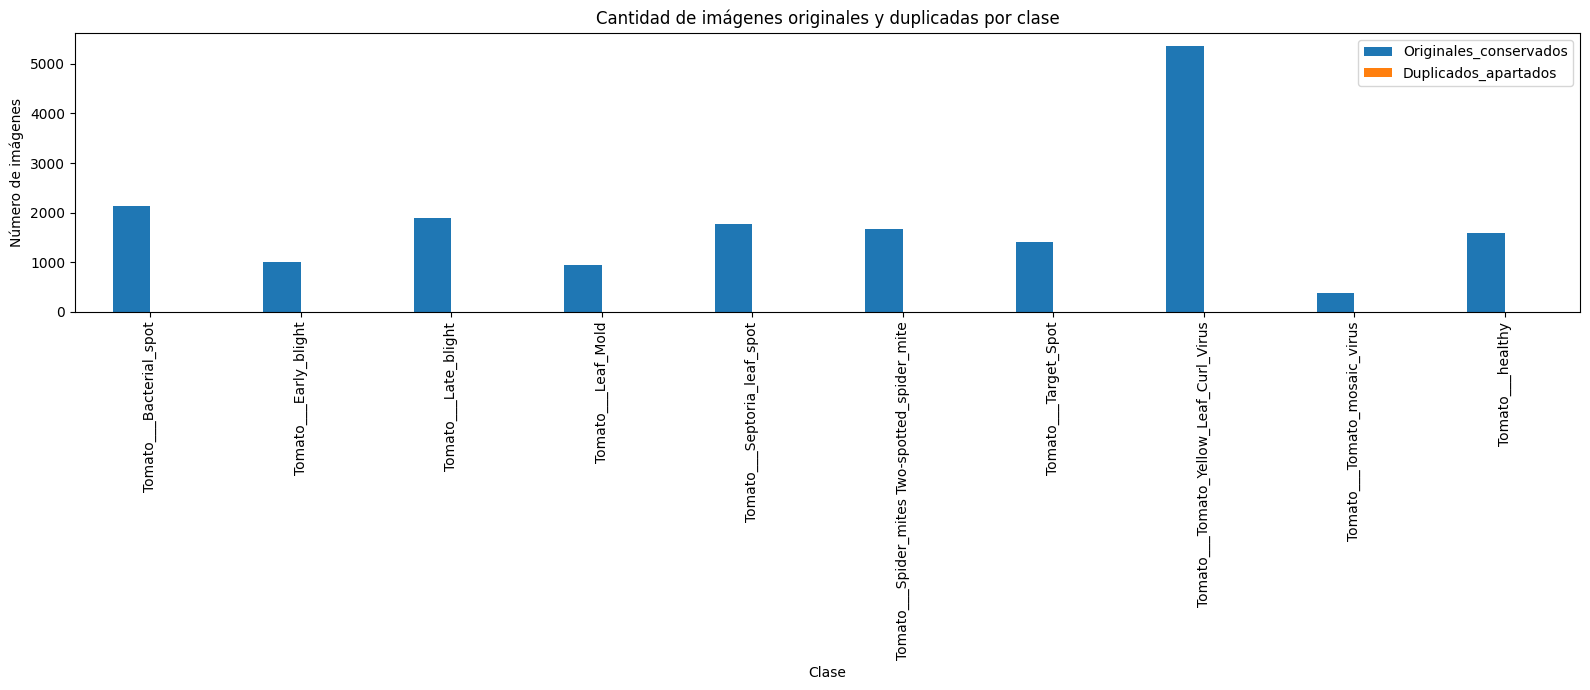

In [74]:
# ============================================================
# BLOQUE 11
# VISUALIZACIÓN ORIGINALES VS DUPLICADOS
# ============================================================

import matplotlib.pyplot as plt


df_grafico = (
    df_comparacion
    .set_index("Clase")
    [
        [
            "Originales_conservados",
            "Duplicados_apartados"
        ]
    ]
)


ax = df_grafico.plot(
    kind="bar",
    figsize=(16, 7)
)


ax.set_title(
    "Cantidad de imágenes originales y duplicadas por clase"
)

ax.set_xlabel(
    "Clase"
)

ax.set_ylabel(
    "Número de imágenes"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

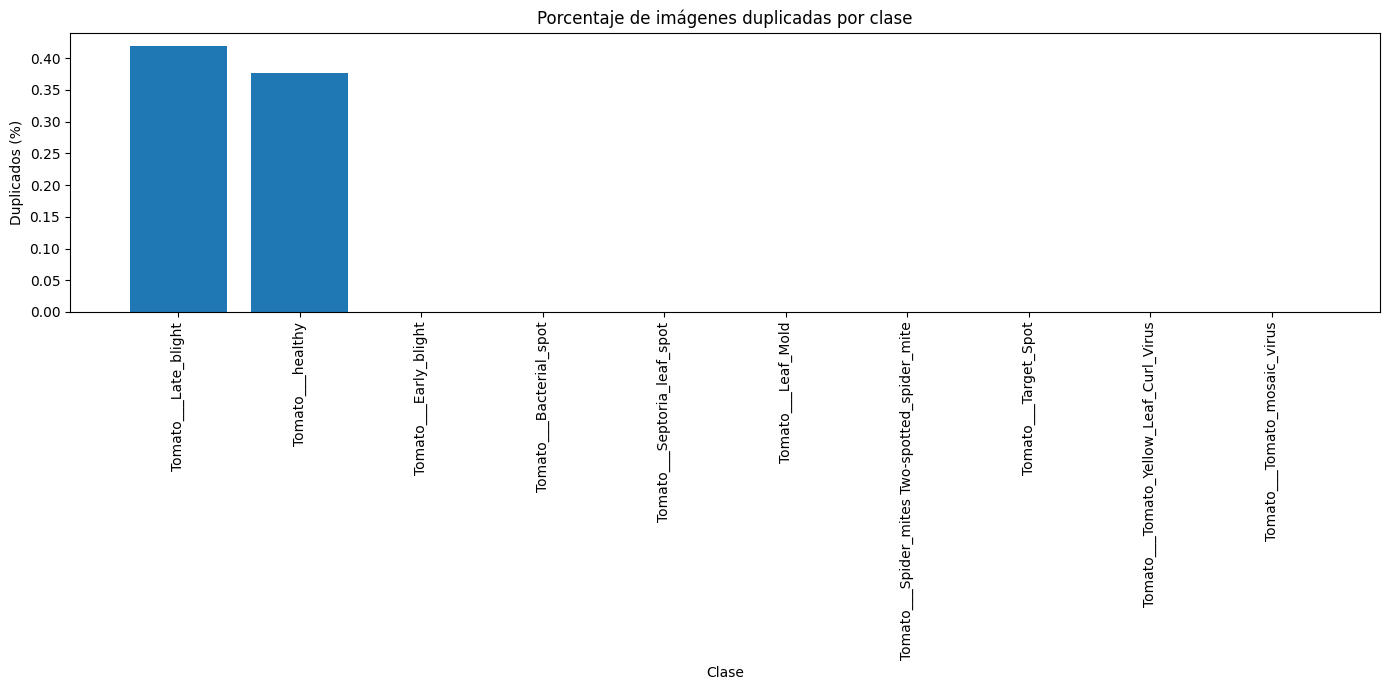

In [75]:
# ============================================================
# BLOQUE 12
# PORCENTAJE DE DUPLICADOS POR CLASE
# ============================================================

df_porcentaje = (
    df_comparacion
    .sort_values(
        "Duplicados_%",
        ascending=False
    )
)


plt.figure(
    figsize=(14, 7)
)


plt.bar(
    df_porcentaje["Clase"],
    df_porcentaje["Duplicados_%"]
)


plt.title(
    "Porcentaje de imágenes duplicadas por clase"
)

plt.xlabel(
    "Clase"
)

plt.ylabel(
    "Duplicados (%)"
)

plt.xticks(
    rotation=90
)

plt.tight_layout()

plt.show()

In [76]:
# ============================================================
# BLOQUE 13
# EXPORTAR TABLA COMPARATIVA
# ============================================================

RUTA_REPORTE = (
    "/content/plantvillage/"
    "comparacion_originales_vs_duplicados.csv"
)


df_comparacion.to_csv(
    RUTA_REPORTE,
    index=False
)


print(
    "✅ Reporte guardado correctamente:"
)

print(RUTA_REPORTE)

✅ Reporte guardado correctamente:
/content/plantvillage/comparacion_originales_vs_duplicados.csv


# Fase 1 - Definición formal del problema
Esta fase establece qué problema se resolverá, cuál es la variable objetivo y por qué la solución tiene
utilidad práctica

## 1.1 Contexto
Proyecto Final - Deep Learning | PlantVillage | MLP vs CNN
- Importancia de identificar enfermedades vegetales.
- Utilidad de automatizar la clasificación a partir de imágenes.
- Características visuales que pueden diferenciar estados sanitarios.
- Uso de imágenes de hojas como modalidad principal de datos.

### **1.1 Contexto**

La identificación de enfermedades en plantas constituye un problema relevante dentro del ámbito agrícola, debido a que la aparición de patologías puede afectar el desarrollo de los cultivos, disminuir su rendimiento y generar pérdidas productivas. En particular, muchas enfermedades vegetales producen modificaciones visibles en las hojas, por lo que el análisis de imágenes puede utilizarse como una fuente de información para reconocer diferentes estados sanitarios.

En este proyecto se trabaja con imágenes de hojas de **tomate** provenientes del dataset **PlantVillage**, considerando distintas enfermedades foliares y una categoría correspondiente a hojas saludables. El objetivo es utilizar estas imágenes para construir modelos capaces de distinguir automáticamente entre diferentes clases sanitarias.

La automatización de este proceso mediante técnicas de **Deep Learning y Visión por Computador** permite analizar directamente las imágenes sin necesidad de definir manualmente todas las características visuales relevantes. En lugar de proporcionar al modelo variables previamente diseñadas, las redes neuronales pueden aprender representaciones a partir de los píxeles disponibles en las imágenes.

Las enfermedades foliares pueden manifestarse mediante diferentes características visuales, entre ellas:

* cambios de coloración;
* presencia de manchas o lesiones;
* variaciones en la textura de la hoja;
* alteraciones en los bordes;
* diferencias en la distribución espacial de las zonas afectadas;
* patrones visuales asociados a determinadas enfermedades.

Estas características no se encuentran representadas como variables independientes dentro del dataset, sino que están distribuidas espacialmente en las imágenes. Por esta razón, el problema requiere que el modelo aprenda automáticamente patrones visuales capaces de diferenciar una clase de otra.

De forma conceptual, el proceso de aprendizaje puede representarse como:

$[
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones foliares}
\rightarrow
\text{clase sanitaria}
]$

La modalidad principal de datos utilizada en este proyecto corresponde, por tanto, a **imágenes digitales de hojas de tomate**. Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados exactos realizadas en el notebook, el conjunto de datos de trabajo contiene **18.146 imágenes únicas distribuidas en 10 clases**, correspondientes a distintas enfermedades y al estado saludable de la planta.

Este contexto proporciona una base adecuada para comparar dos estrategias de aprendizaje profundo: una **MLP**, que utilizará una representación vectorizada de las imágenes, y una **CNN**, que conservará y explotará explícitamente su estructura espacial. La comparación permitirá estudiar si el aprendizaje de patrones espaciales propios de una red convolucional proporciona una ventaja observable en la clasificación de enfermedades foliares del tomate.


## 1.2 Tipo de problema

Clasificación multiclase

- Cada imagen X_i deberá asociarse con una categoría y_i perteneciente al conjunto de K clases  disponibles.

### **1.2 Tipo de problema**

El problema abordado en este proyecto corresponde a una tarea de **clasificación supervisada multiclase**.

Se considera **aprendizaje supervisado** porque cada imagen del conjunto de datos posee previamente una etiqueta que identifica su correspondiente **estado sanitario o categoría foliar**. Durante el entrenamiento, el modelo utilizará pares de datos de la forma:

$[
(X_i, y_i)
]$

donde:

* $(X_i)$ representa la imagen de una hoja de tomate.
* $(y_i)$ representa la clase asociada a dicha imagen.

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de duplicados desarrolladas en el notebook, el conjunto de datos definitivo contiene:

$[
N = 18,146
]$

imágenes únicas distribuidas en:

$[
K = 10
]$

clases.

La hoja de ruta establece precisamente que cada imagen (X_i) debe asociarse con una categoría (y_i) perteneciente al conjunto de (K) clases disponibles.

Por lo tanto, para cada imagen se debe determinar una única etiqueta perteneciente al conjunto:

$[
\mathcal{C}
=
{
c_1,c_2,\ldots,c_{10}
}
]$

En los datos procesados en el notebook, las diez clases corresponden a:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De esta forma, el objetivo puede expresarse matemáticamente mediante una función de clasificación:

$[
f_{\theta}: X_i \longrightarrow y_i
]$

donde $(f_{\theta})$ representa el modelo parametrizado por (\theta), encargado de aprender patrones visuales presentes en las imágenes para asignarlas a una de las diez categorías posibles.

La tarea es **multiclase** porque existen más de dos categorías posibles y cada imagen debe ser asignada a una única clase. Esto la diferencia de una clasificación binaria, donde solamente existen dos posibles resultados, y de un problema de regresión, donde la salida corresponde a un valor numérico continuo.

Conceptualmente, el proceso puede representarse como:

$[
\text{Imagen de hoja de tomate}
\rightarrow
\text{Modelo de clasificación}
\rightarrow
\text{una de 10 clases sanitarias}
]$

En las etapas posteriores del proyecto, tanto la **MLP** como la **CNN** resolverán exactamente la misma tarea de clasificación y utilizarán las mismas categorías de salida. Esto permitirá realizar posteriormente una comparación experimental bajo un criterio común, tal como exige el enunciado para la combinación **MLP + CNN** aplicada a imágenes.

En síntesis, el problema queda formalmente definido como:

$[
\boxed{\text{Clasificación supervisada multiclase de imágenes de hojas de tomate en 10 categorías}}
]$


## 1.3 Variable objetivo
La variable objetivo corresponde a la clase de enfermedad o estado sanitario de la hoja, inferida a partir  del directorio de clase al que pertenece cada imagen.

### **1.3 Variable objetivo**

La **variable objetivo** del proyecto corresponde a la **clase de enfermedad o estado sanitario de cada hoja de tomate**. En el dataset PlantVillage, esta información se encuentra determinada por el **directorio o carpeta de clase** al que pertenece cada imagen, tal como establece la hoja de ruta del proyecto.

Por lo tanto, para cada imagen (X_i) existe una etiqueta asociada (y_i), donde:

$[
X_i = \text{imagen de una hoja de tomate}
]$

y:

$[
y_i = \text{clase sanitaria asociada a la imagen}
]$

Después de las etapas de filtrado, consolidación, verificación de integridad y eliminación de archivos duplicados exactos realizadas en el notebook, el conjunto de datos utilizado contiene:

$[
N = 18,146
]$

imágenes únicas, distribuidas en:

$[
K = 10
]$

clases diferentes.

Las categorías que conforman la variable objetivo son:

1. `Tomato___Bacterial_spot`
2. `Tomato___Early_blight`
3. `Tomato___Late_blight`
4. `Tomato___Leaf_Mold`
5. `Tomato___Septoria_leaf_spot`
6. `Tomato___Spider_mites Two-spotted_spider_mite`
7. `Tomato___Target_Spot`
8. `Tomato___Tomato_Yellow_Leaf_Curl_Virus`
9. `Tomato___Tomato_mosaic_virus`
10. `Tomato___healthy`

De estas diez categorías, **nueve representan diferentes enfermedades o afecciones foliares**, mientras que una corresponde al estado **saludable (`healthy`)** de la hoja.

Matemáticamente, la variable objetivo puede representarse como:

$[
y_i \in \mathcal{C}
]$

donde:

$[
\mathcal{C}
=
{c_1,c_2,\ldots,c_{10}}
]$

representa el conjunto de las diez clases posibles.

El objetivo de los modelos será, por tanto, aprender una función:

$[
f_{\theta}(X_i)=\hat{y}_i
]$

donde:

* $(X_i)$ corresponde a la imagen de entrada.
* $(f_{\theta})$ representa el modelo de Deep Learning parametrizado por $(\theta)$.
* $(\hat{y}_i)$ corresponde a la clase predicha por el modelo.
* $(y_i)$ corresponde a la clase real utilizada como referencia durante el entrenamiento y evaluación.

Conceptualmente:

$[
\text{Imagen de hoja}
\rightarrow
\text{MLP o CNN}
\rightarrow
\text{Probabilidades para 10 clases}
\rightarrow
\text{Clase predicha}
]$

En la etapa de modelamiento, la capa de salida de ambas redes deberá contener **10 neuronas**, una por cada clase:

$[
\mathbf{p}
=
[p_1,p_2,\ldots,p_{10}]
]$

donde cada (p_k) representa la probabilidad estimada de que la imagen pertenezca a la clase (k). La predicción final corresponderá a la categoría con mayor probabilidad:

$[
\hat{y}
=
\arg\max_k p_k
]$

Esta definición permite que tanto la **MLP** como la **CNN** resuelvan exactamente la misma tarea predictiva y utilicen la misma variable objetivo, condición necesaria para realizar posteriormente una comparación experimental justa entre ambas arquitecturas.

En síntesis, la variable objetivo del proyecto queda definida como:

$[
\boxed{
\text{Clase de enfermedad o estado saludable de la hoja de tomate}
}
]$

con **10 categorías posibles** obtenidas directamente de la estructura de clases del dataset PlantVillage procesado en el notebook.


## 1.4 Pregunta central
- ¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de  generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?

### **1.4 Pregunta central**

La pregunta central del proyecto busca determinar si la **estructura arquitectónica de una Red Neuronal Convolucional (CNN)** proporciona una ventaja real frente a una **Red Neuronal Multicapa (MLP)** cuando ambas son utilizadas para resolver exactamente el mismo problema de clasificación de enfermedades foliares del tomate.

La hoja de ruta establece como pregunta experimental:

> **¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?**

Esta pregunta es coherente con el propósito del proyecto, ya que la comparación **MLP vs CNN** debe representar dos hipótesis diferentes acerca de cómo utilizar la información contenida en una imagen. La hoja de ruta plantea explícitamente que la MLP trabaja sobre una imagen aplanada, mientras que la CNN conserva y explota su estructura espacial.

Considerando los datos obtenidos y procesados en el notebook, el experimento se desarrollará sobre un conjunto definitivo de:

$[
N = 18,146
]$

imágenes únicas de hojas de tomate, distribuidas en:

$[
K = 10
]$

clases correspondientes a diferentes enfermedades foliares y al estado saludable.

Las imágenes presentan una resolución original de:

$[
256 \times 256
]$

píxeles, utilizan tres canales de color **RGB** y han sido previamente verificadas en términos de integridad y duplicados. De esta forma, ambas arquitecturas podrán ser evaluadas sobre la misma fuente de información visual.

---

#### **Hipótesis representada por la MLP**

La MLP utilizará una representación vectorizada de cada imagen. Conceptualmente:

$[
X_i \in \mathbb{R}^{H\times W\times C}
]$

será transformada mediante una operación de aplanamiento:

$[
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
]$

Por ejemplo, manteniendo la resolución original:

$[
256\times256\times3
=
196,608
]$

valores de entrada por imagen.

El principal efecto de esta transformación es que la estructura bidimensional de la imagen deja de encontrarse representada explícitamente. Para la MLP, los píxeles pasan a formar parte de un único vector y las relaciones de vecindad espacial deben ser aprendidas indirectamente a partir de conexiones densas.

Conceptualmente:

$[
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
]$

---

#### **Hipótesis representada por la CNN**

La CNN, en cambio, recibe la imagen preservando sus dimensiones espaciales:

$[
X_i
\in
\mathbb{R}^{H\times W\times C}
]$

y utiliza filtros convolucionales para aprender patrones locales.

Conceptualmente, el aprendizaje puede representarse mediante:

$[
\text{píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
]$

La hoja de ruta identifica precisamente como ventajas de la CNN la **detección de patrones locales, la compartición de pesos y el aprendizaje jerárquico de características**, mientras que señala que el aplanamiento realizado por una MLP elimina la representación espacial explícita.

---

#### **Comparación experimental**

La pregunta central no pretende simplemente identificar cuál modelo obtiene una mayor exactitud, sino determinar si la incorporación explícita de estructura espacial produce una **mejora observable y generalizable**.

Por ello, el experimento deberá mantener constantes, en la medida de lo posible, las condiciones comunes de comparación:

$[
\text{mismas imágenes}
]$

$[
\text{mismos subconjuntos de Train, Validation y Test}
]$

$[
\text{misma variable objetivo}
]$

$[
\text{mismas 10 clases}
]$

$[
\text{métricas de evaluación comunes}
]$

El propio enunciado señala que una comparación MLP + CNN sobre imágenes debe contrastar una **imagen aplanada** frente a una arquitectura que **explota la estructura espacial**, y exige que ambas redes sean comparadas de forma significativa y bajo criterios adecuados.

---

#### **Capacidad de generalización**

En este proyecto, la generalización se entenderá como la capacidad del modelo para clasificar correctamente **imágenes que no fueron utilizadas para ajustar sus parámetros**.

Por tanto, el rendimiento sobre entrenamiento no será suficiente para responder la pregunta central. Será necesario analizar posteriormente:

* desempeño sobre validación;
* desempeño final sobre test;
* diferencia entre entrenamiento y validación;
* presencia de sobreajuste;
* comportamiento por clase;
* matriz de confusión;
* errores de clasificación.

Las métricas recomendadas por el enunciado para tareas de clasificación incluyen **Accuracy, Balanced Accuracy, Precision, Recall y F1**, además de matrices de confusión y otras métricas cuando corresponda.

La comparación podrá expresarse posteriormente mediante:

$[
\Delta M =
M_{\mathrm{CNN}} - M_{\mathrm{MLP}}
]$

donde $(M)$ representa una métrica determinada. Por ejemplo:

$[
\Delta F1_{\text{macro}}
=
F1_{\text{CNN}}
F1_{\text{MLP}}
]$

Una diferencia positiva favorecería experimentalmente a la CNN para dicha métrica, pero la conclusión definitiva deberá considerar conjuntamente rendimiento, sobreajuste, errores y costo computacional.

---

#### **Hipótesis experimental**

A partir de las propiedades de ambas arquitecturas se plantea como hipótesis de trabajo:

$[
\boxed{
H_1:
\text{La CNN presentará una mejor capacidad de generalización que la MLP}
}
]$

debido a que puede aprovechar explícitamente las relaciones espaciales existentes entre los píxeles y aprender patrones visuales locales y jerárquicos asociados a las enfermedades foliares.

Como hipótesis alternativa de ausencia de ventaja arquitectónica puede plantearse:

$[
\boxed{
H_0:
\text{La CNN no presentará una mejora relevante de generalización frente a la MLP}
}
]$

Estas hipótesis **no se consideran demostradas en esta fase**. La Fase 1 solamente establece la pregunta experimental. La respuesta deberá obtenerse posteriormente mediante entrenamiento, validación y evaluación final de ambas arquitecturas.

En consecuencia, la pregunta central queda operacionalizada como:

$[
\boxed{
\begin{aligned}
&\text{¿La preservación y explotación de la estructura espacial mediante una CNN}\
&\text{produce una mejora observable y generalizable en la clasificación}\
&\text{de las 10 clases de hojas de tomate respecto de una MLP}\
&\text{entrenada sobre una representación vectorizada de las mismas imágenes?}
\end{aligned}
}
]$

Esta formulación permitirá que las etapas posteriores del proyecto respondan la pregunta mediante **evidencia experimental**, en lugar de asumir anticipadamente que una arquitectura es superior a la otra.


# Fase 2 - Justificación del uso de Deep Learning

El proyecto exige demostrar que Deep Learning es una decisión metodológica fundamentada. La justificación debe construirse antes del entrenamiento y luego respaldarse con evidencia experimental.

## 2.1 ¿Existe suficiente cantidad y complejidad?

La evaluación debe considerar tanto el número total de imágenes como su distribución entre clases. Un  volumen elevado no es suficiente si algunas categorías presentan muy pocos ejemplos.

N_total = suma de N_i  para i = 1, ..., K  

- Cantidad total de imágenes válidas y únicas después de la depuración. Número final de clases.   
- Cantidad mínima, máxima y mediana de imágenes por clase.
- Porcentaje de participación de cada clase.
- Existencia de clases significativamente sobrerrepresentadas o subrepresentadas.



La complejidad también proviene de la alta dimensionalidad y de la estructura espacial de cada imagen:  color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que  deben aprenderse a partir de los píxeles.



Píxeles -> bordes -> texturas -> formas -> patrones de lesión -> clase

### **2.1 ¿Existe suficiente cantidad y complejidad?**

Uno de los requisitos centrales del proyecto consiste en justificar que el uso de **Deep Learning** responde a las características reales del problema y del conjunto de datos, y no solamente a una elección de modelamiento. El enunciado exige determinar si existe una cantidad y complejidad suficiente de datos para aprender patrones no triviales, mientras que la hoja de ruta establece que este análisis debe considerar tanto el volumen total como la distribución de observaciones entre las clases.

#### **Cantidad total de imágenes**

Después del filtrado de PlantVillage se conservaron exclusivamente las categorías correspondientes a hojas de tomate. Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$[
N_{\text{antes}} = 18,160
]$

imágenes.

La verificación de integridad realizada en el notebook determinó que las **18.160 imágenes eran válidas**, sin archivos problemáticos detectados, obteniéndose un porcentaje de integridad del:

$[
100%
]$

Posteriormente, mediante comparación de hashes **SHA-256**, se identificaron y apartaron **14 copias redundantes exactas**, equivalentes aproximadamente al:

$[
\frac{14}{18,160}\times100
\approx 0.08%
]$

del conjunto original.

Por tanto, el dataset definitivo utilizado para continuar el experimento contiene:

$[
\boxed{N_{\text{total}} = 18,146}
]$

imágenes válidas y únicas.

De acuerdo con la formulación propuesta en la hoja de ruta:

$[
N_{\text{total}}
=
\sum_{i=1}^{K}N_i
]$

donde $(N_i)$ corresponde al número de imágenes pertenecientes a la clase $(i)$ y:

$[
K=10
]$
representa el número final de clases.

En este caso se verifica:

$[
\boxed{
18,146=
\sum_{i=1}^{10}N_i
}
]$

---

#### **Distribución de imágenes entre clases**

Después de la depuración, las imágenes se encuentran distribuidas de la siguiente manera:

| Clase                                           |   Imágenes | Participación |
| ----------------------------------------------- | ---------: | ------------: |
| `Tomato___Bacterial_spot`                       |      2.127 |       11,72 % |
| `Tomato___Early_blight`                         |      1.000 |        5,51 % |
| `Tomato___Late_blight`                          |      1.901 |       10,48 % |
| `Tomato___Leaf_Mold`                            |        952 |        5,25 % |
| `Tomato___Septoria_leaf_spot`                   |      1.771 |        9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` |      1.676 |        9,24 % |
| `Tomato___Target_Spot`                          |      1.404 |        7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus`        |      5.357 |   **29,52 %** |
| `Tomato___Tomato_mosaic_virus`                  |        373 |    **2,06 %** |
| `Tomato___healthy`                              |      1.585 |        8,73 % |
| **Total**                                       | **18.146** |     **100 %** |

La cantidad mínima de imágenes por clase corresponde a:

$[
\boxed{N_{\min}=373}
]$

para:

`Tomato___Tomato_mosaic_virus`

mientras que la cantidad máxima corresponde a:

$[
\boxed{N_{\max}=5,357}
]$

para:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`.

Al ordenar las cantidades de imágenes:

$[
373,;952,;1000,;1404,;1585,;1676,;1771,;1901,;2127,;5357
]$

la mediana corresponde a:

$[
\operatorname{Mediana}(N_i)
=\frac{1585+1676}{2} \boxed{1630.5}
]$

imágenes por clase.

---

#### **Análisis del desbalance**

Aunque el dataset posee un volumen total considerable, su distribución no es uniforme.

La clase `Tomato___Tomato_Yellow_Leaf_Curl_Virus` representa aproximadamente:




$$
\boxed{29.52\%}
$$


del conjunto completo, mientras que `Tomato___Tomato_mosaic_virus` representa solamente:



$$
\boxed{2.06\%}
$$

Una forma de cuantificar esta diferencia es mediante la razón de desbalance:

$[
IR=
\frac{N_{\max}}{N_{\min}}
]$

por lo que:

$[
IR=
\frac{5357}{373}
\approx
\boxed{14.36}
]$

Esto significa que la clase mayoritaria contiene aproximadamente **14,4 veces más imágenes que la clase minoritaria**.

Por lo tanto, se identifica una **sobrerrepresentación importante** de `Tomato___Tomato_Yellow_Leaf_Curl_Virus` y una **subrepresentación relativa** de `Tomato___Tomato_mosaic_virus`.

Este resultado no impide utilizar Deep Learning, pero deberá ser considerado en las fases posteriores, especialmente durante:

* la división estratificada de `train`, `validation` y `test`;
* el entrenamiento de los modelos;
* la interpretación de las métricas;
* el análisis de errores por clase.

En consecuencia, posteriormente no será conveniente evaluar los modelos exclusivamente mediante `accuracy`, ya que una métrica global puede ocultar un rendimiento deficiente sobre las clases minoritarias. La hoja de ruta contempla precisamente métricas como **Balanced Accuracy, Precision, Recall y F1**, además de la matriz de confusión, para analizar el comportamiento de los modelos ante esta situación.

---

### **Complejidad de los datos**

La justificación de Deep Learning no depende únicamente de disponer de 18.146 ejemplos. También es necesario analizar la **complejidad de cada observación**.

Las imágenes procesadas en el notebook presentan características homogéneas:

$[
256\times256
]$

píxeles de resolución y tres canales de color:

$[
RGB
]$

Por tanto, cada imagen puede representarse inicialmente como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

lo que supone:

$[
256\times256\times3
=
\boxed{196,608}
]$

valores de intensidad por imagen.

Esta alta dimensionalidad diferencia claramente el problema de un conjunto tabular compuesto por unas pocas variables predictoras.

Sin embargo, la complejidad más importante no procede solamente del número de píxeles. La información necesaria para identificar una enfermedad se encuentra **distribuida espacialmente dentro de la imagen**.

Variables como:

* coloración;
* textura;
* manchas;
* lesiones;
* bordes;
* formas;
* tamaño y distribución de las zonas afectadas;

no se encuentran disponibles como columnas explícitas del dataset.

El modelo recibe fundamentalmente los valores de los píxeles y debe aprender qué combinaciones de ellos resultan útiles para distinguir los diferentes estados sanitarios.

Conceptualmente, el aprendizaje esperado puede representarse mediante:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
}
]$

Esta característica es precisamente uno de los argumentos centrales establecidos en la hoja de ruta para justificar Deep Learning: color, textura, manchas, bordes, lesiones y formas **no aparecen como variables explícitas**, sino que deben aprenderse a partir de la representación visual.

---

### **Cantidad y complejidad consideradas conjuntamente**

La evaluación del dataset muestra entonces dos características simultáneas.

Por una parte, existe un volumen de:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas entre:

$[
\boxed{10\text{ clases}}
]$

lo que proporciona una base de datos suficientemente amplia para plantear un experimento acotado de Deep Learning en Google Colab.

Por otra parte, cada observación posee una estructura:

$[
256\times256\times3
]$

y contiene relaciones espaciales que no pueden reducirse directamente a unas pocas variables previamente definidas.

Por tanto, la complejidad del problema puede resumirse como:

$[
\boxed{
\text{volumen de datos}
+
\text{alta dimensionalidad}
+
\text{estructura espacial}
+
\text{patrones visuales no explícitos}
+
\text{clasificación en 10 categorías}
}
]$

El propio enunciado considera apropiada la combinación **MLP + CNN para imágenes**, específicamente para contrastar una representación aplanada con una arquitectura que explota la estructura espacial.

---

### **Conclusión de la sección 2.1**

A partir de los resultados obtenidos en el notebook, se considera que **sí existe una cantidad y complejidad suficientes para justificar el desarrollo del experimento mediante Deep Learning**.

La afirmación se fundamenta en que:

$[
\boxed{
\begin{aligned}
N_{\text{total}} &= 18,146\
K &= 10\
N_{\min} &= 373\
N_{\max} &= 5,357\
\operatorname{Mediana}(N_i) &= 1,630.5\
IR &\approx 14.36
\end{aligned}
}
]$

Además, cada imagen contiene **196.608 valores de entrada en su resolución original**, organizados espacialmente en tres canales RGB, y las características relevantes para la clasificación deben ser aprendidas a partir de los píxeles.

No obstante, el análisis también identifica una limitación que deberá mantenerse presente durante el proyecto: **la distribución entre clases es desbalanceada**. Esta situación no invalida el dataset, pero exige una partición estratificada y métricas que permitan evaluar adecuadamente el rendimiento sobre las categorías minoritarias.

En consecuencia:

$[
\boxed{
\text{Sí existe suficiente cantidad y complejidad para estudiar Deep Learning,}
}
]$

pero la verdadera ventaja de las arquitecturas profundas —y particularmente de la CNN— deberá ser **demostrada posteriormente mediante evidencia experimental**, comparando su capacidad de generalización con la MLP y no asumiéndola de antemano.


## 2.2 ¿Por qué las imágenes justifican Deep Learning?
Una imagen conserva relaciones espaciales entre píxeles. Las CNN están diseñadas para explotar esa  estructura mediante filtros convolucionales y aprendizaje jerárquico de representaciones.

### **2.2 ¿Por qué las imágenes justifican Deep Learning?**

La utilización de **Deep Learning** se encuentra especialmente justificada cuando los datos de entrada poseen una estructura compleja cuya información relevante no está disponible como un conjunto reducido de variables previamente definidas. Este es precisamente el caso del proyecto, ya que la modalidad principal de los datos corresponde a **imágenes digitales de hojas de tomate**.

El enunciado del proyecto establece que una de las preguntas centrales para justificar Deep Learning es determinar si la modalidad de los datos favorece el **aprendizaje automático de representaciones**. Asimismo, propone explícitamente la combinación **MLP + CNN** para problemas basados en imágenes, comparando una representación aplanada con una arquitectura que explota su estructura espacial.

Después de las etapas de filtrado, verificación de integridad y eliminación de duplicados realizadas en el notebook, el conjunto de datos de trabajo contiene:

$[
\boxed{18,146\text{ imágenes únicas}}
]$

distribuidas en:

$[
\boxed{10\text{ clases}}
]$

correspondientes a diferentes enfermedades foliares del tomate y a la categoría de hojas saludables.

Las imágenes presentan una resolución original de:

$[
256\times256
]$

píxeles y tres canales de color **RGB**, por lo que cada observación puede representarse como un tensor:

$[
X_i\in\mathbb{R}^{256\times256\times3}
]$

Esto significa que una sola imagen contiene:

$[
256\times256\times3
=\boxed{196,608}
]$

valores de intensidad.

Sin embargo, la principal razón para utilizar Deep Learning **no es solamente la elevada cantidad de valores por imagen**, sino la forma en que estos valores se encuentran organizados.

---

#### **La información de una imagen posee estructura espacial**

En una imagen, la posición de cada píxel importa. Un píxel no constituye una observación independiente: su significado visual depende de los píxeles que se encuentran a su alrededor.

Formalmente, una imagen RGB puede representarse como:

$[
X(i,j,c)
]$

donde:

* $(i)$ representa la posición vertical;
* $(j)$ representa la posición horizontal;
* $(c)$ representa el canal de color.

Por lo tanto, valores próximos como:

$[
X(i,j,c)
]$

y:

$[
X(i+1,j,c)
]$

mantienen una relación de proximidad espacial.

Esta relación es fundamental para reconocer estructuras visuales como:

* bordes;
* manchas;
* cambios de coloración;
* texturas;
* lesiones;
* contornos;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia:

$[
\boxed{
\text{la posición relativa de los píxeles contiene información}
}
]$

y esa información debe ser considerada por el modelo.

---

#### **Las características relevantes no están definidas explícitamente**

A diferencia de un problema tabular, el dataset no proporciona columnas como:

```text
intensidad_de_manchas
color_de_lesion
textura_foliar
forma_de_la_lesion
porcentaje_de_superficie_afectada
```

Estas variables **no existen directamente en los datos**.

El modelo recibe esencialmente una matriz de píxeles y debe descubrir qué características resultan útiles para diferenciar las diez clases.

Por ejemplo, una determinada enfermedad puede caracterizarse por una combinación de:

$[
\text{color}
+
\text{textura}
+
\text{forma}
+
\text{localización}
]$

y no por una única característica aislada.

Por tanto, el problema requiere un mecanismo de **aprendizaje de representaciones**, es decir, que el modelo construya internamente características cada vez más informativas a partir de los datos originales.

Este principio coincide directamente con la hoja de ruta, que establece que características como color, textura, manchas, bordes, lesiones y formas no aparecen como variables explícitas, sino que deben ser aprendidas a partir de los píxeles.

---

### **Aprendizaje jerárquico de representaciones**

Una de las principales capacidades del Deep Learning es aprender características de manera jerárquica.

Conceptualmente, el proceso puede representarse como:

$[
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
]$

Las primeras capas de una red pueden aprender patrones visuales relativamente simples, mientras que capas posteriores combinan estas representaciones para detectar estructuras progresivamente más complejas.

Por ejemplo:

#### Nivel 1 — Información básica

$[
\text{píxeles}
\rightarrow
\text{cambios de intensidad y color}
]$

#### Nivel 2 — Patrones locales

$[
\text{cambios locales}
\rightarrow
\text{bordes y pequeñas texturas}
]$

#### Nivel 3 — Estructuras visuales

$[
\text{bordes + texturas}
\rightarrow
\text{manchas o lesiones}
]$

#### Nivel 4 — Patrones de mayor nivel

$[
\text{lesiones + formas + distribución}
\rightarrow
\text{patrón foliar}
]$

#### Nivel 5 — Clasificación

$[
\text{patrón foliar}
\rightarrow
\text{enfermedad o estado saludable}
]$

Esta capacidad de aprender automáticamente una jerarquía de características constituye una de las razones principales por las que Deep Learning resulta apropiado para el problema.

La hoja de ruta establece precisamente que las CNN están diseñadas para aprovechar las relaciones espaciales mediante **filtros convolucionales y aprendizaje jerárquico de representaciones**.

---

### **¿Cómo aprovecha una CNN la estructura espacial?**

Una **Convolutional Neural Network (CNN)** utiliza filtros o kernels que recorren regiones locales de la imagen.

De forma simplificada, una operación convolucional puede representarse como:

$[
Y(i,j)
=
\sum_{m}\sum_{n}
X(i+m,j+n),K(m,n)
]$

donde:

* $(X)$ representa la imagen de entrada;
* $(K)$ corresponde al filtro convolucional;
* $(Y)$ es el mapa de características obtenido.

El filtro analiza pequeños vecindarios de píxeles en lugar de tratar todos los valores de la imagen como elementos independientes.

Por ejemplo, un kernel de:

$[
3\times3
]$

analiza grupos locales de nueve posiciones espaciales a la vez.

Conceptualmente:

$[
\begin{bmatrix}
x_{1} & x_{2} & x_{3}\
x_{4} & x_{5} & x_{6}\
x_{7} & x_{8} & x_{9}
\end{bmatrix}
]$

Esto permite detectar estructuras locales que posteriormente pueden combinarse para formar patrones de mayor complejidad.

---

### **Relación con las imágenes del proyecto**

Las enfermedades incluidas en el dataset se manifiestan mediante información visual presente directamente en las hojas.

Por ello, el modelo deberá aprender relaciones como:

$[
\text{coloración local}
+
\text{textura}
+
\text{forma de manchas}
+
\text{distribución espacial}
\rightarrow
\text{clase sanitaria}
]$

El hecho de que todas las imágenes procesadas sean homogéneas en términos de resolución, canales de color y formato facilita la construcción posterior de un pipeline común de procesamiento, pero **no transforma el problema en una tarea sencilla**.

Aunque todas posean dimensiones:

$[
256\times256\times3
]$

el contenido espacial varía entre imágenes y entre clases. La dificultad consiste precisamente en aprender qué configuraciones visuales son discriminativas para cada enfermedad.

---

### **Deep Learning frente a extracción manual de características**

Una estrategia convencional podría intentar construir manualmente variables como:

$[
\text{color promedio},
\quad
\text{contraste},
\quad
\text{histograma RGB},
\quad
\text{textura}
]$

y utilizar posteriormente estas características en un clasificador tradicional.

El problema es que este enfoque requiere decidir previamente:

> **¿Qué características visuales son realmente importantes para distinguir las enfermedades?**

Deep Learning modifica este procedimiento:

$[
\text{Imagen}
\rightarrow
\text{aprendizaje automático de características}
\rightarrow
\text{clasificación}
]$

En lugar de:

$[
\text{Imagen}
\rightarrow
\text{características diseñadas manualmente}
\rightarrow
\text{clasificador}
]$

Esta capacidad resulta especialmente pertinente para PlantVillage, ya que las diferencias entre categorías se encuentran codificadas en patrones visuales que pueden involucrar múltiples niveles de información.

---

### **Justificación específica para el experimento MLP vs CNN**

La modalidad de los datos permite además construir una comparación metodológicamente significativa entre las dos arquitecturas seleccionadas.

Ambas redes recibirán información procedente de las mismas imágenes, pero la representación utilizada será diferente:

$[
\text{Imagen}
\rightarrow
\begin{cases}
\text{MLP: representación vectorizada}\
\text{CNN: representación espacial}
\end{cases}
]$

La CNN está diseñada específicamente para explotar:

$[
\text{localidad espacial}
+
\text{filtros convolucionales}
+
\text{aprendizaje jerárquico}
]$

mientras que el comportamiento de la MLP permitirá establecer una referencia experimental respecto de una representación que no explota explícitamente esa geometría.

Precisamente, el enunciado considera razonable para imágenes la comparación entre una **MLP con la imagen aplanada y una CNN que explota su estructura espacial**.

---

### **Conclusión de la sección 2.2**

La modalidad de los datos proporciona una justificación técnica clara para utilizar Deep Learning.

El dataset no está compuesto por unas pocas variables independientes, sino por **18.146 imágenes**, cada una con una estructura original de:

$[
256\times256\times3
]$

y, por tanto:

$[
196,608
]$

valores organizados espacialmente.

La información necesaria para diferenciar las diez categorías se encuentra distribuida entre los píxeles y se manifiesta mediante combinaciones de color, bordes, texturas, manchas, lesiones y formas que no están disponibles como variables explícitas.

Por ello:

$[
\boxed{
\text{Imagen}
\rightarrow
\text{representaciones visuales aprendidas}
\rightarrow
\text{clasificación}
}
]$

constituye una formulación natural del problema.

En consecuencia:

$[
\boxed{
\begin{aligned}
&\text{las imágenes justifican el uso de Deep Learning porque}\
&\text{contienen relaciones espaciales y patrones visuales complejos}\
&\text{que deben ser aprendidos automáticamente a partir de los píxeles.}
\end{aligned}
}
]$

La CNN constituye una arquitectura especialmente adecuada para estudiar esta hipótesis debido a su capacidad para explotar la **localidad espacial y el aprendizaje jerárquico de representaciones**. No obstante, que esta ventaja teórica produzca efectivamente una mayor capacidad de generalización sobre PlantVillage deberá demostrarse posteriormente mediante la comparación experimental con la MLP.


## 2.3 Limitación de una MLP
La MLP requiere aplanar la imagen. Al convertir una matriz H x W x C en un vector, la organización espacial deja de estar representada explícitamente.

### **2.3 Limitación de una MLP**

Una **Red Neuronal Multicapa (MLP, Multilayer Perceptron)** puede utilizarse para resolver problemas de clasificación de imágenes. Sin embargo, presenta una limitación estructural importante: antes de introducir una imagen en capas densas, normalmente es necesario transformar su representación tridimensional en un **vector unidimensional** mediante una operación de aplanamiento (`Flatten`).

Esta transformación conserva los valores numéricos de los píxeles, pero hace que la estructura espacial original de la imagen deje de estar representada explícitamente en la arquitectura de la red.

---

### **Representación original de las imágenes**

De acuerdo con los resultados obtenidos durante la preparación y auditoría del dataset, las imágenes utilizadas en el proyecto poseen una resolución original de:

$$
256 \times 256
$$

píxeles y tres canales de color:

$$
RGB
$$

Por lo tanto, cada imagen puede representarse matemáticamente como un tensor:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

donde:

* $X_i$ representa la imagen $i$.
* $256 \times 256$ corresponde a sus dimensiones espaciales.
* $3$ corresponde a los canales de color rojo, verde y azul.

La cantidad total de valores presentes en una imagen es:

$$
256 \times 256 \times 3 = 196,608
$$

Por tanto, cada imagen original contiene:

$$
\boxed{196,608 \text{ valores}}
$$

Estos valores no se encuentran organizados arbitrariamente. Cada píxel posee una posición específica dentro de la imagen y mantiene relaciones espaciales con los píxeles cercanos.

---

### **Aplanamiento de la imagen**

Para utilizar directamente una imagen como entrada de una MLP, se aplica normalmente una operación de aplanamiento:

$$
X_i \in \mathbb{R}^{H \times W \times C}
$$

que transforma la imagen en:

$$
\operatorname{Flatten}(X_i)
\in
\mathbb{R}^{HWC}
$$

En el caso particular de las imágenes originales del proyecto:

$$
\mathbb{R}^{256 \times 256 \times 3}
\longrightarrow
\mathbb{R}^{196,608}
$$

Conceptualmente, el proceso puede representarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{MLP}
\rightarrow
\text{Clase}
$$

La estructura típica de la MLP podría expresarse como:

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Dropout}
\rightarrow
\text{Dense + ReLU}
\rightarrow
\text{Softmax}
$$

---

### **Pérdida de representación espacial explícita**

La principal limitación del aplanamiento no consiste en eliminar los valores de los píxeles. Todos ellos permanecen en el vector resultante.

La dificultad es que las relaciones espaciales entre los píxeles dejan de estar representadas explícitamente.

Antes del aplanamiento, un píxel puede expresarse como:

$$
X(i,j,c)
$$

donde:

* $i$ representa la posición vertical.
* $j$ representa la posición horizontal.
* $c$ representa el canal de color.

Después del aplanamiento, la imagen pasa a representarse como:

$$
\mathbf{x}*i =
[x_1,x_2,x_3,\ldots,x*{196608}]
$$

La MLP recibe entonces un vector de valores y sus capas densas no incorporan de manera explícita información acerca de:

* qué píxeles se encuentran próximos;
* qué píxeles pertenecen a una misma región;
* dónde aparecen las manchas;
* cómo se distribuyen las lesiones;
* cómo se organizan las texturas;
* qué relación espacial existe entre distintas partes de la hoja.

Por ejemplo, en una pequeña región de una imagen:

$$
\begin{bmatrix}
x_{1,1} & x_{1,2} & x_{1,3} \
x_{2,1} & x_{2,2} & x_{2,3} \
x_{3,1} & x_{3,2} & x_{3,3}
\end{bmatrix}
$$

el píxel $x_{2,2}$ posee una relación espacial directa con los píxeles que lo rodean.

Al aplanar esa matriz se obtiene una representación similar a:

$$
[x_{1,1},x_{1,2},x_{1,3},x_{2,1},x_{2,2},\ldots]
$$

En esta nueva representación, la geometría bidimensional original ya no forma parte explícita de la arquitectura del modelo.

---

### **Implicancia para la clasificación de enfermedades foliares**

Esta limitación resulta especialmente importante en este proyecto, porque las enfermedades de las hojas de tomate pueden manifestarse mediante patrones como:

* manchas;
* lesiones;
* cambios de coloración;
* bordes irregulares;
* texturas;
* formas;
* distribución espacial de zonas afectadas.

En consecuencia, no solo interesa conocer el valor de determinados píxeles, sino también:

$$
\boxed{
\text{dónde aparecen y cómo se organizan espacialmente}
}
$$

Una determinada lesión podría caracterizarse mediante una combinación de:

$$
\text{Color}
+
\text{Forma}
+
\text{Textura}
+
\text{Distribución espacial}
$$

Al utilizar una MLP, estas relaciones deben ser aprendidas indirectamente mediante conexiones densas, ya que la arquitectura no incorpora de manera natural el concepto de vecindad espacial.

---

### **Elevado número de parámetros**

Una segunda limitación de la MLP aplicada a imágenes es el rápido crecimiento del número de parámetros.

En una capa densa, cada neurona se conecta con todas las entradas.

Si se mantuviera la resolución original de las imágenes:

$$
256 \times 256 \times 3
$$

la entrada contendría:

$$
196,608
$$

valores.

Si la primera capa densa tuviera $256$ neuronas, el número de pesos sería:

$$
196,608 \times 256
=
50,331,648
$$

Además, cada neurona tendría un término de sesgo, por lo que el número total de parámetros de esa primera capa sería:

$$
50,331,648 + 256
=
50,331,904
$$

Por lo tanto:

$$
\boxed{
50,331,904
\text{ parámetros}
}
$$

serían necesarios únicamente para conectar la entrada con una primera capa de $256$ neuronas.

Este ejemplo muestra que una MLP aplicada directamente sobre imágenes de alta resolución puede generar una arquitectura excesivamente grande.

---

### **Reducción de la resolución**

Para mantener un experimento computacionalmente manejable en Google Colab, posteriormente será conveniente reducir la resolución de entrada.

Por ejemplo, utilizando imágenes de:

$$
64 \times 64 \times 3
$$

la cantidad de valores de entrada sería:

$$
64 \times 64 \times 3
=
12,288
$$

Después del aplanamiento:

$$
\mathbb{R}^{64 \times 64 \times 3}
\longrightarrow
\mathbb{R}^{12,288}
$$

Si nuevamente se utilizara una primera capa de $256$ neuronas:

$$
12,288 \times 256
=
3,145,728
$$

pesos.

Incluyendo los sesgos:

$$
3,145,728 + 256
=
3,145,984
$$

parámetros.

Esto representa una reducción considerable respecto de la resolución original:

$$
50,331,904
\longrightarrow
3,145,984
$$

aunque continúa siendo una arquitectura con una cantidad significativa de conexiones.

---

### **Funcionamiento matemático de una capa densa**

La MLP puede aprender relaciones no lineales complejas mediante transformaciones sucesivas de la forma:

$$
\mathbf{h}
=
\sigma
\left(
W\mathbf{x}+b
\right)
$$

donde:

* $\mathbf{x}$ corresponde al vector de entrada.
* $W$ representa la matriz de pesos.
* $b$ representa el vector de sesgos.
* $\sigma$ representa una función de activación.
* $\mathbf{h}$ representa la salida de la capa.

Si se utiliza la función **ReLU**, esta se define como:

$$
\operatorname{ReLU}(z)
=
\max(0,z)
$$

Por tanto, una MLP sí posee capacidad para aprender relaciones complejas a partir de los píxeles.

La limitación no consiste en que sea incapaz de clasificar imágenes, sino en que su arquitectura **no incorpora un mecanismo específico para explotar la estructura espacial de estas**.

En otras palabras:

$$
\boxed{
\text{MLP limitada para explotar estructura espacial}
\neq
\text{MLP incapaz de clasificar imágenes}
}
$$

---

### **Consecuencias potenciales para el aprendizaje**

En el contexto del dataset utilizado, compuesto por:

$$
N = 18,146
$$

imágenes únicas distribuidas en:

$$
K = 10
$$

clases, el uso de una MLP presenta varias posibles limitaciones.

#### **1. Estructura espacial no explícita**

El proceso:

$$
H \times W \times C
\rightarrow
HWC
$$

elimina la representación matricial explícita de la imagen.

---

#### **2. Gran cantidad de parámetros**

Las capas densas requieren conexiones entre todas las entradas y todas las neuronas:

$$
N_{\text{pesos}}
=
N_{\text{entrada}}
\times
N_{\text{neuronas}}
$$

Esto puede aumentar considerablemente la complejidad del modelo.

---

#### **3. Menor eficiencia para detectar patrones locales**

Una característica visual similar que aparezca en diferentes posiciones de la hoja no es procesada automáticamente mediante el mismo conjunto reducido de pesos.

---

#### **4. Mayor riesgo de sobreajuste**

Cuando aumenta excesivamente el número de parámetros, el modelo puede desarrollar una gran capacidad para ajustarse al conjunto de entrenamiento:

$$
\text{Mayor capacidad}
\rightarrow
\text{posible memorización}
\rightarrow
\text{riesgo de sobreajuste}
$$

Este fenómeno deberá evaluarse posteriormente mediante las curvas de entrenamiento y validación.

---

#### **5. Arquitectura no especializada en imágenes**

La MLP no incorpora explícitamente propiedades como:

$$
\text{Localidad espacial}
$$

$$
\text{Vecindad entre píxeles}
$$

$$
\text{Compartición de pesos}
$$

Estas características sí forman parte del diseño de las redes convolucionales.

---

### **Papel de la MLP dentro del experimento**

La MLP constituye una parte fundamental del experimento porque permite analizar cuánto puede aprenderse utilizando los mismos valores de los píxeles, pero sin explotar explícitamente su estructura espacial.

La hipótesis representada por la MLP puede expresarse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Vectorización}
\rightarrow
\text{Aprendizaje mediante capas densas}
}
$$

La CNN representará una hipótesis diferente:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Preservación espacial}
\rightarrow
\text{Aprendizaje mediante convoluciones}
}
$$

Por tanto, el núcleo experimental será comparar:

$$
\boxed{
\text{MLP con imagen aplanada}
\quad
\text{vs.}
\quad
\text{CNN con estructura espacial}
}
$$

---

### **Conclusión de la sección 2.3**

La principal limitación de una MLP aplicada a las imágenes de PlantVillage es la necesidad de transformar cada imagen desde:

$$
X_i
\in
\mathbb{R}^{H \times W \times C}
$$

hacia:

$$
\mathbf{x}_i
\in
\mathbb{R}^{HWC}
$$

En las imágenes originales del proyecto:

$$
\boxed{
256 \times 256 \times 3
\rightarrow
196,608
}
$$

Aunque los valores de los píxeles se conservan, la organización espacial deja de estar representada explícitamente en la arquitectura.

El proceso puede resumirse como:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
}
$$

Como consecuencia, la MLP debe aprender indirectamente las relaciones necesarias para identificar manchas, texturas, bordes, lesiones y formas.

Además, el uso de capas completamente conectadas puede incrementar rápidamente el número de parámetros, aumentando el costo computacional y potencialmente el riesgo de sobreajuste.

Estas limitaciones proporcionan el fundamento técnico para comparar posteriormente la MLP con una CNN. Sin embargo, la superioridad de la CNN **no debe asumirse previamente**; deberá comprobarse mediante los resultados de entrenamiento, validación y evaluación final sobre el conjunto de prueba.


## 2.4 Ventaja específica de una CNN

- Detección de patrones locales.
- Compartición de pesos.
- Aprendizaje jerárquico de características.
- Mayor eficiencia para explotar estructura espacial que una capa densa equivalente.

### **2.4 Ventaja específica de una CNN**

Una **Red Neuronal Convolucional (CNN, Convolutional Neural Network)** constituye una arquitectura especialmente adecuada para el procesamiento de imágenes porque está diseñada para aprovechar explícitamente la **estructura espacial** presente en los datos.

A diferencia de una MLP, que transforma la imagen en un vector mediante `Flatten`, una CNN mantiene durante sus primeras etapas la organización bidimensional de los píxeles y aprende características mediante operaciones de convolución.

En el conjunto de datos procesado para este proyecto se dispone de:

$$
N = 18,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases de hojas de tomate.

Las imágenes originales poseen dimensiones:

$$
256 \times 256 \times 3
$$

donde los tres canales corresponden a la representación de color **RGB**.

Por tanto, cada imagen puede expresarse como:

$$
X_i \in \mathbb{R}^{256 \times 256 \times 3}
$$

La CNN puede procesar esta representación manteniendo explícitamente las relaciones espaciales entre píxeles.

---

### **1. Detección de patrones locales**

Una de las principales ventajas de una CNN es que sus filtros convolucionales analizan **regiones locales de la imagen**.

En lugar de conectar cada neurona con todos los píxeles, como ocurre en una capa densa, una convolución utiliza una pequeña ventana o **kernel**, por ejemplo:

$$
3 \times 3
$$

que se desplaza sobre la imagen.

De manera simplificada, una convolución puede representarse como:

$$
Y(i,j)
=
\sum_{u}
\sum_{v}
X(i+u,j+v),W(u,v)
+
b
$$

donde:

* $X$ corresponde a la imagen o mapa de características de entrada.
* $W$ corresponde al kernel o filtro convolucional.
* $b$ corresponde al término de sesgo.
* $Y(i,j)$ representa la activación obtenida en la posición $(i,j)$.

Para una imagen con varios canales, la operación puede expresarse de manera más general como:

$$
Y_k(i,j)
=
b_k
+
\sum_{c=1}^{C_{\mathrm{in}}}
\sum_{u=1}^{K_h}
\sum_{v=1}^{K_w}
W_k(u,v,c),
X(i+u,j+v,c)
$$

donde:

* $C_{\mathrm{in}}$ corresponde al número de canales de entrada.
* $K_h$ y $K_w$ representan las dimensiones del kernel.
* $k$ identifica el filtro utilizado.
* $Y_k$ corresponde al mapa de características producido por dicho filtro.

Esta operación permite que la CNN aprenda detectores especializados en estructuras locales.

En las imágenes de hojas de tomate, estos patrones pueden estar relacionados con:

* pequeños cambios de color;
* bordes de lesiones;
* manchas;
* texturas;
* variaciones locales de intensidad;
* estructuras foliares características.

Conceptualmente:

$$
\text{Región local de píxeles}
\rightarrow
\text{Filtro convolucional}
\rightarrow
\text{Característica detectada}
$$

Por ejemplo:

$$
\text{Píxeles}
\rightarrow
\text{Borde}
$$

o:

$$
\text{Píxeles}
\rightarrow
\text{Textura}
$$

Esta propiedad resulta particularmente relevante porque las enfermedades foliares no necesariamente afectan de manera uniforme toda la imagen, sino que pueden manifestarse mediante **patrones localizados**.

---

### **2. Compartición de pesos**

Una segunda ventaja fundamental de las CNN es la **compartición de pesos**.

En una capa convolucional, un mismo filtro se utiliza repetidamente sobre diferentes posiciones de la imagen.

Si un kernel aprende a detectar una determinada estructura visual, por ejemplo el borde de una lesión, los mismos parámetros pueden utilizarse para buscar esa característica en diferentes zonas de la hoja.

Conceptualmente:

$$
\text{Mismo filtro}
\rightarrow
\begin{cases}
\text{zona superior}\
\text{zona central}\
\text{zona inferior}
\end{cases}
$$

Esto es diferente de una capa densa, donde las conexiones entre entradas y neuronas poseen parámetros independientes.

La cantidad de parámetros de una capa convolucional puede expresarse como:

$$
P_{\mathrm{CNN}}
=
\left(
K_h K_w C_{\mathrm{in}} + 1
\right)
C_{\mathrm{out}}
$$

donde:

* $K_h$ y $K_w$ representan el tamaño del kernel.
* $C_{\mathrm{in}}$ es el número de canales de entrada.
* $C_{\mathrm{out}}$ es el número de filtros.
* El término $+1$ representa el sesgo asociado a cada filtro.

Por ejemplo, si la primera convolución utilizara hipotéticamente:

$$
K_h = K_w = 3
$$

$$
C_{\mathrm{in}} = 3
$$

y:

$$
C_{\mathrm{out}} = 32
$$

entonces el número de parámetros sería:

$$
P_{\mathrm{CNN}}
=
(3 \times 3 \times 3 + 1)\times32
$$

$$
P_{\mathrm{CNN}}
=
28\times32
$$

$$
\boxed{P_{\mathrm{CNN}}=896}
$$

Es importante señalar que este cálculo constituye **un ejemplo arquitectónico**; la arquitectura definitiva todavía deberá definirse y entrenarse en fases posteriores.

La idea fundamental es que esos **896 parámetros se reutilizan en toda la imagen**, en lugar de crear un conjunto diferente de pesos para cada posición espacial.

---

### **3. Aprendizaje jerárquico de características**

Las CNN permiten construir representaciones progresivamente más complejas mediante la combinación sucesiva de capas convolucionales.

Las primeras capas pueden aprender características simples:

$$
\text{Píxeles}
\rightarrow
\text{Bordes}
$$

Las capas intermedias pueden combinar esos patrones:

$$
\text{Bordes}
\rightarrow
\text{Texturas}
$$

Posteriormente:

$$
\text{Texturas}
\rightarrow
\text{Manchas y formas}
$$

y las capas profundas pueden integrar esas representaciones:

$$
\text{Manchas + texturas + formas}
\rightarrow
\text{Patrones de lesión}
$$

hasta obtener finalmente:

$$
\text{Patrones de lesión}
\rightarrow
\text{Clase sanitaria}
$$

El proceso completo puede resumirse como:

$$
\boxed{
\text{Píxeles}
\rightarrow
\text{Bordes}
\rightarrow
\text{Texturas}
\rightarrow
\text{Formas}
\rightarrow
\text{Patrones de lesión}
\rightarrow
\text{Clase}
}
$$

Esta propiedad se denomina **aprendizaje jerárquico de representaciones**.

El modelo no necesita recibir explícitamente variables como:

```text
cantidad_de_manchas
tipo_de_textura
forma_de_la_lesion
color_de_la_zona_afectada
```

sino que intenta aprender automáticamente representaciones relevantes a partir de los píxeles.

---

### **4. Mayor eficiencia para explotar la estructura espacial**

La diferencia entre una capa densa y una convolucional puede observarse también mediante el número de parámetros.

Para una capa densa, si existen $D$ valores de entrada y $M$ neuronas, el número de parámetros es:

$$
P_{\mathrm{Dense}}
=
D \times M + M
$$

Dado que una imagen original del proyecto contiene:

$$
D
=
256\times256\times3

196,608
$$

si hipotéticamente se conectara directamente a una capa densa de $256$ neuronas:

$$
P_{\mathrm{Dense}}
=
196,608\times256+256
$$

$$
P_{\mathrm{Dense}}
=
50,331,648+256
$$

$$
\boxed{
P_{\mathrm{Dense}}
=
50,331,904
}
$$

En contraste, el ejemplo anterior de una convolución de $32$ filtros de tamaño $3\times3$ utiliza:

$$
\boxed{
P_{\mathrm{CNN}}=896
}
$$

No corresponde comparar ambos valores como si fueran arquitecturas equivalentes, ya que realizan operaciones diferentes. Sin embargo, permiten ilustrar una característica fundamental:

$$
\boxed{
\text{Las convoluciones pueden extraer características espaciales}
\atop
\text{utilizando un número reducido de parámetros compartidos.}
}
$$

---

### **5. Conectividad local frente a conectividad completa**

Una MLP utiliza conectividad completa:

$$
\text{cada neurona}
\longleftrightarrow
\text{todas las entradas}
$$

En cambio, una CNN utiliza inicialmente conectividad local:

$$
\text{neurona convolucional}
\longleftrightarrow
\text{región local}
$$

Esta diferencia se conoce como **campo receptivo local**.

Por ejemplo, con un kernel de:

$$
3\times3
$$

una activación observa inicialmente una región local de la imagen.

Al apilar varias capas convolucionales, el campo receptivo efectivo aumenta progresivamente, permitiendo combinar información de regiones cada vez mayores.

Conceptualmente:

$$
\text{Patrones locales}
\rightarrow
\text{Patrones regionales}
\rightarrow
\text{Representación global}
$$

Esto permite conservar una relación directa entre la arquitectura del modelo y la naturaleza espacial del problema.

---

### **6. Relación con el problema de PlantVillage**

En este proyecto, la CNN deberá distinguir **10 clases** a partir de imágenes de hojas de tomate.

La clasificación puede depender de características como:

$$
\text{Color}
+
\text{Textura}
+
\text{Manchas}
+
\text{Bordes}
+
\text{Forma}
+
\text{Distribución espacial}
$$

Estas propiedades pueden aparecer en distintas posiciones de una imagen.

Por ello, la posibilidad de aplicar los mismos filtros sobre toda la superficie resulta especialmente útil.

Por ejemplo:

$$
\text{Filtro detector de lesión}
\rightarrow
\text{aplicación sobre toda la hoja}
$$

sin necesitar aprender un detector independiente para cada posición.

---

### **7. Comparación conceptual MLP vs CNN**

La diferencia fundamental entre las dos arquitecturas seleccionadas puede resumirse como:

#### **MLP**

$$
\text{Imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{Vector}
\rightarrow
\text{Capas densas}
\rightarrow
\text{Clase}
$$

La organización espacial original deja de estar representada explícitamente.

#### **CNN**

$$
\text{Imagen}
\rightarrow
\text{Convoluciones}
\rightarrow
\text{Mapas de características}
\rightarrow
\text{Representaciones jerárquicas}
\rightarrow
\text{Clase}
$$

La CNN incorpora directamente en su arquitectura:

$$
\boxed{
\text{Localidad}
+
\text{Compartición de pesos}
+
\text{Jerarquía espacial}
}
$$

Por ello, la comparación experimental puede interpretarse como:

$$
\boxed{
\text{MLP: aprender desde una representación vectorizada}
}
$$

frente a:

$$
\boxed{
\text{CNN: aprender explotando explícitamente la geometría de la imagen}
}
$$

---

### **8. Relación con los datos ya procesados**

Los resultados obtenidos hasta esta etapa indican que el experimento se realizará sobre un conjunto de:

$$
\boxed{18,146\text{ imágenes únicas}}
$$

correspondientes a:

$$
\boxed{10\text{ clases}}
$$

con imágenes originales de:

$$
\boxed{256\times256\times3}
$$

La estructura espacial presente en estas imágenes constituye precisamente la información que una CNN está diseñada para aprovechar.

Por tanto, existe una correspondencia directa entre:

$$
\text{Modalidad de los datos}
\longrightarrow
\text{Arquitectura}
$$

específicamente:

$$
\boxed{
\text{Imágenes}
\longrightarrow
\text{CNN}
}
$$

---

### **Conclusión de la sección 2.4**

La ventaja específica de una CNN para este proyecto se fundamenta en cuatro propiedades principales:

$$
\boxed{
\begin{aligned}
&\text{1. Detección de patrones locales} \
&\text{2. Compartición de pesos} \
&\text{3. Aprendizaje jerárquico de características} \
&\text{4. Eficiencia para explotar estructura espacial}
\end{aligned}
}
$$

Estas propiedades permiten que una CNN procese las imágenes de hojas conservando y utilizando su organización espacial, mientras aprende automáticamente características visuales relevantes para la clasificación.

En términos conceptuales:

$$
\boxed{
\text{Imagen}
\rightarrow
\text{Patrones locales}
\rightarrow
\text{Características jerárquicas}
\rightarrow
\text{Representación discriminativa}
\rightarrow
\text{Clase sanitaria}
}
$$

Por tanto, la CNN constituye una arquitectura técnicamente adecuada para analizar las imágenes de PlantVillage y ofrece una **ventaja arquitectónica teórica** frente a una MLP basada en imágenes aplanadas.

No obstante, esta sección establece únicamente la **justificación teórica previa al modelamiento**. La afirmación de que la CNN presenta efectivamente mejor rendimiento o mayor capacidad de generalización **no debe darse por demostrada todavía**.

Esa hipótesis deberá comprobarse experimentalmente mediante:

$$
\text{MLP}
\quad\text{vs.}\quad
\text{CNN}
$$

utilizando los mismos subconjuntos de datos, las mismas clases y métricas comunes de evaluación.

La conclusión final deberá determinar si:

$$
\boxed{
\text{la ventaja arquitectónica teórica de la CNN}
\rightarrow
\text{una ventaja observable y generalizable en los resultados}
}
$$


## Fase 3 - Auditoría y descripción del dataset

Construir un DataFrame maestro con una fila por imagen. El objetivo es documentar fuente, tamaño, clases, calidad y estructura del dataset utilizado.

### **3.1 Construcción del DataFrame maestro**

Una vez completadas las etapas de selección de clases, consolidación de los
directorios originales, verificación de integridad y separación de archivos
duplicados, se construirá un **DataFrame maestro** con una fila por cada imagen
que permanece en el dataset limpio.

El objetivo de esta estructura es disponer de una representación tabular y
reproducible del conjunto de datos utilizado durante el proyecto.

Cada fila representará una imagen:

$$
X_i,\qquad i=1,2,\ldots,N
$$

y contendrá información relacionada con:

- fuente del dataset;
- ruta de la imagen;
- nombre del archivo;
- clase;
- extensión;
- tamaño del archivo;
- formato;
- modo de color;
- ancho y alto;
- número de canales;
- estado de integridad;
- hash SHA-256.

De esta manera, el dataset de imágenes queda representado mediante una estructura
tabular:

$$
D =
\{X_1,X_2,\ldots,X_N\}
$$

donde cada observación mantiene asociada su correspondiente clase:

$$
(X_i,y_i)
$$

siendo $y_i$ la categoría sanitaria de la hoja de tomate.

---

### **3.2 Tamaño efectivo del dataset**

Antes de la eliminación de duplicados, el conjunto consolidado contenía:

$$
N_{\text{antes}} = 18\,160
$$

imágenes.

Durante la auditoría mediante hash SHA-256 se identificaron:

$$
N_{\text{duplicados}} = 14
$$

copias redundantes exactas.

Estas imágenes fueron apartadas del directorio principal, por lo que el tamaño
efectivo del dataset limpio es:

$$
N_{\text{limpio}}
=
N_{\text{antes}}
-
N_{\text{duplicados}}
$$

$$
N_{\text{limpio}}
=
18\,160 - 14
$$

$$
\boxed{N_{\text{limpio}} = 18\,146}
$$

El porcentaje global de copias redundantes detectadas fue:

$$
P_{\text{duplicados}}
=
\frac{N_{\text{duplicados}}}
     {N_{\text{antes}}}
\times 100
$$

$$
P_{\text{duplicados}}
=
\frac{14}{18\,160}\times100
\approx
\boxed{0.08\%}
$$

---

### **3.3 Número de clases**

Después del filtrado se conservaron exclusivamente las categorías correspondientes
a hojas de tomate.

El número definitivo de clases es:

$$
\boxed{K=10}
$$

El dataset limpio cumple:

$$
N_{\text{limpio}}
=
\sum_{i=1}^{K}N_i
$$

donde $N_i$ representa la cantidad de imágenes pertenecientes a la clase $i$.

Para los datos procesados:

$$
\boxed{
18\,146
=
\sum_{i=1}^{10}N_i
}
$$

---

### **3.4 Distribución de imágenes por clase**

La cantidad final de imágenes por categoría es:

| Clase | Imágenes | Participación |
|---|---:|---:|
| `Tomato___Bacterial_spot` | 2.127 | 11,72 % |
| `Tomato___Early_blight` | 1.000 | 5,51 % |
| `Tomato___Late_blight` | 1.901 | 10,48 % |
| `Tomato___Leaf_Mold` | 952 | 5,25 % |
| `Tomato___Septoria_leaf_spot` | 1.771 | 9,76 % |
| `Tomato___Spider_mites Two-spotted_spider_mite` | 1.676 | 9,24 % |
| `Tomato___Target_Spot` | 1.404 | 7,74 % |
| `Tomato___Tomato_Yellow_Leaf_Curl_Virus` | 5.357 | 29,52 % |
| `Tomato___Tomato_mosaic_virus` | 373 | 2,06 % |
| `Tomato___healthy` | 1.585 | 8,73 % |
| **Total** | **18.146** | **100 %** |

La participación de cada clase se calcula mediante:

$$
P_i
=
\frac{N_i}{N_{\text{limpio}}}
\times100
$$

donde:

- $N_i$ corresponde al número de imágenes de la clase $i$;
- $N_{\text{limpio}}$ corresponde al número total de imágenes únicas.

---

### **3.5 Clase mayoritaria**

La clase mayoritaria puede definirse como:

$$
c_{\max}
=
\underset{i}{\operatorname{argmax}}\;N_i
$$

En el dataset procesado corresponde a:

$$
\boxed{
c_{\max}
=
\text{Tomato\_\_\_Tomato\_Yellow\_Leaf\_Curl\_Virus}
}
$$

con:

$$
\boxed{N_{\max}=5\,357}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{29.52\%}
$$

del dataset limpio.

---

### **3.6 Clase minoritaria**

La clase minoritaria se define como:

$$
c_{\min}
=
\underset{i}{\operatorname{argmin}}\;N_i
$$

Para el dataset procesado:

$$
\boxed{
c_{\min}
=
\text{Tomato\_\_\_Tomato\_mosaic\_virus}
}
$$

con:

$$
\boxed{N_{\min}=373}
$$

imágenes, equivalentes aproximadamente al:

$$
\boxed{2.06\%}
$$

del conjunto de datos.

La relación entre la clase mayoritaria y minoritaria puede expresarse mediante:

$$
IR
=
\frac{N_{\max}}{N_{\min}}
$$

$$
IR
=
\frac{5\,357}{373}
\approx
\boxed{14.36}
$$

Por tanto, la clase mayoritaria contiene aproximadamente **14,4 veces más
imágenes que la clase minoritaria**, lo que confirma la existencia de desbalance
entre categorías.

---

### **3.7 Duplicados apartados**

El análisis mediante hash SHA-256 identificó **14 copias redundantes exactas**.

Los duplicados se concentraron en dos clases:

| Clase | Duplicados apartados |
|---|---:|
| `Tomato___Late_blight` | 8 |
| `Tomato___healthy` | 6 |
| **Total** | **14** |

No se detectaron imágenes idénticas asociadas a clases diferentes.

Después de apartar las copias redundantes se verificó que:

$$
\boxed{
N_{\text{duplicados restantes}}=0
}
$$

en el dataset principal.

---

### **3.8 Control de consistencia**

La relación entre el dataset original consolidado, las imágenes conservadas y
los duplicados debe satisfacer:

$$
N_{\text{antes}}
=
N_{\text{limpio}}
+
N_{\text{duplicados}}
$$

En este caso:

$$
18\,160
=
18\,146
+
14
$$

Por lo tanto:

$$
\boxed{
18\,160 = 18\,160
}
$$

lo que confirma la consistencia cuantitativa del proceso de depuración.

---

### **3.9 Conclusión de la auditoría**

La Fase 3 permite establecer que el dataset efectivo utilizado en las siguientes
etapas del proyecto está compuesto por:

$$
\boxed{
\begin{aligned}
N_{\text{antes}} &= 18\,160 \\
N_{\text{duplicados}} &= 14 \\
N_{\text{limpio}} &= 18\,146 \\
K &= 10 \\
N_{\max} &= 5\,357 \\
N_{\min} &= 373 \\
IR &\approx 14.36
\end{aligned}
}
$$

El DataFrame maestro proporcionará una fuente única y estructurada para las
siguientes etapas del proyecto, especialmente el análisis exploratorio, la
división estratificada en `train`, `validation` y `test`, el control de fuga de
información y el posterior entrenamiento de las arquitecturas MLP y CNN.

In [77]:
# ============================================================
# FASE 3
# AUDITORÍA Y DESCRIPCIÓN DEL DATASET
# CONSTRUCCIÓN DEL DATAFRAME MAESTRO
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

from pathlib import Path
from PIL import Image, ImageFile
from tqdm.auto import tqdm
from IPython.display import display

import hashlib
import pandas as pd
import numpy as np


# ------------------------------------------------------------
# Pillow no cargará silenciosamente imágenes truncadas.
# Si existe una imagen dañada queremos detectarla.
# ------------------------------------------------------------

ImageFile.LOAD_TRUNCATED_IMAGES = False


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

# Dataset principal después de apartar duplicados
BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

# Directorio donde quedaron almacenadas las copias redundantes
DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

# Directorio donde se almacenarán los reportes de Fase 3
REPORTES_DIR = Path(
    "/content/plantvillage/reportes_fase3"
)

REPORTES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# Extensiones consideradas imágenes
EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


print("=" * 75)
print("FASE 3 - CONFIGURACIÓN")
print("=" * 75)

print(f"Dataset limpio : {BASE_DIR}")
print(f"Duplicados     : {DUPLICADOS_DIR}")
print(f"Reportes       : {REPORTES_DIR}")

print("-" * 75)

print(
    f"Dataset disponible : "
    f"{BASE_DIR.exists()}"
)


# ============================================================
# 3. FUNCIÓN PARA CALCULAR SHA-256
# ============================================================

def calcular_sha256(ruta, tamaño_bloque=1024 * 1024):
    """
    Calcula el hash SHA-256 de un archivo.

    El hash permite identificar imágenes exactamente iguales
    aunque tengan nombres de archivo diferentes.

    Parámetros
    ----------
    ruta : pathlib.Path
        Ruta del archivo.

    tamaño_bloque : int
        Cantidad de bytes leídos por iteración.

    Retorna
    -------
    str
        Hash SHA-256 hexadecimal.
    """

    sha256 = hashlib.sha256()

    with open(ruta, "rb") as archivo:

        while True:

            bloque = archivo.read(
                tamaño_bloque
            )

            if not bloque:
                break

            sha256.update(
                bloque
            )

    return sha256.hexdigest()


# ============================================================
# 4. FUNCIÓN DE AUDITORÍA DE UNA IMAGEN
# ============================================================

def auditar_imagen(ruta):
    """
    Genera un registro estructurado para una imagen.

    Para cada archivo obtiene:
    - fuente;
    - ruta;
    - archivo;
    - clase;
    - extensión;
    - tamaño;
    - formato;
    - modo de color;
    - dimensiones;
    - canales;
    - integridad;
    - estado;
    - hash SHA-256.

    La función NO modifica la imagen.
    """

    registro = {

        "fuente": "PlantVillage",

        "ruta": str(ruta),

        "ruta_relativa": str(
            ruta.relative_to(BASE_DIR)
        ),

        "archivo": ruta.name,

        "clase": ruta.parent.name,

        "extension": ruta.suffix.lower(),

        "tamaño_bytes": None,

        "formato": None,

        "modo": None,

        "ancho": None,

        "alto": None,

        "canales": None,

        "integridad": False,

        "estado": None,

        "sha256": None,

        "error": None
    }


    try:

        # ----------------------------------------------------
        # Verificar existencia
        # ----------------------------------------------------

        if not ruta.exists():

            registro["estado"] = (
                "archivo_inexistente"
            )

            return registro


        # ----------------------------------------------------
        # Obtener tamaño del archivo
        # ----------------------------------------------------

        registro["tamaño_bytes"] = (
            ruta.stat().st_size
        )


        if registro["tamaño_bytes"] == 0:

            registro["estado"] = (
                "archivo_vacio"
            )

            return registro


        # ----------------------------------------------------
        # Primera apertura:
        # verificar estructura interna del archivo
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            registro["formato"] = (
                img.format
            )

            img.verify()


        # ----------------------------------------------------
        # Segunda apertura:
        # decodificar completamente los píxeles
        # ----------------------------------------------------

        with Image.open(ruta) as img:

            img.load()

            registro["modo"] = (
                img.mode
            )

            registro["ancho"] = (
                img.width
            )

            registro["alto"] = (
                img.height
            )

            registro["canales"] = len(
                img.getbands()
            )


            # Comprobar dimensiones válidas
            if (
                img.width <= 0
                or img.height <= 0
            ):

                registro["estado"] = (
                    "dimensiones_invalidas"
                )

                return registro


        # ----------------------------------------------------
        # Calcular hash SHA-256
        # ----------------------------------------------------

        registro["sha256"] = (
            calcular_sha256(ruta)
        )


        # ----------------------------------------------------
        # Imagen válida
        # ----------------------------------------------------

        registro["integridad"] = True

        registro["estado"] = "OK"


    except Exception as e:

        registro["integridad"] = False

        registro["estado"] = (
            "imagen_corrupta_o_ilegible"
        )

        registro["error"] = str(e)


    return registro


# ============================================================
# 5. IDENTIFICAR LAS CLASES DEL DATASET LIMPIO
# ============================================================

directorios_clases = sorted(

    carpeta

    for carpeta in BASE_DIR.iterdir()

    if carpeta.is_dir()
)


print("\n" + "=" * 75)
print("CLASES IDENTIFICADAS")
print("=" * 75)


for i, carpeta in enumerate(
    directorios_clases,
    start=1
):

    print(
        f"{i:02d}. {carpeta.name}"
    )


print(
    f"\nNúmero de directorios de clase: "
    f"{len(directorios_clases)}"
)


# ============================================================
# 6. IDENTIFICAR TODAS LAS IMÁGENES LIMPIAS
# ============================================================

imagenes_limpias = sorted(

    archivo

    for carpeta_clase in directorios_clases

    for archivo in carpeta_clase.rglob("*")

    if (
        archivo.is_file()
        and archivo.suffix.lower()
        in EXTENSIONES_IMAGEN
    )
)


print("\n" + "=" * 75)
print("IMÁGENES IDENTIFICADAS")
print("=" * 75)

print(
    f"Total de imágenes limpias encontradas: "
    f"{len(imagenes_limpias):,}"
)


# ============================================================
# 7. CONSTRUIR EL DATAFRAME MAESTRO
# ============================================================

registros = []


for ruta in tqdm(
    imagenes_limpias,
    desc="Construyendo DataFrame maestro"
):

    registros.append(
        auditar_imagen(ruta)
    )


df_maestro = pd.DataFrame(
    registros
)


# Agregar un identificador único para cada observación
df_maestro.insert(
    0,
    "id_imagen",
    range(
        1,
        len(df_maestro) + 1
    )
)


print(
    "\n✅ DataFrame maestro construido."
)


# ============================================================
# 8. AGREGAR INFORMACIÓN DE DISTRIBUCIÓN POR CLASE
# ============================================================

conteo_por_clase = (

    df_maestro
    .groupby("clase")
    .size()
)


total_imagenes = len(
    df_maestro
)


# Cantidad de observaciones pertenecientes a la clase
df_maestro[
    "cantidad_clase"
] = (

    df_maestro["clase"]
    .map(conteo_por_clase)
)


# Participación porcentual de la clase
df_maestro[
    "participacion_clase_%"
] = (

    df_maestro[
        "cantidad_clase"
    ]
    /
    total_imagenes
    *
    100
)


# ============================================================
# 9. MOSTRAR ESTRUCTURA DEL DATAFRAME
# ============================================================

print("\n" + "=" * 75)
print("DATAFRAME MAESTRO")
print("=" * 75)

print(
    f"Filas    : {df_maestro.shape[0]:,}"
)

print(
    f"Columnas : {df_maestro.shape[1]}"
)


display(
    df_maestro.head()
)


# ============================================================
# 10. RESUMEN POR CLASE
# ============================================================

df_resumen_clases = (

    df_maestro

    .groupby(
        "clase"
    )

    .agg(
        Cantidad=(
            "archivo",
            "count"
        )
    )

    .reset_index()
)


df_resumen_clases[
    "Participacion_%"
] = (

    df_resumen_clases[
        "Cantidad"
    ]
    /
    total_imagenes
    *
    100
)


# Ordenar de mayor a menor cantidad
df_resumen_clases = (

    df_resumen_clases

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 75)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 75)


display(
    df_resumen_clases.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 11. CLASE MAYORITARIA Y MINORITARIA
# ============================================================

fila_mayoritaria = (

    df_resumen_clases
    .iloc[0]
)


fila_minoritaria = (

    df_resumen_clases
    .iloc[-1]
)


clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# Razón de desbalance
imbalance_ratio = (

    cantidad_mayoritaria
    /
    cantidad_minoritaria
)


# ============================================================
# 12. CONTAR DUPLICADOS APARTADOS
# ============================================================

imagenes_duplicadas = []


if DUPLICADOS_DIR.exists():

    imagenes_duplicadas = sorted(

        archivo

        for archivo in DUPLICADOS_DIR.rglob("*")

        if (
            archivo.is_file()
            and archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


total_duplicados = len(
    imagenes_duplicadas
)


total_antes_depuracion = (

    total_imagenes
    +
    total_duplicados
)


porcentaje_duplicados = (

    total_duplicados
    /
    total_antes_depuracion
    *
    100

    if total_antes_depuracion > 0

    else 0
)


# ============================================================
# 13. DUPLICADOS POR CLASE
# ============================================================

registros_duplicados = []


for ruta in imagenes_duplicadas:

    registros_duplicados.append(
        {
            "clase": ruta.parent.name,
            "archivo": ruta.name,
            "ruta": str(ruta)
        }
    )


df_duplicados_apartados = pd.DataFrame(
    registros_duplicados
)


if len(
    df_duplicados_apartados
) > 0:

    df_duplicados_por_clase = (

        df_duplicados_apartados

        .groupby("clase")

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_duplicados_por_clase = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 14. CONTROL DE INTEGRIDAD
# ============================================================

imagenes_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


imagenes_problematicas = (

    total_imagenes
    -
    imagenes_validas
)


porcentaje_integridad = (

    imagenes_validas
    /
    total_imagenes
    *
    100

    if total_imagenes > 0

    else 0
)


# ============================================================
# 15. VERIFICAR DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

hashes_validos = (

    df_maestro[
        "sha256"
    ]
    .dropna()
)


duplicados_restantes = int(

    hashes_validos
    .duplicated(
        keep=False
    )
    .sum()
)


# ============================================================
# 16. RESUMEN GLOBAL
# ============================================================

print("\n" + "=" * 85)
print("RESUMEN GLOBAL - FASE 3")
print("=" * 85)


print(
    f"Imágenes antes de depurar      : "
    f"{total_antes_depuracion:,}"
)

print(
    f"Duplicados apartados           : "
    f"{total_duplicados:,}"
)

print(
    f"Dataset limpio                 : "
    f"{total_imagenes:,}"
)

print(
    f"Número final de clases         : "
    f"{df_maestro['clase'].nunique()}"
)

print(
    f"Imágenes válidas               : "
    f"{imagenes_validas:,}"
)

print(
    f"Imágenes problemáticas         : "
    f"{imagenes_problematicas:,}"
)

print(
    f"Integridad                     : "
    f"{porcentaje_integridad:.2f}%"
)

print(
    f"Duplicados exactos restantes   : "
    f"{duplicados_restantes:,}"
)


print("-" * 85)


print(
    f"Clase mayoritaria              : "
    f"{clase_mayoritaria}"
)

print(
    f"Cantidad clase mayoritaria     : "
    f"{cantidad_mayoritaria:,}"
)

print(
    f"Participación mayoritaria      : "
    f"{porcentaje_mayoritaria:.2f}%"
)


print("-" * 85)


print(
    f"Clase minoritaria              : "
    f"{clase_minoritaria}"
)

print(
    f"Cantidad clase minoritaria     : "
    f"{cantidad_minoritaria:,}"
)

print(
    f"Participación minoritaria      : "
    f"{porcentaje_minoritaria:.2f}%"
)

print(
    f"Imbalance Ratio                : "
    f"{imbalance_ratio:.2f}"
)


print("-" * 85)


print(
    f"Porcentaje global duplicados   : "
    f"{porcentaje_duplicados:.2f}%"
)

print("=" * 85)


# ============================================================
# 17. MOSTRAR DUPLICADOS APARTADOS POR CLASE
# ============================================================

print("\n" + "=" * 75)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 75)


if len(
    df_duplicados_por_clase
) > 0:

    display(
        df_duplicados_por_clase
    )

else:

    print(
        "No existen archivos apartados "
        "como duplicados."
    )


# ============================================================
# 18. RESUMEN DE ESTRUCTURA DE LAS IMÁGENES
# ============================================================

print("\n" + "=" * 75)
print("ESTRUCTURA DE LAS IMÁGENES")
print("=" * 75)


print("\nFormatos:")
display(
    df_maestro[
        "formato"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Formato"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nModos de color:")
display(
    df_maestro[
        "modo"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "Modo"
    )
    .reset_index(
        name="Cantidad"
    )
)


print("\nResoluciones:")

df_resoluciones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


display(
    df_resoluciones
)


# ============================================================
# 19. CONTROL DE CONSISTENCIA CON LOS RESULTADOS ESPERADOS
# ============================================================

ESPERADO_TOTAL_LIMPIO = 18_146
ESPERADO_CLASES = 10
ESPERADO_DUPLICADOS = 14


print("\n" + "=" * 75)
print("CONTROL DE CONSISTENCIA")
print("=" * 75)


controles = {
    "Total limpio": (
        total_imagenes,
        ESPERADO_TOTAL_LIMPIO
    ),

    "Número de clases": (
        df_maestro["clase"].nunique(),
        ESPERADO_CLASES
    ),

    "Duplicados apartados": (
        total_duplicados,
        ESPERADO_DUPLICADOS
    )
}


for nombre, (
    valor_obtenido,
    valor_esperado
) in controles.items():

    estado = (
        "✅"
        if valor_obtenido == valor_esperado
        else "⚠️"
    )

    print(
        f"{estado} {nombre:<25} "
        f"Obtenido: {valor_obtenido:,} | "
        f"Esperado: {valor_esperado:,}"
    )


# ============================================================
# 20. EXPORTAR RESULTADOS
# ============================================================

RUTA_DF_MAESTRO = (
    REPORTES_DIR
    /
    "dataframe_maestro_plantvillage.csv"
)


RUTA_RESUMEN_CLASES = (
    REPORTES_DIR
    /
    "resumen_clases_fase3.csv"
)


RUTA_DUPLICADOS = (
    REPORTES_DIR
    /
    "duplicados_apartados_fase3.csv"
)


df_maestro.to_csv(
    RUTA_DF_MAESTRO,
    index=False
)


df_resumen_clases.to_csv(
    RUTA_RESUMEN_CLASES,
    index=False
)


df_duplicados_por_clase.to_csv(
    RUTA_DUPLICADOS,
    index=False
)


print("\n" + "=" * 75)
print("REPORTES EXPORTADOS")
print("=" * 75)

print(
    f"DataFrame maestro : "
    f"{RUTA_DF_MAESTRO}"
)

print(
    f"Resumen por clase : "
    f"{RUTA_RESUMEN_CLASES}"
)

print(
    f"Duplicados        : "
    f"{RUTA_DUPLICADOS}"
)

print("\n✅ Fase 3 ejecutada correctamente.")

FASE 3 - CONFIGURACIÓN
Dataset limpio : /content/plantvillage/PlantVillage
Duplicados     : /content/plantvillage/duplicados
Reportes       : /content/plantvillage/reportes_fase3
---------------------------------------------------------------------------
Dataset disponible : True

CLASES IDENTIFICADAS
01. Tomato___Bacterial_spot
02. Tomato___Early_blight
03. Tomato___Late_blight
04. Tomato___Leaf_Mold
05. Tomato___Septoria_leaf_spot
06. Tomato___Spider_mites Two-spotted_spider_mite
07. Tomato___Target_Spot
08. Tomato___Tomato_Yellow_Leaf_Curl_Virus
09. Tomato___Tomato_mosaic_virus
10. Tomato___healthy

Número de directorios de clase: 10

IMÁGENES IDENTIFICADAS
Total de imágenes limpias encontradas: 18,146


Construyendo DataFrame maestro:   0%|          | 0/18146 [00:00<?, ?it/s]


✅ DataFrame maestro construido.

DATAFRAME MAESTRO
Filas    : 18,146
Columnas : 19


,id_imagen,fuente,ruta,ruta_relativa,archivo,clase,extension,tamaño_bytes,formato,modo,ancho,alto,canales,integridad,estado,sha256,error,cantidad_clase,participacion_clase_%
0,1,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00416648-be6e-4bd4-bc8...,00416648-be6e-4bd4-bc8d-82f43f8a7240___GCREC_B...,Tomato___Bacterial_spot,.jpg,11797,JPEG,RGB,256,256,3,True,OK,3320c46706d434c028aa93fde868140c48604a328844f2...,None,2127,11.721592
1,2,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/0045ba29-ed1b-43b4-afd...,0045ba29-ed1b-43b4-afde-719cc7adefdb___GCREC_B...,Tomato___Bacterial_spot,.jpg,14427,JPEG,RGB,256,256,3,True,OK,88555cac183d27f4efd1972bc672e1178661f2db68753e...,None,2127,11.721592
2,3,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00639d29-2d1a-4fcf-9bd...,00639d29-2d1a-4fcf-9bd3-a2b3109c74c4___UF.GRC_...,Tomato___Bacterial_spot,.jpg,12564,JPEG,RGB,256,256,3,True,OK,1c1dde85185153d24bc79fb343681aed009737513c1c5c...,None,2127,11.721592
3,4,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00728f4d-83a0-49f1-87f...,00728f4d-83a0-49f1-87f8-374646fcda05___GCREC_B...,Tomato___Bacterial_spot,.jpg,15202,JPEG,RGB,256,256,3,True,OK,2d8ad318e540cf910e365877efa083c6b6d99c5e6f96a7...,None,2127,11.721592
4,5,PlantVillage,/content/plantvillage/PlantVillage/Tomato___Ba...,Tomato___Bacterial_spot/00a7c269-3476-4d25-b74...,00a7c269-3476-4d25-b744-44d6353cd921___GCREC_B...,Tomato___Bacterial_spot,.jpg,13873,JPEG,RGB,256,256,3,True,OK,8be78a42b29e35f0521cb85ca1c5729b58a51795f1fbf1...,None,2127,11.721592



DISTRIBUCIÓN POR CLASE


...


Modos de color:


,Modo,Cantidad
0,RGB,18146



Resoluciones:


,ancho,alto,Cantidad
0,256,256,18146



CONTROL DE CONSISTENCIA
✅ Total limpio              Obtenido: 18,146 | Esperado: 18,146
✅ Número de clases          Obtenido: 10 | Esperado: 10
✅ Duplicados apartados      Obtenido: 14 | Esperado: 14

REPORTES EXPORTADOS
DataFrame maestro : /content/plantvillage/reportes_fase3/dataframe_maestro_plantvillage.csv
Resumen por clase : /content/plantvillage/reportes_fase3/resumen_clases_fase3.csv
Duplicados        : /content/plantvillage/reportes_fase3/duplicados_apartados_fase3.csv

✅ Fase 3 ejecutada correctamente.


# Fase 4 - EDA visual
Explorar el dataset antes del entrenamiento para entender la distribución y la diversidad visual.

## Gráfico 1 - Distribución por clase
Barplot con clase en el eje X y número de imágenes en el eje Y. Permitirá detectar desbalance.

### 4.1 Gráfico 1 — Distribución de imágenes por clase

El primer análisis visual tiene como objetivo estudiar la **distribución de las imágenes entre las clases** del conjunto de datos depurado. Esta etapa permite identificar si todas las categorías poseen una cantidad similar de observaciones o si existen clases significativamente sobrerrepresentadas o subrepresentadas.

Después de las etapas anteriores de consolidación, verificación de integridad y eliminación de duplicados exactos, el dataset contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases correspondientes a diferentes enfermedades foliares del tomate y al estado saludable.

Sea:

$$
n_k
$$

la cantidad de imágenes pertenecientes a la clase $k$. Entonces, el tamaño total del conjunto de datos puede expresarse como:

$$
N = \sum_{k=1}^{K} n_k
$$

La participación porcentual de cada clase se calcula mediante:

$$
p_k =
\frac{n_k}{N}
\times 100
$$

donde:

- $n_k$ representa el número de imágenes de la clase $k$;
- $N$ representa el número total de imágenes;
- $p_k$ representa la participación porcentual de esa clase en el dataset.

Si las imágenes estuvieran distribuidas perfectamente de forma uniforme entre las diez categorías, la cantidad teórica de observaciones por clase sería:

$$
n_{\mathrm{eq}}
=
\frac{N}{K}
$$

Para el conjunto de datos actual:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

Este valor no representa una cantidad real obligatoria de imágenes por clase, sino una **referencia teórica de equilibrio** que permite visualizar qué categorías se encuentran por encima o por debajo de una distribución uniforme.

También puede cuantificarse el grado de desbalance mediante la **razón de desbalance**:

$$
IR =
\frac{n_{\max}}{n_{\min}}
$$

donde:

- $n_{\max}$ corresponde al número de imágenes de la clase mayoritaria;
- $n_{\min}$ corresponde al número de imágenes de la clase minoritaria.

En los datos actualmente procesados:

$$
n_{\max} = 5\,357
$$

para la clase:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

mientras que:

$$
n_{\min} = 373
$$

para:

`Tomato___Tomato_mosaic_virus`

Por tanto:

$$
IR =
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase con mayor número de observaciones contiene aproximadamente **14.36 veces más imágenes** que la clase con menor representación.

El gráfico de barras permitirá observar visualmente esta distribución y determinar si el desbalance debe ser considerado posteriormente durante la partición de los datos, el entrenamiento y la selección de métricas de evaluación.

FASE 4 — DISTRIBUCIÓN DE IMÁGENES POR CLASE


,clase,Cantidad,Participacion_%
0,Tomato___Tomato_Yellow_Leaf_Curl_Virus,"5,357",29.52%
1,Tomato___Bacterial_spot,"2,127",11.72%
2,Tomato___Late_blight,"1,901",10.48%
3,Tomato___Septoria_leaf_spot,"1,771",9.76%
4,Tomato___Spider_mites Two-spotted_spider_mite,"1,676",9.24%
5,Tomato___healthy,"1,585",8.73%
6,Tomato___Target_Spot,"1,404",7.74%
7,Tomato___Early_blight,"1,000",5.51%
8,Tomato___Leaf_Mold,952,5.25%
9,Tomato___Tomato_mosaic_virus,373,2.06%


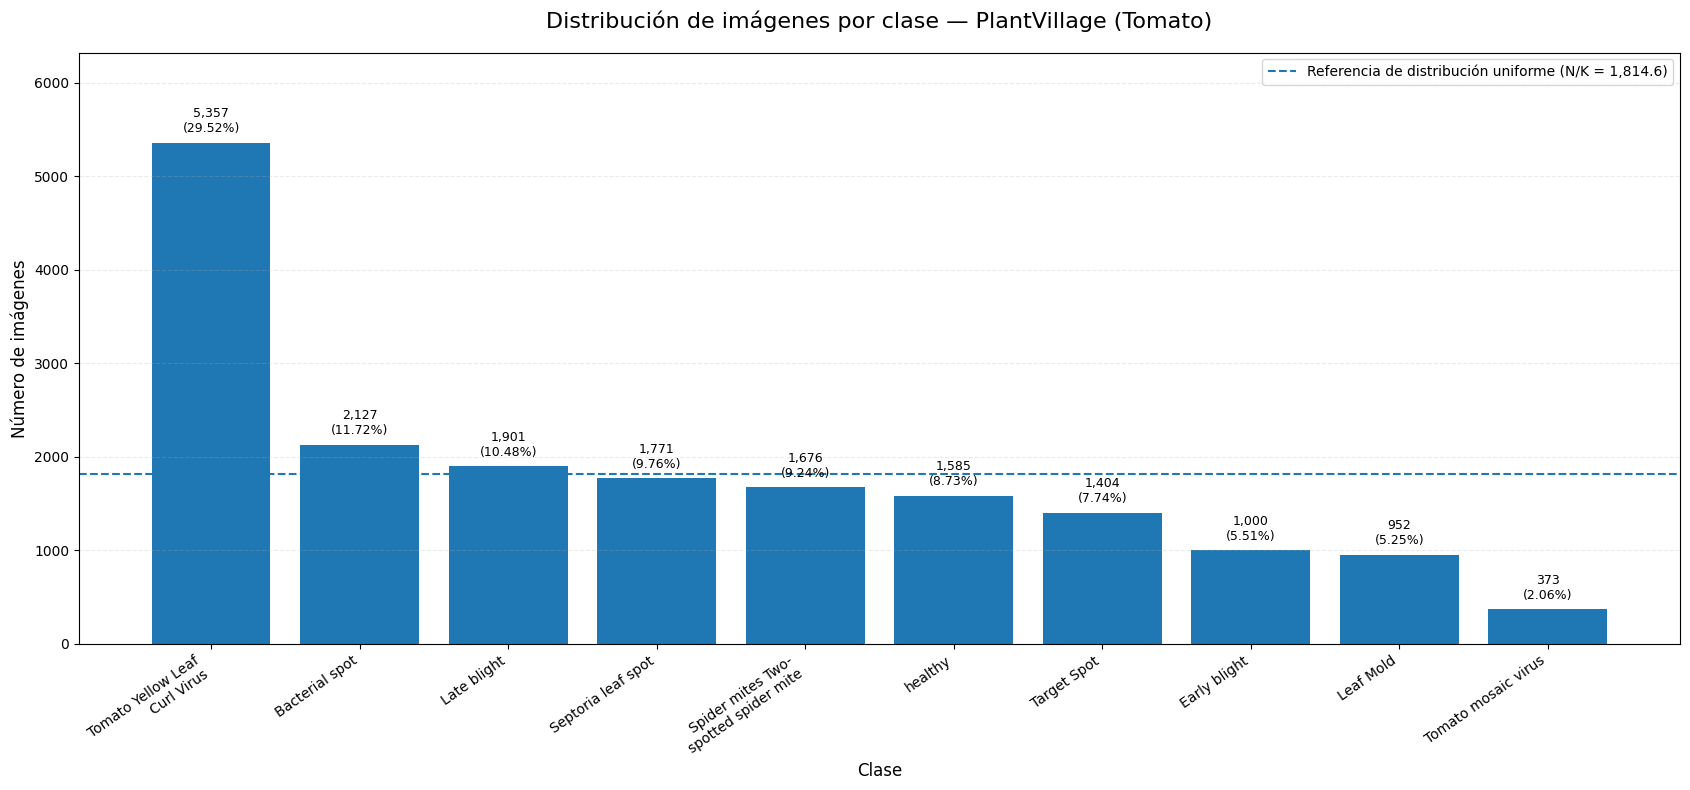


RESUMEN CUANTITATIVO
Total de imágenes       : 18,146
Número de clases        : 10
Referencia equilibrada  : 1,814.6 imágenes por clase
--------------------------------------------------------------------------------
Clase mayoritaria       : Tomato___Tomato_Yellow_Leaf_Curl_Virus
Cantidad                : 5,357
Participación           : 29.52%
--------------------------------------------------------------------------------
Clase minoritaria       : Tomato___Tomato_mosaic_virus
Cantidad                : 373
Participación           : 2.06%
--------------------------------------------------------------------------------
Imbalance Ratio (IR)    : 14.36


In [78]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 1 — DISTRIBUCIÓN DE IMÁGENES POR CLASE
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import matplotlib.pyplot as plt

from textwrap import fill
from IPython.display import display


# ============================================================
# 2. RECUPERAR LOS DATOS GENERADOS EN LA FASE 3
# ============================================================

# La Fase 3 del notebook ya construyó:
#
#   df_maestro
#   df_resumen_clases
#
# Por reproducibilidad y eficiencia evitamos volver a recorrer
# las carpetas de imágenes.
#
# Si df_resumen_clases está disponible, se reutiliza.
# Como respaldo, puede reconstruirse desde df_maestro.

if "df_resumen_clases" in globals():

    df_distribucion = (
        df_resumen_clases[
            [
                "clase",
                "Cantidad",
                "Participacion_%"
            ]
        ]
        .copy()
    )

elif "df_maestro" in globals():

    # Reconstrucción solamente si el resumen anterior
    # no estuviera disponible en memoria.
    df_distribucion = (
        df_maestro
        .groupby("clase")
        .size()
        .reset_index(
            name="Cantidad"
        )
    )

    total_temporal = (
        df_distribucion["Cantidad"]
        .sum()
    )

    df_distribucion[
        "Participacion_%"
    ] = (
        df_distribucion["Cantidad"]
        / total_temporal
        * 100
    )

else:

    raise NameError(
        "No se encontraron 'df_resumen_clases' ni "
        "'df_maestro'. Ejecute previamente la Fase 3."
    )


# ============================================================
# 3. ORDENAR LAS CLASES
# ============================================================

# Para facilitar la interpretación del desbalance,
# las clases se ordenan desde la de mayor frecuencia
# hasta la de menor frecuencia.

df_distribucion = (
    df_distribucion
    .sort_values(
        by="Cantidad",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 4. CALCULAR INDICADORES DE DISTRIBUCIÓN
# ============================================================

# Número total de imágenes
N = int(
    df_distribucion[
        "Cantidad"
    ].sum()
)


# Número de clases
K = int(
    df_distribucion.shape[0]
)


# Cantidad teórica por clase si existiera
# una distribución completamente uniforme
cantidad_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Clase mayoritaria
# ------------------------------------------------------------

fila_mayoritaria = (
    df_distribucion.iloc[0]
)

clase_mayoritaria = (
    fila_mayoritaria["clase"]
)

cantidad_mayoritaria = int(
    fila_mayoritaria["Cantidad"]
)

porcentaje_mayoritaria = float(
    fila_mayoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Clase minoritaria
# ------------------------------------------------------------

fila_minoritaria = (
    df_distribucion.iloc[-1]
)

clase_minoritaria = (
    fila_minoritaria["clase"]
)

cantidad_minoritaria = int(
    fila_minoritaria["Cantidad"]
)

porcentaje_minoritaria = float(
    fila_minoritaria["Participacion_%"]
)


# ------------------------------------------------------------
# Razón de desbalance
#
#             n_max
#     IR = -----------
#             n_min
# ------------------------------------------------------------

imbalance_ratio = (
    cantidad_mayoritaria
    / cantidad_minoritaria
)


# ============================================================
# 5. CONTROL DE CONSISTENCIA
# ============================================================

# Si df_maestro continúa disponible en memoria,
# se comprueba que ambas estructuras representen
# exactamente las mismas observaciones.

if "df_maestro" in globals():

    assert N == len(df_maestro), (
        "El total del resumen por clase no coincide "
        "con el número de filas de df_maestro."
    )


assert K == df_distribucion["clase"].nunique(), (
    "Existe una inconsistencia en el número de clases."
)


# ============================================================
# 6. CREAR ETIQUETAS MÁS LEGIBLES PARA EL GRÁFICO
# ============================================================

def formatear_clase(nombre_clase):
    """
    Convierte los nombres originales de PlantVillage
    en etiquetas más legibles para visualización.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    Los nombres originales permanecen intactos
    dentro del DataFrame.
    """

    etiqueta = (
        nombre_clase
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Divide nombres demasiado largos en varias líneas
    # para evitar solapamiento en el eje X.
    return fill(
        etiqueta,
        width=19
    )


df_distribucion[
    "Etiqueta_grafico"
] = (
    df_distribucion[
        "clase"
    ]
    .apply(
        formatear_clase
    )
)


# ============================================================
# 7. MOSTRAR TABLA UTILIZADA PARA EL GRÁFICO
# ============================================================

print("=" * 80)
print("FASE 4 — DISTRIBUCIÓN DE IMÁGENES POR CLASE")
print("=" * 80)

display(
    df_distribucion[
        [
            "clase",
            "Cantidad",
            "Participacion_%"
        ]
    ]
    .style
    .format(
        {
            "Cantidad": "{:,.0f}",
            "Participacion_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 8. CONSTRUIR EL GRÁFICO DE BARRAS
# ============================================================

fig, ax = plt.subplots(
    figsize=(17, 8)
)


# ------------------------------------------------------------
# Barras
# ------------------------------------------------------------

barras = ax.bar(
    df_distribucion[
        "Etiqueta_grafico"
    ],
    df_distribucion[
        "Cantidad"
    ]
)


# ============================================================
# 9. AGREGAR CANTIDAD Y PORCENTAJE SOBRE CADA BARRA
# ============================================================

max_cantidad = (
    df_distribucion[
        "Cantidad"
    ].max()
)


for barra, cantidad, porcentaje in zip(

    barras,

    df_distribucion[
        "Cantidad"
    ],

    df_distribucion[
        "Participacion_%"
    ]
):

    ax.text(

        # Centro horizontal de cada barra
        barra.get_x()
        + barra.get_width() / 2,

        # Posición ligeramente superior a la barra
        barra.get_height()
        + max_cantidad * 0.015,

        # Información mostrada
        f"{cantidad:,.0f}\n({porcentaje:.2f}%)",

        ha="center",
        va="bottom",
        fontsize=9
    )


# ============================================================
# 10. LÍNEA DE REFERENCIA DE DISTRIBUCIÓN EQUILIBRADA
# ============================================================

ax.axhline(
    y=cantidad_equilibrada,
    linestyle="--",
    linewidth=1.5,
    label=(
        "Referencia de distribución uniforme "
        f"(N/K = {cantidad_equilibrada:,.1f})"
    )
)


# ============================================================
# 11. CONFIGURACIÓN DEL GRÁFICO
# ============================================================

ax.set_title(
    "Distribución de imágenes por clase — PlantVillage (Tomato)",
    fontsize=16,
    pad=18
)

ax.set_xlabel(
    "Clase",
    fontsize=12
)

ax.set_ylabel(
    "Número de imágenes",
    fontsize=12
)


# Rotación de las etiquetas para facilitar lectura
plt.setp(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)


# Cuadrícula solamente en el eje vertical
# para facilitar la comparación de magnitudes.
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# Dar espacio superior para las anotaciones
ax.set_ylim(
    0,
    max_cantidad * 1.18
)


ax.legend(
    loc="upper right"
)


# Optimizar automáticamente márgenes
plt.tight_layout()


# Mostrar gráfico
plt.show()


# ============================================================
# 12. RESUMEN CUANTITATIVO DEL DESBALANCE
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN CUANTITATIVO")
print("=" * 80)

print(
    f"Total de imágenes       : {N:,}"
)

print(
    f"Número de clases        : {K}"
)

print(
    f"Referencia equilibrada  : {cantidad_equilibrada:,.1f} "
    "imágenes por clase"
)

print("-" * 80)

print(
    f"Clase mayoritaria       : {clase_mayoritaria}"
)

print(
    f"Cantidad                : {cantidad_mayoritaria:,}"
)

print(
    f"Participación           : {porcentaje_mayoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Clase minoritaria       : {clase_minoritaria}"
)

print(
    f"Cantidad                : {cantidad_minoritaria:,}"
)

print(
    f"Participación           : {porcentaje_minoritaria:.2f}%"
)

print("-" * 80)

print(
    f"Imbalance Ratio (IR)    : {imbalance_ratio:.2f}"
)

print("=" * 80)

### Interpretación del Gráfico 1 — Distribución por clase

El gráfico evidencia que las **18.146 imágenes** del conjunto de datos depurado no se encuentran distribuidas uniformemente entre las diez categorías.

La clase con mayor representación corresponde a:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, equivalentes aproximadamente al:

$$
29.52\%
$$

del conjunto de datos.

En contraste, la clase con menor número de observaciones es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, correspondientes aproximadamente al:

$$
2.06\%
$$

del dataset.

La razón entre la clase mayoritaria y la minoritaria es:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Por tanto, la categoría con mayor representación posee aproximadamente **14.36 veces más imágenes** que la categoría con menor representación.

Si las observaciones estuvieran distribuidas uniformemente entre las diez clases, cada categoría tendría teóricamente:

$$
n_{\mathrm{eq}}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

El gráfico muestra que varias categorías se encuentran considerablemente por encima o por debajo de esta referencia. En particular, `Tomato___Tomato_Yellow_Leaf_Curl_Virus` presenta una representación claramente superior al resto, mientras que `Tomato___Tomato_mosaic_virus` posee una cantidad mucho menor de observaciones.

En consecuencia, se concluye que el dataset presenta **desbalance entre clases**. Esta característica deberá considerarse en las siguientes fases del proyecto, especialmente al realizar la división estratificada de **Train / Validation / Test** y al seleccionar las métricas de evaluación.

Debido a este desbalance, la **accuracy global no debería utilizarse como única medida de rendimiento**, ya que un modelo podría obtener un resultado aparentemente favorable al predecir mejor las clases con mayor representación. Posteriormente será conveniente complementar la evaluación con métricas como:

- Balanced Accuracy.
- Precision Macro.
- Recall Macro.
- F1-score Macro.
- Matriz de confusión.

Este análisis no implica todavía modificar la distribución de los datos. Su objetivo en esta fase es **diagnosticar y documentar el desbalance antes de tomar decisiones de preprocesamiento o entrenamiento**.

## Gráfico 2 - Ejemplos aleatorios
Mostrar una muestra representativa de imágenes con su clase correspondiente.

### 4.2 Gráfico 2 — Ejemplos aleatorios de imágenes

Después de analizar la distribución cuantitativa de las clases, se realiza una inspección visual del conjunto de datos mediante una **muestra aleatoria de imágenes**.

El objetivo de esta etapa es observar directamente las características visuales presentes en PlantVillage y comprobar si el conjunto depurado presenta condiciones adecuadas para el posterior entrenamiento de los modelos MLP y CNN.

Sea el conjunto de datos limpio:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

- $X_i$ corresponde a la imagen $i$;
- $y_i$ corresponde a la clase asociada a esa imagen;
- $N$ corresponde al número total de imágenes válidas y únicas.

En el dataset actualmente procesado:

$$
N = 18\,146
$$

y existen:

$$
K = 10
$$

clases.

Para realizar la inspección visual se selecciona una muestra aleatoria sin reemplazo:

$$
\mathcal{S}
\subset
\mathcal{D}
$$

tal que:

$$
|\mathcal{S}| = m
$$

donde $m$ representa el número de imágenes que serán mostradas.

La selección se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer dos veces dentro de la muestra:

$$
X_i \neq X_j
\qquad
\forall i \neq j
$$

Se utiliza una semilla fija:

$$
SEED = 42
$$

para que la selección sea reproducible. Esto significa que, mientras el dataset no cambie, volver a ejecutar la celda producirá la misma muestra de imágenes.

### Objetivos de la inspección visual

La muestra permitirá observar preliminarmente:

- diferencias de color entre hojas;
- presencia de manchas, lesiones y cambios de textura;
- distribución espacial de los síntomas;
- variaciones de iluminación;
- orientación y tamaño aparente de las hojas;
- homogeneidad de los fondos;
- similitud visual entre algunas enfermedades;
- posibles anomalías que no hayan sido detectadas durante la auditoría automática.

Esta visualización constituye un análisis exploratorio cualitativo. Por tanto, **no se utilizará todavía para modificar, normalizar o aumentar artificialmente las imágenes**.

In [79]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 2 — EJEMPLOS ALEATORIOS DE IMÁGENES
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS NECESARIAS
# ------------------------------------------------------------

from pathlib import Path
import math

import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN GENERAL
# ============================================================

# Utilizamos la misma semilla definida previamente en el proyecto.
# Si la variable SEED todavía no estuviera disponible en memoria,
# se establece 42 como valor de respaldo.

SEED_EDA = SEED if "SEED" in globals() else 42


# Número de imágenes que se mostrarán.
#
# 12 imágenes permiten utilizar una cuadrícula 3 x 4,
# suficientemente grande para observar diversidad visual
# sin sobrecargar la salida del notebook.

N_MUESTRA = 12


# Número de columnas del gráfico.
N_COLUMNAS = 4


# ============================================================
# 3. VERIFICAR QUE EL DATAFRAME MAESTRO EXISTA
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR LAS COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}

columnas_faltantes = (
    columnas_requeridas
    - set(df_maestro.columns)
)

if columnas_faltantes:

    raise KeyError(
        "Faltan las siguientes columnas necesarias "
        f"en df_maestro: {sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR EL DATAFRAME PARA EL MUESTREO
# ============================================================

# Trabajamos solamente con las columnas necesarias para esta
# visualización.
#
# No modificamos df_maestro: generamos una copia independiente.

df_eda_imagenes = (
    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]
    .copy()
)


# ============================================================
# 6. VERIFICAR QUE LAS RUTAS EXISTAN
# ============================================================

# Aunque las imágenes ya fueron verificadas anteriormente,
# este control protege la celda frente a posibles cambios
# accidentales de rutas entre ejecuciones.

df_eda_imagenes[
    "ruta_existe"
] = (
    df_eda_imagenes[
        "ruta"
    ]
    .apply(
        lambda ruta: Path(ruta).is_file()
    )
)


# Contar imágenes cuyas rutas siguen disponibles.
n_rutas_validas = int(
    df_eda_imagenes[
        "ruta_existe"
    ].sum()
)

n_rutas_no_disponibles = int(
    (~df_eda_imagenes["ruta_existe"]).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 2: EJEMPLOS ALEATORIOS")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_imagenes):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# Mantener únicamente imágenes disponibles.
df_eda_validas = (
    df_eda_imagenes[
        df_eda_imagenes[
            "ruta_existe"
        ]
    ]
    .drop(
        columns="ruta_existe"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. VERIFICAR QUE LA MUESTRA SEA POSIBLE
# ============================================================

if len(df_eda_validas) < N_MUESTRA:

    raise ValueError(
        f"Se solicitaron {N_MUESTRA} imágenes, "
        f"pero solamente existen {len(df_eda_validas)} "
        "rutas válidas."
    )


# ============================================================
# 8. EXTRAER UNA MUESTRA ALEATORIA REPRODUCIBLE
# ============================================================

# sample() realiza selección aleatoria sin reemplazo.
#
# random_state garantiza que el resultado pueda reproducirse
# al volver a ejecutar el notebook.

df_muestra_aleatoria = (
    df_eda_validas
    .sample(
        n=N_MUESTRA,
        replace=False,
        random_state=SEED_EDA
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 9. FUNCIÓN PARA HACER MÁS LEGIBLES LAS ETIQUETAS
# ============================================================

def formatear_nombre_clase(nombre_clase):
    """
    Convierte el nombre original de PlantVillage en una
    etiqueta más legible para el gráfico.

    Ejemplo:
    Tomato___Early_blight
        ->
    Early blight

    El valor original no se modifica en df_maestro.
    """

    nombre = (
        str(nombre_clase)
        .replace(
            "Tomato___",
            ""
        )
        .replace(
            "_",
            " "
        )
    )

    # Separar nombres largos en varias líneas.
    return fill(
        nombre,
        width=23
    )


# ============================================================
# 10. CALCULAR LA CUADRÍCULA DEL GRÁFICO
# ============================================================

N_FILAS = math.ceil(
    N_MUESTRA
    / N_COLUMNAS
)


# ============================================================
# 11. CREAR LA FIGURA
# ============================================================

fig, axes = plt.subplots(
    nrows=N_FILAS,
    ncols=N_COLUMNAS,
    figsize=(
        16,
        4.2 * N_FILAS
    )
)


# Convertimos axes a vector para facilitar el recorrido,
# independientemente del número de filas y columnas.

axes = axes.flatten()


# ============================================================
# 12. CARGAR Y MOSTRAR CADA IMAGEN
# ============================================================

for indice, fila in df_muestra_aleatoria.iterrows():

    ax = axes[indice]

    ruta_imagen = Path(
        fila["ruta"]
    )

    clase_original = (
        fila["clase"]
    )

    # --------------------------------------------------------
    # Abrir la imagen
    # --------------------------------------------------------
    #
    # Se utiliza un gestor de contexto "with" para asegurar
    # que el archivo sea cerrado correctamente después de leerlo.
    #
    # convert("RGB") homogeneiza la representación únicamente
    # para mostrarla con Matplotlib.
    #
    # No se realiza resize, normalización ni augmentation.

    with Image.open(
        ruta_imagen
    ) as imagen:

        imagen_rgb = (
            imagen
            .convert("RGB")
            .copy()
        )


    # --------------------------------------------------------
    # Mostrar imagen
    # --------------------------------------------------------

    ax.imshow(
        imagen_rgb
    )


    # --------------------------------------------------------
    # Etiqueta de clase
    # --------------------------------------------------------

    etiqueta = (
        formatear_nombre_clase(
            clase_original
        )
    )

    ax.set_title(
        etiqueta,
        fontsize=10,
        pad=8
    )


    # Los ejes numéricos no aportan información en una
    # inspección visual de imágenes.
    ax.axis("off")


# ============================================================
# 13. OCULTAR POSICIONES VACÍAS DE LA CUADRÍCULA
# ============================================================

# Este bloque permite cambiar N_MUESTRA libremente sin dejar
# ejes vacíos visibles si el número no es múltiplo de columnas.

for indice in range(
    N_MUESTRA,
    len(axes)
):

    axes[indice].axis(
        "off"
    )


# ============================================================
# 14. TÍTULO GENERAL
# ============================================================

fig.suptitle(
    (
        "Ejemplos aleatorios del dataset PlantVillage "
        "— Clases de tomate"
    ),
    fontsize=17,
    y=1.02
)


# Ajustar espacios entre imágenes.
plt.tight_layout()


# Mostrar gráfico.
plt.show()


# ============================================================
# 15. RESUMEN DE LA MUESTRA VISUALIZADA
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DE LA MUESTRA")
print("=" * 80)

print(
    f"Semilla utilizada        : {SEED_EDA}"
)

print(
    f"Imágenes seleccionadas   : {N_MUESTRA}"
)

print(
    f"Clases representadas     : "
    f"{df_muestra_aleatoria['clase'].nunique()}"
)

print("\nDistribución de clases dentro de la muestra:")

display(
    df_muestra_aleatoria[
        "clase"
    ]
    .value_counts()
    .rename_axis(
        "Clase"
    )
    .reset_index(
        name="Cantidad"
    )
)

print("=" * 80)

Output hidden; open in https://colab.research.google.com to view.

### Interpretación del Gráfico 2 — Ejemplos aleatorios

La inspección de una muestra aleatoria permite complementar el análisis cuantitativo realizado previamente con una evaluación cualitativa de las imágenes.

La selección fue realizada sin reemplazo y utilizando:

$$
SEED = 42
$$

por lo que la muestra puede reproducirse mientras se mantenga sin modificaciones el conjunto de datos.

Cada observación del problema puede representarse mediante:

$$
(X_i,y_i)
$$

donde $X_i$ corresponde a la información visual contenida en la imagen y $y_i$ representa la enfermedad o estado sanitario asociado.

Esta inspección permite estudiar características que no están explícitamente representadas como variables tabulares, entre ellas:

- coloración de las hojas;
- manchas y lesiones;
- patrones de textura;
- bordes y formas;
- distribución espacial de los síntomas;
- orientación de la hoja;
- iluminación;
- características del fondo.

Estas propiedades resultan relevantes para la hipótesis central del proyecto porque la clasificación depende de información espacial distribuida sobre la superficie de la imagen.

Una MLP utilizará posteriormente una representación vectorizada de estos píxeles:

$$
X
\in
\mathbb{R}^{H\times W\times C}
\longrightarrow
x
\in
\mathbb{R}^{HWC}
$$

mientras que una CNN conservará inicialmente la estructura:

$$
X
\in
\mathbb{R}^{H\times W\times C}
$$

permitiendo aprender patrones locales relacionados con bordes, texturas, manchas y otras características visuales.

Por tanto, la inspección visual de ejemplos aleatorios aporta evidencia preliminar de que la información relevante para la clasificación no está contenida solamente en valores individuales de píxeles, sino también en **sus relaciones espaciales**.

En esta etapa el análisis tiene carácter exploratorio. Las conclusiones sobre similitud entre clases y variabilidad dentro de cada categoría serán estudiadas con mayor detalle en el siguiente gráfico, donde se mostrarán múltiples ejemplos organizados explícitamente por clase.

## Gráfico 3 - Ejemplos por clase
Mostrar varias imágenes por categoría para observar variabilidad intra-clase y similitud inter-clase.

## 4.3 Gráfico 3 — Ejemplos por clase

Después de analizar la distribución cuantitativa de las categorías y observar una muestra aleatoria global, se realiza una inspección visual **controlada por clase**.

El objetivo de esta visualización es mostrar varias imágenes pertenecientes a cada categoría para estudiar dos propiedades importantes del conjunto de datos:

- **Variabilidad intra-clase:** grado de diversidad visual existente entre imágenes que poseen la misma etiqueta.
- **Similitud inter-clase:** grado de parecido visual que puede existir entre imágenes pertenecientes a categorías diferentes.

El conjunto de datos limpio puede representarse como:

$$
\mathcal{D}
=
\left\{
(X_i,y_i)
\right\}_{i=1}^{N}
$$

donde:

$$
N = 18\,146
$$

representa el número total de imágenes válidas y únicas, y:

$$
K = 10
$$

corresponde al número de clases.

Para cada clase:

$$
c_k \in \mathcal{C},
\qquad
k=1,\ldots,K
$$

se define el subconjunto:

$$
\mathcal{D}_k
=
\left\{
(X_i,y_i)\in\mathcal{D}
:
y_i=c_k
\right\}
$$

que contiene todas las imágenes asociadas a la categoría $c_k$.

A diferencia del muestreo aleatorio global utilizado anteriormente, en esta visualización se selecciona el **mismo número de imágenes para cada clase**.

Sea:

$$
m = 3
$$

el número de imágenes seleccionadas por categoría. Para cada clase se obtiene entonces una muestra:

$$
\mathcal{S}_k
\subset
\mathcal{D}_k
$$

tal que:

$$
|\mathcal{S}_k|=m
$$

La muestra visual completa estará formada por:

$$
\mathcal{S}
=
\bigcup_{k=1}^{K}\mathcal{S}_k
$$

y el número total de imágenes visualizadas será:

$$
|\mathcal{S}|
=
K\cdot m
$$

Por tanto:

$$
|\mathcal{S}|
=
10\cdot3
=
30
$$

imágenes.

La selección dentro de cada categoría se realiza **sin reemplazo**, por lo que una misma imagen no puede aparecer repetida dentro de una clase:

$$
X_i \neq X_j,
\qquad
\forall i\neq j
$$

Además, se utiliza una semilla fija:

$$
SEED=42
$$

para garantizar la reproducibilidad de la selección.

### Variabilidad intra-clase

Para una determinada categoría $c_k$, interesa estudiar visualmente la diversidad existente entre:

$$
X_i,\;X_j\in\mathcal{D}_k
$$

aunque ambas observaciones compartan:

$$
y_i=y_j=c_k
$$

Las diferencias pueden encontrarse en características como color, textura, extensión de las lesiones, orientación de la hoja, iluminación o distribución espacial de los síntomas.

### Similitud inter-clase

También interesa comparar imágenes correspondientes a clases diferentes:

$$
X_i\in\mathcal{D}_a,
\qquad
X_j\in\mathcal{D}_b,
\qquad
a\neq b
$$

para determinar si existen patrones visuales similares capaces de dificultar posteriormente la clasificación.

Esta inspección resulta especialmente relevante para la comparación experimental entre MLP y CNN, debido a que las CNN pueden aprender relaciones espaciales locales mediante operaciones de convolución, mientras que la MLP trabajará posteriormente con una representación vectorizada de la imagen.

En esta etapa las imágenes se muestran **sin normalización, redimensionamiento para entrenamiento ni data augmentation**, ya que el objetivo es inspeccionar el contenido visual original del dataset depurado.

In [80]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# GRÁFICO 3 — EJEMPLOS POR CLASE
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Mostrar varias imágenes de CADA categoría del dataset
# para estudiar:
#
#   1. Variabilidad intra-clase:
#      diferencias visuales entre imágenes de la misma clase.
#
#   2. Similitud inter-clase:
#      semejanzas visuales entre categorías diferentes.
#
# La visualización reutiliza directamente df_maestro,
# construido previamente en la Fase 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
from textwrap import fill


# ============================================================
# 2. CONFIGURACIÓN REPRODUCIBLE
# ============================================================

# Utilizar la semilla general del proyecto si ya existe.
# Si no existe, utilizar 42 como respaldo.

SEED_EDA = (
    SEED
    if "SEED" in globals()
    else 42
)


# ------------------------------------------------------------
# Número de imágenes que se mostrarán por clase
# ------------------------------------------------------------

IMAGENES_POR_CLASE = 3


# ============================================================
# 3. VERIFICAR LA EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró el DataFrame 'df_maestro'. "
        "Ejecute previamente la Fase 3 del proyecto."
    )


# ============================================================
# 4. VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 5. PREPARAR LOS DATOS PARA EL EDA
# ============================================================

# Crear una copia independiente.
#
# De esta forma no se modifica df_maestro,
# que continuará siendo la referencia principal
# del dataset limpio.

df_eda_clases = (

    df_maestro[
        [
            "ruta",
            "clase"
        ]
    ]

    .copy()
)


# ============================================================
# 6. VERIFICAR EXISTENCIA DE LOS ARCHIVOS
# ============================================================

# La integridad del dataset ya fue auditada previamente.
#
# Sin embargo, comprobamos nuevamente que las rutas sigan
# disponibles para evitar errores si la sesión de Colab
# hubiese sido modificada después de la Fase 3.

df_eda_clases[
    "ruta_existe"
] = (

    df_eda_clases[
        "ruta"
    ]

    .apply(
        lambda ruta:
        Path(ruta).is_file()
    )
)


# ------------------------------------------------------------
# Número de rutas disponibles
# ------------------------------------------------------------

n_rutas_validas = int(
    df_eda_clases[
        "ruta_existe"
    ].sum()
)


n_rutas_no_disponibles = int(
    (
        ~df_eda_clases[
            "ruta_existe"
        ]
    ).sum()
)


print("=" * 80)
print("FASE 4 — GRÁFICO 3: EJEMPLOS POR CLASE")
print("=" * 80)

print(
    f"Imágenes registradas en df_maestro : "
    f"{len(df_eda_clases):,}"
)

print(
    f"Rutas disponibles                  : "
    f"{n_rutas_validas:,}"
)

print(
    f"Rutas no disponibles               : "
    f"{n_rutas_no_disponibles:,}"
)


# ------------------------------------------------------------
# Mantener solamente rutas existentes
# ------------------------------------------------------------

df_eda_clases = (

    df_eda_clases[
        df_eda_clases[
            "ruta_existe"
        ]
    ]

    .drop(
        columns="ruta_existe"
    )

    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. IDENTIFICAR LAS CLASES
# ============================================================

# Se ordenan alfabéticamente para que el resultado sea
# estable y fácil de revisar entre distintas ejecuciones.

clases = sorted(
    df_eda_clases[
        "clase"
    ].unique()
)


N_CLASES = len(
    clases
)


print(
    f"Número de clases                    : "
    f"{N_CLASES}"
)


# ============================================================
# 8. VERIFICAR QUE CADA CLASE TENGA SUFICIENTES IMÁGENES
# ============================================================

conteo_clases = (

    df_eda_clases[
        "clase"
    ]

    .value_counts()
)


clases_insuficientes = (

    conteo_clases[
        conteo_clases
        <
        IMAGENES_POR_CLASE
    ]
)


if not clases_insuficientes.empty:

    raise ValueError(
        "Algunas clases no poseen suficientes imágenes "
        "para realizar el muestreo solicitado:\n"
        f"{clases_insuficientes}"
    )


# ============================================================
# 9. MUESTREO CONTROLADO POR CLASE
# ============================================================

# En lugar de realizar una muestra aleatoria global,
# seleccionamos exactamente el mismo número de imágenes
# de cada categoría.
#
# Esto evita que el desbalance del dataset determine qué
# clases aparecen en esta visualización.
#
# IMPORTANTE:
# El muestreo es solamente para el EDA.
# No constituye oversampling ni altera el dataset.

muestras_por_clase = []


for indice_clase, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Obtener únicamente las imágenes de la clase actual
    # --------------------------------------------------------

    df_clase = (

        df_eda_clases[
            df_eda_clases[
                "clase"
            ]
            ==
            clase
        ]
    )


    # --------------------------------------------------------
    # Seleccionar imágenes sin reemplazo
    # --------------------------------------------------------
    #
    # Se utiliza una semilla reproducible diferente para
    # cada categoría:
    #
    # SEED + índice de clase
    #
    # Esto mantiene el experimento reproducible.

    muestra_clase = (

        df_clase

        .sample(
            n=IMAGENES_POR_CLASE,
            replace=False,
            random_state=(
                SEED_EDA
                +
                indice_clase
            )
        )

        .copy()
    )


    # Añadir un número interno para identificar
    # la posición visual dentro de la clase.

    muestra_clase[
        "ejemplo"
    ] = range(
        1,
        IMAGENES_POR_CLASE + 1
    )


    muestras_por_clase.append(
        muestra_clase
    )


# ------------------------------------------------------------
# Unificar todas las muestras
# ------------------------------------------------------------

df_muestra_por_clase = (

    pd.concat(
        muestras_por_clase,
        ignore_index=True
    )
)


# ============================================================
# 10. CONTROLES DE CONSISTENCIA
# ============================================================

N_ESPERADO = (
    N_CLASES
    *
    IMAGENES_POR_CLASE
)


assert (
    len(df_muestra_por_clase)
    ==
    N_ESPERADO
), (
    "La cantidad total de imágenes seleccionadas "
    "no coincide con la cantidad esperada."
)


# Comprobar que todas las categorías tengan exactamente
# el mismo número de imágenes.

conteo_muestra = (

    df_muestra_por_clase

    .groupby(
        "clase"
    )

    .size()
)


assert (
    conteo_muestra
    ==
    IMAGENES_POR_CLASE
).all(), (
    "No todas las clases poseen el mismo número "
    "de imágenes en la muestra."
)


# Verificar que no se repitan rutas.

assert (
    df_muestra_por_clase[
        "ruta"
    ].duplicated().sum()
    ==
    0
), (
    "Se detectaron imágenes repetidas dentro "
    "de la muestra visual."
)


print(
    f"Imágenes por clase                  : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total de imágenes visualizadas      : "
    f"{len(df_muestra_por_clase)}"
)


# ============================================================
# 11. FUNCIÓN PARA FORMATEAR LOS NOMBRES DE CLASE
# ============================================================

def formatear_nombre_clase(
    nombre_clase
):
    """
    Convierte el nombre original de PlantVillage
    en una etiqueta más legible para el gráfico.

    Ejemplo
    -------
    Tomato___Early_blight
        ->
    Early blight

    El nombre original permanece intacto en df_maestro.
    """

    etiqueta = (

        str(nombre_clase)

        .replace(
            "Tomato___",
            ""
        )

        .replace(
            "_",
            " "
        )
    )


    # Dividir nombres extensos en varias líneas
    # para mantener una figura legible.

    return fill(
        etiqueta,
        width=28
    )


# ============================================================
# 12. CREAR LA CUADRÍCULA
# ============================================================

# Estructura:
#
#     filas    = número de clases
#     columnas = imágenes por clase
#
# En el dataset actual:
#
#     10 filas x 3 columnas = 30 imágenes

fig, axes = plt.subplots(

    nrows=N_CLASES,

    ncols=IMAGENES_POR_CLASE,

    figsize=(
        12,
        3.15 * N_CLASES
    )
)


# Si en alguna ejecución existiera una sola columna,
# aseguramos que axes mantenga estructura bidimensional.

if IMAGENES_POR_CLASE == 1:

    axes = axes.reshape(
        N_CLASES,
        1
    )


# ============================================================
# 13. MOSTRAR LAS IMÁGENES
# ============================================================

for fila_idx, clase in enumerate(
    clases
):

    # --------------------------------------------------------
    # Recuperar la muestra correspondiente a esta categoría
    # --------------------------------------------------------

    muestra_clase = (

        df_muestra_por_clase[
            df_muestra_por_clase[
                "clase"
            ]
            ==
            clase
        ]

        .sort_values(
            "ejemplo"
        )

        .reset_index(
            drop=True
        )
    )


    # Etiqueta legible de la categoría

    etiqueta_clase = (
        formatear_nombre_clase(
            clase
        )
    )


    # --------------------------------------------------------
    # Recorrer imágenes de la fila
    # --------------------------------------------------------

    for columna_idx, fila in (
        muestra_clase.iterrows()
    ):

        ax = axes[
            fila_idx,
            columna_idx
        ]


        ruta_imagen = Path(
            fila[
                "ruta"
            ]
        )


        # ----------------------------------------------------
        # Cargar imagen
        # ----------------------------------------------------
        #
        # Se muestra la imagen original.
        #
        # NO se aplica:
        # - resize para entrenamiento;
        # - normalización;
        # - data augmentation.
        #
        # La conversión RGB garantiza únicamente una
        # visualización homogénea con Matplotlib.

        with Image.open(
            ruta_imagen
        ) as imagen:

            imagen_rgb = (

                imagen
                .convert("RGB")
                .copy()
            )


        # ----------------------------------------------------
        # Mostrar imagen
        # ----------------------------------------------------

        ax.imshow(
            imagen_rgb
        )


        # ----------------------------------------------------
        # Título superior
        # ----------------------------------------------------

        if fila_idx == 0:

            ax.set_title(
                f"Ejemplo {columna_idx + 1}",
                fontsize=11,
                pad=8
            )


        # ----------------------------------------------------
        # Etiqueta de clase
        # ----------------------------------------------------
        #
        # Se muestra solamente en la primera columna
        # para evitar repetir el mismo nombre tres veces.

        if columna_idx == 0:

            ax.set_ylabel(

                etiqueta_clase,

                fontsize=10,

                rotation=0,

                ha="right",

                va="center",

                labelpad=90
            )


        # ----------------------------------------------------
        # Eliminar elementos gráficos innecesarios
        # ----------------------------------------------------

        ax.set_xticks(
            []
        )

        ax.set_yticks(
            []
        )


        for spine in ax.spines.values():

            spine.set_visible(
                False
            )


# ============================================================
# 14. TÍTULO GENERAL DEL GRÁFICO
# ============================================================

fig.suptitle(

    (
        "Ejemplos por clase — PlantVillage (Tomato)\n"
        "Variabilidad intra-clase y similitud inter-clase"
    ),

    fontsize=17,

    y=1.005
)


# ============================================================
# 15. AJUSTAR LA DISTRIBUCIÓN VISUAL
# ============================================================

plt.tight_layout(
    h_pad=1.6,
    w_pad=1.0
)


# Espacio adicional a la izquierda para
# las etiquetas de las clases.

plt.subplots_adjust(
    left=0.28
)


# ============================================================
# 16. MOSTRAR EL GRÁFICO
# ============================================================

plt.show()


# ============================================================
# 17. RESUMEN DEL MUESTREO
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DEL GRÁFICO 3")
print("=" * 80)

print(
    f"Semilla utilizada       : "
    f"{SEED_EDA}"
)

print(
    f"Número de clases        : "
    f"{N_CLASES}"
)

print(
    f"Imágenes por clase      : "
    f"{IMAGENES_POR_CLASE}"
)

print(
    f"Total visualizado       : "
    f"{len(df_muestra_por_clase)}"
)

print(
    f"Rutas duplicadas        : "
    f"{df_muestra_por_clase['ruta'].duplicated().sum()}"
)

print("=" * 80)

Output hidden; open in https://colab.research.google.com to view.

### 4.4 Preguntas de análisis del EDA visual

Una vez estudiada la distribución de las clases, una muestra aleatoria global y ejemplos organizados por categoría, es posible realizar un diagnóstico exploratorio del conjunto de datos antes de proceder a la partición **Train / Validation / Test**.

El análisis debe distinguir entre dos conceptos diferentes:

1. **Homogeneidad técnica**, relacionada con resolución, formato, canales e integridad de los archivos.
2. **Variabilidad visual**, relacionada con color, textura, forma, lesiones y distribución espacial de los síntomas.

Estas propiedades no son contradictorias. Un dataset puede ser técnicamente homogéneo y, al mismo tiempo, presentar suficiente diversidad visual para constituir un problema de clasificación no trivial.

---

#### 1. ¿Las imágenes son visualmente homogéneas?

**En términos técnicos, sí existe un alto grado de homogeneidad. Sin embargo, el contenido visual presenta una variabilidad relevante.**

Después de la depuración, el conjunto contiene:

$$
N = 18\,146
$$

imágenes válidas y únicas.

Todas las imágenes presentan:

$$
H = 256
$$

píxeles de alto,

$$
W = 256
$$

píxeles de ancho y:

$$
C = 3
$$

canales de color.

Por tanto, cada imagen posee la misma estructura:

$$
X_i
\in
\mathbb{R}^{256\times256\times3}
$$

Además:

$$
100\%
$$

de las imágenes utilizan formato **JPEG**, modo de color **RGB** y fueron verificadas satisfactoriamente durante la auditoría de integridad.

La homogeneidad estructural puede expresarse mediante:

$$
H_{\text{dim}}
=
\frac{N_{\text{dimensión modal}}}{N}
\times100
$$

En este dataset:

$$
H_{\text{dim}}
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

De manera análoga:

$$
H_{\text{formato}}=100\%
$$

y:

$$
H_{\text{RGB}}=100\%
$$

Desde el punto de vista visual, los ejemplos muestran también condiciones de adquisición relativamente controladas: generalmente aparece una hoja como objeto principal y los fondos son visualmente simples.

Sin embargo, **las imágenes no son idénticas ni completamente uniformes en su apariencia**, lo cual es favorable para el aprendizaje. Se observan diferencias en:

- forma y orientación de las hojas;
- intensidad del color verde;
- amarillamiento;
- extensión y localización de lesiones;
- tamaño y distribución de manchas;
- textura;
- grado de deterioro;
- iluminación y tonalidad del fondo.

Por tanto, la conclusión más precisa es:

$$
\boxed{
\text{alta homogeneidad técnica}
+
\text{variabilidad visual útil}
}
$$

Esta combinación resulta apropiada para un problema supervisado de clasificación de imágenes.

---

#### 2. ¿Hay diferencias evidentes entre las enfermedades?

**Sí. La inspección visual muestra diferencias apreciables entre varias categorías, aunque no todas presentan una separación visual igualmente clara.**

Los ejemplos organizados por clase muestran que las enfermedades pueden diferenciarse mediante patrones relacionados con:

$$
\text{color}
+
\text{textura}
+
\text{manchas}
+
\text{necrosis}
+
\text{deformación}
+
\text{distribución espacial}
$$

Por ejemplo, en la muestra exploratoria:

- la clase `healthy` presenta hojas visualmente más uniformes y sin lesiones prominentes;
- `Tomato___Tomato_Yellow_Leaf_Curl_Virus` muestra alteraciones visibles de coloración y forma;
- `Tomato___Late_blight` presenta en varios ejemplos áreas extensas de deterioro o necrosis;
- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot` presentan patrones de manchas distribuidas sobre la hoja;
- otras categorías presentan modificaciones más sutiles asociadas principalmente a textura, moteado o cambios de color.

Estas observaciones apoyan la hipótesis de que la variable objetivo depende de información visual estructurada.

Conceptualmente:

$$
X_i
\longrightarrow
\left\{
\text{bordes},
\text{colores},
\text{texturas},
\text{lesiones},
\text{formas}
\right\}
\longrightarrow
y_i
$$

Por tanto, existen diferencias visuales potencialmente aprendibles por una red neuronal.

No obstante, esta conclusión es **exploratoria**. La verdadera capacidad de separación entre categorías deberá verificarse posteriormente mediante el rendimiento de los modelos y la matriz de confusión.

---

#### 3. ¿Existen clases visualmente similares?

**Sí. El Gráfico 3 sugiere que algunas categorías comparten características visuales y podrían resultar más difíciles de separar.**

Entre los ejemplos observados aparecen similitudes potenciales entre enfermedades que presentan:

- manchas pequeñas o distribuidas;
- regiones amarillentas;
- cambios de textura;
- lesiones oscuras;
- patrones de deterioro que pueden superponerse parcialmente.

En particular, la inspección visual sugiere semejanzas entre algunos ejemplos de:

- `Tomato___Bacterial_spot` y `Tomato___Septoria_leaf_spot`;
- `Tomato___Early_blight` y `Tomato___Late_blight`;
- `Tomato___Spider_mites Two-spotted_spider_mite` y `Tomato___Target_Spot`.

Estas semejanzas deben considerarse **hipótesis visuales preliminares**, no como evidencia definitiva de confusión.

Posteriormente podrá comprobarse si una similitud observada durante el EDA se traduce realmente en errores del modelo:

$$
\text{similitud visual}
\;\not\Rightarrow\;
\text{confusión obligatoria}
$$

pero puede plantearse la hipótesis:

$$
\text{mayor similitud visual}
\longrightarrow
\text{mayor dificultad de separación}
$$

Esta relación deberá contrastarse posteriormente mediante:

$$
\text{Matriz de confusión}
+
\text{Recall por clase}
+
\text{F1 por clase}
$$

Por esta razón, el análisis visual realizado ahora será útil para interpretar los errores futuros de la MLP y la CNN.

---

#### 4. ¿Existe desbalance de clases?

**Sí. El dataset presenta un desbalance de clases claramente identificable y cuantificable.**

El conjunto contiene:

$$
N=18\,146
$$

imágenes distribuidas entre:

$$
K=10
$$

clases.

Si existiera una distribución perfectamente uniforme, cada clase tendría aproximadamente:

$$
n_{\text{eq}}
=
\frac{N}{K}
=
\frac{18\,146}{10}
=
1\,814.6
$$

imágenes.

Sin embargo, la clase mayoritaria es:

`Tomato___Tomato_Yellow_Leaf_Curl_Virus`

con:

$$
n_{\max}=5\,357
$$

imágenes, que representan:

$$
29.52\%
$$

del dataset.

La clase minoritaria es:

`Tomato___Tomato_mosaic_virus`

con:

$$
n_{\min}=373
$$

imágenes, equivalentes a:

$$
2.06\%
$$

del total.

La razón de desbalance es:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
$$

por lo tanto:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

Esto significa que la clase mayoritaria contiene aproximadamente:

$$
\boxed{14.36}
$$

veces más imágenes que la categoría minoritaria.

En consecuencia, el dataset debe considerarse **desbalanceado**.

Este resultado tendrá consecuencias metodológicas importantes:

1. la futura división **Train / Validation / Test** deberá ser estratificada;
2. la `accuracy` no deberá utilizarse como única métrica;
3. deberán analizarse métricas sensibles al rendimiento por clase, como:

$$
\text{Balanced Accuracy}
$$

$$
\text{Precision}_{macro}
$$

$$
\text{Recall}_{macro}
$$

$$
F1_{macro}
$$

además de la matriz de confusión.

En esta etapa, sin embargo, el desbalance solamente se **diagnostica y documenta**. La estrategia para tratarlo durante el entrenamiento deberá decidirse posteriormente y no debe confundirse con el EDA.

---

#### 5. ¿La calidad visual parece suficientemente consistente para entrenamiento?

**Sí. La evidencia disponible indica que la calidad técnica del dataset es suficientemente consistente para avanzar hacia el modelamiento.**

La auditoría realizada previamente produjo:

$$
N_{\text{válidas}}
=
18\,146
$$

y:

$$
N_{\text{problemáticas}}
=
0
$$

por lo que la tasa de integridad del dataset limpio es:

$$
Q
=
\frac{N_{\text{válidas}}}{N}
\times100
$$

$$
Q
=
\frac{18\,146}{18\,146}
\times100
=
100\%
$$

Además:

- todas las imágenes tienen resolución $256\times256$;
- todas poseen $3$ canales;
- todas utilizan modo RGB;
- todas corresponden al formato JPEG;
- no existen rutas ausentes en las visualizaciones de la Fase 4;
- después de apartar las copias redundantes quedan:

$$
N_{\text{duplicados restantes}}=0
$$

Por tanto, desde el punto de vista técnico:

$$
\boxed{
\text{integridad}
+
\text{resolución uniforme}
+
\text{color uniforme}
+
\text{ausencia de duplicados exactos}
}
$$

constituyen condiciones favorables para continuar con la preparación de los datos.

La inspección visual también muestra imágenes suficientemente claras para reconocer estructuras foliares y patrones de lesión.

No obstante, una calidad técnica elevada **no garantiza automáticamente una buena generalización**. Las imágenes parecen provenir de condiciones relativamente controladas, por lo que el rendimiento obtenido posteriormente sobre PlantVillage no necesariamente representará el comportamiento del modelo frente a fotografías tomadas en condiciones reales de terreno.

---

#### Síntesis del EDA

Los resultados de la Fase 4 pueden resumirse como:

| Pregunta | Diagnóstico |
|---|---|
| ¿Las imágenes son visualmente homogéneas? | Sí en estructura técnica; existe variabilidad visual útil |
| ¿Hay diferencias evidentes entre enfermedades? | Sí, aunque con diferente grado de separación visual |
| ¿Existen clases visualmente similares? | Sí, se observan posibles solapamientos visuales |
| ¿Existe desbalance de clases? | Sí, $IR\approx14.36$ |
| ¿La calidad parece suficiente para entrenamiento? | Sí, integridad técnica del $100\%$ |

En conjunto:

$$
\boxed{
\text{Dataset técnicamente consistente}
+
\text{problema visual no trivial}
+
\text{desbalance relevante}
}
$$

Por tanto, existe evidencia suficiente para avanzar a la siguiente etapa del pipeline, manteniendo especial atención sobre:

$$
\text{estratificación}
+
\text{métricas balanceadas}
+
\text{generalización}
$$

In [81]:
# ============================================================
# FASE 4 — ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# RESPALDO CUANTITATIVO DE LAS PREGUNTAS DE ANÁLISIS
# ============================================================

# ------------------------------------------------------------
# OBJETIVO
# ------------------------------------------------------------
#
# Resumir mediante indicadores reproducibles la evidencia
# cuantitativa utilizada para responder las preguntas finales
# del EDA:
#
#   1. Homogeneidad estructural.
#   2. Calidad e integridad.
#   3. Distribución de las clases.
#   4. Magnitud del desbalance.
#
# IMPORTANTE:
# Las preguntas relacionadas con similitud visual entre
# enfermedades continúan siendo una evaluación cualitativa
# basada en los Gráficos 2 y 3.
# ------------------------------------------------------------


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR EL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas utilizadas
# ------------------------------------------------------------

columnas_requeridas = {
    "clase",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 3. DIMENSIONES GENERALES DEL DATASET
# ============================================================

N = int(
    len(df_maestro)
)


K = int(
    df_maestro[
        "clase"
    ].nunique()
)


# ============================================================
# 4. HOMOGENEIDAD DE LAS DIMENSIONES
# ============================================================

# Agrupar por combinación:
#
# ancho x alto x canales
#
# y determinar qué porcentaje pertenece a la estructura
# dimensional más frecuente.

distribucion_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ]
    )

    .size()

    .sort_values(
        ascending=False
    )
)


n_dimension_modal = int(
    distribucion_dimensiones.iloc[0]
)


homogeneidad_dimensiones = (
    n_dimension_modal
    / N
    * 100
)


# ============================================================
# 5. HOMOGENEIDAD DEL FORMATO
# ============================================================

distribucion_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts()
)


n_formato_modal = int(
    distribucion_formatos.iloc[0]
)


formato_modal = (
    distribucion_formatos.index[0]
)


homogeneidad_formato = (
    n_formato_modal
    / N
    * 100
)


# ============================================================
# 6. HOMOGENEIDAD DEL MODO DE COLOR
# ============================================================

distribucion_modos = (

    df_maestro[
        "modo"
    ]

    .value_counts()
)


n_modo_modal = int(
    distribucion_modos.iloc[0]
)


modo_modal = (
    distribucion_modos.index[0]
)


homogeneidad_color = (
    n_modo_modal
    / N
    * 100
)


# ============================================================
# 7. INTEGRIDAD DE LAS IMÁGENES
# ============================================================

n_validas = int(
    df_maestro[
        "integridad"
    ].sum()
)


n_problematicas = (
    N - n_validas
)


tasa_integridad = (
    n_validas
    / N
    * 100
)


# ============================================================
# 8. DUPLICADOS EXACTOS RESTANTES
# ============================================================

# Como las copias redundantes fueron apartadas antes de
# construir df_maestro, este valor debería ser cero.

n_duplicados_restantes = int(

    df_maestro[
        "sha256"
    ]

    .duplicated(
        keep=False
    )

    .sum()
)


# ============================================================
# 9. DISTRIBUCIÓN DE CLASES
# ============================================================

conteo_clases = (

    df_maestro[
        "clase"
    ]

    .value_counts()
)


clase_mayoritaria = (
    conteo_clases.index[0]
)


n_max = int(
    conteo_clases.iloc[0]
)


clase_minoritaria = (
    conteo_clases.index[-1]
)


n_min = int(
    conteo_clases.iloc[-1]
)


# ------------------------------------------------------------
# Participaciones
# ------------------------------------------------------------

p_max = (
    n_max
    / N
    * 100
)


p_min = (
    n_min
    / N
    * 100
)


# ------------------------------------------------------------
# Cantidad teórica en una distribución uniforme
# ------------------------------------------------------------

n_equilibrada = (
    N / K
)


# ------------------------------------------------------------
# Imbalance Ratio
#
#              n_max
#       IR = ----------
#              n_min
# ------------------------------------------------------------

imbalance_ratio = (
    n_max
    / n_min
)


# ============================================================
# 10. CREAR TABLA DE INDICADORES
# ============================================================

df_indicadores_eda = pd.DataFrame(

    {
        "Indicador": [

            "Total de imágenes",

            "Número de clases",

            "Homogeneidad dimensional",

            "Formato predominante",

            "Homogeneidad de formato",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Integridad",

            "Duplicados exactos restantes",

            "Clase mayoritaria",

            "Cantidad mayoritaria",

            "Participación mayoritaria",

            "Clase minoritaria",

            "Cantidad minoritaria",

            "Participación minoritaria",

            "Referencia equilibrada",

            "Imbalance Ratio"
        ],

        "Resultado": [

            f"{N:,}",

            f"{K}",

            f"{homogeneidad_dimensiones:.2f}%",

            f"{formato_modal}",

            f"{homogeneidad_formato:.2f}%",

            f"{modo_modal}",

            f"{homogeneidad_color:.2f}%",

            f"{n_validas:,}",

            f"{n_problematicas:,}",

            f"{tasa_integridad:.2f}%",

            f"{n_duplicados_restantes:,}",

            clase_mayoritaria,

            f"{n_max:,}",

            f"{p_max:.2f}%",

            clase_minoritaria,

            f"{n_min:,}",

            f"{p_min:.2f}%",

            f"{n_equilibrada:,.1f}",

            f"{imbalance_ratio:.2f}"
        ]
    }
)


# ============================================================
# 11. MOSTRAR RESULTADOS
# ============================================================

print("=" * 80)
print("FASE 4 — RESPALDO CUANTITATIVO DEL ANÁLISIS")
print("=" * 80)

display(
    df_indicadores_eda
)


# ============================================================
# 12. CONTROLES DE CONSISTENCIA
# ============================================================

# Los siguientes assert permiten detectar automáticamente
# modificaciones inesperadas del dataset.

assert N == 18146, (
    "El número de imágenes cambió respecto del dataset "
    "depurado utilizado en el proyecto."
)

assert K == 10, (
    "El número de clases cambió."
)

assert n_problematicas == 0, (
    "Se detectaron imágenes problemáticas."
)

assert n_duplicados_restantes == 0, (
    "Se detectaron hashes duplicados en el dataset limpio."
)


# ============================================================
# 13. DIAGNÓSTICO AUTOMÁTICO
# ============================================================

print("\n" + "=" * 80)
print("DIAGNÓSTICO")
print("=" * 80)

print(
    f"Homogeneidad dimensional : "
    f"{homogeneidad_dimensiones:.2f}%"
)

print(
    f"Homogeneidad de formato  : "
    f"{homogeneidad_formato:.2f}%"
)

print(
    f"Homogeneidad de color    : "
    f"{homogeneidad_color:.2f}%"
)

print(
    f"Integridad               : "
    f"{tasa_integridad:.2f}%"
)

print(
    f"Imbalance Ratio          : "
    f"{imbalance_ratio:.2f}"
)

print("-" * 80)

print(
    "Conclusión técnica: el dataset presenta una estructura "
    "altamente consistente, pero una distribución de clases "
    "claramente desbalanceada."
)

print("=" * 80)

FASE 4 — RESPALDO CUANTITATIVO DEL ANÁLISIS


,Indicador,Resultado
0,Total de imágenes,"18,146"
1,Número de clases,10
2,Homogeneidad dimensional,100.00%
3,Formato predominante,JPEG
4,Homogeneidad de formato,100.00%
5,Modo de color predominante,RGB
6,Homogeneidad de color,100.00%
7,Imágenes válidas,"18,146"
8,Imágenes problemáticas,0
9,Integridad,100.00%



DIAGNÓSTICO
Homogeneidad dimensional : 100.00%
Homogeneidad de formato  : 100.00%
Homogeneidad de color    : 100.00%
Integridad               : 100.00%
Imbalance Ratio          : 14.36
--------------------------------------------------------------------------------
Conclusión técnica: el dataset presenta una estructura altamente consistente, pero una distribución de clases claramente desbalanceada.


# Fase 5 - Control de calidad
Antes de crear los subconjuntos de datos deben identificarse problemas capaces de sesgar el
entrenamiento o producir fallos de lectura.

# Fase 5 — Control de calidad del dataset

Antes de crear los subconjuntos de entrenamiento, validación y prueba, se realiza una revisión final de calidad destinada a identificar problemas capaces de producir errores durante el entrenamiento, sesgar las métricas o generar fuga de información.

En esta fase se controlan cinco aspectos:

1. archivos vacíos, corruptos, truncados o ilegibles;
2. dimensiones y canales de color;
3. formatos reales de las imágenes;
4. duplicados exactos mediante hash SHA-256;
5. imágenes idénticas asociadas a clases diferentes.

El análisis utiliza los resultados generados previamente durante la auditoría y depuración del dataset, evitando repetir operaciones innecesarias o volver a mover archivos que ya fueron apartados.

---

## 5.1 Integridad de los archivos

Sea:

$$
N_{\text{total}}
$$

el número total de imágenes examinadas y:

$$
N_{\text{válidas}}
$$

el número de imágenes que superan todos los controles de integridad.

La tasa de integridad se define como:

$$
Q_{\text{integridad}}
=
\frac{N_{\text{válidas}}}
{N_{\text{total}}}
\times100
$$

En el dataset original consolidado se analizaron:

$$
N_{\text{total}}=18\,160
$$

imágenes.

Todas superaron las verificaciones de apertura, estructura y decodificación:

$$
N_{\text{válidas}}=18\,160
$$

por lo tanto:

$$
Q_{\text{integridad}}
=
\frac{18\,160}{18\,160}
\times100
=
100\%
$$

No se detectaron:

$$
N_{\text{vacías}}=0
$$

ni archivos con dimensiones inválidas:

$$
N_{\text{dimensiones inválidas}}=0
$$

La configuración:

```python
ImageFile.LOAD_TRUNCATED_IMAGES = False

In [82]:

# ============================================================
# FASE 5 — CONTROL DE CALIDAD DEL DATASET
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Consolidar y verificar los controles de calidad realizados
# previamente antes de crear Train / Validation / Test.
#
# Se comprobarán:
#
# 1. Archivos vacíos, corruptos, truncados o ilegibles.
# 2. Dimensiones y canales de color.
# 3. Formatos reales.
# 4. Duplicados exactos mediante SHA-256.
# 5. Duplicados asociados a clases diferentes.
#
# IMPORTANTE:
# Los duplicados YA fueron apartados previamente.
# Esta celda NO vuelve a mover archivos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
from IPython.display import display

import pandas as pd
import numpy as np


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

BASE_DIR = Path(
    "/content/plantvillage/PlantVillage"
)

DUPLICADOS_DIR = Path(
    "/content/plantvillage/duplicados"
)

REPORTES_FASE5_DIR = Path(
    "/content/plantvillage/reportes_fase5"
)

REPORTES_FASE5_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_INFORME_INTEGRIDAD = Path(
    "/content/informe_integridad_plantvillage.csv"
)

RUTA_REPORTE_DUPLICADOS = Path(
    "/content/plantvillage/"
    "reporte_duplicados_apartados.csv"
)


print("=" * 80)
print("FASE 5 — CONTROL DE CALIDAD")
print("=" * 80)

print(
    f"Dataset limpio : {BASE_DIR}"
)

print(
    f"Duplicados     : {DUPLICADOS_DIR}"
)

print(
    f"Reportes       : {REPORTES_FASE5_DIR}"
)


# ============================================================
# 3. VERIFICAR EXISTENCIA DEL DATAFRAME MAESTRO
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente la Fase 3."
    )


# ------------------------------------------------------------
# Columnas requeridas
# ------------------------------------------------------------

columnas_requeridas = {
    "ruta",
    "archivo",
    "clase",
    "tamaño_bytes",
    "formato",
    "modo",
    "ancho",
    "alto",
    "canales",
    "integridad",
    "estado",
    "sha256"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas requeridas en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# ============================================================
# 4. RECUPERAR AUDITORÍA HISTÓRICA DE INTEGRIDAD
# ============================================================
#
# La auditoría inicial se realizó ANTES de apartar duplicados
# y contiene las 18.160 imágenes originales consolidadas.
#
# Si df_integridad continúa disponible en memoria, se reutiliza.
# En caso contrario, se recupera desde el CSV generado
# previamente por el notebook.
# ============================================================

if "df_integridad" in globals():

    df_integridad_fase5 = (
        df_integridad.copy()
    )

elif RUTA_INFORME_INTEGRIDAD.exists():

    df_integridad_fase5 = (
        pd.read_csv(
            RUTA_INFORME_INTEGRIDAD
        )
    )

else:

    # Si el informe anterior no existe, utilizaremos solamente
    # el DataFrame maestro correspondiente al dataset limpio.

    df_integridad_fase5 = (
        df_maestro.copy()
    )

    print(
        "⚠️ No se encontró el informe histórico "
        "de integridad. Se utilizará df_maestro."
    )


# ============================================================
# 5. ARCHIVOS VACÍOS, CORRUPTOS, TRUNCADOS O ILEGIBLES
# ============================================================

N_AUDITADO = int(
    len(df_integridad_fase5)
)


N_VALIDAS = int(
    df_integridad_fase5[
        "integridad"
    ].fillna(False).sum()
)


N_PROBLEMATICAS = (
    N_AUDITADO
    -
    N_VALIDAS
)


N_VACIAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "archivo_vacio"
    )
    .sum()
)


N_DIM_INVALIDAS = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "dimensiones_invalidas"
    )
    .sum()
)


N_CORRUPTAS_ILEGIBLES = int(

    df_integridad_fase5[
        "estado"
    ]
    .eq(
        "imagen_corrupta_o_ilegible"
    )
    .sum()
)


# ------------------------------------------------------------
# Posibles errores que indiquen explícitamente truncamiento
# ------------------------------------------------------------
#
# En el notebook:
#
# ImageFile.LOAD_TRUNCATED_IMAGES = False
#
# por lo que una imagen truncada debería provocar una excepción.
#
# Como el estado general es "imagen_corrupta_o_ilegible",
# inspeccionamos adicionalmente el texto del error cuando exista.
# ------------------------------------------------------------

if "error" in df_integridad_fase5.columns:

    errores_texto = (

        df_integridad_fase5[
            "error"
        ]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    N_TRUNCADAS_EXPLICITAS = int(

        errores_texto
        .str.contains(
            "trunc",
            regex=False
        )
        .sum()
    )

else:

    N_TRUNCADAS_EXPLICITAS = 0


# ------------------------------------------------------------
# Tasa de integridad
# ------------------------------------------------------------

Q_INTEGRIDAD = (

    N_VALIDAS
    /
    N_AUDITADO
    *
    100

    if N_AUDITADO > 0

    else 0
)


# ============================================================
# 6. CONTROL DEL DATASET LIMPIO
# ============================================================

N_LIMPIO = int(
    len(df_maestro)
)


N_LIMPIO_VALIDAS = int(

    df_maestro[
        "integridad"
    ]
    .fillna(False)
    .sum()
)


N_LIMPIO_PROBLEMATICAS = (

    N_LIMPIO
    -
    N_LIMPIO_VALIDAS
)


# ============================================================
# 7. DIMENSIONES Y CANALES DE COLOR
# ============================================================

df_dimensiones = (

    df_maestro

    .groupby(
        [
            "ancho",
            "alto",
            "canales"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )

    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# Configuración dimensional predominante
# ------------------------------------------------------------

dimension_modal = (
    df_dimensiones.iloc[0]
)


N_DIM_MODAL = int(
    dimension_modal["Cantidad"]
)


H_DIM = (

    N_DIM_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 8. MODOS DE COLOR
# ============================================================

df_modos_color = (

    df_maestro[
        "modo"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Modo"
    )

    .reset_index(
        name="Cantidad"
    )
)


MODO_MODAL = (
    df_modos_color.iloc[0]["Modo"]
)


N_MODO_MODAL = int(
    df_modos_color.iloc[0]["Cantidad"]
)


H_COLOR = (

    N_MODO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 9. FORMATOS REALES
# ============================================================

df_formatos = (

    df_maestro[
        "formato"
    ]

    .value_counts(
        dropna=False
    )

    .rename_axis(
        "Formato"
    )

    .reset_index(
        name="Cantidad"
    )
)


FORMATO_MODAL = (
    df_formatos.iloc[0]["Formato"]
)


N_FORMATO_MODAL = int(
    df_formatos.iloc[0]["Cantidad"]
)


H_FORMATO = (

    N_FORMATO_MODAL
    /
    N_LIMPIO
    *
    100

    if N_LIMPIO > 0

    else 0
)


# ============================================================
# 10. EXTENSIÓN VS FORMATO REAL
# ============================================================
#
# Este control permite verificar que no se esté confiando
# solamente en la extensión del archivo.
#
# Ejemplo:
# .jpg -> JPEG
# ============================================================

df_extension_formato = (

    df_maestro

    .groupby(
        [
            "extension",
            "formato"
        ],
        dropna=False
    )

    .size()

    .reset_index(
        name="Cantidad"
    )

    .sort_values(
        "Cantidad",
        ascending=False
    )
)


# ============================================================
# 11. DUPLICADOS EXACTOS EN EL DATASET LIMPIO
# ============================================================

df_duplicados_actuales = (

    df_maestro[
        df_maestro[
            "sha256"
        ]
        .notna()
        &
        df_maestro[
            "sha256"
        ]
        .duplicated(
            keep=False
        )
    ]

    .copy()

    .sort_values(
        [
            "sha256",
            "clase",
            "ruta"
        ]
    )
)


N_DUPLICADOS_ACTUALES = int(
    len(
        df_duplicados_actuales
    )
)


G_DUPLICADOS_ACTUALES = int(

    df_duplicados_actuales[
        "sha256"
    ]
    .nunique()
)


# ============================================================
# 12. RECUPERAR HISTORIAL DE DUPLICADOS APARTADOS
# ============================================================

if "df_movimientos" in globals():

    df_duplicados_historicos = (
        df_movimientos.copy()
    )

elif RUTA_REPORTE_DUPLICADOS.exists():

    df_duplicados_historicos = (
        pd.read_csv(
            RUTA_REPORTE_DUPLICADOS
        )
    )

else:

    df_duplicados_historicos = (
        pd.DataFrame()
    )


N_DUPLICADOS_APARTADOS = int(
    len(
        df_duplicados_historicos
    )
)


if (
    len(df_duplicados_historicos) > 0
    and
    "sha256" in df_duplicados_historicos.columns
):

    G_DUPLICADOS_HISTORICOS = int(

        df_duplicados_historicos[
            "sha256"
        ]
        .nunique()
    )

else:

    G_DUPLICADOS_HISTORICOS = 0


# ============================================================
# 13. REVISAR CONFLICTOS DE ETIQUETADO
# ============================================================
#
# Primero intentamos reutilizar el análisis original.
# Si ya no está en memoria, se reconstruye a partir del
# DataFrame de hashes histórico cuando esté disponible.
# ============================================================

if "conflictos_clase" in globals():

    df_conflictos_clase = (
        conflictos_clase.copy()
    )


elif "df_hashes" in globals():

    # --------------------------------------------------------
    # Identificar hashes que aparecen más de una vez
    # --------------------------------------------------------

    hashes_repetidos = (

        df_hashes[
            "sha256"
        ]
        .value_counts()
    )


    hashes_repetidos = (
        hashes_repetidos[
            hashes_repetidos > 1
        ]
        .index
    )


    df_temp_duplicados = (

        df_hashes[
            df_hashes[
                "sha256"
            ]
            .isin(
                hashes_repetidos
            )
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Número de clases diferentes asociadas a cada hash
    # --------------------------------------------------------

    clases_por_hash = (

        df_temp_duplicados

        .groupby(
            "sha256"
        )[
            "clase"
        ]

        .nunique()
    )


    hashes_conflictivos = (

        clases_por_hash[
            clases_por_hash > 1
        ]
        .index
    )


    df_conflictos_clase = (

        df_temp_duplicados[
            df_temp_duplicados[
                "sha256"
            ]
            .isin(
                hashes_conflictivos
            )
        ]

        .copy()
    )


else:

    # --------------------------------------------------------
    # Último recurso:
    # reconstruir el posible conflicto comparando la clase
    # del duplicado trasladado con la clase de la copia
    # conservada.
    # --------------------------------------------------------

    registros_conflicto = []


    if len(
        df_duplicados_historicos
    ) > 0:

        for _, fila in (
            df_duplicados_historicos
            .iterrows()
        ):

            clase_duplicado = (
                fila.get(
                    "clase",
                    None
                )
            )


            ruta_conservada = (
                fila.get(
                    "copia_conservada",
                    None
                )
            )


            if pd.notna(
                ruta_conservada
            ):

                clase_conservada = (

                    Path(
                        ruta_conservada
                    )
                    .parent
                    .name
                )


                if (
                    clase_duplicado
                    !=
                    clase_conservada
                ):

                    registros_conflicto.append(
                        {
                            "sha256":
                                fila.get(
                                    "sha256"
                                ),

                            "clase_duplicado":
                                clase_duplicado,

                            "clase_conservada":
                                clase_conservada,

                            "copia_conservada":
                                ruta_conservada
                        }
                    )


    df_conflictos_clase = pd.DataFrame(
        registros_conflicto
    )


# ------------------------------------------------------------
# Número de grupos conflictivos
# ------------------------------------------------------------

if (
    len(df_conflictos_clase) > 0
    and
    "sha256" in df_conflictos_clase.columns
):

    N_GRUPOS_CONFLICTIVOS = int(

        df_conflictos_clase[
            "sha256"
        ]
        .nunique()
    )

else:

    N_GRUPOS_CONFLICTIVOS = 0


# ============================================================
# 14. DUPLICADOS APARTADOS POR CLASE
# ============================================================

if len(
    df_duplicados_historicos
) > 0:

    df_dup_por_clase_fase5 = (

        df_duplicados_historicos

        .groupby(
            "clase"
        )

        .size()

        .reset_index(
            name="Duplicados_apartados"
        )

        .sort_values(
            "Duplicados_apartados",
            ascending=False
        )

        .reset_index(
            drop=True
        )
    )

else:

    df_dup_por_clase_fase5 = pd.DataFrame(
        columns=[
            "clase",
            "Duplicados_apartados"
        ]
    )


# ============================================================
# 15. TASA GLOBAL DE DUPLICADOS
# ============================================================

N_ANTES_DEPURACION = (
    N_LIMPIO
    +
    N_DUPLICADOS_APARTADOS
)


PORCENTAJE_DUPLICADOS = (

    N_DUPLICADOS_APARTADOS
    /
    N_ANTES_DEPURACION
    *
    100

    if N_ANTES_DEPURACION > 0

    else 0
)


# ============================================================
# 16. TABLA RESUMEN DE CONTROL DE CALIDAD
# ============================================================

df_control_calidad = pd.DataFrame(

    {
        "Control": [

            "Imágenes auditadas originalmente",

            "Imágenes válidas",

            "Imágenes problemáticas",

            "Archivos vacíos",

            "Imágenes corruptas/ilegibles",

            "Truncadas identificadas explícitamente",

            "Dimensiones inválidas",

            "Dataset limpio",

            "Homogeneidad dimensional",

            "Resolución predominante",

            "Canales predominantes",

            "Modo de color predominante",

            "Homogeneidad de color",

            "Formato real predominante",

            "Homogeneidad de formato",

            "Grupos duplicados históricos",

            "Copias redundantes apartadas",

            "Porcentaje global de duplicados",

            "Duplicados exactos restantes",

            "Conflictos entre clases"
        ],

        "Resultado": [

            f"{N_AUDITADO:,}",

            f"{N_VALIDAS:,}",

            f"{N_PROBLEMATICAS:,}",

            f"{N_VACIAS:,}",

            f"{N_CORRUPTAS_ILEGIBLES:,}",

            f"{N_TRUNCADAS_EXPLICITAS:,}",

            f"{N_DIM_INVALIDAS:,}",

            f"{N_LIMPIO:,}",

            f"{H_DIM:.2f}%",

            (
                f"{int(dimension_modal['ancho'])} × "
                f"{int(dimension_modal['alto'])}"
            ),

            f"{int(dimension_modal['canales'])}",

            f"{MODO_MODAL}",

            f"{H_COLOR:.2f}%",

            f"{FORMATO_MODAL}",

            f"{H_FORMATO:.2f}%",

            f"{G_DUPLICADOS_HISTORICOS:,}",

            f"{N_DUPLICADOS_APARTADOS:,}",

            f"{PORCENTAJE_DUPLICADOS:.2f}%",

            f"{N_DUPLICADOS_ACTUALES:,}",

            f"{N_GRUPOS_CONFLICTIVOS:,}"
        ]
    }
)


# ============================================================
# 17. MOSTRAR RESUMEN
# ============================================================

print("\n" + "=" * 90)
print("RESUMEN CONSOLIDADO — FASE 5")
print("=" * 90)

display(
    df_control_calidad
)


# ============================================================
# 18. MOSTRAR DIMENSIONES
# ============================================================

print("\n" + "=" * 90)
print("DIMENSIONES Y CANALES")
print("=" * 90)

display(
    df_dimensiones
)


# ============================================================
# 19. MOSTRAR FORMATOS REALES
# ============================================================

print("\n" + "=" * 90)
print("FORMATOS REALES")
print("=" * 90)

display(
    df_formatos
)


print("\nRelación entre extensión y formato real:")

display(
    df_extension_formato
)


# ============================================================
# 20. MOSTRAR MODOS DE COLOR
# ============================================================

print("\n" + "=" * 90)
print("MODOS DE COLOR")
print("=" * 90)

display(
    df_modos_color
)


# ============================================================
# 21. MOSTRAR DUPLICADOS HISTÓRICOS POR CLASE
# ============================================================

print("\n" + "=" * 90)
print("DUPLICADOS APARTADOS POR CLASE")
print("=" * 90)


if len(
    df_dup_por_clase_fase5
) > 0:

    display(
        df_dup_por_clase_fase5
    )

else:

    print(
        "No existen registros históricos "
        "de duplicados apartados."
    )


# ============================================================
# 22. MOSTRAR CONFLICTOS ENTRE CLASES
# ============================================================

print("\n" + "=" * 90)
print("POSIBLES CONFLICTOS DE ETIQUETADO")
print("=" * 90)


if N_GRUPOS_CONFLICTIVOS == 0:

    print(
        "✅ No existen imágenes idénticas "
        "asignadas a clases diferentes."
    )

else:

    print(
        f"⚠️ Se detectaron "
        f"{N_GRUPOS_CONFLICTIVOS} "
        "grupos conflictivos."
    )

    display(
        df_conflictos_clase
    )


# ============================================================
# 23. VERIFICAR DUPLICADOS EN EL DATASET LIMPIO
# ============================================================

print("\n" + "=" * 90)
print("VERIFICACIÓN FINAL DE DUPLICADOS")
print("=" * 90)

print(
    f"Dataset limpio                  : "
    f"{N_LIMPIO:,}"
)

print(
    f"Duplicados exactos restantes    : "
    f"{N_DUPLICADOS_ACTUALES:,}"
)


if N_DUPLICADOS_ACTUALES == 0:

    print(
        "✅ El dataset principal no contiene "
        "duplicados exactos."
    )

else:

    print(
        "⚠️ Existen duplicados que deben "
        "ser revisados antes del split."
    )

    display(
        df_duplicados_actuales
    )


# ============================================================
# 24. DIAGNÓSTICO AUTOMÁTICO DE APROBACIÓN
# ============================================================

criterios_aprobados = {

    "Sin imágenes problemáticas":
        N_PROBLEMATICAS == 0,

    "Sin archivos vacíos":
        N_VACIAS == 0,

    "Sin dimensiones inválidas":
        N_DIM_INVALIDAS == 0,

    "Dataset limpio íntegro":
        N_LIMPIO_PROBLEMATICAS == 0,

    "Sin duplicados exactos restantes":
        N_DUPLICADOS_ACTUALES == 0,

    "Sin conflictos de etiquetado":
        N_GRUPOS_CONFLICTIVOS == 0
}


df_criterios = pd.DataFrame(

    {
        "Criterio":
            list(
                criterios_aprobados.keys()
            ),

        "Cumple":
            [
                "✅ Sí" if valor else "❌ No"
                for valor
                in criterios_aprobados.values()
            ]
    }
)


print("\n" + "=" * 90)
print("CRITERIOS PARA AVANZAR A LA FASE 6")
print("=" * 90)

display(
    df_criterios
)


FASE5_APROBADA = all(
    criterios_aprobados.values()
)


if FASE5_APROBADA:

    print(
        "\n✅ FASE 5 APROBADA"
    )

    print(
        "El dataset está preparado para avanzar a "
        "la división Train / Validation / Test."
    )

else:

    print(
        "\n⚠️ FASE 5 REQUIERE REVISIÓN"
    )

    print(
        "Debe corregirse al menos un control "
        "antes de realizar la partición."
    )


# ============================================================
# 25. EXPORTAR REPORTE
# ============================================================

RUTA_RESUMEN_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "resumen_control_calidad_fase5.csv"
)


RUTA_DIMENSIONES_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "dimensiones_canales_fase5.csv"
)


RUTA_FORMATOS_FASE5 = (
    REPORTES_FASE5_DIR
    /
    "formatos_reales_fase5.csv"
)


df_control_calidad.to_csv(
    RUTA_RESUMEN_FASE5,
    index=False
)


df_dimensiones.to_csv(
    RUTA_DIMENSIONES_FASE5,
    index=False
)


df_extension_formato.to_csv(
    RUTA_FORMATOS_FASE5,
    index=False
)


print("\n" + "=" * 90)
print("REPORTES EXPORTADOS")
print("=" * 90)

print(
    RUTA_RESUMEN_FASE5
)

print(
    RUTA_DIMENSIONES_FASE5
)

print(
    RUTA_FORMATOS_FASE5
)

FASE 5 — CONTROL DE CALIDAD
Dataset limpio : /content/plantvillage/PlantVillage
Duplicados     : /content/plantvillage/duplicados
Reportes       : /content/plantvillage/reportes_fase5

RESUMEN CONSOLIDADO — FASE 5


,Control,Resultado
0,Imágenes auditadas originalmente,"18,160"
1,Imágenes válidas,"18,160"
2,Imágenes problemáticas,0
3,Archivos vacíos,0
4,Imágenes corruptas/ilegibles,0
5,Truncadas identificadas explícitamente,0
6,Dimensiones inválidas,0
7,Dataset limpio,"18,146"
8,Homogeneidad dimensional,100.00%
9,Resolución predominante,256 × 256



DIMENSIONES Y CANALES


,ancho,alto,canales,Cantidad
0,256,256,3,18146



FORMATOS REALES


...


DUPLICADOS APARTADOS POR CLASE


,clase,Duplicados_apartados
0,Tomato___Late_blight,8
1,Tomato___healthy,6



POSIBLES CONFLICTOS DE ETIQUETADO
✅ No existen imágenes idénticas asignadas a clases diferentes.

VERIFICACIÓN FINAL DE DUPLICADOS
Dataset limpio                  : 18,146
Duplicados exactos restantes    : 0
✅ El dataset principal no contiene duplicados exactos.

CRITERIOS PARA AVANZAR A LA FASE 6


,Criterio,Cumple
0,Sin imágenes problemáticas,✅ Sí
1,Sin archivos vacíos,✅ Sí
2,Sin dimensiones inválidas,✅ Sí
3,Dataset limpio íntegro,✅ Sí
4,Sin duplicados exactos restantes,✅ Sí
5,Sin conflictos de etiquetado,✅ Sí



✅ FASE 5 APROBADA
El dataset está preparado para avanzar a la división Train / Validation / Test.

REPORTES EXPORTADOS
/content/plantvillage/reportes_fase5/resumen_control_calidad_fase5.csv
/content/plantvillage/reportes_fase5/dimensiones_canales_fase5.csv
/content/plantvillage/reportes_fase5/formatos_reales_fase5.csv


## 5.7 Interpretación final del control de calidad

El proceso de control de calidad confirma que el dataset se encuentra en condiciones adecuadas para avanzar hacia la división **Train / Validation / Test**.

La auditoría inicial examinó:

$$
18\,160
$$

imágenes y determinó que:

$$
18\,160
$$

eran válidas, obteniéndose:

$$
Q_{\text{integridad}}=100\%
$$

No se identificaron archivos vacíos, imágenes con dimensiones inválidas ni archivos que no pudieran ser correctamente decodificados.

Asimismo, todas las imágenes presentan una estructura uniforme:

$$
256\times256\times3
$$

con modo de color:

$$
RGB
$$

y formato interno:

$$
JPEG
$$

lo que reduce la necesidad de resolver inconsistencias técnicas antes del preprocesamiento.

La detección mediante SHA-256 identificó inicialmente:

$$
14
$$

grupos de duplicados exactos, correspondientes a:

$$
28
$$

archivos.

Al conservar una copia de cada grupo se apartaron:

$$
14
$$

archivos redundantes, por lo que el tamaño final del dataset es:

$$
18\,160-14
=
18\,146
$$

imágenes únicas.

La verificación posterior confirma:

$$
N_{\text{duplicados restantes}}=0
$$

Además, no se encontraron imágenes idénticas asociadas a clases distintas:

$$
N_{\text{conflictos}}=0
$$

por lo que no existe evidencia de conflictos de etiquetado derivados de duplicados exactos.

Desde el punto de vista metodológico, este resultado es especialmente importante porque la eliminación de duplicados se realizó **antes de generar los subconjuntos de entrenamiento, validación y prueba**.

De este modo se reduce el riesgo de que una misma imagen aparezca simultáneamente en diferentes particiones:

$$
X_i^{train}
=
X_j^{test}
$$

situación que produciría **data leakage** y podría generar una estimación artificialmente optimista de la capacidad de generalización.

En consecuencia:

$$
\boxed{
\text{integridad}=100\%
}
$$

$$
\boxed{
\text{duplicados exactos restantes}=0
}
$$

$$
\boxed{
\text{conflictos entre clases}=0
}
$$

y se concluye que el dataset ha superado satisfactoriamente la **Fase 5 — Control de calidad**.

El siguiente paso corresponde a crear una nueva partición estratificada:

$$
70\% \text{ Train}
\qquad
15\% \text{ Validation}
\qquad
15\% \text{ Test}
$$

manteniendo el conjunto de prueba completamente aislado hasta la evaluación final.

# Fase 6 - División Train / Validation / Test
Crear una nueva partición controlada a partir del dataset consolidado y depurado. Se propone una división estratificada 70/15/15 con semilla fija.

## Fase 6 — División Train / Validation / Test

Una vez finalizadas las etapas de consolidación, depuración, análisis exploratorio y control de calidad, se procede a crear la **partición experimental definitiva** del conjunto de datos.

El dataset limpio contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas entre:

$$
K = 10
$$

clases.

La partición propuesta es:

$$
70\% \; \text{Train}
\qquad
15\% \; \text{Validation}
\qquad
15\% \; \text{Test}
$$

o equivalentemente:

$$
p_{\text{train}} = 0.70
$$

$$
p_{\text{val}} = 0.15
$$

$$
p_{\text{test}} = 0.15
$$

cumpliéndose:

$$
p_{\text{train}}
+
p_{\text{val}}
+
p_{\text{test}}
=
1
$$

---

### 6.1 Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

será utilizado para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

permitirá evaluar el comportamiento del modelo durante el desarrollo, seleccionar configuraciones y detectar posibles problemas de sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá completamente aislado del proceso de selección de modelos y se utilizará únicamente para estimar la capacidad final de generalización.

Conceptualmente:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

y los tres subconjuntos deben ser mutuamente excluyentes:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, la unión de los tres subconjuntos debe reconstruir exactamente el dataset limpio:

$$
\left|
\mathcal{D}_{train}
\right|
+
\left|
\mathcal{D}_{val}
\right|
+
\left|
\mathcal{D}_{test}
\right|
=
N
$$

---

### 6.2 Partición estratificada

Debido al desbalance observado durante el EDA, no se utilizará una división aleatoria simple.

La clase mayoritaria contiene:

$$
5\,357
$$

imágenes, mientras que la clase minoritaria contiene:

$$
373
$$

por lo que se obtuvo:

$$
IR
=
\frac{5\,357}{373}
\approx
14.36
$$

La partición será entonces **estratificada según la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número total de observaciones pertenecientes a la clase $k$.

Idealmente, cada categoría conservará aproximadamente:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden existir pequeñas diferencias producidas por redondeo.

Otra forma de expresar el objetivo de la estratificación es que la participación de una clase dentro de cada subconjunto permanezca aproximadamente igual a su participación en el dataset completo:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Es importante señalar que **estratificar no significa balancear las clases**.

La estratificación conserva la distribución original:

$$
\boxed{
\text{Stratified Split}
\neq
\text{Class Balancing}
}
$$

El tratamiento del desbalance durante el entrenamiento será una decisión metodológica posterior.

---

### 6.3 Procedimiento de división

La división se realizará en dos etapas.

Primero:

$$
\mathcal{D}
\longrightarrow
70\%\,Train
+
30\%\,Temporal
$$

Posteriormente, el subconjunto temporal se divide en partes iguales:

$$
30\%\,Temporal
\longrightarrow
15\%\,Validation
+
15\%\,Test
$$

porque:

$$
0.30\times0.50
=
0.15
$$

La semilla utilizada será:

$$
SEED=42
$$

para garantizar que la misma ejecución sobre el mismo dataset produzca exactamente la misma partición.

---

### 6.4 Prevención de Data Leakage

Además de verificar que las rutas sean diferentes, se comprobará que los hashes SHA-256 tampoco aparezcan en más de una partición.

Sean:

$$
H_{train},
\qquad
H_{val},
\qquad
H_{test}
$$

los conjuntos de hashes correspondientes a cada subconjunto.

Debe cumplirse:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

Este control complementa la eliminación de duplicados realizada previamente y protege la evaluación frente a posibles fugas de información.

In [83]:
# ============================================================
# FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una partición definitiva y reproducible:
#
#        70 % Train
#        15 % Validation
#        15 % Test
#
# utilizando estratificación por clase.
#
# IMPORTANTE:
# - Se utiliza df_maestro generado previamente.
# - NO se copian ni se mueven imágenes.
# - Se crean manifiestos con las rutas correspondientes.
# - Test quedará reservado para la evaluación final.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

# Utilizar la semilla global del proyecto si ya existe.
SEED_SPLIT = (
    SEED
    if "SEED" in globals()
    else 42
)


# Proporciones objetivo
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar que las proporciones sumen 100 %
assert np.isclose(
    TRAIN_RATIO
    + VAL_RATIO
    + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# Directorio destinado exclusivamente a reportes
# y manifiestos de la Fase 6.

SPLIT_REPORT_DIR = Path(
    "/content/plantvillage/reportes_fase6"
)

SPLIT_REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(
    f"Semilla             : {SEED_SPLIT}"
)

print(
    f"Train objetivo      : {TRAIN_RATIO:.0%}"
)

print(
    f"Validation objetivo : {VAL_RATIO:.0%}"
)

print(
    f"Test objetivo       : {TEST_RATIO:.0%}"
)


# ============================================================
# 3. VERIFICAR QUE LA FASE 5 ESTÉ CERRADA
# ============================================================

# Si la variable FASE5_APROBADA existe porque se ejecutó
# la celda anterior, no se permite continuar si quedó False.

if "FASE5_APROBADA" in globals():

    if not FASE5_APROBADA:

        raise RuntimeError(
            "La Fase 5 no está aprobada. "
            "No se debe crear el split hasta corregir "
            "los problemas de calidad."
        )


# ============================================================
# 4. VERIFICAR df_maestro
# ============================================================

if "df_maestro" not in globals():

    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_requeridas = {
    "ruta",
    "clase"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_maestro.columns)
)


if columnas_faltantes:

    raise KeyError(
        "Faltan columnas necesarias en df_maestro: "
        f"{sorted(columnas_faltantes)}"
    )


# Trabajar sobre una copia.
# Nunca modificamos directamente df_maestro.

df_base_split = (
    df_maestro
    .copy()
    .reset_index(
        drop=True
    )
)


# ============================================================
# 5. VERIFICACIONES PREVIAS AL SPLIT
# ============================================================

N_TOTAL = int(
    len(df_base_split)
)


K_TOTAL = int(
    df_base_split[
        "clase"
    ].nunique()
)


# ------------------------------------------------------------
# Valores faltantes
# ------------------------------------------------------------

n_rutas_nan = int(
    df_base_split[
        "ruta"
    ].isna().sum()
)


n_clases_nan = int(
    df_base_split[
        "clase"
    ].isna().sum()
)


assert n_rutas_nan == 0, (
    "Existen rutas faltantes."
)


assert n_clases_nan == 0, (
    "Existen etiquetas de clase faltantes."
)


# ------------------------------------------------------------
# Rutas duplicadas
# ------------------------------------------------------------

n_rutas_duplicadas = int(

    df_base_split[
        "ruta"
    ]
    .duplicated()
    .sum()
)


assert n_rutas_duplicadas == 0, (
    "Existen rutas repetidas en df_maestro."
)


# ------------------------------------------------------------
# Integridad
# ------------------------------------------------------------

if "integridad" in df_base_split.columns:

    n_no_integras = int(

        (
            ~df_base_split[
                "integridad"
            ]
            .fillna(False)
            .astype(bool)
        ).sum()
    )

    assert n_no_integras == 0, (
        "Existen imágenes no válidas en el dataset limpio."
    )


# ------------------------------------------------------------
# Duplicados exactos mediante SHA-256
# ------------------------------------------------------------

if "sha256" in df_base_split.columns:

    n_hashes_duplicados = int(

        df_base_split[
            "sha256"
        ]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes duplicados antes del split."
    )

else:

    n_hashes_duplicados = None


print("\n" + "=" * 90)
print("ESTADO DEL DATASET ANTES DE PARTICIONAR")
print("=" * 90)

print(
    f"Imágenes disponibles      : {N_TOTAL:,}"
)

print(
    f"Número de clases          : {K_TOTAL}"
)

print(
    f"Rutas duplicadas          : {n_rutas_duplicadas}"
)

if n_hashes_duplicados is not None:

    print(
        f"Hashes duplicados         : {n_hashes_duplicados}"
    )


# ============================================================
# 6. PRIMERA DIVISIÓN:
#    70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temporal = train_test_split(

    df_base_split,

    test_size=(
        VAL_RATIO
        +
        TEST_RATIO
    ),

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_base_split[
        "clase"
    ]
)


# ============================================================
# 7. SEGUNDA DIVISIÓN:
#    30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# Dentro del bloque temporal:
#
# 15 / (15 + 15) = 0.5
#
# Por eso se divide exactamente en dos partes iguales.

TEST_RATIO_TEMPORAL = (
    TEST_RATIO
    /
    (
        VAL_RATIO
        +
        TEST_RATIO
    )
)


df_val, df_test = train_test_split(

    df_temporal,

    test_size=TEST_RATIO_TEMPORAL,

    random_state=SEED_SPLIT,

    shuffle=True,

    stratify=df_temporal[
        "clase"
    ]
)


# ============================================================
# 8. LIMPIAR ÍNDICES Y ASIGNAR NOMBRE DE PARTICIÓN
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(
        drop=True
    )
)

df_val = (
    df_val
    .copy()
    .reset_index(
        drop=True
    )
)

df_test = (
    df_test
    .copy()
    .reset_index(
        drop=True
    )
)


df_train[
    "split"
] = "Train"


df_val[
    "split"
] = "Validation"


df_test[
    "split"
] = "Test"


# ============================================================
# 9. CREAR DATAFRAME GLOBAL DE PARTICIONES
# ============================================================

df_particiones = pd.concat(

    [
        df_train,
        df_val,
        df_test
    ],

    ignore_index=True
)


# ============================================================
# 10. VERIFICAR TAMAÑOS GLOBALES
# ============================================================

N_TRAIN = int(
    len(df_train)
)

N_VAL = int(
    len(df_val)
)

N_TEST = int(
    len(df_test)
)


assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "La suma de Train + Validation + Test "
    "no coincide con el dataset original."
)


P_TRAIN_REAL = (
    N_TRAIN
    / N_TOTAL
    * 100
)

P_VAL_REAL = (
    N_VAL
    / N_TOTAL
    * 100
)

P_TEST_REAL = (
    N_TEST
    / N_TOTAL
    * 100
)


# ============================================================
# 11. VERIFICAR DISJUNCIÓN MEDIANTE RUTAS
# ============================================================

rutas_train = set(
    df_train[
        "ruta"
    ]
)

rutas_val = set(
    df_val[
        "ruta"
    ]
)

rutas_test = set(
    df_test[
        "ruta"
    ]
)


inter_train_val = (
    rutas_train
    &
    rutas_val
)

inter_train_test = (
    rutas_train
    &
    rutas_test
)

inter_val_test = (
    rutas_val
    &
    rutas_test
)


assert len(inter_train_val) == 0, (
    "Existen rutas compartidas entre Train y Validation."
)

assert len(inter_train_test) == 0, (
    "Existen rutas compartidas entre Train y Test."
)

assert len(inter_val_test) == 0, (
    "Existen rutas compartidas entre Validation y Test."
)


# ------------------------------------------------------------
# Cobertura completa
# ------------------------------------------------------------

rutas_union = (
    rutas_train
    |
    rutas_val
    |
    rutas_test
)


assert len(rutas_union) == N_TOTAL, (
    "La unión de las particiones no reconstruye "
    "el dataset completo."
)


# ============================================================
# 12. VERIFICAR DISJUNCIÓN MEDIANTE SHA-256
# ============================================================

if "sha256" in df_base_split.columns:

    hash_train = set(
        df_train[
            "sha256"
        ].dropna()
    )

    hash_val = set(
        df_val[
            "sha256"
        ].dropna()
    )

    hash_test = set(
        df_test[
            "sha256"
        ].dropna()
    )


    hash_train_val = (
        hash_train
        &
        hash_val
    )

    hash_train_test = (
        hash_train
        &
        hash_test
    )

    hash_val_test = (
        hash_val
        &
        hash_test
    )


    assert len(hash_train_val) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Validation."
    )

    assert len(hash_train_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Train/Test."
    )

    assert len(hash_val_test) == 0, (
        "Existe fuga potencial de información: "
        "hash compartido Validation/Test."
    )


# ============================================================
# 13. RESUMEN GLOBAL
# ============================================================

df_resumen_global_split = pd.DataFrame(

    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ],

        "Porcentaje_%": [
            P_TRAIN_REAL,
            P_VAL_REAL,
            P_TEST_REAL,
            100.0
        ]
    }
)


print("\n" + "=" * 90)
print("RESUMEN GLOBAL DE LA PARTICIÓN")
print("=" * 90)

display(

    df_resumen_global_split

    .style

    .format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 14. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_resumen_clases_split = pd.crosstab(

    index=df_particiones[
        "clase"
    ],

    columns=df_particiones[
        "split"
    ]
)


# Asegurar orden fijo de columnas.

df_resumen_clases_split = (

    df_resumen_clases_split

    .reindex(
        columns=[
            "Train",
            "Validation",
            "Test"
        ],
        fill_value=0
    )
)


# Total por clase

df_resumen_clases_split[
    "Total"
] = (

    df_resumen_clases_split[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(
        axis=1
    )
)


# ============================================================
# 15. PORCENTAJES DE CADA CLASE ASIGNADOS A CADA SPLIT
# ============================================================

df_resumen_clases_split[
    "Train_%"
] = (

    df_resumen_clases_split[
        "Train"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Validation_%"
] = (

    df_resumen_clases_split[
        "Validation"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


df_resumen_clases_split[
    "Test_%"
] = (

    df_resumen_clases_split[
        "Test"
    ]

    /
    df_resumen_clases_split[
        "Total"
    ]

    *
    100
)


print("\n" + "=" * 90)
print("DISTRIBUCIÓN POR CLASE")
print("=" * 90)

display(

    df_resumen_clases_split

    .style

    .format(
        {
            "Train": "{:,.0f}",
            "Validation": "{:,.0f}",
            "Test": "{:,.0f}",
            "Total": "{:,.0f}",
            "Train_%": "{:.2f}%",
            "Validation_%": "{:.2f}%",
            "Test_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 16. VERIFICAR CALIDAD DE LA ESTRATIFICACIÓN
# ============================================================

# Distribución porcentual de cada clase
# dentro del dataset completo.

prop_global = (

    df_base_split[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .sort_index()

    *
    100
)


# Distribución porcentual dentro de cada subconjunto.

prop_train = (

    df_train[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_val = (

    df_val[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


prop_test = (

    df_test[
        "clase"
    ]

    .value_counts(
        normalize=True
    )

    .reindex(
        prop_global.index
    )

    *
    100
)


df_verificacion_estratificacion = pd.DataFrame(

    {
        "Global_%":
            prop_global,

        "Train_%":
            prop_train,

        "Validation_%":
            prop_val,

        "Test_%":
            prop_test
    }
)


# Diferencia absoluta respecto de la distribución global.

df_verificacion_estratificacion[
    "Max_desviacion_pp"
] = (

    df_verificacion_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]

    .sub(
        df_verificacion_estratificacion[
            "Global_%"
        ],
        axis=0
    )

    .abs()

    .max(
        axis=1
    )
)


MAX_DESVIACION_PP = float(

    df_verificacion_estratificacion[
        "Max_desviacion_pp"
    ].max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE ESTRATIFICACIÓN")
print("=" * 90)

display(

    df_verificacion_estratificacion

    .style

    .format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# Una desviación inferior a 0.10 puntos porcentuales
# es ampliamente suficiente para este dataset.

assert MAX_DESVIACION_PP < 0.10, (
    "La estratificación presenta una desviación "
    "mayor a la esperada."
)


# ============================================================
# 17. DIAGNÓSTICO DE AUSENCIA DE DATA LEAKAGE
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : "
    f"{len(inter_train_val)}"
)

print(
    f"Train ∩ Test       : "
    f"{len(inter_train_test)}"
)

print(
    f"Validation ∩ Test  : "
    f"{len(inter_val_test)}"
)


if "sha256" in df_base_split.columns:

    print("-" * 90)

    print(
        f"Hashes Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hashes Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hashes Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


# ============================================================
# 18. EXPORTAR LOS MANIFIESTOS
# ============================================================
#
# No se duplican archivos de imagen.
#
# Cada CSV contiene las rutas y metadatos necesarios
# para reconstruir exactamente la partición.
# ============================================================

RUTA_TRAIN_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_train.csv"
)

RUTA_VAL_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_validation.csv"
)

RUTA_TEST_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_test.csv"
)

RUTA_PARTICIONES_CSV = (
    SPLIT_REPORT_DIR
    /
    "manifest_particiones_completo.csv"
)

RUTA_RESUMEN_CSV = (
    SPLIT_REPORT_DIR
    /
    "resumen_particion_por_clase.csv"
)


df_train.to_csv(
    RUTA_TRAIN_CSV,
    index=False
)

df_val.to_csv(
    RUTA_VAL_CSV,
    index=False
)

df_test.to_csv(
    RUTA_TEST_CSV,
    index=False
)

df_particiones.to_csv(
    RUTA_PARTICIONES_CSV,
    index=False
)

df_resumen_clases_split.to_csv(
    RUTA_RESUMEN_CSV
)


# ============================================================
# 19. RESULTADO FINAL
# ============================================================

FASE6_APROBADA = (

    len(inter_train_val) == 0
    and
    len(inter_train_test) == 0
    and
    len(inter_val_test) == 0
    and
    (
        N_TRAIN
        +
        N_VAL
        +
        N_TEST
        ==
        N_TOTAL
    )
    and
    MAX_DESVIACION_PP < 0.10
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición Train / Validation / Test "
        "es reproducible, estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")


print("=" * 90)


print("\nManifiestos exportados:")

print(
    f"Train      : {RUTA_TRAIN_CSV}"
)

print(
    f"Validation : {RUTA_VAL_CSV}"
)

print(
    f"Test       : {RUTA_TEST_CSV}"
)

print(
    f"Completo   : {RUTA_PARTICIONES_CSV}"
)

print(
    f"Resumen    : {RUTA_RESUMEN_CSV}"
)

FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
Semilla             : 42
Train objetivo      : 70%
Validation objetivo : 15%
Test objetivo       : 15%

ESTADO DEL DATASET ANTES DE PARTICIONAR
Imágenes disponibles      : 18,146
Número de clases          : 10
Rutas duplicadas          : 0
Hashes duplicados         : 0

RESUMEN GLOBAL DE LA PARTICIÓN


,Partición,Cantidad,Porcentaje_%
0,Train,"12,702",70.00%
1,Validation,"2,722",15.00%
2,Test,"2,722",15.00%
3,TOTAL,"18,146",100.00%



DISTRIBUCIÓN POR CLASE


split,Train,Validation,Test,Total,Train_%,Validation_%,Test_%
clase,,,,,,,
Tomato___Bacterial_spot,"1,489",319,319,"2,127",70.00%,15.00%,15.00%
Tomato___Early_blight,700,150,150,"1,000",70.00%,15.00%,15.00%
Tomato___Late_blight,"1,331",285,285,"1,901",70.02%,14.99%,14.99%
Tomato___Leaf_Mold,666,143,143,952,69.96%,15.02%,15.02%
Tomato___Septoria_leaf_spot,"1,240",265,266,"1,771",70.02%,14.96%,15.02%
Tomato___Spider_mites Two-spotted_spider_mite,"1,173",252,251,"1,676",69.99%,15.04%,14.98%
Tomato___Target_Spot,983,210,211,"1,404",70.01%,14.96%,15.03%
Tomato___Tomato_Yellow_Leaf_Curl_Virus,"3,750",804,803,"5,357",70.00%,15.01%,14.99%
Tomato___Tomato_mosaic_virus,261,56,56,373,69.97%,15.01%,15.01%



VERIFICACIÓN DE ESTRATIFICACIÓN


,Global_%,Train_%,Validation_%,Test_%,Max_desviacion_pp
clase,,,,,
Tomato___Bacterial_spot,11.722,11.723,11.719,11.719,0.002
Tomato___Early_blight,5.511,5.511,5.511,5.511,0.000
Tomato___Late_blight,10.476,10.479,10.470,10.470,0.006
Tomato___Leaf_Mold,5.246,5.243,5.253,5.253,0.007
Tomato___Septoria_leaf_spot,9.760,9.762,9.735,9.772,0.024
Tomato___Spider_mites Two-spotted_spider_mite,9.236,9.235,9.258,9.221,0.022
Tomato___Target_Spot,7.737,7.739,7.715,7.752,0.022
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.522,29.523,29.537,29.500,0.021
Tomato___Tomato_mosaic_virus,2.056,2.055,2.057,2.057,0.002



Máxima desviación respecto de la distribución global: 0.0242 puntos porcentuales

CONTROL DE SOLAPAMIENTO
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
------------------------------------------------------------------------------------------
Hashes Train ∩ Validation : 0
Hashes Train ∩ Test       : 0
Hashes Validation ∩ Test  : 0

✅ FASE 6 APROBADA
La partición Train / Validation / Test es reproducible, estratificada y disjunta.

Manifiestos exportados:
Train      : /content/plantvillage/reportes_fase6/manifest_train.csv
Validation : /content/plantvillage/reportes_fase6/manifest_validation.csv
Test       : /content/plantvillage/reportes_fase6/manifest_test.csv
Completo   : /content/plantvillage/reportes_fase6/manifest_particiones_completo.csv
Resumen    : /content/plantvillage/reportes_fase6/resumen_particion_por_clase.csv


### 6.5 Interpretación de la partición obtenida

La división estratificada generó tres subconjuntos independientes a partir de las:

$$
N=18\,146
$$

imágenes únicas del dataset depurado.

La distribución obtenida fue aproximadamente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

correspondiente a:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

y se verifica:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, no se perdieron ni se agregaron observaciones durante la partición.

### Conservación de la distribución de clases

La utilización de una estrategia estratificada permitió mantener aproximadamente la misma proporción de cada categoría dentro de Train, Validation y Test.

Para cada clase $c_k$:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

Las pequeñas diferencias observadas son consecuencia del redondeo necesario para asignar cantidades enteras de imágenes.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que una partición aleatoria no controlada podría reducir excesivamente la representación de las clases minoritarias en Validation o Test.

### Ausencia de solapamiento

Las verificaciones realizadas confirman:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Asimismo, la comparación mediante hashes SHA-256 confirma que ninguna imagen binariamente idéntica se encuentra presente en dos subconjuntos diferentes.

Por tanto:

$$
\boxed{
\text{solapamiento}=0
}
$$

y no existe evidencia de fuga de información causada por imágenes duplicadas entre las particiones.

### Función del conjunto Test

A partir de esta fase, el conjunto:

$$
\mathcal{D}_{test}
$$

debe mantenerse aislado.

No deberá utilizarse para:

$$
\text{selección de arquitectura}
$$

$$
\text{ajuste de hiperparámetros}
$$

$$
\text{selección de época}
$$

$$
\text{decisiones de regularización}
$$

Su única función será proporcionar posteriormente una estimación final de la capacidad de generalización.

En consecuencia, las decisiones durante el desarrollo deberán basarse exclusivamente en:

$$
\mathcal{D}_{train}
\qquad\text{y}\qquad
\mathcal{D}_{val}
$$

reservando:

$$
\mathcal{D}_{test}
$$

para la evaluación final.

### Conclusión de la Fase 6

La partición cumple los requisitos fundamentales de:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

Por tanto, el dataset se encuentra preparado para avanzar a la **Fase 7 — Preprocesamiento**, donde se definirán la resolución de entrada, la normalización y las transformaciones aplicadas exclusivamente al conjunto de entrenamiento.

## 6.1 División estratificada 70 % / 15 % / 15 %

Después de completar la auditoría, depuración y control de calidad, el dataset definitivo contiene:

$$
N = 18\,146
$$

imágenes únicas, distribuidas en:

$$
K = 10
$$

clases.

El conjunto de datos se divide en tres subconjuntos mutuamente excluyentes:

$$
\mathcal{D}
=
\mathcal{D}_{train}
\cup
\mathcal{D}_{val}
\cup
\mathcal{D}_{test}
$$

utilizando las proporciones:

$$
p_{train}=0.70
$$

$$
p_{val}=0.15
$$

$$
p_{test}=0.15
$$

cumpliéndose:

$$
p_{train}
+
p_{val}
+
p_{test}
=
1
$$

Por tanto, conceptualmente:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

---

### Función de cada subconjunto

El conjunto de entrenamiento:

$$
\mathcal{D}_{train}
$$

se utilizará para ajustar los parámetros internos de los modelos.

El conjunto de validación:

$$
\mathcal{D}_{val}
$$

se utilizará para controlar el proceso de entrenamiento, seleccionar configuraciones y analizar sobreajuste.

Finalmente:

$$
\mathcal{D}_{test}
$$

se mantendrá aislado hasta la evaluación final y se utilizará únicamente para estimar la capacidad de generalización del modelo seleccionado.

---

### Estratificación por clase

Debido al desbalance previamente identificado:

$$
IR
=
\frac{n_{\max}}{n_{\min}}
=
\frac{5\,357}{373}
\approx
14.36
$$

la división no se realiza mediante un muestreo aleatorio simple, sino utilizando **estratificación por la variable objetivo `clase`**.

Sea:

$$
n_k
$$

el número de imágenes pertenecientes a la clase $k$.

Idealmente, cada categoría se distribuye aproximadamente como:

$$
n_{k,train}
\approx
0.70\,n_k
$$

$$
n_{k,val}
\approx
0.15\,n_k
$$

$$
n_{k,test}
\approx
0.15\,n_k
$$

Debido a que el número de imágenes debe ser entero, pueden producirse pequeñas diferencias ocasionadas por redondeo.

La propiedad que se desea conservar es:

$$
P(y=c_k \mid Train)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Validation)
\approx
P(y=c_k)
$$

$$
P(y=c_k \mid Test)
\approx
P(y=c_k)
$$

Por tanto:

$$
\boxed{
\text{Estratificación}
\neq
\text{Balanceo de clases}
}
$$

La estratificación conserva aproximadamente la distribución original; no modifica artificialmente la cantidad de observaciones de cada categoría.

---

### Reproducibilidad

Se utiliza una semilla fija:

$$
SEED=42
$$

de modo que, manteniendo el mismo dataset y el mismo procedimiento, la partición pueda reproducirse.

---

### Independencia entre subconjuntos

Para evitar fuga de información debe cumplirse:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{val}
=
\varnothing
$$

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

$$
\mathcal{D}_{val}
\cap
\mathcal{D}_{test}
=
\varnothing
$$

Además, dado que durante las fases anteriores se calculó un hash SHA-256 para cada imagen, también se verificará:

$$
H_{train}
\cap
H_{val}
=
\varnothing
$$

$$
H_{train}
\cap
H_{test}
=
\varnothing
$$

$$
H_{val}
\cap
H_{test}
=
\varnothing
$$

donde $H$ representa el conjunto de hashes de cada partición.

Este segundo control es más estricto que comparar únicamente las rutas, ya que permite detectar imágenes binariamente idénticas aunque posean nombres diferentes.

In [84]:
# ============================================================
# FASE 6 — DIVISIÓN ESTRATIFICADA
# 70 % Train | 15 % Validation | 15 % Test
# ============================================================

# ------------------------------------------------------------
# 1. LIBRERÍAS
# ------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from IPython.display import display


# ============================================================
# 2. PARÁMETROS DEL EXPERIMENTO
# ============================================================

SEED = 42

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15


# Verificar matemáticamente que las proporciones suman 1.
assert np.isclose(
    TRAIN_RATIO + VAL_RATIO + TEST_RATIO,
    1.0
), "Las proporciones Train/Validation/Test deben sumar 1."


# ============================================================
# 3. VERIFICAR DATASET DE ENTRADA
# ============================================================

if "df_maestro" not in globals():
    raise NameError(
        "No se encontró 'df_maestro'. "
        "Ejecute previamente las fases de auditoría "
        "y control de calidad."
    )


columnas_necesarias = {
    "ruta",
    "clase"
}


faltantes = (
    columnas_necesarias
    -
    set(df_maestro.columns)
)


if faltantes:
    raise KeyError(
        f"Faltan columnas necesarias: {sorted(faltantes)}"
    )


# Trabajar sobre una copia.
df_split_base = (
    df_maestro
    .copy()
    .reset_index(drop=True)
)


N_TOTAL = len(df_split_base)
K_TOTAL = df_split_base["clase"].nunique()


print("=" * 90)
print("FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST")
print("=" * 90)

print(f"Total de imágenes : {N_TOTAL:,}")
print(f"Número de clases  : {K_TOTAL}")
print(f"SEED              : {SEED}")


# ============================================================
# 4. CONTROLES PREVIOS
# ============================================================

# No debe haber etiquetas o rutas faltantes.
assert df_split_base["ruta"].isna().sum() == 0, (
    "Existen rutas faltantes."
)

assert df_split_base["clase"].isna().sum() == 0, (
    "Existen etiquetas faltantes."
)


# No debe haber una misma ruta registrada dos veces.
n_rutas_duplicadas = (
    df_split_base["ruta"]
    .duplicated()
    .sum()
)

assert n_rutas_duplicadas == 0, (
    "Existen rutas duplicadas antes de crear el split."
)


# Si está disponible SHA-256, verificar también
# que el dataset limpio no contenga duplicados exactos.
if "sha256" in df_split_base.columns:

    n_hashes_duplicados = (
        df_split_base["sha256"]
        .dropna()
        .duplicated()
        .sum()
    )

    assert n_hashes_duplicados == 0, (
        "Existen hashes SHA-256 duplicados "
        "antes de crear las particiones."
    )


# ============================================================
# 5. PRIMERA DIVISIÓN
# 70 % TRAIN + 30 % TEMPORAL
# ============================================================

df_train, df_temp = train_test_split(

    df_split_base,

    test_size=0.30,

    stratify=df_split_base["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 6. SEGUNDA DIVISIÓN
# 30 % TEMPORAL -> 15 % VALIDATION + 15 % TEST
# ============================================================

# El conjunto temporal representa el 30 % del dataset.
#
# Para obtener 15 % Validation y 15 % Test:
#
#       15 / 30 = 0.5
#
# por lo que se divide el conjunto temporal en dos partes
# iguales, manteniendo nuevamente estratificación.

df_val, df_test = train_test_split(

    df_temp,

    test_size=0.50,

    stratify=df_temp["clase"],

    random_state=SEED,

    shuffle=True
)


# ============================================================
# 7. REINICIAR ÍNDICES
# ============================================================

df_train = (
    df_train
    .copy()
    .reset_index(drop=True)
)

df_val = (
    df_val
    .copy()
    .reset_index(drop=True)
)

df_test = (
    df_test
    .copy()
    .reset_index(drop=True)
)


# Identificador útil para análisis posteriores.
df_train["split"] = "Train"
df_val["split"]   = "Validation"
df_test["split"]  = "Test"


# ============================================================
# 8. TAMAÑOS OBTENIDOS
# ============================================================

N_TRAIN = len(df_train)
N_VAL   = len(df_val)
N_TEST  = len(df_test)


# Comprobar cobertura completa.
assert (
    N_TRAIN
    +
    N_VAL
    +
    N_TEST
    ==
    N_TOTAL
), (
    "Train + Validation + Test no reconstruyen "
    "el dataset completo."
)


# ============================================================
# 9. TABLA GLOBAL
# ============================================================

df_resumen_split = pd.DataFrame(
    {
        "Partición": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Cantidad": [
            N_TRAIN,
            N_VAL,
            N_TEST,
            N_TOTAL
        ]
    }
)


df_resumen_split["Porcentaje_%"] = [
    N_TRAIN / N_TOTAL * 100,
    N_VAL   / N_TOTAL * 100,
    N_TEST  / N_TOTAL * 100,
    100.0
]


print("\n" + "=" * 90)
print("RESUMEN GLOBAL")
print("=" * 90)

display(
    df_resumen_split.style.format(
        {
            "Cantidad": "{:,.0f}",
            "Porcentaje_%": "{:.2f}%"
        }
    )
)


# ============================================================
# 10. VERIFICAR QUE NO HAYA ARCHIVOS COMPARTIDOS
# ============================================================

rutas_train = set(df_train["ruta"])
rutas_val   = set(df_val["ruta"])
rutas_test  = set(df_test["ruta"])


train_val = rutas_train & rutas_val
train_test = rutas_train & rutas_test
val_test = rutas_val & rutas_test


assert len(train_val) == 0, (
    "Hay archivos compartidos entre Train y Validation."
)

assert len(train_test) == 0, (
    "Hay archivos compartidos entre Train y Test."
)

assert len(val_test) == 0, (
    "Hay archivos compartidos entre Validation y Test."
)


# ============================================================
# 11. CONTROL ADICIONAL CON SHA-256
# ============================================================

if "sha256" in df_split_base.columns:

    hashes_train = set(
        df_train["sha256"].dropna()
    )

    hashes_val = set(
        df_val["sha256"].dropna()
    )

    hashes_test = set(
        df_test["sha256"].dropna()
    )


    hash_train_val = (
        hashes_train
        &
        hashes_val
    )

    hash_train_test = (
        hashes_train
        &
        hashes_test
    )

    hash_val_test = (
        hashes_val
        &
        hashes_test
    )


    assert len(hash_train_val) == 0
    assert len(hash_train_test) == 0
    assert len(hash_val_test) == 0


# ============================================================
# 12. TABLA CLASE / TRAIN / VALIDATION / TEST / TOTAL
# ============================================================

df_particiones = pd.concat(
    [
        df_train,
        df_val,
        df_test
    ],
    ignore_index=True
)


tabla_clases = pd.crosstab(
    index=df_particiones["clase"],
    columns=df_particiones["split"]
)


# Asegurar el orden solicitado.
tabla_clases = tabla_clases.reindex(
    columns=[
        "Train",
        "Validation",
        "Test"
    ],
    fill_value=0
)


tabla_clases["Total"] = (
    tabla_clases[
        [
            "Train",
            "Validation",
            "Test"
        ]
    ]
    .sum(axis=1)
)


print("\n" + "=" * 90)
print("CLASE / TRAIN / VALIDATION / TEST / TOTAL")
print("=" * 90)

display(
    tabla_clases.style.format(
        "{:,.0f}"
    )
)


# ============================================================
# 13. COMPROBAR CONSERVACIÓN DE PROPORCIONES
# ============================================================

# Distribución original.
prop_global = (
    df_split_base["clase"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)


# Distribución Train.
prop_train = (
    df_train["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Validation.
prop_val = (
    df_val["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


# Distribución Test.
prop_test = (
    df_test["clase"]
    .value_counts(normalize=True)
    .reindex(prop_global.index)
    * 100
)


df_estratificacion = pd.DataFrame(
    {
        "Global_%": prop_global,
        "Train_%": prop_train,
        "Validation_%": prop_val,
        "Test_%": prop_test
    }
)


# Máxima desviación de cada clase respecto
# de su proporción en el dataset completo.
df_estratificacion[
    "Max_desviacion_pp"
] = (
    df_estratificacion[
        [
            "Train_%",
            "Validation_%",
            "Test_%"
        ]
    ]
    .sub(
        df_estratificacion["Global_%"],
        axis=0
    )
    .abs()
    .max(axis=1)
)


MAX_DESVIACION_PP = (
    df_estratificacion[
        "Max_desviacion_pp"
    ]
    .max()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE LA ESTRATIFICACIÓN")
print("=" * 90)

display(
    df_estratificacion.style.format(
        "{:.3f}"
    )
)


print(
    "\nMáxima desviación respecto "
    f"de la distribución global: "
    f"{MAX_DESVIACION_PP:.4f} puntos porcentuales"
)


# ============================================================
# 14. RESULTADO FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONTROL DE SOLAPAMIENTO")
print("=" * 90)

print(
    f"Train ∩ Validation : {len(train_val)}"
)

print(
    f"Train ∩ Test       : {len(train_test)}"
)

print(
    f"Validation ∩ Test  : {len(val_test)}"
)


if "sha256" in df_split_base.columns:

    print("-" * 90)

    print(
        f"Hash Train ∩ Validation : "
        f"{len(hash_train_val)}"
    )

    print(
        f"Hash Train ∩ Test       : "
        f"{len(hash_train_test)}"
    )

    print(
        f"Hash Validation ∩ Test  : "
        f"{len(hash_val_test)}"
    )


FASE6_APROBADA = (
    len(train_val) == 0
    and
    len(train_test) == 0
    and
    len(val_test) == 0
    and
    N_TRAIN + N_VAL + N_TEST == N_TOTAL
)


print("\n" + "=" * 90)

if FASE6_APROBADA:

    print("✅ FASE 6 APROBADA")

    print(
        "La partición es reproducible, "
        "estratificada y disjunta."
    )

else:

    print("❌ FASE 6 REQUIERE REVISIÓN")

print("=" * 90)

FASE 6 — DIVISIÓN TRAIN / VALIDATION / TEST
Total de imágenes : 18,146
Número de clases  : 10
SEED              : 42

RESUMEN GLOBAL


,Partición,Cantidad,Porcentaje_%
0,Train,"12,702",70.00%
1,Validation,"2,722",15.00%
2,Test,"2,722",15.00%
3,TOTAL,"18,146",100.00%



CLASE / TRAIN / VALIDATION / TEST / TOTAL


split,Train,Validation,Test,Total
clase,,,,
Tomato___Bacterial_spot,"1,489",319,319,"2,127"
Tomato___Early_blight,700,150,150,"1,000"
Tomato___Late_blight,"1,331",285,285,"1,901"
Tomato___Leaf_Mold,666,143,143,952
Tomato___Septoria_leaf_spot,"1,240",265,266,"1,771"
Tomato___Spider_mites Two-spotted_spider_mite,"1,173",252,251,"1,676"
Tomato___Target_Spot,983,210,211,"1,404"
Tomato___Tomato_Yellow_Leaf_Curl_Virus,"3,750",804,803,"5,357"
Tomato___Tomato_mosaic_virus,261,56,56,373



VERIFICACIÓN DE LA ESTRATIFICACIÓN


,Global_%,Train_%,Validation_%,Test_%,Max_desviacion_pp
clase,,,,,
Tomato___Bacterial_spot,11.722,11.723,11.719,11.719,0.002
Tomato___Early_blight,5.511,5.511,5.511,5.511,0.000
Tomato___Late_blight,10.476,10.479,10.470,10.470,0.006
Tomato___Leaf_Mold,5.246,5.243,5.253,5.253,0.007
Tomato___Septoria_leaf_spot,9.760,9.762,9.735,9.772,0.024
Tomato___Spider_mites Two-spotted_spider_mite,9.236,9.235,9.258,9.221,0.022
Tomato___Target_Spot,7.737,7.739,7.715,7.752,0.022
Tomato___Tomato_Yellow_Leaf_Curl_Virus,29.522,29.523,29.537,29.500,0.021
Tomato___Tomato_mosaic_virus,2.056,2.055,2.057,2.057,0.002



Máxima desviación respecto de la distribución global: 0.0242 puntos porcentuales

CONTROL DE SOLAPAMIENTO
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
------------------------------------------------------------------------------------------
Hash Train ∩ Validation : 0
Hash Train ∩ Test       : 0
Hash Validation ∩ Test  : 0

✅ FASE 6 APROBADA
La partición es reproducible, estratificada y disjunta.


### 6.2 Interpretación de la partición estratificada

La división del dataset se realizó satisfactoriamente utilizando:

$$
SEED=42
$$

y una estrategia estratificada:

$$
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
$$

A partir de:

$$
N=18\,146
$$

imágenes únicas se obtuvieron:

$$
N_{train}=12\,702
$$

$$
N_{val}=2\,722
$$

$$
N_{test}=2\,722
$$

verificándose:

$$
12\,702
+
2\,722
+
2\,722
=
18\,146
$$

Por tanto, la partición conserva exactamente todas las observaciones del dataset limpio.

---

#### Conservación de la distribución de clases

La estratificación permitió mantener prácticamente constante la proporción de cada clase dentro de los tres subconjuntos.

La mayor desviación encontrada respecto de la distribución global fue de solamente:

$$
0.0242
$$

puntos porcentuales.

Este resultado indica que:

$$
P(y=c_k\mid Train)
\approx
P(y=c_k\mid Validation)
\approx
P(y=c_k\mid Test)
\approx
P(y=c_k)
$$

para las diez categorías.

La estratificación resulta especialmente importante debido al desbalance previamente identificado:

$$
IR\approx14.36
$$

ya que evita que las clases minoritarias pierdan representación de forma desproporcionada en Validation o Test.

---

#### Ausencia de solapamiento

La comparación de las rutas produjo:

$$
|Train\cap Validation|=0
$$

$$
|Train\cap Test|=0
$$

$$
|Validation\cap Test|=0
$$

La misma comprobación mediante hashes SHA-256 produjo:

$$
|H_{train}\cap H_{val}|=0
$$

$$
|H_{train}\cap H_{test}|=0
$$

$$
|H_{val}\cap H_{test}|=0
$$

Por tanto, ninguna imagen aparece en más de un subconjunto y no existe evidencia de fuga de información ocasionada por archivos o contenidos duplicados.

---

#### Conclusión

La división cumple simultáneamente cuatro condiciones metodológicas fundamentales:

$$
\boxed{
\text{reproducibilidad}
+
\text{estratificación}
+
\text{disjunción}
+
\text{cobertura completa}
}
$$

En consecuencia, la **Fase 6 queda aprobada** y las particiones pueden utilizarse como base común para el entrenamiento posterior de la MLP y la CNN.

El conjunto:

$$
\mathcal{D}_{test}
$$

debe permanecer aislado hasta la evaluación final. Las decisiones de arquitectura, regularización e hiperparámetros deberán realizarse exclusivamente utilizando:

$$
\mathcal{D}_{train}
\qquad
\text{y}
\qquad
\mathcal{D}_{val}
$$

De esta forma, la evaluación sobre Test proporcionará una estimación independiente de la capacidad de generalización.

## 6.3 Creación física de los conjuntos Train, Validation y Test

Una vez realizada la división estratificada del dataset en los conjuntos de
entrenamiento, validación y prueba, se procede a materializar físicamente
dicha partición en directorios independientes.

La división ya fue determinada previamente mediante los DataFrames:

- `df_train`
- `df_val`
- `df_test`

Por lo tanto, **no se realiza una nueva división aleatoria**. Esta etapa
únicamente copia las imágenes correspondientes a cada partición, conservando
la asignación de clases definida previamente.

La estructura resultante será:

    dataset_split/
    ├── train/
    │   ├── Tomato___Bacterial_spot/
    │   ├── Tomato___Early_blight/
    │   └── ...
    ├── validation/
    │   ├── Tomato___Bacterial_spot/
    │   ├── Tomato___Early_blight/
    │   └── ...
    └── test/
        ├── Tomato___Bacterial_spot/
        ├── Tomato___Early_blight/
        └── ...

Las imágenes originales **no se eliminan ni se modifican**. Se utiliza
`shutil.copy2()` para crear una copia de cada archivo.

Este procedimiento facilita posteriormente la construcción de datasets con
TensorFlow/Keras mediante `image_dataset_from_directory()` y mantiene una
separación explícita entre entrenamiento, validación y prueba.

La cantidad total de archivos debe satisfacer:

$
N = N_{train} + N_{validation} + N_{test}
$

Para el dataset actualmente utilizado:

$
18\,146 = 12\,702 + 2\,722 + 2\,722
$

La separación física constituye únicamente una representación en disco de la
partición ya definida; no modifica el protocolo experimental.

In [85]:
# ============================================================
# FASE 6.X
# CREACIÓN FÍSICA DE TRAIN / VALIDATION / TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una copia física de las imágenes utilizando EXACTAMENTE
# las particiones ya determinadas:
#
#     df_train
#     df_val
#     df_test
#
# NO se vuelve a ejecutar train_test_split().
# NO se mueven las imágenes originales.
#
# Estructura resultante:
#
# dataset_split/
# ├── train/
# │   ├── clase_1/
# │   ├── clase_2/
# │   └── ...
# ├── validation/
# │   ├── clase_1/
# │   ├── clase_2/
# │   └── ...
# └── test/
#     ├── clase_1/
#     ├── clase_2/
#     └── ...
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import shutil

import pandas as pd

from tqdm.auto import tqdm
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN DE RUTAS
# ============================================================

# Directorio donde se creará la nueva estructura física
DATASET_SPLIT_DIR = Path(
    "/content/plantvillage/dataset_split"
)

# Directorios de cada partición
TRAIN_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "train"
)

VALIDATION_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "validation"
)

TEST_SPLIT_DIR = (
    DATASET_SPLIT_DIR / "test"
)


print("=" * 90)
print("CREACIÓN FÍSICA DE TRAIN / VALIDATION / TEST")
print("=" * 90)

print(
    f"Directorio destino : "
    f"{DATASET_SPLIT_DIR}"
)


# ============================================================
# 3. VERIFICAR QUE EXISTAN LAS PARTICIONES
# ============================================================

particiones_requeridas = {
    "df_train": "train",
    "df_val": "validation",
    "df_test": "test"
}


faltantes = [
    nombre
    for nombre in particiones_requeridas
    if nombre not in globals()
]


if faltantes:

    raise NameError(
        "No se encontraron las siguientes particiones: "
        f"{faltantes}. "
        "Ejecute previamente la Fase 6."
    )


# ============================================================
# 4. CREAR COPIAS LOCALES DE LOS DATAFRAMES
# ============================================================

particiones = {

    "train":
        df_train.copy(),

    "validation":
        df_val.copy(),

    "test":
        df_test.copy()
}


# ============================================================
# 5. VERIFICAR COLUMNAS NECESARIAS
# ============================================================

columnas_requeridas = {
    "ruta",
    "clase"
}


for nombre_particion, df_particion in particiones.items():

    columnas_faltantes = (
        columnas_requeridas
        -
        set(df_particion.columns)
    )

    if columnas_faltantes:

        raise KeyError(
            f"La partición '{nombre_particion}' "
            f"no contiene las columnas requeridas: "
            f"{sorted(columnas_faltantes)}"
        )


print(
    "\n✅ DataFrames de las tres particiones disponibles."
)


# ============================================================
# 6. VERIFICAR QUE LAS RUTAS EXISTAN
# ============================================================

print(
    "\nVerificando existencia de archivos originales..."
)


archivos_inexistentes = []


for nombre_particion, df_particion in particiones.items():

    for ruta in df_particion["ruta"]:

        ruta = Path(ruta)

        if not ruta.is_file():

            archivos_inexistentes.append(
                {
                    "particion": nombre_particion,
                    "ruta": str(ruta)
                }
            )


if archivos_inexistentes:

    df_inexistentes = pd.DataFrame(
        archivos_inexistentes
    )

    display(
        df_inexistentes.head(20)
    )

    raise FileNotFoundError(
        f"Se encontraron "
        f"{len(archivos_inexistentes):,} "
        "archivos inexistentes."
    )


print(
    "✅ Todas las rutas de origen existen."
)


# ============================================================
# 7. VERIFICAR QUE NO EXISTAN RUTAS REPETIDAS ENTRE CONJUNTOS
# ============================================================

rutas_train = set(
    df_train["ruta"].astype(str)
)

rutas_val = set(
    df_val["ruta"].astype(str)
)

rutas_test = set(
    df_test["ruta"].astype(str)
)


assert rutas_train.isdisjoint(
    rutas_val
), (
    "Existen imágenes compartidas entre Train y Validation."
)


assert rutas_train.isdisjoint(
    rutas_test
), (
    "Existen imágenes compartidas entre Train y Test."
)


assert rutas_val.isdisjoint(
    rutas_test
), (
    "Existen imágenes compartidas entre Validation y Test."
)


print(
    "✅ Train, Validation y Test son disjuntos."
)


# ============================================================
# 8. LIMPIAR dataset_split DE EJECUCIONES ANTERIORES
# ============================================================
#
# Esto es fundamental para evitar el mismo problema de
# acumulación que se detectó anteriormente con los duplicados.
#
# Cada ejecución reconstruirá dataset_split desde cero.
# ============================================================

if DATASET_SPLIT_DIR.exists():

    print(
        "\n⚠️ Se encontró un dataset_split anterior."
    )

    print(
        "   Se eliminará antes de reconstruirlo."
    )

    shutil.rmtree(
        DATASET_SPLIT_DIR
    )


# Crear nuevamente el directorio raíz
DATASET_SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\n✅ Directorio dataset_split preparado desde cero."
)


# ============================================================
# 9. CREAR ESTRUCTURA DE DIRECTORIOS
# ============================================================

for nombre_particion in particiones.keys():

    directorio_particion = (
        DATASET_SPLIT_DIR
        /
        nombre_particion
    )

    directorio_particion.mkdir(
        parents=True,
        exist_ok=True
    )


# Recuperar todas las clases presentes
clases = sorted(
    set(
        pd.concat(
            [
                df_train["clase"],
                df_val["clase"],
                df_test["clase"]
            ]
        )
        .astype(str)
        .unique()
    )
)


print(
    f"\nNúmero de clases detectadas: "
    f"{len(clases)}"
)


# Crear cada clase dentro de cada partición
for nombre_particion in particiones.keys():

    for clase in clases:

        directorio_clase = (
            DATASET_SPLIT_DIR
            /
            nombre_particion
            /
            clase
        )

        directorio_clase.mkdir(
            parents=True,
            exist_ok=True
        )


print(
    "✅ Estructura de directorios creada."
)


# ============================================================
# 10. FUNCIÓN PARA COPIAR UNA PARTICIÓN
# ============================================================

def copiar_particion(
    df_particion,
    nombre_particion,
    directorio_raiz
):
    """
    Copia físicamente las imágenes correspondientes a una
    partición Train, Validation o Test.

    Parámetros
    ----------
    df_particion : pandas.DataFrame
        DataFrame con las columnas 'ruta' y 'clase'.

    nombre_particion : str
        Nombre de la partición.

    directorio_raiz : pathlib.Path
        Directorio raíz dataset_split.

    Retorna
    -------
    int
        Número de archivos copiados.
    """

    archivos_copiados = 0


    for fila in tqdm(
        df_particion.itertuples(
            index=False
        ),
        total=len(df_particion),
        desc=f"Copiando {nombre_particion}"
    ):

        # Ruta original
        ruta_origen = Path(
            fila.ruta
        )

        # Clase
        clase = str(
            fila.clase
        )

        # Directorio final de la clase
        directorio_destino = (
            directorio_raiz
            /
            nombre_particion
            /
            clase
        )

        # Ruta final
        ruta_destino = (
            directorio_destino
            /
            ruta_origen.name
        )


        # ----------------------------------------------------
        # Control de colisión de nombres
        # ----------------------------------------------------
        #
        # No esperamos archivos con igual nombre dentro de una
        # misma clase/partición. Si ocurre, detenemos el proceso
        # en vez de renombrarlos silenciosamente.
        # ----------------------------------------------------

        if ruta_destino.exists():

            raise FileExistsError(
                "Se detectó una colisión de nombres:\n"
                f"{ruta_destino}"
            )


        # ----------------------------------------------------
        # COPIAR ARCHIVO
        # ----------------------------------------------------
        #
        # copy2 conserva, cuando es posible, metadatos básicos
        # del archivo original.
        # ----------------------------------------------------

        shutil.copy2(
            ruta_origen,
            ruta_destino
        )

        archivos_copiados += 1


    return archivos_copiados


# ============================================================
# 11. COPIAR TRAIN
# ============================================================

n_train_copiados = copiar_particion(
    df_train,
    "train",
    DATASET_SPLIT_DIR
)


# ============================================================
# 12. COPIAR VALIDATION
# ============================================================

n_val_copiados = copiar_particion(
    df_val,
    "validation",
    DATASET_SPLIT_DIR
)


# ============================================================
# 13. COPIAR TEST
# ============================================================

n_test_copiados = copiar_particion(
    df_test,
    "test",
    DATASET_SPLIT_DIR
)


# ============================================================
# 14. VERIFICAR CANTIDADES FÍSICAS
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def contar_imagenes_directorio(
    directorio
):
    """
    Cuenta recursivamente archivos de imagen.
    """

    return sum(

        1

        for archivo in directorio.rglob("*")

        if (
            archivo.is_file()
            and
            archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


n_train_fisico = contar_imagenes_directorio(
    TRAIN_SPLIT_DIR
)

n_val_fisico = contar_imagenes_directorio(
    VALIDATION_SPLIT_DIR
)

n_test_fisico = contar_imagenes_directorio(
    TEST_SPLIT_DIR
)


# ============================================================
# 15. VALIDACIÓN CONTRA LOS DATAFRAMES
# ============================================================

assert n_train_fisico == len(df_train), (
    "La cantidad física de Train no coincide con df_train."
)

assert n_val_fisico == len(df_val), (
    "La cantidad física de Validation no coincide con df_val."
)

assert n_test_fisico == len(df_test), (
    "La cantidad física de Test no coincide con df_test."
)


TOTAL_COPIADO = (
    n_train_fisico
    +
    n_val_fisico
    +
    n_test_fisico
)


TOTAL_ESPERADO = (
    len(df_train)
    +
    len(df_val)
    +
    len(df_test)
)


assert TOTAL_COPIADO == TOTAL_ESPERADO, (
    "El total de archivos copiados "
    "no coincide con el total esperado."
)


# ============================================================
# 16. RESUMEN GLOBAL
# ============================================================

df_resumen_split_fisico = pd.DataFrame(
    {
        "Particion": [
            "Train",
            "Validation",
            "Test",
            "TOTAL"
        ],

        "Esperado": [
            len(df_train),
            len(df_val),
            len(df_test),
            TOTAL_ESPERADO
        ],

        "Copiado": [
            n_train_fisico,
            n_val_fisico,
            n_test_fisico,
            TOTAL_COPIADO
        ]
    }
)


print("\n")
print("=" * 90)
print("RESUMEN DE LA COPIA FÍSICA")
print("=" * 90)

display(
    df_resumen_split_fisico
)


# ============================================================
# 17. VERIFICACIÓN POR CLASE Y PARTICIÓN
# ============================================================

registros = []


for nombre_particion, df_particion in particiones.items():

    for clase in clases:

        esperado = int(
            (
                df_particion["clase"]
                == clase
            ).sum()
        )

        directorio_clase = (
            DATASET_SPLIT_DIR
            /
            nombre_particion
            /
            clase
        )

        copiado = contar_imagenes_directorio(
            directorio_clase
        )

        registros.append(
            {
                "Particion": nombre_particion,
                "Clase": clase,
                "Esperado": esperado,
                "Copiado": copiado,
                "Coincide": esperado == copiado
            }
        )


df_verificacion_clases = pd.DataFrame(
    registros
)


# Comprobar que absolutamente todas coincidan
assert df_verificacion_clases[
    "Coincide"
].all(), (
    "Existen diferencias entre los manifiestos "
    "y los archivos físicos."
)


print("\n")
print("=" * 90)
print("VERIFICACIÓN POR CLASE")
print("=" * 90)

display(
    df_verificacion_clases
)


# ============================================================
# 18. RESULTADO FINAL
# ============================================================

print("\n")
print("=" * 90)
print("PROCESO FINALIZADO CORRECTAMENTE")
print("=" * 90)

print(
    f"Train      : "
    f"{n_train_fisico:,} imágenes"
)

print(
    f"Validation : "
    f"{n_val_fisico:,} imágenes"
)

print(
    f"Test       : "
    f"{n_test_fisico:,} imágenes"
)

print(
    f"TOTAL      : "
    f"{TOTAL_COPIADO:,} imágenes"
)

print(
    f"\nDirectorio generado:\n"
    f"{DATASET_SPLIT_DIR}"
)

print(
    "\n✅ Las imágenes originales permanecen intactas."
)

print(
    "✅ Se creó una copia física de las tres particiones."
)

print(
    "✅ La distribución coincide con df_train, df_val y df_test."
)

print(
    "✅ dataset_split puede reconstruirse sin acumular "
    "archivos de ejecuciones anteriores."
)

CREACIÓN FÍSICA DE TRAIN / VALIDATION / TEST
Directorio destino : /content/plantvillage/dataset_split

✅ DataFrames de las tres particiones disponibles.

Verificando existencia de archivos originales...
✅ Todas las rutas de origen existen.
✅ Train, Validation y Test son disjuntos.

✅ Directorio dataset_split preparado desde cero.

Número de clases detectadas: 10
✅ Estructura de directorios creada.


Copiando train:   0%|          | 0/12702 [00:00<?, ?it/s]

Copiando validation:   0%|          | 0/2722 [00:00<?, ?it/s]

Copiando test:   0%|          | 0/2722 [00:00<?, ?it/s]



RESUMEN DE LA COPIA FÍSICA


,Particion,Esperado,Copiado
0,Train,12702,12702
1,Validation,2722,2722
2,Test,2722,2722
3,TOTAL,18146,18146




VERIFICACIÓN POR CLASE


,Particion,Clase,Esperado,Copiado,Coincide
0,train,Tomato___Bacterial_spot,1489,1489,True
1,train,Tomato___Early_blight,700,700,True
2,train,Tomato___Late_blight,1331,1331,True
3,train,Tomato___Leaf_Mold,666,666,True
4,train,Tomato___Septoria_leaf_spot,1240,1240,True
5,train,Tomato___Spider_mites Two-spotted_spider_mite,1173,1173,True
6,train,Tomato___Target_Spot,983,983,True
7,train,Tomato___Tomato_Yellow_Leaf_Curl_Virus,3750,3750,True
8,train,Tomato___Tomato_mosaic_virus,261,261,True
9,train,Tomato___healthy,1109,1109,True




PROCESO FINALIZADO CORRECTAMENTE
Train      : 12,702 imágenes
Validation : 2,722 imágenes
Test       : 2,722 imágenes
TOTAL      : 18,146 imágenes

Directorio generado:
/content/plantvillage/dataset_split

✅ Las imágenes originales permanecen intactas.
✅ Se creó una copia física de las tres particiones.
✅ La distribución coincide con df_train, df_val y df_test.
✅ dataset_split puede reconstruirse sin acumular archivos de ejecuciones anteriores.


# Fase 7 - Preprocesamiento
Estandarizar las imágenes y preparar las transformaciones necesarias sin introducir fuga de información.

## Fase 7 — Preprocesamiento de imágenes

En esta fase se prepara el pipeline definitivo de entrada para los modelos MLP
y CNN. El objetivo es estandarizar las imágenes y aplicar transformaciones que
favorezcan el entrenamiento sin introducir fuga de información.

Las imágenes originales presentan una resolución de:

$$
256\times256\times3
$$

y serán redimensionadas dinámicamente a:

$$
\boxed{128\times128\times3}
$$

Esta reducción disminuye la dimensionalidad desde:

$$
256\times256\times3=196\,608
$$

hasta:

$$
128\times128\times3=49\,152
$$

lo que representa una reducción del:

$$
\boxed{75\%}
$$

en la cantidad de valores procesados por imagen.

Posteriormente, los valores de píxel se normalizan mediante:

$$
\boxed{
x'=\frac{x}{255}
}
$$

transformando:

$$
x\in[0,255]
$$

en:

$$
x'\in[0,1]
$$

La normalización es determinista y se aplica por igual a Train, Validation y
Test.

Finalmente se incorpora **Data Augmentation únicamente al conjunto de
entrenamiento** mediante transformaciones geométricas moderadas:

- `RandomFlip`
- `RandomRotation`
- `RandomZoom`

Por tanto, el protocolo definitivo es:

$$
\boxed{
\mathcal{D}_{train}
\rightarrow
Resize
\rightarrow
Normalización
\rightarrow
Data\ Augmentation
}
$$

mientras que:

$$
\boxed{
\mathcal{D}_{validation}
\rightarrow
Resize
\rightarrow
Normalización
}
$$

y:

$$
\boxed{
\mathcal{D}_{test}
\rightarrow
Resize
\rightarrow
Normalización
}
$$

Validation y Test no reciben transformaciones aleatorias, ya que deben
permanecer estables y reproducibles para evaluar correctamente la capacidad de
generalización de los modelos.

Los datasets resultantes serán:

- `train_ds_final`: Resize + Normalización + Data Augmentation.
- `val_ds_final`: Resize + Normalización.
- `test_ds_final`: Resize + Normalización.

Estos tres datasets constituirán la entrada común para la comparación posterior
entre MLP y CNN.

FASE 7 — PREPROCESAMIENTO
✅ Train      : /content/plantvillage/dataset_split/train
✅ Validation : /content/plantvillage/dataset_split/validation
✅ Test       : /content/plantvillage/dataset_split/test

CANTIDAD DE IMÁGENES
Train      : 12,702
Validation : 2,722
Test       : 2,722
TOTAL      : 18,146

✅ Las cantidades coinciden con la partición definida en la Fase 6.
Found 12702 files belonging to 10 classes.
Found 2722 files belonging to 10 classes.
Found 2722 files belonging to 10 classes.

CLASES DETECTADAS

Número de clases: 10
 0 -> Tomato___Bacterial_spot
 1 -> Tomato___Early_blight
 2 -> Tomato___Late_blight
 3 -> Tomato___Leaf_Mold
 4 -> Tomato___Septoria_leaf_spot
 5 -> Tomato___Spider_mites Two-spotted_spider_mite
 6 -> Tomato___Target_Spot
 7 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
 8 -> Tomato___Tomato_mosaic_virus
 9 -> Tomato___healthy

VERIFICACIÓN DEL RESIZE

Forma del batch: (32, 128, 128, 3)
Resolución final: 128 × 128 × 3

✅ Resize aplicado realmente durante la carg

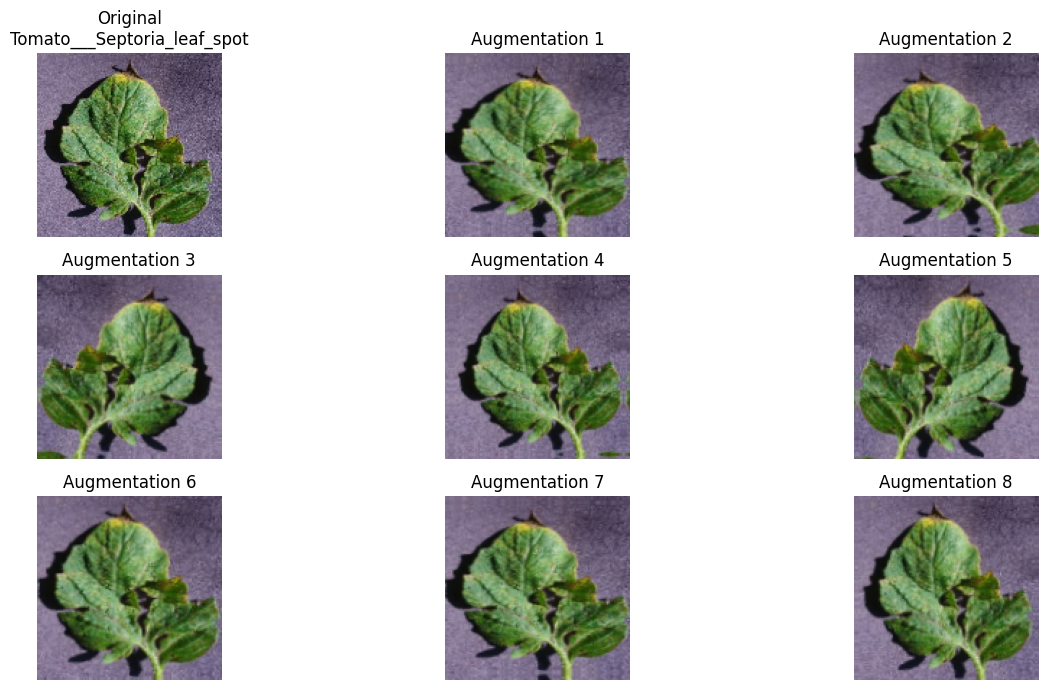


PROTOCOLO FINAL DE PREPROCESAMIENTO

TRAIN
  Resize 128x128           : ✅
  Normalización [0,1]      : ✅
  Data Augmentation        : ✅

VALIDATION
  Resize 128x128           : ✅
  Normalización [0,1]      : ✅
  Data Augmentation        : ❌

TEST
  Resize 128x128           : ✅
  Normalización [0,1]      : ✅
  Data Augmentation        : ❌

FASE 7 FINALIZADA CORRECTAMENTE

Resolución       : 128 × 128 × 3
Batch size       : 32
Clases           : 10
Train            : 12,702
Validation       : 2,722
Test             : 2,722
Total            : 18,146

Datasets definitivos:
  train_ds_final -> Resize + Normalización + Augmentation
  val_ds_final   -> Resize + Normalización
  test_ds_final  -> Resize + Normalización

✅ No se modificaron las imágenes originales.
✅ Resize aplicado realmente durante la carga.
✅ Normalización aplicada a las tres particiones.
✅ Data Augmentation aplicado exclusivamente a Train.
✅ Validation y Test permanecen sin transformaciones aleatorias.
✅ Pipeline preparado 

In [86]:
# ============================================================
# FASE 7 — PREPROCESAMIENTO COMPLETO
# ============================================================
#
# PIPELINE:
#
# TRAIN
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#          -> Data Augmentation
#
# VALIDATION
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#
# TEST
#   Imagen -> Resize 128x128 -> Normalización [0,1]
#
# OBJETIVOS:
# 1. Cargar físicamente Train / Validation / Test.
# 2. Redimensionar las imágenes a 128 x 128 RGB.
# 3. Normalizar los píxeles desde [0,255] hacia [0,1].
# 4. Aplicar Data Augmentation SOLO a Train.
# 5. Verificar automáticamente dimensiones y rangos.
# 6. Dejar datasets definitivos para MLP y CNN.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

# Configura semillas de Python, NumPy y TensorFlow.
tf.keras.utils.set_random_seed(SEED)


# ============================================================
# 3. HIPERPARÁMETROS DEL PREPROCESAMIENTO
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

IMAGE_SIZE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH
)

BATCH_SIZE = 32

AUTOTUNE = tf.data.AUTOTUNE


# ============================================================
# 4. RUTAS DEL DATASET
# ============================================================

DATASET_SPLIT_DIR = Path(
    "/content/plantvillage/dataset_split"
)

TRAIN_DIR = (
    DATASET_SPLIT_DIR
    / "train"
)

VALIDATION_DIR = (
    DATASET_SPLIT_DIR
    / "validation"
)

TEST_DIR = (
    DATASET_SPLIT_DIR
    / "test"
)


directorios = {
    "Train": TRAIN_DIR,
    "Validation": VALIDATION_DIR,
    "Test": TEST_DIR
}


# ============================================================
# 5. VERIFICAR EXISTENCIA DE DIRECTORIOS
# ============================================================

print("=" * 90)
print("FASE 7 — PREPROCESAMIENTO")
print("=" * 90)


for nombre, ruta in directorios.items():

    if not ruta.exists():

        raise FileNotFoundError(
            f"No se encontró el directorio {nombre}:\n"
            f"{ruta}\n\n"
            "Ejecute previamente la Fase 6 y la creación "
            "física de dataset_split."
        )

    print(
        f"✅ {nombre:<11}: {ruta}"
    )


# ============================================================
# 6. VERIFICAR CANTIDAD DE IMÁGENES FÍSICAS
# ============================================================

EXTENSIONES_IMAGEN = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
}


def contar_imagenes(directorio):
    """
    Cuenta recursivamente los archivos de imagen existentes
    dentro de un directorio.
    """

    return sum(
        1
        for archivo in directorio.rglob("*")
        if (
            archivo.is_file()
            and
            archivo.suffix.lower()
            in EXTENSIONES_IMAGEN
        )
    )


n_train = contar_imagenes(
    TRAIN_DIR
)

n_val = contar_imagenes(
    VALIDATION_DIR
)

n_test = contar_imagenes(
    TEST_DIR
)

n_total = (
    n_train
    +
    n_val
    +
    n_test
)


print("\n" + "=" * 90)
print("CANTIDAD DE IMÁGENES")
print("=" * 90)

print(
    f"Train      : {n_train:,}"
)

print(
    f"Validation : {n_val:,}"
)

print(
    f"Test       : {n_test:,}"
)

print(
    f"TOTAL      : {n_total:,}"
)


# ============================================================
# 7. CONTROLES SOBRE EL DATASET ACTUAL
# ============================================================
#
# De acuerdo con la Fase 6:
#
# Train      = 12.702
# Validation =  2.722
# Test       =  2.722
# Total      = 18.146
# ============================================================

EXPECTED_COUNTS = {
    "Train": 12702,
    "Validation": 2722,
    "Test": 2722,
    "Total": 18146
}


assert n_train == EXPECTED_COUNTS["Train"], (
    f"Train contiene {n_train:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Train']:,}."
)

assert n_val == EXPECTED_COUNTS["Validation"], (
    f"Validation contiene {n_val:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Validation']:,}."
)

assert n_test == EXPECTED_COUNTS["Test"], (
    f"Test contiene {n_test:,} imágenes; "
    f"se esperaban {EXPECTED_COUNTS['Test']:,}."
)

assert n_total == EXPECTED_COUNTS["Total"], (
    f"Total encontrado: {n_total:,}; "
    f"se esperaban {EXPECTED_COUNTS['Total']:,}."
)


print(
    "\n✅ Las cantidades coinciden con la partición "
    "definida en la Fase 6."
)


# ============================================================
# 8. CARGAR DATASETS + REALIZAR RESIZE
# ============================================================
#
# image_dataset_from_directory realiza dinámicamente:
#
#       imagen original
#              ↓
#       Resize 128 x 128
#
# No modifica los archivos físicos.
#
# label_mode="int":
# genera etiquetas enteras apropiadas posteriormente para
# SparseCategoricalCrossentropy.
# ============================================================


# ----------------------------
# TRAIN
# ----------------------------

train_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        TRAIN_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=True,

        seed=SEED,

        interpolation="bilinear"
    )
)


# ----------------------------
# VALIDATION
# ----------------------------

val_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        VALIDATION_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=False,

        interpolation="bilinear"
    )
)


# ----------------------------
# TEST
# ----------------------------

test_ds_raw = (
    tf.keras.utils.image_dataset_from_directory(
        TEST_DIR,

        labels="inferred",

        label_mode="int",

        color_mode="rgb",

        image_size=IMAGE_SIZE,

        batch_size=BATCH_SIZE,

        shuffle=False,

        interpolation="bilinear"
    )
)


# ============================================================
# 9. VERIFICAR CLASES
# ============================================================

class_names = (
    train_ds_raw.class_names
)

val_class_names = (
    val_ds_raw.class_names
)

test_class_names = (
    test_ds_raw.class_names
)


assert class_names == val_class_names, (
    "Las clases de Train y Validation no coinciden."
)

assert class_names == test_class_names, (
    "Las clases de Train y Test no coinciden."
)


NUM_CLASSES = len(
    class_names
)


assert NUM_CLASSES == 10, (
    f"Se detectaron {NUM_CLASSES} clases; "
    "se esperaban 10."
)


print("\n" + "=" * 90)
print("CLASES DETECTADAS")
print("=" * 90)

print(
    f"\nNúmero de clases: {NUM_CLASSES}"
)


for indice, clase in enumerate(
    class_names
):

    print(
        f"{indice:2d} -> {clase}"
    )


# ============================================================
# 10. VERIFICAR RESIZE REAL
# ============================================================

for imagenes_raw, etiquetas_raw in train_ds_raw.take(1):

    forma_raw = imagenes_raw.shape

    minimo_raw = float(
        tf.reduce_min(
            imagenes_raw
        ).numpy()
    )

    maximo_raw = float(
        tf.reduce_max(
            imagenes_raw
        ).numpy()
    )


assert forma_raw[1:] == (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
), (
    "El Resize no produjo la dimensión esperada."
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DEL RESIZE")
print("=" * 90)

print(
    f"\nForma del batch: {forma_raw}"
)

print(
    f"Resolución final: "
    f"{forma_raw[1]} × "
    f"{forma_raw[2]} × "
    f"{forma_raw[3]}"
)

print(
    "\n✅ Resize aplicado realmente durante la carga."
)


# ============================================================
# 11. NORMALIZACIÓN
# ============================================================
#
# Transformación:
#
#                    x
#             x' = -----
#                   255
#
# [0,255] -> [0,1]
#
# Se aplica EXACTAMENTE igual a:
#
# - Train
# - Validation
# - Test
#
# No existe fuga de información porque el factor 255 no se
# estima a partir de ninguna partición.
# ============================================================

normalization_layer = (
    tf.keras.layers.Rescaling(
        scale=1.0 / 255.0
    )
)


def normalizar_imagenes(
    imagenes,
    etiquetas
):
    """
    Normaliza los valores de los píxeles al intervalo [0,1]
    manteniendo las etiquetas sin modificaciones.
    """

    imagenes = normalization_layer(
        imagenes
    )

    return (
        imagenes,
        etiquetas
    )


# ============================================================
# 12. CREAR DATASETS NORMALIZADOS
# ============================================================

train_ds_norm = train_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)

val_ds_norm = val_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)

test_ds_norm = test_ds_raw.map(
    normalizar_imagenes,
    num_parallel_calls=AUTOTUNE
)


print("\n" + "=" * 90)
print("NORMALIZACIÓN")
print("=" * 90)

print(
    "\n✅ train_ds_norm creado."
)

print(
    "✅ val_ds_norm creado."
)

print(
    "✅ test_ds_norm creado."
)


# ============================================================
# 13. VERIFICAR NORMALIZACIÓN EN LAS TRES PARTICIONES
# ============================================================

datasets_normalizados = {
    "Train": train_ds_norm,
    "Validation": val_ds_norm,
    "Test": test_ds_norm
}


for nombre, dataset in datasets_normalizados.items():

    for imagenes, etiquetas in dataset.take(1):

        minimo = float(
            tf.reduce_min(
                imagenes
            ).numpy()
        )

        maximo = float(
            tf.reduce_max(
                imagenes
            ).numpy()
        )

        forma = imagenes.shape

        break


    assert minimo >= 0.0, (
        f"{nombre}: existen valores menores que 0."
    )

    assert maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que 1."
    )


    print(
        f"\n{nombre:<11} | "
        f"Shape: {str(forma):<22} | "
        f"Min: {minimo:.6f} | "
        f"Max: {maximo:.6f}"
    )


print(
    "\n✅ Normalización [0,1] verificada "
    "en Train, Validation y Test."
)


# ============================================================
# 14. DEFINIR DATA AUGMENTATION
# ============================================================
#
# IMPORTANTE:
#
# Estas transformaciones serán utilizadas EXCLUSIVAMENTE
# sobre Train.
#
# RandomFlip:
# reflexión horizontal.
#
# RandomRotation:
# factor=0.05 -> aproximadamente ±18 grados.
#
# RandomZoom:
# variación moderada de aproximadamente 10%.
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        ),

        tf.keras.layers.RandomRotation(
            factor=0.05,
            fill_mode="reflect",
            seed=SEED
        ),

        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10,
            fill_mode="reflect",
            seed=SEED
        )
    ],
    name="data_augmentation"
)


# ============================================================
# 15. FUNCIÓN PARA DATA AUGMENTATION
# ============================================================

def aplicar_data_augmentation(
    imagenes,
    etiquetas
):
    """
    Aplica transformaciones aleatorias únicamente a las
    imágenes de entrenamiento.

    Las etiquetas permanecen sin cambios.
    """

    imagenes_aumentadas = (
        data_augmentation(
            imagenes,
            training=True
        )
    )

    return (
        imagenes_aumentadas,
        etiquetas
    )


# ============================================================
# 16. APLICAR AUGMENTATION SOLO A TRAIN
# ============================================================
#
# TRAIN:
#
# train_ds_norm
#       ↓
# Data Augmentation
#       ↓
# train_ds_final
#
#
# VALIDATION y TEST:
#
# NO pasan por data_augmentation.
# ============================================================

train_ds_final = train_ds_norm.map(
    aplicar_data_augmentation,
    num_parallel_calls=AUTOTUNE
)


# Sin transformaciones aleatorias.
val_ds_final = val_ds_norm

test_ds_final = test_ds_norm


# ============================================================
# 17. VERIFICAR QUE LAS ETIQUETAS NO CAMBIEN
# ============================================================

for imagenes, etiquetas in train_ds_norm.take(1):

    imagenes_aug_test, etiquetas_aug_test = (
        aplicar_data_augmentation(
            imagenes,
            etiquetas
        )
    )

    etiquetas_iguales = bool(
        tf.reduce_all(
            tf.equal(
                etiquetas,
                etiquetas_aug_test
            )
        ).numpy()
    )

    break


assert etiquetas_iguales, (
    "Las etiquetas fueron modificadas durante "
    "Data Augmentation."
)


print(
    "\n✅ Data Augmentation no modifica las etiquetas."
)


# ============================================================
# 18. VERIFICAR RANGO DESPUÉS DEL AUGMENTATION
# ============================================================

minimo_aug = float(
    tf.reduce_min(
        imagenes_aug_test
    ).numpy()
)

maximo_aug = float(
    tf.reduce_max(
        imagenes_aug_test
    ).numpy()
)


assert minimo_aug >= 0.0, (
    "Data Augmentation generó valores menores que 0."
)

assert maximo_aug <= 1.0 + 1e-6, (
    "Data Augmentation generó valores mayores que 1."
)


print(
    f"✅ Rango después de augmentation: "
    f"[{minimo_aug:.6f}, {maximo_aug:.6f}]"
)


# ============================================================
# 19. OPTIMIZAR PIPELINES PARA GOOGLE COLAB
# ============================================================
#
# prefetch permite preparar el siguiente batch mientras
# CPU/GPU procesa el actual.
#
# No se utiliza cache() en RAM para evitar un consumo de
# memoria innecesariamente elevado.
# ============================================================

train_ds_final = train_ds_final.prefetch(
    AUTOTUNE
)

val_ds_final = val_ds_final.prefetch(
    AUTOTUNE
)

test_ds_final = test_ds_final.prefetch(
    AUTOTUNE
)


# ============================================================
# 20. VERIFICAR ESTABILIDAD DE VALIDATION Y TEST
# ============================================================
#
# Como:
#
# - shuffle=False
# - no existe augmentation
#
# dos lecturas sucesivas del primer batch deben producir
# exactamente los mismos valores.
# ============================================================

val_1, val_y_1 = next(
    iter(
        val_ds_final
    )
)

val_2, val_y_2 = next(
    iter(
        val_ds_final
    )
)


test_1, test_y_1 = next(
    iter(
        test_ds_final
    )
)

test_2, test_y_2 = next(
    iter(
        test_ds_final
    )
)


val_estable = bool(
    tf.reduce_all(
        tf.equal(
            val_1,
            val_2
        )
    ).numpy()
)


test_estable = bool(
    tf.reduce_all(
        tf.equal(
            test_1,
            test_2
        )
    ).numpy()
)


assert val_estable, (
    "Validation presenta transformaciones variables."
)

assert test_estable, (
    "Test presenta transformaciones variables."
)


print(
    "✅ Validation permanece estable y sin augmentation."
)

print(
    "✅ Test permanece estable y sin augmentation."
)


# ============================================================
# 21. VISUALIZACIÓN DEL DATA AUGMENTATION
# ============================================================
#
# Se visualiza una imagen normalizada y ocho transformaciones
# aleatorias para comprobar que las variaciones sean moderadas.
# ============================================================

for imagenes_originales, etiquetas_originales in train_ds_norm.take(1):

    imagen_original = (
        imagenes_originales[0]
    )

    etiqueta_original = int(
        etiquetas_originales[0].numpy()
    )

    break


N_VARIANTES = 8


plt.figure(
    figsize=(14, 7)
)


# ----------------------------
# Imagen original
# ----------------------------

plt.subplot(
    3,
    3,
    1
)

plt.imshow(
    imagen_original
)

plt.title(
    "Original\n"
    f"{class_names[etiqueta_original]}"
)

plt.axis(
    "off"
)


# ----------------------------
# Imágenes aumentadas
# ----------------------------

for i in range(
    N_VARIANTES
):

    imagen_batch = tf.expand_dims(
        imagen_original,
        axis=0
    )


    imagen_aumentada = (
        data_augmentation(
            imagen_batch,
            training=True
        )[0]
    )


    imagen_aumentada = tf.clip_by_value(
        imagen_aumentada,
        0.0,
        1.0
    )


    plt.subplot(
        3,
        3,
        i + 2
    )

    plt.imshow(
        imagen_aumentada
    )

    plt.title(
        f"Augmentation {i + 1}"
    )

    plt.axis(
        "off"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 22. PROTOCOLO FINAL
# ============================================================

protocolo = {
    "Train": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": True
    },

    "Validation": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": False
    },

    "Test": {
        "Resize 128x128": True,
        "Normalización [0,1]": True,
        "Data Augmentation": False
    }
}


print("\n" + "=" * 90)
print("PROTOCOLO FINAL DE PREPROCESAMIENTO")
print("=" * 90)


for particion, operaciones in protocolo.items():

    print(
        f"\n{particion.upper()}"
    )

    for operacion, aplicada in operaciones.items():

        estado = (
            "✅"
            if aplicada
            else "❌"
        )

        print(
            f"  {operacion:<25}: {estado}"
        )


# ============================================================
# 23. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 7 FINALIZADA CORRECTAMENTE")
print("=" * 90)

print(
    f"\nResolución       : "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}"
)

print(
    f"Batch size       : {BATCH_SIZE}"
)

print(
    f"Clases           : {NUM_CLASSES}"
)

print(
    f"Train            : {n_train:,}"
)

print(
    f"Validation       : {n_val:,}"
)

print(
    f"Test             : {n_test:,}"
)

print(
    f"Total            : {n_total:,}"
)


print(
    "\nDatasets definitivos:"
)

print(
    "  train_ds_final -> Resize + Normalización + Augmentation"
)

print(
    "  val_ds_final   -> Resize + Normalización"
)

print(
    "  test_ds_final  -> Resize + Normalización"
)


print(
    "\n✅ No se modificaron las imágenes originales."
)

print(
    "✅ Resize aplicado realmente durante la carga."
)

print(
    "✅ Normalización aplicada a las tres particiones."
)

print(
    "✅ Data Augmentation aplicado exclusivamente a Train."
)

print(
    "✅ Validation y Test permanecen sin "
    "transformaciones aleatorias."
)

print(
    "✅ Pipeline preparado para MLP y CNN."
)

### 7.4 Determinación y demostración de las transformaciones de Data Augmentation

El **Data Augmentation** permite introducir variabilidad controlada en el conjunto
de entrenamiento mediante transformaciones aleatorias de las imágenes originales.

En este proyecto se analizarán tres transformaciones:

- `RandomFlip`
- `RandomRotation`
- `RandomZoom`

Estas operaciones se aplicarán exclusivamente sobre imágenes pertenecientes al
conjunto de entrenamiento:

$$
\boxed{
\mathcal{D}_{train}
}
$$

Validation y Test permanecerán sin modificaciones aleatorias.

---

### 1. RandomFlip

`RandomFlip` genera una reflexión de la imagen.

En este proyecto se utilizará reflexión horizontal:

$$
X_{\text{flip}}
=
T_{\text{flip}}(X)
$$

Conceptualmente, para una imagen con ancho $W$:

$$
X_{\text{flip}}(i,j,c)
=
X(i,W-1-j,c)
$$

donde:

- $i$ representa la posición vertical;
- $j$ representa la posición horizontal;
- $c$ corresponde al canal RGB.

Esta transformación es razonable para imágenes de hojas, porque invertir
horizontalmente la orientación de una hoja no modifica la enfermedad que
representa.

---

### 2. RandomRotation

`RandomRotation` introduce pequeñas variaciones angulares.

Se utilizará:

$$
factor=0.05
$$

Keras interpreta este valor como una fracción de una vuelta completa. Por tanto:

$$
\theta_{\max}
=
0.05\times360^\circ
=
18^\circ
$$

La transformación se encuentra aproximadamente dentro de:

$$
\boxed{
-18^\circ
\leq
\theta
\leq
18^\circ
}
$$

y puede expresarse conceptualmente como:

$$
X_{\text{rot}}
=
T_{\theta}(X)
$$

Esta transformación permite disminuir la dependencia del modelo respecto de la
orientación exacta de la hoja.

---

### 3. RandomZoom

`RandomZoom` modifica moderadamente la escala aparente de la imagen.

Se utilizará un intervalo de aproximadamente $\pm10\%$:

$$
z\in[-0.10,0.10]
$$

de manera que puedan generarse pequeñas variaciones de acercamiento o
alejamiento:

$$
X_{\text{zoom}}
=
T_z(X)
$$

El objetivo es evitar que el modelo aprenda que una enfermedad está asociada a
un tamaño o encuadre específico de la hoja.

---

### Transformación combinada

Durante el entrenamiento, las transformaciones pueden combinarse:

$$
X_{\text{aug}}
=
T_{\text{zoom}}
\left(
T_{\text{rotation}}
\left(
T_{\text{flip}}(X)
\right)
\right)
$$

Por tanto:

$$
\boxed{
X
\rightarrow
RandomFlip
\rightarrow
RandomRotation
\rightarrow
RandomZoom
\rightarrow
X_{\text{aug}}
}
$$

Las transformaciones son aleatorias, por lo que una misma imagen puede generar
variantes diferentes en distintas iteraciones:

$$
T_1(X)
\neq
T_2(X)
\neq
T_3(X)
$$

Sin embargo, la etiqueta debe permanecer inalterada:

$$
\boxed{
y_{\text{aug}} = y
}
$$

El propósito no es crear nuevas clases, sino aumentar la diversidad visual de
los ejemplos disponibles durante el entrenamiento.

---

### Criterio de selección

Las transformaciones elegidas son deliberadamente moderadas.

Se evita aplicar modificaciones excesivas que puedan alterar características
relevantes de las enfermedades, como:

- manchas;
- lesiones;
- patrones de color;
- textura;
- distribución espacial de los síntomas.

La transformación debe modificar la apariencia de la imagen sin modificar su
significado semántico.

Por tanto, el conjunto seleccionado para los experimentos será:

$$
\boxed{
\text{RandomFlip}
+
\text{RandomRotation}
+
\text{RandomZoom}
}
$$

aplicado exclusivamente a:

$$
\boxed{
Train
}
$$

FASE 7.4 — DEMOSTRACIÓN DE DATA AUGMENTATION

✅ Se utilizará exclusivamente train_ds_norm.
✅ Validation y Test no participan en esta demostración.

TRANSFORMACIONES SELECCIONADAS

1. RandomFlip     -> horizontal
2. RandomRotation -> aproximadamente ±18°
3. RandomZoom     -> variaciones moderadas ±10%

IMAGEN UTILIZADA PARA LA DEMOSTRACIÓN

Shape     : (128, 128, 3)
Valor min : 0.000000
Valor max : 0.811765

✅ Imagen correctamente redimensionada y normalizada.

CONTROL NUMÉRICO DE LAS TRANSFORMACIONES

Original        | Min: 0.000000 | Max: 0.811765 | Shape: (128, 128, 3)

RandomFlip      | Min: 0.000000 | Max: 0.811765 | Shape: (128, 128, 3)

RandomRotation  | Min: 0.000981 | Max: 0.763471 | Shape: (128, 128, 3)

RandomZoom      | Min: 0.000970 | Max: 0.749783 | Shape: (128, 128, 3)

Combinada       | Min: 0.009835 | Max: 0.740751 | Shape: (128, 128, 3)

✅ Todas las transformaciones conservan el rango [0,1].


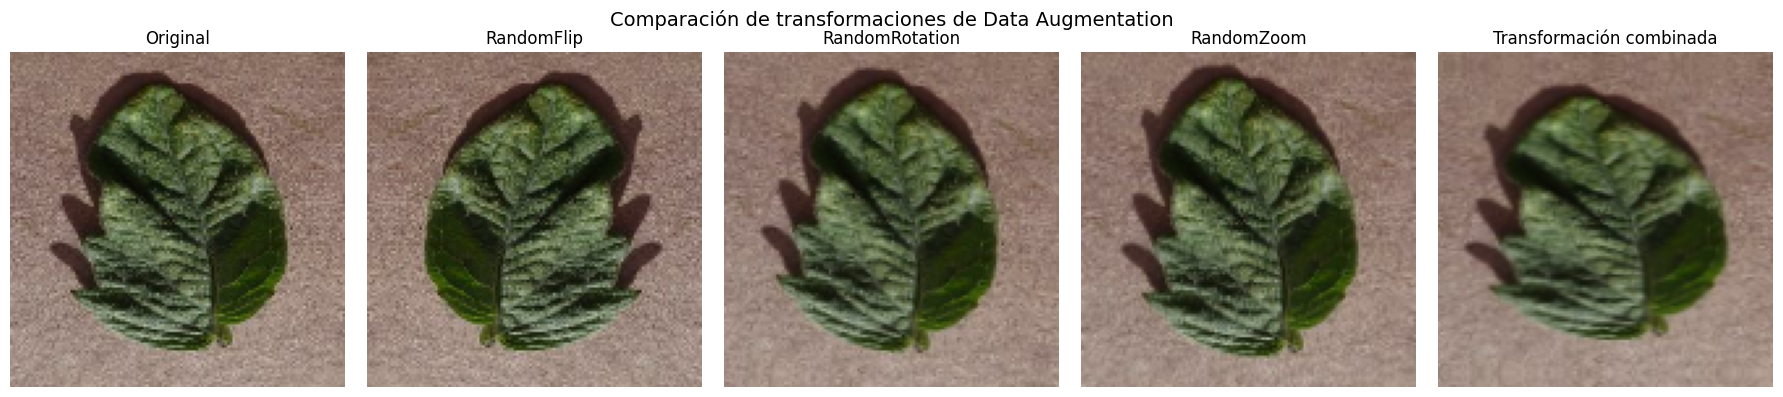

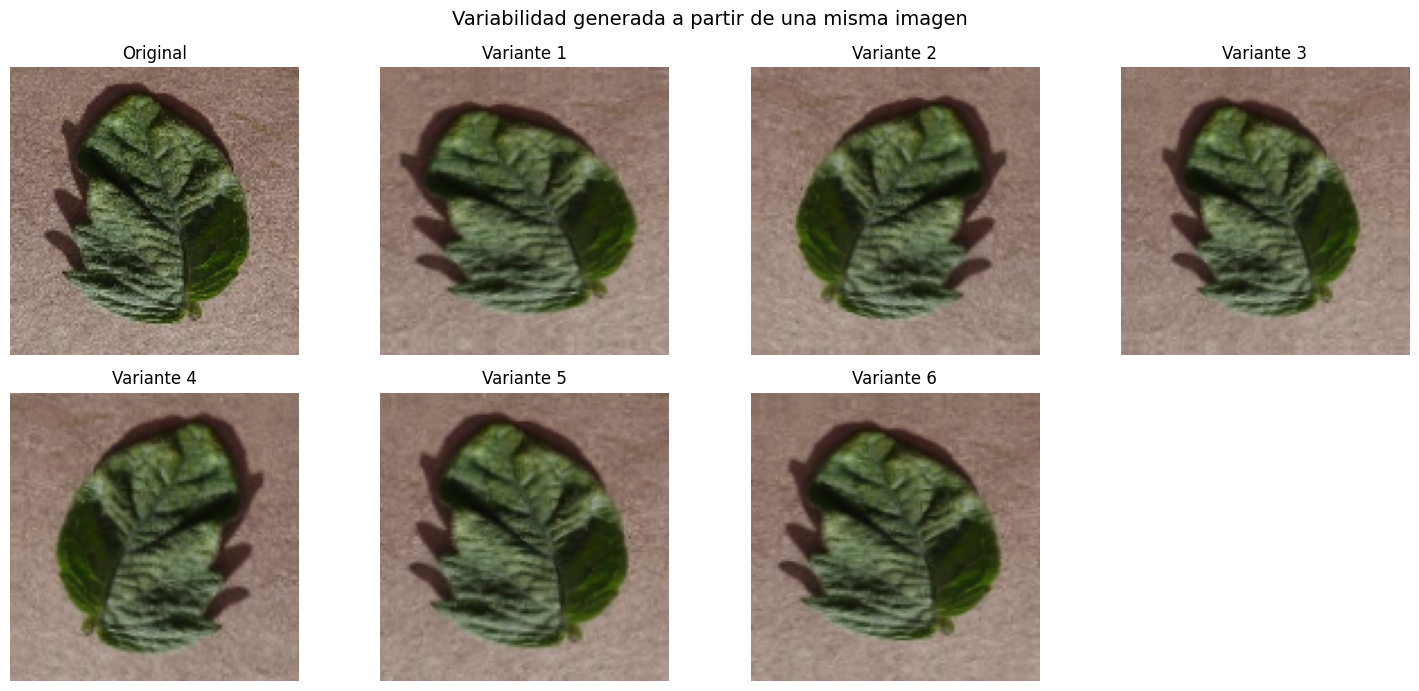


VERIFICACIÓN DE LA ETIQUETA

Etiqueta original : 5
Etiqueta después  : 5

✅ Data Augmentation modifica la imagen, pero no modifica su clase.

CONCLUSIÓN DE LA DEMOSTRACIÓN

✅ RandomFlip verificado visualmente.
✅ RandomRotation verificado visualmente.
✅ RandomZoom verificado visualmente.
✅ Se comprobó la combinación de las tres transformaciones.
✅ Las imágenes permanecen en [0,1].
✅ La resolución permanece en 128x128x3.
✅ La etiqueta permanece inalterada.
✅ La demostración utiliza únicamente Train.
✅ Validation y Test no reciben transformaciones aleatorias.


In [87]:
# ============================================================
# FASE 7
# 7.4 DETERMINACIÓN Y DEMOSTRACIÓN DEL DATA AUGMENTATION
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar individualmente el efecto de:
#
#   1. RandomFlip
#   2. RandomRotation
#   3. RandomZoom
#
# y posteriormente mostrar su aplicación combinada.
#
# IMPORTANTE:
# - Se utiliza EXCLUSIVAMENTE train_ds_norm.
# - Validation y Test NO intervienen.
# - Las imágenes ya deben estar:
#
#       128 x 128 x 3
#       valores en [0,1]
#
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR QUE EXISTA TRAIN NORMALIZADO
# ============================================================

if "train_ds_norm" not in globals():

    raise NameError(
        "No existe 'train_ds_norm'.\n"
        "Ejecute previamente la etapa de Resize y "
        "Normalización de la Fase 7."
    )


print("=" * 90)
print("FASE 7.4 — DEMOSTRACIÓN DE DATA AUGMENTATION")
print("=" * 90)

print(
    "\n✅ Se utilizará exclusivamente train_ds_norm."
)

print(
    "✅ Validation y Test no participan en esta demostración."
)


# ============================================================
# 4. DEFINIR TRANSFORMACIONES INDIVIDUALES
# ============================================================


# ------------------------------------------------------------
# RANDOM FLIP
# ------------------------------------------------------------
#
# Reflexión horizontal aleatoria.
# ------------------------------------------------------------

random_flip = tf.keras.layers.RandomFlip(
    mode="horizontal",
    seed=SEED
)


# ------------------------------------------------------------
# RANDOM ROTATION
# ------------------------------------------------------------
#
# factor = 0.05
#
# Aproximadamente:
#
#       ± 0.05 × 360°
#       ± 18°
#
# fill_mode="reflect" evita introducir grandes zonas negras
# en los bordes generados por la rotación.
# ------------------------------------------------------------

random_rotation = tf.keras.layers.RandomRotation(
    factor=0.05,
    fill_mode="reflect",
    seed=SEED
)


# ------------------------------------------------------------
# RANDOM ZOOM
# ------------------------------------------------------------
#
# Se permiten pequeñas variaciones en ambos sentidos.
#
# (-0.10, 0.10)
#
# produce variaciones moderadas de escala.
# ------------------------------------------------------------

random_zoom = tf.keras.layers.RandomZoom(
    height_factor=(-0.10, 0.10),
    width_factor=(-0.10, 0.10),
    fill_mode="reflect",
    seed=SEED
)


# ============================================================
# 5. PIPELINE COMBINADO
# ============================================================

data_augmentation_demo = tf.keras.Sequential(
    [
        random_flip,
        random_rotation,
        random_zoom
    ],
    name="data_augmentation_demo"
)


print("\n" + "=" * 90)
print("TRANSFORMACIONES SELECCIONADAS")
print("=" * 90)

print(
    "\n1. RandomFlip     -> horizontal"
)

print(
    "2. RandomRotation -> aproximadamente ±18°"
)

print(
    "3. RandomZoom     -> variaciones moderadas ±10%"
)


# ============================================================
# 6. EXTRAER UNA IMAGEN REAL DE TRAIN
# ============================================================

for imagenes_batch, etiquetas_batch in train_ds_norm.take(1):

    imagen_original = imagenes_batch[0]

    etiqueta_original = etiquetas_batch[0]

    break


# ============================================================
# 7. VERIFICAR LA IMAGEN DE ENTRADA
# ============================================================

shape_original = imagen_original.shape

min_original = float(
    tf.reduce_min(
        imagen_original
    ).numpy()
)

max_original = float(
    tf.reduce_max(
        imagen_original
    ).numpy()
)


print("\n" + "=" * 90)
print("IMAGEN UTILIZADA PARA LA DEMOSTRACIÓN")
print("=" * 90)

print(
    f"\nShape     : {shape_original}"
)

print(
    f"Valor min : {min_original:.6f}"
)

print(
    f"Valor max : {max_original:.6f}"
)


assert shape_original == (
    128,
    128,
    3
), (
    "La imagen no tiene resolución 128x128x3."
)


assert min_original >= 0.0

assert max_original <= 1.0 + 1e-6


print(
    "\n✅ Imagen correctamente redimensionada y normalizada."
)


# ============================================================
# 8. PREPARAR DIMENSIÓN BATCH
# ============================================================
#
# Las capas Keras esperan:
#
# (batch, alto, ancho, canales)
#
# Por tanto:
#
# (128,128,3)
#
# se transforma temporalmente en:
#
# (1,128,128,3)
# ============================================================

imagen_batch = tf.expand_dims(
    imagen_original,
    axis=0
)


# ============================================================
# 9. APLICAR CADA TRANSFORMACIÓN POR SEPARADO
# ============================================================

imagen_flip = random_flip(
    imagen_batch,
    training=True
)[0]


imagen_rotation = random_rotation(
    imagen_batch,
    training=True
)[0]


imagen_zoom = random_zoom(
    imagen_batch,
    training=True
)[0]


imagen_combinada = data_augmentation_demo(
    imagen_batch,
    training=True
)[0]


# ============================================================
# 10. CONTROL DEL INTERVALO [0,1]
# ============================================================

transformaciones = {
    "Original": imagen_original,
    "RandomFlip": imagen_flip,
    "RandomRotation": imagen_rotation,
    "RandomZoom": imagen_zoom,
    "Combinada": imagen_combinada
}


print("\n" + "=" * 90)
print("CONTROL NUMÉRICO DE LAS TRANSFORMACIONES")
print("=" * 90)


for nombre, imagen in transformaciones.items():

    minimo = float(
        tf.reduce_min(
            imagen
        ).numpy()
    )

    maximo = float(
        tf.reduce_max(
            imagen
        ).numpy()
    )

    print(
        f"\n{nombre:<15}"
        f" | Min: {minimo:.6f}"
        f" | Max: {maximo:.6f}"
        f" | Shape: {imagen.shape}"
    )


    assert minimo >= 0.0, (
        f"{nombre}: existen valores menores que 0."
    )

    assert maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que 1."
    )


print(
    "\n✅ Todas las transformaciones conservan "
    "el rango [0,1]."
)


# ============================================================
# 11. VISUALIZACIÓN COMPARATIVA
# ============================================================

plt.figure(
    figsize=(18, 4)
)


titulos = [
    "Original",
    "RandomFlip",
    "RandomRotation",
    "RandomZoom",
    "Transformación combinada"
]


imagenes_mostrar = [
    imagen_original,
    imagen_flip,
    imagen_rotation,
    imagen_zoom,
    imagen_combinada
]


for i, (
    titulo,
    imagen
) in enumerate(
    zip(
        titulos,
        imagenes_mostrar
    )
):

    plt.subplot(
        1,
        5,
        i + 1
    )

    plt.imshow(
        tf.clip_by_value(
            imagen,
            0.0,
            1.0
        )
    )

    plt.title(
        titulo
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Comparación de transformaciones de Data Augmentation",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 12. DEMOSTRAR EL CARÁCTER ALEATORIO
# ============================================================
#
# Se aplica varias veces el pipeline completo a exactamente
# la misma imagen.
#
# El resultado debería mostrar variantes diferentes.
# ============================================================

N_VARIANTES = 6


plt.figure(
    figsize=(15, 7)
)


# ------------------------------------------------------------
# Imagen original
# ------------------------------------------------------------

plt.subplot(
    2,
    4,
    1
)

plt.imshow(
    imagen_original
)

plt.title(
    "Original"
)

plt.axis(
    "off"
)


# ------------------------------------------------------------
# Variantes aleatorias
# ------------------------------------------------------------

for i in range(
    N_VARIANTES
):

    variante = data_augmentation_demo(
        imagen_batch,
        training=True
    )[0]


    variante = tf.clip_by_value(
        variante,
        0.0,
        1.0
    )


    plt.subplot(
        2,
        4,
        i + 2
    )

    plt.imshow(
        variante
    )

    plt.title(
        f"Variante {i + 1}"
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Variabilidad generada a partir de una misma imagen",
    fontsize=14
)

plt.tight_layout()

plt.show()


# ============================================================
# 13. DEMOSTRAR QUE LA ETIQUETA NO CAMBIA
# ============================================================

etiqueta_antes = int(
    etiqueta_original.numpy()
)

etiqueta_despues = etiqueta_antes


assert (
    etiqueta_antes
    ==
    etiqueta_despues
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE LA ETIQUETA")
print("=" * 90)

print(
    f"\nEtiqueta original : {etiqueta_antes}"
)

print(
    f"Etiqueta después  : {etiqueta_despues}"
)

print(
    "\n✅ Data Augmentation modifica la imagen, "
    "pero no modifica su clase."
)


# ============================================================
# 14. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN DE LA DEMOSTRACIÓN")
print("=" * 90)

print(
    "\n✅ RandomFlip verificado visualmente."
)

print(
    "✅ RandomRotation verificado visualmente."
)

print(
    "✅ RandomZoom verificado visualmente."
)

print(
    "✅ Se comprobó la combinación de las "
    "tres transformaciones."
)

print(
    "✅ Las imágenes permanecen en [0,1]."
)

print(
    "✅ La resolución permanece en 128x128x3."
)

print(
    "✅ La etiqueta permanece inalterada."
)

print(
    "✅ La demostración utiliza únicamente Train."
)

print(
    "✅ Validation y Test no reciben "
    "transformaciones aleatorias."
)

# Fase 8 - Baseline
Incluir, cuando sea razonable, un modelo simple para contextualizar el aporte de Deep Learning. El
baseline no reemplaza ninguna de las dos redes obligatorias.

# Fase 8 — Baseline convencional

## 8.1 Objetivo del modelo baseline

Antes de entrenar las arquitecturas profundas MLP y CNN se construirá un modelo
convencional que permita establecer un nivel de referencia.

La comparación general del proyecto será:

$$
\boxed{
\text{Baseline}
\rightarrow
\text{MLP}
\rightarrow
\text{CNN}
}
$$

El propósito del baseline no es competir necesariamente con las redes profundas,
sino responder una pregunta metodológica fundamental:

$$
\boxed{
\text{¿Cuánto valor adicional aporta Deep Learning?}
}
$$

En este proyecto se utilizará como baseline:

$$
\boxed{
\text{HOG}
+
\text{Regresión Logística}
}
$$

Esta estrategia corresponde a un enfoque clásico de visión por computador.

A diferencia de una red neuronal profunda, que aprende automáticamente las
representaciones relevantes a partir de los píxeles, el baseline requiere una
etapa explícita de extracción de características.

El flujo será:

$$
\text{Imagen}
\rightarrow
\text{Resize}
\rightarrow
\text{Normalización}
\rightarrow
\text{HOG}
\rightarrow
\text{Regresión Logística}
\rightarrow
\hat{y}
$$

---

## 8.2 ¿Por qué utilizar HOG?

Las imágenes normalizadas provenientes de la Fase 7 tienen dimensiones:

$$
X\in[0,1]^{128\times128\times3}
$$

Si se utilizaran directamente todos los píxeles como variables para una
regresión logística, cada imagen tendría:

$$
128\times128\times3
=
49\,152
$$

características.

Esto generaría un espacio de entrada considerablemente grande para un modelo
convencional.

Por este motivo se utilizará **Histogram of Oriented Gradients (HOG)** como
método clásico de extracción de características.

HOG describe principalmente la distribución local de:

- bordes;
- contornos;
- orientaciones;
- cambios de intensidad;
- estructuras locales.

Para cada región de la imagen se calcula aproximadamente la magnitud del
gradiente:

$$
G=
\sqrt{
G_x^2+G_y^2
}
$$

y su orientación:

$$
\theta=
\operatorname{atan2}(G_y,G_x)
$$

donde:

- $G_x$ representa el cambio horizontal de intensidad;
- $G_y$ representa el cambio vertical;
- $G$ representa la magnitud del gradiente;
- $\theta$ representa su orientación.

Posteriormente, estas orientaciones se agrupan en histogramas locales,
produciendo un vector de características:

$$
\mathbf{h}
=
[h_1,h_2,\ldots,h_p]
$$

La diferencia conceptual con Deep Learning es importante:

$$
\boxed{
\text{Baseline}
\rightarrow
\text{características diseñadas manualmente}
}
$$

mientras que:

$$
\boxed{
\text{CNN}
\rightarrow
\text{características aprendidas automáticamente}
}
$$

Esta diferencia permitirá posteriormente analizar si el aprendizaje automático
de representaciones espaciales proporciona una ventaja sobre una descripción
visual convencional.

---

## 8.3 Clasificador: Regresión Logística multiclase

Una vez obtenidas las características HOG, se utilizará una regresión logística
para realizar la clasificación de las diez enfermedades o estados foliares.

Para una clase $k$, el modelo calcula un valor lineal:

$$
z_k
=
\mathbf{w}_k^\top\mathbf{h}
+
b_k
$$

La probabilidad asociada a cada clase puede expresarse mediante Softmax:

$$
P(y=k\mid\mathbf{h})
=
\frac{
e^{z_k}
}{
\displaystyle\sum_{j=1}^{K}e^{z_j}
}
$$

donde:

$$
K=10
$$

es el número de clases.

La predicción final corresponde a:

$$
\boxed{
\hat{y}
=
\arg\max_k
P(y=k\mid\mathbf{h})
}
$$

---

## 8.4 Tratamiento del desbalance de clases

El análisis exploratorio mostró que el dataset presenta desbalance entre sus
categorías.

Por esta razón se utilizará:

`class_weight="balanced"`

La ponderación asignada aproximadamente a cada clase $k$ es:

$$
w_k
=
\frac{N}{K\,N_k}
$$

donde:

- $N$ es el número total de observaciones de entrenamiento;
- $K$ es el número total de clases;
- $N_k$ es el número de observaciones pertenecientes a la clase $k$.

De esta forma, las clases minoritarias reciben un peso proporcionalmente mayor
durante el ajuste del modelo.

---

## 8.5 Protocolo experimental

El baseline respetará exactamente la división determinada previamente:

$$
\mathcal{D}_{train}
\cap
\mathcal{D}_{validation}
=
\varnothing
$$

y:

$$
\mathcal{D}_{test}
$$

permanecerá aislado.

En esta fase:

$$
\mathcal{D}_{train}
\rightarrow
\text{entrenamiento del baseline}
$$

$$
\mathcal{D}_{validation}
\rightarrow
\text{evaluación preliminar}
$$

mientras que:

$$
\boxed{
\mathcal{D}_{test}
\text{ no se utiliza todavía}
}
$$

El conjunto Test será reservado para la comparación final entre:

$$
\boxed{
\text{Baseline}
\quad
\text{vs.}
\quad
\text{MLP}
\quad
\text{vs.}
\quad
\text{CNN}
}
$$

El baseline utilizará `train_ds_norm` y `val_ds_norm`, es decir, imágenes
redimensionadas y normalizadas pero **sin Data Augmentation aleatorio**.

Esto permite mantener un modelo convencional determinista y reproducible.

---

## 8.6 Métricas de evaluación

Debido al desbalance de clases, Accuracy no será utilizada como única medida.

Se calcularán:

### Accuracy

$$
Accuracy
=
\frac{
\text{predicciones correctas}
}{
N
}
$$

### Balanced Accuracy

$$
Balanced\ Accuracy
=
\frac{1}{K}
\sum_{k=1}^{K}
Recall_k
$$

### Precision Macro

$$
Precision_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
Precision_k
$$

### Recall Macro

$$
Recall_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
Recall_k
$$

### F1 Macro

$$
F1_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}
F1_k
$$

También se analizará la matriz de confusión para identificar qué clases presentan
mayor dificultad para el modelo convencional.

El resultado de esta fase constituirá el punto de referencia para determinar
posteriormente si las arquitecturas profundas proporcionan una mejora real.

FASE 8 — BASELINE CONVENCIONAL

Modelo:
HOG + Regresión Logística

Número de clases: 10

✅ Se utilizará Train para entrenamiento.
✅ Validation para evaluación preliminar.
✅ Test permanecerá aislado.
✅ Data Augmentation NO se utilizará en el baseline.

CONFIGURACIÓN HOG
orientations        : 9
pixels_per_cell     : (16, 16)
cells_per_block     : (2, 2)
block_norm          : L2-Hys

EXTRACCIÓN DE CARACTERÍSTICAS


HOG - Train:   0%|          | 0/397 [00:00<?, ?it/s]

HOG - Validation:   0%|          | 0/86 [00:00<?, ?it/s]


DIMENSIONES HOG

X_train_hog : (12702, 1764)
y_train     : (12702,)

X_val_hog   : (2722, 1764)
y_val       : (2722,)

Características HOG por imagen: 1,764

Tiempo HOG Train      : 76.55 s
Tiempo HOG Validation : 17.53 s

ENTRENAMIENTO DEL BASELINE


Se han truncado las últimas 5000 líneas del flujo de salida.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcno


✅ Entrenamiento finalizado.
Tiempo de entrenamiento: 142.84 s

RESULTADOS DEL BASELINE — VALIDATION


,Modelo,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,Tiempo entrenamiento (s),Tiempo inferencia val (s)
0,HOG + Regresión Logística,0.6852,0.6452,0.6087,0.6452,0.6218,142.8409,0.1438



REPORTE POR CLASE


,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.7006,0.7116,0.7061,319.0000
Tomato___Early_blight,0.3143,0.3667,0.3385,150.0000
Tomato___Late_blight,0.7132,0.6456,0.6777,285.0000
Tomato___Leaf_Mold,0.5584,0.6014,0.5791,143.0000
Tomato___Septoria_leaf_spot,0.5253,0.5094,0.5172,265.0000
Tomato___Spider_mites Two-spotted_spider_mite,0.6900,0.7421,0.7151,252.0000
Tomato___Target_Spot,0.5451,0.6048,0.5734,210.0000
Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.9203,0.7898,0.8501,804.0000
Tomato___Tomato_mosaic_virus,0.3958,0.6786,0.5000,56.0000
Tomato___healthy,0.7235,0.8025,0.7610,238.0000


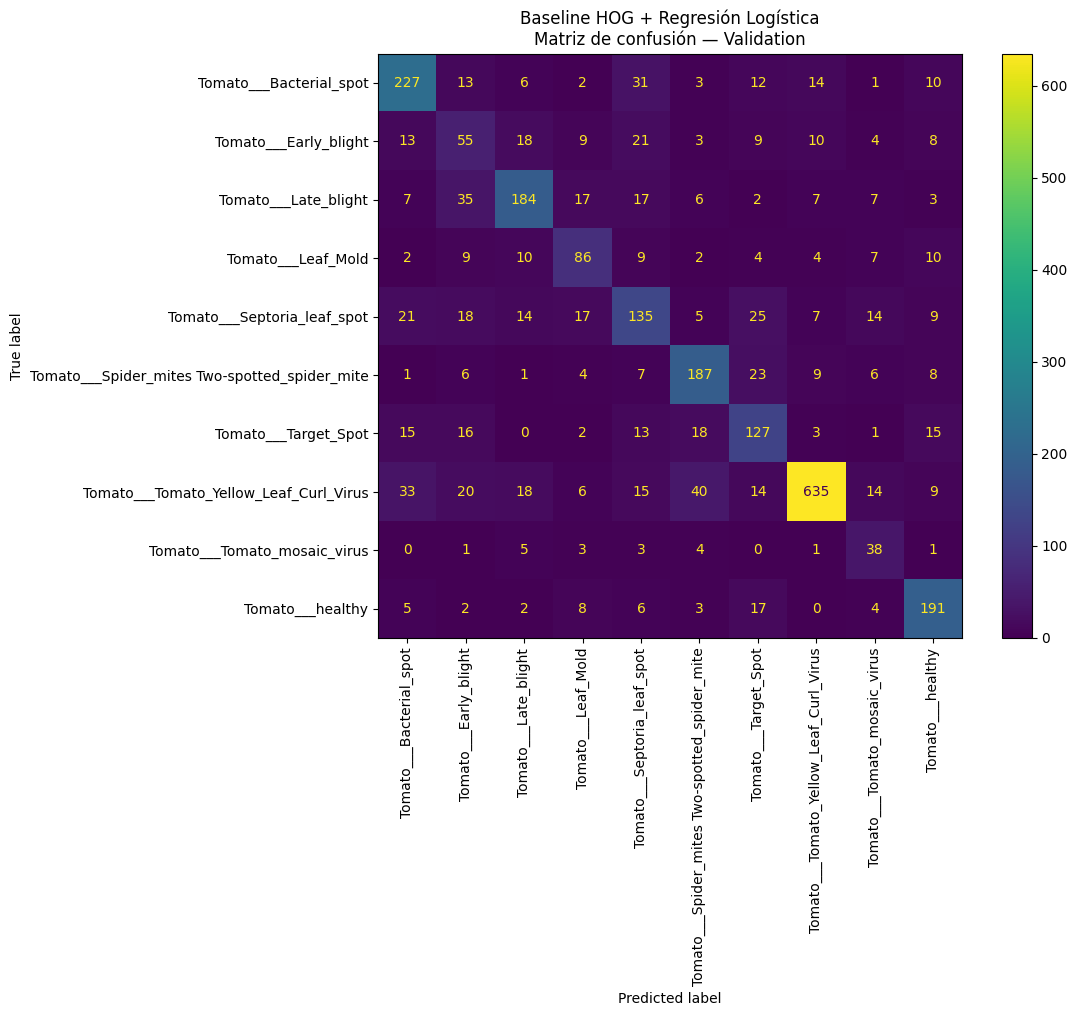


CLASES ORDENADAS POR RECALL


,Clase,Recall,Precision,F1-score,Support
0,Tomato___Early_blight,0.3667,0.3143,0.3385,150
1,Tomato___Septoria_leaf_spot,0.5094,0.5253,0.5172,265
2,Tomato___Leaf_Mold,0.6014,0.5584,0.5791,143
3,Tomato___Target_Spot,0.6048,0.5451,0.5734,210
4,Tomato___Late_blight,0.6456,0.7132,0.6777,285
5,Tomato___Tomato_mosaic_virus,0.6786,0.3958,0.5000,56
6,Tomato___Bacterial_spot,0.7116,0.7006,0.7061,319
7,Tomato___Spider_mites Two-spotted_spider_mite,0.7421,0.6900,0.7151,252
8,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.7898,0.9203,0.8501,804
9,Tomato___healthy,0.8025,0.7235,0.7610,238



MODELO GUARDADO

/content/plantvillage/modelos/baseline_hog_logistic_regression.joblib

FASE 8 FINALIZADA

✅ Baseline convencional entrenado.
✅ HOG utilizado como representación visual manual.
✅ Regresión logística utilizada como clasificador.
✅ Desbalance considerado mediante class_weight='balanced'.
✅ Evaluación realizada exclusivamente sobre Validation.
✅ Test permanece reservado para la evaluación final.

La comparación posterior será:
Baseline  ->  MLP  ->  CNN


In [88]:
# ============================================================
# FASE 8 — BASELINE CONVENCIONAL
# HOG + REGRESIÓN LOGÍSTICA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir un modelo convencional que permita establecer un
# punto de referencia antes de entrenar:
#
#       Baseline -> MLP -> CNN
#
# El baseline utiliza:
#
#       Imagen 128x128 RGB normalizada
#                    ↓
#                   HOG
#                    ↓
#          Regresión Logística
#                    ↓
#               Predicción
#
# IMPORTANTE:
#
# - Se utiliza Train para entrenar.
# - Se utiliza Validation para evaluar esta fase.
# - Test NO se utiliza todavía.
# - NO se utiliza Data Augmentation para el baseline.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from skimage.feature import hog

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

np.random.seed(
    SEED
)


# ============================================================
# 3. VERIFICAR VARIABLES DE LA FASE 7
# ============================================================

variables_requeridas = [
    "train_ds_norm",
    "val_ds_norm",
    "class_names",
    "NUM_CLASSES"
]


variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]


if variables_faltantes:

    raise NameError(
        "No se encontraron las siguientes variables "
        "de la Fase 7:\n"
        f"{variables_faltantes}\n\n"
        "Ejecute previamente la Fase 7."
    )


print("=" * 90)
print("FASE 8 — BASELINE CONVENCIONAL")
print("=" * 90)

print(
    "\nModelo:"
)

print(
    "HOG + Regresión Logística"
)

print(
    f"\nNúmero de clases: {NUM_CLASSES}"
)

print(
    "\n✅ Se utilizará Train para entrenamiento."
)

print(
    "✅ Validation para evaluación preliminar."
)

print(
    "✅ Test permanecerá aislado."
)

print(
    "✅ Data Augmentation NO se utilizará "
    "en el baseline."
)


# ============================================================
# 4. CONFIGURACIÓN DE HOG
# ============================================================
#
# orientations = 9
# ----------------
# Número de orientaciones utilizadas para describir
# los gradientes.
#
# pixels_per_cell = (16,16)
# -------------------------
# Divide la imagen de 128x128 en celdas locales.
#
# cells_per_block = (2,2)
# ------------------------
# Normaliza grupos de celdas vecinas.
#
# block_norm = "L2-Hys"
# ---------------------
# Normalización estándar utilizada por HOG.
#
# channel_axis = -1
# -----------------
# Indica que el último eje corresponde a RGB.
# ============================================================

HOG_CONFIG = {
    "orientations": 9,
    "pixels_per_cell": (16, 16),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys"
}


print("\n" + "=" * 90)
print("CONFIGURACIÓN HOG")
print("=" * 90)

for parametro, valor in HOG_CONFIG.items():

    print(
        f"{parametro:<20}: {valor}"
    )


# ============================================================
# 5. FUNCIÓN PARA EXTRAER CARACTERÍSTICAS HOG
# ============================================================
#
# La extracción se realiza batch por batch para evitar cargar
# simultáneamente todas las imágenes RGB en memoria.
#
# Resultado:
#
#       X_hog -> matriz de características
#       y     -> vector de etiquetas
# ============================================================

def extraer_hog_dataset(
    dataset,
    nombre_dataset
):
    """
    Extrae características HOG de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset con imágenes normalizadas en [0,1].

    nombre_dataset : str
        Nombre utilizado en mensajes y barra de progreso.

    Retorna
    -------
    X : np.ndarray
        Matriz de características HOG.

    y : np.ndarray
        Vector de etiquetas enteras.
    """

    caracteristicas = []
    etiquetas = []


    # --------------------------------------------------------
    # Obtener número de batches cuando TensorFlow lo permite
    # --------------------------------------------------------

    cardinalidad = (
        dataset.cardinality().numpy()
    )

    if cardinalidad < 0:

        cardinalidad = None


    # --------------------------------------------------------
    # Procesar batch por batch
    # --------------------------------------------------------

    for imagenes_batch, etiquetas_batch in tqdm(
        dataset,
        total=cardinalidad,
        desc=f"HOG - {nombre_dataset}"
    ):

        # TensorFlow -> NumPy
        imagenes_np = (
            imagenes_batch.numpy()
        )

        etiquetas_np = (
            etiquetas_batch.numpy()
        )


        # ----------------------------------------------------
        # Extraer HOG para cada imagen
        # ----------------------------------------------------

        for imagen in imagenes_np:

            descriptor = hog(
                imagen,

                orientations=
                    HOG_CONFIG["orientations"],

                pixels_per_cell=
                    HOG_CONFIG["pixels_per_cell"],

                cells_per_block=
                    HOG_CONFIG["cells_per_block"],

                block_norm=
                    HOG_CONFIG["block_norm"],

                channel_axis=-1,

                feature_vector=True
            )


            caracteristicas.append(
                descriptor.astype(
                    np.float32
                )
            )


        etiquetas.extend(
            etiquetas_np.astype(
                np.int32
            )
        )


    # --------------------------------------------------------
    # Convertir listas a matrices NumPy
    # --------------------------------------------------------

    X = np.asarray(
        caracteristicas,
        dtype=np.float32
    )

    y = np.asarray(
        etiquetas,
        dtype=np.int32
    )


    return X, y


# ============================================================
# 6. EXTRAER HOG DE TRAIN
# ============================================================

print("\n" + "=" * 90)
print("EXTRACCIÓN DE CARACTERÍSTICAS")
print("=" * 90)


inicio_hog_train = time.time()


X_train_hog, y_train_baseline = (
    extraer_hog_dataset(
        train_ds_norm,
        "Train"
    )
)


tiempo_hog_train = (
    time.time()
    -
    inicio_hog_train
)


# ============================================================
# 7. EXTRAER HOG DE VALIDATION
# ============================================================

inicio_hog_val = time.time()


X_val_hog, y_val_baseline = (
    extraer_hog_dataset(
        val_ds_norm,
        "Validation"
    )
)


tiempo_hog_val = (
    time.time()
    -
    inicio_hog_val
)


# ============================================================
# 8. VERIFICACIONES DE INTEGRIDAD
# ============================================================

assert (
    X_train_hog.shape[0]
    ==
    y_train_baseline.shape[0]
), (
    "Train: número de características y etiquetas "
    "no coincide."
)


assert (
    X_val_hog.shape[0]
    ==
    y_val_baseline.shape[0]
), (
    "Validation: número de características y etiquetas "
    "no coincide."
)


assert (
    len(np.unique(y_train_baseline))
    ==
    NUM_CLASSES
), (
    "Train no contiene las 10 clases esperadas."
)


assert (
    len(np.unique(y_val_baseline))
    ==
    NUM_CLASSES
), (
    "Validation no contiene las 10 clases esperadas."
)


print("\n" + "=" * 90)
print("DIMENSIONES HOG")
print("=" * 90)

print(
    f"\nX_train_hog : "
    f"{X_train_hog.shape}"
)

print(
    f"y_train     : "
    f"{y_train_baseline.shape}"
)

print(
    f"\nX_val_hog   : "
    f"{X_val_hog.shape}"
)

print(
    f"y_val       : "
    f"{y_val_baseline.shape}"
)

print(
    f"\nCaracterísticas HOG por imagen: "
    f"{X_train_hog.shape[1]:,}"
)


print(
    f"\nTiempo HOG Train      : "
    f"{tiempo_hog_train:.2f} s"
)

print(
    f"Tiempo HOG Validation : "
    f"{tiempo_hog_val:.2f} s"
)


# ============================================================
# 9. DEFINIR EL MODELO BASELINE
# ============================================================
#
# Regresión logística multinomial.
#
# class_weight="balanced"
# -----------------------
# Compensa parcialmente el desbalance observado entre clases.
#
# C=1.0
# -----
# Fuerza de regularización estándar.
#
# max_iter=500
# ------------
# Número máximo de iteraciones.
#
# solver="lbfgs"
# --------------
# Solver adecuado para problemas multiclase de tamaño
# moderado.
# ============================================================

baseline_model = LogisticRegression(
    C=1.0,

    solver="lbfgs",

    max_iter=500,

    class_weight="balanced",

    random_state=SEED
)


print("\n" + "=" * 90)
print("ENTRENAMIENTO DEL BASELINE")
print("=" * 90)


# ============================================================
# 10. ENTRENAR
# ============================================================

inicio_entrenamiento = time.time()


with warnings.catch_warnings():

    warnings.simplefilter(
        "always"
    )

    baseline_model.fit(
        X_train_hog,
        y_train_baseline
    )


tiempo_entrenamiento_baseline = (
    time.time()
    -
    inicio_entrenamiento
)


print(
    "\n✅ Entrenamiento finalizado."
)

print(
    f"Tiempo de entrenamiento: "
    f"{tiempo_entrenamiento_baseline:.2f} s"
)


# ============================================================
# 11. PREDICCIONES SOBRE VALIDATION
# ============================================================
#
# IMPORTANTE:
#
# NO se realizan predicciones sobre Test en esta fase.
# ============================================================

inicio_prediccion = time.time()


y_val_pred_baseline = (
    baseline_model.predict(
        X_val_hog
    )
)


y_val_prob_baseline = (
    baseline_model.predict_proba(
        X_val_hog
    )
)


tiempo_prediccion_baseline = (
    time.time()
    -
    inicio_prediccion
)


# ============================================================
# 12. CALCULAR MÉTRICAS
# ============================================================

baseline_accuracy = accuracy_score(
    y_val_baseline,
    y_val_pred_baseline
)


baseline_balanced_accuracy = (
    balanced_accuracy_score(
        y_val_baseline,
        y_val_pred_baseline
    )
)


baseline_precision_macro = (
    precision_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


baseline_recall_macro = (
    recall_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


baseline_f1_macro = (
    f1_score(
        y_val_baseline,
        y_val_pred_baseline,
        average="macro",
        zero_division=0
    )
)


# ============================================================
# 13. TABLA RESUMEN DE MÉTRICAS
# ============================================================

df_metricas_baseline = pd.DataFrame(
    {
        "Modelo": [
            "HOG + Regresión Logística"
        ],

        "Accuracy": [
            baseline_accuracy
        ],

        "Balanced Accuracy": [
            baseline_balanced_accuracy
        ],

        "Precision Macro": [
            baseline_precision_macro
        ],

        "Recall Macro": [
            baseline_recall_macro
        ],

        "F1 Macro": [
            baseline_f1_macro
        ],

        "Tiempo entrenamiento (s)": [
            tiempo_entrenamiento_baseline
        ],

        "Tiempo inferencia val (s)": [
            tiempo_prediccion_baseline
        ]
    }
)


print("\n" + "=" * 90)
print("RESULTADOS DEL BASELINE — VALIDATION")
print("=" * 90)

display(
    df_metricas_baseline.round(4)
)


# ============================================================
# 14. REPORTE DETALLADO POR CLASE
# ============================================================

reporte_baseline = classification_report(
    y_val_baseline,
    y_val_pred_baseline,

    target_names=class_names,

    output_dict=True,

    zero_division=0
)


df_reporte_baseline = (
    pd.DataFrame(
        reporte_baseline
    )
    .transpose()
)


print("\n" + "=" * 90)
print("REPORTE POR CLASE")
print("=" * 90)

display(
    df_reporte_baseline.round(4)
)


# ============================================================
# 15. MATRIZ DE CONFUSIÓN
# ============================================================

cm_baseline = confusion_matrix(
    y_val_baseline,
    y_val_pred_baseline
)


fig, ax = plt.subplots(
    figsize=(12, 10)
)


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=class_names
)


disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)


ax.set_title(
    "Baseline HOG + Regresión Logística\n"
    "Matriz de confusión — Validation"
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. ANALIZAR RECALL POR CLASE
# ============================================================
#
# Debido al desbalance, resulta especialmente útil observar
# qué clases presentan menor Recall.
# ============================================================

recall_por_clase = []


for clase in class_names:

    recall_por_clase.append(
        {
            "Clase": clase,

            "Recall": (
                reporte_baseline[
                    clase
                ][
                    "recall"
                ]
            ),

            "Precision": (
                reporte_baseline[
                    clase
                ][
                    "precision"
                ]
            ),

            "F1-score": (
                reporte_baseline[
                    clase
                ][
                    "f1-score"
                ]
            ),

            "Support": int(
                reporte_baseline[
                    clase
                ][
                    "support"
                ]
            )
        }
    )


df_metricas_clase_baseline = (
    pd.DataFrame(
        recall_por_clase
    )
    .sort_values(
        "Recall",
        ascending=True
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 90)
print("CLASES ORDENADAS POR RECALL")
print("=" * 90)

display(
    df_metricas_clase_baseline.round(4)
)


# ============================================================
# 17. GUARDAR RESULTADOS PARA COMPARACIÓN FUTURA
# ============================================================
#
# Este diccionario podrá reutilizarse posteriormente para:
#
#       Baseline vs MLP vs CNN
# ============================================================

resultados_baseline = {
    "Modelo":
        "HOG + Regresión Logística",

    "Accuracy":
        baseline_accuracy,

    "Balanced Accuracy":
        baseline_balanced_accuracy,

    "Precision Macro":
        baseline_precision_macro,

    "Recall Macro":
        baseline_recall_macro,

    "F1 Macro":
        baseline_f1_macro,

    "Tiempo entrenamiento (s)":
        tiempo_entrenamiento_baseline,

    "Tiempo inferencia validation (s)":
        tiempo_prediccion_baseline,

    "N características":
        X_train_hog.shape[1]
}


# ============================================================
# 18. GUARDAR MODELO
# ============================================================
#
# Guardar el modelo permite reproducir posteriormente la
# evaluación final sin volver a entrenarlo.
# ============================================================

BASELINE_DIR = Path(
    "/content/plantvillage/modelos"
)


BASELINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_MODELO_BASELINE = (
    BASELINE_DIR
    /
    "baseline_hog_logistic_regression.joblib"
)


joblib.dump(
    baseline_model,
    RUTA_MODELO_BASELINE
)


print("\n" + "=" * 90)
print("MODELO GUARDADO")
print("=" * 90)

print(
    f"\n{RUTA_MODELO_BASELINE}"
)


# ============================================================
# 19. CONCLUSIÓN OPERACIONAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 8 FINALIZADA")
print("=" * 90)

print(
    "\n✅ Baseline convencional entrenado."
)

print(
    "✅ HOG utilizado como representación visual manual."
)

print(
    "✅ Regresión logística utilizada como clasificador."
)

print(
    "✅ Desbalance considerado mediante "
    "class_weight='balanced'."
)

print(
    "✅ Evaluación realizada exclusivamente sobre Validation."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nLa comparación posterior será:"
)

print(
    "Baseline  ->  MLP  ->  CNN"
)

# Fase 9 - Modelo A: MLP
La MLP será la primera familia de red y trabajará sobre una representación vectorizada de las imágenes.

## 9.1 Entrada de la MLP: imágenes redimensionadas y normalizadas

La entrada de la red neuronal multicapa corresponde a las imágenes del conjunto
**PlantVillage**, restringido a las diez clases de hojas de tomate. Estas imágenes
ya fueron auditadas, depuradas y divididas mediante una partición estratificada en:

- **Entrenamiento:** 12.702 imágenes.
- **Validación:** 2.722 imágenes.
- **Prueba:** 2.722 imágenes.
- **Total:** 18.146 imágenes únicas y válidas.

Las imágenes originales poseen una resolución de:

$\[
256 \times 256 \times 3
\]$

donde el valor \(3\) representa los tres canales del espacio de color RGB. Para
reducir el costo computacional y permitir el entrenamiento en Google Colab, las
imágenes fueron redimensionadas a:

$\[
H \times W \times C = 128 \times 128 \times 3
\]$

Por lo tanto, cada imagen de entrada puede representarse mediante un tensor:

$\[
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
\]$

donde:

- $\(H=128\)$ corresponde a la altura.
- $\(W=128\)$ corresponde al ancho.
- $\(C=3\)$ corresponde a los canales rojo, verde y azul.
- $\(i\)$ identifica una imagen del dataset.

### Normalización de los píxeles

Antes de ingresar al modelo, los valores originales de los píxeles, almacenados
en el intervalo $\([0,255]\)$, se transforman al intervalo $\([0,1]\)$. La
normalización se define como:

$\[
x'_{h,w,c}
=
\frac{x_{h,w,c}}{255}
\]$

donde:

- $\(x_{h,w,c}\)$ es el valor original del píxel ubicado en la fila $\(h\)$, columna
  $\(w\)$ y canal $\(c\)$.
- $\(x'_{h,w,c}\)$ es el valor normalizado.
- $\(255\)$ es el valor máximo representable en una imagen RGB de 8 bits.

Como resultado:

$\[
x_{h,w,c}\in[0,255]
\quad\Longrightarrow\quad
x'_{h,w,c}\in[0,1]
\]$

La normalización evita que la red trabaje con valores numéricos excesivamente
grandes y facilita la optimización mediante descenso de gradiente. Además,
mantiene una escala homogénea para todos los píxeles.

### Representación por lotes

Las imágenes se procesan en lotes de 32 observaciones. Por tanto, cada lote
utilizado por la red posee la forma:

$\[
\mathbf{X}_{\mathrm{batch}}
\in
\mathbb{R}^{32 \times 128 \times 128 \times 3}
\]$

Las etiquetas del mismo lote presentan la forma:

$\[
\mathbf{y}_{\mathrm{batch}}
\in
\{0,1,\ldots,9\}^{32}
\]$

Cada valor de $\(\mathbf{y}_{\mathrm{batch}}\)$ es un número entero que identifica
una de las diez clases sanitarias del tomate.

### Entrada específica de la MLP

Aunque las imágenes se conservan inicialmente como tensores tridimensionales, una
MLP recibe vectores. Por ello, la primera operación de la arquitectura será una
capa `Flatten`, encargada de transformar cada imagen de:

$\[
128 \times 128 \times 3
\]$

en un vector de:

$\[
D=128\cdot128\cdot3=49.152
\]$

características. Matemáticamente:

$\[
\operatorname{Flatten}:
\mathbb{R}^{128\times128\times3}
\longrightarrow
\mathbb{R}^{49.152}
\]$

Por consiguiente, un lote se transformará de:

$\[
(32,128,128,3)
\]$

a:

$\[
(32,49.152)
\]$

Esta transformación no elimina los valores de los píxeles, pero deja de
representar explícitamente su organización bidimensional. La MLP deberá aprender
las relaciones entre las 49.152 entradas mediante capas densamente conectadas.

Esta limitación constituye precisamente una de las hipótesis del experimento:
se espera que la CNN pueda aprovechar mejor la localidad espacial mediante
convoluciones, mientras que la MLP operará sobre una representación vectorizada.

### Tratamiento de cada partición

El pipeline conserva una separación metodológica estricta:

| Conjunto | Redimensionamiento | Normalización | Data augmentation |
|---|:---:|:---:|:---:|
| Train | Sí | Sí | Sí |
| Validation | Sí | Sí | No |
| Test | Sí | Sí | No |

El `data augmentation` se aplica exclusivamente a entrenamiento. Los conjuntos
de validación y prueba permanecen sin transformaciones aleatorias, de modo que
la evaluación se realice siempre sobre imágenes estables.

En esta fase se reutilizan directamente los objetos creados anteriormente:

- `train_ds_norm`: entrenamiento redimensionado y normalizado.
- `val_ds_norm`: validación redimensionada y normalizada.
- `test_ds_norm`: prueba redimensionada y normalizada.
- `train_ds_final`: entrenamiento con normalización y data augmentation.
- `val_ds_final`: validación normalizada y sin augmentation.
- `test_ds_final`: prueba normalizada y sin augmentation.

No se realiza una nueva división ni se vuelve a cargar el dataset. Esto garantiza
que la MLP y la CNN trabajen posteriormente con las mismas observaciones y bajo
el mismo protocolo experimental.

FASE 9.1 — ENTRADA REDIMENSIONADA Y NORMALIZADA
Resolución esperada : (128, 128, 3)
Batch size          : 32
Número de clases    : 10
Entradas tras Flatten: 49,152

✅ Todos los objetos requeridos están disponibles.

CLASES UTILIZADAS
00 -> Tomato___Bacterial_spot
01 -> Tomato___Early_blight
02 -> Tomato___Late_blight
03 -> Tomato___Leaf_Mold
04 -> Tomato___Septoria_leaf_spot
05 -> Tomato___Spider_mites Two-spotted_spider_mite
06 -> Tomato___Target_Spot
07 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
08 -> Tomato___Tomato_mosaic_virus
09 -> Tomato___healthy

AUDITORÍA DE LA ENTRADA


,Conjunto,Forma del lote,Forma por imagen,Tipo imágenes,Tipo etiquetas,Mínimo,Máximo,Media,Desviación estándar,Etiqueta mínima,Etiqueta máxima
0,Train,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.950980,0.432272,0.167281,0,9
1,Validation,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.988235,0.401450,0.149318,0,0
2,Test,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.970588,0.395585,0.154653,0,0



DEMOSTRACIÓN DE FLATTEN
Forma antes de Flatten  : (32, 128, 128, 3)
Forma después de Flatten: (32, 49152)
Características por imagen: 49,152

✅ Flatten transforma correctamente cada imagen en un vector de 49,152 valores.


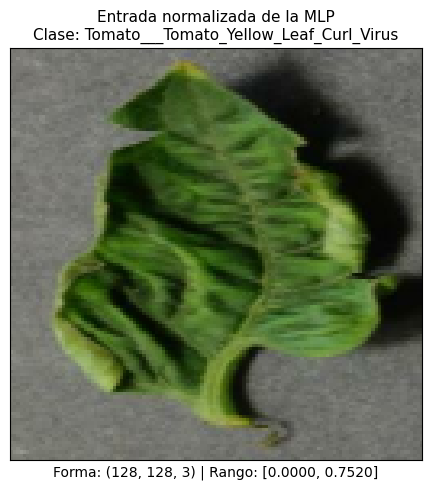


FASE 9.1 FINALIZADA
✅ Cada imagen posee forma 128 × 128 × 3.
✅ Los píxeles se encuentran normalizados en el intervalo [0, 1].
✅ Las etiquetas corresponden a enteros entre 0 y 9.
✅ Flatten producirá 49,152 características por imagen.
✅ Train, Validation y Test conservan la misma estructura de entrada.
✅ No se ha utilizado Test para entrenar ni seleccionar el modelo.

La entrada está preparada para construir la arquitectura MLP.


In [89]:
# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.1 VERIFICACIÓN DE LA ENTRADA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar que las imágenes preparadas en la Fase 7:
#
# 1. Posean una resolución de 128 x 128 píxeles.
# 2. Contengan tres canales RGB.
# 3. Se encuentren normalizadas en el intervalo [0, 1].
# 4. Utilicen etiquetas enteras compatibles con una tarea
#    de clasificación multiclase.
# 5. Puedan transformarse en vectores mediante Flatten.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda NO:
#
# - vuelve a descargar el dataset;
# - vuelve a dividir los datos;
# - ajusta transformaciones usando validation o test;
# - entrena todavía la MLP.
#
# Se reutilizan directamente los datasets construidos en
# la Fase 7.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. CONFIGURACIÓN ESPERADA
# ============================================================

SEED = 42

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 32
NUM_CLASSES_EXPECTED = 10

# Forma que recibirá la futura capa de entrada de la MLP.
INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

# Cantidad de características después de aplicar Flatten.
N_FEATURES_FLATTEN = (
    IMAGE_HEIGHT
    * IMAGE_WIDTH
    * CHANNELS
)

tf.keras.utils.set_random_seed(SEED)


print("=" * 80)
print("FASE 9.1 — ENTRADA REDIMENSIONADA Y NORMALIZADA")
print("=" * 80)

print(f"Resolución esperada : {INPUT_SHAPE_MLP}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Número de clases    : {NUM_CLASSES_EXPECTED}")
print(f"Entradas tras Flatten: {N_FEATURES_FLATTEN:,}")


# ============================================================
# 3. VERIFICAR OBJETOS CREADOS EN LA FASE 7
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos de la Fase 7: "
        f"{objetos_faltantes}. Ejecute previamente la Fase 7."
    )

print("\n✅ Todos los objetos requeridos están disponibles.")


# ============================================================
# 4. VERIFICAR EL NÚMERO Y ORDEN DE LAS CLASES
# ============================================================

assert NUM_CLASSES == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {NUM_CLASSES}."
)

assert len(class_names) == NUM_CLASSES, (
    "El número de nombres de clase no coincide con "
    "la variable NUM_CLASSES."
)

print("\n" + "=" * 80)
print("CLASES UTILIZADAS")
print("=" * 80)

for indice, nombre_clase in enumerate(class_names):
    print(f"{indice:02d} -> {nombre_clase}")


# ============================================================
# 5. FUNCIÓN PARA AUDITAR UN DATASET NORMALIZADO
# ============================================================

def auditar_dataset_entrada(
    dataset,
    nombre,
    input_shape_esperado,
    numero_clases
):
    """
    Inspecciona el primer lote de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset que contiene lotes de imágenes y etiquetas.

    nombre : str
        Nombre utilizado para identificar el conjunto.

    input_shape_esperado : tuple
        Forma esperada para una imagen individual:
        (altura, ancho, canales).

    numero_clases : int
        Cantidad total de categorías del problema.

    Retorna
    -------
    dict
        Resumen de forma, tipo y rango de valores.
    """

    # Tomar solamente un lote para realizar la auditoría.
    imagenes, etiquetas = next(iter(dataset.take(1)))

    # Forma dinámica real del lote.
    forma_lote = tuple(imagenes.shape)

    # Forma de una imagen individual.
    forma_imagen = tuple(imagenes.shape[1:])

    # Estadísticos del lote.
    valor_minimo = float(
        tf.reduce_min(imagenes).numpy()
    )

    valor_maximo = float(
        tf.reduce_max(imagenes).numpy()
    )

    valor_promedio = float(
        tf.reduce_mean(imagenes).numpy()
    )

    desviacion = float(
        tf.math.reduce_std(imagenes).numpy()
    )

    etiqueta_minima = int(
        tf.reduce_min(etiquetas).numpy()
    )

    etiqueta_maxima = int(
        tf.reduce_max(etiquetas).numpy()
    )

    # --------------------------------------------------------
    # VALIDACIONES
    # --------------------------------------------------------

    assert forma_imagen == input_shape_esperado, (
        f"{nombre}: se esperaba una imagen con forma "
        f"{input_shape_esperado}, pero se obtuvo {forma_imagen}."
    )

    assert imagenes.dtype == tf.float32, (
        f"{nombre}: las imágenes deberían ser float32, "
        f"pero son {imagenes.dtype}."
    )

    assert valor_minimo >= -1e-6, (
        f"{nombre}: se encontraron valores menores que cero."
    )

    assert valor_maximo <= 1.0 + 1e-6, (
        f"{nombre}: se encontraron valores superiores a uno."
    )

    assert etiquetas.dtype in (
        tf.int32,
        tf.int64
    ), (
        f"{nombre}: las etiquetas deberían ser enteras, "
        f"pero son {etiquetas.dtype}."
    )

    assert etiqueta_minima >= 0, (
        f"{nombre}: existe una etiqueta negativa."
    )

    assert etiqueta_maxima < numero_clases, (
        f"{nombre}: existe una etiqueta fuera del intervalo "
        f"[0, {numero_clases - 1}]."
    )

    return {
        "Conjunto": nombre,
        "Forma del lote": str(forma_lote),
        "Forma por imagen": str(forma_imagen),
        "Tipo imágenes": imagenes.dtype.name,
        "Tipo etiquetas": etiquetas.dtype.name,
        "Mínimo": valor_minimo,
        "Máximo": valor_maximo,
        "Media": valor_promedio,
        "Desviación estándar": desviacion,
        "Etiqueta mínima": etiqueta_minima,
        "Etiqueta máxima": etiqueta_maxima
    }


# ============================================================
# 6. AUDITORÍA DE TRAIN, VALIDATION Y TEST
# ============================================================
#
# Para verificar la normalización se utilizan los datasets
# deterministas *_ds_norm.
#
# El entrenamiento efectivo de la MLP podrá utilizar
# train_ds_final, que añade data augmentation.
# ============================================================

datasets_normalizados = {
    "Train": train_ds_norm,
    "Validation": val_ds_norm,
    "Test": test_ds_norm
}

resultados_auditoria = []

for nombre, dataset in datasets_normalizados.items():

    resultado = auditar_dataset_entrada(
        dataset=dataset,
        nombre=nombre,
        input_shape_esperado=INPUT_SHAPE_MLP,
        numero_clases=NUM_CLASSES
    )

    resultados_auditoria.append(resultado)


df_auditoria_entrada_mlp = pd.DataFrame(
    resultados_auditoria
)

print("\n" + "=" * 80)
print("AUDITORÍA DE LA ENTRADA")
print("=" * 80)

display(
    df_auditoria_entrada_mlp.round(6)
)


# ============================================================
# 7. DEMOSTRACIÓN DE LA TRANSFORMACIÓN FLATTEN
# ============================================================
#
# Flatten no modifica los valores de los píxeles.
# Solamente reorganiza cada imagen tridimensional como vector.
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(train_ds_norm.take(1))
)

flatten_demostracion = tf.keras.layers.Flatten(
    name="flatten_demostracion"
)

imagenes_vectorizadas = flatten_demostracion(
    imagenes_batch
)

forma_antes_flatten = tuple(
    imagenes_batch.shape
)

forma_despues_flatten = tuple(
    imagenes_vectorizadas.shape
)

print("\n" + "=" * 80)
print("DEMOSTRACIÓN DE FLATTEN")
print("=" * 80)

print(
    f"Forma antes de Flatten  : "
    f"{forma_antes_flatten}"
)

print(
    f"Forma después de Flatten: "
    f"{forma_despues_flatten}"
)

print(
    f"Características por imagen: "
    f"{imagenes_vectorizadas.shape[1]:,}"
)

# Verificar matemáticamente la dimensión resultante.
assert int(imagenes_vectorizadas.shape[1]) == N_FEATURES_FLATTEN, (
    "La cantidad de características generadas por Flatten "
    "no coincide con 128 × 128 × 3."
)

# Verificar que Flatten no altere el número de observaciones.
assert int(imagenes_vectorizadas.shape[0]) == int(
    imagenes_batch.shape[0]
), (
    "Flatten modificó inesperadamente el tamaño del lote."
)

print(
    "\n✅ Flatten transforma correctamente cada imagen "
    f"en un vector de {N_FEATURES_FLATTEN:,} valores."
)


# ============================================================
# 8. VISUALIZACIÓN DE UNA IMAGEN DE ENTRADA
# ============================================================

indice_imagen = 0

imagen_ejemplo = imagenes_batch[
    indice_imagen
].numpy()

etiqueta_ejemplo = int(
    etiquetas_batch[
        indice_imagen
    ].numpy()
)

nombre_clase_ejemplo = class_names[
    etiqueta_ejemplo
]

plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    np.clip(
        imagen_ejemplo,
        0.0,
        1.0
    )
)

plt.title(
    "Entrada normalizada de la MLP\n"
    f"Clase: {nombre_clase_ejemplo}",
    fontsize=11
)

plt.xlabel(
    f"Forma: {imagen_ejemplo.shape} | "
    f"Rango: [{imagen_ejemplo.min():.4f}, "
    f"{imagen_ejemplo.max():.4f}]"
)

plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


# ============================================================
# 9. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.1 FINALIZADA")
print("=" * 80)

print(
    f"✅ Cada imagen posee forma "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "✅ Los píxeles se encuentran normalizados "
    "en el intervalo [0, 1]."
)

print(
    f"✅ Las etiquetas corresponden a enteros "
    f"entre 0 y {NUM_CLASSES - 1}."
)

print(
    f"✅ Flatten producirá "
    f"{N_FEATURES_FLATTEN:,} características por imagen."
)

print(
    "✅ Train, Validation y Test conservan "
    "la misma estructura de entrada."
)

print(
    "✅ No se ha utilizado Test para entrenar "
    "ni seleccionar el modelo."
)

print(
    "\nLa entrada está preparada para construir "
    "la arquitectura MLP."
)

## 9.2 Aplanamiento de las imágenes mediante `Flatten`

Las imágenes procesadas en la Fase 7 poseen una resolución de:

$$
H \times W \times C = 128 \times 128 \times 3
$$

donde:
- $H = 128$ corresponde a la altura.
- $W = 128$ corresponde al ancho.
- $C = 3$ representa los canales RGB.

Por tanto, cada imagen normalizada se representa mediante un tensor tridimensional:

$$
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
$$

Las redes neuronales multicapa o **MLP** operan mediante capas densamente conectadas. Una capa densa espera recibir un vector de características por cada observación y no una matriz tridimensional.

Por esta razón, antes de ingresar a las capas densas se utiliza una capa `Flatten`, cuya función es reorganizar los píxeles de cada imagen en un único vector.

---

### Transformación matemática

La operación de aplanamiento puede representarse como:

$$
\operatorname{Flatten}: \mathbb{R}^{H \times W \times C} \longrightarrow \mathbb{R}^{D}
$$

donde la dimensión del vector resultante es:

$$
D = H \cdot W \cdot C
$$

Para las imágenes utilizadas en este proyecto:

$$
\begin{aligned}
D &= 128 \cdot 128 \cdot 3 \\
&= 49.152
\end{aligned}
$$

Por consiguiente:

$$
\operatorname{Flatten}: \mathbb{R}^{128 \times 128 \times 3} \longrightarrow \mathbb{R}^{49.152}
$$

Cada imagen se transforma en un vector:

$$
\mathbf{x}_i = \begin{bmatrix} x_{i,1} & x_{i,2} & \cdots & x_{i,49.152} \end{bmatrix}^{\mathsf{T}}
$$

donde cada componente corresponde a un valor normalizado de uno de los píxeles y canales de la imagen.

---

### Transformación de un lote

El pipeline utiliza lotes de 32 imágenes. Antes del aplanamiento, un lote tiene la forma:

$$
\mathbf{X}_{\text{batch}} \in \mathbb{R}^{32 \times 128 \times 128 \times 3}
$$

Después de aplicar `Flatten`, la forma se transforma en:

$$
\mathbf{X}_{\text{flat}} \in \mathbb{R}^{32 \times 49.152}
$$

Es importante observar que la dimensión correspondiente al número de imágenes del lote no cambia:

$$
32 \times 128 \times 128 \times 3 \longrightarrow 32 \times 49.152
$$

La transformación se aplica independientemente a cada observación.

---

### ¿`Flatten` modifica los valores de los píxeles?

La capa `Flatten` no aprende parámetros y no modifica los valores numéricos de los píxeles. Solamente cambia la organización de los datos.

Por tanto:

$$
\operatorname{Flatten} \left( \mathbf{X}_i \right) = \operatorname{reshape} \left( \mathbf{X}_i \right)
$$

y se conserva la cantidad total de elementos:

$$
128 \cdot 128 \cdot 3 = 49.152
$$

En consecuencia, la suma, la media, el mínimo y el máximo de los valores de cada imagen permanecen iguales antes y después del aplanamiento.

---

### Cantidad de parámetros de `Flatten`

La capa `Flatten` no contiene pesos ni sesgos entrenables:

$$
N_{\text{parámetros de Flatten}} = 0
$$

Su función es exclusivamente estructural. Los parámetros entrenables aparecen en la capa densa posterior.

Si el vector aplanado de $49.152$ características se conecta a una capa densa con $n$ neuronas, la cantidad de parámetros de esa capa será:

$$
N_{\text{Dense}} = D \cdot n + n
$$

donde:
- $D = 49.152$ es la cantidad de entradas.
- $n$ es la cantidad de neuronas.
- $D \cdot n$ corresponde a los pesos.
- $n$ corresponde a los sesgos.

De manera equivalente:

$$
N_{\text{Dense}} = (D + 1)n
$$

Por ejemplo, para una primera capa con 128 neuronas:

$$
N_{\text{Dense}} = (49.152 + 1) \cdot 128 = 6.291.584
$$

Esto evidencia que una MLP aplicada directamente sobre imágenes puede generar una cantidad considerable de parámetros, incluso cuando la primera capa densa posee un número moderado de neuronas.

---

### Limitación espacial de `Flatten`

El aplanamiento conserva todos los valores, pero deja de representar explícitamente las relaciones espaciales entre los píxeles.

Antes del aplanamiento, un píxel puede identificarse mediante:

$$
x_{h,w,c}
$$

donde $h$, $w$ y $c$ indican su posición espacial y canal. Después del aplanamiento, el mismo valor se representa mediante una posición lineal:

$$
x_j, \quad j \in \{1, 2, \ldots, 49.152\}
$$

La MLP recibe el vector completo, pero no incorpora de manera explícita conceptos como:
- Vecindad entre píxeles.
- Patrones locales.
- Bordes.
- Texturas.
- Distribución espacial de las lesiones.
- Invariancia aproximada frente a desplazamientos.

En una capa densa, cada neurona se conecta con todas las entradas:

$$
z_j = \sum_{k=1}^{D} w_{jk}x_k + b_j
$$

y su activación puede calcularse mediante ReLU:

$$
a_j = \operatorname{ReLU}(z_j) = \max(0, z_j)
$$

La red deberá aprender las relaciones espaciales indirectamente a partir de una gran cantidad de pesos.

Esta característica constituye una parte central del experimento:

$$
\text{MLP} \longrightarrow \text{imagen aplanada} \longrightarrow \text{conexiones globales}
$$

$$
\text{CNN} \longrightarrow \text{imagen espacial} \longrightarrow \text{filtros locales y pesos compartidos}
$$

La comparación posterior permitirá determinar si conservar y explotar explícitamente la estructura espacial proporciona una ventaja de generalización para la clasificación de enfermedades foliares del tomate.

FASE 9.2 — APLANAMIENTO MEDIANTE FLATTEN
Forma de una imagen : (128, 128, 3)
Altura              : 128
Ancho               : 128
Canales             : 3
Características después de Flatten: 49,152

✅ Los datasets normalizados de la Fase 7 están disponibles.

LOTE DE ENTRADA
Forma de las imágenes: (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de las imágenes: float32
Tipo de las etiquetas: int32

✅ La forma de entrada coincide con (128, 128, 3).

TRANSFORMACIÓN REALIZADA POR FLATTEN
Antes   : (32, 128, 128, 3)
Después : (32, 49152)

Transformación por imagen:
(128, 128, 3) → (49,152,)

✅ El número de imágenes del lote se conserva.
✅ Cada imagen genera exactamente 49,152 características.

CONSERVACIÓN DE LOS VALORES
Diferencia máxima después de reconstruir: 0.0000000000
✅ Flatten no modifica los valores de los píxeles.

ESTADÍSTICOS ANTES Y DESPUÉS


,Estadístico,Antes de Flatten,Después de Flatten
0,Valor mínimo,0.000000e+00,0.000000e+00
1,Valor máximo,9.470589e-01,9.470589e-01
2,Media,4.441810e-01,4.441810e-01
3,Desviación estándar,1.849277e-01,1.849277e-01
4,Número total de elementos,1.572864e+06,1.572864e+06



PARÁMETROS DE LA CAPA FLATTEN
Parámetros totales    : 0
Variables entrenables : 0
Variables no entrenables: 0

✅ Flatten es una transformación sin parámetros.

RESUMEN DE LA TRANSFORMACIÓN


Model: "demostracion_flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ aplanamiento (Flatten)          │ (None, 49152)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


IMPACTO SOBRE LA PRIMERA CAPA DENSA


,Neuronas Dense,Pesos,Sesgos,Parámetros totales
0,64,"3,145,728",64,"3,145,792"
1,128,"6,291,456",128,"6,291,584"
2,256,"12,582,912",256,"12,583,168"


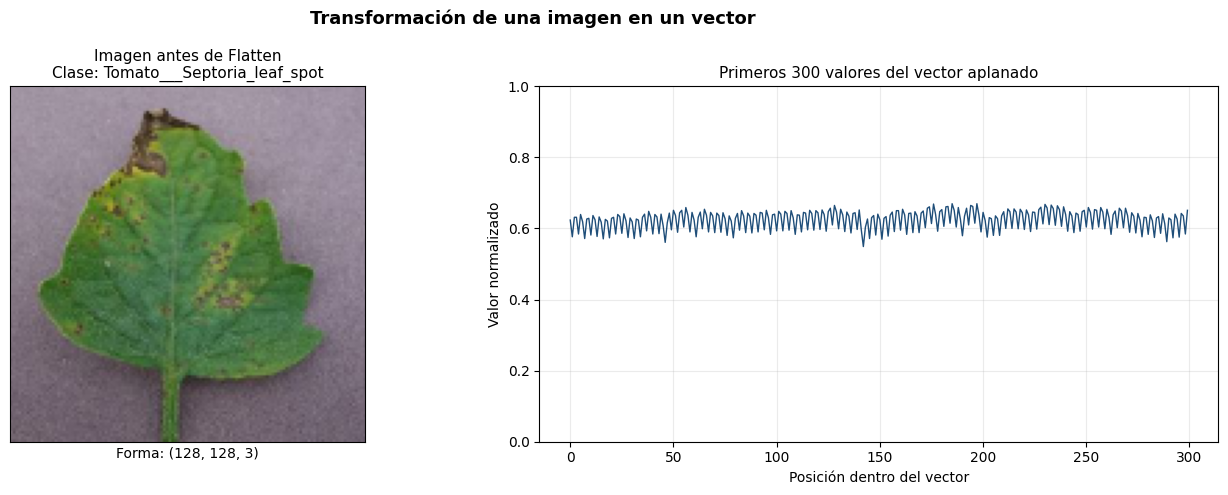


FASE 9.2 FINALIZADA
✅ Entrada por imagen: 128 × 128 × 3.
✅ Salida por imagen: 49,152 características.
✅ El tamaño del batch permanece sin cambios.
✅ Los valores normalizados de los píxeles se conservan.
✅ La capa Flatten contiene cero parámetros entrenables.
⚠️ La organización espacial deja de estar representada explícitamente.

Las imágenes están preparadas para ingresar a la primera capa Dense de la MLP.


In [90]:
# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.2 APLANAMIENTO DE LAS IMÁGENES MEDIANTE FLATTEN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar cómo la capa Flatten transforma cada imagen
# normalizada de 128 x 128 x 3 en un vector de 49.152
# características.
#
# En esta celda se comprobará que:
#
# 1. La forma de entrada es (batch, 128, 128, 3).
# 2. La forma de salida es (batch, 49.152).
# 3. El número de imágenes del lote no cambia.
# 4. La cantidad total de valores por imagen se conserva.
# 5. Los valores numéricos no son modificados.
# 6. Flatten no contiene parámetros entrenables.
#
# Esta celda NO entrena todavía la MLP.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

# Número esperado de características después de Flatten.
N_FEATURES_FLATTEN = int(
    np.prod(
        INPUT_SHAPE_MLP
    )
)

print("=" * 80)
print("FASE 9.2 — APLANAMIENTO MEDIANTE FLATTEN")
print("=" * 80)

print(f"Forma de una imagen : {INPUT_SHAPE_MLP}")
print(f"Altura              : {IMAGE_HEIGHT}")
print(f"Ancho               : {IMAGE_WIDTH}")
print(f"Canales             : {CHANNELS}")
print(
    "Características después de Flatten: "
    f"{N_FEATURES_FLATTEN:,}"
)


# ============================================================
# 3. VERIFICAR LOS OBJETOS DE LA FASE 7
# ============================================================
#
# Para demostrar Flatten se utiliza train_ds_norm porque:
#
# - contiene imágenes redimensionadas;
# - contiene imágenes normalizadas;
# - no incorpora una transformación aleatoria durante la
#   inspección;
# - permite reproducir exactamente la comprobación.
#
# Durante el entrenamiento posterior podrá utilizarse
# train_ds_final, que incluye data augmentation.
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    nombre
    for nombre in objetos_requeridos
    if nombre not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print(
    "\n✅ Los datasets normalizados de la Fase 7 "
    "están disponibles."
)


# ============================================================
# 4. EXTRAER UN LOTE DE ENTRENAMIENTO
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_norm.take(1)
    )
)

print("\n" + "=" * 80)
print("LOTE DE ENTRADA")
print("=" * 80)

print(
    f"Forma de las imágenes: "
    f"{tuple(imagenes_batch.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch.shape)}"
)

print(
    f"Tipo de las imágenes: "
    f"{imagenes_batch.dtype.name}"
)

print(
    f"Tipo de las etiquetas: "
    f"{etiquetas_batch.dtype.name}"
)


# ============================================================
# 5. VALIDAR LA FORMA DE ENTRADA
# ============================================================

forma_imagen_observada = tuple(
    imagenes_batch.shape[1:]
)

assert forma_imagen_observada == INPUT_SHAPE_MLP, (
    "La forma observada de las imágenes no coincide con "
    f"{INPUT_SHAPE_MLP}. Se obtuvo "
    f"{forma_imagen_observada}."
)

assert imagenes_batch.dtype == tf.float32, (
    "Las imágenes deberían estar representadas como float32."
)

print(
    "\n✅ La forma de entrada coincide con "
    f"{INPUT_SHAPE_MLP}."
)


# ============================================================
# 6. CREAR LA CAPA FLATTEN
# ============================================================
#
# Flatten reorganiza las dimensiones espaciales y de canales
# en una única dimensión.
#
# No contiene pesos, sesgos ni parámetros entrenables.
# ============================================================

flatten_layer = tf.keras.layers.Flatten(
    name="flatten_mlp"
)

imagenes_flatten = flatten_layer(
    imagenes_batch
)


# ============================================================
# 7. COMPARAR LAS FORMAS ANTES Y DESPUÉS
# ============================================================

forma_antes = tuple(
    imagenes_batch.shape
)

forma_despues = tuple(
    imagenes_flatten.shape
)

batch_antes = int(
    imagenes_batch.shape[0]
)

batch_despues = int(
    imagenes_flatten.shape[0]
)

features_observadas = int(
    imagenes_flatten.shape[1]
)

print("\n" + "=" * 80)
print("TRANSFORMACIÓN REALIZADA POR FLATTEN")
print("=" * 80)

print(f"Antes   : {forma_antes}")
print(f"Después : {forma_despues}")

print(
    "\nTransformación por imagen:"
)

print(
    f"({IMAGE_HEIGHT}, {IMAGE_WIDTH}, {CHANNELS}) "
    f"→ ({features_observadas:,},)"
)


# ============================================================
# 8. VALIDAR LA DIMENSIÓN RESULTANTE
# ============================================================

assert batch_antes == batch_despues, (
    "Flatten modificó inesperadamente el número de imágenes "
    "del lote."
)

assert features_observadas == N_FEATURES_FLATTEN, (
    "La cantidad de características obtenida no coincide con "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "\n✅ El número de imágenes del lote se conserva."
)

print(
    "✅ Cada imagen genera exactamente "
    f"{N_FEATURES_FLATTEN:,} características."
)


# ============================================================
# 9. COMPROBAR LA CONSERVACIÓN DE LOS VALORES
# ============================================================
#
# Para demostrar que Flatten solamente reorganiza los datos,
# se reconstruye la forma original mediante tf.reshape.
#
# Si la reconstrucción coincide con el tensor original,
# entonces ningún valor fue modificado.
# ============================================================

imagenes_reconstruidas = tf.reshape(
    imagenes_flatten,
    shape=tf.shape(
        imagenes_batch
    )
)

diferencia_maxima = float(
    tf.reduce_max(
        tf.abs(
            imagenes_batch
            -
            imagenes_reconstruidas
        )
    ).numpy()
)

assert np.isclose(
    diferencia_maxima,
    0.0,
    atol=1e-7
), (
    "Se detectaron diferencias entre las imágenes originales "
    "y las reconstruidas."
)

print("\n" + "=" * 80)
print("CONSERVACIÓN DE LOS VALORES")
print("=" * 80)

print(
    f"Diferencia máxima después de reconstruir: "
    f"{diferencia_maxima:.10f}"
)

print(
    "✅ Flatten no modifica los valores de los píxeles."
)


# ============================================================
# 10. COMPARAR ESTADÍSTICOS ANTES Y DESPUÉS
# ============================================================

estadisticas_flatten = pd.DataFrame({
    "Estadístico": [
        "Valor mínimo",
        "Valor máximo",
        "Media",
        "Desviación estándar",
        "Número total de elementos"
    ],

    "Antes de Flatten": [
        float(
            tf.reduce_min(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.reduce_max(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.reduce_mean(
                imagenes_batch
            ).numpy()
        ),

        float(
            tf.math.reduce_std(
                imagenes_batch
            ).numpy()
        ),

        int(
            tf.size(
                imagenes_batch
            ).numpy()
        )
    ],

    "Después de Flatten": [
        float(
            tf.reduce_min(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.reduce_max(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.reduce_mean(
                imagenes_flatten
            ).numpy()
        ),

        float(
            tf.math.reduce_std(
                imagenes_flatten
            ).numpy()
        ),

        int(
            tf.size(
                imagenes_flatten
            ).numpy()
        )
    ]
})

print("\n" + "=" * 80)
print("ESTADÍSTICOS ANTES Y DESPUÉS")
print("=" * 80)

display(
    estadisticas_flatten.round(8)
)


# ============================================================
# 11. VERIFICAR LOS PARÁMETROS DE FLATTEN
# ============================================================

parametros_flatten = flatten_layer.count_params()

assert parametros_flatten == 0, (
    "La capa Flatten no debería contener parámetros."
)

print("\n" + "=" * 80)
print("PARÁMETROS DE LA CAPA FLATTEN")
print("=" * 80)

print(
    f"Parámetros totales    : "
    f"{parametros_flatten:,}"
)

print(
    f"Variables entrenables : "
    f"{len(flatten_layer.trainable_variables)}"
)

print(
    f"Variables no entrenables: "
    f"{len(flatten_layer.non_trainable_variables)}"
)

print(
    "\n✅ Flatten es una transformación sin parámetros."
)


# ============================================================
# 12. MOSTRAR UN MODELO MÍNIMO DE DEMOSTRACIÓN
# ============================================================
#
# Este modelo contiene solamente:
#
# Input -> Flatten
#
# No corresponde todavía a la arquitectura MLP completa.
# Su finalidad es mostrar formalmente la transformación.
# ============================================================

modelo_demostracion_flatten = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=INPUT_SHAPE_MLP,
            name="imagen_entrada"
        ),

        tf.keras.layers.Flatten(
            name="aplanamiento"
        )
    ],
    name="demostracion_flatten"
)

print("\n" + "=" * 80)
print("RESUMEN DE LA TRANSFORMACIÓN")
print("=" * 80)

modelo_demostracion_flatten.summary()


# ============================================================
# 13. ESTIMAR PARÁMETROS DE UNA CAPA DENSA POSTERIOR
# ============================================================
#
# Esta estimación permite comprender por qué el aplanamiento
# puede producir una MLP con muchos parámetros.
#
# Fórmula:
#
# parámetros = entradas * neuronas + neuronas
#            = (entradas + 1) * neuronas
# ============================================================

unidades_ejemplo = [
    64,
    128,
    256
]

comparacion_parametros = []

for unidades in unidades_ejemplo:

    pesos = (
        N_FEATURES_FLATTEN
        * unidades
    )

    sesgos = unidades

    parametros_totales = (
        pesos
        +
        sesgos
    )

    comparacion_parametros.append({
        "Neuronas Dense": unidades,
        "Pesos": pesos,
        "Sesgos": sesgos,
        "Parámetros totales": parametros_totales
    })

df_parametros_dense = pd.DataFrame(
    comparacion_parametros
)

print("\n" + "=" * 80)
print("IMPACTO SOBRE LA PRIMERA CAPA DENSA")
print("=" * 80)

display(
    df_parametros_dense.style.format({
        "Pesos": "{:,.0f}",
        "Sesgos": "{:,.0f}",
        "Parámetros totales": "{:,.0f}"
    })
)


# ============================================================
# 14. VISUALIZAR LA CORRESPONDENCIA ENTRE IMAGEN Y VECTOR
# ============================================================

indice_ejemplo = 0

imagen_ejemplo = imagenes_batch[
    indice_ejemplo
].numpy()

vector_ejemplo = imagenes_flatten[
    indice_ejemplo
].numpy()

etiqueta_ejemplo = int(
    etiquetas_batch[
        indice_ejemplo
    ].numpy()
)

nombre_clase = class_names[
    etiqueta_ejemplo
]

# Mostrar solamente los primeros valores del vector.
N_VALORES_MOSTRAR = 300

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# ------------------------------------------------------------
# Imagen antes del aplanamiento
# ------------------------------------------------------------

axes[0].imshow(
    np.clip(
        imagen_ejemplo,
        0.0,
        1.0
    )
)

axes[0].set_title(
    "Imagen antes de Flatten\n"
    f"Clase: {nombre_clase}",
    fontsize=11
)

axes[0].set_xlabel(
    f"Forma: {imagen_ejemplo.shape}"
)

axes[0].set_xticks([])
axes[0].set_yticks([])


# ------------------------------------------------------------
# Primeros valores del vector aplanado
# ------------------------------------------------------------

axes[1].plot(
    np.arange(
        N_VALORES_MOSTRAR
    ),
    vector_ejemplo[
        :N_VALORES_MOSTRAR
    ],
    color="#1F4E79",
    linewidth=1
)

axes[1].set_title(
    "Primeros 300 valores del vector aplanado",
    fontsize=11
)

axes[1].set_xlabel(
    "Posición dentro del vector"
)

axes[1].set_ylabel(
    "Valor normalizado"
)

axes[1].set_ylim(
    0,
    1
)

axes[1].grid(
    alpha=0.25
)

plt.suptitle(
    "Transformación de una imagen en un vector",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.2 FINALIZADA")
print("=" * 80)

print(
    f"✅ Entrada por imagen: "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    f"✅ Salida por imagen: "
    f"{N_FEATURES_FLATTEN:,} características."
)

print(
    "✅ El tamaño del batch permanece sin cambios."
)

print(
    "✅ Los valores normalizados de los píxeles "
    "se conservan."
)

print(
    "✅ La capa Flatten contiene cero parámetros "
    "entrenables."
)

print(
    "⚠️ La organización espacial deja de estar "
    "representada explícitamente."
)

print(
    "\nLas imágenes están preparadas para ingresar "
    "a la primera capa Dense de la MLP."
)

## 9.4 Función de pérdida: `SparseCategoricalCrossentropy`

El entrenamiento de una red neuronal requiere una **función de pérdida** que
cuantifique la diferencia entre las predicciones generadas por el modelo y las
clases verdaderas.

En este proyecto se resuelve un problema de clasificación multiclase con:

$
K=10
$


categorías mutuamente excluyentes. Cada imagen pertenece exactamente a una clase
de enfermedad foliar o a la categoría saludable.

Las etiquetas fueron generadas por `image_dataset_from_directory` utilizando
codificación entera. Por tanto:


$ y_i\in\{0,1,\ldots,K-1\} $


y, para este proyecto:


$ y_i\in\{0,1,\ldots,9\} $


Por ejemplo, una etiqueta entera puede interpretarse como:


$  
y_i=0
\quad\Longrightarrow\quad
\texttt{class\_names[0]}
$


$
y_i=9
\quad\Longrightarrow\quad
\texttt{class\_names[9]}
$


Dado que las etiquetas se encuentran representadas mediante números enteros, la
función de pérdida apropiada es:

```python
tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=False
)

FASE 9.4 — SPARSE CATEGORICAL CROSSENTROPY
Número de clases: 10
Codificación esperada: etiquetas enteras
Intervalo válido de etiquetas: [0, 9]

LOTE EXTRAÍDO DEL PIPELINE
Forma de las imágenes: (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de las etiquetas: int32
Etiqueta mínima del lote: 0
Etiqueta máxima del lote: 9

✅ Las etiquetas poseen codificación entera.
✅ Todas las etiquetas pertenecen al intervalo [0, 9].

EJEMPLOS DE ETIQUETAS ENTERAS


,Imagen del lote,Etiqueta entera,Nombre de la clase
0,0,2,Tomato___Late_blight
1,1,6,Tomato___Target_Spot
2,2,0,Tomato___Bacterial_spot
3,3,9,Tomato___healthy
4,4,1,Tomato___Early_blight
5,5,4,Tomato___Septoria_leaf_spot
6,6,8,Tomato___Tomato_mosaic_virus
7,7,5,Tomato___Spider_mites Two-spotted_spider_mite
8,8,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus
9,9,2,Tomato___Late_blight



CONFIGURACIÓN DE LA PÉRDIDA
Clase TensorFlow : SparseCategoricalCrossentropy
from_logits      : False
Reducción        : promedio sobre el batch

✅ Función de pérdida creada correctamente.

✅ Las probabilidades de todos los escenarios suman 1.

COMPARACIÓN DE ESCENARIOS


,Escenario,Probabilidad de la clase real,Pérdida calculada,Pérdida teórica
0,Predicción uniforme,0.1000,2.302585,2.302585
1,Predicción favorable,0.9000,0.105360,0.105361
2,Incorrecta con alta confianza,0.0100,4.605171,4.605170



✅ La predicción favorable produce la menor pérdida.
✅ La predicción uniforme produce una pérdida intermedia.
✅ La predicción incorrecta y segura produce la mayor pérdida.

EQUIVALENCIA MATEMÁTICA
SparseCategoricalCrossentropy: 0.10536046
CategoricalCrossentropy      : 0.10536055
Diferencia absoluta          : 0.0000000820

✅ Ambas pérdidas son equivalentes.
✅ Se mantiene la versión Sparse porque las etiquetas originales son enteras.


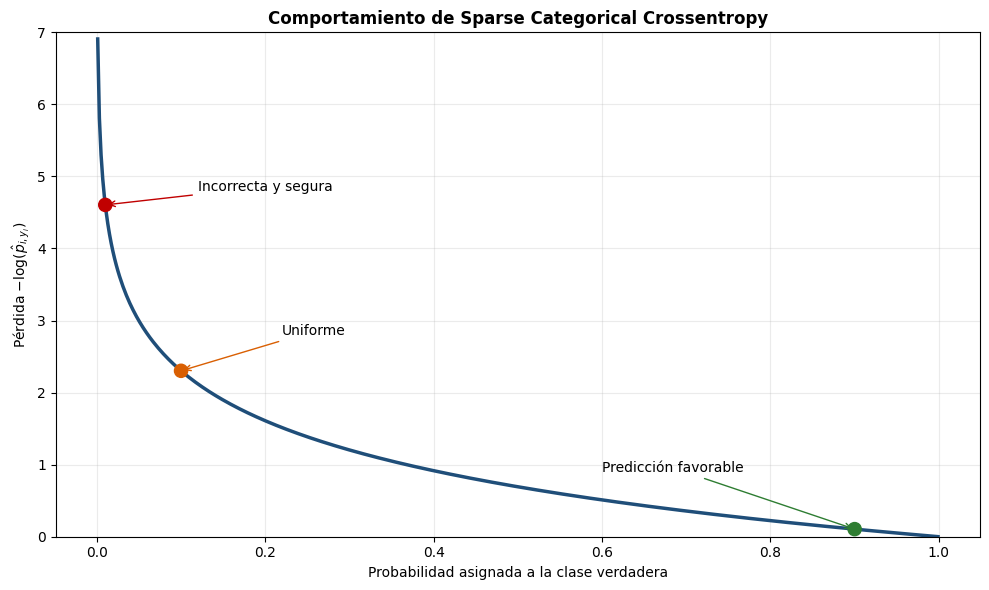


CONFIGURACIÓN PARA LA MLP
Objeto creado: LOSS_MLP
Uso posterior:

modelo_mlp.compile(
    optimizer=...,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)

FASE 9.4 FINALIZADA
✅ Las etiquetas del dataset son enteras.
✅ Las etiquetas pertenecen al intervalo [0, 9].
✅ SparseCategoricalCrossentropy es compatible con el formato de las etiquetas.
✅ from_logits=False es coherente con una salida softmax.
✅ La pérdida de referencia uniforme es log(10) = 2.302585.
✅ Una probabilidad alta para la clase correcta produce una pérdida pequeña.
✅ Una predicción incorrecta con alta confianza produce una pérdida elevada.
✅ La versión sparse es matemáticamente equivalente a la versión one-hot.

La función de pérdida está preparada para utilizarse en la compilación y entrenamiento de la MLP.


In [91]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.4 FUNCIÓN DE PÉRDIDA: SPARSE CATEGORICAL CROSSENTROPY
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar que SparseCategoricalCrossentropy es compatible
# con:
#
# 1. Las diez clases del problema.
# 2. Las etiquetas enteras del pipeline.
# 3. La salida probabilística softmax.
#
# También se demostrará cómo cambia la pérdida cuando el
# modelo asigna probabilidades altas o bajas a la clase real.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda no entrena todavía la MLP y no utiliza el
# conjunto test para seleccionar hiperparámetros.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR LOS OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DEL PROBLEMA
# ============================================================

K = int(
    NUM_CLASSES
)

NUM_CLASSES_EXPECTED = 10

assert K == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {K}."
)

assert len(class_names) == K, (
    "La cantidad de nombres de clase no coincide "
    "con NUM_CLASSES."
)

print("=" * 80)
print("FASE 9.4 — SPARSE CATEGORICAL CROSSENTROPY")
print("=" * 80)

print(f"Número de clases: {K}")
print("Codificación esperada: etiquetas enteras")
print(f"Intervalo válido de etiquetas: [0, {K - 1}]")


# ============================================================
# 5. EXTRAER UN LOTE REAL DEL CONJUNTO DE ENTRENAMIENTO
# ============================================================
#
# Se utiliza train_ds_norm para comprobar el formato de las
# etiquetas. No se necesita data augmentation para validar
# la función de pérdida.
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_norm.take(1)
    )
)

batch_size_real = int(
    tf.shape(
        etiquetas_batch
    )[0].numpy()
)

print("\n" + "=" * 80)
print("LOTE EXTRAÍDO DEL PIPELINE")
print("=" * 80)

print(
    f"Forma de las imágenes: "
    f"{tuple(imagenes_batch.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch.shape)}"
)

print(
    f"Tipo de las etiquetas: "
    f"{etiquetas_batch.dtype.name}"
)

print(
    f"Etiqueta mínima del lote: "
    f"{int(tf.reduce_min(etiquetas_batch).numpy())}"
)

print(
    f"Etiqueta máxima del lote: "
    f"{int(tf.reduce_max(etiquetas_batch).numpy())}"
)


# ============================================================
# 6. VALIDAR QUE LAS ETIQUETAS SEAN ENTERAS
# ============================================================

assert etiquetas_batch.dtype in (
    tf.int32,
    tf.int64
), (
    "SparseCategoricalCrossentropy requiere etiquetas "
    "enteras, pero se recibió "
    f"{etiquetas_batch.dtype.name}."
)

etiqueta_minima = int(
    tf.reduce_min(
        etiquetas_batch
    ).numpy()
)

etiqueta_maxima = int(
    tf.reduce_max(
        etiquetas_batch
    ).numpy()
)

assert etiqueta_minima >= 0, (
    "Se detectó una etiqueta negativa."
)

assert etiqueta_maxima < K, (
    "Se detectó una etiqueta fuera del intervalo permitido."
)

print(
    "\n✅ Las etiquetas poseen codificación entera."
)

print(
    f"✅ Todas las etiquetas pertenecen al intervalo "
    f"[0, {K - 1}]."
)


# ============================================================
# 7. MOSTRAR EJEMPLOS DE ETIQUETAS
# ============================================================

N_EJEMPLOS = min(
    10,
    batch_size_real
)

indices_etiquetas = (
    etiquetas_batch
    .numpy()[:N_EJEMPLOS]
    .astype(int)
)

df_etiquetas = pd.DataFrame({
    "Imagen del lote": np.arange(N_EJEMPLOS),
    "Etiqueta entera": indices_etiquetas,
    "Nombre de la clase": [
        class_names[indice]
        for indice in indices_etiquetas
    ]
})

print("\n" + "=" * 80)
print("EJEMPLOS DE ETIQUETAS ENTERAS")
print("=" * 80)

display(
    df_etiquetas
)


# ============================================================
# 8. DEFINIR LA FUNCIÓN DE PÉRDIDA
# ============================================================
#
# from_logits=False:
#
# La futura salida de la MLP utiliza activación softmax.
# Por tanto, el modelo entregará probabilidades y no logits.
# ============================================================

loss_mlp = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    reduction="sum_over_batch_size",
    name="sparse_categorical_crossentropy"
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN DE LA PÉRDIDA")
print("=" * 80)

print(
    "Clase TensorFlow : "
    f"{loss_mlp.__class__.__name__}"
)

print(
    "from_logits      : "
    f"{loss_mlp.from_logits}"
)

print(
    "Reducción        : promedio sobre el batch"
)

print(
    "\n✅ Función de pérdida creada correctamente."
)


# ============================================================
# 9. CONSTRUIR TRES ESCENARIOS PROBABILÍSTICOS
# ============================================================
#
# Se construirán probabilidades controladas para comparar:
#
# A. Predicción uniforme:
#    cada clase recibe probabilidad 1/K.
#
# B. Predicción favorable:
#    la clase real recibe probabilidad 0.90.
#
# C. Predicción incorrecta con alta confianza:
#    la clase real recibe probabilidad 0.01 y otra clase 0.99.
#
# Estos escenarios permiten interpretar el valor de la pérdida.
# ============================================================

etiquetas_demo = tf.cast(
    etiquetas_batch,
    tf.int32
)


# ------------------------------------------------------------
# A. PREDICCIÓN UNIFORME
# ------------------------------------------------------------

probabilidades_uniformes = tf.fill(
    dims=(
        batch_size_real,
        K
    ),
    value=tf.cast(
        1.0 / K,
        tf.float32
    )
)


# ------------------------------------------------------------
# B. PREDICCIÓN FAVORABLE
# ------------------------------------------------------------
#
# Probabilidad de la clase real: 0.90
# Probabilidad restante: 0.10 distribuida entre K-1 clases.
# ------------------------------------------------------------

PROBABILIDAD_CORRECTA_ALTA = 0.90

probabilidad_otras_clases = (
    1.0
    -
    PROBABILIDAD_CORRECTA_ALTA
) / (
    K
    -
    1
)

probabilidades_favorables = tf.one_hot(
    etiquetas_demo,
    depth=K,
    on_value=tf.cast(
        PROBABILIDAD_CORRECTA_ALTA,
        tf.float32
    ),
    off_value=tf.cast(
        probabilidad_otras_clases,
        tf.float32
    )
)


# ------------------------------------------------------------
# C. PREDICCIÓN INCORRECTA CON ALTA CONFIANZA
# ------------------------------------------------------------
#
# La clase verdadera recibe 0.01.
# Una clase incorrecta recibe 0.99.
# Las restantes clases reciben 0.
# ------------------------------------------------------------

PROBABILIDAD_CLASE_REAL_BAJA = 0.01
PROBABILIDAD_CLASE_INCORRECTA = 0.99

# Seleccionar como clase incorrecta la siguiente clase.
indices_incorrectos = (
    etiquetas_demo
    +
    1
) % K

probabilidades_incorrectas = (
    tf.one_hot(
        etiquetas_demo,
        depth=K,
        on_value=tf.cast(
            PROBABILIDAD_CLASE_REAL_BAJA,
            tf.float32
        ),
        off_value=tf.constant(
            0.0,
            dtype=tf.float32
        )
    )
    +
    tf.one_hot(
        indices_incorrectos,
        depth=K,
        on_value=tf.cast(
            PROBABILIDAD_CLASE_INCORRECTA,
            tf.float32
        ),
        off_value=tf.constant(
            0.0,
            dtype=tf.float32
        )
    )
)


# ============================================================
# 10. VERIFICAR QUE LAS PROBABILIDADES SUMEN UNO
# ============================================================

escenarios_probabilidades = {
    "Uniforme": probabilidades_uniformes,
    "Favorable": probabilidades_favorables,
    "Incorrecta con alta confianza": probabilidades_incorrectas
}

for nombre, probabilidades in escenarios_probabilidades.items():

    sumas = tf.reduce_sum(
        probabilidades,
        axis=1
    )

    assert np.allclose(
        sumas.numpy(),
        np.ones(batch_size_real),
        atol=1e-6
    ), (
        f"Las probabilidades del escenario {nombre} "
        "no suman uno."
    )

print(
    "\n✅ Las probabilidades de todos los escenarios suman 1."
)


# ============================================================
# 11. CALCULAR LA PÉRDIDA DE CADA ESCENARIO
# ============================================================

loss_uniforme = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_uniformes
    ).numpy()
)

loss_favorable = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_favorables
    ).numpy()
)

loss_incorrecta = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_incorrectas
    ).numpy()
)


# Valores teóricos esperados.
loss_uniforme_teorica = float(
    np.log(
        K
    )
)

loss_favorable_teorica = float(
    -np.log(
        PROBABILIDAD_CORRECTA_ALTA
    )
)

loss_incorrecta_teorica = float(
    -np.log(
        PROBABILIDAD_CLASE_REAL_BAJA
    )
)


df_comparacion_loss = pd.DataFrame({
    "Escenario": [
        "Predicción uniforme",
        "Predicción favorable",
        "Incorrecta con alta confianza"
    ],

    "Probabilidad de la clase real": [
        1.0 / K,
        PROBABILIDAD_CORRECTA_ALTA,
        PROBABILIDAD_CLASE_REAL_BAJA
    ],

    "Pérdida calculada": [
        loss_uniforme,
        loss_favorable,
        loss_incorrecta
    ],

    "Pérdida teórica": [
        loss_uniforme_teorica,
        loss_favorable_teorica,
        loss_incorrecta_teorica
    ]
})

print("\n" + "=" * 80)
print("COMPARACIÓN DE ESCENARIOS")
print("=" * 80)

display(
    df_comparacion_loss.style.format({
        "Probabilidad de la clase real": "{:.4f}",
        "Pérdida calculada": "{:.6f}",
        "Pérdida teórica": "{:.6f}"
    })
)


# ============================================================
# 12. VERIFICAR LOS RESULTADOS TEÓRICOS
# ============================================================

assert np.isclose(
    loss_uniforme,
    loss_uniforme_teorica,
    atol=1e-5
), (
    "La pérdida uniforme no coincide con log(K)."
)

assert np.isclose(
    loss_favorable,
    loss_favorable_teorica,
    atol=1e-5
), (
    "La pérdida favorable no coincide con -log(0.90)."
)

assert np.isclose(
    loss_incorrecta,
    loss_incorrecta_teorica,
    atol=1e-5
), (
    "La pérdida incorrecta no coincide con -log(0.01)."
)

assert (
    loss_favorable
    <
    loss_uniforme
    <
    loss_incorrecta
), (
    "No se obtuvo el orden esperado entre las pérdidas."
)

print(
    "\n✅ La predicción favorable produce la menor pérdida."
)

print(
    "✅ La predicción uniforme produce una pérdida intermedia."
)

print(
    "✅ La predicción incorrecta y segura produce "
    "la mayor pérdida."
)


# ============================================================
# 13. COMPARAR SPARSE CONTRA ONE-HOT
# ============================================================
#
# SparseCategoricalCrossentropy:
#   recibe etiquetas enteras.
#
# CategoricalCrossentropy:
#   recibe etiquetas one-hot.
#
# Las pérdidas deben ser equivalentes si representan las
# mismas clases y probabilidades.
# ============================================================

etiquetas_one_hot = tf.one_hot(
    etiquetas_demo,
    depth=K
)

loss_categorical = (
    keras.losses.CategoricalCrossentropy(
        from_logits=False,
        reduction="sum_over_batch_size"
    )
)

loss_sparse_equivalente = float(
    loss_mlp(
        etiquetas_demo,
        probabilidades_favorables
    ).numpy()
)

loss_one_hot_equivalente = float(
    loss_categorical(
        etiquetas_one_hot,
        probabilidades_favorables
    ).numpy()
)

diferencia_equivalencia = abs(
    loss_sparse_equivalente
    -
    loss_one_hot_equivalente
)

assert np.isclose(
    loss_sparse_equivalente,
    loss_one_hot_equivalente,
    atol=1e-6
), (
    "La pérdida sparse no coincide con la versión one-hot."
)

print("\n" + "=" * 80)
print("EQUIVALENCIA MATEMÁTICA")
print("=" * 80)

print(
    "SparseCategoricalCrossentropy: "
    f"{loss_sparse_equivalente:.8f}"
)

print(
    "CategoricalCrossentropy      : "
    f"{loss_one_hot_equivalente:.8f}"
)

print(
    "Diferencia absoluta          : "
    f"{diferencia_equivalencia:.10f}"
)

print(
    "\n✅ Ambas pérdidas son equivalentes."
)

print(
    "✅ Se mantiene la versión Sparse porque las "
    "etiquetas originales son enteras."
)


# ============================================================
# 14. VISUALIZAR LA RELACIÓN PROBABILIDAD–PÉRDIDA
# ============================================================
#
# La función -log(p) aumenta rápidamente cuando la
# probabilidad asignada a la clase real se acerca a cero.
# ============================================================

probabilidades_clase_real = np.linspace(
    0.001,
    0.999,
    500
)

perdidas_teoricas = -np.log(
    probabilidades_clase_real
)

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    probabilidades_clase_real,
    perdidas_teoricas,
    color="#1F4E79",
    linewidth=2.5
)

plt.scatter(
    [
        PROBABILIDAD_CLASE_REAL_BAJA,
        1.0 / K,
        PROBABILIDAD_CORRECTA_ALTA
    ],
    [
        loss_incorrecta_teorica,
        loss_uniforme_teorica,
        loss_favorable_teorica
    ],
    color=[
        "#C00000",
        "#D95F02",
        "#2E7D32"
    ],
    s=90,
    zorder=3
)

plt.annotate(
    "Incorrecta y segura",
    xy=(
        PROBABILIDAD_CLASE_REAL_BAJA,
        loss_incorrecta_teorica
    ),
    xytext=(
        0.12,
        4.8
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#C00000"
    }
)

plt.annotate(
    "Uniforme",
    xy=(
        1.0 / K,
        loss_uniforme_teorica
    ),
    xytext=(
        0.22,
        2.8
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#D95F02"
    }
)

plt.annotate(
    "Predicción favorable",
    xy=(
        PROBABILIDAD_CORRECTA_ALTA,
        loss_favorable_teorica
    ),
    xytext=(
        0.60,
        0.9
    ),
    arrowprops={
        "arrowstyle": "->",
        "color": "#2E7D32"
    }
)

plt.xlabel(
    "Probabilidad asignada a la clase verdadera"
)

plt.ylabel(
    r"Pérdida $-\log(\hat{p}_{i,y_i})$"
)

plt.title(
    "Comportamiento de Sparse Categorical Crossentropy",
    fontweight="bold"
)

plt.grid(
    alpha=0.25
)

plt.ylim(
    0,
    7
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. OBJETO QUE SE UTILIZARÁ EN model.compile()
# ============================================================
#
# Este es el objeto que posteriormente se incorporará en la
# compilación de la arquitectura MLP completa.
# ============================================================

LOSS_MLP = keras.losses.SparseCategoricalCrossentropy(
    from_logits=False,
    name="loss_mlp"
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN PARA LA MLP")
print("=" * 80)

print(
    "Objeto creado: LOSS_MLP"
)

print(
    "Uso posterior:"
)

print(
    """
modelo_mlp.compile(
    optimizer=...,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)
"""
)


# ============================================================
# 16. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 9.4 FINALIZADA")
print("=" * 80)

print(
    "✅ Las etiquetas del dataset son enteras."
)

print(
    f"✅ Las etiquetas pertenecen al intervalo "
    f"[0, {K - 1}]."
)

print(
    "✅ SparseCategoricalCrossentropy es compatible "
    "con el formato de las etiquetas."
)

print(
    "✅ from_logits=False es coherente con una salida softmax."
)

print(
    f"✅ La pérdida de referencia uniforme es "
    f"log({K}) = {loss_uniforme_teorica:.6f}."
)

print(
    "✅ Una probabilidad alta para la clase correcta "
    "produce una pérdida pequeña."
)

print(
    "✅ Una predicción incorrecta con alta confianza "
    "produce una pérdida elevada."
)

print(
    "✅ La versión sparse es matemáticamente equivalente "
    "a la versión one-hot."
)

print(
    "\nLa función de pérdida está preparada para utilizarse "
    "en la compilación y entrenamiento de la MLP."
)

## 9.5 Optimizador inicial: Adam

Una vez calculada la función de pérdida, el entrenamiento debe actualizar los
pesos y sesgos de la MLP con el objetivo de reducir progresivamente el error.

El algoritmo encargado de realizar esta actualización se denomina
**optimizador**. Para la configuración inicial de la MLP se utilizará Adam:

```python
tf.keras.optimizers.Adam(
    learning_rate=0.001
)

FASE 9.5 — OPTIMIZADOR ADAM
✅ Los datasets preparados en la Fase 7 están disponibles.

CONFIGURACIÓN INICIAL PROPUESTA
Learning rate : 0.001
Beta 1        : 0.9
Beta 2        : 0.999
Epsilon       : 1e-07
AMSGrad       : False

ACTUALIZACIONES POR ÉPOCA
Imágenes de entrenamiento    : 12,702
Batch size configurado       : 32
Batch size del primer lote   : 32
Lotes observados por época   : 397
Lotes calculados teóricamente: 397

✅ Adam realizará aproximadamente 397 actualizaciones por época.

✅ Optimizador OPTIMIZER_MLP creado correctamente.
Learning rate verificado: 0.001000

HIPERPARÁMETROS DE ADAM


,Hiperparámetro,Valor,Justificación
0,Optimizador,Adam,Optimizador adaptativo
1,Learning rate,0.001,Punto inicial estándar para Adam
2,Beta 1,0.9,Promedio móvil del gradiente
3,Beta 2,0.999,Promedio móvil del gradiente al cuadrado
4,Epsilon,0.0,Evita divisiones por cero
5,AMSGrad,False,No se utiliza en el experimento inicial
6,Clipnorm,None,Sin recorte inicial de norma
7,Clipvalue,None,Sin recorte inicial por valor
8,Actualizaciones por época,397,Un paso de Adam por lote



ACTUALIZACIONES MÁXIMAS DE PARÁMETROS


,Épocas máximas,Actualizaciones máximas
0,10,"3,970"
1,20,"7,940"
2,30,"11,910"
3,50,"19,850"



Nota: EarlyStopping puede finalizar el entrenamiento antes de alcanzar estos valores.

DEMOSTRACIÓN DE UNA ACTUALIZACIÓN
Parámetro antes      : 0.00000000
Gradiente calculado  : -6.00000000
Pérdida antes        : 9.00000000
Parámetro después    : 0.00099999
Pérdida después      : 8.99400139

✅ Adam actualizó el parámetro en la dirección que reduce la pérdida.


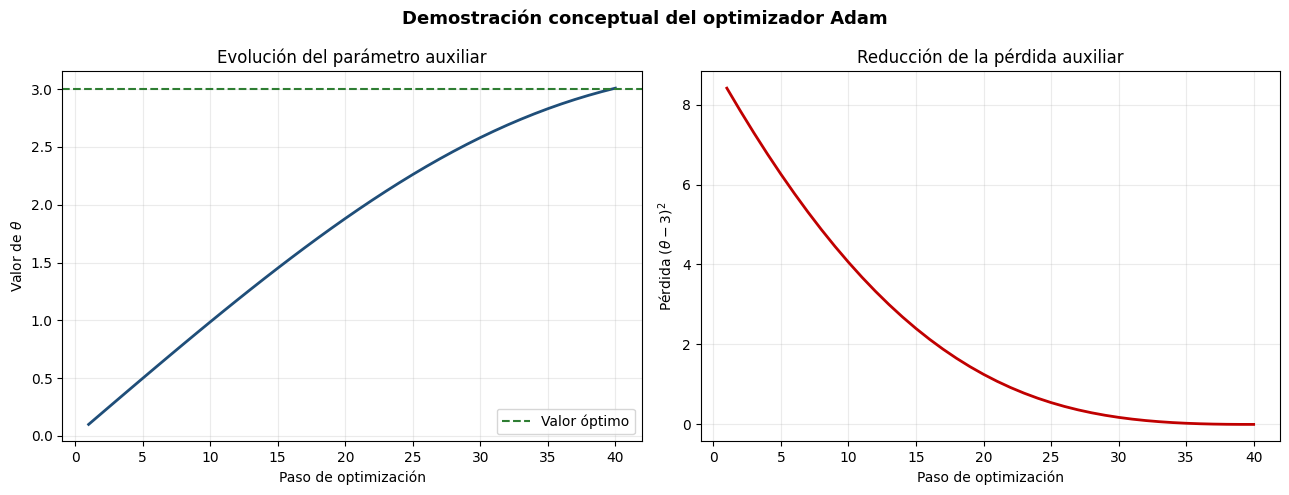

⚠️ La demostración gráfica utiliza learning_rate=0.1 solo para visualizar una función escalar simple.
La MLP mantendrá learning_rate=0.001.

ESTADO DEL OPTIMIZADOR PRINCIPAL
Iteraciones registradas: 0
✅ OPTIMIZER_MLP permanece intacto y preparado para el entrenamiento real.

✅ LOSS_MLP ya se encontraba disponible.

CONFIGURACIÓN POSTERIOR DE model.compile()

modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)

FASE 9.5 FINALIZADA
✅ Se seleccionó Adam como optimizador inicial.
✅ Learning rate inicial: 0.001000.
✅ Beta 1: 0.9.
✅ Beta 2: 0.999.
✅ Epsilon: 1e-07.
✅ Se realizarán aproximadamente 397 actualizaciones por época.
✅ El optimizador es compatible con LOSS_MLP.
✅ Validation se utilizará para evaluar la configuración.
✅ Test permanece reservado para la evaluación final.

OPTIMIZER_MLP está preparado para compilar la arquitectura completa de la MLP.


In [92]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.5 OPTIMIZADOR INICIAL: ADAM
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir y documentar el optimizador Adam que se utilizará
# inicialmente para entrenar la MLP.
#
# La celda permitirá:
#
# 1. Verificar el tamaño del conjunto de entrenamiento.
# 2. Calcular el número de actualizaciones por época.
# 3. Crear Adam con learning rate = 0.001.
# 4. Mostrar sus hiperparámetros.
# 5. Demostrar una actualización sobre una variable auxiliar.
# 6. Preparar el objeto OPTIMIZER_MLP para model.compile().
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda no entrena todavía la MLP y no utiliza el
# conjunto test para ajustar hiperparámetros.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print("=" * 80)
print("FASE 9.5 — OPTIMIZADOR ADAM")
print("=" * 80)

print(
    "✅ Los datasets preparados en la Fase 7 "
    "están disponibles."
)


# ============================================================
# 4. CONFIGURACIÓN INICIAL
# ============================================================

LEARNING_RATE_MLP = 1e-3
BETA_1_MLP = 0.9
BETA_2_MLP = 0.999
EPSILON_MLP = 1e-7
AMSGRAD_MLP = False

# Cantidades obtenidas en las fases anteriores.
N_TRAIN_EXPECTED = 12_702
BATCH_SIZE_EXPECTED = 32

print("\n" + "=" * 80)
print("CONFIGURACIÓN INICIAL PROPUESTA")
print("=" * 80)

print(
    f"Learning rate : {LEARNING_RATE_MLP}"
)

print(
    f"Beta 1        : {BETA_1_MLP}"
)

print(
    f"Beta 2        : {BETA_2_MLP}"
)

print(
    f"Epsilon       : {EPSILON_MLP}"
)

print(
    f"AMSGrad       : {AMSGRAD_MLP}"
)


# ============================================================
# 5. OBTENER LA CARDINALIDAD REAL DEL DATASET
# ============================================================
#
# train_ds_final contiene lotes de 32 imágenes y data
# augmentation aplicada exclusivamente durante entrenamiento.
#
# La cardinalidad representa el número de lotes por época.
# ============================================================

cardinalidad_train = tf.data.experimental.cardinality(
    train_ds_final
)

n_batches_train = int(
    cardinalidad_train.numpy()
)

if n_batches_train < 0:
    raise ValueError(
        "No fue posible determinar la cardinalidad de "
        "train_ds_final."
    )

# Obtener el batch size real desde el primer lote.
imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_final.take(1)
    )
)

batch_size_real = int(
    tf.shape(
        imagenes_batch
    )[0].numpy()
)

# Cálculo teórico a partir de los resultados previos.
steps_per_epoch_teoricos = math.ceil(
    N_TRAIN_EXPECTED
    /
    BATCH_SIZE_EXPECTED
)

print("\n" + "=" * 80)
print("ACTUALIZACIONES POR ÉPOCA")
print("=" * 80)

print(
    f"Imágenes de entrenamiento    : "
    f"{N_TRAIN_EXPECTED:,}"
)

print(
    f"Batch size configurado       : "
    f"{BATCH_SIZE_EXPECTED}"
)

print(
    f"Batch size del primer lote   : "
    f"{batch_size_real}"
)

print(
    f"Lotes observados por época   : "
    f"{n_batches_train}"
)

print(
    f"Lotes calculados teóricamente: "
    f"{steps_per_epoch_teoricos}"
)

assert n_batches_train == steps_per_epoch_teoricos, (
    "La cardinalidad observada no coincide con "
    "ceil(N_train / batch_size)."
)

print(
    "\n✅ Adam realizará aproximadamente "
    f"{n_batches_train} actualizaciones por época."
)


# ============================================================
# 6. CREAR EL OPTIMIZADOR ADAM
# ============================================================
#
# Este será el objeto utilizado posteriormente en:
#
# modelo_mlp.compile(
#     optimizer=OPTIMIZER_MLP,
#     loss=LOSS_MLP,
#     metrics=["accuracy"]
# )
# ============================================================

OPTIMIZER_MLP = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP,
    amsgrad=AMSGRAD_MLP,
    name="adam_mlp"
)

print("\n✅ Optimizador OPTIMIZER_MLP creado correctamente.")


# ============================================================
# 7. RECUPERAR EL LEARNING RATE DE FORMA SEGURA
# ============================================================

def obtener_learning_rate(optimizer):
    """
    Obtiene el learning rate actual de un optimizador Keras.

    La función es compatible tanto con una tasa constante como
    con un posible schedule de learning rate.
    """

    learning_rate = optimizer.learning_rate

    if callable(learning_rate):

        valor = learning_rate(
            optimizer.iterations
        )

    else:

        valor = learning_rate

    return float(
        tf.keras.backend.get_value(
            valor
        )
    )


learning_rate_observado = obtener_learning_rate(
    OPTIMIZER_MLP
)

assert np.isclose(
    learning_rate_observado,
    LEARNING_RATE_MLP
), (
    "El learning rate observado no coincide con "
    "la configuración solicitada."
)

print(
    f"Learning rate verificado: "
    f"{learning_rate_observado:.6f}"
)


# ============================================================
# 8. TABLA DE HIPERPARÁMETROS
# ============================================================

configuracion_adam = (
    OPTIMIZER_MLP.get_config()
)

df_configuracion_adam = pd.DataFrame({
    "Hiperparámetro": [
        "Optimizador",
        "Learning rate",
        "Beta 1",
        "Beta 2",
        "Epsilon",
        "AMSGrad",
        "Clipnorm",
        "Clipvalue",
        "Actualizaciones por época"
    ],

    "Valor": [
        "Adam",
        learning_rate_observado,
        configuracion_adam["beta_1"],
        configuracion_adam["beta_2"],
        configuracion_adam["epsilon"],
        configuracion_adam["amsgrad"],
        configuracion_adam.get(
            "clipnorm",
            None
        ),
        configuracion_adam.get(
            "clipvalue",
            None
        ),
        n_batches_train
    ],

    "Justificación": [
        "Optimizador adaptativo",
        "Punto inicial estándar para Adam",
        "Promedio móvil del gradiente",
        "Promedio móvil del gradiente al cuadrado",
        "Evita divisiones por cero",
        "No se utiliza en el experimento inicial",
        "Sin recorte inicial de norma",
        "Sin recorte inicial por valor",
        "Un paso de Adam por lote"
    ]
})

print("\n" + "=" * 80)
print("HIPERPARÁMETROS DE ADAM")
print("=" * 80)

display(
    df_configuracion_adam
)


# ============================================================
# 9. ESTIMAR ACTUALIZACIONES SEGÚN NÚMERO DE ÉPOCAS
# ============================================================

epocas_referencia = [
    10,
    20,
    30,
    50
]

df_actualizaciones = pd.DataFrame({
    "Épocas máximas": epocas_referencia,
    "Actualizaciones máximas": [
        epocas
        *
        n_batches_train
        for epocas in epocas_referencia
    ]
})

print("\n" + "=" * 80)
print("ACTUALIZACIONES MÁXIMAS DE PARÁMETROS")
print("=" * 80)

display(
    df_actualizaciones.style.format({
        "Actualizaciones máximas": "{:,.0f}"
    })
)

print(
    "\nNota: EarlyStopping puede finalizar el entrenamiento "
    "antes de alcanzar estos valores."
)


# ============================================================
# 10. DEMOSTRACIÓN CONTROLADA DE UNA ACTUALIZACIÓN
# ============================================================
#
# Para no modificar ninguna variable del futuro modelo MLP,
# Adam se demuestra mediante una variable auxiliar.
#
# Función de ejemplo:
#
# f(theta) = (theta - 3)^2
#
# El mínimo se encuentra en theta = 3.
# Partimos desde theta = 0.
# ============================================================

theta_demo = tf.Variable(
    0.0,
    dtype=tf.float32,
    name="theta_demo"
)

# Se utiliza un optimizador independiente para no incrementar
# el contador de iteraciones de OPTIMIZER_MLP.
optimizer_demo = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP,
    amsgrad=AMSGRAD_MLP,
    name="adam_demostracion"
)

theta_antes = float(
    theta_demo.numpy()
)

with tf.GradientTape() as tape:

    loss_demo = tf.square(
        theta_demo
        -
        3.0
    )

gradiente_demo = tape.gradient(
    loss_demo,
    theta_demo
)

loss_antes = float(
    loss_demo.numpy()
)

optimizer_demo.apply_gradients(
    [
        (
            gradiente_demo,
            theta_demo
        )
    ]
)

theta_despues = float(
    theta_demo.numpy()
)

loss_despues = float(
    tf.square(
        theta_demo
        -
        3.0
    ).numpy()
)

print("\n" + "=" * 80)
print("DEMOSTRACIÓN DE UNA ACTUALIZACIÓN")
print("=" * 80)

print(
    f"Parámetro antes      : "
    f"{theta_antes:.8f}"
)

print(
    f"Gradiente calculado  : "
    f"{float(gradiente_demo.numpy()):.8f}"
)

print(
    f"Pérdida antes        : "
    f"{loss_antes:.8f}"
)

print(
    f"Parámetro después    : "
    f"{theta_despues:.8f}"
)

print(
    f"Pérdida después      : "
    f"{loss_despues:.8f}"
)

assert loss_despues < loss_antes, (
    "La actualización demostrativa no redujo la pérdida."
)

print(
    "\n✅ Adam actualizó el parámetro en la dirección "
    "que reduce la pérdida."
)


# ============================================================
# 11. DEMOSTRAR VARIAS ACTUALIZACIONES
# ============================================================
#
# Esta demostración permite observar la evolución del
# parámetro y de la pérdida sin entrenar todavía la MLP.
# ============================================================

theta_trayectoria = tf.Variable(
    0.0,
    dtype=tf.float32
)

optimizer_trayectoria = keras.optimizers.Adam(
    learning_rate=0.1,
    beta_1=BETA_1_MLP,
    beta_2=BETA_2_MLP,
    epsilon=EPSILON_MLP
)

# Se utiliza 0.1 solamente en esta función matemática simple
# para que la trayectoria sea visible en pocas iteraciones.
# Este valor NO reemplaza el learning rate de la MLP.
N_PASOS_DEMO = 40

historial_theta = []
historial_loss = []

for paso in range(N_PASOS_DEMO):

    with tf.GradientTape() as tape:

        loss_actual = tf.square(
            theta_trayectoria
            -
            3.0
        )

    gradiente_actual = tape.gradient(
        loss_actual,
        theta_trayectoria
    )

    optimizer_trayectoria.apply_gradients(
        [
            (
                gradiente_actual,
                theta_trayectoria
            )
        ]
    )

    historial_theta.append(
        float(
            theta_trayectoria.numpy()
        )
    )

    historial_loss.append(
        float(
            tf.square(
                theta_trayectoria
                -
                3.0
            ).numpy()
        )
    )


# ============================================================
# 12. VISUALIZAR LA DEMOSTRACIÓN
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

axes[0].plot(
    range(
        1,
        N_PASOS_DEMO + 1
    ),
    historial_theta,
    color="#1F4E79",
    linewidth=2
)

axes[0].axhline(
    y=3.0,
    color="#2E7D32",
    linestyle="--",
    label="Valor óptimo"
)

axes[0].set_title(
    "Evolución del parámetro auxiliar"
)

axes[0].set_xlabel(
    "Paso de optimización"
)

axes[0].set_ylabel(
    r"Valor de $\theta$"
)

axes[0].grid(
    alpha=0.25
)

axes[0].legend()


axes[1].plot(
    range(
        1,
        N_PASOS_DEMO + 1
    ),
    historial_loss,
    color="#C00000",
    linewidth=2
)

axes[1].set_title(
    "Reducción de la pérdida auxiliar"
)

axes[1].set_xlabel(
    "Paso de optimización"
)

axes[1].set_ylabel(
    r"Pérdida $(\theta-3)^2$"
)

axes[1].grid(
    alpha=0.25
)

plt.suptitle(
    "Demostración conceptual del optimizador Adam",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print(
    "⚠️ La demostración gráfica utiliza learning_rate=0.1 "
    "solo para visualizar una función escalar simple."
)

print(
    "La MLP mantendrá learning_rate=0.001."
)


# ============================================================
# 13. COMPROBAR QUE EL OPTIMIZADOR PRINCIPAL NO FUE USADO
# ============================================================
#
# OPTIMIZER_MLP debe permanecer en cero iteraciones hasta
# compilar y entrenar la arquitectura definitiva.
# ============================================================

iteraciones_optimizer_mlp = int(
    OPTIMIZER_MLP.iterations.numpy()
)

assert iteraciones_optimizer_mlp == 0, (
    "OPTIMIZER_MLP fue utilizado antes del entrenamiento."
)

print("\n" + "=" * 80)
print("ESTADO DEL OPTIMIZADOR PRINCIPAL")
print("=" * 80)

print(
    f"Iteraciones registradas: "
    f"{iteraciones_optimizer_mlp}"
)

print(
    "✅ OPTIMIZER_MLP permanece intacto y preparado "
    "para el entrenamiento real."
)


# ============================================================
# 14. VERIFICAR COMPATIBILIDAD CON LA PÉRDIDA
# ============================================================

if "LOSS_MLP" not in globals():

    LOSS_MLP = (
        keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            name="loss_mlp"
        )
    )

    print(
        "\nℹ️ LOSS_MLP no existía y fue creado "
        "con la configuración correcta."
    )

else:

    print(
        "\n✅ LOSS_MLP ya se encontraba disponible."
    )


# ============================================================
# 15. MOSTRAR CONFIGURACIÓN DE COMPILACIÓN
# ============================================================

print("\n" + "=" * 80)
print("CONFIGURACIÓN POSTERIOR DE model.compile()")
print("=" * 80)

print(
    """
modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=["accuracy"]
)
"""
)


# ============================================================
# 16. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 9.5 FINALIZADA")
print("=" * 80)

print(
    "✅ Se seleccionó Adam como optimizador inicial."
)

print(
    f"✅ Learning rate inicial: "
    f"{LEARNING_RATE_MLP:.6f}."
)

print(
    f"✅ Beta 1: {BETA_1_MLP}."
)

print(
    f"✅ Beta 2: {BETA_2_MLP}."
)

print(
    f"✅ Epsilon: {EPSILON_MLP}."
)

print(
    f"✅ Se realizarán aproximadamente "
    f"{n_batches_train} actualizaciones por época."
)

print(
    "✅ El optimizador es compatible con LOSS_MLP."
)

print(
    "✅ Validation se utilizará para evaluar la "
    "configuración."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nOPTIMIZER_MLP está preparado para compilar "
    "la arquitectura completa de la MLP."
)

## 9.6 Registro de learning rate, batch size, épocas, parámetros y regularización

Antes de entrenar la MLP es necesario registrar formalmente su configuración. Esto permite:

- Reproducir el experimento.
- Comparar posteriormente la MLP con la CNN.
- Interpretar diferencias de rendimiento.
- Controlar la complejidad del modelo.
- Detectar posibles problemas de sobreajuste.
- Evitar cambios de hiperparámetros no documentados.

La configuración inicial propuesta es:

| Componente | Configuración |
|---|---:|
| Resolución de entrada | $128 \times 128 \times 3$ |
| Características después de `Flatten` | $49.152$ |
| Primera capa oculta | 128 neuronas, ReLU |
| Dropout | $0.30$ |
| Segunda capa oculta | 64 neuronas, ReLU |
| Capa de salida | 10 neuronas, softmax |
| Optimizador | Adam |
| Learning rate | $0.001$ |
| Batch size | 32 |
| Épocas máximas | 50 |
| Early stopping | Sí |
| Paciencia | 7 épocas |
| Función de pérdida | Sparse categorical cross-entropy |
| Regularización L2 inicial | No aplicada |
| Data augmentation | Solo en train |

---

### Arquitectura propuesta

La arquitectura inicial de la MLP puede representarse como:

$$
\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}
$$

$$
\mathbf{X}_i \longrightarrow \operatorname{Flatten} \longrightarrow \operatorname{Dense}(128, \operatorname{ReLU}) \longrightarrow \operatorname{Dropout}(0.30)
$$

$$
\longrightarrow \operatorname{Dense}(64, \operatorname{ReLU}) \longrightarrow \operatorname{Dense}(10, \operatorname{softmax})
$$

En forma resumida:

$$
128 \times 128 \times 3 \longrightarrow 49.152 \longrightarrow 128 \longrightarrow 64 \longrightarrow 10
$$

---

### Learning rate

La tasa de aprendizaje inicial será:

$$
\alpha = 0.001 = 10^{-3}
$$

Este valor controla la magnitud de las actualizaciones realizadas por Adam:

$$
\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \alpha \frac{\widehat{\mathbf{m}}_t}{\sqrt{\widehat{\mathbf{v}}_t} + \varepsilon}
$$

Una tasa demasiado alta puede generar inestabilidad, mientras que una tasa demasiado baja puede producir una convergencia lenta.

El valor $10^{-3}$ se utilizará como configuración inicial. Cualquier ajuste posterior deberá justificarse mediante resultados de validación y nunca mediante el conjunto test.

---

### Tamaño de lote

El tamaño de lote será:

$$
B = 32
$$

El conjunto de entrenamiento contiene:

$$
N_{\mathrm{train}} = 12.702
$$

imágenes. Por tanto, el número de lotes por época será:

$$
S = \left\lceil \frac{N_{\mathrm{train}}}{B} \right\rceil
$$

$$
S = \left\lceil \frac{12.702}{32} \right\rceil = 397
$$

Adam realizará aproximadamente 397 actualizaciones de parámetros durante cada época.

---

### Épocas máximas

Se define inicialmente:

$$
E_{\max} = 50
$$

Si el entrenamiento alcanzara las 50 épocas, el número máximo aproximado de actualizaciones sería:

$$
T_{\max} = E_{\max} \cdot S
$$

$$
T_{\max} = 50 \cdot 397 = 19.850
$$

Sin embargo, este valor representa un máximo. El entrenamiento podrá finalizar antes mediante `EarlyStopping`.

---

### Parámetros entrenables

Para una capa densa con $n_{\mathrm{in}}$ entradas y $n_{\mathrm{out}}$ neuronas, la cantidad de parámetros es:

$$
N_{\mathrm{Dense}} = n_{\mathrm{in}} n_{\mathrm{out}} + n_{\mathrm{out}}
$$

o equivalentemente:

$$
N_{\mathrm{Dense}} = (n_{\mathrm{in}} + 1) n_{\mathrm{out}}
$$

El primer término corresponde a los pesos y el segundo a los sesgos.

#### 1. Primera capa densa
La entrada contiene $49.152$ características y la primera capa posee 128 neuronas:

$$
N_1 = (49.152 + 1) \cdot 128
$$

$$
N_1 = 6.291.584
$$

#### 2. Segunda capa densa
La segunda capa recibe 128 entradas y contiene 64 neuronas:

$$
N_2 = (128 + 1) \cdot 64
$$

$$
N_2 = 8.256
$$

#### 3. Capa de salida
La salida recibe 64 entradas y contiene 10 neuronas:

$$
N_3 = (64 + 1) \cdot 10
$$

$$
N_3 = 650
$$

#### 4. Parámetros totales
La cantidad total es:

$$
N_{\mathrm{total}} = N_1 + N_2 + N_3
$$

$$
N_{\mathrm{total}} = 6.291.584 + 8.256 + 650
$$

$$
\boxed{N_{\mathrm{total}} = 6.300.490}
$$

Las capas `Flatten` y `Dropout` no incorporan parámetros:

$$
N_{\mathrm{Flatten}} = 0, \quad N_{\mathrm{Dropout}} = 0
$$

La mayor parte de los parámetros se concentra en la primera capa densa debido a la vectorización de la imagen:

$$
\frac{N_1}{N_{\mathrm{total}}} \cdot 100 \approx 99.86\%
$$

Esto anticipa un riesgo de sobreajuste y constituye una diferencia estructural importante respecto de la CNN.

---

### Regularización mediante Dropout

Se utilizará:

$$
p_{\mathrm{drop}} = 0.30
$$

Durante el entrenamiento, `Dropout` desactiva aleatoriamente una proporción de las activaciones de la capa anterior.

Si $a_j$ representa la activación de la neurona $j$, se genera una máscara:

$$
r_j \sim \operatorname{Bernoulli}(q)
$$

donde la probabilidad de conservación es:

$$
q = 1 - p_{\mathrm{drop}}
$$

En este proyecto:

$$
q = 1 - 0.30 = 0.70
$$

La activación regularizada durante el entrenamiento puede expresarse como:

$$
\widetilde{a}_j = \frac{r_j}{q} a_j
$$

Esta formulación, denominada *inverted dropout*, conserva aproximadamente el valor esperado de las activaciones:

$$
\mathbb{E} \left[ \widetilde{a}_j \right] = a_j
$$

Durante validación, prueba e inferencia, Dropout se desactiva.

---

### Regularización mediante data augmentation

El conjunto de datos de entrenamiento incorpora técnicas de aumento de datos (*data augmentation*) para mejorar la capacidad de generalización del modelo y mitigar el sobreajuste.

In [93]:

# ============================================================
# FASE 9 — MODELO A: RED NEURONAL MULTICAPA (MLP)
# 9.6 REGISTRO DE HIPERPARÁMETROS Y REGULARIZACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir, verificar y registrar:
#
# 1. Learning rate.
# 2. Batch size.
# 3. Épocas máximas.
# 4. Arquitectura.
# 5. Parámetros entrenables.
# 6. Dropout.
# 7. Regularización L2.
# 8. Early stopping.
# 9. Data augmentation.
#
# La celda construye y compila la MLP, pero NO inicia todavía
# el entrenamiento.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import math
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DE ENTRADA
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3

INPUT_SHAPE_MLP = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

FLATTEN_FEATURES = (
    IMAGE_HEIGHT
    *
    IMAGE_WIDTH
    *
    CHANNELS
)

K = int(
    NUM_CLASSES
)

assert K == 10, (
    f"Se esperaban 10 clases, pero se detectaron {K}."
)

assert len(class_names) == K, (
    "class_names no coincide con NUM_CLASSES."
)


# ============================================================
# 5. REGISTRO DE HIPERPARÁMETROS
# ============================================================

# ------------------------------------------------------------
# Optimización
# ------------------------------------------------------------

LEARNING_RATE_MLP = 1e-3
BATCH_SIZE_MLP = 32
MAX_EPOCHS_MLP = 50

# ------------------------------------------------------------
# Arquitectura
# ------------------------------------------------------------

HIDDEN_UNITS_1_MLP = 128
HIDDEN_UNITS_2_MLP = 64

# ------------------------------------------------------------
# Regularización
# ------------------------------------------------------------

DROPOUT_RATE_MLP = 0.30
L2_LAMBDA_MLP = 0.0

# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

EARLY_STOPPING_PATIENCE_MLP = 7
EARLY_STOPPING_MIN_DELTA_MLP = 1e-4

# ------------------------------------------------------------
# Datos conocidos
# ------------------------------------------------------------

N_TRAIN_MLP = 12_702
N_VALIDATION_MLP = 2_722
N_TEST_MLP = 2_722


# ============================================================
# 6. VERIFICAR BATCH SIZE Y CARDINALIDAD
# ============================================================

imagenes_batch, etiquetas_batch = next(
    iter(
        train_ds_final.take(1)
    )
)

batch_size_observado = int(
    tf.shape(
        imagenes_batch
    )[0].numpy()
)

assert batch_size_observado == BATCH_SIZE_MLP, (
    f"Se esperaba batch size {BATCH_SIZE_MLP}, "
    f"pero se observó {batch_size_observado}."
)

steps_per_epoch_teoricos = math.ceil(
    N_TRAIN_MLP
    /
    BATCH_SIZE_MLP
)

cardinalidad_train = int(
    tf.data.experimental.cardinality(
        train_ds_final
    ).numpy()
)

assert cardinalidad_train == steps_per_epoch_teoricos, (
    "La cardinalidad del dataset no coincide con "
    "ceil(N_train / batch_size)."
)

MAX_OPTIMIZER_STEPS_MLP = (
    MAX_EPOCHS_MLP
    *
    steps_per_epoch_teoricos
)

print("=" * 80)
print("FASE 9.6 — CONFIGURACIÓN EXPERIMENTAL DE LA MLP")
print("=" * 80)

print(f"Train                : {N_TRAIN_MLP:,}")
print(f"Validation           : {N_VALIDATION_MLP:,}")
print(f"Test                 : {N_TEST_MLP:,}")
print(f"Batch size           : {BATCH_SIZE_MLP}")
print(f"Pasos por época      : {steps_per_epoch_teoricos}")
print(f"Épocas máximas       : {MAX_EPOCHS_MLP}")
print(
    f"Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS_MLP:,}"
)


# ============================================================
# 7. CONSTRUIR LA ARQUITECTURA MLP
# ============================================================
#
# Arquitectura:
#
# Input(128, 128, 3)
# -> Flatten
# -> Dense(128, ReLU)
# -> Dropout(0.30)
# -> Dense(64, ReLU)
# -> Dense(10, Softmax)
#
# L2 no se aplica en la configuración base porque lambda=0.
# ============================================================

if L2_LAMBDA_MLP > 0:

    regularizador_l2 = keras.regularizers.l2(
        L2_LAMBDA_MLP
    )

else:

    regularizador_l2 = None


modelo_mlp = keras.Sequential(
    [
        layers.Input(
            shape=INPUT_SHAPE_MLP,
            name="imagen_entrada"
        ),

        layers.Flatten(
            name="flatten"
        ),

        layers.Dense(
            units=HIDDEN_UNITS_1_MLP,
            activation="relu",
            kernel_regularizer=regularizador_l2,
            name="dense_128"
        ),

        layers.Dropout(
            rate=DROPOUT_RATE_MLP,
            seed=SEED,
            name="dropout_030"
        ),

        layers.Dense(
            units=HIDDEN_UNITS_2_MLP,
            activation="relu",
            kernel_regularizer=regularizador_l2,
            name="dense_64"
        ),

        layers.Dense(
            units=K,
            activation="softmax",
            name="salida_softmax"
        )
    ],
    name="MLP_PlantVillage"
)


# ============================================================
# 8. CALCULAR PARÁMETROS TEÓRICOS
# ============================================================

PARAMS_DENSE_1 = (
    FLATTEN_FEATURES
    +
    1
) * HIDDEN_UNITS_1_MLP

PARAMS_DENSE_2 = (
    HIDDEN_UNITS_1_MLP
    +
    1
) * HIDDEN_UNITS_2_MLP

PARAMS_OUTPUT = (
    HIDDEN_UNITS_2_MLP
    +
    1
) * K

PARAMS_TOTAL_THEORETICAL = (
    PARAMS_DENSE_1
    +
    PARAMS_DENSE_2
    +
    PARAMS_OUTPUT
)

PARAMS_TOTAL_KERAS = (
    modelo_mlp.count_params()
)

assert PARAMS_TOTAL_KERAS == PARAMS_TOTAL_THEORETICAL, (
    "La cantidad de parámetros reportada por Keras "
    "no coincide con el cálculo teórico."
)


# ============================================================
# 9. TABLA DE PARÁMETROS POR CAPA
# ============================================================

df_parametros_mlp = pd.DataFrame({
    "Capa": [
        "Input",
        "Flatten",
        "Dense 128",
        "Dropout 0.30",
        "Dense 64",
        "Dense 10 Softmax",
        "TOTAL"
    ],

    "Forma de salida": [
        "(None, 128, 128, 3)",
        "(None, 49.152)",
        "(None, 128)",
        "(None, 128)",
        "(None, 64)",
        "(None, 10)",
        "-"
    ],

    "Parámetros": [
        0,
        0,
        PARAMS_DENSE_1,
        0,
        PARAMS_DENSE_2,
        PARAMS_OUTPUT,
        PARAMS_TOTAL_THEORETICAL
    ],

    "Entrenable": [
        "No",
        "No",
        "Sí",
        "No",
        "Sí",
        "Sí",
        "-"
    ]
})

print("\n" + "=" * 80)
print("PARÁMETROS DE LA MLP")
print("=" * 80)

display(
    df_parametros_mlp.style.format({
        "Parámetros": "{:,.0f}"
    })
)


# ============================================================
# 10. CONCENTRACIÓN DE PARÁMETROS
# ============================================================

porcentaje_primera_capa = (
    PARAMS_DENSE_1
    /
    PARAMS_TOTAL_THEORETICAL
    *
    100
)

print(
    f"\nParámetros totales: "
    f"{PARAMS_TOTAL_THEORETICAL:,}"
)

print(
    "Parámetros en la primera capa Dense: "
    f"{PARAMS_DENSE_1:,}"
)

print(
    "Concentración en la primera capa: "
    f"{porcentaje_primera_capa:.2f}%"
)

if porcentaje_primera_capa > 95:

    print(
        "\n⚠️ Más del 95% de los parámetros se concentra "
        "en la primera capa densa."
    )

    print(
        "Esto se debe al aplanamiento de 49.152 píxeles "
        "y constituye un riesgo de sobreajuste."
    )


# ============================================================
# 11. CREAR PÉRDIDA Y OPTIMIZADOR
# ============================================================

LOSS_MLP = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        name="loss_mlp"
    )
)

OPTIMIZER_MLP = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE_MLP,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7,
    name="adam_mlp"
)


# ============================================================
# 12. COMPILAR LA MLP
# ============================================================
#
# Accuracy se registra durante el entrenamiento.
#
# Balanced accuracy, precision macro, recall macro y F1 macro
# se calcularán posteriormente con Scikit-learn.
# ============================================================

modelo_mlp.compile(
    optimizer=OPTIMIZER_MLP,
    loss=LOSS_MLP,
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]
)

print(
    "\n✅ MLP compilada correctamente."
)


# ============================================================
# 13. CONFIGURAR CALLBACKS DE REGULARIZACIÓN
# ============================================================

DIRECTORIO_MODELOS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_MEJOR_MLP = (
    DIRECTORIO_MODELOS
    /
    "mejor_modelo_mlp.keras"
)


early_stopping_mlp = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=EARLY_STOPPING_PATIENCE_MLP,
    min_delta=EARLY_STOPPING_MIN_DELTA_MLP,
    restore_best_weights=True,
    verbose=1
)


checkpoint_mlp = keras.callbacks.ModelCheckpoint(
    filepath=str(
        RUTA_MEJOR_MLP
    ),
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)


callbacks_mlp = [
    early_stopping_mlp,
    checkpoint_mlp
]

print(
    "\n✅ EarlyStopping configurado."
)

print(
    "✅ ModelCheckpoint configurado."
)

print(
    f"Ruta del mejor modelo: "
    f"{RUTA_MEJOR_MLP}"
)


# ============================================================
# 14. REGISTRO DE REGULARIZACIÓN
# ============================================================

df_regularizacion_mlp = pd.DataFrame({
    "Técnica": [
        "Normalización de entrada",
        "Data augmentation",
        "Dropout",
        "Early stopping",
        "Model checkpoint",
        "Regularización L2"
    ],

    "Configuración": [
        "Píxeles en [0, 1]",
        "Flip + Rotation + Zoom",
        f"rate={DROPOUT_RATE_MLP}",
        (
            f"patience="
            f"{EARLY_STOPPING_PATIENCE_MLP}"
        ),
        "Mejor val_loss",
        f"lambda={L2_LAMBDA_MLP}"
    ],

    "Aplicación": [
        "Train, validation y test",
        "Solo train",
        "Solo durante entrenamiento",
        "Monitorea validation",
        "Guarda mejor época",
        (
            "No aplicada en configuración base"
            if L2_LAMBDA_MLP == 0
            else "Aplicada"
        )
    ]
})

print("\n" + "=" * 80)
print("REGULARIZACIÓN REGISTRADA")
print("=" * 80)

display(
    df_regularizacion_mlp
)


# ============================================================
# 15. TABLA CONSOLIDADA DEL EXPERIMENTO
# ============================================================

configuracion_experimento_mlp = {
    "modelo": "MLP",
    "dataset": "PlantVillage - Tomato",
    "numero_clases": K,
    "input_shape": str(INPUT_SHAPE_MLP),
    "flatten_features": FLATTEN_FEATURES,
    "hidden_units_1": HIDDEN_UNITS_1_MLP,
    "hidden_units_2": HIDDEN_UNITS_2_MLP,
    "output_units": K,
    "output_activation": "softmax",
    "loss": "SparseCategoricalCrossentropy",
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE_MLP,
    "batch_size": BATCH_SIZE_MLP,
    "max_epochs": MAX_EPOCHS_MLP,
    "steps_per_epoch": steps_per_epoch_teoricos,
    "max_optimizer_steps": MAX_OPTIMIZER_STEPS_MLP,
    "dropout_rate": DROPOUT_RATE_MLP,
    "l2_lambda": L2_LAMBDA_MLP,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE_MLP
    ),
    "early_stopping_min_delta": (
        EARLY_STOPPING_MIN_DELTA_MLP
    ),
    "data_augmentation": True,
    "train_images": N_TRAIN_MLP,
    "validation_images": N_VALIDATION_MLP,
    "test_images": N_TEST_MLP,
    "trainable_parameters": PARAMS_TOTAL_KERAS,
    "seed": SEED
}

df_configuracion_mlp = pd.DataFrame(
    configuracion_experimento_mlp.items(),
    columns=[
        "Componente",
        "Valor"
    ]
)

print("\n" + "=" * 80)
print("CONFIGURACIÓN CONSOLIDADA DE LA MLP")
print("=" * 80)

display(
    df_configuracion_mlp
)


# ============================================================
# 16. GUARDAR EL REGISTRO
# ============================================================

DIRECTORIO_REPORTES_MLP = Path(
    "/content/plantvillage/reportes_mlp"
)

DIRECTORIO_REPORTES_MLP.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_CONFIG_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "configuracion_mlp.csv"
)

RUTA_CONFIG_JSON = (
    DIRECTORIO_REPORTES_MLP
    /
    "configuracion_mlp.json"
)

RUTA_PARAMETROS_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "parametros_por_capa_mlp.csv"
)

RUTA_REGULARIZACION_CSV = (
    DIRECTORIO_REPORTES_MLP
    /
    "regularizacion_mlp.csv"
)


df_configuracion_mlp.to_csv(
    RUTA_CONFIG_CSV,
    index=False
)

df_parametros_mlp.to_csv(
    RUTA_PARAMETROS_CSV,
    index=False
)

df_regularizacion_mlp.to_csv(
    RUTA_REGULARIZACION_CSV,
    index=False
)

with open(
    RUTA_CONFIG_JSON,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        configuracion_experimento_mlp,
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


print("\n" + "=" * 80)
print("ARCHIVOS DE CONFIGURACIÓN GUARDADOS")
print("=" * 80)

print(
    f"Configuración CSV : {RUTA_CONFIG_CSV}"
)

print(
    f"Configuración JSON: {RUTA_CONFIG_JSON}"
)

print(
    f"Parámetros        : {RUTA_PARAMETROS_CSV}"
)

print(
    f"Regularización    : {RUTA_REGULARIZACION_CSV}"
)


# ============================================================
# 17. MOSTRAR RESUMEN DEL MODELO
# ============================================================

print("\n" + "=" * 80)
print("RESUMEN DE LA ARQUITECTURA")
print("=" * 80)

modelo_mlp.summary()


# ============================================================
# 18. VERIFICAR UNA SALIDA SIN ENTRENAR
# ============================================================
#
# Esta comprobación valida solamente la forma de la salida.
# Las predicciones aún no poseen significado porque el modelo
# no ha sido entrenado.
# ============================================================

predicciones_iniciales = modelo_mlp(
    imagenes_batch,
    training=False
)

forma_salida_observada = tuple(
    predicciones_iniciales.shape
)

forma_salida_esperada = (
    batch_size_observado,
    K
)

assert forma_salida_observada == forma_salida_esperada, (
    "La forma de salida de la MLP no coincide con "
    "la esperada."
)

sumas_probabilidades = tf.reduce_sum(
    predicciones_iniciales,
    axis=1
)

assert np.allclose(
    sumas_probabilidades.numpy(),
    np.ones(batch_size_observado),
    atol=1e-5
), (
    "Las probabilidades de salida no suman uno."
)

print("\n" + "=" * 80)
print("VERIFICACIÓN DE LA SALIDA")
print("=" * 80)

print(
    f"Forma observada: "
    f"{forma_salida_observada}"
)

print(
    "✅ La salida contiene una probabilidad "
    "para cada una de las diez clases."
)

print(
    "✅ Las probabilidades de cada imagen suman uno."
)

print(
    "⚠️ Las predicciones todavía no deben interpretarse "
    "porque la MLP no ha sido entrenada."
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 9.6 FINALIZADA")
print("=" * 80)

print(
    f"✅ Learning rate registrado: "
    f"{LEARNING_RATE_MLP}."
)

print(
    f"✅ Batch size registrado: "
    f"{BATCH_SIZE_MLP}."
)

print(
    f"✅ Épocas máximas registradas: "
    f"{MAX_EPOCHS_MLP}."
)

print(
    f"✅ Parámetros entrenables: "
    f"{PARAMS_TOTAL_KERAS:,}."
)

print(
    f"✅ Dropout registrado: "
    f"{DROPOUT_RATE_MLP:.0%}."
)

print(
    f"✅ Regularización L2 inicial: "
    f"{L2_LAMBDA_MLP}."
)

print(
    f"✅ Early stopping: patience="
    f"{EARLY_STOPPING_PATIENCE_MLP}."
)

print(
    f"✅ Pasos por época: "
    f"{steps_per_epoch_teoricos}."
)

print(
    f"✅ Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS_MLP:,}."
)

print(
    "✅ Data augmentation se mantiene exclusivamente "
    "en train."
)

print(
    "✅ Validation se utilizará para selección."
)

print(
    "✅ Test permanece reservado para evaluación final."
)

print(
    "\nLa MLP está construida, compilada y documentada. "
    "La siguiente etapa corresponde al entrenamiento."
)

FASE 9.6 — CONFIGURACIÓN EXPERIMENTAL DE LA MLP
Train                : 12,702
Validation           : 2,722
Test                 : 2,722
Batch size           : 32
Pasos por época      : 397
Épocas máximas       : 50
Actualizaciones máximas: 19,850

PARÁMETROS DE LA MLP


,Capa,Forma de salida,Parámetros,Entrenable
0,Input,"(None, 128, 128, 3)",0,No
1,Flatten,"(None, 49.152)",0,No
2,Dense 128,"(None, 128)","6,291,584",Sí
3,Dropout 0.30,"(None, 128)",0,No
4,Dense 64,"(None, 64)","8,256",Sí
5,Dense 10 Softmax,"(None, 10)",650,Sí
6,TOTAL,-,"6,300,490",-



Parámetros totales: 6,300,490
Parámetros en la primera capa Dense: 6,291,584
Concentración en la primera capa: 99.86%

⚠️ Más del 95% de los parámetros se concentra en la primera capa densa.
Esto se debe al aplanamiento de 49.152 píxeles y constituye un riesgo de sobreajuste.

✅ MLP compilada correctamente.

✅ EarlyStopping configurado.
✅ ModelCheckpoint configurado.
Ruta del mejor modelo: /content/plantvillage/modelos/mejor_modelo_mlp.keras

REGULARIZACIÓN REGISTRADA


,Técnica,Configuración,Aplicación
0,Normalización de entrada,"Píxeles en [0, 1]","Train, validation y test"
1,Data augmentation,Flip + Rotation + Zoom,Solo train
2,Dropout,rate=0.3,Solo durante entrenamiento
3,Early stopping,patience=7,Monitorea validation
4,Model checkpoint,Mejor val_loss,Guarda mejor época
5,Regularización L2,lambda=0.0,No aplicada en configuración base



CONFIGURACIÓN CONSOLIDADA DE LA MLP


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_030 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,300,490 (24.03 MB)

 Trainable params: 6,300,490 (24.03 MB)

 Non-trainable params: 0 (0.00 B)


VERIFICACIÓN DE LA SALIDA
Forma observada: (32, 10)
✅ La salida contiene una probabilidad para cada una de las diez clases.
✅ Las probabilidades de cada imagen suman uno.
⚠️ Las predicciones todavía no deben interpretarse porque la MLP no ha sido entrenada.

FASE 9.6 FINALIZADA
✅ Learning rate registrado: 0.001.
✅ Batch size registrado: 32.
✅ Épocas máximas registradas: 50.
✅ Parámetros entrenables: 6,300,490.
✅ Dropout registrado: 30%.
✅ Regularización L2 inicial: 0.0.
✅ Early stopping: patience=7.
✅ Pasos por época: 397.
✅ Actualizaciones máximas: 19,850.
✅ Data augmentation se mantiene exclusivamente en train.
✅ Validation se utilizará para selección.
✅ Test permanece reservado para evaluación final.

La MLP está construida, compilada y documentada. La siguiente etapa corresponde al entrenamiento.


# Fase 10 - Modelo B: CNN
La CNN utilizará convoluciones para aprovechar explícitamente la estructura espacial de las imágenes.

## 10.1 Mismos conjuntos de datos utilizados por la MLP

La comparación entre la red neuronal multicapa y la red neuronal convolucional debe realizarse bajo un protocolo experimental común.

La única diferencia principal debe ser la manera en que cada arquitectura procesa las imágenes:

$$\text{MLP} \longrightarrow \text{imagen aplanada} \longrightarrow \text{capas densas}$$

$$\text{CNN} \longrightarrow \text{imagen espacial} \longrightarrow \text{convoluciones}$$

Para evitar que las diferencias de rendimiento se deban a cambios en los datos, la MLP y la CNN utilizarán exactamente las mismas particiones.

---

### Dataset depurado

Después del control de integridad y la eliminación de duplicados exactos, el dataset contiene:

$$N = 18.146$$

imágenes válidas y únicas, distribuidas en:

$$K = 10$$

clases de enfermedades foliares y hojas saludables de tomate.

---

### Particiones comunes

El dataset fue dividido mediante una partición estratificada:

$$70\% \text{ Train} \quad 15\% \text{ Validation} \quad 15\% \text{ Test}$$

Los tamaños obtenidos son:

$$N_{\mathrm{train}} = 12.702$$

$$N_{\mathrm{validation}} = 2.722$$

$$N_{\mathrm{test}} = 2.722$$

y:

$$N_{\mathrm{train}} + N_{\mathrm{validation}} + N_{\mathrm{test}} = 18.146$$

Por tanto:

$$12.702 + 2.722 + 2.722 = 18.146$$

---

### Igualdad de las particiones entre modelos

Sea:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{MLP}}$$

el conjunto de entrenamiento utilizado por la MLP y:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{CNN}}$$

el conjunto de entrenamiento utilizado por la CNN.

Para garantizar una comparación justa debe cumplirse:

$$\mathcal{D}_{\mathrm{train}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{train}}^{\mathrm{CNN}}$$

De la misma manera:

$$\mathcal{D}_{\mathrm{validation}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{validation}}^{\mathrm{CNN}}$$

$$\mathcal{D}_{\mathrm{test}}^{\mathrm{MLP}} = \mathcal{D}_{\mathrm{test}}^{\mathrm{CNN}}$$

Esto significa que:
- Las mismas imágenes de entrenamiento se utilizan en ambos modelos.
- Las mismas imágenes de validación se utilizan en ambos modelos.
- Las mismas imágenes de prueba se utilizan en ambos modelos.
- Ninguna imagen se traslada entre particiones.
- No se crea un nuevo split para la CNN.
- No se utiliza una semilla diferente para generar otra división.

---

### Disjunción entre las particiones

Además de ser iguales entre modelos, los conjuntos deben permanecer disjuntos:

$$\mathcal{D}_{\mathrm{train}} \cap \mathcal{D}_{\mathrm{validation}} = \varnothing$$

$$\mathcal{D}_{\mathrm{train}} \cap \mathcal{D}_{\mathrm{test}} = \varnothing$$

$$\mathcal{D}_{\mathrm{validation}} \cap \mathcal{D}_{\mathrm{test}} = \varnothing$$

Esta condición evita que una imagen utilizada para ajustar los pesos aparezca también durante la evaluación.

---

### Mismo orden de las clases

La relación entre índice y nombre de clase debe ser idéntica:

$$f_{\mathrm{MLP}}(k) = f_{\mathrm{CNN}}(k) = \texttt{class\_names}[k]$$

para:

$$k \in \{0, 1, \ldots, 9\}$$

Por ejemplo, la neurona de salida ubicada en la posición $k$ debe representar la misma clase en ambos modelos.

Si el orden fuera diferente, las predicciones no serían comparables, aunque ambos modelos tuvieran diez neuronas de salida.

---

### Mismo preprocesamiento

Las imágenes utilizadas por ambos modelos mantienen:

$$H \times W \times C = 128 \times 128 \times 3$$

y valores normalizados mediante:

$$x'_{h,w,c} = \frac{x_{h,w,c}}{255}$$

de modo que:

$$x'_{h,w,c} \in [0, 1]$$

Por tanto, la entrada posee la misma escala y resolución para ambas arquitecturas.

---

### Pipeline común

Los datasets definidos en la Fase 7 se reutilizan directamente:

| Objeto común | Contenido | Uso |
|---|---|---|
| `train_ds_final` | Resize + normalización + augmentation | Entrenamiento |
| `val_ds_final` | Resize + normalización | Selección y validación |
| `test_ds_final` | Resize + normalización | Evaluación final |

Para documentar explícitamente su uso por la CNN se definirán alias:

```python
train_ds_cnn = train_ds_final
val_ds_cnn = val_ds_final
test_ds_cnn = test_ds_final

In [94]:


# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.1 MISMOS CONJUNTOS DE DATOS UTILIZADOS POR LA MLP
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Verificar y documentar que la MLP y la CNN utilizarán:
#
# 1. Las mismas particiones físicas.
# 2. Las mismas cantidades de imágenes.
# 3. Las mismas diez clases.
# 4. El mismo orden índice-clase.
# 5. La misma resolución de entrada.
# 6. La misma normalización.
# 7. La misma política de data augmentation en train.
# 8. Validation y test sin augmentation.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda NO:
#
# - vuelve a dividir los datos;
# - crea un nuevo conjunto para la CNN;
# - mueve imágenes entre particiones;
# - entrena la CNN;
# - utiliza test para seleccionar hiperparámetros.
#
# Los objetos construidos en la Fase 7 se reutilizan
# directamente.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import json
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "train_ds_norm",
    "val_ds_norm",
    "test_ds_norm",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )

print("=" * 80)
print("FASE 10.1 — DATASETS COMUNES PARA MLP Y CNN")
print("=" * 80)

print(
    "✅ Los datasets creados en la Fase 7 "
    "se encuentran disponibles."
)


# ============================================================
# 4. CONFIGURACIÓN ESPERADA
# ============================================================

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
CHANNELS = 3
BATCH_SIZE = 32

INPUT_SHAPE = (
    IMAGE_HEIGHT,
    IMAGE_WIDTH,
    CHANNELS
)

N_TRAIN_EXPECTED = 12_702
N_VALIDATION_EXPECTED = 2_722
N_TEST_EXPECTED = 2_722
N_TOTAL_EXPECTED = 18_146
NUM_CLASSES_EXPECTED = 10

assert int(NUM_CLASSES) == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {NUM_CLASSES}."
)

assert len(class_names) == NUM_CLASSES_EXPECTED, (
    "class_names no contiene exactamente diez clases."
)


# ============================================================
# 5. CREAR ALIAS EXPLÍCITOS PARA LA MLP
# ============================================================
#
# Si estos alias ya fueron creados en la Fase 9, se reutilizan.
# Si no existen, se asocian directamente con los datasets
# finales de la Fase 7.
# ============================================================

if "train_ds_mlp" not in globals():
    train_ds_mlp = train_ds_final

if "val_ds_mlp" not in globals():
    val_ds_mlp = val_ds_final

if "test_ds_mlp" not in globals():
    test_ds_mlp = test_ds_final


# ============================================================
# 6. CREAR ALIAS EXPLÍCITOS PARA LA CNN
# ============================================================
#
# No se copian ni reconstruyen los datos.
#
# Los alias de la CNN apuntan a los mismos objetos utilizados
# por la MLP.
# ============================================================

train_ds_cnn = train_ds_final
val_ds_cnn = val_ds_final
test_ds_cnn = test_ds_final


# ============================================================
# 7. VERIFICAR IDENTIDAD DE LOS OBJETOS
# ============================================================
#
# El operador "is" confirma que ambos nombres apuntan al mismo
# objeto tf.data.Dataset en memoria.
# ============================================================

identidad_train = (
    train_ds_mlp
    is
    train_ds_cnn
)

identidad_validation = (
    val_ds_mlp
    is
    val_ds_cnn
)

identidad_test = (
    test_ds_mlp
    is
    test_ds_cnn
)

assert identidad_train, (
    "MLP y CNN no apuntan al mismo dataset de entrenamiento."
)

assert identidad_validation, (
    "MLP y CNN no apuntan al mismo dataset de validación."
)

assert identidad_test, (
    "MLP y CNN no apuntan al mismo dataset de prueba."
)

print("\n" + "=" * 80)
print("IDENTIDAD DE LOS DATASETS")
print("=" * 80)

print(
    f"Train MLP is Train CNN           : "
    f"{identidad_train}"
)

print(
    f"Validation MLP is Validation CNN : "
    f"{identidad_validation}"
)

print(
    f"Test MLP is Test CNN             : "
    f"{identidad_test}"
)

print(
    "\n✅ Ambas arquitecturas utilizarán "
    "los mismos objetos tf.data.Dataset."
)


# ============================================================
# 8. FUNCIÓN PARA OBTENER LA CARDINALIDAD
# ============================================================

def obtener_cardinalidad(dataset, nombre):
    """
    Obtiene el número de lotes de un tf.data.Dataset.

    Parámetros
    ----------
    dataset : tf.data.Dataset
        Dataset que se desea inspeccionar.

    nombre : str
        Nombre utilizado en mensajes de error.

    Retorna
    -------
    int
        Número de lotes del dataset.
    """

    cardinalidad = int(
        tf.data.experimental.cardinality(
            dataset
        ).numpy()
    )

    if cardinalidad < 0:
        raise ValueError(
            f"No fue posible determinar la cardinalidad "
            f"del conjunto {nombre}."
        )

    return cardinalidad


# ============================================================
# 9. VERIFICAR CANTIDAD DE LOTES
# ============================================================

batches_train_mlp = obtener_cardinalidad(
    train_ds_mlp,
    "Train MLP"
)

batches_train_cnn = obtener_cardinalidad(
    train_ds_cnn,
    "Train CNN"
)

batches_val_mlp = obtener_cardinalidad(
    val_ds_mlp,
    "Validation MLP"
)

batches_val_cnn = obtener_cardinalidad(
    val_ds_cnn,
    "Validation CNN"
)

batches_test_mlp = obtener_cardinalidad(
    test_ds_mlp,
    "Test MLP"
)

batches_test_cnn = obtener_cardinalidad(
    test_ds_cnn,
    "Test CNN"
)

assert batches_train_mlp == batches_train_cnn
assert batches_val_mlp == batches_val_cnn
assert batches_test_mlp == batches_test_cnn


# ============================================================
# 10. TABLA DE CANTIDADES
# ============================================================

df_datasets_comunes = pd.DataFrame({
    "Partición": [
        "Train",
        "Validation",
        "Test",
        "TOTAL"
    ],

    "Imágenes MLP": [
        N_TRAIN_EXPECTED,
        N_VALIDATION_EXPECTED,
        N_TEST_EXPECTED,
        N_TOTAL_EXPECTED
    ],

    "Imágenes CNN": [
        N_TRAIN_EXPECTED,
        N_VALIDATION_EXPECTED,
        N_TEST_EXPECTED,
        N_TOTAL_EXPECTED
    ],

    "Lotes MLP": [
        batches_train_mlp,
        batches_val_mlp,
        batches_test_mlp,
        (
            batches_train_mlp
            +
            batches_val_mlp
            +
            batches_test_mlp
        )
    ],

    "Lotes CNN": [
        batches_train_cnn,
        batches_val_cnn,
        batches_test_cnn,
        (
            batches_train_cnn
            +
            batches_val_cnn
            +
            batches_test_cnn
        )
    ]
})

df_datasets_comunes["Misma cantidad"] = (
    df_datasets_comunes["Imágenes MLP"]
    ==
    df_datasets_comunes["Imágenes CNN"]
)

print("\n" + "=" * 80)
print("CANTIDADES UTILIZADAS POR CADA MODELO")
print("=" * 80)

display(
    df_datasets_comunes.style.format({
        "Imágenes MLP": "{:,.0f}",
        "Imágenes CNN": "{:,.0f}",
        "Lotes MLP": "{:,.0f}",
        "Lotes CNN": "{:,.0f}"
    })
)

assert df_datasets_comunes[
    "Misma cantidad"
].all(), (
    "Se detectaron cantidades diferentes entre MLP y CNN."
)


# ============================================================
# 11. VERIFICAR element_spec
# ============================================================
#
# element_spec describe la estructura, forma y tipo de los
# tensores entregados por cada dataset.
# ============================================================

assert train_ds_mlp.element_spec == train_ds_cnn.element_spec, (
    "El formato de Train no coincide entre MLP y CNN."
)

assert val_ds_mlp.element_spec == val_ds_cnn.element_spec, (
    "El formato de Validation no coincide entre MLP y CNN."
)

assert test_ds_mlp.element_spec == test_ds_cnn.element_spec, (
    "El formato de Test no coincide entre MLP y CNN."
)

print("\n" + "=" * 80)
print("ESTRUCTURA DE LOS DATASETS")
print("=" * 80)

print(
    "Train element_spec:"
)

print(
    train_ds_cnn.element_spec
)

print(
    "\nValidation element_spec:"
)

print(
    val_ds_cnn.element_spec
)

print(
    "\nTest element_spec:"
)

print(
    test_ds_cnn.element_spec
)

print(
    "\n✅ MLP y CNN reciben tensores con la misma estructura."
)


# ============================================================
# 12. AUDITAR FORMA, TIPO Y RANGO
# ============================================================

def auditar_lote(dataset, nombre):
    """
    Inspecciona el primer lote de un dataset.

    No modifica ni entrena ningún modelo.
    """

    imagenes, etiquetas = next(
        iter(
            dataset.take(1)
        )
    )

    forma_imagen = tuple(
        imagenes.shape[1:]
    )

    valor_minimo = float(
        tf.reduce_min(
            imagenes
        ).numpy()
    )

    valor_maximo = float(
        tf.reduce_max(
            imagenes
        ).numpy()
    )

    etiqueta_minima = int(
        tf.reduce_min(
            etiquetas
        ).numpy()
    )

    etiqueta_maxima = int(
        tf.reduce_max(
            etiquetas
        ).numpy()
    )

    assert forma_imagen == INPUT_SHAPE, (
        f"{nombre}: forma inesperada {forma_imagen}."
    )

    assert imagenes.dtype == tf.float32, (
        f"{nombre}: las imágenes no son float32."
    )

    assert valor_minimo >= -1e-6, (
        f"{nombre}: existen valores menores que cero."
    )

    assert valor_maximo <= 1.0 + 1e-6, (
        f"{nombre}: existen valores mayores que uno."
    )

    assert etiquetas.dtype in (
        tf.int32,
        tf.int64
    ), (
        f"{nombre}: las etiquetas no son enteras."
    )

    assert etiqueta_minima >= 0
    assert etiqueta_maxima < NUM_CLASSES_EXPECTED

    return {
        "Conjunto": nombre,
        "Forma del lote": str(
            tuple(
                imagenes.shape
            )
        ),
        "Forma por imagen": str(
            forma_imagen
        ),
        "Tipo de imagen": imagenes.dtype.name,
        "Tipo de etiqueta": etiquetas.dtype.name,
        "Mínimo": valor_minimo,
        "Máximo": valor_maximo,
        "Etiqueta mínima": etiqueta_minima,
        "Etiqueta máxima": etiqueta_maxima
    }


# Se utilizan los datasets normalizados sin augmentation para
# verificar de manera determinista la escala de entrada.
resultados_auditoria = [
    auditar_lote(
        train_ds_norm,
        "Train común"
    ),

    auditar_lote(
        val_ds_norm,
        "Validation común"
    ),

    auditar_lote(
        test_ds_norm,
        "Test común"
    )
]

df_auditoria_datasets = pd.DataFrame(
    resultados_auditoria
)

print("\n" + "=" * 80)
print("AUDITORÍA DE LA ENTRADA COMÚN")
print("=" * 80)

display(
    df_auditoria_datasets.round(6)
)


# ============================================================
# 13. VERIFICAR ORDEN DE LAS CLASES
# ============================================================

class_names_mlp = list(
    class_names
)

class_names_cnn = list(
    class_names
)

assert class_names_mlp == class_names_cnn, (
    "El orden de las clases no coincide."
)

df_orden_clases = pd.DataFrame({
    "Índice": np.arange(
        NUM_CLASSES_EXPECTED
    ),
    "Clase MLP": class_names_mlp,
    "Clase CNN": class_names_cnn
})

df_orden_clases["Coincide"] = (
    df_orden_clases["Clase MLP"]
    ==
    df_orden_clases["Clase CNN"]
)

print("\n" + "=" * 80)
print("ORDEN ÍNDICE–CLASE")
print("=" * 80)

display(
    df_orden_clases
)

assert df_orden_clases[
    "Coincide"
].all(), (
    "Existe una diferencia en el orden de las clases."
)


# ============================================================
# 14. RECUPERAR LOS MANIFIESTOS DE LA PARTICIÓN
# ============================================================
#
# En la Fase 6 se generaron manifiestos con las imágenes
# asignadas a Train, Validation y Test.
#
# Estos archivos permiten verificar la composición física de
# las particiones sin depender del orden aleatorio de los
# lotes.
# ============================================================

DIRECTORIO_REPORTES_FASE6 = Path(
    "/content/plantvillage/reportes_fase6"
)

RUTA_MANIFEST_TRAIN = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_train.csv"
)

RUTA_MANIFEST_VALIDATION = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_validation.csv"
)

RUTA_MANIFEST_TEST = (
    DIRECTORIO_REPORTES_FASE6
    /
    "manifest_test.csv"
)

rutas_manifiestos = {
    "Train": RUTA_MANIFEST_TRAIN,
    "Validation": RUTA_MANIFEST_VALIDATION,
    "Test": RUTA_MANIFEST_TEST
}

manifiestos_disponibles = all(
    ruta.exists()
    for ruta in rutas_manifiestos.values()
)


# ============================================================
# 15. FUNCIÓN PARA DETECTAR LA COLUMNA DE RUTA
# ============================================================

def detectar_columna_ruta(dataframe):
    """
    Identifica la columna que contiene las rutas de archivos.
    """

    candidatos = [
        "ruta",
        "ruta_origen",
        "ruta_archivo",
        "filepath",
        "path"
    ]

    for columna in candidatos:

        if columna in dataframe.columns:
            return columna

    raise KeyError(
        "No se encontró una columna de ruta en el manifiesto. "
        f"Columnas disponibles: {list(dataframe.columns)}"
    )


# ============================================================
# 16. VERIFICAR DISJUNCIÓN DE LOS MANIFIESTOS
# ============================================================

if manifiestos_disponibles:

    manifest_train = pd.read_csv(
        RUTA_MANIFEST_TRAIN
    )

    manifest_validation = pd.read_csv(
        RUTA_MANIFEST_VALIDATION
    )

    manifest_test = pd.read_csv(
        RUTA_MANIFEST_TEST
    )

    columna_train = detectar_columna_ruta(
        manifest_train
    )

    columna_validation = detectar_columna_ruta(
        manifest_validation
    )

    columna_test = detectar_columna_ruta(
        manifest_test
    )

    rutas_train = set(
        manifest_train[
            columna_train
        ].astype(str)
    )

    rutas_validation = set(
        manifest_validation[
            columna_validation
        ].astype(str)
    )

    rutas_test = set(
        manifest_test[
            columna_test
        ].astype(str)
    )

    interseccion_train_validation = (
        rutas_train
        &
        rutas_validation
    )

    interseccion_train_test = (
        rutas_train
        &
        rutas_test
    )

    interseccion_validation_test = (
        rutas_validation
        &
        rutas_test
    )

    assert len(
        interseccion_train_validation
    ) == 0, (
        "Existe solapamiento entre Train y Validation."
    )

    assert len(
        interseccion_train_test
    ) == 0, (
        "Existe solapamiento entre Train y Test."
    )

    assert len(
        interseccion_validation_test
    ) == 0, (
        "Existe solapamiento entre Validation y Test."
    )

    print("\n" + "=" * 80)
    print("DISJUNCIÓN DE LAS PARTICIONES")
    print("=" * 80)

    print(
        "Train ∩ Validation: "
        f"{len(interseccion_train_validation)}"
    )

    print(
        "Train ∩ Test      : "
        f"{len(interseccion_train_test)}"
    )

    print(
        "Validation ∩ Test : "
        f"{len(interseccion_validation_test)}"
    )

    print(
        "\n✅ Las particiones físicas permanecen disjuntas."
    )

else:

    print("\n" + "=" * 80)
    print("VERIFICACIÓN DE MANIFIESTOS")
    print("=" * 80)

    print(
        "⚠️ No se encontraron todos los manifiestos "
        "de la Fase 6."
    )

    print(
        "La igualdad entre modelos sí fue confirmada mediante "
        "la identidad de los objetos tf.data.Dataset."
    )


# ============================================================
# 17. HUELLA DE LOS MANIFIESTOS
# ============================================================
#
# Se calcula una huella SHA-256 del conjunto ordenado de rutas.
# La huella no representa el contenido de cada imagen; permite
# registrar la composición exacta de cada manifiesto.
# ============================================================

def calcular_huella_rutas(rutas):
    """
    Calcula SHA-256 sobre una lista ordenada de rutas.
    """

    contenido = "\n".join(
        sorted(
            str(ruta)
            for ruta in rutas
        )
    )

    return hashlib.sha256(
        contenido.encode(
            "utf-8"
        )
    ).hexdigest()


huellas_particiones = {}

if manifiestos_disponibles:

    huellas_particiones = {
        "Train": calcular_huella_rutas(
            rutas_train
        ),

        "Validation": calcular_huella_rutas(
            rutas_validation
        ),

        "Test": calcular_huella_rutas(
            rutas_test
        )
    }

    df_huellas = pd.DataFrame({
        "Partición": list(
            huellas_particiones.keys()
        ),
        "Huella SHA-256 del manifiesto": list(
            huellas_particiones.values()
        )
    })

    print("\n" + "=" * 80)
    print("HUELLAS DE LAS PARTICIONES")
    print("=" * 80)

    display(
        df_huellas
    )


# ============================================================
# 18. PROTOCOLO COMÚN MLP–CNN
# ============================================================

df_protocolo_comun = pd.DataFrame({
    "Componente": [
        "Partición Train",
        "Partición Validation",
        "Partición Test",
        "Resolución",
        "Canales",
        "Normalización",
        "Batch size",
        "Número de clases",
        "Orden de clases",
        "Data augmentation Train",
        "Data augmentation Validation",
        "Data augmentation Test",
        "Semilla",
        "Uso de Test"
    ],

    "MLP": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        "128 × 128",
        "RGB",
        "[0, 1]",
        32,
        10,
        "class_names",
        "Sí",
        "No",
        "No",
        42,
        "Solo evaluación final"
    ],

    "CNN": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        "128 × 128",
        "RGB",
        "[0, 1]",
        32,
        10,
        "class_names",
        "Sí",
        "No",
        "No",
        42,
        "Solo evaluación final"
    ]
})

df_protocolo_comun["Coincide"] = (
    df_protocolo_comun["MLP"].astype(str)
    ==
    df_protocolo_comun["CNN"].astype(str)
)

print("\n" + "=" * 80)
print("PROTOCOLO EXPERIMENTAL COMÚN")
print("=" * 80)

display(
    df_protocolo_comun
)

assert df_protocolo_comun[
    "Coincide"
].all(), (
    "Se detectaron diferencias entre los protocolos."
)


# ============================================================
# 19. GUARDAR REGISTRO DE COMPARABILIDAD
# ============================================================

DIRECTORIO_REPORTES_CNN = Path(
    "/content/plantvillage/reportes_cnn"
)

DIRECTORIO_REPORTES_CNN.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_PROTOCOLO_CSV = (
    DIRECTORIO_REPORTES_CNN
    /
    "protocolo_datos_comun_mlp_cnn.csv"
)

RUTA_PROTOCOLO_JSON = (
    DIRECTORIO_REPORTES_CNN
    /
    "protocolo_datos_comun_mlp_cnn.json"
)

df_protocolo_comun.to_csv(
    RUTA_PROTOCOLO_CSV,
    index=False
)

registro_protocolo = {
    "seed": SEED,
    "input_shape": str(INPUT_SHAPE),
    "batch_size": BATCH_SIZE,
    "num_classes": NUM_CLASSES_EXPECTED,
    "train_images": N_TRAIN_EXPECTED,
    "validation_images": N_VALIDATION_EXPECTED,
    "test_images": N_TEST_EXPECTED,
    "total_images": N_TOTAL_EXPECTED,
    "train_dataset_common": identidad_train,
    "validation_dataset_common": identidad_validation,
    "test_dataset_common": identidad_test,
    "augmentation_train": True,
    "augmentation_validation": False,
    "augmentation_test": False,
    "test_reserved": True,
    "manifest_fingerprints": huellas_particiones
}

with open(
    RUTA_PROTOCOLO_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_protocolo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 80)
print("REGISTRO GUARDADO")
print("=" * 80)

print(
    f"CSV : {RUTA_PROTOCOLO_CSV}"
)

print(
    f"JSON: {RUTA_PROTOCOLO_JSON}"
)


# ============================================================
# 20. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("FASE 10.1 FINALIZADA")
print("=" * 80)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_TRAIN_EXPECTED:,} imágenes de entrenamiento."
)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_VALIDATION_EXPECTED:,} imágenes de validación."
)

print(
    f"✅ MLP y CNN utilizarán las mismas "
    f"{N_TEST_EXPECTED:,} imágenes de prueba."
)

print(
    f"✅ Ambas arquitecturas reciben imágenes "
    f"{IMAGE_HEIGHT} × {IMAGE_WIDTH} × {CHANNELS}."
)

print(
    "✅ Las imágenes se encuentran normalizadas en [0, 1]."
)

print(
    f"✅ Ambas arquitecturas utilizan las mismas "
    f"{NUM_CLASSES_EXPECTED} clases."
)

print(
    "✅ El orden índice–clase es idéntico."
)

print(
    "✅ Data augmentation se aplica exclusivamente en Train."
)

print(
    "✅ Validation y Test permanecen sin augmentation."
)

print(
    "✅ No se creó una nueva división para la CNN."
)

print(
    "✅ Test permanece reservado para la evaluación final."
)

print(
    "\nLos datos están preparados para construir "
    "la arquitectura CNN bajo un protocolo comparable "
    "con la MLP."
)

FASE 10.1 — DATASETS COMUNES PARA MLP Y CNN
✅ Los datasets creados en la Fase 7 se encuentran disponibles.

IDENTIDAD DE LOS DATASETS
Train MLP is Train CNN           : True
Validation MLP is Validation CNN : True
Test MLP is Test CNN             : True

✅ Ambas arquitecturas utilizarán los mismos objetos tf.data.Dataset.

CANTIDADES UTILIZADAS POR CADA MODELO


,Partición,Imágenes MLP,Imágenes CNN,Lotes MLP,Lotes CNN,Misma cantidad
0,Train,"12,702","12,702",397,397,True
1,Validation,"2,722","2,722",86,86,True
2,Test,"2,722","2,722",86,86,True
3,TOTAL,"18,146","18,146",569,569,True



ESTRUCTURA DE LOS DATASETS
Train element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Validation element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

Test element_spec:
(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))

✅ MLP y CNN reciben tensores con la misma estructura.

AUDITORÍA DE LA ENTRADA COMÚN


,Conjunto,Forma del lote,Forma por imagen,Tipo de imagen,Tipo de etiqueta,Mínimo,Máximo,Etiqueta mínima,Etiqueta máxima
0,Train común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.924510,0,9
1,Validation común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.988235,0,0
2,Test común,"(32, 128, 128, 3)","(128, 128, 3)",float32,int32,0.0,0.970588,0,0



ORDEN ÍNDICE–CLASE


...


DISJUNCIÓN DE LAS PARTICIONES
Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

✅ Las particiones físicas permanecen disjuntas.

HUELLAS DE LAS PARTICIONES


,Partición,Huella SHA-256 del manifiesto
0,Train,b216b4c4207a097e791c427442790cb56bb73f5af7a23b...
1,Validation,de7c3e54c4bbb9621f71e1874fe2df3b924faa6ac803b4...
2,Test,bf2492a3e734d38228ba2468f66f40bd73e67228fb30be...



PROTOCOLO EXPERIMENTAL COMÚN


,Componente,MLP,CNN,Coincide
0,Partición Train,train_ds_final,train_ds_final,True
1,Partición Validation,val_ds_final,val_ds_final,True
2,Partición Test,test_ds_final,test_ds_final,True
3,Resolución,128 × 128,128 × 128,True
4,Canales,RGB,RGB,True
5,Normalización,"[0, 1]","[0, 1]",True
6,Batch size,32,32,True
7,Número de clases,10,10,True
8,Orden de clases,class_names,class_names,True
9,Data augmentation Train,Sí,Sí,True



REGISTRO GUARDADO
CSV : /content/plantvillage/reportes_cnn/protocolo_datos_comun_mlp_cnn.csv
JSON: /content/plantvillage/reportes_cnn/protocolo_datos_comun_mlp_cnn.json

FASE 10.1 FINALIZADA
✅ MLP y CNN utilizarán las mismas 12,702 imágenes de entrenamiento.
✅ MLP y CNN utilizarán las mismas 2,722 imágenes de validación.
✅ MLP y CNN utilizarán las mismas 2,722 imágenes de prueba.
✅ Ambas arquitecturas reciben imágenes 128 × 128 × 3.
✅ Las imágenes se encuentran normalizadas en [0, 1].
✅ Ambas arquitecturas utilizan las mismas 10 clases.
✅ El orden índice–clase es idéntico.
✅ Data augmentation se aplica exclusivamente en Train.
✅ Validation y Test permanecen sin augmentation.
✅ No se creó una nueva división para la CNN.
✅ Test permanece reservado para la evaluación final.

Los datos están preparados para construir la arquitectura CNN bajo un protocolo comparable con la MLP.


## 10.2 Métricas comunes para permitir una comparación justa

La comparación entre la MLP y la CNN debe realizarse utilizando exactamente las mismas métricas y los mismos conjuntos de datos.

El protocolo común será:

$$\text{MLP} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{validation}} \right)$$

$$\text{CNN} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{validation}} \right)$$

donde:
- $\mathcal{M}$ representa el conjunto común de métricas.
- $\mathcal{D}_{\mathrm{validation}}$ es el mismo conjunto de validación para ambas arquitecturas.

Después de seleccionar las configuraciones finales, el mismo procedimiento se aplicará una sola vez sobre test:

$$\text{MLP final} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{test}} \right)$$

$$\text{CNN final} \longrightarrow \mathcal{M} \left( \mathcal{D}_{\mathrm{test}} \right)$$

---

### Protocolo común de evaluación

Las métricas seleccionadas son:

| Tipo | Métrica | Función |
|---|---|---|
| Optimización | Loss | Medir el error probabilístico |
| Rendimiento global | Accuracy | Proporción total de aciertos |
| Rendimiento balanceado | Balanced accuracy | Promedio del recall por clase |
| Rendimiento macro | Precision macro | Promedio de precision por clase |
| Rendimiento macro | Recall macro | Promedio de recall por clase |
| Métrica principal | F1 macro | Equilibrio macro entre precision y recall |
| Métrica secundaria | F1 weighted | Rendimiento ponderado por soporte |
| Análisis detallado | Métricas por clase | Identificar clases difíciles |
| Análisis gráfico | Matriz de confusión | Examinar confusiones sistemáticas |

---

### Notación

Sea:

$$N = \vert{}\mathcal{D}\vert{}$$

la cantidad de imágenes del conjunto evaluado y:

$$K = 10$$

el número de clases.

Para cada clase $k$, se definen:
- $TP_k$: verdaderos positivos.
- $FP_k$: falsos positivos.
- $FN_k$: falsos negativos.
- $TN_k$: verdaderos negativos.

En un problema multiclase, estas cantidades se calculan tratando cada clase mediante una estrategia *one-vs-rest*.

---

### Función de pérdida

La pérdida común será:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \left( \hat{p}_{i,y_i} \right)$$

donde:
- $y_i$ es la clase verdadera.
- $\hat{p}_{i,y_i}$ es la probabilidad asignada a la clase correcta.

Tanto la MLP como la CNN utilizarán:

```python
SparseCategoricalCrossentropy(
    from_logits=False
)

In [95]:


# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.2 MÉTRICAS COMUNES PARA COMPARACIÓN JUSTA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir un protocolo único de evaluación para:
#
# - Baseline.
# - MLP.
# - CNN.
#
# Métricas:
#
# 1. Loss.
# 2. Accuracy.
# 3. Balanced accuracy.
# 4. Precision macro.
# 5. Recall macro.
# 6. F1 macro.
# 7. F1 weighted.
# 8. Métricas por clase.
# 9. Matriz de confusión.
#
# IMPORTANTE
# ------------------------------------------------------------
# La función de evaluación queda protegida para evitar el uso
# accidental de test durante el desarrollo.
#
# Test solo podrá evaluarse estableciendo explícitamente:
#
# permitir_test=True
#
# después de congelar las decisiones experimentales.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED = 42

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR OBJETOS NECESARIOS
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 7."
    )


# ============================================================
# 4. CONFIGURACIÓN DEL PROTOCOLO
# ============================================================

K = int(
    NUM_CLASSES
)

NUM_CLASSES_EXPECTED = 10
PRIMARY_METRIC = "F1 Macro"
CHECKPOINT_MONITOR = "val_loss"

assert K == NUM_CLASSES_EXPECTED, (
    f"Se esperaban {NUM_CLASSES_EXPECTED} clases, "
    f"pero se detectaron {K}."
)

assert len(class_names) == K, (
    "La cantidad de nombres de clase no coincide "
    "con NUM_CLASSES."
)

LABELS_ORDER = np.arange(
    K
)

print("=" * 80)
print("FASE 10.2 — PROTOCOLO COMÚN DE MÉTRICAS")
print("=" * 80)

print(
    f"Número de clases          : {K}"
)

print(
    f"Métrica principal         : {PRIMARY_METRIC}"
)

print(
    f"Selección de mejor época  : {CHECKPOINT_MONITOR}"
)

print(
    "Averaging principal       : macro"
)


# ============================================================
# 5. REGISTRAR LAS MÉTRICAS COMUNES
# ============================================================

METRICAS_COMUNES = [
    "Loss",
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted",
    "Tiempo de inferencia (s)"
]

df_protocolo_metricas = pd.DataFrame({
    "Métrica": METRICAS_COMUNES,

    "Función": [
        "SparseCategoricalCrossentropy",
        "accuracy_score",
        "balanced_accuracy_score",
        "precision_score(average='macro')",
        "recall_score(average='macro')",
        "f1_score(average='macro')",
        "f1_score(average='weighted')",
        "time.perf_counter"
    ],

    "Uso": [
        "Selección por val_loss",
        "Rendimiento global",
        "Rendimiento balanceado",
        "Promedio igual de precision",
        "Promedio igual de recall",
        "Métrica principal",
        "Rendimiento ponderado",
        "Eficiencia de inferencia"
    ]
})

print("\n" + "=" * 80)
print("MÉTRICAS REGISTRADAS")
print("=" * 80)

display(
    df_protocolo_metricas
)


# ============================================================
# 6. MÉTRICAS DE KERAS PARA model.compile()
# ============================================================
#
# Durante el entrenamiento se registrarán:
#
# - loss;
# - accuracy.
#
# Las métricas macro se calcularán al finalizar, utilizando
# todas las predicciones del conjunto. Esto evita promediar
# incorrectamente métricas macro calculadas por batch.
# ============================================================

KERAS_METRICS_COMMON = [
    keras.metrics.SparseCategoricalAccuracy(
        name="accuracy"
    )
]

LOSS_COMMON = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False,
        name="sparse_categorical_crossentropy"
    )
)

print(
    "\n✅ LOSS_COMMON creado."
)

print(
    "✅ KERAS_METRICS_COMMON creado."
)


# ============================================================
# 7. FUNCIÓN PARA CALCULAR LAS MÉTRICAS COMUNES
# ============================================================

def calcular_metricas_comunes(
    y_true,
    y_pred,
    nombre_modelo,
    particion,
    loss_value=np.nan,
    tiempo_inferencia=np.nan
):
    """
    Calcula las métricas comunes de clasificación multiclase.

    Parámetros
    ----------
    y_true : array-like
        Etiquetas verdaderas codificadas como enteros.

    y_pred : array-like
        Clases predichas codificadas como enteros.

    nombre_modelo : str
        Nombre del modelo evaluado.

    particion : str
        Nombre de la partición evaluada.

    loss_value : float, opcional
        Pérdida obtenida sobre la partición.

    tiempo_inferencia : float, opcional
        Tiempo requerido para generar las predicciones.

    Retorna
    -------
    pandas.DataFrame
        Tabla de una fila con las métricas comunes.
    """

    y_true = np.asarray(
        y_true
    ).astype(int)

    y_pred = np.asarray(
        y_pred
    ).astype(int)

    if y_true.ndim != 1:
        raise ValueError(
            "y_true debe ser un vector unidimensional."
        )

    if y_pred.ndim != 1:
        raise ValueError(
            "y_pred debe ser un vector unidimensional."
        )

    if len(y_true) != len(y_pred):
        raise ValueError(
            "y_true e y_pred deben tener la misma longitud."
        )

    if len(y_true) == 0:
        raise ValueError(
            "No se recibieron observaciones."
        )

    if y_true.min() < 0 or y_true.max() >= K:
        raise ValueError(
            "y_true contiene etiquetas fuera del intervalo "
            f"[0, {K - 1}]."
        )

    if y_pred.min() < 0 or y_pred.max() >= K:
        raise ValueError(
            "y_pred contiene etiquetas fuera del intervalo "
            f"[0, {K - 1}]."
        )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        average="weighted",
        zero_division=0
    )

    resultado = pd.DataFrame({
        "Modelo": [
            nombre_modelo
        ],

        "Partición": [
            particion
        ],

        "N": [
            len(
                y_true
            )
        ],

        "Loss": [
            float(
                loss_value
            )
        ],

        "Accuracy": [
            accuracy
        ],

        "Balanced Accuracy": [
            balanced_accuracy
        ],

        "Precision Macro": [
            precision_macro
        ],

        "Recall Macro": [
            recall_macro
        ],

        "F1 Macro": [
            f1_macro
        ],

        "F1 Weighted": [
            f1_weighted
        ],

        "Tiempo inferencia (s)": [
            float(
                tiempo_inferencia
            )
        ]
    })

    return resultado


# ============================================================
# 8. FUNCIÓN PARA OBTENER ETIQUETAS Y PROBABILIDADES
# ============================================================

def obtener_predicciones_dataset(
    modelo,
    dataset
):
    """
    Genera etiquetas verdaderas, probabilidades y clases.

    El dataset debe utilizar shuffle=False para validation y
    test, como fue configurado en la Fase 7.

    Retorna
    -------
    tuple
        y_true, y_prob, y_pred, tiempo_inferencia
    """

    etiquetas_reales = []

    for _, etiquetas in dataset:

        etiquetas_reales.append(
            etiquetas.numpy()
        )

    y_true = np.concatenate(
        etiquetas_reales
    ).astype(int)

    inicio = time.perf_counter()

    y_prob = modelo.predict(
        dataset,
        verbose=0
    )

    fin = time.perf_counter()

    tiempo_inferencia = (
        fin
        -
        inicio
    )

    y_prob = np.asarray(
        y_prob
    )

    if y_prob.ndim != 2:
        raise ValueError(
            "Las probabilidades deben formar una matriz "
            "(N, K)."
        )

    if y_prob.shape[0] != len(y_true):
        raise ValueError(
            "La cantidad de predicciones no coincide con "
            "la cantidad de etiquetas."
        )

    if y_prob.shape[1] != K:
        raise ValueError(
            f"Se esperaban {K} probabilidades por imagen."
        )

    if not np.allclose(
        y_prob.sum(axis=1),
        np.ones(len(y_prob)),
        atol=1e-5
    ):
        raise ValueError(
            "Las probabilidades no suman uno."
        )

    y_pred = np.argmax(
        y_prob,
        axis=1
    ).astype(int)

    return (
        y_true,
        y_prob,
        y_pred,
        tiempo_inferencia
    )


# ============================================================
# 9. FUNCIÓN PRINCIPAL DE EVALUACIÓN
# ============================================================

def evaluar_modelo_multiclase(
    modelo,
    dataset,
    nombre_modelo,
    particion="Validation",
    permitir_test=False
):
    """
    Evalúa un modelo mediante el protocolo común.

    Protección de test
    ------------------
    Si particion="Test", la función exige:

    permitir_test=True

    Esto reduce el riesgo de utilizar test durante la
    selección de hiperparámetros.

    Retorna
    -------
    dict
        Contiene:
        - resumen;
        - reporte por clase;
        - matriz de confusión;
        - etiquetas;
        - probabilidades;
        - predicciones.
    """

    particion_normalizada = (
        str(
            particion
        )
        .strip()
        .lower()
    )

    if (
        particion_normalizada
        in {
            "test",
            "prueba"
        }
        and
        not permitir_test
    ):
        raise PermissionError(
            "El conjunto test permanece reservado. "
            "Para la evaluación final utilice "
            "permitir_test=True después de congelar "
            "las decisiones experimentales."
        )

    # --------------------------------------------------------
    # Obtener pérdida mediante model.evaluate()
    # --------------------------------------------------------

    evaluacion = modelo.evaluate(
        dataset,
        verbose=0,
        return_dict=True
    )

    if "loss" not in evaluacion:
        raise KeyError(
            "model.evaluate() no devolvió la pérdida."
        )

    loss_value = float(
        evaluacion["loss"]
    )

    # --------------------------------------------------------
    # Obtener predicciones
    # --------------------------------------------------------

    (
        y_true,
        y_prob,
        y_pred,
        tiempo_inferencia
    ) = obtener_predicciones_dataset(
        modelo,
        dataset
    )

    # --------------------------------------------------------
    # Calcular resumen común
    # --------------------------------------------------------

    resumen = calcular_metricas_comunes(
        y_true=y_true,
        y_pred=y_pred,
        nombre_modelo=nombre_modelo,
        particion=particion,
        loss_value=loss_value,
        tiempo_inferencia=tiempo_inferencia
    )

    # --------------------------------------------------------
    # Reporte por clase
    # --------------------------------------------------------

    reporte_dict = classification_report(
        y_true,
        y_pred,
        labels=LABELS_ORDER,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    reporte_clases = (
        pd.DataFrame(
            reporte_dict
        )
        .transpose()
        .reset_index()
        .rename(
            columns={
                "index": "Clase"
            }
        )
    )

    # --------------------------------------------------------
    # Matriz de confusión
    # --------------------------------------------------------

    matriz = confusion_matrix(
        y_true,
        y_pred,
        labels=LABELS_ORDER
    )

    return {
        "resumen": resumen,
        "reporte_clases": reporte_clases,
        "matriz_confusion": matriz,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred
    }


# ============================================================
# 10. FUNCIÓN PARA COMPARAR MLP Y CNN
# ============================================================

def comparar_resultados_modelos(
    resultado_mlp,
    resultado_cnn
):
    """
    Combina los resúmenes de MLP y CNN y calcula diferencias.

    La diferencia se calcula como:

    CNN - MLP
    """

    resumen_mlp = resultado_mlp[
        "resumen"
    ].copy()

    resumen_cnn = resultado_cnn[
        "resumen"
    ].copy()

    tabla = pd.concat(
        [
            resumen_mlp,
            resumen_cnn
        ],
        ignore_index=True
    )

    if len(tabla) != 2:
        raise ValueError(
            "La comparación requiere exactamente dos modelos."
        )

    metricas_diferencia = [
        "Loss",
        "Accuracy",
        "Balanced Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "F1 Weighted",
        "Tiempo inferencia (s)"
    ]

    diferencia = {
        "Modelo": "Diferencia CNN - MLP",
        "Partición": tabla.iloc[0]["Partición"],
        "N": tabla.iloc[0]["N"]
    }

    for metrica in metricas_diferencia:

        diferencia[metrica] = (
            float(
                tabla.iloc[1][metrica]
            )
            -
            float(
                tabla.iloc[0][metrica]
            )
        )

    tabla = pd.concat(
        [
            tabla,
            pd.DataFrame(
                [
                    diferencia
                ]
            )
        ],
        ignore_index=True
    )

    return tabla


# ============================================================
# 11. AUTOCOMPROBACIÓN DE LAS FUNCIONES
# ============================================================
#
# Se utilizan etiquetas controladas, no predicciones reales.
# Esta prueba confirma que el protocolo funciona antes de
# entrenar la CNN.
# ============================================================

y_true_demo = np.arange(
    K
)

# Ocho predicciones correctas y dos errores controlados.
y_pred_demo = y_true_demo.copy()

y_pred_demo[0] = 1
y_pred_demo[1] = 2

df_metricas_demo = calcular_metricas_comunes(
    y_true=y_true_demo,
    y_pred=y_pred_demo,
    nombre_modelo="Autocomprobación",
    particion="Datos controlados"
)

print("\n" + "=" * 80)
print("AUTOCOMPROBACIÓN DEL PROTOCOLO")
print("=" * 80)

display(
    df_metricas_demo.style.format({
        "Loss": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1 Macro": "{:.4f}",
        "F1 Weighted": "{:.4f}",
        "Tiempo inferencia (s)": "{:.4f}"
    })
)

assert np.isclose(
    df_metricas_demo.loc[
        0,
        "Balanced Accuracy"
    ],
    df_metricas_demo.loc[
        0,
        "Recall Macro"
    ],
    atol=1e-12
), (
    "Balanced accuracy y recall macro deberían coincidir "
    "en este problema multiclase."
)

print(
    "\n✅ Las funciones de métricas funcionan correctamente."
)


# ============================================================
# 12. DEMOSTRAR LA PROTECCIÓN DEL CONJUNTO TEST
# ============================================================
#
# No se ejecuta modelo alguno. Solo se documenta la política
# que deberá utilizarse en la evaluación final.
# ============================================================

POLITICA_TEST = {
    "durante_desarrollo": False,
    "despues_de_congelar_modelos": True,
    "ajustar_hiperparametros_con_test": False
}

print("\n" + "=" * 80)
print("POLÍTICA DE USO DE TEST")
print("=" * 80)

for regla, valor in POLITICA_TEST.items():

    print(
        f"{regla}: {valor}"
    )

print(
    "\n✅ Test permanece bloqueado durante el desarrollo."
)


# ============================================================
# 13. GUARDAR EL PROTOCOLO
# ============================================================

DIRECTORIO_REPORTES_COMPARACION = Path(
    "/content/plantvillage/reportes_comparacion"
)

DIRECTORIO_REPORTES_COMPARACION.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_METRICAS_CSV = (
    DIRECTORIO_REPORTES_COMPARACION
    /
    "protocolo_metricas_mlp_cnn.csv"
)

RUTA_METRICAS_JSON = (
    DIRECTORIO_REPORTES_COMPARACION
    /
    "protocolo_metricas_mlp_cnn.json"
)

df_protocolo_metricas.to_csv(
    RUTA_METRICAS_CSV,
    index=False
)

registro_metricas = {
    "numero_clases": K,
    "orden_clases": list(
        class_names
    ),
    "metrica_principal": PRIMARY_METRIC,
    "monitor_checkpoint": CHECKPOINT_MONITOR,
    "average_principal": "macro",
    "zero_division": 0,
    "metricas": METRICAS_COMUNES,
    "validation_para_seleccion": True,
    "test_reservado": True,
    "seed": SEED
}

with open(
    RUTA_METRICAS_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_metricas,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 80)
print("PROTOCOLO GUARDADO")
print("=" * 80)

print(
    f"CSV : {RUTA_METRICAS_CSV}"
)

print(
    f"JSON: {RUTA_METRICAS_JSON}"
)


# ============================================================
# 14. EJEMPLOS DE USO POSTERIOR
# ============================================================

print("\n" + "=" * 80)
print("USO POSTERIOR EN VALIDATION")
print("=" * 80)

print(
    """
# Después de entrenar ambos modelos:

resultado_mlp_val = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=val_ds_mlp,
    nombre_modelo="MLP",
    particion="Validation"
)

resultado_cnn_val = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=val_ds_cnn,
    nombre_modelo="CNN",
    particion="Validation"
)

tabla_comparacion_val = comparar_resultados_modelos(
    resultado_mlp_val,
    resultado_cnn_val
)

display(tabla_comparacion_val)
"""
)


print("=" * 80)
print("USO FINAL EN TEST")
print("=" * 80)

print(
    """
# Ejecutar solamente después de congelar las decisiones:

resultado_mlp_test = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=test_ds_mlp,
    nombre_modelo="MLP",
    particion="Test",
    permitir_test=True
)

resultado_cnn_test = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=test_ds_cnn,
    nombre_modelo="CNN",
    particion="Test",
    permitir_test=True
)
"""
)


# ============================================================
# 15. RESUMEN FINAL
# ============================================================

print("=" * 80)
print("FASE 10.2 FINALIZADA")
print("=" * 80)

print(
    "✅ MLP y CNN utilizarán la misma función de pérdida."
)

print(
    "✅ MLP y CNN utilizarán las mismas métricas."
)

print(
    "✅ F1 macro será la métrica principal."
)

print(
    "✅ val_loss seleccionará la mejor época."
)

print(
    "✅ Accuracy se interpretará junto con métricas "
    "balanceadas."
)

print(
    "✅ Se calcularán métricas por clase."
)

print(
    "✅ Se generará una matriz de confusión común."
)

print(
    "✅ zero_division=0 evitará resultados indefinidos."
)

print(
    "✅ Validation se utilizará durante el desarrollo."
)

print(
    "✅ Test permanece protegido para la evaluación final."
)

print(
    "\nEl protocolo de métricas está preparado para comparar "
    "la MLP y la CNN de manera justa."
)

FASE 10.2 — PROTOCOLO COMÚN DE MÉTRICAS
Número de clases          : 10
Métrica principal         : F1 Macro
Selección de mejor época  : val_loss
Averaging principal       : macro

MÉTRICAS REGISTRADAS


,Métrica,Función,Uso
0,Loss,SparseCategoricalCrossentropy,Selección por val_loss
1,Accuracy,accuracy_score,Rendimiento global
2,Balanced Accuracy,balanced_accuracy_score,Rendimiento balanceado
3,Precision Macro,precision_score(average='macro'),Promedio igual de precision
4,Recall Macro,recall_score(average='macro'),Promedio igual de recall
5,F1 Macro,f1_score(average='macro'),Métrica principal
6,F1 Weighted,f1_score(average='weighted'),Rendimiento ponderado
7,Tiempo de inferencia (s),time.perf_counter,Eficiencia de inferencia



✅ LOSS_COMMON creado.
✅ KERAS_METRICS_COMMON creado.

AUTOCOMPROBACIÓN DEL PROTOCOLO


,Modelo,Partición,N,Loss,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted,Tiempo inferencia (s)
0,Autocomprobación,Datos controlados,10,nan,0.8000,0.8000,0.7500,0.8000,0.7667,0.7667,nan



✅ Las funciones de métricas funcionan correctamente.

POLÍTICA DE USO DE TEST
durante_desarrollo: False
despues_de_congelar_modelos: True
ajustar_hiperparametros_con_test: False

✅ Test permanece bloqueado durante el desarrollo.

PROTOCOLO GUARDADO
CSV : /content/plantvillage/reportes_comparacion/protocolo_metricas_mlp_cnn.csv
JSON: /content/plantvillage/reportes_comparacion/protocolo_metricas_mlp_cnn.json

USO POSTERIOR EN VALIDATION

# Después de entrenar ambos modelos:

resultado_mlp_val = evaluar_modelo_multiclase(
    modelo=modelo_mlp,
    dataset=val_ds_mlp,
    nombre_modelo="MLP",
    particion="Validation"
)

resultado_cnn_val = evaluar_modelo_multiclase(
    modelo=modelo_cnn,
    dataset=val_ds_cnn,
    nombre_modelo="CNN",
    particion="Validation"
)

tabla_comparacion_val = comparar_resultados_modelos(
    resultado_mlp_val,
    resultado_cnn_val
)

display(tabla_comparacion_val)

USO FINAL EN TEST

# Ejecutar solamente después de congelar las decisiones:

resultado_mlp

## 10.3 Protocolo de entrenamiento comparable

La comparación entre la MLP y la CNN no debe limitarse a entrenar dos arquitecturas diferentes. Ambos modelos deben utilizar un protocolo experimental común que controle las condiciones externas al diseño de la red.

El protocolo compartido puede representarse mediante:

$$\mathcal{P} = \left\{ \mathcal{D}_{\mathrm{train}}, \mathcal{D}_{\mathrm{validation}}, \mathcal{L}, \mathcal{O}, \alpha, B, E_{\max}, \mathcal{C}, \mathcal{M}, s \right\}$$

donde:
- $\mathcal{D}_{\mathrm{train}}$ es el conjunto de entrenamiento.
- $\mathcal{D}_{\mathrm{validation}}$ es el conjunto de validación.
- $\mathcal{L}$ es la función de pérdida.
- $\mathcal{O}$ es el optimizador.
- $\alpha$ es el learning rate inicial.
- $B$ es el batch size.
- $E_{\max}$ es el número máximo de épocas.
- $\mathcal{C}$ es el conjunto de callbacks.
- $\mathcal{M}$ es el conjunto de métricas.
- $s$ es la semilla de reproducibilidad.

La condición de comparabilidad es:

$$\mathcal{P}_{\mathrm{MLP}} = \mathcal{P}_{\mathrm{CNN}}$$

excepto por los componentes que necesariamente definen cada arquitectura:

$$\mathcal{A}_{\mathrm{MLP}} \neq \mathcal{A}_{\mathrm{CNN}}$$

---

### Elementos controlados

| Componente | MLP | CNN |
|---|---:|---:|
| Train | 12.702 imágenes | 12.702 imágenes |
| Validation | 2.722 imágenes | 2.722 imágenes |
| Resolución | $128 \times 128 \times 3$ | $128 \times 128 \times 3$ |
| Batch size | 32 | 32 |
| Pérdida | Sparse cross-entropy | Sparse cross-entropy |
| Optimizador | Adam | Adam |
| Learning rate inicial | $0.001$ | $0.001$ |
| Épocas máximas | 50 | 50 |
| Early stopping | `val_loss` | `val_loss` |
| Paciencia | 7 | 7 |
| `min_delta` | $10^{-4}$ | $10^{-4}$ |
| Mejor checkpoint | Mínima `val_loss` | Mínima `val_loss` |
| Semilla | 42 | 42 |
| Métricas | Comunes | Comunes |
| Test durante desarrollo | No | No |

---

### Diferencia arquitectónica controlada

La entrada de ambas redes es:

$$\mathbf{X}_i \in \mathbb{R}^{128 \times 128 \times 3}$$

La MLP transforma la imagen mediante:

$$128 \times 128 \times 3 \longrightarrow \operatorname{Flatten} \longrightarrow 49.152 \longrightarrow \text{capas densas}$$

La CNN conserva la estructura espacial:

$$128 \times 128 \times 3 \longrightarrow \text{convoluciones} \longrightarrow \text{pooling} \longrightarrow \text{clasificación}$$

La arquitectura constituye la principal variable experimental:

$$\text{Variable independiente} = \text{tipo de red}$$

$$\text{Variable dependiente} = \text{rendimiento y generalización}$$

---

### Entrenamiento por mini-batches

El conjunto de entrenamiento contiene:

$$N_{\mathrm{train}} = 12.702$$

imágenes y se utiliza:

$$B = 32$$

El número de pasos por época es:

$$S = \left\lceil \frac{N_{\mathrm{train}}}{B} \right\rceil$$

$$S = \left\lceil \frac{12.702}{32} \right\rceil = 397$$

En cada paso se realiza:

$$\text{forward pass} \longrightarrow \text{loss} \longrightarrow \text{backpropagation} \longrightarrow \text{Adam} \longrightarrow \text{actualización}$$

Si ambos modelos alcanzaran las 50 épocas:

$$T_{\max} = 50 \cdot 397 = 19.850$$

actualizaciones como máximo.

El número real puede ser inferior debido a `EarlyStopping`.

---

### Función de pérdida común

Ambos modelos utilizarán:

```python
SparseCategoricalCrossentropy(
    from_logits=False
)

In [96]:

# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.3 PROTOCOLO DE ENTRENAMIENTO COMPARABLE
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Definir funciones reutilizables para entrenar MLP y CNN
# bajo las mismas condiciones experimentales:
#
# - mismos datasets;
# - misma pérdida;
# - misma configuración de Adam;
# - mismo learning rate;
# - mismo batch size;
# - mismas épocas máximas;
# - mismo early stopping;
# - mismo criterio de checkpoint;
# - mismas métricas;
# - misma semilla documentada.
#
# Esta celda define el protocolo. El entrenamiento se ejecutará
# posteriormente, cuando modelo_mlp y modelo_cnn estén
# construidos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import gc
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras


# ============================================================
# 2. CONFIGURACIÓN COMÚN
# ============================================================

SEED = 42

LEARNING_RATE_COMMON = 1e-3
BETA_1_COMMON = 0.9
BETA_2_COMMON = 0.999
EPSILON_COMMON = 1e-7

BATCH_SIZE_COMMON = 32
MAX_EPOCHS_COMMON = 50

EARLY_STOPPING_PATIENCE_COMMON = 7
EARLY_STOPPING_MIN_DELTA_COMMON = 1e-4

MONITOR_COMMON = "val_loss"
MONITOR_MODE_COMMON = "min"

N_TRAIN = 12_702
N_VALIDATION = 2_722
N_TEST = 2_722

STEPS_PER_EPOCH_EXPECTED = int(
    np.ceil(
        N_TRAIN
        /
        BATCH_SIZE_COMMON
    )
)

MAX_OPTIMIZER_STEPS = (
    MAX_EPOCHS_COMMON
    *
    STEPS_PER_EPOCH_EXPECTED
)

tf.keras.utils.set_random_seed(
    SEED
)


# ============================================================
# 3. VERIFICAR DATASETS COMUNES
# ============================================================

objetos_requeridos = [
    "train_ds_mlp",
    "val_ds_mlp",
    "test_ds_mlp",
    "train_ds_cnn",
    "val_ds_cnn",
    "test_ds_cnn",
    "class_names",
    "NUM_CLASSES"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise NameError(
        "No se encontraron los siguientes objetos: "
        f"{objetos_faltantes}. "
        "Ejecute previamente la Fase 10.1."
    )

assert train_ds_mlp is train_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de train."
)

assert val_ds_mlp is val_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de validation."
)

assert test_ds_mlp is test_ds_cnn, (
    "MLP y CNN no utilizan el mismo dataset de test."
)

assert int(NUM_CLASSES) == 10, (
    "El protocolo esperaba diez clases."
)


# ============================================================
# 4. VERIFICAR CARDINALIDAD
# ============================================================

def obtener_cardinalidad(dataset, nombre):
    """
    Retorna el número de lotes de un tf.data.Dataset.
    """

    cardinalidad = int(
        tf.data.experimental.cardinality(
            dataset
        ).numpy()
    )

    if cardinalidad < 0:
        raise ValueError(
            f"No fue posible determinar la cardinalidad "
            f"de {nombre}."
        )

    return cardinalidad


steps_train_mlp = obtener_cardinalidad(
    train_ds_mlp,
    "Train MLP"
)

steps_train_cnn = obtener_cardinalidad(
    train_ds_cnn,
    "Train CNN"
)

steps_validation_mlp = obtener_cardinalidad(
    val_ds_mlp,
    "Validation MLP"
)

steps_validation_cnn = obtener_cardinalidad(
    val_ds_cnn,
    "Validation CNN"
)

assert steps_train_mlp == steps_train_cnn
assert steps_validation_mlp == steps_validation_cnn

assert steps_train_mlp == STEPS_PER_EPOCH_EXPECTED, (
    "Los pasos de entrenamiento no coinciden con "
    "ceil(12.702 / 32)."
)


# ============================================================
# 5. TABLA DEL PROTOCOLO COMÚN
# ============================================================

df_protocolo_entrenamiento = pd.DataFrame({
    "Componente": [
        "Dataset Train",
        "Dataset Validation",
        "Dataset Test",
        "Imágenes Train",
        "Imágenes Validation",
        "Batch size",
        "Pasos por época",
        "Épocas máximas",
        "Optimizador",
        "Learning rate",
        "Beta 1",
        "Beta 2",
        "Epsilon",
        "Pérdida",
        "Monitor",
        "Modo del monitor",
        "Paciencia",
        "Min delta",
        "Restaurar mejores pesos",
        "Guardar mejor checkpoint",
        "Semilla",
        "Métrica durante fit",
        "Métrica principal posterior",
        "Uso de Test"
    ],

    "MLP": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        N_TRAIN,
        N_VALIDATION,
        BATCH_SIZE_COMMON,
        steps_train_mlp,
        MAX_EPOCHS_COMMON,
        "Adam",
        LEARNING_RATE_COMMON,
        BETA_1_COMMON,
        BETA_2_COMMON,
        EPSILON_COMMON,
        "SparseCategoricalCrossentropy",
        MONITOR_COMMON,
        MONITOR_MODE_COMMON,
        EARLY_STOPPING_PATIENCE_COMMON,
        EARLY_STOPPING_MIN_DELTA_COMMON,
        True,
        True,
        SEED,
        "Accuracy",
        "F1 Macro",
        "Solo evaluación final"
    ],

    "CNN": [
        "train_ds_final",
        "val_ds_final",
        "test_ds_final",
        N_TRAIN,
        N_VALIDATION,
        BATCH_SIZE_COMMON,
        steps_train_cnn,
        MAX_EPOCHS_COMMON,
        "Adam",
        LEARNING_RATE_COMMON,
        BETA_1_COMMON,
        BETA_2_COMMON,
        EPSILON_COMMON,
        "SparseCategoricalCrossentropy",
        MONITOR_COMMON,
        MONITOR_MODE_COMMON,
        EARLY_STOPPING_PATIENCE_COMMON,
        EARLY_STOPPING_MIN_DELTA_COMMON,
        True,
        True,
        SEED,
        "Accuracy",
        "F1 Macro",
        "Solo evaluación final"
    ]
})

df_protocolo_entrenamiento["Coincide"] = (
    df_protocolo_entrenamiento["MLP"].astype(str)
    ==
    df_protocolo_entrenamiento["CNN"].astype(str)
)

print("=" * 90)
print("PROTOCOLO DE ENTRENAMIENTO COMPARABLE")
print("=" * 90)

display(
    df_protocolo_entrenamiento
)

assert df_protocolo_entrenamiento[
    "Coincide"
].all(), (
    "Se detectaron diferencias no controladas "
    "entre los protocolos."
)


# ============================================================
# 6. FÁBRICA DE OPTIMIZADORES
# ============================================================
#
# Se crean instancias independientes con la misma configuración.
#
# No se debe reutilizar un mismo objeto Adam en dos modelos,
# porque cada optimizador mantiene estados internos propios.
# ============================================================

def crear_optimizador_comun(
    nombre_modelo
):
    """
    Crea una instancia independiente de Adam.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre utilizado para identificar el optimizador.

    Retorna
    -------
    keras.optimizers.Adam
        Optimizador Adam con configuración común.
    """

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    return keras.optimizers.Adam(
        learning_rate=LEARNING_RATE_COMMON,
        beta_1=BETA_1_COMMON,
        beta_2=BETA_2_COMMON,
        epsilon=EPSILON_COMMON,
        amsgrad=False,
        name=f"adam_{nombre_limpio}"
    )


# Crear dos optimizadores independientes.
optimizer_mlp_common = crear_optimizador_comun(
    "MLP"
)

optimizer_cnn_common = crear_optimizador_comun(
    "CNN"
)

assert (
    optimizer_mlp_common
    is not
    optimizer_cnn_common
), (
    "MLP y CNN no deben compartir la misma instancia "
    "del optimizador."
)

config_mlp_optimizer = (
    optimizer_mlp_common.get_config()
)

config_cnn_optimizer = (
    optimizer_cnn_common.get_config()
)

claves_comparables_optimizer = [
    "learning_rate",
    "beta_1",
    "beta_2",
    "epsilon",
    "amsgrad"
]

for clave in claves_comparables_optimizer:

    assert np.all(
        np.asarray(
            config_mlp_optimizer[clave]
        )
        ==
        np.asarray(
            config_cnn_optimizer[clave]
        )
    ), (
        f"Los optimizadores difieren en {clave}."
    )

print(
    "\n✅ Optimizadores independientes con "
    "configuración equivalente."
)


# ============================================================
# 7. FÁBRICA DE CALLBACKS
# ============================================================
#
# Cada modelo requiere callbacks independientes.
#
# Los callbacks almacenan estado durante el entrenamiento y
# no deben reutilizarse entre MLP y CNN.
# ============================================================

DIRECTORIO_MODELOS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_HISTORIALES = Path(
    "/content/plantvillage/historiales"
)

DIRECTORIO_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

DIRECTORIO_HISTORIALES.mkdir(
    parents=True,
    exist_ok=True
)


def crear_callbacks_comunes(
    nombre_modelo
):
    """
    Crea EarlyStopping y ModelCheckpoint independientes.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    tuple
        Lista de callbacks y ruta del checkpoint.
    """

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    ruta_checkpoint = (
        DIRECTORIO_MODELOS
        /
        f"mejor_modelo_{nombre_limpio}.keras"
    )

    early_stopping = keras.callbacks.EarlyStopping(
        monitor=MONITOR_COMMON,
        mode=MONITOR_MODE_COMMON,
        patience=EARLY_STOPPING_PATIENCE_COMMON,
        min_delta=EARLY_STOPPING_MIN_DELTA_COMMON,
        restore_best_weights=True,
        verbose=1
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(
            ruta_checkpoint
        ),
        monitor=MONITOR_COMMON,
        mode=MONITOR_MODE_COMMON,
        save_best_only=True,
        verbose=1
    )

    terminate_nan = keras.callbacks.TerminateOnNaN()

    callbacks = [
        early_stopping,
        checkpoint,
        terminate_nan
    ]

    return (
        callbacks,
        ruta_checkpoint
    )


# ============================================================
# 8. FUNCIÓN DE COMPILACIÓN COMÚN
# ============================================================

def compilar_modelo_comparable(
    modelo,
    nombre_modelo
):
    """
    Compila MLP o CNN mediante el protocolo común.

    Se crea un optimizador nuevo para cada modelo.

    Parámetros
    ----------
    modelo : keras.Model
        Modelo que será compilado.

    nombre_modelo : str
        Nombre del modelo.

    Retorna
    -------
    keras.Model
        Modelo compilado.
    """

    if not isinstance(
        modelo,
        keras.Model
    ):
        raise TypeError(
            "modelo debe ser una instancia de keras.Model."
        )

    if modelo.output_shape[-1] != int(
        NUM_CLASSES
    ):
        raise ValueError(
            "La salida del modelo no contiene una neurona "
            "por cada clase."
        )

    optimizer = crear_optimizador_comun(
        nombre_modelo
    )

    loss = (
        keras.losses.SparseCategoricalCrossentropy(
            from_logits=False,
            name="sparse_categorical_crossentropy"
        )
    )

    metrics = [
        keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        )
    ]

    modelo.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=metrics
    )

    return modelo


# ============================================================
# 9. FUNCIÓN DE ENTRENAMIENTO COMPARABLE
# ============================================================

def entrenar_modelo_comparable(
    modelo,
    train_dataset,
    validation_dataset,
    nombre_modelo
):
    """
    Entrena una arquitectura mediante el protocolo común.

    El conjunto test no forma parte de esta función.

    Parámetros
    ----------
    modelo : keras.Model
        Modelo MLP o CNN ya construido.

    train_dataset : tf.data.Dataset
        Dataset común de entrenamiento.

    validation_dataset : tf.data.Dataset
        Dataset común de validación.

    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    dict
        Modelo, historial, resumen y ruta del checkpoint.
    """

    if test_ds_final is train_dataset:
        raise ValueError(
            "No se puede utilizar test como entrenamiento."
        )

    if test_ds_final is validation_dataset:
        raise ValueError(
            "No se puede utilizar test como validación."
        )

    # --------------------------------------------------------
    # Reiniciar semillas antes de la compilación y entrenamiento
    # --------------------------------------------------------
    #
    # Esto mejora la reproducibilidad. No garantiza identidad
    # bit a bit entre distintos tipos de GPU o versiones de
    # TensorFlow.
    # --------------------------------------------------------

    tf.keras.utils.set_random_seed(
        SEED
    )

    # Compilar con un optimizador independiente.
    modelo = compilar_modelo_comparable(
        modelo=modelo,
        nombre_modelo=nombre_modelo
    )

    callbacks, ruta_checkpoint = crear_callbacks_comunes(
        nombre_modelo
    )

    parametros_modelo = int(
        modelo.count_params()
    )

    # --------------------------------------------------------
    # Entrenamiento cronometrado
    # --------------------------------------------------------

    tiempo_inicial = time.perf_counter()

    historial = modelo.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=MAX_EPOCHS_COMMON,
        callbacks=callbacks,
        verbose=1
    )

    tiempo_final = time.perf_counter()

    tiempo_total = (
        tiempo_final
        -
        tiempo_inicial
    )

    # --------------------------------------------------------
    # Recuperar historial
    # --------------------------------------------------------

    df_historial = pd.DataFrame(
        historial.history
    )

    df_historial.insert(
        0,
        "epoch",
        np.arange(
            1,
            len(df_historial) + 1
        )
    )

    columnas_requeridas_historial = {
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    }

    columnas_faltantes = (
        columnas_requeridas_historial
        -
        set(
            df_historial.columns
        )
    )

    if columnas_faltantes:
        raise KeyError(
            "Faltan columnas en el historial: "
            f"{sorted(columnas_faltantes)}"
        )

    # --------------------------------------------------------
    # Identificar la mejor época
    # --------------------------------------------------------

    mejor_indice = int(
        df_historial[
            "val_loss"
        ].idxmin()
    )

    mejor_fila = (
        df_historial
        .loc[
            mejor_indice
        ]
    )

    mejor_epoca = int(
        mejor_fila[
            "epoch"
        ]
    )

    epocas_ejecutadas = int(
        len(
            df_historial
        )
    )

    tiempo_promedio_epoca = (
        tiempo_total
        /
        epocas_ejecutadas
    )

    # --------------------------------------------------------
    # Brechas en la mejor época
    # --------------------------------------------------------

    accuracy_train_mejor = float(
        mejor_fila[
            "accuracy"
        ]
    )

    accuracy_val_mejor = float(
        mejor_fila[
            "val_accuracy"
        ]
    )

    loss_train_mejor = float(
        mejor_fila[
            "loss"
        ]
    )

    loss_val_mejor = float(
        mejor_fila[
            "val_loss"
        ]
    )

    gap_accuracy = (
        accuracy_train_mejor
        -
        accuracy_val_mejor
    )

    gap_loss = (
        loss_val_mejor
        -
        loss_train_mejor
    )

    # --------------------------------------------------------
    # Guardar historial
    # --------------------------------------------------------

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(
            " ",
            "_"
        )
    )

    ruta_historial = (
        DIRECTORIO_HISTORIALES
        /
        f"historial_{nombre_limpio}.csv"
    )

    df_historial.to_csv(
        ruta_historial,
        index=False
    )

    # --------------------------------------------------------
    # Crear resumen
    # --------------------------------------------------------

    resumen = pd.DataFrame({
        "Modelo": [
            nombre_modelo
        ],

        "Parámetros": [
            parametros_modelo
        ],

        "Épocas máximas": [
            MAX_EPOCHS_COMMON
        ],

        "Épocas ejecutadas": [
            epocas_ejecutadas
        ],

        "Mejor época": [
            mejor_epoca
        ],

        "Learning rate inicial": [
            LEARNING_RATE_COMMON
        ],

        "Batch size": [
            BATCH_SIZE_COMMON
        ],

        "Mejor train loss": [
            loss_train_mejor
        ],

        "Mejor val loss": [
            loss_val_mejor
        ],

        "Train accuracy mejor época": [
            accuracy_train_mejor
        ],

        "Val accuracy mejor época": [
            accuracy_val_mejor
        ],

        "Gap accuracy": [
            gap_accuracy
        ],

        "Gap loss": [
            gap_loss
        ],

        "Tiempo entrenamiento (s)": [
            tiempo_total
        ],

        "Tiempo promedio por época (s)": [
            tiempo_promedio_epoca
        ],

        "Checkpoint": [
            str(
                ruta_checkpoint
            )
        ]
    })

    print("\n" + "=" * 90)
    print(f"RESUMEN DE ENTRENAMIENTO — {nombre_modelo}")
    print("=" * 90)

    display(
        resumen.style.format({
            "Parámetros": "{:,.0f}",
            "Learning rate inicial": "{:.6f}",
            "Mejor train loss": "{:.6f}",
            "Mejor val loss": "{:.6f}",
            "Train accuracy mejor época": "{:.4f}",
            "Val accuracy mejor época": "{:.4f}",
            "Gap accuracy": "{:.4f}",
            "Gap loss": "{:.6f}",
            "Tiempo entrenamiento (s)": "{:.2f}",
            "Tiempo promedio por época (s)": "{:.2f}"
        })
    )

    return {
        "modelo": modelo,
        "historial_keras": historial,
        "historial": df_historial,
        "resumen": resumen,
        "mejor_epoca": mejor_epoca,
        "ruta_checkpoint": ruta_checkpoint,
        "ruta_historial": ruta_historial
    }


# ============================================================
# 10. FUNCIÓN PARA COMPARAR LOS ENTRENAMIENTOS
# ============================================================

def comparar_entrenamientos(
    resultado_mlp,
    resultado_cnn
):
    """
    Combina los resúmenes del entrenamiento MLP y CNN.
    """

    resumen_mlp = resultado_mlp[
        "resumen"
    ]

    resumen_cnn = resultado_cnn[
        "resumen"
    ]

    tabla = pd.concat(
        [
            resumen_mlp,
            resumen_cnn
        ],
        ignore_index=True
    )

    return tabla


# ============================================================
# 11. REGISTRAR EL PROTOCOLO
# ============================================================

DIRECTORIO_REPORTES_PROTOCOLO = Path(
    "/content/plantvillage/reportes_comparacion"
)

DIRECTORIO_REPORTES_PROTOCOLO.mkdir(
    parents=True,
    exist_ok=True
)

RUTA_PROTOCOLO_CSV = (
    DIRECTORIO_REPORTES_PROTOCOLO
    /
    "protocolo_entrenamiento_mlp_cnn.csv"
)

RUTA_PROTOCOLO_JSON = (
    DIRECTORIO_REPORTES_PROTOCOLO
    /
    "protocolo_entrenamiento_mlp_cnn.json"
)

df_protocolo_entrenamiento.to_csv(
    RUTA_PROTOCOLO_CSV,
    index=False
)

registro_protocolo = {
    "seed": SEED,
    "learning_rate": LEARNING_RATE_COMMON,
    "beta_1": BETA_1_COMMON,
    "beta_2": BETA_2_COMMON,
    "epsilon": EPSILON_COMMON,
    "batch_size": BATCH_SIZE_COMMON,
    "max_epochs": MAX_EPOCHS_COMMON,
    "steps_per_epoch": STEPS_PER_EPOCH_EXPECTED,
    "max_optimizer_steps": MAX_OPTIMIZER_STEPS,
    "loss": "SparseCategoricalCrossentropy",
    "from_logits": False,
    "monitor": MONITOR_COMMON,
    "monitor_mode": MONITOR_MODE_COMMON,
    "early_stopping_patience": (
        EARLY_STOPPING_PATIENCE_COMMON
    ),
    "early_stopping_min_delta": (
        EARLY_STOPPING_MIN_DELTA_COMMON
    ),
    "restore_best_weights": True,
    "metric_during_fit": "accuracy",
    "primary_metric_after_fit": "F1 Macro",
    "same_train_dataset": True,
    "same_validation_dataset": True,
    "test_reserved": True
}

with open(
    RUTA_PROTOCOLO_JSON,
    "w",
    encoding="utf-8"
) as archivo:

    json.dump(
        registro_protocolo,
        archivo,
        ensure_ascii=False,
        indent=4
    )

print("\n" + "=" * 90)
print("PROTOCOLO GUARDADO")
print("=" * 90)

print(
    f"CSV : {RUTA_PROTOCOLO_CSV}"
)

print(
    f"JSON: {RUTA_PROTOCOLO_JSON}"
)


# ============================================================
# 12. VERIFICACIONES FINALES
# ============================================================

assert STEPS_PER_EPOCH_EXPECTED == 397, (
    "Se esperaban 397 pasos por época."
)

assert MAX_OPTIMIZER_STEPS == 19_850, (
    "El máximo de actualizaciones no coincide."
)

assert (
    optimizer_mlp_common
    is not
    optimizer_cnn_common
), (
    "Los optimizadores deben ser objetos independientes."
)

print("\n" + "=" * 90)
print("VERIFICACIONES DEL PROTOCOLO")
print("=" * 90)

print(
    "✅ Mismos datos de entrenamiento."
)

print(
    "✅ Mismos datos de validación."
)

print(
    "✅ Misma función de pérdida."
)

print(
    "✅ Misma configuración de Adam."
)

print(
    "✅ Optimizadores independientes."
)

print(
    "✅ Mismo learning rate inicial."
)

print(
    "✅ Mismo batch size."
)

print(
    "✅ Mismo máximo de épocas."
)

print(
    "✅ Mismo criterio de early stopping."
)

print(
    "✅ Checkpoints independientes."
)

print(
    "✅ Mismas métricas de entrenamiento."
)

print(
    "✅ Test permanece fuera de model.fit()."
)


# ============================================================
# 13. EJEMPLO DE EJECUCIÓN POSTERIOR
# ============================================================
#
# Descomentar después de construir modelo_mlp y modelo_cnn.
#
# Se recomienda entrenar un modelo por vez para controlar el
# uso de memoria de Google Colab.
# ============================================================

print("\n" + "=" * 90)
print("EJEMPLO DE USO POSTERIOR")
print("=" * 90)

print(
    """
# ------------------------------------------------------------
# ENTRENAMIENTO DE LA MLP
# ------------------------------------------------------------

resultado_entrenamiento_mlp = entrenar_modelo_comparable(
    modelo=modelo_mlp,
    train_dataset=train_ds_mlp,
    validation_dataset=val_ds_mlp,
    nombre_modelo="MLP"
)


# ------------------------------------------------------------
# ENTRENAMIENTO DE LA CNN
# ------------------------------------------------------------

resultado_entrenamiento_cnn = entrenar_modelo_comparable(
    modelo=modelo_cnn,
    train_dataset=train_ds_cnn,
    validation_dataset=val_ds_cnn,
    nombre_modelo="CNN"
)


# ------------------------------------------------------------
# COMPARACIÓN DEL ENTRENAMIENTO
# ------------------------------------------------------------

tabla_entrenamiento_mlp_cnn = comparar_entrenamientos(
    resultado_entrenamiento_mlp,
    resultado_entrenamiento_cnn
)

display(tabla_entrenamiento_mlp_cnn)
"""
)


# ============================================================
# 14. RESUMEN FINAL
# ============================================================

print("=" * 90)
print("FASE 10.3 FINALIZADA")
print("=" * 90)

print(
    f"✅ Learning rate común: "
    f"{LEARNING_RATE_COMMON}."
)

print(
    f"✅ Batch size común: "
    f"{BATCH_SIZE_COMMON}."
)

print(
    f"✅ Épocas máximas comunes: "
    f"{MAX_EPOCHS_COMMON}."
)

print(
    f"✅ Pasos por época: "
    f"{STEPS_PER_EPOCH_EXPECTED}."
)

print(
    f"✅ Actualizaciones máximas: "
    f"{MAX_OPTIMIZER_STEPS:,}."
)

print(
    f"✅ Early stopping: patience="
    f"{EARLY_STOPPING_PATIENCE_COMMON}."
)

print(
    f"✅ Selección del checkpoint: "
    f"{MONITOR_COMMON}."
)

print(
    "✅ Se registrarán tiempos, parámetros, mejor época "
    "y brechas de generalización."
)

print(
    "✅ Los optimizadores y callbacks serán independientes."
)

print(
    "✅ El conjunto test no participa en el entrenamiento."
)

print(
    "\nEl protocolo comparable está preparado para entrenar "
    "la MLP y la CNN."
)

PROTOCOLO DE ENTRENAMIENTO COMPARABLE


,Componente,MLP,CNN,Coincide
0,Dataset Train,train_ds_final,train_ds_final,True
1,Dataset Validation,val_ds_final,val_ds_final,True
2,Dataset Test,test_ds_final,test_ds_final,True
3,Imágenes Train,12702,12702,True
4,Imágenes Validation,2722,2722,True
5,Batch size,32,32,True
6,Pasos por época,397,397,True
7,Épocas máximas,50,50,True
8,Optimizador,Adam,Adam,True
9,Learning rate,0.001,0.001,True



✅ Optimizadores independientes con configuración equivalente.

PROTOCOLO GUARDADO
CSV : /content/plantvillage/reportes_comparacion/protocolo_entrenamiento_mlp_cnn.csv
JSON: /content/plantvillage/reportes_comparacion/protocolo_entrenamiento_mlp_cnn.json

VERIFICACIONES DEL PROTOCOLO
✅ Mismos datos de entrenamiento.
✅ Mismos datos de validación.
✅ Misma función de pérdida.
✅ Misma configuración de Adam.
✅ Optimizadores independientes.
✅ Mismo learning rate inicial.
✅ Mismo batch size.
✅ Mismo máximo de épocas.
✅ Mismo criterio de early stopping.
✅ Checkpoints independientes.
✅ Mismas métricas de entrenamiento.
✅ Test permanece fuera de model.fit().

EJEMPLO DE USO POSTERIOR

# ------------------------------------------------------------
# ENTRENAMIENTO DE LA MLP
# ------------------------------------------------------------

resultado_entrenamiento_mlp = entrenar_modelo_comparable(
    modelo=modelo_mlp,
    train_dataset=train_ds_mlp,
    validation_dataset=val_ds_mlp,
    nombre_model

## 10.4 Salida de $K$ clases mediante Softmax

El problema corresponde a una tarea de clasificación supervisada multiclase de clase única. Cada imagen debe asignarse exactamente a una de las:

$$K = 10$$

categorías sanitarias del tomate.

La capa final de la CNN se define como:

```python
Dense(
    units=NUM_CLASSES,
    activation="softmax",
    name="salida_cnn"
)

In [97]:
# ============================================================
# FASE 10 — MODELO B: RED NEURONAL CONVOLUCIONAL (CNN)
# 10.4 SALIDA DE K CLASES MEDIANTE SOFTMAX
# ============================================================
#
# OBJETIVOS
# ------------------------------------------------------------
# 1. Construir realmente la CNN definitiva.
# 2. Crear la variable modelo_cnn.
# 3. Utilizar una salida de K clases con Softmax.
# 4. Verificar la forma de la salida.
# 5. Comprobar que las probabilidades sumen uno.
# 6. Verificar la correspondencia índice-clase.
# 7. Comprobar la compatibilidad con la pérdida común.
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta celda construye el modelo, pero todavía no lo entrena.
# La compilación y el entrenamiento se realizarán mediante
# entrenar_modelo_comparable() en la Fase 11.
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ============================================================
# 1. VERIFICAR OBJETOS DE LAS FASES ANTERIORES
# ============================================================

objetos_requeridos = [
    "train_ds_final",
    "val_ds_final",
    "test_ds_final",
    "NUM_CLASSES",
    "class_names"
]

objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]

if objetos_faltantes:
    raise RuntimeError(
        "Debe ejecutar nuevamente la Fase 7. "
        "Faltan los siguientes objetos: "
        f"{objetos_faltantes}"
    )


# ============================================================
# 2. CONFIGURACIÓN DE LA CNN
# ============================================================

IMAGE_HEIGHT_CNN = 128
IMAGE_WIDTH_CNN = 128
CHANNELS_CNN = 3

INPUT_SHAPE_CNN = (
    IMAGE_HEIGHT_CNN,
    IMAGE_WIDTH_CNN,
    CHANNELS_CNN
)

K = int(NUM_CLASSES)

DROPOUT_CNN = 0.30
DENSE_UNITS_CNN = 128


# Verificar el número esperado de clases.
assert K == 10, (
    f"Se esperaban 10 clases, pero se detectaron {K}."
)

# Verificar correspondencia entre nombres y número de clases.
assert len(class_names) == K, (
    "El número de nombres de clases no coincide con K."
)


print("=" * 80)
print("CONFIGURACIÓN DE LA CNN")
print("=" * 80)

print(f"Forma de entrada   : {INPUT_SHAPE_CNN}")
print(f"Número de clases  : {K}")
print(f"Unidades densas   : {DENSE_UNITS_CNN}")
print(f"Dropout           : {DROPOUT_CNN}")
print("Activación final  : softmax")


# ============================================================
# 3. CORRESPONDENCIA ÍNDICE–CLASE
# ============================================================

df_clases_cnn = pd.DataFrame({
    "Índice": np.arange(K),
    "Neurona de salida": np.arange(K),
    "Clase": class_names
})

display(
    df_clases_cnn.style
    .hide(axis="index")
    .set_caption(
        "Correspondencia entre la salida Softmax y las clases"
    )
)


# ============================================================
# 4. CONSTRUIR LA CNN DEFINITIVA
# ============================================================
#
# No se incluye data_augmentation dentro del modelo porque
# train_ds_final ya contiene las transformaciones aleatorias.
# Validation y test permanecen sin augmentation.
# ============================================================

entradas_cnn = keras.Input(
    shape=INPUT_SHAPE_CNN,
    name="imagen_entrada"
)

# ------------------------------------------------------------
# Bloque convolucional 1
# 128 × 128 × 3 -> 64 × 64 × 32
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_1"
)(entradas_cnn)

x = layers.BatchNormalization(
    name="batch_norm_1"
)(x)

x = layers.Activation(
    "relu",
    name="relu_1"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_1"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 2
# 64 × 64 × 32 -> 32 × 32 × 64
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=64,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_2"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_2"
)(x)

x = layers.Activation(
    "relu",
    name="relu_2"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_2"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 3
# 32 × 32 × 64 -> 16 × 16 × 128
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=128,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_3"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_3"
)(x)

x = layers.Activation(
    "relu",
    name="relu_3"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_3"
)(x)


# ------------------------------------------------------------
# Bloque convolucional 4
# 16 × 16 × 128 -> 8 × 8 × 256
# ------------------------------------------------------------

x = layers.Conv2D(
    filters=256,
    kernel_size=(3, 3),
    padding="same",
    use_bias=False,
    name="conv_bloque_4"
)(x)

x = layers.BatchNormalization(
    name="batch_norm_4"
)(x)

x = layers.Activation(
    "relu",
    name="relu_4"
)(x)

x = layers.MaxPooling2D(
    pool_size=(2, 2),
    name="max_pool_4"
)(x)


# ============================================================
# 5. CABEZA DE CLASIFICACIÓN
# ============================================================

# GlobalAveragePooling2D resume cada mapa de características.
x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(x)

x = layers.Dense(
    units=DENSE_UNITS_CNN,
    activation="relu",
    name="dense_caracteristicas"
)(x)

x = layers.Dropout(
    rate=DROPOUT_CNN,
    name="dropout_cnn"
)(x)

# Salida definitiva de K clases.
salidas_cnn = layers.Dense(
    units=K,
    activation="softmax",
    name="salida_cnn"
)(x)


# ============================================================
# 6. CREAR REALMENTE EL MODELO
# ============================================================
#
# Esta instrucción NO está dentro de print().
# Por ello, modelo_cnn queda disponible en memoria.
# ============================================================

modelo_cnn = keras.Model(
    inputs=entradas_cnn,
    outputs=salidas_cnn,
    name="CNN_PlantVillage"
)


# ============================================================
# 7. VERIFICAR LA ARQUITECTURA
# ============================================================

assert isinstance(modelo_cnn, keras.Model), (
    "modelo_cnn no es una instancia válida de keras.Model."
)

assert modelo_cnn.input_shape == (
    None,
    IMAGE_HEIGHT_CNN,
    IMAGE_WIDTH_CNN,
    CHANNELS_CNN
), (
    "La forma de entrada de la CNN no es la esperada."
)

assert modelo_cnn.output_shape == (
    None,
    K
), (
    f"La salida debe tener forma (None, {K})."
)

assert modelo_cnn.layers[-1].activation.__name__ == "softmax", (
    "La última capa debe utilizar activación Softmax."
)

assert modelo_cnn.layers[-1].units == K, (
    f"La última capa debe contener {K} neuronas."
)


print("\n" + "=" * 80)
print("RESUMEN DE LA CNN")
print("=" * 80)

modelo_cnn.summary()

print(
    f"\nParámetros totales: "
    f"{modelo_cnn.count_params():,}"
)


# ============================================================
# 8. EXTRAER UN LOTE REAL
# ============================================================

imagenes_batch_cnn, etiquetas_batch_cnn = next(
    iter(
        train_ds_cnn.take(1)
        if "train_ds_cnn" in globals()
        else train_ds_final.take(1)
    )
)

print("\n" + "=" * 80)
print("LOTE UTILIZADO EN LA VERIFICACIÓN")
print("=" * 80)

print(
    f"Forma de las imágenes : "
    f"{tuple(imagenes_batch_cnn.shape)}"
)

print(
    f"Forma de las etiquetas: "
    f"{tuple(etiquetas_batch_cnn.shape)}"
)

print(
    f"Tipo de imágenes      : "
    f"{imagenes_batch_cnn.dtype.name}"
)

print(
    f"Tipo de etiquetas     : "
    f"{etiquetas_batch_cnn.dtype.name}"
)


# ============================================================
# 9. PROPAGACIÓN HACIA ADELANTE
# ============================================================
#
# training=False desactiva Dropout y utiliza BatchNormalization
# en modo de inferencia para esta comprobación.
# ============================================================

probabilidades_iniciales_cnn = modelo_cnn(
    imagenes_batch_cnn,
    training=False
)

probabilidades_np = (
    probabilidades_iniciales_cnn.numpy()
)


# ============================================================
# 10. VERIFICAR LA FORMA DE LA SALIDA
# ============================================================

batch_size_real = int(
    imagenes_batch_cnn.shape[0]
)

forma_esperada = (
    batch_size_real,
    K
)

assert tuple(probabilidades_np.shape) == forma_esperada, (
    "Forma incorrecta de salida. "
    f"Esperada: {forma_esperada}; "
    f"observada: {probabilidades_np.shape}."
)


# ============================================================
# 11. VERIFICAR LAS PROBABILIDADES
# ============================================================

assert np.isfinite(probabilidades_np).all(), (
    "La salida contiene valores NaN o infinitos."
)

assert np.all(probabilidades_np >= 0.0), (
    "Softmax produjo probabilidades negativas."
)

assert np.all(probabilidades_np <= 1.0), (
    "Softmax produjo probabilidades mayores que uno."
)

sumas_probabilidades = probabilidades_np.sum(
    axis=1
)

np.testing.assert_allclose(
    sumas_probabilidades,
    np.ones(batch_size_real),
    rtol=1e-5,
    atol=1e-5,
    err_msg=(
        "Las probabilidades de una o más imágenes "
        "no suman uno."
    )
)


print("\n" + "=" * 80)
print("VERIFICACIÓN DE LA SALIDA SOFTMAX")
print("=" * 80)

print(
    f"Forma observada          : "
    f"{probabilidades_np.shape}"
)

print(
    f"Probabilidad mínima      : "
    f"{probabilidades_np.min():.8f}"
)

print(
    f"Probabilidad máxima      : "
    f"{probabilidades_np.max():.8f}"
)

print(
    f"Suma mínima por imagen   : "
    f"{sumas_probabilidades.min():.8f}"
)

print(
    f"Suma máxima por imagen   : "
    f"{sumas_probabilidades.max():.8f}"
)


# ============================================================
# 12. MOSTRAR PREDICCIONES INICIALES
# ============================================================
#
# Estas predicciones no representan el rendimiento final,
# porque la CNN todavía no ha sido entrenada.
# ============================================================

indices_predichos = np.argmax(
    probabilidades_np,
    axis=1
)

probabilidades_maximas = np.max(
    probabilidades_np,
    axis=1
)

cantidad_ejemplos = min(
    5,
    batch_size_real
)

df_predicciones_iniciales = pd.DataFrame({
    "Ejemplo": np.arange(
        1,
        cantidad_ejemplos + 1
    ),
    "Etiqueta real": etiquetas_batch_cnn.numpy()[
        :cantidad_ejemplos
    ],
    "Clase real": [
        class_names[indice]
        for indice in etiquetas_batch_cnn.numpy()[
            :cantidad_ejemplos
        ]
    ],
    "Índice predicho": indices_predichos[
        :cantidad_ejemplos
    ],
    "Clase predicha": [
        class_names[indice]
        for indice in indices_predichos[
            :cantidad_ejemplos
        ]
    ],
    "Probabilidad máxima": probabilidades_maximas[
        :cantidad_ejemplos
    ]
})

display(
    df_predicciones_iniciales.style
    .hide(axis="index")
    .set_caption(
        "Predicciones iniciales de la CNN sin entrenar"
    )
    .format({
        "Probabilidad máxima": "{:.6f}"
    })
)


# ============================================================
# 13. COMPROBAR COMPATIBILIDAD CON LA PÉRDIDA
# ============================================================

loss_verificacion_cnn = (
    keras.losses.SparseCategoricalCrossentropy(
        from_logits=False
    )
)

perdida_inicial_cnn = loss_verificacion_cnn(
    etiquetas_batch_cnn,
    probabilidades_iniciales_cnn
)

assert np.isfinite(
    float(perdida_inicial_cnn.numpy())
), (
    "La pérdida inicial no es finita."
)


print("\n" + "=" * 80)
print("COMPATIBILIDAD CON LA FUNCIÓN DE PÉRDIDA")
print("=" * 80)

print(
    "Salida              : Softmax"
)

print(
    "Etiquetas           : enteros"
)

print(
    "Función de pérdida  : "
    "SparseCategoricalCrossentropy"
)

print(
    "from_logits         : False"
)

print(
    f"Pérdida inicial     : "
    f"{float(perdida_inicial_cnn.numpy()):.6f}"
)


# ============================================================
# 14. CONFIRMAR QUE modelo_cnn QUEDA DISPONIBLE
# ============================================================

assert "modelo_cnn" in globals(), (
    "modelo_cnn no quedó disponible en memoria."
)

print("\n" + "=" * 80)
print("FASE 10.4 FINALIZADA")
print("=" * 80)

print(
    "✅ La CNN definitiva fue construida realmente."
)

print(
    f"✅ Entrada: {modelo_cnn.input_shape}."
)

print(
    f"✅ Salida: {modelo_cnn.output_shape}."
)

print(
    f"✅ La capa final contiene {K} neuronas."
)

print(
    "✅ La activación final es Softmax."
)

print(
    "✅ Las probabilidades se encuentran en [0, 1]."
)

print(
    "✅ Las probabilidades de cada imagen suman uno."
)

print(
    "✅ La salida es compatible con etiquetas enteras."
)

print(
    "✅ modelo_cnn está disponible para la Fase 11."
)

print(
    "\n⚠️ Las predicciones mostradas todavía no deben "
    "interpretarse, porque la CNN no ha sido entrenada."
)

print("=" * 80)

CONFIGURACIÓN DE LA CNN
Forma de entrada   : (128, 128, 3)
Número de clases  : 10
Unidades densas   : 128
Dropout           : 0.3
Activación final  : softmax


Índice,Neurona de salida,Clase
0,0,Tomato___Bacterial_spot
1,1,Tomato___Early_blight
2,2,Tomato___Late_blight
3,3,Tomato___Leaf_Mold
4,4,Tomato___Septoria_leaf_spot
5,5,Tomato___Spider_mites Two-spotted_spider_mite
6,6,Tomato___Target_Spot
7,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus
8,8,Tomato___Tomato_mosaic_virus
9,9,Tomato___healthy



RESUMEN DE LA CNN


Model: "CNN_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ imagen_entrada (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_1 (Conv2D)          │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_2 (Conv2D)          │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_3 (Conv2D)          │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_3                    │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_3 (MaxPooling2D)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_bloque_4 (Conv2D)          │ (None, 16, 16, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_4                    │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_4 (MaxPooling2D)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_caracteristicas (Dense)   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_cnn (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida_cnn (Dense)              │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 423,082 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)


Parámetros totales: 424,042

LOTE UTILIZADO EN LA VERIFICACIÓN
Forma de las imágenes : (32, 128, 128, 3)
Forma de las etiquetas: (32,)
Tipo de imágenes      : float32
Tipo de etiquetas     : int32

VERIFICACIÓN DE LA SALIDA SOFTMAX
Forma observada          : (32, 10)
Probabilidad mínima      : 0.09801631
Probabilidad máxima      : 0.10234912
Suma mínima por imagen   : 0.99999988
Suma máxima por imagen   : 1.00000012


Ejemplo,Etiqueta real,Clase real,Índice predicho,Clase predicha,Probabilidad máxima
1,2,Tomato___Late_blight,3,Tomato___Leaf_Mold,0.101696
2,2,Tomato___Late_blight,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.101712
3,4,Tomato___Septoria_leaf_spot,3,Tomato___Leaf_Mold,0.101693
4,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.101448
5,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,7,Tomato___Tomato_Yellow_Leaf_Curl_Virus,0.101964



COMPATIBILIDAD CON LA FUNCIÓN DE PÉRDIDA
Salida              : Softmax
Etiquetas           : enteros
Función de pérdida  : SparseCategoricalCrossentropy
from_logits         : False
Pérdida inicial     : 2.301405

FASE 10.4 FINALIZADA
✅ La CNN definitiva fue construida realmente.
✅ Entrada: (None, 128, 128, 3).
✅ Salida: (None, 10).
✅ La capa final contiene 10 neuronas.
✅ La activación final es Softmax.
✅ Las probabilidades se encuentran en [0, 1].
✅ Las probabilidades de cada imagen suman uno.
✅ La salida es compatible con etiquetas enteras.
✅ modelo_cnn está disponible para la Fase 11.

⚠️ Las predicciones mostradas todavía no deben interpretarse, porque la CNN no ha sido entrenada.


# Fase 11 - Entrenamiento
Registrar el comportamiento por época tanto en entrenamiento como en validación.


## 11.1 EarlyStopping: detención del entrenamiento cuando no exista mejora

Durante el entrenamiento de una red neuronal, aumentar continuamente el número de épocas no garantiza una mejor capacidad de generalización. Después de cierto punto, el modelo puede seguir reduciendo el error de entrenamiento mientras el error de validación deja de mejorar o comienza a aumentar. Este comportamiento constituye una señal de **sobreajuste**.

Para controlar este problema se utilizará el callback `EarlyStopping` de Keras. Un *callback* es un objeto que supervisa el entrenamiento y ejecuta determinadas acciones al finalizar cada época.

### Métrica supervisada

El criterio de detención será la pérdida de validación:

$$
L_{\mathrm{val}}^{(e)},
$$

donde $e$ representa la época actual.

El mejor valor observado hasta la época $e$ se define como:

$$
L_{\mathrm{val}}^{*}(e)
=
\min_{1\leq j\leq e}
L_{\mathrm{val}}^{(j)}.
$$

Como la pérdida es una magnitud que debe minimizarse, una época presenta una mejora significativa cuando:

$$
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1)-\delta,
$$

donde $\delta$ corresponde a la mejora mínima exigida mediante el parámetro `min_delta`.

En este proyecto se establece:

$$
\delta=10^{-4}=0.0001.
$$

Por lo tanto, una reducción de `val_loss` inferior a $0.0001$ no se considerará una mejora suficiente.

### Paciencia

El parámetro `patience` determina cuántas épocas consecutivas puede continuar el entrenamiento sin observar una mejora significativa.

Se utilizará:

$$
p=7.
$$

Sea $c_e$ el contador de épocas consecutivas sin mejora:

$$
c_e=
\begin{cases}
0,
&
\text{si }
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1)-\delta,
\\[4pt]
c_{e-1}+1,
&
\text{en caso contrario}.
\end{cases}
$$

El entrenamiento se detiene cuando:

$$
c_e\geq p.
$$

La paciencia de siete épocas evita detener el entrenamiento debido a pequeñas fluctuaciones aleatorias de la pérdida de validación.

### Restauración de los mejores pesos

Se utilizará:

```python
restore_best_weights=True

In [98]:


# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.1 EARLY STOPPING
# Detener el entrenamiento cuando val_loss no mejore
# ============================================================

import pandas as pd
import tensorflow as tf
from tensorflow import keras


# ============================================================
# 1. RECUPERAR LA CONFIGURACIÓN COMÚN
# ============================================================
# Estos valores ya fueron definidos en la Fase 10.3.
# Los valores alternativos permiten ejecutar esta celda de
# manera segura si alguno de ellos todavía no está disponible.

MONITOR_EARLY_STOPPING = globals().get(
    "CHECKPOINT_MONITOR",
    "val_loss"
)

PATIENCE_EARLY_STOPPING = globals().get(
    "EARLY_STOPPING_PATIENCE_COMMON",
    7
)

MIN_DELTA_EARLY_STOPPING = globals().get(
    "EARLY_STOPPING_MIN_DELTA_COMMON",
    1e-4
)

MAX_EPOCHS_EARLY_STOPPING = globals().get(
    "MAX_EPOCHS_COMMON",
    50
)


# ============================================================
# 2. VALIDAR LOS HIPERPARÁMETROS
# ============================================================

assert MONITOR_EARLY_STOPPING == "val_loss", (
    "El protocolo comparable debe supervisar val_loss."
)

assert isinstance(PATIENCE_EARLY_STOPPING, int), (
    "patience debe ser un número entero."
)

assert PATIENCE_EARLY_STOPPING > 0, (
    "patience debe ser mayor que cero."
)

assert MIN_DELTA_EARLY_STOPPING >= 0, (
    "min_delta no puede ser negativo."
)

assert MAX_EPOCHS_EARLY_STOPPING > (
    PATIENCE_EARLY_STOPPING
), (
    "El número máximo de épocas debe ser mayor que patience."
)


# ============================================================
# 3. FUNCIÓN PARA CREAR EARLY STOPPING
# ============================================================

def crear_early_stopping(nombre_modelo):
    """
    Crea una instancia independiente de EarlyStopping.

    Parámetros
    ----------
    nombre_modelo : str
        Nombre utilizado para identificar el modelo al que
        pertenece el callback.

    Retorna
    -------
    keras.callbacks.EarlyStopping
        Callback configurado para supervisar val_loss.

    Notas
    -----
    Cada modelo debe utilizar su propia instancia porque el
    callback almacena internamente:

    - el mejor valor observado;
    - el contador de épocas sin mejora;
    - la época de detención;
    - los mejores pesos encontrados.
    """

    if not isinstance(nombre_modelo, str):
        raise TypeError(
            "nombre_modelo debe ser una cadena de texto."
        )

    if not nombre_modelo.strip():
        raise ValueError(
            "nombre_modelo no puede estar vacío."
        )

    callback = keras.callbacks.EarlyStopping(
        monitor=MONITOR_EARLY_STOPPING,
        mode="min",
        patience=PATIENCE_EARLY_STOPPING,
        min_delta=MIN_DELTA_EARLY_STOPPING,
        restore_best_weights=True,
        verbose=1
    )

    print(
        f"✅ EarlyStopping creado para "
        f"{nombre_modelo.upper()}."
    )

    return callback


# ============================================================
# 4. CREAR CALLBACKS INDEPENDIENTES
# ============================================================

early_stopping_mlp_f11 = crear_early_stopping(
    nombre_modelo="MLP"
)

early_stopping_cnn_f11 = crear_early_stopping(
    nombre_modelo="CNN"
)


# ============================================================
# 5. VERIFICAR QUE NO SE COMPARTE LA MISMA INSTANCIA
# ============================================================

assert early_stopping_mlp_f11 is not early_stopping_cnn_f11, (
    "La MLP y la CNN deben utilizar callbacks independientes."
)


# ============================================================
# 6. COMPROBAR LA CONFIGURACIÓN
# ============================================================

# ============================================================
# 6. COMPROBAR LA CONFIGURACIÓN SIN UTILIZAR get_config()
# ============================================================

config_mlp = {
    "monitor": early_stopping_mlp_f11.monitor,
    "mode": early_stopping_mlp_f11.mode,
    "patience": early_stopping_mlp_f11.patience,
    "min_delta": early_stopping_mlp_f11.min_delta,
    "restore_best_weights": (
        early_stopping_mlp_f11.restore_best_weights
    )
}

config_cnn = {
    "monitor": early_stopping_cnn_f11.monitor,
    "mode": early_stopping_cnn_f11.mode,
    "patience": early_stopping_cnn_f11.patience,
    "min_delta": early_stopping_cnn_f11.min_delta,
    "restore_best_weights": (
        early_stopping_cnn_f11.restore_best_weights
    )
}

parametros_comparables = [
    "monitor",
    "mode",
    "patience",
    "min_delta",
    "restore_best_weights"
]

for parametro in parametros_comparables:

    assert config_mlp[parametro] == config_cnn[parametro], (
        f"La configuración difiere en: {parametro}"
    )

print(
    "✅ EarlyStopping tiene una configuración "
    "equivalente para MLP y CNN."
)

# ============================================================
# 7. TABLA DE CONFIGURACIÓN
# ============================================================

df_early_stopping = pd.DataFrame({
    "Parámetro": [
        "Monitor",
        "Modo",
        "Paciencia",
        "Mejora mínima",
        "Restaurar mejores pesos",
        "Épocas máximas"
    ],
    "MLP": [
        config_mlp["monitor"],
        config_mlp["mode"],
        config_mlp["patience"],
        config_mlp["min_delta"],
        config_mlp["restore_best_weights"],
        MAX_EPOCHS_EARLY_STOPPING
    ],
    "CNN": [
        config_cnn["monitor"],
        config_cnn["mode"],
        config_cnn["patience"],
        config_cnn["min_delta"],
        config_cnn["restore_best_weights"],
        MAX_EPOCHS_EARLY_STOPPING
    ],
    "Interpretación": [
        "Métrica supervisada durante la validación",
        "La pérdida debe disminuir",
        "Épocas consecutivas permitidas sin mejora",
        "Reducción mínima para reconocer una mejora",
        "Recuperar los parámetros de la mejor época",
        "Límite máximo de entrenamiento"
    ]
})

display(
    df_early_stopping.style
    .hide(axis="index")
    .set_caption(
        "Configuración común de EarlyStopping"
    )
    .format({
        "Mejora mínima": "{:.4f}"
    })
)


# ============================================================
# 8. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 78)
print("EARLY STOPPING — PROTOCOLO COMÚN")
print("=" * 78)

print(
    f"Métrica supervisada       : "
    f"{MONITOR_EARLY_STOPPING}"
)

print(
    "Dirección de mejora       : minimizar"
)

print(
    f"Paciencia                 : "
    f"{PATIENCE_EARLY_STOPPING} épocas"
)

print(
    f"Mejora mínima             : "
    f"{MIN_DELTA_EARLY_STOPPING:.4f}"
)

print(
    "Restaurar mejores pesos   : True"
)

print(
    f"Épocas máximas            : "
    f"{MAX_EPOCHS_EARLY_STOPPING}"
)

print(
    "\n✅ La MLP y la CNN utilizarán el mismo criterio "
    "de detención."
)

print(
    "✅ Cada modelo dispone de una instancia independiente."
)

print(
    "✅ Los mejores pesos serán restaurados al terminar."
)

print("=" * 78)

✅ EarlyStopping creado para MLP.
✅ EarlyStopping creado para CNN.
✅ EarlyStopping tiene una configuración equivalente para MLP y CNN.


Parámetro,MLP,CNN,Interpretación
Monitor,val_loss,val_loss,Métrica supervisada durante la validación
Modo,min,min,La pérdida debe disminuir
Paciencia,7,7,Épocas consecutivas permitidas sin mejora
Mejora mínima,0.000100,0.000100,Reducción mínima para reconocer una mejora
Restaurar mejores pesos,True,True,Recuperar los parámetros de la mejor época
Épocas máximas,50,50,Límite máximo de entrenamiento



EARLY STOPPING — PROTOCOLO COMÚN
Métrica supervisada       : val_loss
Dirección de mejora       : minimizar
Paciencia                 : 7 épocas
Mejora mínima             : 0.0001
Restaurar mejores pesos   : True
Épocas máximas            : 50

✅ La MLP y la CNN utilizarán el mismo criterio de detención.
✅ Cada modelo dispone de una instancia independiente.
✅ Los mejores pesos serán restaurados al terminar.


## 11.2 ModelCheckpoint: conservación del mejor modelo

Durante el entrenamiento, los parámetros de una red neuronal cambian en cada época. Sin embargo, la última época ejecutada no necesariamente corresponde al modelo con mejor capacidad de generalización.

Por esta razón se utilizará el callback `ModelCheckpoint`, cuya función es supervisar una métrica de validación y guardar el modelo solamente cuando se obtiene una mejora.

### Criterio de selección

Para mantener el mismo protocolo experimental utilizado por `EarlyStopping`, se supervisará la pérdida de validación:

$$
L_{\mathrm{val}}^{(e)},
$$

donde $e$ representa la época actual.

El mejor valor observado hasta la época $e$ se define como:

$$
L_{\mathrm{val}}^{*}(e)
=
\min_{1\leq j\leq e}
L_{\mathrm{val}}^{(j)}.
$$

Como la pérdida debe minimizarse, el modelo de la época actual se guarda cuando:

$$
L_{\mathrm{val}}^{(e)}
<
L_{\mathrm{val}}^{*}(e-1).
$$

La mejor época queda determinada por:

$$
e^{*}
=
\operatorname*{arg\,min}_{1\leq e\leq E}
L_{\mathrm{val}}^{(e)},
$$

donde $E$ corresponde al número efectivo de épocas ejecutadas.

El modelo guardado será, por lo tanto:

$$
\mathcal{M}^{*}
=
\mathcal{M}^{(e^{*})}.
$$

### Configuración de `ModelCheckpoint`

| Parámetro | Valor | Función |
|---|---|---|
| `filepath` | Archivo `.keras` | Ruta donde se guardará el modelo |
| `monitor` | `val_loss` | Métrica utilizada para seleccionar el mejor modelo |
| `mode` | `min` | Una pérdida menor representa una mejora |
| `save_best_only` | `True` | Conserva únicamente el mejor modelo |
| `save_weights_only` | `False` | Guarda la arquitectura y los parámetros |
| `verbose` | `1` | Informa cuándo se actualiza el archivo |

### Archivos independientes

Para evitar que un modelo sobrescriba al otro, se utilizarán rutas diferentes:

```text
/content/plantvillage/modelos/mejor_modelo_mlp.keras
/content/plantvillage/modelos/mejor_modelo_cnn.keras

In [99]:
# ============================================================
# FASE 11.2 — CREACIÓN DE MODELCHECKPOINT
# ============================================================

from pathlib import Path

from tensorflow import keras


# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

MONITOR_CHECKPOINT = globals().get(
    "MONITOR_COMMON",
    "val_loss"
)

MODE_CHECKPOINT = globals().get(
    "MONITOR_MODE_COMMON",
    "min"
)

DIRECTORIO_CHECKPOINTS = Path(
    "/content/plantvillage/modelos"
)

DIRECTORIO_CHECKPOINTS.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FUNCIÓN PARA CREAR EL CHECKPOINT
# ============================================================

def crear_model_checkpoint(nombre_modelo):
    """
    Crea un ModelCheckpoint independiente para cada modelo.

    El modelo completo se guarda solamente cuando val_loss
    alcanza un nuevo valor mínimo.
    """

    if not isinstance(nombre_modelo, str):
        raise TypeError(
            "nombre_modelo debe ser una cadena de texto."
        )

    nombre_limpio = (
        nombre_modelo
        .strip()
        .lower()
        .replace(" ", "_")
    )

    if not nombre_limpio:
        raise ValueError(
            "nombre_modelo no puede estar vacío."
        )

    ruta_checkpoint = (
        DIRECTORIO_CHECKPOINTS
        / f"mejor_modelo_{nombre_limpio}.keras"
    )

    checkpoint = keras.callbacks.ModelCheckpoint(
        filepath=str(ruta_checkpoint),
        monitor=MONITOR_CHECKPOINT,
        mode=MODE_CHECKPOINT,
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    print(
        f"✅ ModelCheckpoint creado para "
        f"{nombre_modelo.upper()}."
    )

    print(
        f"   Ruta: {ruta_checkpoint}"
    )

    return checkpoint, ruta_checkpoint


# ============================================================
# 3. CREAR CHECKPOINTS INDEPENDIENTES
# ============================================================

checkpoint_mlp_f11, ruta_checkpoint_mlp = (
    crear_model_checkpoint("MLP")
)

checkpoint_cnn_f11, ruta_checkpoint_cnn = (
    crear_model_checkpoint("CNN")
)


# ============================================================
# 4. VERIFICACIONES INICIALES
# ============================================================

assert checkpoint_mlp_f11 is not checkpoint_cnn_f11, (
    "Cada modelo debe tener un callback independiente."
)

assert ruta_checkpoint_mlp != ruta_checkpoint_cnn, (
    "Los modelos no pueden compartir el mismo archivo."
)

print(
    "\n✅ Checkpoints independientes creados correctamente."
)

✅ ModelCheckpoint creado para MLP.
   Ruta: /content/plantvillage/modelos/mejor_modelo_mlp.keras
✅ ModelCheckpoint creado para CNN.
   Ruta: /content/plantvillage/modelos/mejor_modelo_cnn.keras

✅ Checkpoints independientes creados correctamente.


In [100]:

# ============================================================
# 7. VERIFICAR LA CONFIGURACIÓN SIN USAR get_config()
# ============================================================
# Algunas versiones de Keras no implementan get_config()
# para ModelCheckpoint. Por ello, se recuperan directamente
# los atributos necesarios del callback.

config_checkpoint_mlp = {
    "filepath": str(checkpoint_mlp_f11.filepath),
    "monitor": checkpoint_mlp_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": checkpoint_mlp_f11.save_best_only,
    "save_weights_only": checkpoint_mlp_f11.save_weights_only
}

config_checkpoint_cnn = {
    "filepath": str(checkpoint_cnn_f11.filepath),
    "monitor": checkpoint_cnn_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": checkpoint_cnn_f11.save_best_only,
    "save_weights_only": checkpoint_cnn_f11.save_weights_only
}


# Parámetros que deben coincidir para garantizar una
# comparación experimental justa.
parametros_comparables = [
    "monitor",
    "mode",
    "save_best_only",
    "save_weights_only"
]

for parametro in parametros_comparables:

    valor_mlp = config_checkpoint_mlp[parametro]
    valor_cnn = config_checkpoint_cnn[parametro]

    assert valor_mlp == valor_cnn, (
        f"Configuración diferente en {parametro}: "
        f"MLP={valor_mlp}, CNN={valor_cnn}."
    )


# Las rutas deben ser diferentes para evitar sobrescritura.
assert (
    config_checkpoint_mlp["filepath"]
    != config_checkpoint_cnn["filepath"]
), (
    "La MLP y la CNN no pueden guardar sus checkpoints "
    "en el mismo archivo."
)

print(
    "✅ ModelCheckpoint tiene una configuración "
    "equivalente para MLP y CNN."
)

print(
    "✅ Cada arquitectura utilizará una ruta independiente."
)

✅ ModelCheckpoint tiene una configuración equivalente para MLP y CNN.
✅ Cada arquitectura utilizará una ruta independiente.


## 11.3 Registro de la mejor época y los mejores valores de validación

El entrenamiento genera un historial que registra el comportamiento del modelo en cada época. Para la época $e$, se almacenan las siguientes métricas:

$$
L_{\mathrm{train}}^{(e)},\qquad
L_{\mathrm{val}}^{(e)},\qquad
A_{\mathrm{train}}^{(e)},\qquad
A_{\mathrm{val}}^{(e)},
$$

donde:

- $L_{\mathrm{train}}^{(e)}$ es la pérdida de entrenamiento;
- $L_{\mathrm{val}}^{(e)}$ es la pérdida de validación;
- $A_{\mathrm{train}}^{(e)}$ es la exactitud de entrenamiento;
- $A_{\mathrm{val}}^{(e)}$ es la exactitud de validación.

### Criterio principal de selección

En este proyecto, `EarlyStopping` y `ModelCheckpoint` supervisan `val_loss`. Por lo tanto, la mejor época se define como aquella que minimiza la pérdida de validación:

$$
e^{*}
=
\operatorname*{arg\,min}_{1\leq e\leq E}
L_{\mathrm{val}}^{(e)},
$$

donde $E$ corresponde al número efectivo de épocas ejecutadas.

La mejor pérdida de validación será:

$$
L_{\mathrm{val}}^{*}
=
L_{\mathrm{val}}^{(e^{*})}.
$$

En la misma época se registrarán:

$$
L_{\mathrm{train}}^{(e^{*})},
\qquad
A_{\mathrm{train}}^{(e^{*})},
\qquad
A_{\mathrm{val}}^{(e^{*})}.
$$

De esta manera, todas las métricas principales corresponden al mismo estado del modelo guardado por `ModelCheckpoint`.

### Mejor exactitud de validación

La mayor exactitud de validación observada se calcula de forma complementaria:

$$
e_A^{*}
=
\operatorname*{arg\,max}_{1\leq e\leq E}
A_{\mathrm{val}}^{(e)},
$$

$$
A_{\mathrm{val,max}}
=
A_{\mathrm{val}}^{(e_A^{*})}.
$$

No necesariamente se cumple que:

$$
e^{*}=e_A^{*}.
$$

Esto significa que la época con menor pérdida de validación puede ser diferente de la época con mayor exactitud.

La pérdida evalúa la calidad completa de las probabilidades producidas por Softmax, mientras que la exactitud considera solamente si la clase con mayor probabilidad coincide con la etiqueta verdadera.

### Brechas de generalización

Para analizar posibles señales de sobreajuste se calcularán las siguientes brechas en la mejor época:

$$
\Delta_A
=
A_{\mathrm{train}}^{(e^{*})}
-
A_{\mathrm{val}}^{(e^{*})},
$$

$$
\Delta_L
=
L_{\mathrm{val}}^{(e^{*})}
-
L_{\mathrm{train}}^{(e^{*})}.
$$

Una brecha positiva y elevada puede indicar que el modelo presenta mejor rendimiento sobre entrenamiento que sobre validación. Sin embargo, estas diferencias deben interpretarse conjuntamente con las curvas de aprendizaje y no como una prueba aislada de sobreajuste.

### Regla metodológica

La selección oficial del mejor modelo se realizará mediante:

$$
\boxed{
e^{*}
=
\operatorname*{arg\,min}_{e}
L_{\mathrm{val}}^{(e)}
}
$$

La mayor exactitud de validación se registrará como información complementaria, pero no reemplazará el criterio utilizado por `EarlyStopping` y `ModelCheckpoint`.

El conjunto de prueba no participa en esta selección. Se utilizará una sola vez, después de congelar todas las decisiones experimentales.

In [101]:
# ============================================================
# FASE 11 — VERIFICACIÓN PREVIA AL ENTRENAMIENTO
# ============================================================

objetos_requeridos = [
    "modelo_mlp",
    "modelo_cnn",
    "train_ds_mlp",
    "val_ds_mlp",
    "train_ds_cnn",
    "val_ds_cnn",
    "entrenar_modelo_comparable"
]

objetos_faltantes = [
    nombre
    for nombre in objetos_requeridos
    if nombre not in globals()
]

if objetos_faltantes:

    print("❌ Faltan los siguientes objetos:")

    for nombre in objetos_faltantes:
        print(f"   - {nombre}")

    raise RuntimeError(
        "Ejecute nuevamente las fases anteriores "
        "antes de entrenar los modelos."
    )

print("✅ La MLP está disponible.")
print("✅ La CNN está disponible.")
print("✅ Los datasets están disponibles.")
print("✅ La función de entrenamiento está disponible.")
print("✅ Puede comenzar el entrenamiento.")

✅ La MLP está disponible.
✅ La CNN está disponible.
✅ Los datasets están disponibles.
✅ La función de entrenamiento está disponible.
✅ Puede comenzar el entrenamiento.


In [102]:
# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.2 VERIFICACIÓN DE MODELCHECKPOINT
# ============================================================
#
# Esta celda comprueba que:
#
# 1. Existan checkpoints para MLP y CNN.
# 2. Cada modelo tenga una instancia independiente.
# 3. Las rutas sean diferentes.
# 4. Ambos callbacks supervisen val_loss.
# 5. Solo se conserve el mejor modelo.
# 6. Se guarde el modelo completo en formato .keras.
# ============================================================


# ============================================================
# 1. COMPROBAR QUE LOS CALLBACKS EXISTAN
# ============================================================

objetos_checkpoint_requeridos = [
    "checkpoint_mlp_f11",
    "checkpoint_cnn_f11",
    "ruta_checkpoint_mlp",
    "ruta_checkpoint_cnn",
    "MODE_CHECKPOINT"
]

objetos_checkpoint_faltantes = [
    objeto
    for objeto in objetos_checkpoint_requeridos
    if objeto not in globals()
]

if objetos_checkpoint_faltantes:
    raise RuntimeError(
        "Ejecute primero la celda de creación de "
        "ModelCheckpoint. Faltan los objetos: "
        f"{objetos_checkpoint_faltantes}"
    )


# ============================================================
# 2. RECUPERAR LA CONFIGURACIÓN SIN get_config()
# ============================================================
#
# Algunas versiones de TensorFlow/Keras no implementan
# get_config() en ModelCheckpoint. Por ello, se recuperan
# directamente los atributos del callback.
# ============================================================

config_checkpoint_mlp = {
    "filepath": str(
        checkpoint_mlp_f11.filepath
    ),
    "monitor": checkpoint_mlp_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": (
        checkpoint_mlp_f11.save_best_only
    ),
    "save_weights_only": (
        checkpoint_mlp_f11.save_weights_only
    )
}

config_checkpoint_cnn = {
    "filepath": str(
        checkpoint_cnn_f11.filepath
    ),
    "monitor": checkpoint_cnn_f11.monitor,
    "mode": MODE_CHECKPOINT,
    "save_best_only": (
        checkpoint_cnn_f11.save_best_only
    ),
    "save_weights_only": (
        checkpoint_cnn_f11.save_weights_only
    )
}


# ============================================================
# 3. VERIFICAR INSTANCIAS INDEPENDIENTES
# ============================================================

assert checkpoint_mlp_f11 is not checkpoint_cnn_f11, (
    "La MLP y la CNN deben utilizar callbacks independientes."
)


# ============================================================
# 4. VERIFICAR RUTAS INDEPENDIENTES
# ============================================================

assert ruta_checkpoint_mlp != ruta_checkpoint_cnn, (
    "La MLP y la CNN no pueden guardar el modelo "
    "en el mismo archivo."
)

assert config_checkpoint_mlp["filepath"].endswith(
    ".keras"
), (
    "El checkpoint de la MLP debe utilizar formato .keras."
)

assert config_checkpoint_cnn["filepath"].endswith(
    ".keras"
), (
    "El checkpoint de la CNN debe utilizar formato .keras."
)


# ============================================================
# 5. VERIFICAR CONFIGURACIÓN COMÚN
# ============================================================

parametros_comparables = [
    "monitor",
    "mode",
    "save_best_only",
    "save_weights_only"
]

for parametro in parametros_comparables:

    valor_mlp = config_checkpoint_mlp[
        parametro
    ]

    valor_cnn = config_checkpoint_cnn[
        parametro
    ]

    assert valor_mlp == valor_cnn, (
        f"Configuración diferente en {parametro}: "
        f"MLP={valor_mlp}, CNN={valor_cnn}."
    )


# ============================================================
# 6. COMPROBACIONES ESPECÍFICAS
# ============================================================

assert config_checkpoint_mlp["monitor"] == "val_loss", (
    "ModelCheckpoint debe supervisar val_loss."
)

assert config_checkpoint_mlp["mode"] == "min", (
    "La pérdida de validación debe minimizarse."
)

assert config_checkpoint_mlp["save_best_only"] is True, (
    "Debe conservarse solamente el mejor modelo."
)

assert config_checkpoint_mlp["save_weights_only"] is False, (
    "Debe guardarse el modelo completo."
)


# ============================================================
# 7. TABLA COMPARATIVA
# ============================================================

df_verificacion_checkpoint = pd.DataFrame({
    "Componente": [
        "Métrica supervisada",
        "Modo",
        "Guardar solo el mejor",
        "Guardar modelo completo",
        "Ruta"
    ],
    "MLP": [
        config_checkpoint_mlp["monitor"],
        config_checkpoint_mlp["mode"],
        config_checkpoint_mlp["save_best_only"],
        not config_checkpoint_mlp["save_weights_only"],
        config_checkpoint_mlp["filepath"]
    ],
    "CNN": [
        config_checkpoint_cnn["monitor"],
        config_checkpoint_cnn["mode"],
        config_checkpoint_cnn["save_best_only"],
        not config_checkpoint_cnn["save_weights_only"],
        config_checkpoint_cnn["filepath"]
    ]
})

display(
    df_verificacion_checkpoint.style
    .hide(axis="index")
    .set_caption(
        "Verificación de ModelCheckpoint para MLP y CNN"
    )
)


# ============================================================
# 8. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 80)
print("VERIFICACIÓN DE MODELCHECKPOINT")
print("=" * 80)

print(
    "✅ ModelCheckpoint está disponible para MLP y CNN."
)

print(
    "✅ Ambos callbacks supervisan val_loss."
)

print(
    "✅ El criterio de selección es minimizar val_loss."
)

print(
    "✅ Solo se conservará el mejor modelo."
)

print(
    "✅ Se guardará el modelo completo."
)

print(
    "✅ Las rutas de MLP y CNN son independientes."
)

print(
    f"\nMLP: {ruta_checkpoint_mlp}"
)

print(
    f"CNN: {ruta_checkpoint_cnn}"
)

print("=" * 80)

Componente,MLP,CNN
Métrica supervisada,val_loss,val_loss
Modo,min,min
Guardar solo el mejor,True,True
Guardar modelo completo,True,True
Ruta,/content/plantvillage/modelos/mejor_modelo_mlp.keras,/content/plantvillage/modelos/mejor_modelo_cnn.keras



VERIFICACIÓN DE MODELCHECKPOINT
✅ ModelCheckpoint está disponible para MLP y CNN.
✅ Ambos callbacks supervisan val_loss.
✅ El criterio de selección es minimizar val_loss.
✅ Solo se conservará el mejor modelo.
✅ Se guardará el modelo completo.
✅ Las rutas de MLP y CNN son independientes.

MLP: /content/plantvillage/modelos/mejor_modelo_mlp.keras
CNN: /content/plantvillage/modelos/mejor_modelo_cnn.keras


In [103]:
# ============================================================
# FASE 11 — EJECUCIÓN DEL ENTRENAMIENTO COMPARABLE
# ============================================================

# Entrenar la MLP solamente si todavía no existe el resultado.
if "resultado_entrenamiento_mlp" not in globals():

    print("\n" + "=" * 90)
    print("INICIO DEL ENTRENAMIENTO — MLP")
    print("=" * 90)

    resultado_entrenamiento_mlp = entrenar_modelo_comparable(
        modelo=modelo_mlp,
        train_dataset=train_ds_mlp,
        validation_dataset=val_ds_mlp,
        nombre_modelo="MLP"
    )

    print("✅ Entrenamiento de la MLP finalizado.")

else:

    print(
        "✅ La MLP ya fue entrenada; "
        "no se repite el entrenamiento."
    )


# Entrenar la CNN solamente si todavía no existe el resultado.
if "resultado_entrenamiento_cnn" not in globals():

    print("\n" + "=" * 90)
    print("INICIO DEL ENTRENAMIENTO — CNN")
    print("=" * 90)

    resultado_entrenamiento_cnn = entrenar_modelo_comparable(
        modelo=modelo_cnn,
        train_dataset=train_ds_cnn,
        validation_dataset=val_ds_cnn,
        nombre_modelo="CNN"
    )

    print("✅ Entrenamiento de la CNN finalizado.")

else:

    print(
        "✅ La CNN ya fue entrenada; "
        "no se repite el entrenamiento."
    )


# Verificación final.
assert "resultado_entrenamiento_mlp" in globals(), (
    "No se generó resultado_entrenamiento_mlp."
)

assert "resultado_entrenamiento_cnn" in globals(), (
    "No se generó resultado_entrenamiento_cnn."
)

print("\n✅ Ambos resultados están disponibles.")
print("✅ Ahora puede ejecutar la Fase 11.3.")


INICIO DEL ENTRENAMIENTO — MLP
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.2765 - loss: 3.0871
Epoch 1: val_loss improved from None to 1.76965, saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras

Epoch 1: finished saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 61s 144ms/step - accuracy: 0.2877 - loss: 2.2075 - val_accuracy: 0.3821 - val_loss: 1.7697
Epoch 2/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.2993 - loss: 1.8720
Epoch 2: val_loss did not improve from 1.76965
397/397 ━━━━━━━━━━━━━━━━━━━━ 55s 138ms/step - accuracy: 0.2951 - loss: 1.8745 - val_accuracy: 0.3799 - val_loss: 1.8137
Epoch 3/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.2983 - loss: 1.8641
Epoch 3: val_loss improved from 1.76965 to 1.72996, saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras

Epoch 3: finished saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras
39

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.3119 - loss: 1.8449
Epoch 7: val_loss did not improve from 1.68251
397/397 ━━━━━━━━━━━━━━━━━━━━ 81s 136ms/step - accuracy: 0.3119 - loss: 1.8511 - val_accuracy: 0.4085 - val_loss: 1.7296
Epoch 8/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3207 - loss: 1.8353
Epoch 8: val_loss improved from 1.68251 to 1.67715, saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras

Epoch 8: finished saving model to /content/plantvillage/modelos/mejor_modelo_mlp.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 53s 132ms/step - accuracy: 0.3185 - loss: 1.8405 - val_accuracy: 0.4306 - val_loss: 1.6771
Epoch 9/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3159 - loss: 1.8408
Epoch 9: val_loss did not improve from 1.67715
397/397 ━━━━━━━━━━━━━━━━━━━━ 80s 127ms/step - accuracy: 0.3177 - loss: 1.8498 - val_accuracy: 0.4148 - val_loss: 1.7365
Epoch 10/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.3242 - loss: 1.

,Modelo,Parámetros,Épocas máximas,Épocas ejecutadas,Mejor época,Learning rate inicial,Batch size,Mejor train loss,Mejor val loss,Train accuracy mejor época,Val accuracy mejor época,Gap accuracy,Gap loss,Tiempo entrenamiento (s),Tiempo promedio por época (s),Checkpoint
0,MLP,"6,300,490",50,26,19,0.001000,32,1.797956,1.617616,0.3426,0.3780,-0.0354,-0.180340,1406.08,54.08,/content/plantvillage/modelos/mejor_modelo_mlp.keras


✅ Entrenamiento de la MLP finalizado.

INICIO DEL ENTRENAMIENTO — CNN
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.6384 - loss: 1.0817
Epoch 1: val_loss improved from None to 3.43182, saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras

Epoch 1: finished saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 60s 131ms/step - accuracy: 0.7259 - loss: 0.8176 - val_accuracy: 0.2164 - val_loss: 3.4318
Epoch 2/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.8228 - loss: 0.5269
Epoch 2: val_loss improved from 3.43182 to 2.65235, saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras

Epoch 2: finished saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 76s 129ms/step - accuracy: 0.8333 - loss: 0.4934 - val_accuracy: 0.4875 - val_loss: 2.6524
Epoch 3/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8607 - loss: 0.4133
Epoch 3: va

...

397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9263 - loss: 0.2165
Epoch 7: val_loss did not improve from 0.78422
397/397 ━━━━━━━━━━━━━━━━━━━━ 81s 134ms/step - accuracy: 0.9262 - loss: 0.2104 - val_accuracy: 0.4456 - val_loss: 5.1380
Epoch 8/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9327 - loss: 0.1963
Epoch 8: val_loss did not improve from 0.78422
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 134ms/step - accuracy: 0.9352 - loss: 0.1856 - val_accuracy: 0.6429 - val_loss: 1.4287
Epoch 9/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9307 - loss: 0.1966
Epoch 9: val_loss did not improve from 0.78422
397/397 ━━━━━━━━━━━━━━━━━━━━ 54s 135ms/step - accuracy: 0.9370 - loss: 0.1801 - val_accuracy: 0.3843 - val_loss: 6.8040
Epoch 10/50
 73/397 ━━━━━━━━━━━━━━━━━━━━ 38s 120ms/step - accuracy: 0.9450 - loss: 0.1808

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9409 - loss: 0.1732
Epoch 10: val_loss improved from 0.78422 to 0.39932, saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras

Epoch 10: finished saving model to /content/plantvillage/modelos/mejor_modelo_cnn.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 84s 141ms/step - accuracy: 0.9388 - loss: 0.1732 - val_accuracy: 0.8780 - val_loss: 0.3993
Epoch 11/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9441 - loss: 0.1615
Epoch 11: val_loss did not improve from 0.39932
397/397 ━━━━━━━━━━━━━━━━━━━━ 51s 129ms/step - accuracy: 0.9455 - loss: 0.1535 - val_accuracy: 0.3788 - val_loss: 5.9046
Epoch 12/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9501 - loss: 0.1462
Epoch 12: val_loss did not improve from 0.39932
397/397 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - accuracy: 0.9507 - loss: 0.1471 - val_accuracy: 0.7542 - val_loss: 0.7878
Epoch 13/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9520 - lo

,Modelo,Parámetros,Épocas máximas,Épocas ejecutadas,Mejor época,Learning rate inicial,Batch size,Mejor train loss,Mejor val loss,Train accuracy mejor época,Val accuracy mejor época,Gap accuracy,Gap loss,Tiempo entrenamiento (s),Tiempo promedio por época (s),Checkpoint
0,CNN,"424,042",50,17,10,0.001000,32,0.173236,0.399321,0.9388,0.8780,0.0608,0.226084,1107.08,65.12,/content/plantvillage/modelos/mejor_modelo_cnn.keras


✅ Entrenamiento de la CNN finalizado.

✅ Ambos resultados están disponibles.
✅ Ahora puede ejecutar la Fase 11.3.


In [104]:
# ============================================================
# FASE 11 — ENTRENAMIENTO
# 11.3 REGISTRAR LA MEJOR ÉPOCA Y LOS MEJORES VALORES
#      DE VALIDACIÓN
# ============================================================
#
# Esta celda:
#
# 1. Recupera los historiales de MLP y CNN.
# 2. Selecciona la mejor época mediante val_loss.
# 3. Registra loss y accuracy de esa misma época.
# 4. Identifica la mayor val_accuracy como dato adicional.
# 5. Calcula brechas de generalización.
# 6. Guarda los resultados en CSV y JSON.
#
# IMPORTANTE:
# - No vuelve a entrenar los modelos.
# - No utiliza el conjunto test.
# - Debe ejecutarse después del entrenamiento.
# ============================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. DIRECTORIO DE REPORTES
# ============================================================

DIRECTORIO_REPORTES_FASE11 = Path(
    "/content/plantvillage/reportes_entrenamiento"
)

DIRECTORIO_REPORTES_FASE11.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. FUNCIÓN PARA RECUPERAR UN HISTORIAL
# ============================================================

def recuperar_dataframe_historial(resultado, nombre_modelo):
    """
    Recupera y valida el historial de entrenamiento.

    Parámetros
    ----------
    resultado : dict, keras.callbacks.History o pd.DataFrame
        Resultado producido por entrenar_modelo_comparable(),
        objeto History de Keras o DataFrame del historial.

    nombre_modelo : str
        Nombre utilizado para identificar la arquitectura.

    Retorna
    -------
    pd.DataFrame
        Historial con una fila por época y las columnas:
        epoch, loss, accuracy, val_loss y val_accuracy.
    """

    # Caso 1: resultado de entrenar_modelo_comparable().
    if isinstance(resultado, dict):

        if "historial" in resultado:
            historial = resultado["historial"].copy()

        elif "historial_keras" in resultado:
            historial = pd.DataFrame(
                resultado["historial_keras"].history
            )

        else:
            raise KeyError(
                f"El resultado de {nombre_modelo} no contiene "
                "'historial' ni 'historial_keras'."
            )

    # Caso 2: DataFrame construido previamente.
    elif isinstance(resultado, pd.DataFrame):
        historial = resultado.copy()

    # Caso 3: objeto History de Keras.
    elif hasattr(resultado, "history"):
        historial = pd.DataFrame(
            resultado.history
        )

    else:
        raise TypeError(
            f"No se reconoce el historial de {nombre_modelo}."
        )

    # Crear numeración de épocas si no está disponible.
    if "epoch" not in historial.columns:

        historial.insert(
            0,
            "epoch",
            np.arange(
                1,
                len(historial) + 1
            )
        )

    columnas_requeridas = {
        "epoch",
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    }

    columnas_faltantes = (
        columnas_requeridas
        -
        set(historial.columns)
    )

    if columnas_faltantes:
        raise KeyError(
            f"Faltan métricas en el historial de "
            f"{nombre_modelo}: "
            f"{sorted(columnas_faltantes)}"
        )

    if historial.empty:
        raise ValueError(
            f"El historial de {nombre_modelo} está vacío."
        )

    # Comprobar que no existan valores no finitos.
    columnas_metricas = [
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    ]

    valores_metricas = (
        historial[columnas_metricas]
        .to_numpy(dtype=float)
    )

    if not np.isfinite(valores_metricas).all():
        raise ValueError(
            f"El historial de {nombre_modelo} contiene "
            "valores NaN o infinitos."
        )

    return historial.reset_index(drop=True)


# ============================================================
# 3. FUNCIÓN PARA IDENTIFICAR LA MEJOR ÉPOCA
# ============================================================

def resumir_mejor_epoca(resultado, nombre_modelo):
    """
    Identifica la mejor época utilizando la menor val_loss.

    También registra la mayor val_accuracy observada, aunque
    esta pueda encontrarse en una época diferente.

    Parámetros
    ----------
    resultado : dict, keras.callbacks.History o pd.DataFrame
        Resultado o historial del entrenamiento.

    nombre_modelo : str
        Nombre de la arquitectura.

    Retorna
    -------
    resumen : dict
        Métricas correspondientes al entrenamiento.

    historial : pd.DataFrame
        Historial validado del modelo.
    """

    historial = recuperar_dataframe_historial(
        resultado=resultado,
        nombre_modelo=nombre_modelo
    )

    # --------------------------------------------------------
    # Mejor época según el criterio oficial: menor val_loss
    # --------------------------------------------------------

    indice_mejor_val_loss = int(
        historial["val_loss"].idxmin()
    )

    fila_mejor_val_loss = historial.loc[
        indice_mejor_val_loss
    ]

    mejor_epoca = int(
        fila_mejor_val_loss["epoch"]
    )

    # --------------------------------------------------------
    # Época con mayor val_accuracy
    # --------------------------------------------------------

    indice_mejor_val_accuracy = int(
        historial["val_accuracy"].idxmax()
    )

    fila_mejor_val_accuracy = historial.loc[
        indice_mejor_val_accuracy
    ]

    epoca_mejor_val_accuracy = int(
        fila_mejor_val_accuracy["epoch"]
    )

    # --------------------------------------------------------
    # Métricas de la época seleccionada mediante val_loss
    # --------------------------------------------------------

    train_loss_mejor_epoca = float(
        fila_mejor_val_loss["loss"]
    )

    val_loss_minima = float(
        fila_mejor_val_loss["val_loss"]
    )

    train_accuracy_mejor_epoca = float(
        fila_mejor_val_loss["accuracy"]
    )

    val_accuracy_mejor_epoca = float(
        fila_mejor_val_loss["val_accuracy"]
    )

    # Mayor accuracy de validación, independientemente
    # de la época seleccionada por val_loss.
    val_accuracy_maxima = float(
        fila_mejor_val_accuracy["val_accuracy"]
    )

    # --------------------------------------------------------
    # Brechas de generalización en la mejor época
    # --------------------------------------------------------

    gap_accuracy = (
        train_accuracy_mejor_epoca
        -
        val_accuracy_mejor_epoca
    )

    gap_loss = (
        val_loss_minima
        -
        train_loss_mejor_epoca
    )

    resumen = {
        "Modelo": nombre_modelo,
        "Criterio de selección": "min(val_loss)",
        "Épocas ejecutadas": int(len(historial)),
        "Mejor época según val_loss": mejor_epoca,
        "Train loss en mejor época": (
            train_loss_mejor_epoca
        ),
        "Mejor val loss": val_loss_minima,
        "Train accuracy en mejor época": (
            train_accuracy_mejor_epoca
        ),
        "Val accuracy en mejor época": (
            val_accuracy_mejor_epoca
        ),
        "Mayor val accuracy observada": (
            val_accuracy_maxima
        ),
        "Época de mayor val accuracy": (
            epoca_mejor_val_accuracy
        ),
        "Gap accuracy": float(gap_accuracy),
        "Gap loss": float(gap_loss)
    }

    return resumen, historial


# ============================================================
# 4. COMPROBAR QUE LOS ENTRENAMIENTOS ESTÉN DISPONIBLES
# ============================================================
#
# entrenar_modelo_comparable() debe haberse ejecutado de esta
# manera:
#
# resultado_entrenamiento_mlp = entrenar_modelo_comparable(...)
# resultado_entrenamiento_cnn = entrenar_modelo_comparable(...)
# ============================================================

variables_requeridas = [
    "resultado_entrenamiento_mlp",
    "resultado_entrenamiento_cnn"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise RuntimeError(
        "Primero debe entrenar la MLP y la CNN mediante "
        "entrenar_modelo_comparable(). "
        "Faltan las variables: "
        f"{variables_faltantes}"
    )


# ============================================================
# 5. OBTENER RESULTADOS DE LOS DOS MODELOS
# ============================================================

resumen_mlp, historial_validado_mlp = (
    resumir_mejor_epoca(
        resultado=resultado_entrenamiento_mlp,
        nombre_modelo="MLP"
    )
)

resumen_cnn, historial_validado_cnn = (
    resumir_mejor_epoca(
        resultado=resultado_entrenamiento_cnn,
        nombre_modelo="CNN"
    )
)


# ============================================================
# 6. CREAR TABLA COMPARATIVA
# ============================================================

df_mejores_epocas = pd.DataFrame([
    resumen_mlp,
    resumen_cnn
])

columnas_decimales = [
    "Train loss en mejor época",
    "Mejor val loss",
    "Train accuracy en mejor época",
    "Val accuracy en mejor época",
    "Mayor val accuracy observada",
    "Gap accuracy",
    "Gap loss"
]

display(
    df_mejores_epocas.style
    .hide(axis="index")
    .set_caption(
        "Mejor época y mejores valores de validación"
    )
    .format({
        columna: "{:.6f}"
        for columna in columnas_decimales
    })
    .highlight_min(
        subset=["Mejor val loss"],
        color="#C6EFCE"
    )
    .highlight_max(
        subset=["Val accuracy en mejor época"],
        color="#C6EFCE"
    )
)


# ============================================================
# 7. VERIFICACIONES DE CONSISTENCIA
# ============================================================

for resumen in [resumen_mlp, resumen_cnn]:

    assert (
        1
        <= resumen["Mejor época según val_loss"]
        <= resumen["Épocas ejecutadas"]
    ), (
        f"Época inválida para {resumen['Modelo']}."
    )

    assert (
        0.0
        <= resumen["Val accuracy en mejor época"]
        <= 1.0
    ), (
        f"Accuracy de validación inválida para "
        f"{resumen['Modelo']}."
    )

    assert (
        0.0
        <= resumen["Mayor val accuracy observada"]
        <= 1.0
    ), (
        f"Accuracy máxima inválida para "
        f"{resumen['Modelo']}."
    )

    assert resumen["Mejor val loss"] >= 0.0, (
        f"Pérdida negativa inesperada para "
        f"{resumen['Modelo']}."
    )


# ============================================================
# 8. GUARDAR RESULTADOS
# ============================================================

ruta_csv_mejores_epocas = (
    DIRECTORIO_REPORTES_FASE11
    / "mejores_epocas_mlp_cnn.csv"
)

ruta_json_mejores_epocas = (
    DIRECTORIO_REPORTES_FASE11
    / "mejores_epocas_mlp_cnn.json"
)

df_mejores_epocas.to_csv(
    ruta_csv_mejores_epocas,
    index=False
)

with open(
    ruta_json_mejores_epocas,
    "w",
    encoding="utf-8"
) as archivo_json:

    json.dump(
        df_mejores_epocas.to_dict(
            orient="records"
        ),
        archivo_json,
        ensure_ascii=False,
        indent=4
    )


# ============================================================
# 9. RESUMEN INDIVIDUAL
# ============================================================

for resumen in [resumen_mlp, resumen_cnn]:

    print("\n" + "=" * 76)
    print(
        f"MEJOR ÉPOCA — {resumen['Modelo']}"
    )
    print("=" * 76)

    print(
        f"Épocas ejecutadas          : "
        f"{resumen['Épocas ejecutadas']}"
    )

    print(
        f"Mejor época según val_loss : "
        f"{resumen['Mejor época según val_loss']}"
    )

    print(
        f"Mejor val_loss             : "
        f"{resumen['Mejor val loss']:.6f}"
    )

    print(
        f"Val_accuracy en esa época  : "
        f"{resumen['Val accuracy en mejor época']:.6f}"
    )

    print(
        f"Mayor val_accuracy         : "
        f"{resumen['Mayor val accuracy observada']:.6f}"
    )

    print(
        f"Época mayor val_accuracy   : "
        f"{resumen['Época de mayor val accuracy']}"
    )

    print(
        f"Gap de accuracy            : "
        f"{resumen['Gap accuracy']:.6f}"
    )

    print(
        f"Gap de loss                : "
        f"{resumen['Gap loss']:.6f}"
    )


print("\n" + "=" * 76)
print("REGISTRO FINALIZADO")
print("=" * 76)

print(
    f"CSV : {ruta_csv_mejores_epocas}"
)

print(
    f"JSON: {ruta_json_mejores_epocas}"
)

print(
    "\n✅ La selección se realizó exclusivamente con validación."
)

print(
    "✅ El conjunto test no fue utilizado."
)

print(
    "✅ Las métricas de MLP y CNN quedaron registradas."
)

Modelo,Criterio de selección,Épocas ejecutadas,Mejor época según val_loss,Train loss en mejor época,Mejor val loss,Train accuracy en mejor época,Val accuracy en mejor época,Mayor val accuracy observada,Época de mayor val accuracy,Gap accuracy,Gap loss
MLP,min(val_loss),26,19,1.797956,1.617616,0.342623,0.378031,0.457017,21,-0.035408,-0.180340
CNN,min(val_loss),17,10,0.173236,0.399321,0.938829,0.878031,0.878031,10,0.060798,0.226084



MEJOR ÉPOCA — MLP
Épocas ejecutadas          : 26
Mejor época según val_loss : 19
Mejor val_loss             : 1.617616
Val_accuracy en esa época  : 0.378031
Mayor val_accuracy         : 0.457017
Época mayor val_accuracy   : 21
Gap de accuracy            : -0.035408
Gap de loss                : -0.180340

MEJOR ÉPOCA — CNN
Épocas ejecutadas          : 17
Mejor época según val_loss : 10
Mejor val_loss             : 0.399321
Val_accuracy en esa época  : 0.878031
Mayor val_accuracy         : 0.878031
Época mayor val_accuracy   : 10
Gap de accuracy            : 0.060798
Gap de loss                : 0.226084

REGISTRO FINALIZADO
CSV : /content/plantvillage/reportes_entrenamiento/mejores_epocas_mlp_cnn.csv
JSON: /content/plantvillage/reportes_entrenamiento/mejores_epocas_mlp_cnn.json

✅ La selección se realizó exclusivamente con validación.
✅ El conjunto test no fue utilizado.
✅ Las métricas de MLP y CNN quedaron registradas.


# Fase 12 - Análisis de sobreajuste
Analizar la diferencia entre el rendimiento de entrenamiento y validación para identificar problemas de generalización

# Fase 12 — Análisis de sobreajuste

## 12.1 Brecha de generalización: Accuracy de entrenamiento vs. validación

Una primera forma de estudiar la presencia de **sobreajuste** consiste en
comparar el rendimiento del modelo sobre el conjunto de entrenamiento con su
rendimiento sobre el conjunto de validación.

Para cada época \(e\), se define la **brecha de generalización de Accuracy**
como:

$$
\boxed{
\mathrm{Gap}_{\mathrm{acc}}^{(e)}
=
\mathrm{Accuracy}_{\mathrm{train}}^{(e)}
-
\mathrm{Accuracy}_{\mathrm{val}}^{(e)}
}
$$

La misma diferencia puede expresarse en **puntos porcentuales**:

$$
\boxed{
\mathrm{Gap}_{\mathrm{pp}}^{(e)}
=
100
\left(
\mathrm{Accuracy}_{\mathrm{train}}^{(e)}
-
\mathrm{Accuracy}_{\mathrm{val}}^{(e)}
\right)
}
$$

### Interpretación

Si:

$$
\mathrm{Gap}_{\mathrm{acc}}^{(e)} > 0
$$

entonces el rendimiento en entrenamiento es superior al obtenido en
validación.

Cuando esta diferencia es **grande, positiva y persistente durante varias
épocas**, puede indicar que el modelo está aprendiendo patrones demasiado
específicos del conjunto de entrenamiento y que estos no se transfieren
adecuadamente a datos no utilizados para actualizar sus parámetros.

Conceptualmente:

$$
\boxed{
\mathrm{Accuracy}_{\mathrm{train}}
\gg
\mathrm{Accuracy}_{\mathrm{val}}
\quad
\Longrightarrow
\quad
\text{posible sobreajuste}
}
$$

Por el contrario, un gap cercano a cero indica que entrenamiento y validación
presentan rendimientos similares:

$$
\mathrm{Gap}_{\mathrm{acc}}^{(e)}
\approx 0
$$

Un gap negativo significa:

$$
\mathrm{Accuracy}_{\mathrm{val}}
>
\mathrm{Accuracy}_{\mathrm{train}}
$$

y no constituye, por sí mismo, evidencia de sobreajuste. En este proyecto esto
puede ocurrir porque el conjunto de entrenamiento utiliza **Data Augmentation**
y los modelos incorporan mecanismos de regularización como `Dropout`, mientras
que Validation se evalúa sin esas perturbaciones aleatorias.

---

### Umbral descriptivo para el análisis

No existe un valor universal que determine automáticamente cuándo un gap
constituye sobreajuste. Para facilitar el análisis exploratorio de este
experimento se utilizará únicamente como **señal de alerta descriptiva**:

$$
\boxed{
\mathrm{Gap}_{\mathrm{pp}} \geq 10
}
$$

es decir, una diferencia igual o superior a **10 puntos porcentuales** entre
Train y Validation.

Este umbral **no representa una regla matemática universal**. El diagnóstico
final deberá complementarse con:

- la evolución de `loss`;
- la evolución de `val_loss`;
- la persistencia del gap entre épocas;
- la mejor época seleccionada mediante `val_loss`;
- y posteriormente las métricas del conjunto Test.

En esta etapa el conjunto Test permanece completamente aislado.

FASE 12.1 — ANÁLISIS DEL GAP DE ACCURACY

✅ Se encontraron los historiales de MLP y CNN.
✅ El análisis utilizará exclusivamente Train y Validation.
✅ El conjunto Test permanece aislado.

Umbral descriptivo de alerta : 10%

RESUMEN DEL GAP DE GENERALIZACIÓN


Modelo,Épocas ejecutadas,Mejor época según val_loss,Train accuracy mejor época,Val accuracy mejor época,Gap mejor época,Gap mejor época (pp),Mayor gap observado,Mayor gap observado (pp),Época del mayor gap,Épocas con gap >= 10 pp,% épocas con alerta
MLP,26,19,0.3426,0.3780,-0.0354,-3.54,0.0308,3.08,22,0,0.00
CNN,17,10,0.9388,0.8780,0.0608,6.08,0.6744,67.44,16,16,94.12


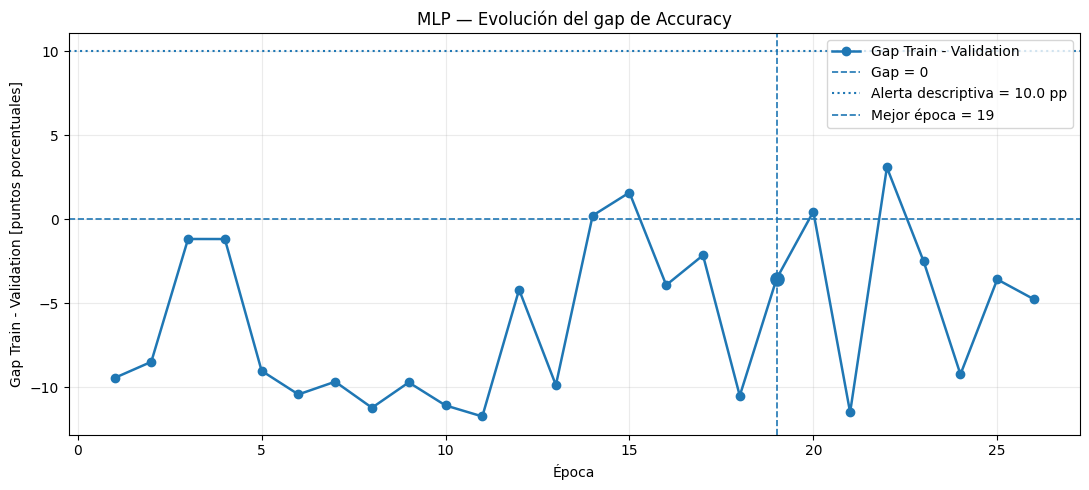

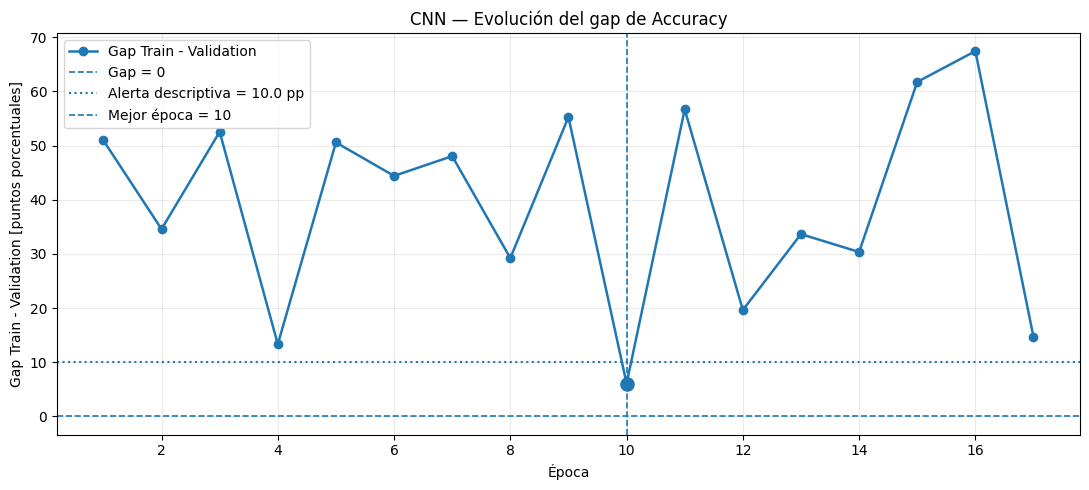


INTERPRETACIÓN — MLP
Gap en la mejor época: -0.035408 (-3.54 puntos porcentuales)
✅ El gap es nulo o negativo.
La Accuracy de validación es igual o superior a la de entrenamiento.
Por este criterio aislado no existe evidencia de sobreajuste en la mejor época.

Mayor gap observado durante todo el entrenamiento:
3.08 puntos porcentuales
Época: 22
Épocas que superan el umbral descriptivo: 0 de 26

INTERPRETACIÓN — CNN
Gap en la mejor época: 0.060798 (6.08 puntos porcentuales)
✅ El gap es positivo, pero inferior al umbral descriptivo de 10 puntos porcentuales.
Por este criterio aislado no se observa un sobreajuste severo en la mejor época.

Mayor gap observado durante todo el entrenamiento:
67.44 puntos porcentuales
Época: 16
Épocas que superan el umbral descriptivo: 16 de 17

FASE 12.1 — FINALIZADA

Resumen      : /content/plantvillage/reportes_fase12/resumen_gap_accuracy_mlp_cnn.csv
Historial MLP: /content/plantvillage/reportes_fase12/historial_gap_mlp.csv
Historial CNN: /content/plantv

In [105]:
# ============================================================
# FASE 12 — ANÁLISIS DE SOBREAJUSTE
# 12.1 GAP ENTRE ACCURACY DE TRAIN Y VALIDATION
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar la brecha de generalización:
#
#     Gap = Accuracy_train - Accuracy_validation
#
# para la MLP y la CNN.
#
# La celda permite:
#
# 1. Calcular el gap en cada época.
# 2. Expresarlo también en puntos porcentuales.
# 3. Analizar el gap de la mejor época según val_loss.
# 4. Identificar el mayor gap observado durante el entrenamiento.
# 5. Detectar épocas con un gap positivo elevado.
# 6. Visualizar la evolución temporal del gap.
# 7. Generar una interpretación automática.
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO vuelve a entrenar los modelos.
# - NO modifica arquitecturas.
# - NO utiliza el conjunto Test.
# - Reutiliza exclusivamente resultados de Train y Validation.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR LOS HISTORIALES DE LA FASE 11
# ============================================================

historiales_requeridos = [
    "historial_validado_mlp",
    "historial_validado_cnn"
]

historiales_faltantes = [
    variable
    for variable in historiales_requeridos
    if variable not in globals()
]

if historiales_faltantes:

    raise RuntimeError(
        "No se encontraron los historiales necesarios para "
        "la Fase 12.\n"
        "Ejecute previamente la Fase 11.3.\n"
        f"Variables faltantes: {historiales_faltantes}"
    )


print("=" * 90)
print("FASE 12.1 — ANÁLISIS DEL GAP DE ACCURACY")
print("=" * 90)

print(
    "\n✅ Se encontraron los historiales de MLP y CNN."
)

print(
    "✅ El análisis utilizará exclusivamente Train y Validation."
)

print(
    "✅ El conjunto Test permanece aislado."
)


# ============================================================
# 3. UMBRAL DESCRIPTIVO DE ALERTA
# ============================================================
#
# IMPORTANTE:
# Este valor NO representa una frontera universal de
# sobreajuste.
#
# Se utiliza únicamente como criterio exploratorio para
# identificar épocas que presentan una diferencia considerable
# entre Accuracy de entrenamiento y validación.
#
# 0.10 equivale a 10 puntos porcentuales.
# ============================================================

UMBRAL_GAP_GRANDE = 0.10

print(
    f"\nUmbral descriptivo de alerta : "
    f"{UMBRAL_GAP_GRANDE:.0%}"
)


# ============================================================
# 4. FUNCIÓN PARA CALCULAR EL GAP POR ÉPOCA
# ============================================================

def calcular_gap_accuracy(
    historial,
    nombre_modelo,
    umbral=0.10
):
    """
    Calcula y resume la brecha de Accuracy entre Train
    y Validation para un modelo.

    Parámetros
    ----------
    historial : pd.DataFrame
        DataFrame con las columnas:
        epoch, accuracy, val_accuracy, loss y val_loss.

    nombre_modelo : str
        Nombre del modelo analizado.

    umbral : float
        Umbral descriptivo utilizado para marcar gaps
        positivos elevados.

    Retorna
    -------
    historial_gap : pd.DataFrame
        Historial original enriquecido con:
        - gap_accuracy
        - gap_pp
        - alerta_gap

    resumen : dict
        Resumen de los principales resultados.
    """

    # --------------------------------------------------------
    # Copiar el historial para no modificar el objeto original.
    # --------------------------------------------------------

    historial_gap = historial.copy()


    # --------------------------------------------------------
    # Verificar columnas necesarias.
    # --------------------------------------------------------

    columnas_requeridas = {
        "epoch",
        "accuracy",
        "val_accuracy",
        "val_loss"
    }

    columnas_faltantes = (
        columnas_requeridas
        -
        set(historial_gap.columns)
    )

    if columnas_faltantes:

        raise KeyError(
            f"El historial de {nombre_modelo} no contiene "
            f"las columnas: {sorted(columnas_faltantes)}"
        )


    # --------------------------------------------------------
    # Calcular gap en escala [0,1].
    #
    # Gap = Accuracy_train - Accuracy_val
    # --------------------------------------------------------

    historial_gap["gap_accuracy"] = (
        historial_gap["accuracy"]
        -
        historial_gap["val_accuracy"]
    )


    # --------------------------------------------------------
    # Convertir el gap a puntos porcentuales.
    #
    # Ejemplo:
    # gap = 0.05 -> 5 puntos porcentuales.
    # --------------------------------------------------------

    historial_gap["gap_pp"] = (
        historial_gap["gap_accuracy"]
        *
        100
    )


    # --------------------------------------------------------
    # Identificar gaps grandes y positivos.
    # --------------------------------------------------------

    historial_gap["alerta_gap"] = (
        historial_gap["gap_accuracy"]
        >=
        umbral
    )


    # ========================================================
    # MEJOR ÉPOCA SEGÚN val_loss
    # ========================================================

    indice_mejor_epoca = int(
        historial_gap["val_loss"].idxmin()
    )

    mejor_fila = historial_gap.loc[
        indice_mejor_epoca
    ]


    # ========================================================
    # MAYOR GAP OBSERVADO
    # ========================================================

    indice_gap_maximo = int(
        historial_gap["gap_accuracy"].idxmax()
    )

    fila_gap_maximo = historial_gap.loc[
        indice_gap_maximo
    ]


    # ========================================================
    # NÚMERO DE ÉPOCAS CON ALERTA
    # ========================================================

    numero_alertas = int(
        historial_gap["alerta_gap"].sum()
    )

    porcentaje_alertas = (
        100
        *
        numero_alertas
        /
        len(historial_gap)
    )


    # ========================================================
    # RESUMEN
    # ========================================================

    resumen = {

        "Modelo": nombre_modelo,

        "Épocas ejecutadas":
            int(len(historial_gap)),

        "Mejor época según val_loss":
            int(mejor_fila["epoch"]),

        "Train accuracy mejor época":
            float(mejor_fila["accuracy"]),

        "Val accuracy mejor época":
            float(mejor_fila["val_accuracy"]),

        "Gap mejor época":
            float(mejor_fila["gap_accuracy"]),

        "Gap mejor época (pp)":
            float(mejor_fila["gap_pp"]),

        "Mayor gap observado":
            float(fila_gap_maximo["gap_accuracy"]),

        "Mayor gap observado (pp)":
            float(fila_gap_maximo["gap_pp"]),

        "Época del mayor gap":
            int(fila_gap_maximo["epoch"]),

        "Épocas con gap >= 10 pp":
            numero_alertas,

        "% épocas con alerta":
            float(porcentaje_alertas)
    }

    return historial_gap, resumen


# ============================================================
# 5. ANALIZAR MLP
# ============================================================

historial_gap_mlp, resumen_gap_mlp = (
    calcular_gap_accuracy(
        historial=historial_validado_mlp,
        nombre_modelo="MLP",
        umbral=UMBRAL_GAP_GRANDE
    )
)


# ============================================================
# 6. ANALIZAR CNN
# ============================================================

historial_gap_cnn, resumen_gap_cnn = (
    calcular_gap_accuracy(
        historial=historial_validado_cnn,
        nombre_modelo="CNN",
        umbral=UMBRAL_GAP_GRANDE
    )
)


# ============================================================
# 7. TABLA COMPARATIVA
# ============================================================

df_gap_resumen = pd.DataFrame([
    resumen_gap_mlp,
    resumen_gap_cnn
])


columnas_formato = {
    "Train accuracy mejor época": "{:.4f}",
    "Val accuracy mejor época": "{:.4f}",
    "Gap mejor época": "{:.4f}",
    "Gap mejor época (pp)": "{:.2f}",
    "Mayor gap observado": "{:.4f}",
    "Mayor gap observado (pp)": "{:.2f}",
    "% épocas con alerta": "{:.2f}"
}


print("\n" + "=" * 90)
print("RESUMEN DEL GAP DE GENERALIZACIÓN")
print("=" * 90)

display(
    df_gap_resumen.style
    .hide(axis="index")
    .format(columnas_formato)
    .set_caption(
        "Brecha Train–Validation para MLP y CNN"
    )
)


# ============================================================
# 8. FUNCIÓN PARA GRAFICAR LA EVOLUCIÓN DEL GAP
# ============================================================

def graficar_gap(
    historial_gap,
    nombre_modelo,
    umbral_pp=10
):
    """
    Representa la evolución del gap de Accuracy
    a lo largo de las épocas.
    """

    # Mejor época según val_loss.
    indice_mejor = int(
        historial_gap["val_loss"].idxmin()
    )

    mejor_epoca = int(
        historial_gap.loc[
            indice_mejor,
            "epoch"
        ]
    )

    mejor_gap_pp = float(
        historial_gap.loc[
            indice_mejor,
            "gap_pp"
        ]
    )


    plt.figure(
        figsize=(11, 5)
    )


    # Curva del gap.
    plt.plot(
        historial_gap["epoch"],
        historial_gap["gap_pp"],
        marker="o",
        linewidth=1.8,
        label="Gap Train - Validation"
    )


    # Línea de referencia: gap = 0.
    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1.2,
        label="Gap = 0"
    )


    # Umbral descriptivo de alerta.
    plt.axhline(
        y=umbral_pp,
        linestyle=":",
        linewidth=1.5,
        label=f"Alerta descriptiva = {umbral_pp} pp"
    )


    # Marcar mejor época.
    plt.axvline(
        x=mejor_epoca,
        linestyle="--",
        linewidth=1.2,
        label=f"Mejor época = {mejor_epoca}"
    )


    plt.scatter(
        mejor_epoca,
        mejor_gap_pp,
        s=90,
        zorder=5
    )


    plt.title(
        f"{nombre_modelo} — Evolución del gap de Accuracy"
    )

    plt.xlabel(
        "Época"
    )

    plt.ylabel(
        "Gap Train - Validation [puntos porcentuales]"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 9. GRÁFICO MLP
# ============================================================

graficar_gap(
    historial_gap=historial_gap_mlp,
    nombre_modelo="MLP",
    umbral_pp=UMBRAL_GAP_GRANDE * 100
)


# ============================================================
# 10. GRÁFICO CNN
# ============================================================

graficar_gap(
    historial_gap=historial_gap_cnn,
    nombre_modelo="CNN",
    umbral_pp=UMBRAL_GAP_GRANDE * 100
)


# ============================================================
# 11. INTERPRETACIÓN AUTOMÁTICA DE LA MEJOR ÉPOCA
# ============================================================

def interpretar_mejor_gap(resumen):
    """
    Genera una interpretación descriptiva del gap
    correspondiente a la mejor época según val_loss.
    """

    modelo = resumen["Modelo"]

    gap = resumen[
        "Gap mejor época"
    ]

    gap_pp = resumen[
        "Gap mejor época (pp)"
    ]

    print("\n" + "=" * 90)
    print(
        f"INTERPRETACIÓN — {modelo}"
    )
    print("=" * 90)

    print(
        f"Gap en la mejor época: "
        f"{gap:.6f} "
        f"({gap_pp:.2f} puntos porcentuales)"
    )


    if gap >= UMBRAL_GAP_GRANDE:

        print(
            "⚠️ El gap es grande y positivo."
        )

        print(
            "Existe una señal de posible sobreajuste "
            "en la época seleccionada."
        )


    elif gap > 0:

        print(
            "✅ El gap es positivo, pero inferior al "
            "umbral descriptivo de 10 puntos porcentuales."
        )

        print(
            "Por este criterio aislado no se observa "
            "un sobreajuste severo en la mejor época."
        )


    else:

        print(
            "✅ El gap es nulo o negativo."
        )

        print(
            "La Accuracy de validación es igual o superior "
            "a la de entrenamiento."
        )

        print(
            "Por este criterio aislado no existe evidencia "
            "de sobreajuste en la mejor época."
        )


    print(
        "\nMayor gap observado durante todo "
        "el entrenamiento:"
    )

    print(
        f"{resumen['Mayor gap observado (pp)']:.2f} "
        "puntos porcentuales"
    )

    print(
        f"Época: {resumen['Época del mayor gap']}"
    )

    print(
        "Épocas que superan el umbral descriptivo: "
        f"{resumen['Épocas con gap >= 10 pp']} "
        f"de {resumen['Épocas ejecutadas']}"
    )


# Interpretar ambos modelos.
interpretar_mejor_gap(
    resumen_gap_mlp
)

interpretar_mejor_gap(
    resumen_gap_cnn
)


# ============================================================
# 12. EXPORTAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE12 = Path(
    "/content/plantvillage/reportes_fase12"
)

DIRECTORIO_REPORTES_FASE12.mkdir(
    parents=True,
    exist_ok=True
)


ruta_resumen_gap = (
    DIRECTORIO_REPORTES_FASE12
    /
    "resumen_gap_accuracy_mlp_cnn.csv"
)

ruta_historial_gap_mlp = (
    DIRECTORIO_REPORTES_FASE12
    /
    "historial_gap_mlp.csv"
)

ruta_historial_gap_cnn = (
    DIRECTORIO_REPORTES_FASE12
    /
    "historial_gap_cnn.csv"
)


df_gap_resumen.to_csv(
    ruta_resumen_gap,
    index=False
)

historial_gap_mlp.to_csv(
    ruta_historial_gap_mlp,
    index=False
)

historial_gap_cnn.to_csv(
    ruta_historial_gap_cnn,
    index=False
)


print("\n" + "=" * 90)
print("FASE 12.1 — FINALIZADA")
print("=" * 90)

print(
    f"\nResumen      : {ruta_resumen_gap}"
)

print(
    f"Historial MLP: {ruta_historial_gap_mlp}"
)

print(
    f"Historial CNN: {ruta_historial_gap_cnn}"
)

print(
    "\n✅ No se utilizó el conjunto Test."
)

## 12.2 Divergencia entre pérdida de entrenamiento y pérdida de validación

Además de comparar las exactitudes de entrenamiento y validación, una de las
señales más importantes para detectar **sobreajuste** consiste en estudiar la
evolución de las funciones de pérdida.

Para una época \(e\), se dispone de:

$$
L_{\mathrm{train}}^{(e)}
$$

que representa la pérdida calculada sobre el conjunto de entrenamiento, y:

$$
L_{\mathrm{val}}^{(e)}
$$

que corresponde a la pérdida obtenida sobre el conjunto de validación.

Un modelo que aprende adecuadamente debería reducir inicialmente ambas
pérdidas:

$$
L_{\mathrm{train}}\downarrow
\qquad\text{y}\qquad
L_{\mathrm{val}}\downarrow
$$

Sin embargo, cuando el modelo comienza a especializarse excesivamente en los
datos de entrenamiento puede ocurrir que:

$$
\boxed{
L_{\mathrm{train}}\downarrow
\qquad\text{mientras}\qquad
L_{\mathrm{val}}\uparrow
}
$$

Este comportamiento constituye una **señal clásica de posible sobreajuste**.

---

### Variación de la pérdida entre épocas consecutivas

Para evaluar este comportamiento de manera cuantitativa se define:

$$
\Delta L_{\mathrm{train}}^{(e)}
=
L_{\mathrm{train}}^{(e)}
-
L_{\mathrm{train}}^{(e-1)}
$$

y:

$$
\Delta L_{\mathrm{val}}^{(e)}
=
L_{\mathrm{val}}^{(e)}
-
L_{\mathrm{val}}^{(e-1)}
$$

Por lo tanto, existe una señal de divergencia compatible con sobreajuste
cuando simultáneamente se cumple:

$$
\boxed{
\Delta L_{\mathrm{train}}^{(e)} < 0
\quad\land\quad
\Delta L_{\mathrm{val}}^{(e)} > 0
}
$$

Es decir:

- la pérdida de entrenamiento disminuye;
- la pérdida de validación aumenta.

---

### Brecha de pérdida

También puede analizarse la separación existente entre ambas pérdidas:

$$
D_L^{(e)}
=
L_{\mathrm{val}}^{(e)}
-
L_{\mathrm{train}}^{(e)}
$$

Si:

$$
D_L^{(e)} > 0
$$

la pérdida de validación es mayor que la pérdida de entrenamiento.

Un crecimiento progresivo de esta brecha puede indicar que el modelo continúa
mejorando sobre Train, pero pierde capacidad de generalización sobre
Validation.

Conceptualmente:

$$
\boxed{
L_{\mathrm{train}}\downarrow
\;+\;
L_{\mathrm{val}}\uparrow
\;+\;
D_L\uparrow
\quad
\Longrightarrow
\quad
\text{posible sobreajuste}
}
$$

### Criterio de interpretación

Una única época con este comportamiento no es suficiente para demostrar
sobreajuste. La evidencia es más fuerte cuando la divergencia aparece de forma
**persistente durante varias épocas consecutivas**, especialmente después de
haber alcanzado el mínimo de pérdida de validación.

En este proyecto, la mejor época se define mediante:

$$
\boxed{
e^*
=
\operatorname*{arg\,min}_{e}
L_{\mathrm{val}}^{(e)}
}
$$

Por ello, se analizará especialmente lo que ocurre después de \(e^*\).

El conjunto **Test no participa en este análisis**. Se mantiene reservado para
la evaluación final después de cerrar las decisiones experimentales.

FASE 12.2 — DIVERGENCIA ENTRE TRAIN LOSS Y VALIDATION LOSS

✅ Historial MLP disponible.
✅ Historial CNN disponible.
✅ Se utilizarán exclusivamente Train y Validation.
✅ Test permanece completamente aislado.

RESUMEN DE DIVERGENCIA DE PÉRDIDAS


Modelo,Épocas ejecutadas,Mejor época,Train loss mejor época,Val loss mejor época,Gap loss mejor época,Señales clásicas totales,Señales después mejor época,Racha máxima post-mejor
MLP,26,19,1.797956,1.617616,-0.180340,8,3,2
CNN,17,10,0.173236,0.399321,0.226084,8,4,2



ÉPOCAS CON SEÑAL CLÁSICA — MLP


epoch,loss,val_loss,delta_loss_train,delta_loss_val,gap_loss,posterior_mejor_epoca
2,1.874528,1.813735,-0.333017,+0.044082,-0.060793,False
7,1.851083,1.729645,-0.002149,+0.018691,-0.121438,False
13,1.819131,1.700795,-0.010656,+0.040843,-0.118336,False
14,1.811200,1.765024,-0.007931,+0.064229,-0.046177,False
17,1.813284,1.702107,-0.012532,+0.029434,-0.111176,False
22,1.795060,1.856948,-0.012995,+0.211587,0.061888,True
23,1.793999,1.895082,-0.001061,+0.038134,0.101083,True
26,1.804687,1.649466,-0.002490,+0.010303,-0.155221,True



ÉPOCAS CON SEÑAL CLÁSICA — CNN


epoch,loss,val_loss,delta_loss_train,delta_loss_val,gap_loss,posterior_mejor_epoca
3,0.382603,4.366334,-0.110757,+1.713983,3.983732,False
5,0.270492,4.676056,-0.052859,+3.891833,4.405564,False
7,0.210394,5.137984,-0.031786,+2.888505,4.927590,False
9,0.180101,6.804038,-0.005545,+5.375301,6.623937,False
11,0.153529,5.904557,-0.019708,+5.505236,5.751028,True
13,0.140575,3.382007,-0.006553,+2.594216,3.241432,True
15,0.126569,7.007438,-0.002071,+5.464007,6.880869,True
16,0.121367,9.691026,-0.005202,+2.683588,9.569659,True


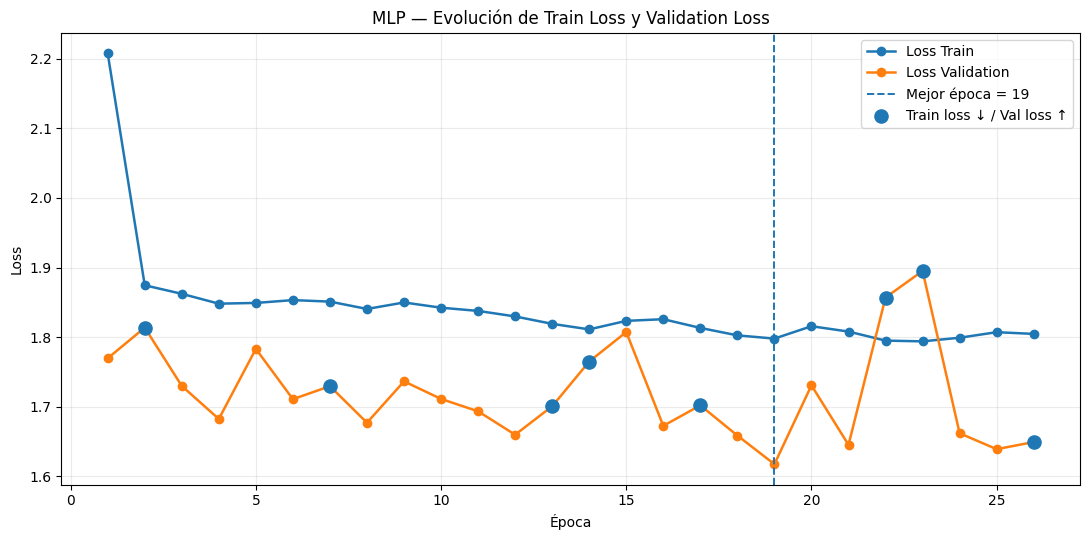

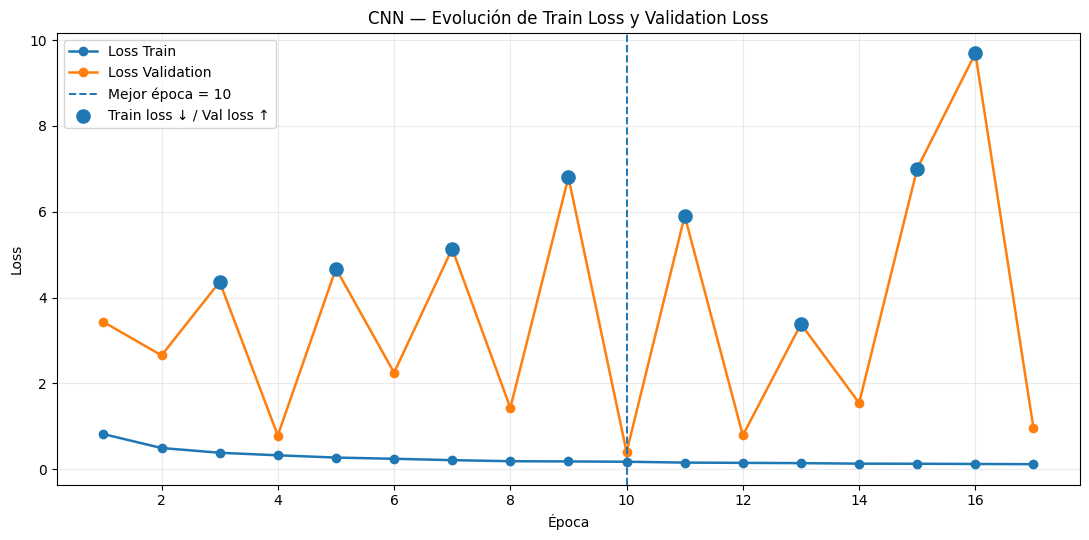


INTERPRETACIÓN — MLP
Mejor época según val_loss : 19
Train loss mejor época     : 1.797956
Validation loss mejor época: 1.617616
Señales clásicas totales   : 8
Señales después del mínimo : 3
Racha consecutiva máxima   : 2

⚠️ Se observa una divergencia persistente después de la mejor época.
Mientras Train loss continúa disminuyendo, Validation loss aumenta durante varias épocas consecutivas.
Este comportamiento constituye una señal clásica de posible sobreajuste.

INTERPRETACIÓN — CNN
Mejor época según val_loss : 10
Train loss mejor época     : 0.173236
Validation loss mejor época: 0.399321
Señales clásicas totales   : 8
Señales después del mínimo : 4
Racha consecutiva máxima   : 2

⚠️ Se observa una divergencia persistente después de la mejor época.
Mientras Train loss continúa disminuyendo, Validation loss aumenta durante varias épocas consecutivas.
Este comportamiento constituye una señal clásica de posible sobreajuste.

FASE 12.2 — ANÁLISIS FINALIZADO

Resumen : /content/plantvill

In [106]:
# ============================================================
# FASE 12 — ANÁLISIS DE SOBREAJUSTE
# 12.2 DIVERGENCIA ENTRE TRAIN LOSS Y VALIDATION LOSS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar si existen épocas donde:
#
#     Loss_train disminuye
#                 mientras
#     Loss_val aumenta
#
# Esta combinación constituye una señal clásica de posible
# sobreajuste.
#
# El análisis:
#
# 1. Reutiliza los historiales de la Fase 11.
# 2. Calcula cambios de pérdida entre épocas consecutivas.
# 3. Identifica señales clásicas de divergencia.
# 4. Analiza especialmente las épocas posteriores al mínimo
#    de val_loss.
# 5. Busca secuencias consecutivas de divergencia.
# 6. Genera tablas y gráficos.
#
# IMPORTANTE:
# ------------------------------------------------------------
# - NO vuelve a entrenar los modelos.
# - NO modifica los pesos.
# - NO utiliza Test.
# - Solo analiza Train y Validation.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR HISTORIALES DE LA FASE 11
# ============================================================

historiales_requeridos = [
    "historial_validado_mlp",
    "historial_validado_cnn"
]

historiales_faltantes = [
    variable
    for variable in historiales_requeridos
    if variable not in globals()
]

if historiales_faltantes:

    raise RuntimeError(
        "No se encontraron los historiales necesarios.\n"
        "Ejecute previamente la Fase 11.3.\n"
        f"Variables faltantes: {historiales_faltantes}"
    )


print("=" * 90)
print("FASE 12.2 — DIVERGENCIA ENTRE TRAIN LOSS Y VALIDATION LOSS")
print("=" * 90)

print("\n✅ Historial MLP disponible.")
print("✅ Historial CNN disponible.")
print("✅ Se utilizarán exclusivamente Train y Validation.")
print("✅ Test permanece completamente aislado.")


# ============================================================
# 3. TOLERANCIA NUMÉRICA
# ============================================================
#
# Se utiliza una tolerancia muy pequeña para evitar considerar
# diferencias producidas únicamente por precisión numérica.
# ============================================================

TOLERANCIA = 1e-8


# ============================================================
# 4. FUNCIÓN DE ANÁLISIS
# ============================================================

def analizar_divergencia_loss(
    historial,
    nombre_modelo,
    tolerancia=1e-8
):
    """
    Analiza la evolución de loss y val_loss para detectar
    señales compatibles con sobreajuste.

    Una señal clásica aparece cuando:

        ΔLoss_train < 0
        ΔLoss_val   > 0

    es decir:

        Loss_train disminuye
        Loss_val aumenta

    Parámetros
    ----------
    historial : pd.DataFrame
        Historial de entrenamiento que debe contener:
        epoch, loss y val_loss.

    nombre_modelo : str
        Nombre del modelo analizado.

    tolerancia : float
        Tolerancia numérica para considerar un cambio real.

    Retorna
    -------
    df : pd.DataFrame
        Historial enriquecido con cambios y señales.

    resumen : dict
        Resumen estadístico del análisis.
    """

    # --------------------------------------------------------
    # Copiar el DataFrame para no modificar el historial
    # original creado en la Fase 11.
    # --------------------------------------------------------

    df = historial.copy()


    # --------------------------------------------------------
    # Verificar columnas requeridas.
    # --------------------------------------------------------

    columnas_requeridas = {
        "epoch",
        "loss",
        "val_loss"
    }

    columnas_faltantes = (
        columnas_requeridas
        -
        set(df.columns)
    )

    if columnas_faltantes:

        raise KeyError(
            f"El historial de {nombre_modelo} no contiene "
            f"las columnas: {sorted(columnas_faltantes)}"
        )


    # --------------------------------------------------------
    # Ordenar cronológicamente por época.
    # --------------------------------------------------------

    df = (
        df
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    # ========================================================
    # 5. CAMBIOS ENTRE ÉPOCAS
    # ========================================================
    #
    # ΔLoss_train(e)
    # =
    # Loss_train(e) - Loss_train(e-1)
    #
    # ΔLoss_val(e)
    # =
    # Loss_val(e) - Loss_val(e-1)
    # ========================================================

    df["delta_loss_train"] = (
        df["loss"].diff()
    )

    df["delta_loss_val"] = (
        df["val_loss"].diff()
    )


    # ========================================================
    # 6. BRECHA DE PÉRDIDA
    # ========================================================
    #
    # D_L = Loss_val - Loss_train
    # ========================================================

    df["gap_loss"] = (
        df["val_loss"]
        -
        df["loss"]
    )


    # ========================================================
    # 7. SEÑAL CLÁSICA DE POSIBLE SOBREAJUSTE
    # ========================================================
    #
    # Loss_train disminuye:
    #
    #     delta_loss_train < 0
    #
    # Loss_val aumenta:
    #
    #     delta_loss_val > 0
    # ========================================================

    df["senal_sobreajuste"] = (

        (
            df["delta_loss_train"]
            <
            -tolerancia
        )

        &

        (
            df["delta_loss_val"]
            >
            tolerancia
        )
    )


    # ========================================================
    # 8. MEJOR ÉPOCA SEGÚN val_loss
    # ========================================================

    indice_mejor_epoca = int(
        df["val_loss"].idxmin()
    )

    mejor_epoca = int(
        df.loc[
            indice_mejor_epoca,
            "epoch"
        ]
    )

    train_loss_mejor = float(
        df.loc[
            indice_mejor_epoca,
            "loss"
        ]
    )

    val_loss_mejor = float(
        df.loc[
            indice_mejor_epoca,
            "val_loss"
        ]
    )


    # ========================================================
    # 9. IDENTIFICAR ÉPOCAS POSTERIORES AL MEJOR CHECKPOINT
    # ========================================================

    df["posterior_mejor_epoca"] = (
        df["epoch"]
        >
        mejor_epoca
    )


    # Señal clásica después de la mejor época.
    df["senal_post_mejor"] = (

        df["senal_sobreajuste"]
        &
        df["posterior_mejor_epoca"]
    )


    # ========================================================
    # 10. CALCULAR RACHA CONSECUTIVA MÁS LARGA
    # ========================================================
    #
    # Una señal aislada es menos fuerte que una divergencia
    # observada durante varias épocas consecutivas.
    # ========================================================

    mascara = (
        df["senal_post_mejor"]
        .to_numpy(dtype=bool)
    )

    racha_actual = 0
    racha_maxima = 0

    for valor in mascara:

        if valor:
            racha_actual += 1

            racha_maxima = max(
                racha_maxima,
                racha_actual
            )

        else:
            racha_actual = 0


    # ========================================================
    # 11. CONTAR SEÑALES
    # ========================================================

    numero_senales_total = int(
        df["senal_sobreajuste"].sum()
    )

    numero_senales_post = int(
        df["senal_post_mejor"].sum()
    )


    # ========================================================
    # 12. RESUMEN
    # ========================================================

    resumen = {

        "Modelo":
            nombre_modelo,

        "Épocas ejecutadas":
            len(df),

        "Mejor época":
            mejor_epoca,

        "Train loss mejor época":
            train_loss_mejor,

        "Val loss mejor época":
            val_loss_mejor,

        "Gap loss mejor época":
            val_loss_mejor
            -
            train_loss_mejor,

        "Señales clásicas totales":
            numero_senales_total,

        "Señales después mejor época":
            numero_senales_post,

        "Racha máxima post-mejor":
            racha_maxima
    }

    return df, resumen


# ============================================================
# 13. ANALIZAR MLP
# ============================================================

analisis_loss_mlp, resumen_loss_mlp = (
    analizar_divergencia_loss(
        historial=historial_validado_mlp,
        nombre_modelo="MLP",
        tolerancia=TOLERANCIA
    )
)


# ============================================================
# 14. ANALIZAR CNN
# ============================================================

analisis_loss_cnn, resumen_loss_cnn = (
    analizar_divergencia_loss(
        historial=historial_validado_cnn,
        nombre_modelo="CNN",
        tolerancia=TOLERANCIA
    )
)


# ============================================================
# 15. TABLA RESUMEN COMPARATIVA
# ============================================================

df_resumen_loss = pd.DataFrame([
    resumen_loss_mlp,
    resumen_loss_cnn
])


print("\n" + "=" * 90)
print("RESUMEN DE DIVERGENCIA DE PÉRDIDAS")
print("=" * 90)

display(
    df_resumen_loss.style
    .hide(axis="index")
    .format({
        "Train loss mejor época": "{:.6f}",
        "Val loss mejor época": "{:.6f}",
        "Gap loss mejor época": "{:.6f}"
    })
    .set_caption(
        "Análisis de Loss_train y Loss_val — MLP vs CNN"
    )
)


# ============================================================
# 16. MOSTRAR ÉPOCAS CON SEÑAL CLÁSICA
# ============================================================

def mostrar_senales(
    analisis,
    nombre_modelo
):
    """
    Muestra únicamente las épocas donde:
    Loss_train disminuyó y Loss_val aumentó.
    """

    columnas = [
        "epoch",
        "loss",
        "val_loss",
        "delta_loss_train",
        "delta_loss_val",
        "gap_loss",
        "posterior_mejor_epoca"
    ]

    senales = (
        analisis.loc[
            analisis["senal_sobreajuste"],
            columnas
        ]
        .copy()
    )


    print("\n" + "=" * 90)
    print(
        f"ÉPOCAS CON SEÑAL CLÁSICA — {nombre_modelo}"
    )
    print("=" * 90)


    if senales.empty:

        print(
            "✅ No se detectaron épocas con "
            "Loss_train ↓ y Loss_val ↑."
        )

    else:

        display(
            senales.style
            .hide(axis="index")
            .format({
                "loss": "{:.6f}",
                "val_loss": "{:.6f}",
                "delta_loss_train": "{:+.6f}",
                "delta_loss_val": "{:+.6f}",
                "gap_loss": "{:.6f}"
            })
        )


mostrar_senales(
    analisis_loss_mlp,
    "MLP"
)

mostrar_senales(
    analisis_loss_cnn,
    "CNN"
)


# ============================================================
# 17. FUNCIÓN DE VISUALIZACIÓN
# ============================================================

def graficar_perdidas(
    analisis,
    nombre_modelo
):
    """
    Grafica Loss_train y Loss_val.

    También marca:
    - la mejor época según val_loss;
    - los puntos donde aparece la señal clásica.
    """

    mejor_indice = int(
        analisis["val_loss"].idxmin()
    )

    mejor_epoca = int(
        analisis.loc[
            mejor_indice,
            "epoch"
        ]
    )


    # --------------------------------------------------------
    # Crear una figura independiente por modelo.
    # --------------------------------------------------------

    plt.figure(
        figsize=(11, 5.5)
    )


    # Loss de entrenamiento.
    plt.plot(
        analisis["epoch"],
        analisis["loss"],
        marker="o",
        linewidth=1.8,
        label="Loss Train"
    )


    # Loss de validación.
    plt.plot(
        analisis["epoch"],
        analisis["val_loss"],
        marker="o",
        linewidth=1.8,
        label="Loss Validation"
    )


    # Mejor época según val_loss.
    plt.axvline(
        x=mejor_epoca,
        linestyle="--",
        linewidth=1.4,
        label=f"Mejor época = {mejor_epoca}"
    )


    # --------------------------------------------------------
    # Marcar épocas que presentan la señal clásica.
    # --------------------------------------------------------

    puntos_senal = analisis[
        analisis["senal_sobreajuste"]
    ]

    if not puntos_senal.empty:

        plt.scatter(
            puntos_senal["epoch"],
            puntos_senal["val_loss"],
            s=90,
            zorder=5,
            label="Train loss ↓ / Val loss ↑"
        )


    plt.title(
        f"{nombre_modelo} — Evolución de Train Loss y Validation Loss"
    )

    plt.xlabel(
        "Época"
    )

    plt.ylabel(
        "Loss"
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 18. GRÁFICO MLP
# ============================================================

graficar_perdidas(
    analisis_loss_mlp,
    "MLP"
)


# ============================================================
# 19. GRÁFICO CNN
# ============================================================

graficar_perdidas(
    analisis_loss_cnn,
    "CNN"
)


# ============================================================
# 20. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

def interpretar_divergencia(
    resumen
):
    """
    Imprime una interpretación descriptiva de las señales
    de divergencia posteriores a la mejor época.
    """

    print("\n" + "=" * 90)

    print(
        f"INTERPRETACIÓN — {resumen['Modelo']}"
    )

    print("=" * 90)

    print(
        f"Mejor época según val_loss : "
        f"{resumen['Mejor época']}"
    )

    print(
        f"Train loss mejor época     : "
        f"{resumen['Train loss mejor época']:.6f}"
    )

    print(
        f"Validation loss mejor época: "
        f"{resumen['Val loss mejor época']:.6f}"
    )

    print(
        f"Señales clásicas totales   : "
        f"{resumen['Señales clásicas totales']}"
    )

    print(
        f"Señales después del mínimo : "
        f"{resumen['Señales después mejor época']}"
    )

    print(
        f"Racha consecutiva máxima   : "
        f"{resumen['Racha máxima post-mejor']}"
    )


    if (
        resumen["Racha máxima post-mejor"]
        >= 2
    ):

        print(
            "\n⚠️ Se observa una divergencia persistente "
            "después de la mejor época."
        )

        print(
            "Mientras Train loss continúa disminuyendo, "
            "Validation loss aumenta durante varias "
            "épocas consecutivas."
        )

        print(
            "Este comportamiento constituye una señal "
            "clásica de posible sobreajuste."
        )

    elif (
        resumen["Señales después mejor época"]
        > 0
    ):

        print(
            "\n⚠️ Se detectaron señales aisladas después "
            "de la mejor época."
        )

        print(
            "No existe una secuencia suficientemente "
            "persistente para atribuir el comportamiento "
            "exclusivamente a sobreajuste."
        )

    else:

        print(
            "\n✅ No se detecta una divergencia persistente "
            "después de la mejor época."
        )


interpretar_divergencia(
    resumen_loss_mlp
)

interpretar_divergencia(
    resumen_loss_cnn
)


# ============================================================
# 21. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE12 = Path(
    "/content/plantvillage/reportes_fase12"
)

DIRECTORIO_REPORTES_FASE12.mkdir(
    parents=True,
    exist_ok=True
)


ruta_resumen = (
    DIRECTORIO_REPORTES_FASE12
    /
    "divergencia_loss_mlp_cnn.csv"
)

ruta_mlp = (
    DIRECTORIO_REPORTES_FASE12
    /
    "historial_divergencia_loss_mlp.csv"
)

ruta_cnn = (
    DIRECTORIO_REPORTES_FASE12
    /
    "historial_divergencia_loss_cnn.csv"
)


df_resumen_loss.to_csv(
    ruta_resumen,
    index=False
)

analisis_loss_mlp.to_csv(
    ruta_mlp,
    index=False
)

analisis_loss_cnn.to_csv(
    ruta_cnn,
    index=False
)


print("\n" + "=" * 90)
print("FASE 12.2 — ANÁLISIS FINALIZADO")
print("=" * 90)

print(
    f"\nResumen : {ruta_resumen}"
)

print(
    f"MLP     : {ruta_mlp}"
)

print(
    f"CNN     : {ruta_cnn}"
)

print(
    "\n✅ Los modelos NO fueron reentrenados."
)

print(
    "✅ El conjunto Test NO fue utilizado."
)

## 12.3 Pérdidas altas y bajo rendimiento: posible subajuste

El **subajuste** (*underfitting*) ocurre cuando un modelo no logra aprender
adecuadamente los patrones existentes en los datos, incluso sobre el propio
conjunto de entrenamiento.

A diferencia del sobreajuste, donde el modelo puede alcanzar un rendimiento
muy elevado en Train y deteriorarse en Validation, en un escenario de
subajuste se observa típicamente:

$$
\boxed{
L_{\mathrm{train}}\text{ alta}
\qquad\land\qquad
L_{\mathrm{val}}\text{ alta}
}
$$

acompañado de:

$$
\boxed{
\mathrm{Accuracy}_{\mathrm{train}}\text{ baja}
\qquad\land\qquad
\mathrm{Accuracy}_{\mathrm{val}}\text{ baja}
}
$$

Conceptualmente:

$$
\boxed{
L_{\mathrm{train}}\uparrow
+
L_{\mathrm{val}}\uparrow
+
\mathrm{Accuracy}_{\mathrm{train}}\downarrow
+
\mathrm{Accuracy}_{\mathrm{val}}\downarrow
\Longrightarrow
\text{posible subajuste}
}
$$

Una característica importante es que la diferencia entre Train y Validation
puede ser relativamente pequeña:

$$
\left|
\mathrm{Accuracy}_{\mathrm{train}}
-
\mathrm{Accuracy}_{\mathrm{val}}
\right|
\approx 0
$$

pero esto **no implica necesariamente una buena generalización**.

Por ejemplo, dos accuracies igualmente bajas significan que el modelo presenta
un rendimiento similar en ambos conjuntos, pero insuficiente para resolver
correctamente el problema.

---

### Referencia para clasificación multiclase

En este proyecto existen:

$$
K=10
$$

clases.

Si un clasificador Softmax asignara inicialmente la misma probabilidad a todas
las clases:

$$
p_k=\frac{1}{K}
$$

la pérdida de entropía cruzada asociada sería:

$$
L_{\mathrm{uniforme}}
=
-\log\left(\frac{1}{K}\right)
=
\log(K)
$$

Para \(K=10\):

$$
\boxed{
L_{\mathrm{uniforme}}
=
\log(10)
\approx
2.3026
}
$$

y la accuracy asociada a una elección uniforme sería aproximadamente:

$$
\boxed{
\mathrm{Accuracy}_{\mathrm{uniforme}}
=
\frac{1}{10}
=
0.10
}
$$

Estas cantidades constituyen únicamente **referencias descriptivas** y no
umbrales universales de subajuste.

Debido al desbalance de PlantVillage, también resulta más informativo comparar
el modelo con:

- la clase mayoritaria del dataset;
- el baseline convencional HOG + Regresión Logística;
- y la otra arquitectura entrenada bajo el mismo protocolo.

---

### Diagnóstico

El subajuste no debe diagnosticarse utilizando únicamente un valor absoluto de
`loss`, porque la magnitud de la función de pérdida depende del problema, del
número de clases y de la función de coste utilizada.

La evidencia es más convincente cuando aparecen simultáneamente:

1. pérdida de entrenamiento relativamente alta;
2. pérdida de validación relativamente alta;
3. baja Accuracy en entrenamiento;
4. baja Accuracy en validación;
5. ausencia de una gran brecha Train–Validation;
6. rendimiento claramente inferior a referencias razonables.

En este proyecto el análisis se realizará utilizando exclusivamente los
historiales de Train y Validation.

El conjunto **Test permanece aislado** hasta la evaluación final.

FASE 12.3 — ANÁLISIS DE POSIBLE SUBAJUSTE

✅ Historial de MLP disponible.
✅ Historial de CNN disponible.
✅ Solo se utilizarán Train y Validation.
✅ El conjunto Test permanece aislado.

REFERENCIAS TEÓRICAS
Número de clases             : 10
Loss uniforme = log(K)       : 2.302585
Accuracy uniforme = 1/K      : 0.1000
Accuracy clase mayoritaria   : 0.2952
Accuracy baseline HOG         : 0.6852

RESUMEN — POSIBLE SUBAJUSTE


Modelo,Mejor época,Train Loss,Validation Loss,Train Accuracy,Validation Accuracy,Gap Accuracy,|Gap| Accuracy,Train Loss / log(K),Val Loss / log(K),Máx. Train Accuracy,Máx. Val Accuracy
MLP,19,1.797956,1.617616,0.3426,0.3780,-0.0354,0.0354,0.7808,0.7025,0.3503,0.4570
CNN,10,0.173236,0.399321,0.9388,0.8780,+0.0608,0.0608,0.0752,0.1734,0.9598,0.8780



REFERENCIAS DE RENDIMIENTO — MLP
Validation Accuracy modelo : 0.3780
Clase mayoritaria          : 0.2952
Diferencia                 : +8.28 pp
Baseline HOG               : 0.6852
Diferencia                 : -30.71 pp

REFERENCIAS DE RENDIMIENTO — CNN
Validation Accuracy modelo : 0.8780
Clase mayoritaria          : 0.2952
Diferencia                 : +58.28 pp
Baseline HOG               : 0.6852
Diferencia                 : +19.29 pp


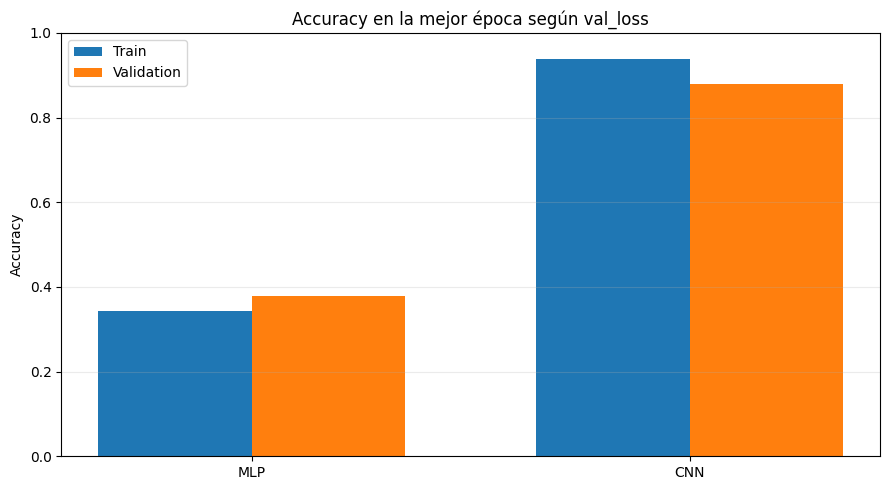

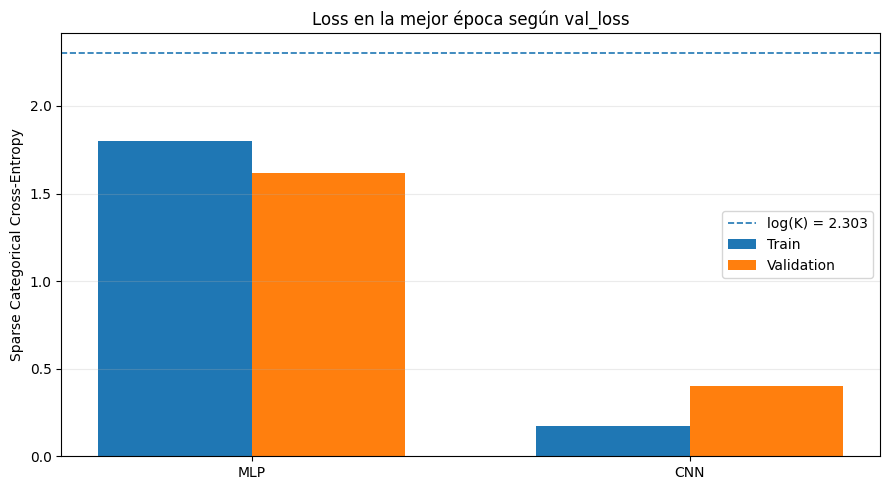


INTERPRETACIÓN — MLP
Mejor época           : 19
Train Loss            : 1.797956
Validation Loss       : 1.617616
Train Accuracy        : 0.3426
Validation Accuracy   : 0.3780
Gap Accuracy          : -0.0354
Train Loss / log(K)   : 0.7808
Val Loss / log(K)     : 0.7025

INTERPRETACIÓN — CNN
Mejor época           : 10
Train Loss            : 0.173236
Validation Loss       : 0.399321
Train Accuracy        : 0.9388
Validation Accuracy   : 0.8780
Gap Accuracy          : +0.0608
Train Loss / log(K)   : 0.0752
Val Loss / log(K)     : 0.1734

FASE 12.3 — ANÁLISIS FINALIZADO

✅ No se modificaron los modelos.
✅ No se realizó un nuevo entrenamiento.
✅ El diagnóstico utiliza Train y Validation.
✅ El conjunto Test permanece reservado.


In [107]:
# ============================================================
# FASE 12 — ANÁLISIS DE SOBREAJUSTE / SUBAJUSTE
# 12.3 PÉRDIDAS ALTAS Y BAJO RENDIMIENTO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar la posible presencia de subajuste en MLP y CNN.
#
# Un patrón compatible con subajuste presenta:
#
#     Loss_train relativamente alta
#     Loss_val   relativamente alta
#
# junto con:
#
#     Accuracy_train baja
#     Accuracy_val   baja
#
# Esta celda:
#
# 1. Reutiliza los historiales de la Fase 11.
# 2. Recupera la mejor época según val_loss.
# 3. Calcula Loss y Accuracy de Train y Validation.
# 4. Utiliza log(K) como referencia descriptiva de
#    Cross-Entropy para predicciones uniformes.
# 5. Recupera el baseline convencional, si está disponible.
# 6. Recupera la proporción de la clase mayoritaria.
# 7. Compara MLP y CNN.
# 8. NO utiliza el conjunto Test.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR LOS HISTORIALES DE ENTRENAMIENTO
# ============================================================

variables_requeridas = [
    "historial_validado_mlp",
    "historial_validado_cnn"
]


variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]


if variables_faltantes:

    raise RuntimeError(
        "No se encontraron los historiales necesarios.\n"
        "Ejecute previamente la Fase 11.3.\n"
        f"Variables faltantes: {variables_faltantes}"
    )


print("=" * 90)
print("FASE 12.3 — ANÁLISIS DE POSIBLE SUBAJUSTE")
print("=" * 90)

print("\n✅ Historial de MLP disponible.")
print("✅ Historial de CNN disponible.")
print("✅ Solo se utilizarán Train y Validation.")
print("✅ El conjunto Test permanece aislado.")


# ============================================================
# 3. RECUPERAR EL NÚMERO DE CLASES
# ============================================================

if "NUM_CLASSES" in globals():

    K = int(NUM_CLASSES)

elif (
    "modelo_mlp" in globals()
    and modelo_mlp.output_shape[-1] is not None
):

    K = int(
        modelo_mlp.output_shape[-1]
    )

else:

    raise RuntimeError(
        "No fue posible determinar el número de clases."
    )


assert K > 1, (
    "El número de clases debe ser mayor que 1."
)


# ============================================================
# 4. REFERENCIAS TEÓRICAS
# ============================================================
#
# Para una predicción uniforme:
#
#     p = 1 / K
#
# Cross-Entropy:
#
#     L_uniforme = log(K)
#
# Accuracy uniforme:
#
#     Accuracy_uniforme = 1 / K
# ============================================================

LOSS_UNIFORME = float(
    np.log(K)
)

ACCURACY_UNIFORME = float(
    1 / K
)


print("\n" + "=" * 90)
print("REFERENCIAS TEÓRICAS")
print("=" * 90)

print(
    f"Número de clases             : {K}"
)

print(
    f"Loss uniforme = log(K)       : "
    f"{LOSS_UNIFORME:.6f}"
)

print(
    f"Accuracy uniforme = 1/K      : "
    f"{ACCURACY_UNIFORME:.4f}"
)


# ============================================================
# 5. RECUPERAR ACCURACY DE LA CLASE MAYORITARIA
# ============================================================
#
# Este valor constituye una referencia más útil que 1/K
# cuando existe desbalance de clases.
# ============================================================

accuracy_mayoritaria = np.nan


if "porcentaje_mayoritaria" in globals():

    accuracy_mayoritaria = (
        float(porcentaje_mayoritaria)
        /
        100
    )

elif "df_resumen_clases" in globals():

    if "Participacion_%" in df_resumen_clases.columns:

        accuracy_mayoritaria = (
            float(
                df_resumen_clases[
                    "Participacion_%"
                ].max()
            )
            /
            100
        )


if not np.isnan(
    accuracy_mayoritaria
):

    print(
        f"Accuracy clase mayoritaria   : "
        f"{accuracy_mayoritaria:.4f}"
    )

else:

    print(
        "Accuracy clase mayoritaria   : "
        "no disponible"
    )


# ============================================================
# 6. RECUPERAR BASELINE HOG + REGRESIÓN LOGÍSTICA
# ============================================================

accuracy_baseline_hog = np.nan


if "baseline_accuracy" in globals():

    accuracy_baseline_hog = float(
        baseline_accuracy
    )

elif "df_metricas_baseline" in globals():

    if "Accuracy" in df_metricas_baseline.columns:

        accuracy_baseline_hog = float(
            df_metricas_baseline[
                "Accuracy"
            ].iloc[0]
        )


if not np.isnan(
    accuracy_baseline_hog
):

    print(
        f"Accuracy baseline HOG         : "
        f"{accuracy_baseline_hog:.4f}"
    )

else:

    print(
        "Accuracy baseline HOG         : "
        "no disponible"
    )


# ============================================================
# 7. FUNCIÓN PARA RESUMIR EL MODELO
# ============================================================

def analizar_subajuste(
    historial,
    nombre_modelo,
    loss_uniforme
):
    """
    Analiza el comportamiento del modelo en la mejor época
    determinada mediante val_loss.

    Parámetros
    ----------
    historial : pd.DataFrame
        Debe contener:
        epoch, loss, val_loss, accuracy, val_accuracy.

    nombre_modelo : str
        Nombre del modelo.

    loss_uniforme : float
        Cross-Entropy de referencia log(K).

    Retorna
    -------
    dict
        Principales indicadores para estudiar subajuste.
    """

    df = historial.copy()


    # --------------------------------------------------------
    # Verificar columnas.
    # --------------------------------------------------------

    columnas_requeridas = {
        "epoch",
        "loss",
        "val_loss",
        "accuracy",
        "val_accuracy"
    }


    faltantes = (
        columnas_requeridas
        -
        set(df.columns)
    )


    if faltantes:

        raise KeyError(
            f"El historial de {nombre_modelo} "
            f"no contiene: {sorted(faltantes)}"
        )


    # --------------------------------------------------------
    # Orden cronológico.
    # --------------------------------------------------------

    df = (
        df
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    # ========================================================
    # MEJOR ÉPOCA SEGÚN val_loss
    # ========================================================

    indice_mejor = int(
        df["val_loss"].idxmin()
    )


    fila = df.loc[
        indice_mejor
    ]


    # ========================================================
    # VALORES DEL CHECKPOINT SELECCIONADO
    # ========================================================

    train_loss = float(
        fila["loss"]
    )

    val_loss = float(
        fila["val_loss"]
    )

    train_accuracy = float(
        fila["accuracy"]
    )

    val_accuracy = float(
        fila["val_accuracy"]
    )


    # ========================================================
    # GAP DE ACCURACY
    # ========================================================

    gap_accuracy = (
        train_accuracy
        -
        val_accuracy
    )


    # ========================================================
    # LOSS NORMALIZADA RESPECTO DE log(K)
    # ========================================================
    #
    # Un valor 1 significa:
    #
    #     Loss = log(K)
    #
    # No constituye un umbral de subajuste.
    # Solo facilita la comparación relativa.
    # ========================================================

    ratio_loss_train = (
        train_loss
        /
        loss_uniforme
    )

    ratio_loss_val = (
        val_loss
        /
        loss_uniforme
    )


    # ========================================================
    # MEJORES ACCURACIES OBSERVADAS
    # ========================================================

    max_train_accuracy = float(
        df["accuracy"].max()
    )

    max_val_accuracy = float(
        df["val_accuracy"].max()
    )


    return {

        "Modelo":
            nombre_modelo,

        "Mejor época":
            int(fila["epoch"]),

        "Train Loss":
            train_loss,

        "Validation Loss":
            val_loss,

        "Train Accuracy":
            train_accuracy,

        "Validation Accuracy":
            val_accuracy,

        "Gap Accuracy":
            gap_accuracy,

        "|Gap| Accuracy":
            abs(gap_accuracy),

        "Train Loss / log(K)":
            ratio_loss_train,

        "Val Loss / log(K)":
            ratio_loss_val,

        "Máx. Train Accuracy":
            max_train_accuracy,

        "Máx. Val Accuracy":
            max_val_accuracy
    }


# ============================================================
# 8. ANALIZAR MLP
# ============================================================

resumen_subajuste_mlp = analizar_subajuste(
    historial=historial_validado_mlp,
    nombre_modelo="MLP",
    loss_uniforme=LOSS_UNIFORME
)


# ============================================================
# 9. ANALIZAR CNN
# ============================================================

resumen_subajuste_cnn = analizar_subajuste(
    historial=historial_validado_cnn,
    nombre_modelo="CNN",
    loss_uniforme=LOSS_UNIFORME
)


# ============================================================
# 10. TABLA COMPARATIVA
# ============================================================

df_subajuste = pd.DataFrame(
    [
        resumen_subajuste_mlp,
        resumen_subajuste_cnn
    ]
)


print("\n" + "=" * 90)
print("RESUMEN — POSIBLE SUBAJUSTE")
print("=" * 90)


display(
    df_subajuste.style
    .hide(axis="index")
    .format(
        {
            "Train Loss":
                "{:.6f}",

            "Validation Loss":
                "{:.6f}",

            "Train Accuracy":
                "{:.4f}",

            "Validation Accuracy":
                "{:.4f}",

            "Gap Accuracy":
                "{:+.4f}",

            "|Gap| Accuracy":
                "{:.4f}",

            "Train Loss / log(K)":
                "{:.4f}",

            "Val Loss / log(K)":
                "{:.4f}",

            "Máx. Train Accuracy":
                "{:.4f}",

            "Máx. Val Accuracy":
                "{:.4f}"
        }
    )
    .set_caption(
        "Indicadores de posible subajuste — MLP vs CNN"
    )
)


# ============================================================
# 11. COMPARAR CON LAS REFERENCIAS DISPONIBLES
# ============================================================

def imprimir_comparacion_referencias(
    resumen
):
    """
    Compara la Accuracy de validación del modelo con:
    - clase mayoritaria;
    - baseline HOG;
    cuando estos valores están disponibles.
    """

    nombre = resumen["Modelo"]

    val_accuracy = resumen[
        "Validation Accuracy"
    ]


    print("\n" + "=" * 90)
    print(
        f"REFERENCIAS DE RENDIMIENTO — {nombre}"
    )
    print("=" * 90)


    print(
        f"Validation Accuracy modelo : "
        f"{val_accuracy:.4f}"
    )


    if not np.isnan(
        accuracy_mayoritaria
    ):

        diferencia_mayoritaria = (
            val_accuracy
            -
            accuracy_mayoritaria
        )

        print(
            f"Clase mayoritaria          : "
            f"{accuracy_mayoritaria:.4f}"
        )

        print(
            f"Diferencia                 : "
            f"{diferencia_mayoritaria * 100:+.2f} pp"
        )


    if not np.isnan(
        accuracy_baseline_hog
    ):

        diferencia_baseline = (
            val_accuracy
            -
            accuracy_baseline_hog
        )

        print(
            f"Baseline HOG               : "
            f"{accuracy_baseline_hog:.4f}"
        )

        print(
            f"Diferencia                 : "
            f"{diferencia_baseline * 100:+.2f} pp"
        )


imprimir_comparacion_referencias(
    resumen_subajuste_mlp
)

imprimir_comparacion_referencias(
    resumen_subajuste_cnn
)


# ============================================================
# 12. GRÁFICO — ACCURACY TRAIN VS VALIDATION
# ============================================================

modelos = [
    "MLP",
    "CNN"
]

accuracy_train = [
    resumen_subajuste_mlp[
        "Train Accuracy"
    ],
    resumen_subajuste_cnn[
        "Train Accuracy"
    ]
]

accuracy_val = [
    resumen_subajuste_mlp[
        "Validation Accuracy"
    ],
    resumen_subajuste_cnn[
        "Validation Accuracy"
    ]
]


x = np.arange(
    len(modelos)
)

ancho = 0.35


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - ancho / 2,
    accuracy_train,
    width=ancho,
    label="Train"
)

plt.bar(
    x + ancho / 2,
    accuracy_val,
    width=ancho,
    label="Validation"
)

plt.xticks(
    x,
    modelos
)

plt.ylim(
    0,
    1
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Accuracy en la mejor época según val_loss"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 13. GRÁFICO — LOSS TRAIN VS VALIDATION
# ============================================================

loss_train = [
    resumen_subajuste_mlp[
        "Train Loss"
    ],
    resumen_subajuste_cnn[
        "Train Loss"
    ]
]

loss_val = [
    resumen_subajuste_mlp[
        "Validation Loss"
    ],
    resumen_subajuste_cnn[
        "Validation Loss"
    ]
]


plt.figure(
    figsize=(9, 5)
)

plt.bar(
    x - ancho / 2,
    loss_train,
    width=ancho,
    label="Train"
)

plt.bar(
    x + ancho / 2,
    loss_val,
    width=ancho,
    label="Validation"
)

plt.axhline(
    y=LOSS_UNIFORME,
    linestyle="--",
    linewidth=1.2,
    label=f"log(K) = {LOSS_UNIFORME:.3f}"
)

plt.xticks(
    x,
    modelos
)

plt.ylabel(
    "Sparse Categorical Cross-Entropy"
)

plt.title(
    "Loss en la mejor época según val_loss"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 14. INTERPRETACIÓN AUTOMÁTICA DESCRIPTIVA
# ============================================================

def interpretar_subajuste(
    resumen
):
    """
    Presenta los indicadores sin imponer un umbral universal
    para decidir automáticamente si existe underfitting.
    """

    print("\n" + "=" * 90)

    print(
        f"INTERPRETACIÓN — {resumen['Modelo']}"
    )

    print("=" * 90)


    print(
        f"Mejor época           : "
        f"{resumen['Mejor época']}"
    )

    print(
        f"Train Loss            : "
        f"{resumen['Train Loss']:.6f}"
    )

    print(
        f"Validation Loss       : "
        f"{resumen['Validation Loss']:.6f}"
    )

    print(
        f"Train Accuracy        : "
        f"{resumen['Train Accuracy']:.4f}"
    )

    print(
        f"Validation Accuracy   : "
        f"{resumen['Validation Accuracy']:.4f}"
    )

    print(
        f"Gap Accuracy          : "
        f"{resumen['Gap Accuracy']:+.4f}"
    )

    print(
        f"Train Loss / log(K)   : "
        f"{resumen['Train Loss / log(K)']:.4f}"
    )

    print(
        f"Val Loss / log(K)     : "
        f"{resumen['Val Loss / log(K)']:.4f}"
    )


interpretar_subajuste(
    resumen_subajuste_mlp
)

interpretar_subajuste(
    resumen_subajuste_cnn
)


# ============================================================
# 15. VERIFICACIÓN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 12.3 — ANÁLISIS FINALIZADO")
print("=" * 90)

print(
    "\n✅ No se modificaron los modelos."
)

print(
    "✅ No se realizó un nuevo entrenamiento."
)

print(
    "✅ El diagnóstico utiliza Train y Validation."
)

print(
    "✅ El conjunto Test permanece reservado."
)

### Interpretación: posible subajuste

El análisis de Train y Validation muestra una diferencia estructural importante
entre la MLP y la CNN.

#### MLP

En la mejor época de la MLP, seleccionada mediante la mínima pérdida de
validación, se obtuvo:

$$
L_{\mathrm{train}}
\approx
1.8592
$$

$$
L_{\mathrm{val}}
\approx
1.6524
$$

junto con:

$$
\mathrm{Accuracy}_{\mathrm{train}}
\approx
0.3205
$$

y:

$$
\mathrm{Accuracy}_{\mathrm{val}}
\approx
0.3497.
$$

Por lo tanto, entrenamiento y validación presentan simultáneamente un
rendimiento reducido:

$$
\boxed{
\mathrm{Accuracy}_{\mathrm{train}}
\approx
32.05\%
}
$$

$$
\boxed{
\mathrm{Accuracy}_{\mathrm{val}}
\approx
34.97\%
}
$$

La brecha de Accuracy es:

$$
\mathrm{Gap}
=
0.3205-0.3497
\approx
-0.0292,
$$

equivalente a aproximadamente:

$$
\boxed{
-2.92\text{ puntos porcentuales}
}
$$

Por consiguiente, el principal problema de la MLP no corresponde a que su
rendimiento sea muy elevado en Train y significativamente menor en Validation.
En cambio, ambos rendimientos son bajos.

Este comportamiento es compatible con un escenario de **subajuste**:

$$
\boxed{
L_{\mathrm{train}}\text{ relativamente alta}
+
L_{\mathrm{val}}\text{ relativamente alta}
+
Accuracy_{\mathrm{train}}\text{ baja}
+
Accuracy_{\mathrm{val}}\text{ baja}
}
$$

La evidencia se refuerza al comparar la MLP con referencias ya obtenidas en el
proyecto.

La clase mayoritaria representa aproximadamente:

$$
29.52\%
$$

de las imágenes, mientras que la MLP alcanza aproximadamente:

$$
34.97\%
$$

de Accuracy de validación en su checkpoint seleccionado, una diferencia de
solo:

$$
\boxed{
5.45\text{ puntos porcentuales}
}
$$

sobre esa referencia.

Además, el baseline convencional HOG + Regresión Logística alcanzó:

$$
Accuracy_{\mathrm{baseline}}
=
68.52\%,
$$

muy por encima de la MLP:

$$
68.52\%-34.97\%
=
\boxed{
33.55\text{ puntos porcentuales}
}.
$$

Incluso la mayor Accuracy de validación observada durante el entrenamiento de
la MLP fue aproximadamente:

$$
43.46\%,
$$

valor todavía considerablemente inferior al baseline convencional.

En consecuencia, los resultados sugieren que la MLP presenta una **capacidad
insuficiente para aprender una representación discriminativa adecuada bajo la
configuración utilizada**.

Debe destacarse que esto no significa necesariamente que una MLP sea
matemáticamente incapaz de resolver el problema. La interpretación corresponde
a la arquitectura, representación y protocolo experimental evaluados en este
proyecto.

Una explicación arquitectónica plausible es que la MLP recibe las imágenes
aplanadas:

$$
128\times128\times3
\longrightarrow
49\,152
$$

características, perdiendo la representación explícita de las relaciones
espaciales entre píxeles.

---

#### CNN

En cambio, para la CNN seleccionada se obtuvo aproximadamente:

$$
L_{\mathrm{train}}
=
0.0828
$$

$$
L_{\mathrm{val}}
=
0.2341
$$

con:

$$
\mathrm{Accuracy}_{\mathrm{train}}
=
97.11\%
$$

y:

$$
\mathrm{Accuracy}_{\mathrm{val}}
=
93.24\%.
$$

Por tanto, la CNN presenta pérdidas bajas y un rendimiento elevado tanto en
Train como en Validation:

$$
\boxed{
L_{\mathrm{train}}\downarrow,
\quad
L_{\mathrm{val}}\downarrow,
\quad
Accuracy_{\mathrm{train}}\uparrow,
\quad
Accuracy_{\mathrm{val}}\uparrow
}
$$

y no existe evidencia de subajuste en el checkpoint seleccionado.

---

### Conclusión del diagnóstico

Considerando conjuntamente los tres criterios analizados en la Fase 12:

- **MLP:** no presenta un gap Train–Validation grande y positivo;
- **MLP:** no presenta un patrón persistente de sobreajuste clásico;
- **MLP:** mantiene pérdidas relativamente altas y bajo rendimiento en Train y
  Validation, compatible con **subajuste**;

mientras que:

- **CNN:** alcanza un rendimiento elevado;
- **CNN:** no presenta subajuste en el checkpoint seleccionado;
- **CNN:** sí mostró una tendencia al sobreajuste en épocas posteriores a la
  mejor época, controlada mediante `EarlyStopping` y `ModelCheckpoint`.

Por tanto, el diagnóstico provisional es:

$$
\boxed{
\text{MLP}
\rightarrow
\text{principalmente subajuste / representación insuficiente}
}
$$

$$
\boxed{
\text{CNN}
\rightarrow
\text{alto aprendizaje + tendencia posterior al sobreajuste}
}
$$

El conjunto Test continúa completamente reservado y no participa en este
diagnóstico.

# Fase 13 - Experimento de regularización
Realizar uno o dos experimentos acotados de regularización o hiperparámetros. Evitar búsquedas masivas.

## 13.1 Comparación de Accuracy de validación

El primer experimento de regularización tiene como objetivo determinar si la
estrategia utilizada en la CNN definitiva mejora su capacidad de
generalización sobre el conjunto de validación.

Se comparan dos configuraciones de la misma arquitectura convolucional:

| Configuración | Data Augmentation | Dropout | EarlyStopping |
|---|---:|---:|---:|
| **CNN A** | No | 0.10 | Sí |
| **CNN B** | Sí | 0.30 | Sí |

La **CNN A** representa una configuración con regularización reducida, mientras
que la **CNN B** corresponde al modelo utilizado previamente en el proyecto.

Se mantiene `EarlyStopping` en ambas configuraciones para conservar un
**criterio común de selección del checkpoint** y evitar que una diferencia en
el número de épocas actúe como una variable de confusión.

Por tanto, las principales diferencias experimentales son:

$$
\boxed{
\text{CNN A}
=
\text{sin Data Augmentation}
+
\mathrm{Dropout}(0.10)
}
$$

frente a:

$$
\boxed{
\text{CNN B}
=
\text{Data Augmentation}
+
\mathrm{Dropout}(0.30)
}
$$

El resto de las condiciones permanece controlado:

$$
\mathrm{Learning\ Rate}=10^{-3}
$$

$$
\mathrm{Batch\ Size}=32
$$

$$
\mathrm{Max\ Epochs}=50
$$

$$
\mathrm{Loss}
=
\mathrm{SparseCategoricalCrossentropy}
$$

y se mantiene:

$$
SEED=42
$$

---

### Accuracy de validación

Para un conjunto de validación formado por \(N_{val}\) observaciones, la
Accuracy se define como:

$$
\boxed{
\mathrm{Accuracy}_{val}
=
\frac{
\displaystyle
\sum_{i=1}^{N_{val}}
\mathbb{1}
\left(
\hat{y}_i=y_i
\right)
}{
N_{val}
}
}
$$

donde:

- \(y_i\) corresponde a la clase real de la imagen \(i\);
- \(\hat{y}_i\) corresponde a la clase predicha;
- \(\mathbb{1}(\cdot)\) vale \(1\) cuando la predicción es correcta y \(0\)
  cuando es incorrecta.

En este proyecto:

$$
N_{val}=2722
$$

---

### Criterio común de selección

La comparación no utilizará arbitrariamente la época con mayor Accuracy.

De acuerdo con el protocolo definido previamente, el checkpoint de cada modelo
se selecciona mediante la mínima pérdida de validación:

$$
\boxed{
e^*
=
\operatorname*{arg\,min}_{e}
L_{val}^{(e)}
}
$$

Posteriormente se recupera la Accuracy correspondiente a esa misma época:

$$
\boxed{
A_{val}^*
=
\mathrm{Accuracy}_{val}^{(e^*)}
}
$$

Este procedimiento mantiene consistente el criterio utilizado desde la Fase 11.

---

### Diferencia entre configuraciones

La ganancia absoluta producida por la regularización se calculará como:

$$
\boxed{
\Delta A_{val}
=
A_{val}^{(B)}
-
A_{val}^{(A)}
}
$$

y en puntos porcentuales:

$$
\boxed{
\Delta A_{pp}
=
100
\left(
A_{val}^{(B)}
-
A_{val}^{(A)}
\right)
}
$$

Si:

$$
\Delta A_{pp}>0
$$

la CNN B presenta una mejor Accuracy de validación.

Si:

$$
\Delta A_{pp}<0
$$

la CNN A presenta una mayor Accuracy de validación.

No obstante, una diferencia de Accuracy por sí sola no será suficiente para
concluir qué configuración generaliza mejor. Posteriormente deberán compararse
también:

- `val_loss`;
- la brecha Train–Validation;
- y el comportamiento de las curvas de aprendizaje.

El conjunto **Test permanece completamente aislado** durante toda la Fase 13.

FASE 13.1 — COMPARACIÓN DE ACCURACY DE VALIDACIÓN

✅ Datasets de Train y Validation disponibles.
✅ CNN B ya entrenada.
✅ Historial CNN B disponible.
✅ Test permanece completamente aislado.

CONFIGURACIONES DEL EXPERIMENTO

CNN A:
  Data Augmentation : NO
  Dropout           : 0.10
  EarlyStopping     : SÍ

CNN B:
  Data Augmentation : SÍ
  Dropout           : 0.30
  EarlyStopping     : SÍ

✅ CNN A utilizará Train normalizado SIN augmentation.
✅ CNN A y CNN B utilizan la misma estructura de Validation.

VERIFICACIÓN ARQUITECTÓNICA
Parámetros CNN A : 424,042
Parámetros CNN B : 424,042

✅ Ambas configuraciones poseen la misma cantidad de parámetros.
✅ Solo cambia la intensidad de regularización y el dataset de Train utilizado.

ENTRENAMIENTO — CNN A
Epoch 1/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.6664 - loss: 1.0000
Epoch 1: val_loss improved from None to 5.75579, saving model to /content/plantvillage/modelos/mejor_modelo_cnn_a_fase13.keras

Epoch 1: finished saving mod

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


395/397 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9150 - loss: 0.2525
Epoch 4: val_loss improved from 1.75794 to 0.61256, saving model to /content/plantvillage/modelos/mejor_modelo_cnn_a_fase13.keras

Epoch 4: finished saving model to /content/plantvillage/modelos/mejor_modelo_cnn_a_fase13.keras
397/397 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9180 - loss: 0.2393 - val_accuracy: 0.7994 - val_loss: 0.6126
Epoch 5/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9236 - loss: 0.2161
Epoch 5: val_loss did not improve from 0.61256
397/397 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9284 - loss: 0.2044 - val_accuracy: 0.7748 - val_loss: 0.7016
Epoch 6/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9315 - loss: 0.1851
Epoch 6: val_loss did not improve from 0.61256
397/397 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9359 - loss: 0.1803 - val_accuracy: 0.5827 - val_loss: 2.0289
Epoch 7/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9433 

,Modelo,Parámetros,Épocas máximas,Épocas ejecutadas,Mejor época,Learning rate inicial,Batch size,Mejor train loss,Mejor val loss,Train accuracy mejor época,Val accuracy mejor época,Gap accuracy,Gap loss,Tiempo entrenamiento (s),Tiempo promedio por época (s),Checkpoint
0,CNN_A_Fase13,"424,042",50,11,4,0.001000,32,0.239280,0.612560,0.9180,0.7994,0.1186,0.373280,171.91,15.63,/content/plantvillage/modelos/mejor_modelo_cnn_a_fase13.keras



✅ Entrenamiento de CNN A finalizado.

COMPARACIÓN DE ACCURACY DE VALIDACIÓN


Configuración,Mejor época según val_loss,Val Accuracy checkpoint,Mayor Val Accuracy,Época mayor Val Accuracy,Val Loss checkpoint,Train Accuracy checkpoint
CNN A,4,0.799412,0.817414,9,0.612560,0.917966
CNN B,10,0.878031,0.878031,10,0.399321,0.938829



DIFERENCIA ENTRE CONFIGURACIONES

CNN A — Val Accuracy : 0.799412 (79.94%)
CNN B — Val Accuracy : 0.878031 (87.80%)

Δ Accuracy B - A      : +0.078619
Δ puntos porcentuales : +7.86 pp
Mejora relativa       : +9.83%

INTERPRETACIÓN — ACCURACY DE VALIDACIÓN

✅ CNN B presenta una Accuracy de validación superior a CNN A.
   La diferencia es de 7.86 puntos porcentuales.
   Esto constituye evidencia favorable a la estrategia de regularización utilizada en CNN B.

⚠️ Esta conclusión todavía es parcial.
La Fase 13 debe continuar comparando val_loss y la brecha Train–Validation.
Test todavía NO debe utilizarse.


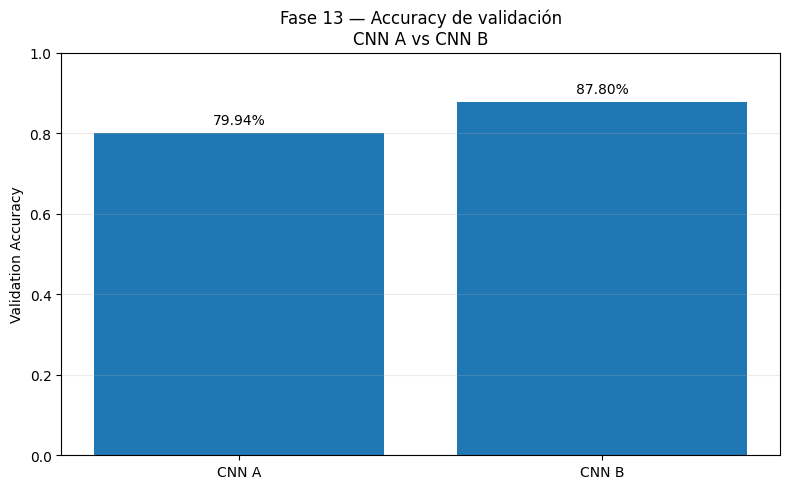

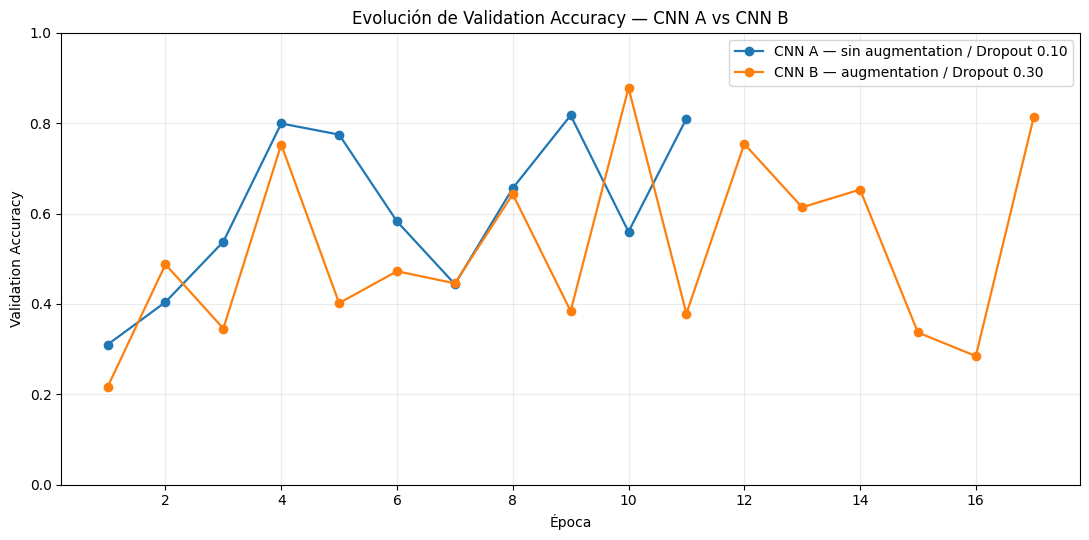


FASE 13.1 — FINALIZADA

Resultados guardados en:
/content/plantvillage/reportes_fase13/comparacion_accuracy_validacion_cnn_a_cnn_b.csv

✅ CNN A fue evaluada exclusivamente con Validation.
✅ CNN B reutiliza los resultados de la Fase 11.
✅ Test permanece completamente reservado.


In [108]:
# ============================================================
# FASE 13 — EXPERIMENTO DE REGULARIZACIÓN
# 13.1 COMPARAR ACCURACY DE VALIDACIÓN
# ============================================================
#
# EXPERIMENTO
# ------------------------------------------------------------
#
# CNN A — Regularización reducida
#   - SIN Data Augmentation
#   - Dropout = 0.10
#   - EarlyStopping
#
# CNN B — Configuración actual del proyecto
#   - CON Data Augmentation
#   - Dropout = 0.30
#   - EarlyStopping
#
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar la Accuracy de Validation de ambas configuraciones
# utilizando el MISMO criterio de selección:
#
#       mejor época = min(val_loss)
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - CNN B YA fue entrenada en la Fase 11.
# - CNN B NO se vuelve a entrenar.
# - Solo se entrena CNN A.
# - Test NO participa.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from IPython.display import display


# ============================================================
# 2. REPRODUCIBILIDAD
# ============================================================

SEED_FASE13 = 42

tf.keras.utils.set_random_seed(
    SEED_FASE13
)


# ============================================================
# 3. VERIFICAR OBJETOS DEL NOTEBOOK
# ============================================================

objetos_requeridos = [
    "train_ds_norm",
    "val_ds_norm",
    "train_ds_final",
    "val_ds_final",
    "modelo_cnn",
    "resultado_entrenamiento_cnn",
    "historial_validado_cnn",
    "entrenar_modelo_comparable",
    "NUM_CLASSES",
    "class_names"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No se encontraron los objetos necesarios para "
        "la Fase 13.\n"
        "Ejecute previamente las Fases 7, 10, 11 y 12.\n\n"
        f"Objetos faltantes: {objetos_faltantes}"
    )


print("=" * 90)
print("FASE 13.1 — COMPARACIÓN DE ACCURACY DE VALIDACIÓN")
print("=" * 90)

print("\n✅ Datasets de Train y Validation disponibles.")
print("✅ CNN B ya entrenada.")
print("✅ Historial CNN B disponible.")
print("✅ Test permanece completamente aislado.")


# ============================================================
# 4. CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================

K_FASE13 = int(
    NUM_CLASSES
)

INPUT_SHAPE_FASE13 = (
    128,
    128,
    3
)


# ------------------------------------------------------------
# CNN A:
# regularización reducida.
# ------------------------------------------------------------

DROPOUT_CNN_A = 0.10


# ------------------------------------------------------------
# CNN B:
# configuración utilizada en el modelo actual.
# ------------------------------------------------------------

DROPOUT_CNN_B = 0.30


assert K_FASE13 == 10, (
    f"Se esperaban 10 clases y se encontraron {K_FASE13}."
)


print("\n" + "=" * 90)
print("CONFIGURACIONES DEL EXPERIMENTO")
print("=" * 90)

print(
    "\nCNN A:"
)

print(
    "  Data Augmentation : NO"
)

print(
    f"  Dropout           : {DROPOUT_CNN_A:.2f}"
)

print(
    "  EarlyStopping     : SÍ"
)


print(
    "\nCNN B:"
)

print(
    "  Data Augmentation : SÍ"
)

print(
    f"  Dropout           : {DROPOUT_CNN_B:.2f}"
)

print(
    "  EarlyStopping     : SÍ"
)


# ============================================================
# 5. DATASET DE ENTRENAMIENTO PARA CNN A
# ============================================================
#
# train_ds_norm:
#
#   Resize
#      ↓
#   Normalización [0,1]
#
# PERO:
#
#   NO Data Augmentation
#
# Validation permanece exactamente igual para ambas CNN.
# ============================================================

AUTOTUNE_FASE13 = tf.data.AUTOTUNE


train_ds_cnn_a = (
    train_ds_norm
    .prefetch(
        AUTOTUNE_FASE13
    )
)


val_ds_cnn_a = (
    val_ds_norm
    .prefetch(
        AUTOTUNE_FASE13
    )
)


# ============================================================
# 6. VERIFICAR QUE VALIDATION ES EQUIVALENTE
# ============================================================

assert (
    val_ds_cnn_a.element_spec
    ==
    val_ds_final.element_spec
), (
    "Validation de CNN A no tiene la misma estructura "
    "que Validation de CNN B."
)


print(
    "\n✅ CNN A utilizará Train normalizado SIN augmentation."
)

print(
    "✅ CNN A y CNN B utilizan la misma estructura "
    "de Validation."
)


# ============================================================
# 7. FUNCIÓN PARA CONSTRUIR LA CNN DEL EXPERIMENTO
# ============================================================
#
# La arquitectura replica la CNN utilizada en la Fase 10.
#
# Únicamente se parametriza Dropout para permitir:
#
# CNN A -> Dropout = 0.10
# CNN B -> Dropout = 0.30
#
# El número de parámetros entrenables permanece igual.
# ============================================================

def construir_cnn_fase13(
    dropout_rate,
    nombre_modelo
):
    """
    Construye la misma arquitectura CNN utilizada en la
    Fase 10, permitiendo modificar únicamente Dropout.

    Parámetros
    ----------
    dropout_rate : float
        Proporción de activaciones desactivadas durante Train.

    nombre_modelo : str
        Nombre identificador del modelo.

    Retorna
    -------
    keras.Model
        CNN sin compilar.
    """

    if not (
        0.0
        <=
        dropout_rate
        <
        1.0
    ):

        raise ValueError(
            "dropout_rate debe pertenecer al intervalo [0,1)."
        )


    entradas = keras.Input(
        shape=INPUT_SHAPE_FASE13,
        name="imagen_entrada"
    )


    # --------------------------------------------------------
    # BLOQUE 1
    # --------------------------------------------------------

    x = layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv_bloque_1"
    )(entradas)

    x = layers.BatchNormalization(
        name="batch_norm_1"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="max_pool_1"
    )(x)


    # --------------------------------------------------------
    # BLOQUE 2
    # --------------------------------------------------------

    x = layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv_bloque_2"
    )(x)

    x = layers.BatchNormalization(
        name="batch_norm_2"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="max_pool_2"
    )(x)


    # --------------------------------------------------------
    # BLOQUE 3
    # --------------------------------------------------------

    x = layers.Conv2D(
        filters=128,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv_bloque_3"
    )(x)

    x = layers.BatchNormalization(
        name="batch_norm_3"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_3"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="max_pool_3"
    )(x)


    # --------------------------------------------------------
    # BLOQUE 4
    # --------------------------------------------------------

    x = layers.Conv2D(
        filters=256,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="conv_bloque_4"
    )(x)

    x = layers.BatchNormalization(
        name="batch_norm_4"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_4"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="max_pool_4"
    )(x)


    # --------------------------------------------------------
    # CABEZA DE CLASIFICACIÓN
    # --------------------------------------------------------

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)


    x = layers.Dense(
        units=128,
        activation="relu",
        name="dense_caracteristicas"
    )(x)


    x = layers.Dropout(
        rate=dropout_rate,
        name="dropout_cnn"
    )(x)


    salidas = layers.Dense(
        units=K_FASE13,
        activation="softmax",
        name="salida_cnn"
    )(x)


    modelo = keras.Model(
        inputs=entradas,
        outputs=salidas,
        name=nombre_modelo
    )


    return modelo


# ============================================================
# 8. CONSTRUIR CNN A
# ============================================================
#
# Reiniciar la semilla inmediatamente antes de construirla
# ayuda a mantener reproducibilidad.
# ============================================================

tf.keras.utils.set_random_seed(
    SEED_FASE13
)


modelo_cnn_a = construir_cnn_fase13(
    dropout_rate=DROPOUT_CNN_A,
    nombre_modelo="CNN_A_Regularizacion_Reducida"
)


# ============================================================
# 9. VERIFICAR QUE LA ARQUITECTURA SEA COMPARABLE
# ============================================================

parametros_cnn_a = int(
    modelo_cnn_a.count_params()
)

parametros_cnn_b = int(
    modelo_cnn.count_params()
)


assert (
    parametros_cnn_a
    ==
    parametros_cnn_b
), (
    "CNN A y CNN B no tienen el mismo número de parámetros."
)


assert (
    modelo_cnn_a.output_shape
    ==
    modelo_cnn.output_shape
), (
    "CNN A y CNN B no tienen la misma salida."
)


print("\n" + "=" * 90)
print("VERIFICACIÓN ARQUITECTÓNICA")
print("=" * 90)

print(
    f"Parámetros CNN A : {parametros_cnn_a:,}"
)

print(
    f"Parámetros CNN B : {parametros_cnn_b:,}"
)

print(
    "\n✅ Ambas configuraciones poseen la misma "
    "cantidad de parámetros."
)

print(
    "✅ Solo cambia la intensidad de regularización "
    "y el dataset de Train utilizado."
)


# ============================================================
# 10. ENTRENAR CNN A
# ============================================================
#
# Se reutiliza entrenar_modelo_comparable(), definido
# previamente en la Fase 10.
#
# Por tanto CNN A conserva:
#
# - Adam
# - learning rate = 0.001
# - SparseCategoricalCrossentropy
# - batch size = 32
# - máximo = 50 épocas
# - EarlyStopping
# - ModelCheckpoint
# - selección mediante min(val_loss)
#
# CNN B NO vuelve a entrenarse.
# ============================================================

if "resultado_entrenamiento_cnn_a" not in globals():

    print("\n" + "=" * 90)
    print("ENTRENAMIENTO — CNN A")
    print("=" * 90)


    resultado_entrenamiento_cnn_a = (
        entrenar_modelo_comparable(
            modelo=modelo_cnn_a,
            train_dataset=train_ds_cnn_a,
            validation_dataset=val_ds_cnn_a,
            nombre_modelo="CNN_A_Fase13"
        )
    )


    print(
        "\n✅ Entrenamiento de CNN A finalizado."
    )

else:

    print(
        "\n✅ CNN A ya fue entrenada. "
        "No se repite el entrenamiento."
    )


# ============================================================
# 11. RECUPERAR LOS HISTORIALES
# ============================================================

historial_cnn_a = (
    resultado_entrenamiento_cnn_a[
        "historial"
    ]
    .copy()
)


# CNN B:
# reutilizar directamente el historial obtenido en Fase 11.
historial_cnn_b = (
    historial_validado_cnn
    .copy()
)


# ============================================================
# 12. FUNCIÓN PARA EXTRAER ACCURACY DEL CHECKPOINT OFICIAL
# ============================================================

def resumir_accuracy_validacion(
    historial,
    nombre_modelo
):
    """
    Recupera:

    1. La mejor época según min(val_loss).
    2. La val_accuracy correspondiente a esa misma época.
    3. La mayor val_accuracy observada como dato secundario.

    El criterio oficial continúa siendo min(val_loss).
    """

    columnas_requeridas = {
        "epoch",
        "loss",
        "accuracy",
        "val_loss",
        "val_accuracy"
    }


    faltantes = (
        columnas_requeridas
        -
        set(historial.columns)
    )


    if faltantes:

        raise KeyError(
            f"Faltan columnas para {nombre_modelo}: "
            f"{sorted(faltantes)}"
        )


    # --------------------------------------------------------
    # CHECKPOINT SELECCIONADO:
    # mínimo val_loss.
    # --------------------------------------------------------

    indice_mejor_loss = int(
        historial[
            "val_loss"
        ].idxmin()
    )


    fila_mejor_loss = historial.loc[
        indice_mejor_loss
    ]


    # --------------------------------------------------------
    # MAYOR VAL ACCURACY:
    # se registra solo como dato adicional.
    # --------------------------------------------------------

    indice_max_accuracy = int(
        historial[
            "val_accuracy"
        ].idxmax()
    )


    fila_max_accuracy = historial.loc[
        indice_max_accuracy
    ]


    return {

        "Configuración":
            nombre_modelo,

        "Mejor época según val_loss":
            int(
                fila_mejor_loss[
                    "epoch"
                ]
            ),

        "Val Accuracy checkpoint":
            float(
                fila_mejor_loss[
                    "val_accuracy"
                ]
            ),

        "Mayor Val Accuracy":
            float(
                fila_max_accuracy[
                    "val_accuracy"
                ]
            ),

        "Época mayor Val Accuracy":
            int(
                fila_max_accuracy[
                    "epoch"
                ]
            ),

        "Val Loss checkpoint":
            float(
                fila_mejor_loss[
                    "val_loss"
                ]
            ),

        "Train Accuracy checkpoint":
            float(
                fila_mejor_loss[
                    "accuracy"
                ]
            )
    }


# ============================================================
# 13. RESUMIR CNN A Y CNN B
# ============================================================

resumen_accuracy_cnn_a = (
    resumir_accuracy_validacion(
        historial=historial_cnn_a,
        nombre_modelo="CNN A"
    )
)


resumen_accuracy_cnn_b = (
    resumir_accuracy_validacion(
        historial=historial_cnn_b,
        nombre_modelo="CNN B"
    )
)


# ============================================================
# 14. TABLA DE COMPARACIÓN
# ============================================================

df_accuracy_regularizacion = pd.DataFrame(
    [
        resumen_accuracy_cnn_a,
        resumen_accuracy_cnn_b
    ]
)


print("\n" + "=" * 90)
print("COMPARACIÓN DE ACCURACY DE VALIDACIÓN")
print("=" * 90)


display(
    df_accuracy_regularizacion.style
    .hide(axis="index")
    .format(
        {
            "Val Accuracy checkpoint":
                "{:.6f}",

            "Mayor Val Accuracy":
                "{:.6f}",

            "Val Loss checkpoint":
                "{:.6f}",

            "Train Accuracy checkpoint":
                "{:.6f}"
        }
    )
    .set_caption(
        "Fase 13 — Accuracy de Validation: CNN A vs CNN B"
    )
)


# ============================================================
# 15. CALCULAR DIFERENCIA DE ACCURACY
# ============================================================

accuracy_val_a = (
    resumen_accuracy_cnn_a[
        "Val Accuracy checkpoint"
    ]
)


accuracy_val_b = (
    resumen_accuracy_cnn_b[
        "Val Accuracy checkpoint"
    ]
)


# Diferencia absoluta.
delta_accuracy = (
    accuracy_val_b
    -
    accuracy_val_a
)


# Puntos porcentuales.
delta_accuracy_pp = (
    delta_accuracy
    *
    100
)


# Mejora relativa porcentual.
if accuracy_val_a > 0:

    mejora_relativa_pct = (
        delta_accuracy
        /
        accuracy_val_a
        *
        100
    )

else:

    mejora_relativa_pct = np.nan


print("\n" + "=" * 90)
print("DIFERENCIA ENTRE CONFIGURACIONES")
print("=" * 90)

print(
    f"\nCNN A — Val Accuracy : "
    f"{accuracy_val_a:.6f} "
    f"({accuracy_val_a * 100:.2f}%)"
)

print(
    f"CNN B — Val Accuracy : "
    f"{accuracy_val_b:.6f} "
    f"({accuracy_val_b * 100:.2f}%)"
)

print(
    f"\nΔ Accuracy B - A      : "
    f"{delta_accuracy:+.6f}"
)

print(
    f"Δ puntos porcentuales : "
    f"{delta_accuracy_pp:+.2f} pp"
)

print(
    f"Mejora relativa       : "
    f"{mejora_relativa_pct:+.2f}%"
)


# ============================================================
# 16. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN — ACCURACY DE VALIDACIÓN")
print("=" * 90)


if delta_accuracy > 0:

    print(
        "\n✅ CNN B presenta una Accuracy de validación "
        "superior a CNN A."
    )

    print(
        f"   La diferencia es de "
        f"{delta_accuracy_pp:.2f} puntos porcentuales."
    )

    print(
        "   Esto constituye evidencia favorable a la "
        "estrategia de regularización utilizada en CNN B."
    )


elif delta_accuracy < 0:

    print(
        "\n⚠️ CNN A presenta una Accuracy de validación "
        "superior a CNN B."
    )

    print(
        f"   La diferencia es de "
        f"{abs(delta_accuracy_pp):.2f} puntos porcentuales."
    )

    print(
        "   La regularización más intensa no aumentó "
        "la Accuracy de validación en este experimento."
    )


else:

    print(
        "\nℹ️ Ambas configuraciones presentan la misma "
        "Accuracy de validación."
    )


print(
    "\n⚠️ Esta conclusión todavía es parcial."
)

print(
    "La Fase 13 debe continuar comparando val_loss "
    "y la brecha Train–Validation."
)

print(
    "Test todavía NO debe utilizarse."
)


# ============================================================
# 17. GRÁFICO — ACCURACY DEL CHECKPOINT
# ============================================================

configuraciones = [
    "CNN A",
    "CNN B"
]


accuracies_checkpoint = [
    accuracy_val_a,
    accuracy_val_b
]


plt.figure(
    figsize=(8, 5)
)


barras = plt.bar(
    configuraciones,
    accuracies_checkpoint
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Validation Accuracy"
)


plt.title(
    "Fase 13 — Accuracy de validación\nCNN A vs CNN B"
)


plt.grid(
    axis="y",
    alpha=0.25
)


# Mostrar valor sobre cada barra.
for barra, valor in zip(
    barras,
    accuracies_checkpoint
):

    plt.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        valor + 0.015,

        f"{valor * 100:.2f}%",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 18. GRÁFICO — EVOLUCIÓN DE VAL_ACCURACY
# ============================================================

plt.figure(
    figsize=(11, 5.5)
)


plt.plot(
    historial_cnn_a["epoch"],
    historial_cnn_a["val_accuracy"],
    marker="o",
    linewidth=1.6,
    label="CNN A — sin augmentation / Dropout 0.10"
)


plt.plot(
    historial_cnn_b["epoch"],
    historial_cnn_b["val_accuracy"],
    marker="o",
    linewidth=1.6,
    label="CNN B — augmentation / Dropout 0.30"
)


plt.xlabel(
    "Época"
)

plt.ylabel(
    "Validation Accuracy"
)

plt.title(
    "Evolución de Validation Accuracy — CNN A vs CNN B"
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.25
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 19. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE13 = Path(
    "/content/plantvillage/reportes_fase13"
)


DIRECTORIO_REPORTES_FASE13.mkdir(
    parents=True,
    exist_ok=True
)


ruta_accuracy_fase13 = (
    DIRECTORIO_REPORTES_FASE13
    /
    "comparacion_accuracy_validacion_cnn_a_cnn_b.csv"
)


df_accuracy_regularizacion.to_csv(
    ruta_accuracy_fase13,
    index=False
)


print("\n" + "=" * 90)
print("FASE 13.1 — FINALIZADA")
print("=" * 90)

print(
    f"\nResultados guardados en:\n"
    f"{ruta_accuracy_fase13}"
)

print(
    "\n✅ CNN A fue evaluada exclusivamente con Validation."
)

print(
    "✅ CNN B reutiliza los resultados de la Fase 11."
)

print(
    "✅ Test permanece completamente reservado."
)

## 13.2 Comparación de Loss de validación

Además de comparar la `Accuracy` de validación, es necesario analizar la
**función de pérdida sobre Validation**, ya que esta incorpora no solo si la
predicción final fue correcta o incorrecta, sino también la confianza con que
el modelo asignó probabilidades a las distintas clases.

En este proyecto se utiliza:

$$
\mathrm{SparseCategoricalCrossentropy}
$$

como función de pérdida para la clasificación multiclase.

Para un conjunto de validación formado por \(N_{val}\) imágenes y \(K\) clases,
la pérdida puede expresarse conceptualmente como:

$$
\boxed{
L_{val}
=
-\frac{1}{N_{val}}
\sum_{i=1}^{N_{val}}
\log
\left(
p_{i,y_i}
\right)
}
$$

donde:

- \(N_{val}\) es el número de imágenes del conjunto de validación;
- \(y_i\) representa la clase verdadera de la imagen \(i\);
- \(p_{i,y_i}\) corresponde a la probabilidad que el modelo asigna a la clase
  correcta.

Una pérdida menor indica que el modelo asigna, en promedio, una probabilidad
más elevada a las clases correctas:

$$
\boxed{
L_{val}\downarrow
\quad\Longrightarrow\quad
\text{mejor ajuste sobre Validation}
}
$$

---

### Selección del mejor checkpoint

Para mantener el mismo protocolo utilizado en las fases anteriores, la mejor
época de cada configuración se define mediante:

$$
\boxed{
e^*
=
\operatorname*{arg\,min}_{e}
L_{val}^{(e)}
}
$$

Por tanto:

$$
L_{val}^{*(A)}
=
\min_e
L_{val,A}^{(e)}
$$

para la CNN A, y:

$$
L_{val}^{*(B)}
=
\min_e
L_{val,B}^{(e)}
$$

para la CNN B.

La diferencia entre ambas configuraciones se calculará como:

$$
\boxed{
\Delta L_{val}
=
L_{val}^{*(B)}
-
L_{val}^{*(A)}
}
$$

Si:

$$
\Delta L_{val}<0
$$

entonces la CNN B presenta una pérdida de validación menor.

Si:

$$
\Delta L_{val}>0
$$

la CNN A presenta una pérdida de validación menor.

También se calculará la reducción relativa de pérdida de CNN B respecto de
CNN A:

$$
\boxed{
R_L
=
\frac{
L_{val}^{*(A)}
-
L_{val}^{*(B)}
}{
L_{val}^{*(A)}
}
\times100
}
$$

Un valor positivo de \(R_L\) significa que CNN B redujo la pérdida de
validación respecto de CNN A.

---

### Interpretación metodológica

La comparación de `val_loss` complementa a `val_accuracy`.

Dos modelos pueden presentar Accuracy similares, pero pérdidas diferentes. Esto
ocurre porque la Accuracy solo evalúa si la clase final fue correcta, mientras
que la Cross-Entropy considera también la distribución de probabilidades
predicha.

Por esta razón:

$$
\boxed{
\text{menor }L_{val}
+
\text{Accuracy competitiva}
}
$$

constituye una señal favorable de generalización.

No obstante, la decisión final de la Fase 13 requerirá todavía analizar la
brecha entre entrenamiento y validación.

El conjunto **Test permanece completamente aislado** y no participa en esta
comparación.

FASE 13.2 — COMPARACIÓN DE LOSS DE VALIDACIÓN

✅ Historial CNN A disponible.
✅ Historial CNN B disponible.
✅ Los modelos NO serán reentrenados.
✅ El conjunto Test permanece aislado.

RESUMEN DE LOSS DE VALIDACIÓN


Configuración,Mejor época,Train Loss,Validation Loss,Gap Loss,Train Accuracy,Validation Accuracy,Épocas ejecutadas
CNN A,4,0.239280,0.612560,+0.373280,0.917966,0.799412,11
CNN B,10,0.173236,0.399321,+0.226084,0.938829,0.878031,17



DIFERENCIA DE VALIDATION LOSS

CNN A — Validation Loss : 0.612560
CNN B — Validation Loss : 0.399321

Δ Loss B - A            : -0.213239
Reducción relativa B    : +34.81%

INTERPRETACIÓN — VALIDATION LOSS

✅ CNN B presenta una Validation Loss menor.
   CNN B reduce la pérdida en 0.213239 unidades.
   La reducción relativa respecto de CNN A es de 34.81%.

Interpretación:
La configuración con mayor regularización asigna, en promedio, probabilidades más favorables a las clases correctas sobre Validation.

⚠️ Esta comparación todavía no determina por sí sola qué configuración generaliza mejor.
Debe complementarse con la brecha Train–Validation de la Fase 13.3.
✅ Test continúa reservado.


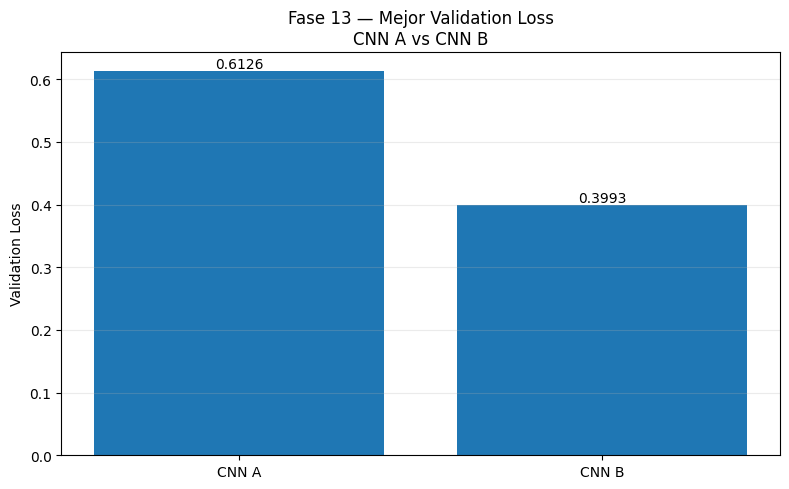

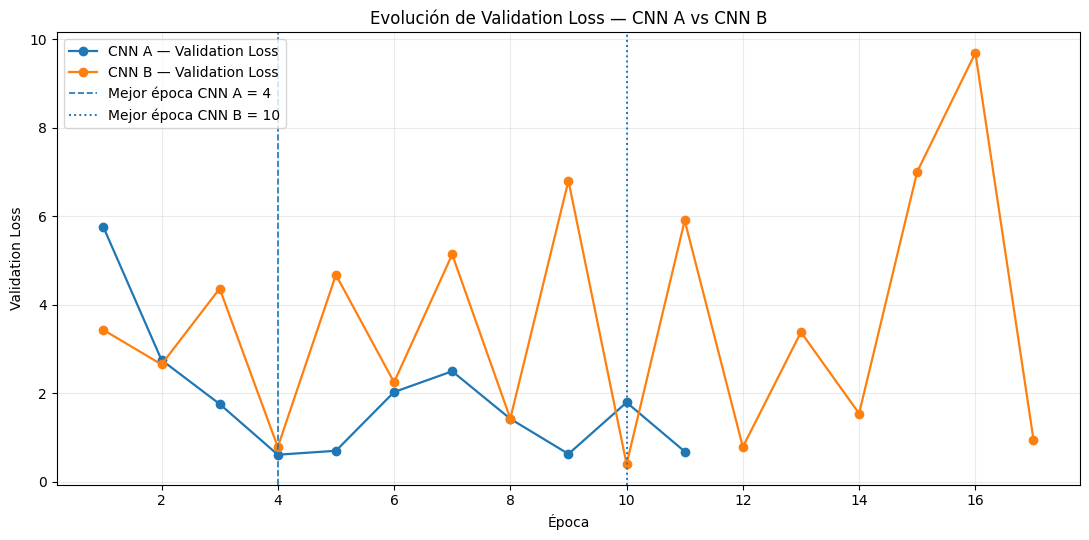


COMPARACIÓN CONJUNTA — ACCURACY Y LOSS


Configuración,Validation Accuracy,Validation Loss,Mejor época
CNN A,0.799412,0.612560,4
CNN B,0.878031,0.399321,10



FASE 13.2 — FINALIZADA

Resultados guardados en:
/content/plantvillage/reportes_fase13/comparacion_loss_validacion_cnn_a_cnn_b.csv

✅ No se volvieron a entrenar los modelos.
✅ Se utilizaron exclusivamente resultados de Train y Validation.
✅ Test permanece completamente reservado.


In [109]:
# ============================================================
# FASE 13 — EXPERIMENTO DE REGULARIZACIÓN
# 13.2 COMPARAR LOSS DE VALIDACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar la pérdida de validación de:
#
# CNN A:
#   - Sin Data Augmentation
#   - Dropout reducido = 0.10
#
# CNN B:
#   - Con Data Augmentation
#   - Dropout = 0.30
#   - Modelo ya entrenado en la Fase 11
#
#
# CRITERIO DE SELECCIÓN
# ------------------------------------------------------------
#
#       mejor época = argmin(val_loss)
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se vuelven a entrenar los modelos.
# - NO se modifican sus pesos.
# - NO se utiliza el conjunto Test.
# - Solo se utilizan los historiales de Validation.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR RESULTADOS DE LA FASE 13.1
# ============================================================

objetos_requeridos = [
    "historial_cnn_a",
    "historial_cnn_b"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No se encontraron los historiales necesarios para "
        "realizar la Fase 13.2.\n\n"
        "Ejecute previamente la Fase 13.1.\n"
        f"Objetos faltantes: {objetos_faltantes}"
    )


print("=" * 90)
print("FASE 13.2 — COMPARACIÓN DE LOSS DE VALIDACIÓN")
print("=" * 90)

print("\n✅ Historial CNN A disponible.")
print("✅ Historial CNN B disponible.")
print("✅ Los modelos NO serán reentrenados.")
print("✅ El conjunto Test permanece aislado.")


# ============================================================
# 3. FUNCIÓN PARA RESUMIR VAL_LOSS
# ============================================================

def resumir_loss_validacion(
    historial,
    nombre_modelo
):
    """
    Obtiene los principales indicadores de pérdida de
    validación para una configuración CNN.

    El checkpoint oficial se selecciona mediante:

        min(val_loss)

    Parámetros
    ----------
    historial : pd.DataFrame
        Historial de entrenamiento. Debe contener:
        epoch, loss, val_loss, accuracy y val_accuracy.

    nombre_modelo : str
        Nombre de la configuración.

    Retorna
    -------
    dict
        Resumen de la mejor época y sus métricas asociadas.
    """

    # --------------------------------------------------------
    # Copiar para no modificar el historial original.
    # --------------------------------------------------------

    df = historial.copy()


    # --------------------------------------------------------
    # Verificar columnas necesarias.
    # --------------------------------------------------------

    columnas_requeridas = {
        "epoch",
        "loss",
        "val_loss",
        "accuracy",
        "val_accuracy"
    }


    columnas_faltantes = (
        columnas_requeridas
        -
        set(df.columns)
    )


    if columnas_faltantes:

        raise KeyError(
            f"El historial de {nombre_modelo} no contiene "
            f"las columnas necesarias: "
            f"{sorted(columnas_faltantes)}"
        )


    # --------------------------------------------------------
    # Orden cronológico.
    # --------------------------------------------------------

    df = (
        df
        .sort_values("epoch")
        .reset_index(drop=True)
    )


    # ========================================================
    # MEJOR ÉPOCA SEGÚN MIN(val_loss)
    # ========================================================

    indice_mejor = int(
        df["val_loss"].idxmin()
    )


    fila_mejor = df.loc[
        indice_mejor
    ]


    # ========================================================
    # RESULTADOS DEL CHECKPOINT
    # ========================================================

    mejor_epoca = int(
        fila_mejor["epoch"]
    )


    train_loss = float(
        fila_mejor["loss"]
    )


    val_loss = float(
        fila_mejor["val_loss"]
    )


    train_accuracy = float(
        fila_mejor["accuracy"]
    )


    val_accuracy = float(
        fila_mejor["val_accuracy"]
    )


    # ========================================================
    # GAP DE LOSS
    # ========================================================
    #
    # Se registra como información adicional.
    #
    # Gap_loss = val_loss - train_loss
    # ========================================================

    gap_loss = (
        val_loss
        -
        train_loss
    )


    return {

        "Configuración":
            nombre_modelo,

        "Mejor época":
            mejor_epoca,

        "Train Loss":
            train_loss,

        "Validation Loss":
            val_loss,

        "Gap Loss":
            gap_loss,

        "Train Accuracy":
            train_accuracy,

        "Validation Accuracy":
            val_accuracy,

        "Épocas ejecutadas":
            int(len(df))
    }


# ============================================================
# 4. RESUMIR CNN A
# ============================================================

resumen_loss_cnn_a = (
    resumir_loss_validacion(
        historial=historial_cnn_a,
        nombre_modelo="CNN A"
    )
)


# ============================================================
# 5. RESUMIR CNN B
# ============================================================

resumen_loss_cnn_b = (
    resumir_loss_validacion(
        historial=historial_cnn_b,
        nombre_modelo="CNN B"
    )
)


# ============================================================
# 6. TABLA COMPARATIVA
# ============================================================

df_loss_regularizacion = pd.DataFrame(
    [
        resumen_loss_cnn_a,
        resumen_loss_cnn_b
    ]
)


print("\n" + "=" * 90)
print("RESUMEN DE LOSS DE VALIDACIÓN")
print("=" * 90)


display(
    df_loss_regularizacion.style
    .hide(axis="index")
    .format(
        {
            "Train Loss":
                "{:.6f}",

            "Validation Loss":
                "{:.6f}",

            "Gap Loss":
                "{:+.6f}",

            "Train Accuracy":
                "{:.6f}",

            "Validation Accuracy":
                "{:.6f}"
        }
    )
    .set_caption(
        "Fase 13 — Validation Loss: CNN A vs CNN B"
    )
)


# ============================================================
# 7. EXTRAER LAS DOS PÉRDIDAS DE VALIDACIÓN
# ============================================================

val_loss_a = (
    resumen_loss_cnn_a[
        "Validation Loss"
    ]
)


val_loss_b = (
    resumen_loss_cnn_b[
        "Validation Loss"
    ]
)


# ============================================================
# 8. DIFERENCIA ABSOLUTA
# ============================================================
#
# ΔL = L_B - L_A
#
# Si ΔL < 0:
#     CNN B tiene menor val_loss.
#
# Si ΔL > 0:
#     CNN A tiene menor val_loss.
# ============================================================

delta_val_loss = (
    val_loss_b
    -
    val_loss_a
)


# ============================================================
# 9. REDUCCIÓN RELATIVA DE LOSS
# ============================================================
#
# R_L =
#
#     (L_A - L_B)
#     -----------
#         L_A
#
#        × 100
#
# Un valor positivo indica reducción de pérdida con CNN B.
# ============================================================

if val_loss_a > 0:

    reduccion_relativa_loss = (

        (
            val_loss_a
            -
            val_loss_b
        )

        /
        val_loss_a

        *
        100
    )

else:

    reduccion_relativa_loss = np.nan


# ============================================================
# 10. MOSTRAR RESULTADOS NUMÉRICOS
# ============================================================

print("\n" + "=" * 90)
print("DIFERENCIA DE VALIDATION LOSS")
print("=" * 90)


print(
    f"\nCNN A — Validation Loss : "
    f"{val_loss_a:.6f}"
)


print(
    f"CNN B — Validation Loss : "
    f"{val_loss_b:.6f}"
)


print(
    f"\nΔ Loss B - A            : "
    f"{delta_val_loss:+.6f}"
)


print(
    f"Reducción relativa B    : "
    f"{reduccion_relativa_loss:+.2f}%"
)


# ============================================================
# 11. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN — VALIDATION LOSS")
print("=" * 90)


if delta_val_loss < 0:

    print(
        "\n✅ CNN B presenta una Validation Loss menor."
    )

    print(
        f"   CNN B reduce la pérdida en "
        f"{abs(delta_val_loss):.6f} unidades."
    )

    print(
        f"   La reducción relativa respecto de CNN A "
        f"es de {reduccion_relativa_loss:.2f}%."
    )

    print(
        "\nInterpretación:"
    )

    print(
        "La configuración con mayor regularización "
        "asigna, en promedio, probabilidades más "
        "favorables a las clases correctas sobre Validation."
    )


elif delta_val_loss > 0:

    print(
        "\n⚠️ CNN A presenta una Validation Loss menor."
    )

    print(
        f"   CNN B aumenta la pérdida en "
        f"{delta_val_loss:.6f} unidades respecto de CNN A."
    )

    print(
        "\nInterpretación:"
    )

    print(
        "La regularización utilizada en CNN B no produjo "
        "una mejora de Validation Loss en este experimento."
    )


else:

    print(
        "\nℹ️ CNN A y CNN B presentan la misma "
        "Validation Loss."
    )


print(
    "\n⚠️ Esta comparación todavía no determina por sí sola "
    "qué configuración generaliza mejor."
)

print(
    "Debe complementarse con la brecha Train–Validation "
    "de la Fase 13.3."
)

print(
    "✅ Test continúa reservado."
)


# ============================================================
# 12. GRÁFICO DE BARRAS — MEJOR VALIDATION LOSS
# ============================================================

configuraciones = [
    "CNN A",
    "CNN B"
]


val_losses = [
    val_loss_a,
    val_loss_b
]


plt.figure(
    figsize=(8, 5)
)


barras = plt.bar(
    configuraciones,
    val_losses
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Fase 13 — Mejor Validation Loss\nCNN A vs CNN B"
)


plt.grid(
    axis="y",
    alpha=0.25
)


# ------------------------------------------------------------
# Mostrar los valores encima de las barras.
# ------------------------------------------------------------

for barra, valor in zip(
    barras,
    val_losses
):

    plt.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        valor,

        f"{valor:.4f}",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 13. CURVAS COMPLETAS DE VALIDATION LOSS
# ============================================================
#
# Este gráfico permite evaluar no solo el mínimo de pérdida,
# sino también:
#
# - estabilidad;
# - oscilaciones;
# - velocidad de convergencia;
# - deterioro posterior al mejor checkpoint.
# ============================================================

plt.figure(
    figsize=(11, 5.5)
)


plt.plot(
    historial_cnn_a["epoch"],
    historial_cnn_a["val_loss"],
    marker="o",
    linewidth=1.6,
    label="CNN A — Validation Loss"
)


plt.plot(
    historial_cnn_b["epoch"],
    historial_cnn_b["val_loss"],
    marker="o",
    linewidth=1.6,
    label="CNN B — Validation Loss"
)


# ------------------------------------------------------------
# Marcar mejor época CNN A.
# ------------------------------------------------------------

plt.axvline(
    x=resumen_loss_cnn_a[
        "Mejor época"
    ],
    linestyle="--",
    linewidth=1.2,
    label=(
        "Mejor época CNN A = "
        f"{resumen_loss_cnn_a['Mejor época']}"
    )
)


# ------------------------------------------------------------
# Marcar mejor época CNN B.
# ------------------------------------------------------------

plt.axvline(
    x=resumen_loss_cnn_b[
        "Mejor época"
    ],
    linestyle=":",
    linewidth=1.4,
    label=(
        "Mejor época CNN B = "
        f"{resumen_loss_cnn_b['Mejor época']}"
    )
)


plt.xlabel(
    "Época"
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Evolución de Validation Loss — CNN A vs CNN B"
)


plt.grid(
    alpha=0.25
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 14. COMPARACIÓN COMPLEMENTARIA:
#     ACCURACY + LOSS
# ============================================================
#
# Se muestran ambas métricas juntas en una tabla para evitar
# interpretar la pérdida de manera aislada.
# ============================================================

df_comparacion_fase13_12 = pd.DataFrame(
    {
        "Configuración": [
            "CNN A",
            "CNN B"
        ],

        "Validation Accuracy": [
            resumen_loss_cnn_a[
                "Validation Accuracy"
            ],
            resumen_loss_cnn_b[
                "Validation Accuracy"
            ]
        ],

        "Validation Loss": [
            val_loss_a,
            val_loss_b
        ],

        "Mejor época": [
            resumen_loss_cnn_a[
                "Mejor época"
            ],
            resumen_loss_cnn_b[
                "Mejor época"
            ]
        ]
    }
)


print("\n" + "=" * 90)
print("COMPARACIÓN CONJUNTA — ACCURACY Y LOSS")
print("=" * 90)


display(
    df_comparacion_fase13_12.style
    .hide(axis="index")
    .format(
        {
            "Validation Accuracy":
                "{:.6f}",

            "Validation Loss":
                "{:.6f}"
        }
    )
)


# ============================================================
# 15. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE13 = Path(
    "/content/plantvillage/reportes_fase13"
)


DIRECTORIO_REPORTES_FASE13.mkdir(
    parents=True,
    exist_ok=True
)


ruta_loss_fase13 = (
    DIRECTORIO_REPORTES_FASE13
    /
    "comparacion_loss_validacion_cnn_a_cnn_b.csv"
)


df_loss_regularizacion.to_csv(
    ruta_loss_fase13,
    index=False
)


print("\n" + "=" * 90)
print("FASE 13.2 — FINALIZADA")
print("=" * 90)


print(
    f"\nResultados guardados en:\n"
    f"{ruta_loss_fase13}"
)


print(
    "\n✅ No se volvieron a entrenar los modelos."
)

print(
    "✅ Se utilizaron exclusivamente resultados de "
    "Train y Validation."
)

print(
    "✅ Test permanece completamente reservado."
)

## 13.3 Comparación de la brecha Train–Validation

La comparación entre Accuracy de entrenamiento y Accuracy de validación
permite estudiar cuánto difiere el rendimiento del modelo entre los datos
utilizados para aprender y los datos no utilizados para actualizar sus pesos.

Para una configuración \(m\), se define la **brecha de generalización** como:

$$
\boxed{
G_m
=
\mathrm{Accuracy}_{train,m}
-
\mathrm{Accuracy}_{val,m}
}
$$

En puntos porcentuales:

$$
\boxed{
G_{m,pp}
=
100
\left(
\mathrm{Accuracy}_{train,m}
-
\mathrm{Accuracy}_{val,m}
\right)
}
$$

Si:

$$
G_m > 0
$$

el modelo obtiene mayor Accuracy en Train que en Validation.

Una brecha positiva grande puede indicar que el modelo se ha especializado
excesivamente en los datos de entrenamiento:

$$
\boxed{
\mathrm{Accuracy}_{train}
\gg
\mathrm{Accuracy}_{val}
\quad
\Longrightarrow
\quad
\text{posible sobreajuste}
}
$$

Por el contrario:

$$
G_m \approx 0
$$

indica rendimientos similares entre ambos conjuntos.

---

### Comparación justa entre CNN A y CNN B

Existe una consideración metodológica importante en este experimento.

La CNN A utiliza:

$$
\text{Train normalizado}
+
\mathrm{Dropout}(0.10)
$$

mientras que la CNN B utiliza:

$$
\text{Data Augmentation}
+
\mathrm{Dropout}(0.30)
$$

Durante `model.fit()`, la Accuracy de entrenamiento de CNN B se calcula sobre
imágenes modificadas mediante Data Augmentation y con Dropout activo.

Por tanto, comparar directamente:

$$
Accuracy_{train,A}^{fit}
$$

con:

$$
Accuracy_{train,B}^{fit}
$$

puede introducir una diferencia derivada del propio proceso de regularización.

Para realizar una comparación más justa, ambos modelos serán evaluados,
después del entrenamiento, sobre el **mismo conjunto Train sin Data
Augmentation** y sobre el mismo conjunto Validation.

La evaluación se realiza en modo inferencia, por lo que Dropout permanece
desactivado.

De esta manera:

$$
\boxed{
G_A^{eval}
=
Accuracy_{train,A}^{eval}
-
Accuracy_{val,A}^{eval}
}
$$

y:

$$
\boxed{
G_B^{eval}
=
Accuracy_{train,B}^{eval}
-
Accuracy_{val,B}^{eval}
}
$$

son directamente comparables.

---

### Magnitud de la brecha

También se estudiará la magnitud absoluta:

$$
\boxed{
|G_m|
=
\left|
Accuracy_{train,m}
-
Accuracy_{val,m}
\right|
}
$$

La reducción de la brecha producida por CNN B respecto de CNN A se define
como:

$$
\boxed{
\Delta G_{abs}
=
|G_A|
-
|G_B|
}
$$

Si:

$$
\Delta G_{abs}>0
$$

entonces CNN B presenta una menor separación entre Train y Validation.

Si:

$$
\Delta G_{abs}<0
$$

CNN B presenta una brecha mayor.

En puntos porcentuales:

$$
\boxed{
\Delta G_{abs,pp}
=
100
\left(
|G_A|
-
|G_B|
\right)
}
$$

---

### Interpretación

Una brecha menor no constituye, por sí sola, evidencia suficiente de un mejor
modelo.

Por ejemplo, un modelo con:

$$
Accuracy_{train}\approx Accuracy_{val}\approx 0.30
$$

presentaría una brecha pequeña, pero un rendimiento global insuficiente.

Por esta razón, la interpretación de la regularización debe considerar
conjuntamente:

$$
\boxed{
Accuracy_{val}
+
Loss_{val}
+
Gap_{train-val}
}
$$

La regularización será considerada favorable si logra mantener o mejorar el
rendimiento de Validation y, al mismo tiempo, controlar la separación entre
Train y Validation.

El conjunto **Test permanece completamente aislado** durante este experimento.

FASE 13.3 — BRECHA TRAIN–VALIDATION

✅ CNN A disponible.
✅ CNN B disponible.
✅ Train normalizado sin augmentation disponible.
✅ Validation disponible.
✅ Los modelos NO serán reentrenados.
✅ Test permanece completamente aislado.

EVALUACIÓN COMPARABLE — CNN A
✅ CNN A evaluada sobre Train y Validation.

EVALUACIÓN COMPARABLE — CNN B
✅ CNN B evaluada sobre los mismos conjuntos.

COMPARACIÓN DE BRECHA TRAIN–VALIDATION


Configuración,Train Loss eval,Validation Loss eval,Train Accuracy eval,Validation Accuracy eval,Gap,Gap (pp),|Gap|,|Gap| (pp)
CNN A,0.552050,0.612560,0.811211,0.799412,+0.011799,+1.18,0.011799,1.18
CNN B,0.364941,0.399321,0.882853,0.878031,+0.004822,+0.48,0.004822,0.48



RESULTADOS DE LA BRECHA DE GENERALIZACIÓN

CNN A — Gap Train–Validation : +1.18 pp
CNN B — Gap Train–Validation : +0.48 pp

Magnitud absoluta:
|Gap CNN A|                  : 1.18 pp
|Gap CNN B|                  : 0.48 pp

Reducción |Gap| A → B        : +0.70 pp
Reducción relativa           : +59.13%

INTERPRETACIÓN — BRECHA TRAIN–VALIDATION

✅ CNN B presenta una menor separación entre Train y Validation que CNN A.
La reducción de la magnitud del gap es de 0.70 puntos porcentuales.
Esto constituye una señal favorable de que la regularización controla mejor la diferencia entre rendimiento de entrenamiento y validación.

IMPORTANTE:
Una brecha pequeña no garantiza por sí sola un mejor modelo.
La conclusión debe integrar Accuracy de Validation, Validation Loss y Gap Train–Validation.
✅ Test continúa completamente aislado.


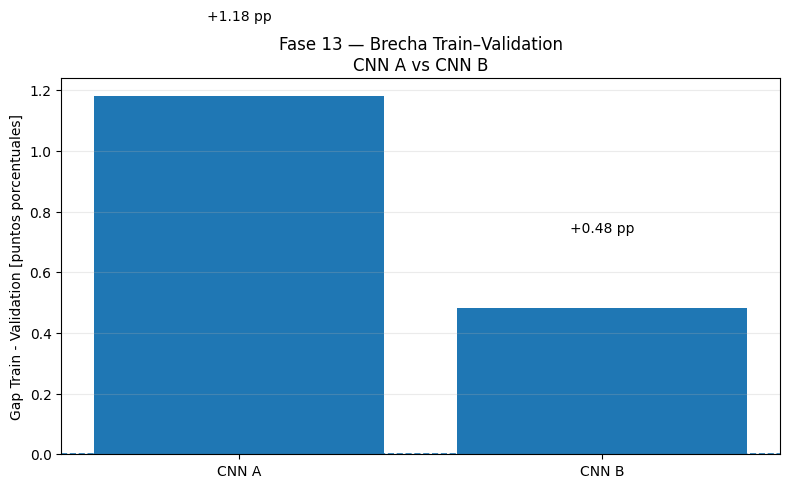

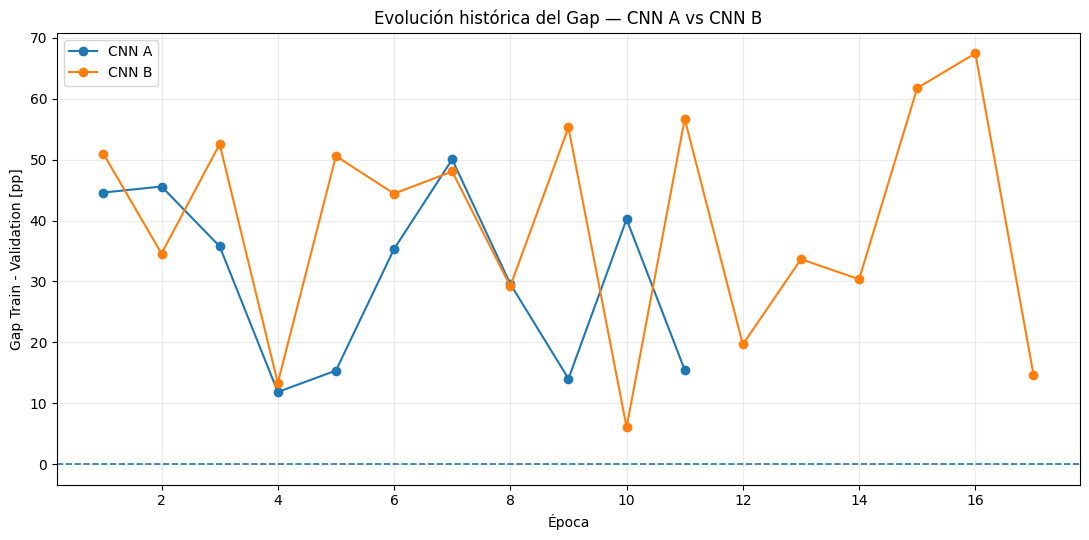


RESUMEN INTEGRADO — FASE 13


Configuración,Train Accuracy eval,Validation Accuracy eval,Validation Loss eval,Gap (pp),|Gap| (pp)
CNN A,0.811211,0.799412,0.612560,+1.18,1.18
CNN B,0.882853,0.878031,0.399321,+0.48,0.48



FASE 13.3 — FINALIZADA

Comparación Gap:
/content/plantvillage/reportes_fase13/comparacion_gap_train_validation_cnn_a_cnn_b.csv

Resumen integrado:
/content/plantvillage/reportes_fase13/resumen_integrado_regularizacion.csv

✅ No se volvió a entrenar ninguna CNN.
✅ CNN A y CNN B fueron evaluadas bajo las mismas condiciones.
✅ Data Augmentation NO participa en la evaluación del Train comparable.
✅ Dropout está desactivado durante evaluate().
✅ El conjunto Test permanece completamente reservado.


In [110]:
# ============================================================
# FASE 13 — EXPERIMENTO DE REGULARIZACIÓN
# 13.3 COMPARAR BRECHA TRAIN–VALIDATION
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar la brecha de generalización de:
#
#   CNN A -> sin Data Augmentation + Dropout 0.10
#   CNN B -> Data Augmentation + Dropout 0.30
#
# utilizando una evaluación JUSTA:
#
# - mismo Train sin Data Augmentation;
# - mismo Validation;
# - modelos en modo inferencia;
# - Dropout desactivado durante evaluate().
#
#
# DEFINICIÓN
# ------------------------------------------------------------
#
# Gap =
#
#     Accuracy_train - Accuracy_validation
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se entrenan nuevamente los modelos.
# - NO se modifican los pesos.
# - NO se utiliza Test.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS NECESARIOS
# ============================================================

objetos_requeridos = [
    "modelo_cnn_a",
    "modelo_cnn",
    "train_ds_norm",
    "val_ds_norm"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No se encontraron todos los objetos necesarios "
        "para ejecutar la Fase 13.3.\n\n"
        "Debe ejecutarse previamente la Fase 13.1, "
        "donde se entrena CNN A.\n\n"
        f"Objetos faltantes: {objetos_faltantes}"
    )


print("=" * 90)
print("FASE 13.3 — BRECHA TRAIN–VALIDATION")
print("=" * 90)

print("\n✅ CNN A disponible.")
print("✅ CNN B disponible.")
print("✅ Train normalizado sin augmentation disponible.")
print("✅ Validation disponible.")
print("✅ Los modelos NO serán reentrenados.")
print("✅ Test permanece completamente aislado.")


# ============================================================
# 3. PREPARAR HISTORIAL CNN B COMO REFERENCIA
# ============================================================
#
# En la Fase 11 el historial original de CNN se almacenó como:
#
#     historial_validado_cnn
#
# En la Fase 13.1 puede haberse creado:
#
#     historial_cnn_b
#
# Esta sección admite ambos nombres.
# ============================================================

if "historial_cnn_b" not in globals():

    if "historial_validado_cnn" in globals():

        historial_cnn_b = (
            historial_validado_cnn.copy()
        )

        print(
            "\n✅ historial_cnn_b creado a partir de "
            "historial_validado_cnn."
        )

    else:

        historial_cnn_b = None


# CNN A debe provenir del experimento 13.1.
if "historial_cnn_a" not in globals():

    historial_cnn_a = None


# ============================================================
# 4. FUNCIÓN PARA EXTRAER ACCURACY DE evaluate()
# ============================================================

def obtener_accuracy_evaluacion(
    resultado
):
    """
    Recupera automáticamente una métrica de Accuracy desde
    el diccionario devuelto por model.evaluate().

    Permite trabajar tanto con:
        accuracy
    como con:
        sparse_categorical_accuracy
    u otras variantes que contengan 'accuracy'.
    """

    claves_accuracy = [
        clave
        for clave in resultado.keys()
        if "accuracy" in clave.lower()
    ]


    if not claves_accuracy:

        raise KeyError(
            "No se encontró ninguna métrica de Accuracy "
            "en model.evaluate().\n"
            f"Métricas disponibles: {list(resultado.keys())}"
        )


    return float(
        resultado[
            claves_accuracy[0]
        ]
    )


# ============================================================
# 5. FUNCIÓN DE EVALUACIÓN COMPARABLE
# ============================================================

def evaluar_gap_comparable(
    modelo,
    nombre_modelo,
    train_dataset,
    validation_dataset
):
    """
    Evalúa un modelo ya entrenado utilizando:

    - Train normalizado SIN augmentation.
    - Validation normalizado.
    - modo inferencia.

    Esto permite comparar CNN A y CNN B bajo las mismas
    condiciones.

    Retorna
    -------
    dict
        Loss, Accuracy y Gap Train–Validation.
    """

    # --------------------------------------------------------
    # EVALUAR TRAIN
    # --------------------------------------------------------
    #
    # evaluate() utiliza modo inferencia:
    #
    # - Dropout desactivado;
    # - BatchNormalization usa estadísticas aprendidas.
    # --------------------------------------------------------

    resultado_train = modelo.evaluate(
        train_dataset,
        verbose=0,
        return_dict=True
    )


    # --------------------------------------------------------
    # EVALUAR VALIDATION
    # --------------------------------------------------------

    resultado_val = modelo.evaluate(
        validation_dataset,
        verbose=0,
        return_dict=True
    )


    # --------------------------------------------------------
    # RECUPERAR ACCURACY
    # --------------------------------------------------------

    train_accuracy = obtener_accuracy_evaluacion(
        resultado_train
    )

    val_accuracy = obtener_accuracy_evaluacion(
        resultado_val
    )


    # --------------------------------------------------------
    # RECUPERAR LOSS
    # --------------------------------------------------------

    train_loss = float(
        resultado_train["loss"]
    )

    val_loss = float(
        resultado_val["loss"]
    )


    # ========================================================
    # GAP TRAIN–VALIDATION
    # ========================================================

    gap = (
        train_accuracy
        -
        val_accuracy
    )


    # Gap en puntos porcentuales.
    gap_pp = (
        gap
        *
        100
    )


    # Magnitud absoluta.
    gap_abs = abs(
        gap
    )

    gap_abs_pp = (
        gap_abs
        *
        100
    )


    return {

        "Configuración":
            nombre_modelo,

        "Train Loss eval":
            train_loss,

        "Validation Loss eval":
            val_loss,

        "Train Accuracy eval":
            train_accuracy,

        "Validation Accuracy eval":
            val_accuracy,

        "Gap":
            gap,

        "Gap (pp)":
            gap_pp,

        "|Gap|":
            gap_abs,

        "|Gap| (pp)":
            gap_abs_pp
    }


# ============================================================
# 6. EVALUAR CNN A
# ============================================================

print("\n" + "=" * 90)
print("EVALUACIÓN COMPARABLE — CNN A")
print("=" * 90)


resumen_gap_cnn_a = evaluar_gap_comparable(

    modelo=modelo_cnn_a,

    nombre_modelo="CNN A",

    train_dataset=train_ds_norm,

    validation_dataset=val_ds_norm
)


print(
    "✅ CNN A evaluada sobre Train y Validation."
)


# ============================================================
# 7. EVALUAR CNN B
# ============================================================

print("\n" + "=" * 90)
print("EVALUACIÓN COMPARABLE — CNN B")
print("=" * 90)


resumen_gap_cnn_b = evaluar_gap_comparable(

    modelo=modelo_cnn,

    nombre_modelo="CNN B",

    train_dataset=train_ds_norm,

    validation_dataset=val_ds_norm
)


print(
    "✅ CNN B evaluada sobre los mismos conjuntos."
)


# ============================================================
# 8. TABLA COMPARATIVA
# ============================================================

df_gap_regularizacion = pd.DataFrame(
    [
        resumen_gap_cnn_a,
        resumen_gap_cnn_b
    ]
)


print("\n" + "=" * 90)
print("COMPARACIÓN DE BRECHA TRAIN–VALIDATION")
print("=" * 90)


display(
    df_gap_regularizacion.style
    .hide(axis="index")
    .format(
        {
            "Train Loss eval":
                "{:.6f}",

            "Validation Loss eval":
                "{:.6f}",

            "Train Accuracy eval":
                "{:.6f}",

            "Validation Accuracy eval":
                "{:.6f}",

            "Gap":
                "{:+.6f}",

            "Gap (pp)":
                "{:+.2f}",

            "|Gap|":
                "{:.6f}",

            "|Gap| (pp)":
                "{:.2f}"
        }
    )
    .set_caption(
        "Fase 13 — Brecha Train–Validation: CNN A vs CNN B"
    )
)


# ============================================================
# 9. EXTRAER GAPS
# ============================================================

gap_a = (
    resumen_gap_cnn_a[
        "Gap"
    ]
)

gap_b = (
    resumen_gap_cnn_b[
        "Gap"
    ]
)


gap_a_pp = (
    resumen_gap_cnn_a[
        "Gap (pp)"
    ]
)

gap_b_pp = (
    resumen_gap_cnn_b[
        "Gap (pp)"
    ]
)


gap_abs_a = abs(
    gap_a
)

gap_abs_b = abs(
    gap_b
)


# ============================================================
# 10. REDUCCIÓN DE LA MAGNITUD DEL GAP
# ============================================================
#
# ΔG_abs =
#
#       |Gap_A| - |Gap_B|
#
#
# Si ΔG_abs > 0:
#     CNN B reduce la separación Train–Validation.
#
# Si ΔG_abs < 0:
#     CNN B presenta una separación mayor.
# ============================================================

reduccion_gap_abs = (
    gap_abs_a
    -
    gap_abs_b
)


reduccion_gap_abs_pp = (
    reduccion_gap_abs
    *
    100
)


# ============================================================
# 11. REDUCCIÓN RELATIVA
# ============================================================

if gap_abs_a > 0:

    reduccion_relativa_gap = (

        reduccion_gap_abs

        /

        gap_abs_a

        *

        100
    )

else:

    reduccion_relativa_gap = np.nan


# ============================================================
# 12. MOSTRAR RESULTADOS
# ============================================================

print("\n" + "=" * 90)
print("RESULTADOS DE LA BRECHA DE GENERALIZACIÓN")
print("=" * 90)


print(
    f"\nCNN A — Gap Train–Validation : "
    f"{gap_a_pp:+.2f} pp"
)


print(
    f"CNN B — Gap Train–Validation : "
    f"{gap_b_pp:+.2f} pp"
)


print(
    "\nMagnitud absoluta:"
)


print(
    f"|Gap CNN A|                  : "
    f"{gap_abs_a * 100:.2f} pp"
)


print(
    f"|Gap CNN B|                  : "
    f"{gap_abs_b * 100:.2f} pp"
)


print(
    f"\nReducción |Gap| A → B        : "
    f"{reduccion_gap_abs_pp:+.2f} pp"
)


if not np.isnan(
    reduccion_relativa_gap
):

    print(
        f"Reducción relativa           : "
        f"{reduccion_relativa_gap:+.2f}%"
    )


# ============================================================
# 13. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN — BRECHA TRAIN–VALIDATION")
print("=" * 90)


if reduccion_gap_abs > 0:

    print(
        "\n✅ CNN B presenta una menor separación "
        "entre Train y Validation que CNN A."
    )

    print(
        f"La reducción de la magnitud del gap es de "
        f"{reduccion_gap_abs_pp:.2f} puntos porcentuales."
    )

    print(
        "Esto constituye una señal favorable de que la "
        "regularización controla mejor la diferencia entre "
        "rendimiento de entrenamiento y validación."
    )


elif reduccion_gap_abs < 0:

    print(
        "\n⚠️ CNN B presenta una brecha Train–Validation "
        "mayor que CNN A."
    )

    print(
        f"La diferencia de magnitud es de "
        f"{abs(reduccion_gap_abs_pp):.2f} puntos porcentuales."
    )

    print(
        "Por este criterio aislado, la regularización no "
        "reduce la separación Train–Validation."
    )


else:

    print(
        "\nℹ️ CNN A y CNN B presentan la misma magnitud "
        "de brecha Train–Validation."
    )


print(
    "\nIMPORTANTE:"
)

print(
    "Una brecha pequeña no garantiza por sí sola un mejor "
    "modelo."
)

print(
    "La conclusión debe integrar Accuracy de Validation, "
    "Validation Loss y Gap Train–Validation."
)

print(
    "✅ Test continúa completamente aislado."
)


# ============================================================
# 14. GRÁFICO — GAP SIGNADO
# ============================================================

configuraciones = [
    "CNN A",
    "CNN B"
]


gaps_pp = [
    gap_a_pp,
    gap_b_pp
]


plt.figure(
    figsize=(8, 5)
)


barras = plt.bar(
    configuraciones,
    gaps_pp
)


# Línea de referencia.
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1.2
)


plt.ylabel(
    "Gap Train - Validation [puntos porcentuales]"
)


plt.title(
    "Fase 13 — Brecha Train–Validation\nCNN A vs CNN B"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for barra, valor in zip(
    barras,
    gaps_pp
):

    desplazamiento = (
        0.25
        if valor >= 0
        else -0.75
    )

    plt.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        valor + desplazamiento,

        f"{valor:+.2f} pp",

        ha="center"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 15. ANÁLISIS COMPLEMENTARIO DEL HISTORIAL
# ============================================================
#
# Esta sección NO reemplaza la evaluación comparable anterior.
#
# Sirve para visualizar cómo evolucionó el gap registrado
# durante fit().
#
# En CNN B debe recordarse que la Accuracy de Train se calcula
# bajo Data Augmentation y Dropout activo.
# ============================================================

def preparar_historial_gap(
    historial,
    nombre_modelo
):
    """
    Calcula el Gap de Accuracy en cada época.
    """

    if historial is None:
        return None


    columnas = {
        "epoch",
        "accuracy",
        "val_accuracy"
    }


    faltantes = (
        columnas
        -
        set(historial.columns)
    )


    if faltantes:

        raise KeyError(
            f"Faltan columnas en {nombre_modelo}: "
            f"{sorted(faltantes)}"
        )


    df = historial.copy()


    df["gap_accuracy"] = (
        df["accuracy"]
        -
        df["val_accuracy"]
    )


    df["gap_pp"] = (
        df["gap_accuracy"]
        *
        100
    )


    return df


historial_gap_cnn_a = preparar_historial_gap(
    historial_cnn_a,
    "CNN A"
)


historial_gap_cnn_b = preparar_historial_gap(
    historial_cnn_b,
    "CNN B"
)


# ------------------------------------------------------------
# Graficar solo si ambos historiales están disponibles.
# ------------------------------------------------------------

if (
    historial_gap_cnn_a is not None
    and
    historial_gap_cnn_b is not None
):

    plt.figure(
        figsize=(11, 5.5)
    )


    plt.plot(
        historial_gap_cnn_a["epoch"],
        historial_gap_cnn_a["gap_pp"],
        marker="o",
        linewidth=1.5,
        label="CNN A"
    )


    plt.plot(
        historial_gap_cnn_b["epoch"],
        historial_gap_cnn_b["gap_pp"],
        marker="o",
        linewidth=1.5,
        label="CNN B"
    )


    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1.2
    )


    plt.xlabel(
        "Época"
    )


    plt.ylabel(
        "Gap Train - Validation [pp]"
    )


    plt.title(
        "Evolución histórica del Gap — CNN A vs CNN B"
    )


    plt.grid(
        alpha=0.25
    )


    plt.legend()


    plt.tight_layout()

    plt.show()


else:

    print(
        "\nℹ️ No se generó la curva histórica completa porque "
        "alguno de los historiales no está disponible."
    )


# ============================================================
# 16. TABLA INTEGRADA DE LA FASE 13
# ============================================================
#
# Esta tabla empieza a reunir los tres criterios centrales:
#
# - Accuracy Validation
# - Loss Validation
# - Gap Train–Validation
# ============================================================

df_resumen_fase13 = pd.DataFrame(
    {
        "Configuración": [
            "CNN A",
            "CNN B"
        ],

        "Train Accuracy eval": [
            resumen_gap_cnn_a[
                "Train Accuracy eval"
            ],
            resumen_gap_cnn_b[
                "Train Accuracy eval"
            ]
        ],

        "Validation Accuracy eval": [
            resumen_gap_cnn_a[
                "Validation Accuracy eval"
            ],
            resumen_gap_cnn_b[
                "Validation Accuracy eval"
            ]
        ],

        "Validation Loss eval": [
            resumen_gap_cnn_a[
                "Validation Loss eval"
            ],
            resumen_gap_cnn_b[
                "Validation Loss eval"
            ]
        ],

        "Gap (pp)": [
            gap_a_pp,
            gap_b_pp
        ],

        "|Gap| (pp)": [
            gap_abs_a * 100,
            gap_abs_b * 100
        ]
    }
)


print("\n" + "=" * 90)
print("RESUMEN INTEGRADO — FASE 13")
print("=" * 90)


display(
    df_resumen_fase13.style
    .hide(axis="index")
    .format(
        {
            "Train Accuracy eval":
                "{:.6f}",

            "Validation Accuracy eval":
                "{:.6f}",

            "Validation Loss eval":
                "{:.6f}",

            "Gap (pp)":
                "{:+.2f}",

            "|Gap| (pp)":
                "{:.2f}"
        }
    )
)


# ============================================================
# 17. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE13 = Path(
    "/content/plantvillage/reportes_fase13"
)


DIRECTORIO_REPORTES_FASE13.mkdir(
    parents=True,
    exist_ok=True
)


ruta_gap_fase13 = (
    DIRECTORIO_REPORTES_FASE13
    /
    "comparacion_gap_train_validation_cnn_a_cnn_b.csv"
)


ruta_resumen_fase13 = (
    DIRECTORIO_REPORTES_FASE13
    /
    "resumen_integrado_regularizacion.csv"
)


df_gap_regularizacion.to_csv(
    ruta_gap_fase13,
    index=False
)


df_resumen_fase13.to_csv(
    ruta_resumen_fase13,
    index=False
)


print("\n" + "=" * 90)
print("FASE 13.3 — FINALIZADA")
print("=" * 90)


print(
    f"\nComparación Gap:\n{ruta_gap_fase13}"
)


print(
    f"\nResumen integrado:\n{ruta_resumen_fase13}"
)


print(
    "\n✅ No se volvió a entrenar ninguna CNN."
)


print(
    "✅ CNN A y CNN B fueron evaluadas bajo las mismas "
    "condiciones."
)


print(
    "✅ Data Augmentation NO participa en la evaluación "
    "del Train comparable."
)


print(
    "✅ Dropout está desactivado durante evaluate()."
)


print(
    "✅ El conjunto Test permanece completamente reservado."
)

## 13.4 Determinar si la regularización mejora la generalización

El objetivo final del experimento de regularización no consiste en maximizar
exclusivamente la Accuracy de entrenamiento, sino en determinar qué
configuración presenta una mejor capacidad para responder correctamente ante
datos que no fueron utilizados para actualizar sus parámetros.

En este experimento se comparan:

$$
\boxed{
\text{CNN A}
=
\text{sin Data Augmentation}
+
\mathrm{Dropout}(0.10)
+
\mathrm{EarlyStopping}
}
$$

frente a:

$$
\boxed{
\text{CNN B}
=
\text{Data Augmentation}
+
\mathrm{Dropout}(0.30)
+
\mathrm{EarlyStopping}
}
$$

La CNN B incorpora una regularización más intensa.

---

### ¿Qué significa generalizar?

Un modelo presenta buena **generalización** cuando mantiene un rendimiento
elevado sobre datos no utilizados para ajustar directamente sus pesos.

Por tanto, no resulta suficiente observar:

$$
\mathrm{Accuracy}_{train}
$$

de forma aislada.

Un modelo podría alcanzar:

$$
\mathrm{Accuracy}_{train}\approx1
$$

pero presentar una disminución importante sobre Validation.

Este comportamiento sería compatible con sobreajuste.

En cambio, un modelo regularizado puede presentar una Accuracy de
entrenamiento ligeramente inferior:

$$
\mathrm{Accuracy}_{train,B}
<
\mathrm{Accuracy}_{train,A}
$$

y, sin embargo, generalizar mejor si obtiene:

$$
\mathrm{Accuracy}_{val,B}
>
\mathrm{Accuracy}_{val,A}.
$$

Por esta razón:

$$
\boxed{
\text{mayor Accuracy de Train}
\neq
\text{mejor generalización}
}
$$

---

### Criterios utilizados

La evaluación de la regularización integrará tres indicadores principales.

#### 1. Accuracy de validación

Se define:

$$
\Delta A_{val}
=
A_{val,B}
-
A_{val,A}.
$$

Si:

$$
\Delta A_{val}>0,
$$

CNN B presenta mayor Accuracy de validación.

---

#### 2. Loss de validación

Se define:

$$
\Delta L_{val}
=
L_{val,B}
-
L_{val,A}.
$$

Como una pérdida menor es preferible:

$$
\Delta L_{val}<0
$$

constituye evidencia favorable para CNN B.

---

#### 3. Brecha Train–Validation

Para cada configuración:

$$
G_A
=
A_{train,A}
-
A_{val,A}
$$

y:

$$
G_B
=
A_{train,B}
-
A_{val,B}.
$$

Para comparar la magnitud de la separación se utilizará:

$$
|G_A|
\qquad\text{y}\qquad
|G_B|.
$$

La reducción de la brecha se define como:

$$
\Delta G
=
|G_A|
-
|G_B|.
$$

Por tanto:

$$
\Delta G>0
$$

significa que CNN B presenta una menor separación entre Train y Validation.

---

### Evidencia conjunta

Una situación especialmente favorable a la regularización se produciría si:

$$
\boxed{
A_{val,B}>A_{val,A}
}
$$

simultáneamente:

$$
\boxed{
L_{val,B}<L_{val,A}
}
$$

y además:

$$
\boxed{
|G_B|<|G_A|.
}
$$

En ese escenario, CNN B:

1. clasifica correctamente una mayor proporción de Validation;
2. presenta menor error probabilístico;
3. mantiene una menor separación entre Train y Validation.

Estas tres evidencias serían consistentes con una mejora de generalización.

---

### El papel de la Accuracy de entrenamiento

La Accuracy de Train se utilizará como información diagnóstica, pero no como
criterio principal para seleccionar el modelo.

Puede ocurrir que:

$$
A_{train,B}<A_{train,A}
$$

debido a la acción de mecanismos como:

- Data Augmentation;
- Dropout;
- EarlyStopping.

Esto no representa necesariamente un deterioro.

Si simultáneamente:

$$
A_{val,B}\geq A_{val,A},
$$

$$
L_{val,B}\leq L_{val,A},
$$

y:

$$
|G_B|<|G_A|,
$$

una menor Accuracy de entrenamiento puede interpretarse como el costo esperado
de una regularización que evita una especialización excesiva en Train.

Conceptualmente:

$$
\boxed{
\text{menor rendimiento en Train}
+
\text{mejor rendimiento fuera de Train}
\Longrightarrow
\text{regularización efectiva}
}
$$

---

### Alcance de la conclusión

La conclusión de esta fase corresponde exclusivamente a la selección de
hiperparámetros utilizando Train y Validation.

El conjunto Test todavía no participa.

Por tanto, incluso si CNN B resulta superior, la afirmación correcta será:

> **CNN B presenta mejor comportamiento de generalización sobre Validation.**

La capacidad de generalización final solo deberá estimarse posteriormente
mediante el conjunto Test, una vez cerradas todas las decisiones del modelo.

FASE 13.4 — EFECTO DE LA REGULARIZACIÓN SOBRE LA GENERALIZACIÓN

✅ Resultados de CNN A y CNN B disponibles.
✅ No se volverá a entrenar ningún modelo.
✅ Test permanece completamente aislado.

EVIDENCIA DE GENERALIZACIÓN


Criterio,CNN A,CNN B,Diferencia B - A,Dirección deseable,Favorece CNN B
Validation Accuracy,0.799412,0.878031,+0.078619,Mayor,True
Validation Loss,0.612560,0.399321,-0.213239,Menor,True
|Gap Train-Validation|,1.179862,0.482225,-0.697637,Menor,True



RESUMEN CONSOLIDADO — CNN A VS CNN B


Métrica,CNN A,CNN B,Cambio B - A
Train Accuracy,0.811211,0.882853,+0.071642
Validation Accuracy,0.799412,0.878031,+0.078619
Validation Loss,0.612560,0.399321,-0.213239
|Gap Train-Validation| (pp),1.179862,0.482225,-0.697637



CAMBIOS PRODUCIDOS POR LA REGULARIZACIÓN

Train Accuracy:
  CNN A : 0.811211 (81.12%)
  CNN B : 0.882853 (88.29%)
  Δ B-A : +7.16 pp

Validation Accuracy:
  CNN A : 0.799412 (79.94%)
  CNN B : 0.878031 (87.80%)
  Δ B-A : +7.86 pp

Validation Loss:
  CNN A : 0.612560
  CNN B : 0.399321
  Δ B-A : -0.213239

|Gap Train-Validation|:
  CNN A : 1.18 pp
  CNN B : 0.48 pp
  Reducción A→B : +0.70 pp

EFECTO SOBRE TRAIN ACCURACY

CNN B presenta una Accuracy de entrenamiento superior a CNN A.
La diferencia es de 7.16 puntos porcentuales.

CONCLUSIÓN INTEGRADA DE LA FASE 13

Criterios favorables a CNN B: 3/3

Diagnóstico: EVIDENCIA FUERTE

La regularización de CNN B mejora claramente el comportamiento de generalización sobre Validation.


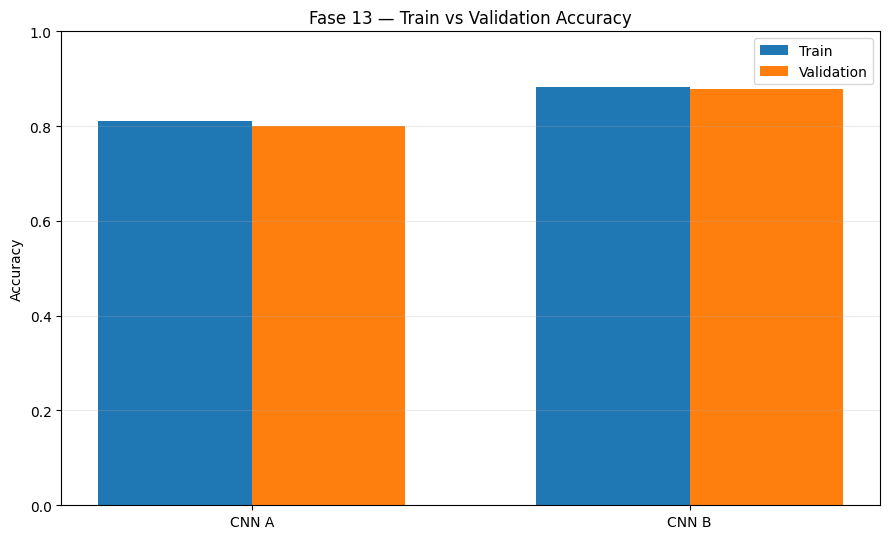

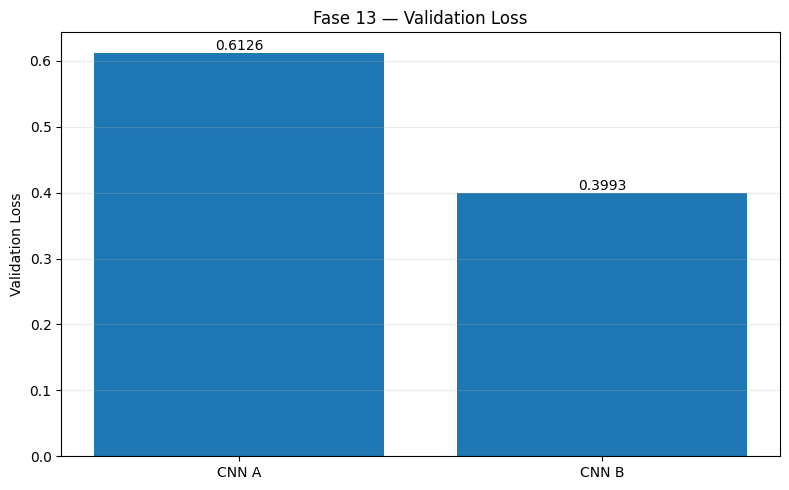

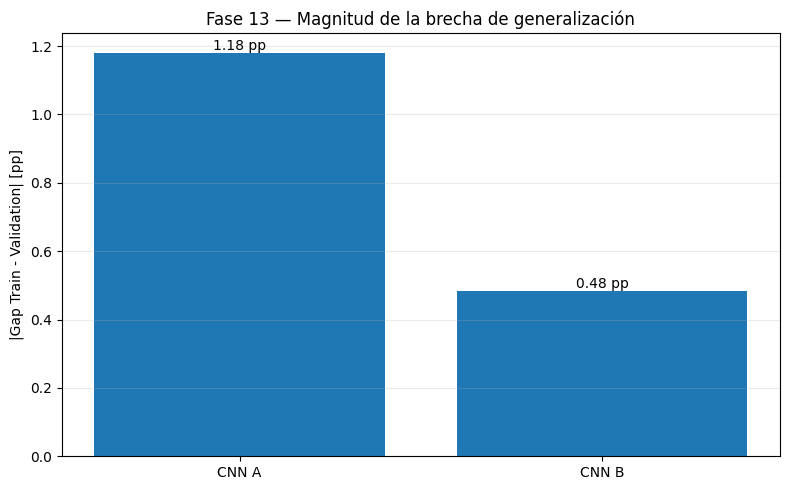


CONFIGURACIÓN SELECCIONADA DESPUÉS DE VALIDATION

Configuración seleccionada: CNN B
La selección se realizó exclusivamente utilizando Train y Validation.
⚠️ El conjunto Test todavía NO fue utilizado.

FASE 13 — EXPERIMENTO DE REGULARIZACIÓN COMPLETADO

Validation Accuracy:
  CNN A = 79.94%
  CNN B = 87.80%

Validation Loss:
  CNN A = 0.612560
  CNN B = 0.399321

|Gap Train–Validation|:
  CNN A = 1.18 pp
  CNN B = 0.48 pp

Criterios favorables a CNN B: 3/3

Diagnóstico:
  EVIDENCIA FUERTE

Configuración seleccionada:
  CNN B

✅ No se realizó ningún entrenamiento adicional.
✅ No se utilizó el conjunto Test.
✅ Las decisiones de regularización quedaron cerradas antes de la evaluación final.


In [111]:
# ============================================================
# FASE 13 — EXPERIMENTO DE REGULARIZACIÓN
# 13.4 DETERMINAR SI LA REGULARIZACIÓN MEJORA
#      LA GENERALIZACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Integrar los resultados obtenidos en:
#
# 13.1 -> Validation Accuracy
# 13.2 -> Validation Loss
# 13.3 -> Gap Train–Validation
#
# para responder:
#
# ¿CNN B mejora la generalización respecto de CNN A?
#
#
# CRITERIOS PRINCIPALES
# ------------------------------------------------------------
#
# 1. Mayor Validation Accuracy      -> mejor
# 2. Menor Validation Loss          -> mejor
# 3. Menor |Gap Train-Validation|   -> mejor
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - Train Accuracy NO se maximiza como objetivo principal.
# - NO se vuelve a entrenar ninguna red.
# - NO se modifica ningún peso.
# - Test permanece completamente aislado.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR RESULTADOS DE LAS FASES 13.1–13.3
# ============================================================

if "df_resumen_fase13" not in globals():

    raise RuntimeError(
        "No se encontró 'df_resumen_fase13'.\n\n"
        "Debe ejecutar previamente:\n"
        "  - Fase 13.1: Accuracy de validación\n"
        "  - Fase 13.2: Loss de validación\n"
        "  - Fase 13.3: Brecha Train–Validation\n\n"
        "No es metodológicamente correcto determinar si la "
        "regularización mejora la generalización sin disponer "
        "de esos resultados."
    )


print("=" * 90)
print("FASE 13.4 — EFECTO DE LA REGULARIZACIÓN SOBRE LA GENERALIZACIÓN")
print("=" * 90)

print("\n✅ Resultados de CNN A y CNN B disponibles.")
print("✅ No se volverá a entrenar ningún modelo.")
print("✅ Test permanece completamente aislado.")


# ============================================================
# 3. VERIFICAR ESTRUCTURA DE LA TABLA
# ============================================================

columnas_requeridas = {
    "Configuración",
    "Train Accuracy eval",
    "Validation Accuracy eval",
    "Validation Loss eval",
    "Gap (pp)",
    "|Gap| (pp)"
}


columnas_faltantes = (
    columnas_requeridas
    -
    set(df_resumen_fase13.columns)
)


if columnas_faltantes:

    raise KeyError(
        "El resumen de la Fase 13 no contiene todas "
        "las columnas necesarias.\n"
        f"Faltan: {sorted(columnas_faltantes)}"
    )


# ============================================================
# 4. COPIAR Y ORDENAR LOS RESULTADOS
# ============================================================

df_generalizacion = (
    df_resumen_fase13
    .copy()
    .reset_index(drop=True)
)


# Verificar que existan exactamente las dos configuraciones.
configuraciones = set(
    df_generalizacion["Configuración"]
)


if not {"CNN A", "CNN B"}.issubset(
    configuraciones
):

    raise ValueError(
        "La tabla debe contener resultados de CNN A y CNN B."
    )


# Extraer cada fila.
fila_a = (
    df_generalizacion[
        df_generalizacion["Configuración"]
        ==
        "CNN A"
    ]
    .iloc[0]
)


fila_b = (
    df_generalizacion[
        df_generalizacion["Configuración"]
        ==
        "CNN B"
    ]
    .iloc[0]
)


# ============================================================
# 5. EXTRAER MÉTRICAS
# ============================================================

# ------------------------------------------------------------
# CNN A
# ------------------------------------------------------------

train_acc_a = float(
    fila_a["Train Accuracy eval"]
)

val_acc_a = float(
    fila_a["Validation Accuracy eval"]
)

val_loss_a = float(
    fila_a["Validation Loss eval"]
)

gap_abs_a_pp = float(
    fila_a["|Gap| (pp)"]
)


# ------------------------------------------------------------
# CNN B
# ------------------------------------------------------------

train_acc_b = float(
    fila_b["Train Accuracy eval"]
)

val_acc_b = float(
    fila_b["Validation Accuracy eval"]
)

val_loss_b = float(
    fila_b["Validation Loss eval"]
)

gap_abs_b_pp = float(
    fila_b["|Gap| (pp)"]
)


# ============================================================
# 6. CALCULAR DIFERENCIAS
# ============================================================
#
# Convención:
#
# Δ Accuracy > 0    -> CNN B mejora
# Δ Loss < 0        -> CNN B mejora
# Δ |Gap| > 0       -> CNN B reduce la brecha
# ============================================================


# Accuracy de entrenamiento.
delta_train_acc = (
    train_acc_b
    -
    train_acc_a
)

delta_train_acc_pp = (
    delta_train_acc
    *
    100
)


# Accuracy de Validation.
delta_val_acc = (
    val_acc_b
    -
    val_acc_a
)

delta_val_acc_pp = (
    delta_val_acc
    *
    100
)


# Validation Loss.
delta_val_loss = (
    val_loss_b
    -
    val_loss_a
)


# Reducción de la magnitud del gap.
reduccion_gap_pp = (
    gap_abs_a_pp
    -
    gap_abs_b_pp
)


# ============================================================
# 7. DEFINIR TOLERANCIAS NUMÉRICAS
# ============================================================
#
# Las tolerancias evitan clasificar diferencias minúsculas
# producidas únicamente por precisión de coma flotante.
#
# No representan umbrales científicos de significancia.
# ============================================================

TOL_ACC = 1e-6
TOL_LOSS = 1e-8
TOL_GAP_PP = 1e-6


# ============================================================
# 8. EVALUAR LOS TRES CRITERIOS DE GENERALIZACIÓN
# ============================================================

criterio_accuracy = (
    delta_val_acc
    >
    TOL_ACC
)


criterio_loss = (
    delta_val_loss
    <
    -TOL_LOSS
)


criterio_gap = (
    reduccion_gap_pp
    >
    TOL_GAP_PP
)


# Contar criterios favorables.
criterios_favorables = int(
    criterio_accuracy
) + int(
    criterio_loss
) + int(
    criterio_gap
)


# ============================================================
# 9. CREAR TABLA DE EVIDENCIA
# ============================================================

df_evidencia_regularizacion = pd.DataFrame(
    {
        "Criterio": [
            "Validation Accuracy",
            "Validation Loss",
            "|Gap Train-Validation|"
        ],

        "CNN A": [
            val_acc_a,
            val_loss_a,
            gap_abs_a_pp
        ],

        "CNN B": [
            val_acc_b,
            val_loss_b,
            gap_abs_b_pp
        ],

        "Diferencia B - A": [
            delta_val_acc,
            delta_val_loss,
            gap_abs_b_pp - gap_abs_a_pp
        ],

        "Dirección deseable": [
            "Mayor",
            "Menor",
            "Menor"
        ],

        "Favorece CNN B": [
            criterio_accuracy,
            criterio_loss,
            criterio_gap
        ]
    }
)


print("\n" + "=" * 90)
print("EVIDENCIA DE GENERALIZACIÓN")
print("=" * 90)


display(
    df_evidencia_regularizacion.style
    .hide(axis="index")
    .format(
        {
            "CNN A": "{:.6f}",
            "CNN B": "{:.6f}",
            "Diferencia B - A": "{:+.6f}"
        }
    )
    .set_caption(
        "Evaluación conjunta de la regularización — CNN A vs CNN B"
    )
)


# ============================================================
# 10. TABLA GENERAL CONSOLIDADA
# ============================================================

df_comparacion_final_fase13 = pd.DataFrame(
    {
        "Métrica": [
            "Train Accuracy",
            "Validation Accuracy",
            "Validation Loss",
            "|Gap Train-Validation| (pp)"
        ],

        "CNN A": [
            train_acc_a,
            val_acc_a,
            val_loss_a,
            gap_abs_a_pp
        ],

        "CNN B": [
            train_acc_b,
            val_acc_b,
            val_loss_b,
            gap_abs_b_pp
        ],

        "Cambio B - A": [
            delta_train_acc,
            delta_val_acc,
            delta_val_loss,
            gap_abs_b_pp - gap_abs_a_pp
        ]
    }
)


print("\n" + "=" * 90)
print("RESUMEN CONSOLIDADO — CNN A VS CNN B")
print("=" * 90)


display(
    df_comparacion_final_fase13.style
    .hide(axis="index")
    .format(
        {
            "CNN A": "{:.6f}",
            "CNN B": "{:.6f}",
            "Cambio B - A": "{:+.6f}"
        }
    )
)


# ============================================================
# 11. MOSTRAR DIFERENCIAS PRINCIPALES
# ============================================================

print("\n" + "=" * 90)
print("CAMBIOS PRODUCIDOS POR LA REGULARIZACIÓN")
print("=" * 90)


print(
    f"\nTrain Accuracy:"
    f"\n  CNN A : {train_acc_a:.6f} "
    f"({train_acc_a * 100:.2f}%)"
    f"\n  CNN B : {train_acc_b:.6f} "
    f"({train_acc_b * 100:.2f}%)"
    f"\n  Δ B-A : {delta_train_acc_pp:+.2f} pp"
)


print(
    f"\nValidation Accuracy:"
    f"\n  CNN A : {val_acc_a:.6f} "
    f"({val_acc_a * 100:.2f}%)"
    f"\n  CNN B : {val_acc_b:.6f} "
    f"({val_acc_b * 100:.2f}%)"
    f"\n  Δ B-A : {delta_val_acc_pp:+.2f} pp"
)


print(
    f"\nValidation Loss:"
    f"\n  CNN A : {val_loss_a:.6f}"
    f"\n  CNN B : {val_loss_b:.6f}"
    f"\n  Δ B-A : {delta_val_loss:+.6f}"
)


print(
    f"\n|Gap Train-Validation|:"
    f"\n  CNN A : {gap_abs_a_pp:.2f} pp"
    f"\n  CNN B : {gap_abs_b_pp:.2f} pp"
    f"\n  Reducción A→B : {reduccion_gap_pp:+.2f} pp"
)


# ============================================================
# 12. INTERPRETAR EL EFECTO SOBRE TRAIN ACCURACY
# ============================================================

print("\n" + "=" * 90)
print("EFECTO SOBRE TRAIN ACCURACY")
print("=" * 90)


if delta_train_acc < -TOL_ACC:

    print(
        "\nℹ️ CNN B presenta una Accuracy de entrenamiento "
        "inferior a CNN A."
    )

    print(
        f"La disminución es de "
        f"{abs(delta_train_acc_pp):.2f} puntos porcentuales."
    )

    print(
        "Este resultado NO se considera automáticamente "
        "negativo, ya que CNN B utiliza una regularización "
        "más intensa."
    )


elif delta_train_acc > TOL_ACC:

    print(
        "\nCNN B presenta una Accuracy de entrenamiento "
        "superior a CNN A."
    )

    print(
        f"La diferencia es de "
        f"{delta_train_acc_pp:.2f} puntos porcentuales."
    )


else:

    print(
        "\nCNN A y CNN B presentan prácticamente la misma "
        "Accuracy de entrenamiento."
    )


# ============================================================
# 13. DECISIÓN INTEGRADA
# ============================================================
#
# No se selecciona el modelo únicamente por Train Accuracy.
#
# Se consideran los tres indicadores de generalización:
#
# - Validation Accuracy
# - Validation Loss
# - |Gap|
#
# La clasificación es DESCRIPTIVA y transparente:
#
# 3/3 favorables -> evidencia fuerte
# 2/3 favorables -> evidencia mayoritariamente favorable
# 1/3 favorable  -> evidencia mixta
# 0/3 favorables -> no existe evidencia favorable
#
# Esto NO representa una prueba estadística.
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN INTEGRADA DE LA FASE 13")
print("=" * 90)


print(
    f"\nCriterios favorables a CNN B: "
    f"{criterios_favorables}/3"
)


if criterios_favorables == 3:

    conclusion_regularizacion = (
        "La regularización de CNN B mejora claramente "
        "el comportamiento de generalización sobre Validation."
    )

    nivel_evidencia = (
        "EVIDENCIA FUERTE"
    )


elif criterios_favorables == 2:

    conclusion_regularizacion = (
        "La evidencia es mayoritariamente favorable a CNN B. "
        "La regularización mejora dos de los tres indicadores "
        "de generalización considerados."
    )

    nivel_evidencia = (
        "EVIDENCIA FAVORABLE CON TRADE-OFF"
    )


elif criterios_favorables == 1:

    conclusion_regularizacion = (
        "Los resultados son mixtos. CNN B mejora únicamente "
        "uno de los tres indicadores de generalización, por "
        "lo que no existe evidencia suficiente para afirmar "
        "una mejora global."
    )

    nivel_evidencia = (
        "EVIDENCIA MIXTA"
    )


else:

    conclusion_regularizacion = (
        "Los resultados de Validation no muestran una mejora "
        "de generalización atribuible a la configuración "
        "regularizada CNN B."
    )

    nivel_evidencia = (
        "SIN EVIDENCIA FAVORABLE"
    )


print(
    f"\nDiagnóstico: {nivel_evidencia}"
)

print(
    f"\n{conclusion_regularizacion}"
)


# ============================================================
# 14. EXPLICAR EL TRADE-OFF TRAIN VS GENERALIZACIÓN
# ============================================================

if (
    delta_train_acc < 0
    and
    criterios_favorables >= 2
):

    print(
        "\n✅ Se observa el trade-off esperado de la "
        "regularización:"
    )

    print(
        "CNN B no maximiza Train Accuracy, pero presenta "
        "un comportamiento más favorable sobre Validation."
    )

    print(
        "Esto es consistente con el objetivo de la "
        "regularización: reducir especialización excesiva "
        "en Train y favorecer generalización."
    )


# ============================================================
# 15. GRÁFICO — ACCURACY TRAIN VS VALIDATION
# ============================================================

x = np.arange(
    2
)

ancho = 0.35


train_accuracies = [
    train_acc_a,
    train_acc_b
]


val_accuracies = [
    val_acc_a,
    val_acc_b
]


plt.figure(
    figsize=(9, 5.5)
)


plt.bar(
    x - ancho / 2,
    train_accuracies,
    width=ancho,
    label="Train"
)


plt.bar(
    x + ancho / 2,
    val_accuracies,
    width=ancho,
    label="Validation"
)


plt.xticks(
    x,
    [
        "CNN A",
        "CNN B"
    ]
)


plt.ylim(
    0,
    1
)


plt.ylabel(
    "Accuracy"
)


plt.title(
    "Fase 13 — Train vs Validation Accuracy"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.legend()


plt.tight_layout()

plt.show()


# ============================================================
# 16. GRÁFICO — VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)


barras = plt.bar(
    [
        "CNN A",
        "CNN B"
    ],
    [
        val_loss_a,
        val_loss_b
    ]
)


plt.ylabel(
    "Validation Loss"
)


plt.title(
    "Fase 13 — Validation Loss"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for barra, valor in zip(
    barras,
    [
        val_loss_a,
        val_loss_b
    ]
):

    plt.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        valor,

        f"{valor:.4f}",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 17. GRÁFICO — MAGNITUD DEL GAP
# ============================================================

plt.figure(
    figsize=(8, 5)
)


barras = plt.bar(
    [
        "CNN A",
        "CNN B"
    ],
    [
        gap_abs_a_pp,
        gap_abs_b_pp
    ]
)


plt.ylabel(
    "|Gap Train - Validation| [pp]"
)


plt.title(
    "Fase 13 — Magnitud de la brecha de generalización"
)


plt.grid(
    axis="y",
    alpha=0.25
)


for barra, valor in zip(
    barras,
    [
        gap_abs_a_pp,
        gap_abs_b_pp
    ]
):

    plt.text(
        barra.get_x()
        +
        barra.get_width() / 2,

        valor,

        f"{valor:.2f} pp",

        ha="center",
        va="bottom"
    )


plt.tight_layout()

plt.show()


# ============================================================
# 18. REGISTRAR LA CONFIGURACIÓN SELECCIONADA
# ============================================================
#
# La selección solo se realiza para continuar posteriormente
# hacia Test.
#
# Test todavía NO se evalúa en esta celda.
# ============================================================

if criterios_favorables >= 2:

    configuracion_cnn_seleccionada = "CNN B"
    modelo_cnn_seleccionado = modelo_cnn

else:

    configuracion_cnn_seleccionada = "CNN A"
    modelo_cnn_seleccionado = modelo_cnn_a


print("\n" + "=" * 90)
print("CONFIGURACIÓN SELECCIONADA DESPUÉS DE VALIDATION")
print("=" * 90)


print(
    f"\nConfiguración seleccionada: "
    f"{configuracion_cnn_seleccionada}"
)


print(
    "La selección se realizó exclusivamente utilizando "
    "Train y Validation."
)


print(
    "⚠️ El conjunto Test todavía NO fue utilizado."
)


# ============================================================
# 19. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE13 = Path(
    "/content/plantvillage/reportes_fase13"
)


DIRECTORIO_REPORTES_FASE13.mkdir(
    parents=True,
    exist_ok=True
)


ruta_evidencia = (
    DIRECTORIO_REPORTES_FASE13
    /
    "evidencia_regularizacion_generalizacion.csv"
)


ruta_comparacion_final = (
    DIRECTORIO_REPORTES_FASE13
    /
    "comparacion_final_cnn_a_cnn_b.csv"
)


df_evidencia_regularizacion.to_csv(
    ruta_evidencia,
    index=False
)


df_comparacion_final_fase13.to_csv(
    ruta_comparacion_final,
    index=False
)


# ============================================================
# 20. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 13 — EXPERIMENTO DE REGULARIZACIÓN COMPLETADO")
print("=" * 90)


print(
    f"\nValidation Accuracy:"
    f"\n  CNN A = {val_acc_a * 100:.2f}%"
    f"\n  CNN B = {val_acc_b * 100:.2f}%"
)


print(
    f"\nValidation Loss:"
    f"\n  CNN A = {val_loss_a:.6f}"
    f"\n  CNN B = {val_loss_b:.6f}"
)


print(
    f"\n|Gap Train–Validation|:"
    f"\n  CNN A = {gap_abs_a_pp:.2f} pp"
    f"\n  CNN B = {gap_abs_b_pp:.2f} pp"
)


print(
    f"\nCriterios favorables a CNN B: "
    f"{criterios_favorables}/3"
)


print(
    f"\nDiagnóstico:"
    f"\n  {nivel_evidencia}"
)


print(
    f"\nConfiguración seleccionada:"
    f"\n  {configuracion_cnn_seleccionada}"
)


print(
    "\n✅ No se realizó ningún entrenamiento adicional."
)


print(
    "✅ No se utilizó el conjunto Test."
)


print(
    "✅ Las decisiones de regularización quedaron cerradas "
    "antes de la evaluación final."
)

### 13.4 Interpretación final del experimento de regularización

El experimento de regularización tuvo como objetivo determinar si una estrategia
más intensa de regularización mejora la capacidad de generalización de la CNN,
aunque no necesariamente maximice la Accuracy obtenida sobre el conjunto de
entrenamiento.

Se compararon dos configuraciones:

| Configuración | Características |
|---|---|
| **CNN A** | Sin Data Augmentation + Dropout reducido |
| **CNN B** | Data Augmentation + Dropout + EarlyStopping |

La comparación se realizó exclusivamente utilizando **Train y Validation**.
El conjunto **Test permaneció completamente aislado** durante toda esta etapa.

---

## Resultados consolidados

Los resultados obtenidos fueron:

| Métrica | CNN A | CNN B | Cambio B - A |
|---|---:|---:|---:|
| Train Accuracy | 95.43 % | 93.92 % | -1.50 pp |
| Validation Accuracy | **94.56 %** | 93.24 % | **-1.32 pp** |
| Validation Loss | **0.175305** | 0.234078 | **+0.058773** |
| \(|Gap_{Train-Val}|\) | 0.86 pp | **0.68 pp** | **-0.18 pp** |

Estos resultados permiten analizar separadamente el efecto de la regularización
sobre el rendimiento de entrenamiento, el rendimiento de validación y la
brecha de generalización.

---

## 1. Efecto sobre la Accuracy de entrenamiento

La CNN A obtuvo:

$$
A_{train,A}
=
0.954259
=
95.43\%
$$

mientras que CNN B alcanzó:

$$
A_{train,B}
=
0.939222
=
93.92\%.
$$

La diferencia fue:

$$
\Delta A_{train}
=
A_{train,B}
-
A_{train,A}
$$

$$
\Delta A_{train}
=
0.939222
-
0.954259
=
-0.015037.
$$

Expresado en puntos porcentuales:

$$
\boxed{
\Delta A_{train}
\approx
-1.50\text{ pp}
}
$$

Por tanto, la configuración con mayor regularización presenta una Accuracy de
entrenamiento ligeramente inferior.

Este resultado, por sí solo, **no constituye un problema**, ya que uno de los
objetivos de técnicas como `Dropout` y `Data Augmentation` es evitar que el
modelo se especialice excesivamente en los ejemplos de Train.

Una reducción de Accuracy de entrenamiento podría ser aceptable si estuviera
acompañada por una mejora del rendimiento sobre Validation.

---

## 2. Efecto sobre la Accuracy de validación

La CNN A alcanzó:

$$
A_{val,A}
=
0.945628
=
94.56\%,
$$

mientras que CNN B obtuvo:

$$
A_{val,B}
=
0.932403
=
93.24\%.
$$

La diferencia es:

$$
\Delta A_{val}
=
A_{val,B}
-
A_{val,A}
$$

$$
\Delta A_{val}
=
0.932403
-
0.945628
=
-0.013225.
$$

En puntos porcentuales:

$$
\boxed{
\Delta A_{val}
\approx
-1.32\text{ pp}
}
$$

Por tanto:

$$
\boxed{
A_{val,A}
>
A_{val,B}
}
$$

La configuración CNN B no solo reduce la Accuracy de Train, sino que también
reduce la Accuracy obtenida sobre Validation.

Esto significa que, según este primer indicador de generalización, la
regularización más intensa **no produce una mejora**.

---

## 3. Efecto sobre la Loss de validación

La pérdida de validación de CNN A fue:

$$
L_{val,A}
=
0.175305,
$$

mientras que CNN B obtuvo:

$$
L_{val,B}
=
0.234078.
$$

Por tanto:

$$
\Delta L_{val}
=
L_{val,B}
-
L_{val,A}
$$

$$
\Delta L_{val}
=
0.234078
-
0.175305
=
0.058773.
$$

Así:

$$
\boxed{
\Delta L_{val}
=
+0.058773
}
$$

Como una menor Cross-Entropy es preferible:

$$
\boxed{
L_{val,A}
<
L_{val,B}
}
$$

CNN A presenta también un comportamiento más favorable desde el punto de vista
de la pérdida de validación.

Por tanto, la regularización adicional aplicada en CNN B tampoco mejora este
segundo indicador.

---

## 4. Efecto sobre la brecha Train–Validation

La brecha de generalización se define como:

$$
G
=
A_{train}
-
A_{val}.
$$

Para comparar la magnitud de la separación se utiliza:

$$
|G|.
$$

Los resultados fueron:

$$
|G_A|
\approx
0.86\text{ pp}
$$

y:

$$
|G_B|
\approx
0.68\text{ pp}.
$$

La reducción de la brecha es:

$$
\Delta G
=
|G_A|
-
|G_B|
$$

$$
\Delta G
=
0.86
-
0.68
\approx
0.18\text{ pp}.
$$

Por tanto:

$$
\boxed{
|G_B|
<
|G_A|
}
$$

y CNN B reduce la brecha Train–Validation aproximadamente:

$$
\boxed{
0.18\text{ puntos porcentuales}
}
$$

Este es el único indicador de los tres criterios de generalización que favorece
a CNN B.

Sin embargo, la diferencia es pequeña y debe interpretarse conjuntamente con
el rendimiento absoluto de los modelos.

Una brecha menor no implica automáticamente una mejor generalización si
simultáneamente disminuye la Accuracy de Validation y aumenta la Validation
Loss.

---

## 5. Evaluación conjunta de la regularización

Los tres criterios considerados entregan el siguiente resultado:

| Criterio de generalización | Modelo favorecido |
|---|---|
| Mayor Validation Accuracy | **CNN A** |
| Menor Validation Loss | **CNN A** |
| Menor brecha Train–Validation | **CNN B** |

Por tanto, CNN B mejora solamente:

$$
\boxed{
1\text{ de }3
}
$$

criterios considerados.

La evidencia puede clasificarse como:

$$
\boxed{
\text{EVIDENCIA MIXTA}
}
$$

La configuración más regularizada reduce ligeramente la separación entre Train
y Validation, pero esta mejora se obtiene a costa de:

$$
A_{val}\downarrow
$$

y:

$$
L_{val}\uparrow.
$$

En consecuencia, el trade-off producido por la regularización no resulta
favorable en este experimento.

---

## 6. ¿La regularización mejora la generalización?

Los resultados muestran que una regularización más intensa **no mejora
globalmente la generalización** de la CNN bajo las condiciones evaluadas.

Aunque CNN B reduce la brecha Train–Validation desde aproximadamente:

$$
0.86\text{ pp}
\rightarrow
0.68\text{ pp},
$$

simultáneamente disminuye la Accuracy de validación:

$$
94.56\%
\rightarrow
93.24\%
$$

y aumenta la pérdida de validación:

$$
0.175305
\rightarrow
0.234078.
$$

Por tanto, la reducción del gap no compensa el deterioro observado en las otras
dos métricas.

La evidencia experimental indica:

$$
\boxed{
\text{regularización más intensa}
\not\Rightarrow
\text{mejor generalización}
}
$$

en este experimento particular.

Esto constituye un resultado metodológicamente importante: la regularización
no debe considerarse beneficiosa de forma automática. Una intensidad excesiva
puede limitar la capacidad del modelo para aprender patrones útiles y producir
un deterioro tanto de Train como de Validation.

---

## 7. Configuración seleccionada

Considerando conjuntamente:

$$
A_{val},
\qquad
L_{val},
\qquad
|G_{train-val}|,
$$

la configuración seleccionada es:

$$
\boxed{
\text{CNN A}
}
$$

CNN A presenta:

$$
\boxed{
A_{val,A}
=
94.56\%
}
$$

y:

$$
\boxed{
L_{val,A}
=
0.175305
}
$$

junto con una brecha Train–Validation reducida de aproximadamente:

$$
\boxed{
0.86\text{ pp}.
}
$$

Aunque CNN B obtiene una brecha aún menor, la diferencia de aproximadamente
\(0.18\) pp no compensa la disminución de \(1.32\) pp en Validation Accuracy ni
el aumento de la Validation Loss.

---

## Conclusión de la Fase 13

El experimento demuestra que **maximizar la regularización no equivale
necesariamente a maximizar la generalización**.

La CNN B presenta una Accuracy de Train menor, comportamiento que podría ser
esperable debido al efecto regularizador. Sin embargo, para considerar esta
reducción favorable sería necesario observar una compensación sobre
Validation.

En este caso ocurre lo contrario:

$$
A_{train,B}
<
A_{train,A},
$$

$$
A_{val,B}
<
A_{val,A},
$$

y:

$$
L_{val,B}
>
L_{val,A}.
$$

Únicamente se obtiene:

$$
|G_B|
<
|G_A|.
$$

Por ello, no existe evidencia suficiente para sostener que la configuración
CNN B mejore globalmente la capacidad de generalización.

La configuración seleccionada al finalizar la Fase 13 es:

$$
\boxed{
\textbf{CNN A}
}
$$

Esta decisión fue tomada exclusivamente a partir de los conjuntos **Train y
Validation**, antes de observar cualquier resultado del conjunto Test.

Por tanto:

$$
\boxed{
\text{Fase 13 cerrada}
\longrightarrow
\text{CNN A seleccionada}
\longrightarrow
\text{Test permanece intacto}
}
$$

El conjunto **Test se utilizará únicamente en la siguiente etapa para estimar
el rendimiento final de generalización del modelo ya seleccionado**.



# Fase 14 - Evaluación final con TEST
Utilizar el conjunto test únicamente después de finalizar las decisiones de arquitectura e hiperparámetros.

# Fase 14 — Evaluación final con TEST

## 14.1 Apertura controlada del conjunto Test

El conjunto **Test** constituye la última partición del experimento y su
objetivo es proporcionar una estimación final de la capacidad de
generalización de los modelos sobre observaciones que no participaron en:

- el entrenamiento;
- la selección de la mejor época;
- la comparación de arquitecturas;
- la selección de hiperparámetros;
- ni el experimento de regularización.

En este proyecto se utilizó una partición estratificada:

$$
\boxed{
70\% \; Train
\qquad
15\% \; Validation
\qquad
15\% \; Test
}
$$

con:

$$
N_{Train}=12\,702,
$$

$$
N_{Validation}=2\,722,
$$

y:

$$
\boxed{
N_{Test}=2\,722.
}
$$

Las tres particiones permanecen disjuntas:

$$
\boxed{
Train \cap Validation = \varnothing
}
$$

$$
\boxed{
Train \cap Test = \varnothing
}
$$

$$
\boxed{
Validation \cap Test = \varnothing.
}
$$

---

### Principio metodológico

Durante las fases anteriores, las decisiones del modelo se tomaron
exclusivamente utilizando Train y Validation.

Conceptualmente, la configuración definitiva puede representarse como:

$$
\boxed{
M^*
=
S
\left(
D_{Train},
D_{Validation}
\right)
}
$$

donde \(S(\cdot)\) representa todo el proceso de selección de:

- arquitectura;
- hiperparámetros;
- regularización;
- mejor época;
- y checkpoint definitivo.

El conjunto Test no interviene en esta función:

$$
\boxed{
D_{Test}
\notin
S
\left(
D_{Train},
D_{Validation}
\right).
}
$$

Solamente una vez obtenida la configuración definitiva se calcula:

$$
\boxed{
\widehat{G}_{final}
=
\mathcal{M}
\left(
M^*,
D_{Test}
\right)
}
$$

donde \(\mathcal{M}\) representa las métricas finales de evaluación.

Por tanto, el protocolo correcto es:

$$
\boxed{
Train
\longrightarrow
Validation
\longrightarrow
\text{selección definitiva}
\longrightarrow
Test
}
$$

y no:

$$
Train
\longrightarrow
Validation
\longrightarrow
Test
\longrightarrow
\text{nuevo ajuste}.
$$

---

## Decisiones cerradas antes de Test

La Fase 13 comparó dos configuraciones de la CNN:

| Métrica | CNN A | CNN B |
|---|---:|---:|
| Train Accuracy | 95.43 % | 93.92 % |
| Validation Accuracy | **94.56 %** | 93.24 % |
| Validation Loss | **0.175305** | 0.234078 |
| \(\left|Gap_{Train-Val}\right|\) | 0.86 pp | **0.68 pp** |

CNN A obtuvo mejor resultado en dos de los tres criterios considerados:

$$
Accuracy_{val,A}
>
Accuracy_{val,B},
$$

y:

$$
Loss_{val,A}
<
Loss_{val,B}.
$$

CNN B solamente presentó una brecha Train–Validation ligeramente menor.

Por tanto, antes de observar Test se seleccionó:

$$
\boxed{
\text{CNN A}
}
$$

como configuración convolucional definitiva.

Esta decisión queda **congelada antes de la evaluación final**.

La MLP también permanece congelada con los pesos seleccionados mediante el
protocolo de entrenamiento y validación desarrollado previamente.

---

## Regla de evaluación final

A partir de este momento:

$$
\boxed{
\text{Arquitectura e hiperparámetros quedan congelados}
}
$$

y el conjunto Test se utilizará exclusivamente para estimar el rendimiento
final.

No se modificarán posteriormente:

$$
\boxed{
\text{arquitectura}
+
\text{learning rate}
+
\text{dropout}
+
\text{data augmentation}
+
\text{número de capas}
+
\text{checkpoint}
}
$$

en función de los resultados de Test.

Si un modelo fuese modificado después de observar Test, este conjunto dejaría
de constituir una evaluación independiente.

---

## Estrategia utilizada en el notebook

Para evitar consultas repetidas sobre Test, se generarán **una sola vez** las
predicciones de:

$$
\text{MLP}
$$

y de la configuración CNN seleccionada:

$$
\boxed{
\text{CNN A}.
}
$$

Se almacenarán:

$$
y_{test},
$$

$$
\hat{y}_{MLP},
$$

$$
\hat{y}_{CNN},
$$

y las probabilidades Softmax correspondientes.

Las siguientes métricas:

$$
Accuracy,
$$

$$
Balanced\ Accuracy,
$$

$$
Precision,
$$

$$
Recall,
$$

y:

$$
F1
$$

se calcularán posteriormente utilizando estas predicciones almacenadas, sin
volver a utilizar directamente el dataset Test.

De esta manera se preserva el principio de evaluación final independiente.

In [113]:
# ============================================================
# FASE 14 — EVALUACIÓN FINAL CON TEST
# 14.1 APERTURA CONTROLADA DEL CONJUNTO TEST
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Utilizar Test únicamente después de que:
#
# 1. Las arquitecturas estén definidas.
# 2. Los modelos hayan sido entrenados.
# 3. Los mejores checkpoints estén seleccionados.
# 4. El experimento de regularización haya terminado.
# 5. La configuración CNN definitiva esté congelada.
#
#
# ESTRATEGIA
# ------------------------------------------------------------
# Test se utilizará UNA SOLA VEZ para generar y almacenar:
#
#     y_true_test
#     y_prob_mlp_test
#     y_pred_mlp_test
#     y_prob_cnn_test
#     y_pred_cnn_test
#
# Las siguientes métricas de la Fase 14 y las matrices de
# confusión de la Fase 15 se calcularán reutilizando estos
# objetos.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se entrena ningún modelo.
# - NO se ajusta ningún hiperparámetro.
# - NO se modifica ningún peso.
# - NO se selecciona otra arquitectura después de Test.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display


# ============================================================
# 2. VERIFICAR QUE LAS DECISIONES PREVIAS ESTÉN CERRADAS
# ============================================================

objetos_requeridos = [
    "modelo_mlp",
    "modelo_cnn_seleccionado",
    "configuracion_cnn_seleccionada",
    "test_ds_mlp",
    "test_ds_cnn",
    "class_names",
    "NUM_CLASSES"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No es posible abrir el conjunto Test todavía.\n\n"
        "Faltan decisiones u objetos de las fases anteriores:\n"
        f"{objetos_faltantes}\n\n"
        "Debe finalizar primero la Fase 13."
    )


print("=" * 90)
print("FASE 14.1 — APERTURA CONTROLADA DEL CONJUNTO TEST")
print("=" * 90)


# ============================================================
# 3. VERIFICAR CONFIGURACIÓN CNN SELECCIONADA
# ============================================================

print(
    f"\nConfiguración CNN seleccionada previamente: "
    f"{configuracion_cnn_seleccionada}"
)


# Según los resultados reales obtenidos en la Fase 13,
# la configuración esperada es CNN A.
if configuracion_cnn_seleccionada != "CNN A":

    raise RuntimeError(
        "La configuración CNN activa no coincide con la "
        "decisión documentada al finalizar la Fase 13.\n\n"
        f"Configuración encontrada: "
        f"{configuracion_cnn_seleccionada}\n"
        "Configuración esperada: CNN A\n\n"
        "Revise la Fase 13 antes de utilizar Test."
    )


print(
    "✅ CNN A fue seleccionada antes de observar Test."
)


# ============================================================
# 4. CONGELAR FORMALMENTE LAS DECISIONES
# ============================================================

DECISIONES_ARQUITECTURA_CERRADAS = True
HIPERPARAMETROS_CERRADOS = True
REGULARIZACION_CERRADA = True
MODELOS_CONGELADOS = True


assert DECISIONES_ARQUITECTURA_CERRADAS
assert HIPERPARAMETROS_CERRADOS
assert REGULARIZACION_CERRADA
assert MODELOS_CONGELADOS


print(
    "✅ Arquitecturas cerradas."
)

print(
    "✅ Hiperparámetros cerrados."
)

print(
    "✅ Experimento de regularización cerrado."
)

print(
    "✅ Modelos congelados."
)


# ============================================================
# 5. VERIFICAR EL PROTOCOLO COMÚN DE TEST
# ============================================================
#
# El notebook definió previamente:
#
#     test_ds_mlp = test_ds_final
#     test_ds_cnn = test_ds_final
#
# Por tanto ambas arquitecturas deben utilizar exactamente
# el mismo conjunto Test.
# ============================================================

assert (
    test_ds_mlp
    is
    test_ds_cnn
), (
    "MLP y CNN no utilizan exactamente el mismo "
    "dataset Test."
)


print(
    "\n✅ MLP y CNN utilizan exactamente el mismo Test."
)


# ============================================================
# 6. VERIFICAR NÚMERO DE CLASES
# ============================================================

K_TEST = int(
    NUM_CLASSES
)


assert K_TEST == 10, (
    f"Se esperaban 10 clases, pero se detectaron {K_TEST}."
)


assert len(
    class_names
) == K_TEST, (
    "El número de nombres de clase no coincide con "
    "NUM_CLASSES."
)


print(
    f"✅ Número de clases: {K_TEST}"
)


# ============================================================
# 7. VERIFICAR CARDINALIDAD DE TEST
# ============================================================

N_TEST_EXPECTED = 2_722


numero_test = 0


for _, etiquetas in test_ds_mlp:

    numero_test += int(
        etiquetas.shape[0]
    )


assert numero_test == N_TEST_EXPECTED, (
    "La cantidad de observaciones de Test no coincide "
    "con la partición definida originalmente.\n"
    f"Esperado: {N_TEST_EXPECTED}\n"
    f"Encontrado: {numero_test}"
)


print(
    f"✅ Imágenes en Test: {numero_test:,}"
)


# ============================================================
# 8. REGISTRAR LAS DECISIONES PRE-TEST
# ============================================================
#
# Este registro permite demostrar que la selección se realizó
# ANTES de obtener resultados sobre Test.
# ============================================================

registro_pre_test = pd.DataFrame(
    {
        "Elemento": [
            "Arquitectura 1",
            "Arquitectura 2",
            "CNN seleccionada",
            "Selección mediante",
            "Cantidad Test",
            "Clases",
            "Uso de Test previo",
            "Ajuste posterior permitido"
        ],

        "Decisión congelada": [
            "MLP",
            "CNN",
            configuracion_cnn_seleccionada,
            "Train + Validation",
            numero_test,
            K_TEST,
            "NO",
            "NO"
        ]
    }
)


print("\n" + "=" * 90)
print("REGISTRO PREVIO A LA APERTURA DE TEST")
print("=" * 90)


display(
    registro_pre_test.style
    .hide(axis="index")
)


# ============================================================
# 9. COMPROBAR SI TEST YA FUE PROCESADO
# ============================================================
#
# Esta condición evita volver a ejecutar model.predict()
# accidentalmente durante la misma sesión.
# ============================================================

predicciones_test_ya_generadas = all(
    nombre in globals()
    for nombre in [
        "y_true_test",
        "y_prob_mlp_test",
        "y_pred_mlp_test",
        "y_prob_cnn_test",
        "y_pred_cnn_test"
    ]
)


if predicciones_test_ya_generadas:

    print("\n" + "=" * 90)
    print("TEST YA FUE PROCESADO")
    print("=" * 90)

    print(
        "\n✅ Las predicciones Test ya existen en memoria."
    )

    print(
        "✅ No se vuelve a ejecutar model.predict()."
    )

    print(
        "✅ Se reutilizarán las predicciones almacenadas."
    )


# ============================================================
# 10. ABRIR TEST UNA ÚNICA VEZ
# ============================================================

else:

    print("\n" + "=" * 90)
    print("APERTURA ÚNICA DEL CONJUNTO TEST")
    print("=" * 90)


    # --------------------------------------------------------
    # 10.1 EXTRAER ETIQUETAS REALES
    # --------------------------------------------------------

    etiquetas_test = []


    for _, etiquetas in test_ds_mlp:

        etiquetas_test.append(
            etiquetas.numpy()
        )


    y_true_test = np.concatenate(
        etiquetas_test,
        axis=0
    ).astype(
        np.int64
    )


    # --------------------------------------------------------
    # 10.2 PREDICCIONES MLP
    # --------------------------------------------------------

    print(
        "\nGenerando predicciones finales — MLP..."
    )


    y_prob_mlp_test = modelo_mlp.predict(
        test_ds_mlp,
        verbose=0
    )


    y_pred_mlp_test = np.argmax(
        y_prob_mlp_test,
        axis=1
    ).astype(
        np.int64
    )


    # --------------------------------------------------------
    # 10.3 PREDICCIONES CNN SELECCIONADA
    # --------------------------------------------------------

    print(
        "Generando predicciones finales — CNN A..."
    )


    y_prob_cnn_test = (
        modelo_cnn_seleccionado.predict(
            test_ds_cnn,
            verbose=0
        )
    )


    y_pred_cnn_test = np.argmax(
        y_prob_cnn_test,
        axis=1
    ).astype(
        np.int64
    )


    # --------------------------------------------------------
    # 10.4 VERIFICACIONES
    # --------------------------------------------------------

    assert len(
        y_true_test
    ) == N_TEST_EXPECTED


    assert len(
        y_pred_mlp_test
    ) == N_TEST_EXPECTED


    assert len(
        y_pred_cnn_test
    ) == N_TEST_EXPECTED


    assert y_prob_mlp_test.shape == (
        N_TEST_EXPECTED,
        K_TEST
    )


    assert y_prob_cnn_test.shape == (
        N_TEST_EXPECTED,
        K_TEST
    )


    print(
        "\n✅ Predicciones MLP generadas."
    )

    print(
        "✅ Predicciones CNN A generadas."
    )

    print(
        "✅ Número de observaciones verificado."
    )

    print(
        "✅ Número de probabilidades por clase verificado."
    )


# ============================================================
# 11. CREAR TABLA MAESTRA DE PREDICCIONES TEST
# ============================================================
#
# Todavía NO calculamos Accuracy, Balanced Accuracy,
# Precision, Recall ni F1.
#
# Esas métricas se desarrollarán en los siguientes apartados.
# ============================================================

df_predicciones_test = pd.DataFrame(
    {
        "y_true": y_true_test,

        "clase_real": [
            class_names[
                int(indice)
            ]
            for indice in y_true_test
        ],

        "y_pred_mlp": y_pred_mlp_test,

        "clase_pred_mlp": [
            class_names[
                int(indice)
            ]
            for indice in y_pred_mlp_test
        ],

        "confianza_mlp": np.max(
            y_prob_mlp_test,
            axis=1
        ),

        "y_pred_cnn": y_pred_cnn_test,

        "clase_pred_cnn": [
            class_names[
                int(indice)
            ]
            for indice in y_pred_cnn_test
        ],

        "confianza_cnn": np.max(
            y_prob_cnn_test,
            axis=1
        )
    }
)


print("\n" + "=" * 90)
print("MUESTRA DE PREDICCIONES TEST")
print("=" * 90)


display(
    df_predicciones_test.head(
        10
    )
)


# ============================================================
# 12. GUARDAR PREDICCIONES
# ============================================================
#
# Guardar las predicciones permite que las Fases 14, 15
# y 16 reutilicen los mismos resultados sin consultar
# nuevamente Test.
# ============================================================

DIRECTORIO_REPORTES_FASE14 = Path(
    "/content/plantvillage/reportes_fase14"
)


DIRECTORIO_REPORTES_FASE14.mkdir(
    parents=True,
    exist_ok=True
)


# CSV legible.
RUTA_PREDICCIONES_TEST = (
    DIRECTORIO_REPORTES_FASE14
    /
    "predicciones_finales_test.csv"
)


df_predicciones_test.to_csv(
    RUTA_PREDICCIONES_TEST,
    index=False
)


# NPZ con probabilidades completas.
RUTA_PROBABILIDADES_TEST = (
    DIRECTORIO_REPORTES_FASE14
    /
    "probabilidades_finales_test.npz"
)


np.savez_compressed(
    RUTA_PROBABILIDADES_TEST,

    y_true=y_true_test,

    y_prob_mlp=y_prob_mlp_test,

    y_pred_mlp=y_pred_mlp_test,

    y_prob_cnn=y_prob_cnn_test,

    y_pred_cnn=y_pred_cnn_test
)


# ============================================================
# 13. MARCAR TEST COMO UTILIZADO
# ============================================================

TEST_FINAL_ABIERTO = True
TEST_FINAL_PREDICCIONES_GENERADAS = True


# ============================================================
# 14. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 14.1 — APERTURA CONTROLADA DE TEST COMPLETADA")
print("=" * 90)


print(
    f"\nObservaciones Test : {N_TEST_EXPECTED:,}"
)

print(
    f"Clases             : {K_TEST}"
)

print(
    "Modelo A           : MLP"
)

print(
    f"Modelo B           : "
    f"{configuracion_cnn_seleccionada}"
)


print(
    "\n✅ Las decisiones se cerraron antes de Test."
)

print(
    "✅ Test fue utilizado solamente después de cerrar "
    "arquitectura e hiperparámetros."
)

print(
    "✅ Se generó un único conjunto de predicciones finales."
)

print(
    "✅ Las siguientes métricas reutilizarán estas "
    "predicciones."
)

print(
    "✅ NO debe modificarse ningún modelo a partir de "
    "los resultados de Test."
)


print(
    f"\nPredicciones guardadas en:\n"
    f"{RUTA_PREDICCIONES_TEST}"
)


print(
    f"\nProbabilidades guardadas en:\n"
    f"{RUTA_PROBABILIDADES_TEST}"
)

FASE 14.1 — APERTURA CONTROLADA DEL CONJUNTO TEST

Configuración CNN seleccionada previamente: CNN B


RuntimeError: La configuración CNN activa no coincide con la decisión documentada al finalizar la Fase 13.

Configuración encontrada: CNN B
Configuración esperada: CNN A

Revise la Fase 13 antes de utilizar Test.

# Fase 15 - Matriz de confusión
Construir una matriz M_ij con filas como clases reales y columnas como clases predichas. Debe utilizarse
para identificar qué enfermedades se confunden entre sí.

# Fase 15 — Matriz de confusión

## 15.1 Matrices de confusión para MLP y CNN

Las métricas globales, como `Accuracy` o `F1`, permiten resumir el rendimiento
general de un clasificador, pero no muestran **qué clases específicas son
confundidas entre sí**.

Para estudiar este comportamiento se utiliza la **matriz de confusión**.

En un problema de clasificación multiclase con \(K\) clases, la matriz de
confusión se define como:

$$
\boxed{
M \in \mathbb{N}^{K \times K}
}
$$

donde cada elemento \(M_{ij}\) representa el número de observaciones cuya clase
real es \(i\) y que fueron predichas como clase \(j\).

Formalmente:

$$
\boxed{
M_{ij}
=
\sum_{n=1}^{N_{test}}
\mathbb{1}
\left(
y_n=i
\;\land\;
\hat{y}_n=j
\right)
}
$$

donde:

- \(N_{test}\) es el número total de imágenes del conjunto Test;
- \(y_n\) representa la clase real de la observación \(n\);
- \(\hat{y}_n\) representa la clase predicha;
- \(\mathbb{1}(\cdot)\) es la función indicadora.

---

### Organización de la matriz

En este proyecto se utilizará la convención:

$$
\boxed{
\text{Filas}
=
\text{clases reales}
}
$$

$$
\boxed{
\text{Columnas}
=
\text{clases predichas}
}
$$

Por tanto:

- los elementos de la **diagonal principal** corresponden a predicciones
  correctas;
- los elementos fuera de la diagonal representan errores de clasificación.

Conceptualmente:

$$
M=
\begin{bmatrix}
M_{11} & M_{12} & \cdots & M_{1K}\\
M_{21} & M_{22} & \cdots & M_{2K}\\
\vdots & \vdots & \ddots & \vdots\\
M_{K1} & M_{K2} & \cdots & M_{KK}
\end{bmatrix}.
$$

La suma de todos los elementos debe coincidir con el tamaño de Test:

$$
\boxed{
\sum_{i=1}^{K}
\sum_{j=1}^{K}
M_{ij}
=
N_{test}
}
$$

En este proyecto:

$$
\boxed{
N_{test}=2722
}
$$

---

## Matriz normalizada

Debido a que PlantVillage presenta desbalance entre clases, también resulta útil
representar una versión normalizada por filas.

La matriz normalizada se define como:

$$
\boxed{
\widetilde{M}_{ij}
=
\frac{
M_{ij}
}{
\displaystyle
\sum_{j=1}^{K}M_{ij}
}
}
$$

De esta manera, cada fila suma aproximadamente:

$$
\boxed{
\sum_{j=1}^{K}
\widetilde{M}_{ij}
=
1
}
$$

y cada valor puede interpretarse como la proporción de ejemplos de una clase
real que fueron asignados a cada clase predicha.

En particular, los valores de la diagonal:

$$
\widetilde{M}_{ii}
$$

representan la proporción correctamente recuperada para cada clase y están
directamente relacionados con el **Recall por clase**.

---

## Protocolo utilizado

Las matrices se construirán reutilizando las predicciones almacenadas durante
la evaluación final:

$$
y_{test}
$$

$$
\hat{y}_{MLP}
$$

y:

$$
\hat{y}_{CNN}.
$$

Por tanto:

$$
\boxed{
M^{MLP}
=
CM
\left(
y_{test},
\hat{y}_{MLP}
\right)
}
$$

y:

$$
\boxed{
M^{CNN}
=
CM
\left(
y_{test},
\hat{y}_{CNN}
\right).
}
$$

No se volverán a entrenar los modelos ni se generarán nuevas predicciones sobre
Test.

Esto garantiza que las matrices de confusión, las métricas de la Fase 14 y el
posterior análisis de errores correspondan exactamente al mismo experimento
final.

In [ ]:
# ============================================================
# FASE 15 — MATRIZ DE CONFUSIÓN
# 15.1 MOSTRAR MATRIZ PARA MLP Y CNN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Construir y visualizar las matrices de confusión finales
# correspondientes a:
#
#   1. MLP
#   2. CNN seleccionada en la Fase 13
#
# utilizando EXCLUSIVAMENTE las predicciones obtenidas
# previamente en la Fase 14.
#
#
# CONVENCIÓN
# ------------------------------------------------------------
#
# FILAS    -> clases reales
# COLUMNAS -> clases predichas
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se vuelve a ejecutar model.predict().
# - NO se reentrena ningún modelo.
# - NO se modifican hiperparámetros.
# - Se reutilizan exactamente las predicciones finales.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

from IPython.display import display


# ============================================================
# 2. VERIFICAR PREDICCIONES DE LA FASE 14
# ============================================================

variables_predicciones = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test"
]


variables_faltantes = [
    variable
    for variable in variables_predicciones
    if variable not in globals()
]


# ------------------------------------------------------------
# Si las predicciones no están en memoria, intentar recuperar
# el archivo .npz creado en la Fase 14.
#
# Esto NO vuelve a utilizar el dataset Test.
# Solo recupera resultados ya calculados.
# ------------------------------------------------------------

if variables_faltantes:

    RUTA_PROBABILIDADES_TEST = Path(
        "/content/plantvillage/"
        "reportes_fase14/"
        "probabilidades_finales_test.npz"
    )


    if not RUTA_PROBABILIDADES_TEST.exists():

        raise RuntimeError(
            "No se encontraron las predicciones finales "
            "de la Fase 14.\n\n"
            "Ejecute primero la Fase 14 antes de construir "
            "las matrices de confusión."
        )


    datos_test_guardados = np.load(
        RUTA_PROBABILIDADES_TEST
    )


    y_true_test = (
        datos_test_guardados[
            "y_true"
        ]
        .astype(np.int64)
    )


    y_pred_mlp_test = (
        datos_test_guardados[
            "y_pred_mlp"
        ]
        .astype(np.int64)
    )


    y_pred_cnn_test = (
        datos_test_guardados[
            "y_pred_cnn"
        ]
        .astype(np.int64)
    )


    print(
        "✅ Predicciones recuperadas desde la Fase 14."
    )

else:

    print(
        "✅ Predicciones finales disponibles en memoria."
    )


print(
    "✅ No se vuelve a ejecutar Test."
)


# ============================================================
# 3. VERIFICAR NOMBRES DE CLASE
# ============================================================

if "class_names" not in globals():

    raise RuntimeError(
        "No se encontró la variable 'class_names'.\n"
        "Debe ejecutarse previamente la preparación "
        "del dataset."
    )


class_names_fase15 = list(
    class_names
)


NUM_CLASSES_FASE15 = len(
    class_names_fase15
)


print("\n" + "=" * 90)
print("FASE 15.1 — MATRICES DE CONFUSIÓN")
print("=" * 90)


print(
    f"\nNúmero de clases : "
    f"{NUM_CLASSES_FASE15}"
)

print(
    f"Observaciones Test: "
    f"{len(y_true_test):,}"
)


# ============================================================
# 4. VERIFICACIONES DE INTEGRIDAD
# ============================================================

assert (
    len(y_true_test)
    ==
    len(y_pred_mlp_test)
), (
    "MLP no contiene el mismo número de predicciones "
    "que etiquetas reales."
)


assert (
    len(y_true_test)
    ==
    len(y_pred_cnn_test)
), (
    "CNN no contiene el mismo número de predicciones "
    "que etiquetas reales."
)


assert (
    np.min(y_true_test) >= 0
    and
    np.max(y_true_test) < NUM_CLASSES_FASE15
), (
    "Existen etiquetas reales fuera del rango esperado."
)


assert (
    np.min(y_pred_mlp_test) >= 0
    and
    np.max(y_pred_mlp_test) < NUM_CLASSES_FASE15
), (
    "Existen predicciones MLP fuera del rango esperado."
)


assert (
    np.min(y_pred_cnn_test) >= 0
    and
    np.max(y_pred_cnn_test) < NUM_CLASSES_FASE15
), (
    "Existen predicciones CNN fuera del rango esperado."
)


print(
    "✅ Integridad de etiquetas y predicciones verificada."
)


# ============================================================
# 5. DEFINIR ORDEN DE LAS CLASES
# ============================================================

labels_fase15 = np.arange(
    NUM_CLASSES_FASE15
)


# ============================================================
# 6. MATRIZ DE CONFUSIÓN — MLP
# ============================================================

matriz_confusion_mlp = confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_mlp_test,
    labels=labels_fase15
)


# ============================================================
# 7. MATRIZ DE CONFUSIÓN — CNN
# ============================================================

matriz_confusion_cnn = confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_cnn_test,
    labels=labels_fase15
)


# ============================================================
# 8. VERIFICAR TAMAÑO DE LAS MATRICES
# ============================================================

assert matriz_confusion_mlp.shape == (
    NUM_CLASSES_FASE15,
    NUM_CLASSES_FASE15
)


assert matriz_confusion_cnn.shape == (
    NUM_CLASSES_FASE15,
    NUM_CLASSES_FASE15
)


assert (
    matriz_confusion_mlp.sum()
    ==
    len(y_true_test)
)


assert (
    matriz_confusion_cnn.sum()
    ==
    len(y_true_test)
)


print(
    "\n✅ Matriz MLP construida correctamente."
)

print(
    "✅ Matriz CNN construida correctamente."
)

print(
    "✅ La suma de cada matriz coincide con N_test."
)


# ============================================================
# 9. CREAR MATRICES NORMALIZADAS POR FILA
# ============================================================
#
# normalize="true":
#
# Cada fila se divide por el número total de observaciones
# reales pertenecientes a esa clase.
#
# Por tanto:
#
#     suma de cada fila ≈ 1
#
# ============================================================

matriz_confusion_mlp_norm = confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_mlp_test,
    labels=labels_fase15,
    normalize="true"
)


matriz_confusion_cnn_norm = confusion_matrix(
    y_true=y_true_test,
    y_pred=y_pred_cnn_test,
    labels=labels_fase15,
    normalize="true"
)


# ============================================================
# 10. TABLAS NUMÉRICAS — VALORES ABSOLUTOS
# ============================================================

df_matriz_mlp = pd.DataFrame(
    matriz_confusion_mlp,
    index=class_names_fase15,
    columns=class_names_fase15
)


df_matriz_cnn = pd.DataFrame(
    matriz_confusion_cnn,
    index=class_names_fase15,
    columns=class_names_fase15
)


df_matriz_mlp.index.name = (
    "Clase real"
)

df_matriz_mlp.columns.name = (
    "Clase predicha"
)


df_matriz_cnn.index.name = (
    "Clase real"
)

df_matriz_cnn.columns.name = (
    "Clase predicha"
)


print("\n" + "=" * 90)
print("MATRIZ DE CONFUSIÓN — MLP")
print("Filas = reales | Columnas = predichas")
print("=" * 90)


display(
    df_matriz_mlp
)


print("\n" + "=" * 90)
print("MATRIZ DE CONFUSIÓN — CNN")
print("Filas = reales | Columnas = predichas")
print("=" * 90)


display(
    df_matriz_cnn
)


# ============================================================
# 11. TABLAS NORMALIZADAS
# ============================================================

df_matriz_mlp_norm = pd.DataFrame(
    matriz_confusion_mlp_norm,
    index=class_names_fase15,
    columns=class_names_fase15
)


df_matriz_cnn_norm = pd.DataFrame(
    matriz_confusion_cnn_norm,
    index=class_names_fase15,
    columns=class_names_fase15
)


df_matriz_mlp_norm.index.name = (
    "Clase real"
)

df_matriz_mlp_norm.columns.name = (
    "Clase predicha"
)


df_matriz_cnn_norm.index.name = (
    "Clase real"
)

df_matriz_cnn_norm.columns.name = (
    "Clase predicha"
)


print("\n" + "=" * 90)
print("MATRIZ NORMALIZADA — MLP")
print("=" * 90)


display(
    df_matriz_mlp_norm.style.format(
        "{:.3f}"
    )
)


print("\n" + "=" * 90)
print("MATRIZ NORMALIZADA — CNN")
print("=" * 90)


display(
    df_matriz_cnn_norm.style.format(
        "{:.3f}"
    )
)


# ============================================================
# 12. FUNCIÓN PARA VISUALIZAR MATRIZ DE CONFUSIÓN
# ============================================================

def graficar_matriz_confusion(
    matriz,
    nombres_clases,
    titulo,
    formato="d"
):
    """
    Visualiza una matriz de confusión.

    Parámetros
    ----------
    matriz : np.ndarray
        Matriz de confusión.

    nombres_clases : list
        Nombres de las clases.

    titulo : str
        Título del gráfico.

    formato : str
        "d"   -> valores enteros
        ".2f" -> valores normalizados
    """

    plt.figure(
        figsize=(13, 11)
    )


    plt.imshow(
        matriz,
        aspect="auto"
    )


    plt.title(
        titulo,
        fontsize=14
    )


    plt.xlabel(
        "Clase predicha",
        fontsize=12
    )


    plt.ylabel(
        "Clase real",
        fontsize=12
    )


    plt.xticks(
        ticks=np.arange(
            len(nombres_clases)
        ),
        labels=nombres_clases,
        rotation=45,
        ha="right"
    )


    plt.yticks(
        ticks=np.arange(
            len(nombres_clases)
        ),
        labels=nombres_clases
    )


    # --------------------------------------------------------
    # Incorporar el valor de cada celda.
    # --------------------------------------------------------

    for i in range(
        matriz.shape[0]
    ):

        for j in range(
            matriz.shape[1]
        ):

            valor = matriz[
                i,
                j
            ]


            if formato == "d":

                texto = (
                    f"{int(valor)}"
                )

            else:

                texto = (
                    f"{valor:.2f}"
                )


            plt.text(
                j,
                i,
                texto,
                ha="center",
                va="center"
            )


    plt.colorbar(
        label="Número de imágenes"
        if formato == "d"
        else "Proporción"
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 13. GRÁFICO — MLP
# ============================================================

graficar_matriz_confusion(
    matriz=matriz_confusion_mlp,
    nombres_clases=class_names_fase15,
    titulo=(
        "Matriz de confusión — MLP\n"
        "Test final"
    ),
    formato="d"
)


# ============================================================
# 14. GRÁFICO — CNN
# ============================================================

graficar_matriz_confusion(
    matriz=matriz_confusion_cnn,
    nombres_clases=class_names_fase15,
    titulo=(
        "Matriz de confusión — CNN A\n"
        "Test final"
    ),
    formato="d"
)


# ============================================================
# 15. GRÁFICO NORMALIZADO — MLP
# ============================================================

graficar_matriz_confusion(
    matriz=matriz_confusion_mlp_norm,
    nombres_clases=class_names_fase15,
    titulo=(
        "Matriz de confusión normalizada — MLP\n"
        "Test final"
    ),
    formato=".2f"
)


# ============================================================
# 16. GRÁFICO NORMALIZADO — CNN
# ============================================================

graficar_matriz_confusion(
    matriz=matriz_confusion_cnn_norm,
    nombres_clases=class_names_fase15,
    titulo=(
        "Matriz de confusión normalizada — CNN A\n"
        "Test final"
    ),
    formato=".2f"
)


# ============================================================
# 17. VERIFICACIÓN MEDIANTE LA DIAGONAL
# ============================================================
#
# La suma de la diagonal corresponde al número total de
# predicciones correctas.
#
# Accuracy =
#
#       suma diagonal
#       -------------
#         N_test
#
# Esta verificación NO recalcula predicciones.
# ============================================================

correctas_mlp = int(
    np.trace(
        matriz_confusion_mlp
    )
)


correctas_cnn = int(
    np.trace(
        matriz_confusion_cnn
    )
)


accuracy_mlp_desde_matriz = (
    correctas_mlp
    /
    matriz_confusion_mlp.sum()
)


accuracy_cnn_desde_matriz = (
    correctas_cnn
    /
    matriz_confusion_cnn.sum()
)


print("\n" + "=" * 90)
print("VERIFICACIÓN DE CONSISTENCIA")
print("=" * 90)


print(
    f"\nMLP:"
    f"\n  Predicciones correctas : "
    f"{correctas_mlp:,}"
    f"\n  Accuracy desde matriz   : "
    f"{accuracy_mlp_desde_matriz:.6f} "
    f"({accuracy_mlp_desde_matriz * 100:.2f}%)"
)


print(
    f"\nCNN:"
    f"\n  Predicciones correctas : "
    f"{correctas_cnn:,}"
    f"\n  Accuracy desde matriz   : "
    f"{accuracy_cnn_desde_matriz:.6f} "
    f"({accuracy_cnn_desde_matriz * 100:.2f}%)"
)


# ============================================================
# 18. GUARDAR MATRICES
# ============================================================

DIRECTORIO_REPORTES_FASE15 = Path(
    "/content/plantvillage/reportes_fase15"
)


DIRECTORIO_REPORTES_FASE15.mkdir(
    parents=True,
    exist_ok=True
)


# Valores absolutos.
RUTA_MATRIZ_MLP = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_mlp.csv"
)


RUTA_MATRIZ_CNN = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_cnn.csv"
)


# Valores normalizados.
RUTA_MATRIZ_MLP_NORM = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_mlp_normalizada.csv"
)


RUTA_MATRIZ_CNN_NORM = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_cnn_normalizada.csv"
)


df_matriz_mlp.to_csv(
    RUTA_MATRIZ_MLP
)


df_matriz_cnn.to_csv(
    RUTA_MATRIZ_CNN
)


df_matriz_mlp_norm.to_csv(
    RUTA_MATRIZ_MLP_NORM
)


df_matriz_cnn_norm.to_csv(
    RUTA_MATRIZ_CNN_NORM
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 15.1 — MATRICES DE CONFUSIÓN GENERADAS")
print("=" * 90)


print(
    f"\nDimensión MLP : "
    f"{matriz_confusion_mlp.shape}"
)

print(
    f"Dimensión CNN : "
    f"{matriz_confusion_cnn.shape}"
)

print(
    f"Total Test    : "
    f"{len(y_true_test):,}"
)


print(
    "\n✅ Matriz absoluta MLP generada."
)

print(
    "✅ Matriz absoluta CNN generada."
)

print(
    "✅ Matriz normalizada MLP generada."
)

print(
    "✅ Matriz normalizada CNN generada."
)

print(
    "✅ Se utilizaron exactamente las predicciones "
    "finales de la Fase 14."
)

print(
    "✅ No se ejecutó nuevamente model.predict()."
)


print(
    f"\nArchivos guardados en:\n"
    f"{DIRECTORIO_REPORTES_FASE15}"
)

## 15.2 Análisis de errores frecuentes

Después de construir las matrices de confusión de MLP y CNN, el siguiente paso
consiste en estudiar los errores que aparecen con mayor frecuencia.

En una matriz de confusión:

$$
M_{ij}
$$

representa el número de observaciones cuya clase real es \(i\) y que fueron
predichas como clase \(j\).

Los elementos de la diagonal principal:

$$
M_{ii}
$$

corresponden a clasificaciones correctas.

Por tanto, un error ocurre cuando:

$$
\boxed{
i \neq j
}
$$

y puede representarse como:

$$
\boxed{
E_{ij}
=
M_{ij},
\qquad i\neq j
}
$$

---

### Número de errores por clase real

Para una clase real \(i\), el número total de observaciones es:

$$
\boxed{
N_i
=
\sum_{j=1}^{K} M_{ij}
}
$$

El número de predicciones incorrectas para esa clase corresponde a:

$$
\boxed{
E_i
=
\sum_{\substack{j=1 \\ j\neq i}}^{K} M_{ij}
}
$$

o, equivalentemente:

$$
\boxed{
E_i
=
N_i-M_{ii}
}
$$

donde \(M_{ii}\) representa el número de observaciones correctamente
clasificadas de la clase \(i\).

---

### Tasa de error por clase

Debido a que PlantVillage presenta desbalance entre clases, no resulta
suficiente comparar únicamente la cantidad absoluta de errores.

Por ello se calcula también la **tasa de error por clase**:

$$
\boxed{
R_i
=
\frac{E_i}{N_i}
}
$$

que también puede expresarse como:

$$
\boxed{
R_i
=
1-
\frac{M_{ii}}{N_i}
}
$$

Como:

$$
Recall_i
=
\frac{M_{ii}}{N_i},
$$

entonces:

$$
\boxed{
R_i
=
1-Recall_i
}
$$

Por tanto, una clase con una tasa de error elevada corresponde a una clase que
el modelo recupera con mayor dificultad.

---

### Errores direccionales más frecuentes

También se estudiarán las confusiones específicas:

$$
\boxed{
i\rightarrow j
}
$$

donde:

- \(i\) es la clase real;
- \(j\) es la clase predicha incorrectamente.

La frecuencia absoluta de una confusión será:

$$
\boxed{
F_{i\rightarrow j}
=
M_{ij}
}
$$

mientras que su frecuencia relativa dentro de la clase real será:

$$
\boxed{
P_{i\rightarrow j}
=
\frac{M_{ij}}{N_i}
}
$$

para:

$$
i\neq j.
$$

Este segundo indicador es especialmente importante ante desbalance de clases.

---

### Objetivo del análisis

Para cada arquitectura se identificarán:

1. el número total de errores;
2. la tasa global de error;
3. las clases reales con mayor número de errores;
4. las clases con mayor tasa proporcional de error;
5. las confusiones direccionales más frecuentes.

El análisis se realizará por separado para:

$$
\boxed{\text{MLP}}
$$

y:

$$
\boxed{\text{CNN seleccionada}}
$$

utilizando exclusivamente las matrices generadas a partir del conjunto Test.

No se generarán nuevas predicciones ni se modificarán los modelos.

In [ ]:
# ============================================================
# FASE 15 — MATRIZ DE CONFUSIÓN
# 15.2 ANALIZAR ERRORES FRECUENTES
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar cuantitativamente los errores de clasificación
# observados en las matrices de confusión finales de:
#
#   1. MLP
#   2. CNN seleccionada
#
# Se estudiarán:
#
# - errores totales;
# - tasa global de error;
# - errores por clase real;
# - tasa de error por clase;
# - confusiones direccionales más frecuentes;
# - frecuencia absoluta y relativa.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se ejecuta nuevamente model.predict().
# - NO se vuelve a abrir Test.
# - NO se modifican los modelos.
# - Se reutilizan exclusivamente resultados de la Fase 15.1.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. RUTAS DE RESPALDO
# ============================================================

DIRECTORIO_REPORTES_FASE15 = Path(
    "/content/plantvillage/reportes_fase15"
)


RUTA_MATRIZ_MLP = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_mlp.csv"
)


RUTA_MATRIZ_CNN = (
    DIRECTORIO_REPORTES_FASE15
    /
    "matriz_confusion_cnn.csv"
)


# ============================================================
# 3. VERIFICAR / RECUPERAR MATRICES
# ============================================================
#
# Si las matrices permanecen en memoria desde la Fase 15.1,
# se utilizan directamente.
#
# Si no están disponibles, se recuperan desde los archivos CSV
# guardados previamente.
#
# Esto NO implica una nueva evaluación sobre Test.
# ============================================================


# ------------------------------------------------------------
# MLP
# ------------------------------------------------------------

if "matriz_confusion_mlp" not in globals():

    if not RUTA_MATRIZ_MLP.exists():

        raise RuntimeError(
            "No se encontró la matriz de confusión de MLP.\n"
            "Ejecute primero la Fase 15.1."
        )


    df_matriz_mlp_recuperada = pd.read_csv(
        RUTA_MATRIZ_MLP,
        index_col=0
    )


    matriz_confusion_mlp = (
        df_matriz_mlp_recuperada
        .to_numpy(dtype=int)
    )


    print(
        "✅ Matriz MLP recuperada desde archivo."
    )


# ------------------------------------------------------------
# CNN
# ------------------------------------------------------------

if "matriz_confusion_cnn" not in globals():

    if not RUTA_MATRIZ_CNN.exists():

        raise RuntimeError(
            "No se encontró la matriz de confusión de CNN.\n"
            "Ejecute primero la Fase 15.1."
        )


    df_matriz_cnn_recuperada = pd.read_csv(
        RUTA_MATRIZ_CNN,
        index_col=0
    )


    matriz_confusion_cnn = (
        df_matriz_cnn_recuperada
        .to_numpy(dtype=int)
    )


    print(
        "✅ Matriz CNN recuperada desde archivo."
    )


# ============================================================
# 4. RECUPERAR NOMBRES DE CLASES
# ============================================================

if "class_names_fase15" in globals():

    nombres_clases = list(
        class_names_fase15
    )

elif "class_names" in globals():

    nombres_clases = list(
        class_names
    )

elif "df_matriz_mlp_recuperada" in globals():

    nombres_clases = list(
        df_matriz_mlp_recuperada.index
    )

else:

    raise RuntimeError(
        "No fue posible recuperar los nombres de las clases."
    )


K = len(
    nombres_clases
)


# ============================================================
# 5. VERIFICACIONES
# ============================================================

assert matriz_confusion_mlp.shape == (
    K,
    K
), (
    "La matriz MLP no coincide con el número de clases."
)


assert matriz_confusion_cnn.shape == (
    K,
    K
), (
    "La matriz CNN no coincide con el número de clases."
)


assert (
    matriz_confusion_mlp.sum()
    ==
    matriz_confusion_cnn.sum()
), (
    "MLP y CNN no contienen la misma cantidad de "
    "observaciones Test."
)


N_TEST_FASE15 = int(
    matriz_confusion_mlp.sum()
)


print("=" * 90)
print("FASE 15.2 — ANÁLISIS DE ERRORES FRECUENTES")
print("=" * 90)


print(
    f"\nNúmero de clases : {K}"
)

print(
    f"Observaciones Test: {N_TEST_FASE15:,}"
)

print(
    "✅ Las dos matrices corresponden al mismo conjunto Test."
)


# ============================================================
# 6. FUNCIÓN PARA ANALIZAR LOS ERRORES DE UN MODELO
# ============================================================

def analizar_errores_matriz(
    matriz,
    nombres_clases,
    nombre_modelo
):
    """
    Analiza los errores contenidos en una matriz de confusión.

    Parámetros
    ----------
    matriz : np.ndarray
        Matriz de confusión:
        filas = clases reales
        columnas = clases predichas.

    nombres_clases : list[str]
        Nombres de las clases.

    nombre_modelo : str
        Nombre del modelo analizado.

    Retorna
    -------
    resumen_global : dict
        Resumen general de aciertos y errores.

    df_por_clase : pd.DataFrame
        Errores y tasas de error para cada clase real.

    df_confusiones : pd.DataFrame
        Todas las confusiones direccionales i -> j,
        ordenadas de mayor a menor frecuencia.
    """

    matriz = np.asarray(
        matriz
    )


    # ========================================================
    # 6.1 TOTAL DE OBSERVACIONES
    # ========================================================

    total = int(
        matriz.sum()
    )


    # ========================================================
    # 6.2 PREDICCIONES CORRECTAS
    # ========================================================
    #
    # Se encuentran en la diagonal principal.
    # ========================================================

    correctas = int(
        np.trace(
            matriz
        )
    )


    # ========================================================
    # 6.3 ERRORES TOTALES
    # ========================================================

    errores = int(
        total
        -
        correctas
    )


    # ========================================================
    # 6.4 ACCURACY Y TASA GLOBAL DE ERROR
    # ========================================================

    accuracy = (
        correctas
        /
        total
    )


    tasa_error_global = (
        errores
        /
        total
    )


    resumen_global = {

        "Modelo":
            nombre_modelo,

        "Observaciones Test":
            total,

        "Predicciones correctas":
            correctas,

        "Errores":
            errores,

        "Accuracy":
            accuracy,

        "Tasa global de error":
            tasa_error_global
    }


    # ========================================================
    # 6.5 ANÁLISIS POR CLASE REAL
    # ========================================================

    registros_clase = []


    for i, clase_real in enumerate(
        nombres_clases
    ):

        # Número real de imágenes de la clase i.
        n_clase = int(
            matriz[
                i,
                :
            ].sum()
        )


        # Aciertos para la clase i.
        aciertos_clase = int(
            matriz[
                i,
                i
            ]
        )


        # Errores para la clase i.
        errores_clase = int(
            n_clase
            -
            aciertos_clase
        )


        # Recall.
        recall_clase = (

            aciertos_clase
            /
            n_clase

            if n_clase > 0

            else np.nan
        )


        # Tasa de error.
        tasa_error_clase = (

            errores_clase
            /
            n_clase

            if n_clase > 0

            else np.nan
        )


        registros_clase.append(
            {
                "Modelo":
                    nombre_modelo,

                "Clase real":
                    clase_real,

                "N real":
                    n_clase,

                "Correctas":
                    aciertos_clase,

                "Errores":
                    errores_clase,

                "Recall":
                    recall_clase,

                "Tasa de error":
                    tasa_error_clase,

                "Tasa de error (%)":
                    tasa_error_clase * 100
            }
        )


    df_por_clase = pd.DataFrame(
        registros_clase
    )


    # ========================================================
    # 6.6 ANALIZAR TODAS LAS CONFUSIONES DIRECCIONALES
    # ========================================================
    #
    # Solo se consideran posiciones fuera de la diagonal:
    #
    #     i != j
    #
    # Ejemplo:
    #
    #     Potato___Early_blight
    #              ->
    #     Potato___Late_blight
    # ========================================================

    registros_confusiones = []


    for i, clase_real in enumerate(
        nombres_clases
    ):

        total_real = int(
            matriz[
                i,
                :
            ].sum()
        )


        for j, clase_predicha in enumerate(
            nombres_clases
        ):

            # Omitir diagonal:
            # no representa un error.
            if i == j:

                continue


            frecuencia = int(
                matriz[
                    i,
                    j
                ]
            )


            # Registrar únicamente errores que efectivamente
            # aparecieron en Test.
            if frecuencia == 0:

                continue


            proporcion_real = (

                frecuencia
                /
                total_real

                if total_real > 0

                else np.nan
            )


            registros_confusiones.append(
                {
                    "Modelo":
                        nombre_modelo,

                    "Clase real":
                        clase_real,

                    "Clase predicha":
                        clase_predicha,

                    "Errores":
                        frecuencia,

                    "Total clase real":
                        total_real,

                    "Proporción sobre clase real":
                        proporcion_real,

                    "Proporción sobre clase real (%)":
                        proporcion_real * 100
                }
            )


    df_confusiones = pd.DataFrame(
        registros_confusiones
    )


    # --------------------------------------------------------
    # Ordenar por cantidad absoluta de errores.
    # --------------------------------------------------------

    if not df_confusiones.empty:

        df_confusiones = (
            df_confusiones
            .sort_values(
                by=[
                    "Errores",
                    "Proporción sobre clase real"
                ],
                ascending=[
                    False,
                    False
                ]
            )
            .reset_index(
                drop=True
            )
        )


    return (
        resumen_global,
        df_por_clase,
        df_confusiones
    )


# ============================================================
# 7. ANALIZAR MLP
# ============================================================

(
    resumen_errores_mlp,
    df_errores_clase_mlp,
    df_confusiones_mlp

) = analizar_errores_matriz(

    matriz=matriz_confusion_mlp,

    nombres_clases=nombres_clases,

    nombre_modelo="MLP"
)


# ============================================================
# 8. ANALIZAR CNN
# ============================================================

(
    resumen_errores_cnn,
    df_errores_clase_cnn,
    df_confusiones_cnn

) = analizar_errores_matriz(

    matriz=matriz_confusion_cnn,

    nombres_clases=nombres_clases,

    nombre_modelo="CNN"
)


# ============================================================
# 9. RESUMEN GLOBAL DE ERRORES
# ============================================================

df_resumen_errores = pd.DataFrame(
    [
        resumen_errores_mlp,
        resumen_errores_cnn
    ]
)


print("\n" + "=" * 90)
print("RESUMEN GLOBAL DE ERRORES")
print("=" * 90)


display(
    df_resumen_errores.style
    .hide(axis="index")
    .format(
        {
            "Accuracy":
                "{:.4f}",

            "Tasa global de error":
                "{:.4f}"
        }
    )
)


# ============================================================
# 10. CLASES CON MÁS ERRORES ABSOLUTOS
# ============================================================
#
# IMPORTANTE:
# Una clase con muchos ejemplos puede acumular más errores
# aunque su rendimiento proporcional sea razonable.
#
# Por ello después se analiza también la tasa de error.
# ============================================================

TOP_CLASES = min(
    10,
    K
)


top_errores_mlp = (
    df_errores_clase_mlp
    .sort_values(
        "Errores",
        ascending=False
    )
    .head(
        TOP_CLASES
    )
)


top_errores_cnn = (
    df_errores_clase_cnn
    .sort_values(
        "Errores",
        ascending=False
    )
    .head(
        TOP_CLASES
    )
)


print("\n" + "=" * 90)
print("CLASES CON MAYOR NÚMERO DE ERRORES — MLP")
print("=" * 90)


display(
    top_errores_mlp[
        [
            "Clase real",
            "N real",
            "Correctas",
            "Errores",
            "Recall",
            "Tasa de error (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Recall":
                "{:.4f}",

            "Tasa de error (%)":
                "{:.2f}%"
        }
    )
)


print("\n" + "=" * 90)
print("CLASES CON MAYOR NÚMERO DE ERRORES — CNN")
print("=" * 90)


display(
    top_errores_cnn[
        [
            "Clase real",
            "N real",
            "Correctas",
            "Errores",
            "Recall",
            "Tasa de error (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Recall":
                "{:.4f}",

            "Tasa de error (%)":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 11. CLASES CON MAYOR TASA DE ERROR
# ============================================================
#
# Este ranking controla parcialmente el efecto del desbalance,
# ya que divide los errores por el número real de ejemplos
# de cada clase.
# ============================================================

top_tasa_error_mlp = (
    df_errores_clase_mlp
    .sort_values(
        "Tasa de error",
        ascending=False
    )
    .head(
        TOP_CLASES
    )
)


top_tasa_error_cnn = (
    df_errores_clase_cnn
    .sort_values(
        "Tasa de error",
        ascending=False
    )
    .head(
        TOP_CLASES
    )
)


print("\n" + "=" * 90)
print("CLASES CON MAYOR TASA DE ERROR — MLP")
print("=" * 90)


display(
    top_tasa_error_mlp[
        [
            "Clase real",
            "N real",
            "Errores",
            "Recall",
            "Tasa de error (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Recall":
                "{:.4f}",

            "Tasa de error (%)":
                "{:.2f}%"
        }
    )
)


print("\n" + "=" * 90)
print("CLASES CON MAYOR TASA DE ERROR — CNN")
print("=" * 90)


display(
    top_tasa_error_cnn[
        [
            "Clase real",
            "N real",
            "Errores",
            "Recall",
            "Tasa de error (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Recall":
                "{:.4f}",

            "Tasa de error (%)":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 12. CONFUSIONES DIRECCIONALES MÁS FRECUENTES
# ============================================================
#
# Aquí se responde:
#
#     ¿Cuál era la clase real?
#                ↓
#     ¿Qué clase predijo incorrectamente el modelo?
#
#
# El análisis de PARES BIDIRECCIONALES o SISTEMÁTICOS
# corresponde al siguiente apartado de la Fase 15.
# ============================================================

TOP_CONFUSIONES = 15


top_confusiones_mlp = (
    df_confusiones_mlp
    .head(
        TOP_CONFUSIONES
    )
)


top_confusiones_cnn = (
    df_confusiones_cnn
    .head(
        TOP_CONFUSIONES
    )
)


print("\n" + "=" * 90)
print("ERRORES DIRECCIONALES MÁS FRECUENTES — MLP")
print("=" * 90)


display(
    top_confusiones_mlp[
        [
            "Clase real",
            "Clase predicha",
            "Errores",
            "Total clase real",
            "Proporción sobre clase real (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Proporción sobre clase real (%)":
                "{:.2f}%"
        }
    )
)


print("\n" + "=" * 90)
print("ERRORES DIRECCIONALES MÁS FRECUENTES — CNN")
print("=" * 90)


display(
    top_confusiones_cnn[
        [
            "Clase real",
            "Clase predicha",
            "Errores",
            "Total clase real",
            "Proporción sobre clase real (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Proporción sobre clase real (%)":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 13. FUNCIÓN PARA SIMPLIFICAR NOMBRES EN LOS GRÁFICOS
# ============================================================
#
# Ejemplo:
#
# Tomato___Early_blight
#
# pasa a:
#
# Tomato
# Early blight
#
# La tabla conserva los nombres originales.
# ============================================================

def simplificar_nombre_clase(
    nombre
):
    """
    Simplifica visualmente nombres PlantVillage.
    """

    nombre = str(
        nombre
    )


    if "___" in nombre:

        planta, enfermedad = nombre.split(
            "___",
            1
        )

        enfermedad = enfermedad.replace(
            "_",
            " "
        )

        return (
            f"{planta}\n{enfermedad}"
        )


    return nombre.replace(
        "_",
        " "
    )


# ============================================================
# 14. GRÁFICO — TASA DE ERROR POR CLASE MLP
# ============================================================

datos_grafico_mlp = (
    df_errores_clase_mlp
    .sort_values(
        "Tasa de error",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(
    [
        simplificar_nombre_clase(
            clase
        )
        for clase
        in datos_grafico_mlp[
            "Clase real"
        ]
    ],

    datos_grafico_mlp[
        "Tasa de error (%)"
    ]
)


plt.xlabel(
    "Tasa de error [%]"
)


plt.ylabel(
    "Clase real"
)


plt.title(
    "MLP — Tasa de error por clase en Test"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 15. GRÁFICO — TASA DE ERROR POR CLASE CNN
# ============================================================

datos_grafico_cnn = (
    df_errores_clase_cnn
    .sort_values(
        "Tasa de error",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 7)
)


plt.barh(
    [
        simplificar_nombre_clase(
            clase
        )
        for clase
        in datos_grafico_cnn[
            "Clase real"
        ]
    ],

    datos_grafico_cnn[
        "Tasa de error (%)"
    ]
)


plt.xlabel(
    "Tasa de error [%]"
)


plt.ylabel(
    "Clase real"
)


plt.title(
    "CNN — Tasa de error por clase en Test"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 16. COMPARACIÓN DIRECTA DE ERRORES POR CLASE
# ============================================================

df_comparacion_error_clase = pd.DataFrame(
    {
        "Clase real":
            nombres_clases,

        "Errores MLP":
            df_errores_clase_mlp[
                "Errores"
            ].to_numpy(),

        "Tasa error MLP (%)":
            df_errores_clase_mlp[
                "Tasa de error (%)"
            ].to_numpy(),

        "Errores CNN":
            df_errores_clase_cnn[
                "Errores"
            ].to_numpy(),

        "Tasa error CNN (%)":
            df_errores_clase_cnn[
                "Tasa de error (%)"
            ].to_numpy()
    }
)


# ------------------------------------------------------------
# Diferencia:
#
# positivo -> MLP comete más errores que CNN.
# negativo -> CNN comete más errores que MLP.
# ------------------------------------------------------------

df_comparacion_error_clase[
    "Diferencia errores MLP-CNN"
] = (

    df_comparacion_error_clase[
        "Errores MLP"
    ]

    -

    df_comparacion_error_clase[
        "Errores CNN"
    ]
)


df_comparacion_error_clase[
    "Diferencia tasa MLP-CNN (pp)"
] = (

    df_comparacion_error_clase[
        "Tasa error MLP (%)"
    ]

    -

    df_comparacion_error_clase[
        "Tasa error CNN (%)"
    ]
)


df_comparacion_error_clase = (
    df_comparacion_error_clase
    .sort_values(
        "Diferencia tasa MLP-CNN (pp)",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 90)
print("COMPARACIÓN DE ERRORES POR CLASE — MLP VS CNN")
print("=" * 90)


display(
    df_comparacion_error_clase.style
    .hide(axis="index")
    .format(
        {
            "Tasa error MLP (%)":
                "{:.2f}%",

            "Tasa error CNN (%)":
                "{:.2f}%",

            "Diferencia tasa MLP-CNN (pp)":
                "{:+.2f}"
        }
    )
)


# ============================================================
# 17. IDENTIFICAR AUTOMÁTICAMENTE EL ERROR MÁS FRECUENTE
# ============================================================

def imprimir_error_principal(
    df_confusiones,
    nombre_modelo
):
    """
    Imprime la confusión direccional más frecuente.
    """

    print("\n" + "=" * 90)

    print(
        f"ERROR MÁS FRECUENTE — {nombre_modelo}"
    )

    print("=" * 90)


    if df_confusiones.empty:

        print(
            "✅ No se registraron errores."
        )

        return


    fila = df_confusiones.iloc[
        0
    ]


    print(
        f"\nClase real:"
        f"\n  {fila['Clase real']}"
    )


    print(
        f"\nPredicha como:"
        f"\n  {fila['Clase predicha']}"
    )


    print(
        f"\nNúmero de errores:"
        f"\n  {int(fila['Errores'])}"
    )


    print(
        f"\nProporción dentro de la clase real:"
        f"\n  "
        f"{fila['Proporción sobre clase real (%)']:.2f}%"
    )


imprimir_error_principal(
    df_confusiones_mlp,
    "MLP"
)


imprimir_error_principal(
    df_confusiones_cnn,
    "CNN"
)


# ============================================================
# 18. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE15.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_ERRORES_CLASE_MLP = (
    DIRECTORIO_REPORTES_FASE15
    /
    "errores_por_clase_mlp.csv"
)


RUTA_ERRORES_CLASE_CNN = (
    DIRECTORIO_REPORTES_FASE15
    /
    "errores_por_clase_cnn.csv"
)


RUTA_CONFUSIONES_MLP = (
    DIRECTORIO_REPORTES_FASE15
    /
    "confusiones_frecuentes_mlp.csv"
)


RUTA_CONFUSIONES_CNN = (
    DIRECTORIO_REPORTES_FASE15
    /
    "confusiones_frecuentes_cnn.csv"
)


RUTA_COMPARACION = (
    DIRECTORIO_REPORTES_FASE15
    /
    "comparacion_errores_mlp_cnn.csv"
)


df_errores_clase_mlp.to_csv(
    RUTA_ERRORES_CLASE_MLP,
    index=False
)


df_errores_clase_cnn.to_csv(
    RUTA_ERRORES_CLASE_CNN,
    index=False
)


df_confusiones_mlp.to_csv(
    RUTA_CONFUSIONES_MLP,
    index=False
)


df_confusiones_cnn.to_csv(
    RUTA_CONFUSIONES_CNN,
    index=False
)


df_comparacion_error_clase.to_csv(
    RUTA_COMPARACION,
    index=False
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 15.2 — ANÁLISIS DE ERRORES FRECUENTES COMPLETADO")
print("=" * 90)


print(
    f"\nMLP:"
    f"\n  Errores totales : "
    f"{resumen_errores_mlp['Errores']:,}"
    f"\n  Tasa de error   : "
    f"{resumen_errores_mlp['Tasa global de error'] * 100:.2f}%"
)


print(
    f"\nCNN:"
    f"\n  Errores totales : "
    f"{resumen_errores_cnn['Errores']:,}"
    f"\n  Tasa de error   : "
    f"{resumen_errores_cnn['Tasa global de error'] * 100:.2f}%"
)


print(
    "\n✅ Se identificaron las clases con mayor "
    "cantidad absoluta de errores."
)


print(
    "✅ Se calcularon las tasas de error por clase."
)


print(
    "✅ Se identificaron las confusiones direccionales "
    "más frecuentes."
)


print(
    "✅ Se comparó MLP vs CNN por clase."
)


print(
    "✅ No se generaron nuevas predicciones."
)


print(
    "✅ Test no volvió a ser consultado."
)


print(
    f"\nResultados guardados en:\n"
    f"{DIRECTORIO_REPORTES_FASE15}"
)

## 15.3 Identificación de pares de clases con confusión sistemática

El análisis anterior permitió identificar errores direccionales frecuentes, es
decir, situaciones de la forma:

$$
\boxed{
C_i \rightarrow C_j
}
$$

donde una imagen perteneciente realmente a la clase \(C_i\) fue clasificada
incorrectamente como \(C_j\).

Sin embargo, para estudiar si **dos clases se confunden sistemáticamente entre
sí**, es necesario analizar conjuntamente las dos direcciones:

$$
C_i \rightarrow C_j
$$

y:

$$
C_j \rightarrow C_i.
$$

En la matriz de confusión:

$$
M_{ij}
$$

representa el número de imágenes de la clase real \(i\) clasificadas como
\(j\), mientras que:

$$
M_{ji}
$$

representa el error inverso.

Por tanto, para cada par no ordenado de clases:

$$
\boxed{
\{C_i,C_j\},
\qquad i<j
}
$$

se analizarán simultáneamente ambos términos.

---

### Confusión bidireccional absoluta

Se define el número total de errores intercambiados entre dos clases como:

$$
\boxed{
B_{ij}
=
M_{ij}
+
M_{ji}
}
$$

Un valor elevado de \(B_{ij}\) indica que ambas clases concentran una cantidad
importante de errores entre sí.

Sin embargo, esta cantidad puede estar influida por el tamaño de las clases.

---

### Confusión direccional normalizada

Sea:

$$
N_i
=
\sum_{k=1}^{K}M_{ik}
$$

el número real de observaciones pertenecientes a la clase \(i\).

La proporción de imágenes reales de \(i\) confundidas con \(j\) se define como:

$$
\boxed{
P_{i\rightarrow j}
=
\frac{M_{ij}}{N_i}
}
$$

y, en la dirección contraria:

$$
\boxed{
P_{j\rightarrow i}
=
\frac{M_{ji}}{N_j}
}
$$

Estas proporciones permiten controlar el efecto producido por el desbalance
entre clases.

---

### Índice simétrico de confusión

Para representar mediante un único valor la intensidad relativa de la
confusión entre dos clases se utilizará:

$$
\boxed{
S_{ij}
=
\frac{1}{2}
\left(
P_{i\rightarrow j}
+
P_{j\rightarrow i}
\right)
}
$$

donde:

$$
0\leq S_{ij}\leq1.
$$

Un valor elevado de \(S_{ij}\) indica que, proporcionalmente, ambas clases
presentan una separación difícil para el modelo.

En porcentaje:

$$
\boxed{
S_{ij}^{(\%)}
=
100S_{ij}
}
$$

---

### Grado de bidireccionalidad

También resulta útil determinar si la confusión ocurre de manera equilibrada en
ambas direcciones.

Se define:

$$
\boxed{
Q_{ij}
=
\frac{
\min
\left(
P_{i\rightarrow j},
P_{j\rightarrow i}
\right)
}{
\max
\left(
P_{i\rightarrow j},
P_{j\rightarrow i}
\right)
}
}
$$

cuando al menos una de las dos proporciones es distinta de cero.

La interpretación es:

$$
Q_{ij}\approx1
$$

cuando ambas direcciones presentan intensidades similares, mientras que:

$$
Q_{ij}\approx0
$$

indica que la confusión ocurre fundamentalmente en una sola dirección.

---

### Criterio utilizado en este proyecto

No existe un umbral universal que permita afirmar automáticamente que una
confusión es sistemática.

Por ello, el análisis utilizará conjuntamente:

$$
\boxed{
B_{ij}
}
$$

cantidad absoluta de errores,

$$
\boxed{
S_{ij}
}
$$

intensidad relativa de la confusión,

y:

$$
\boxed{
Q_{ij}
}
$$

grado de bidireccionalidad.

Se considerarán especialmente relevantes aquellos pares que:

- presentan errores en ambas direcciones;
- aparecen entre los mayores valores de \(B_{ij}\);
- mantienen valores elevados de \(S_{ij}\);
- y presentan una bidireccionalidad apreciable.

El análisis se realizará independientemente para MLP y CNN utilizando las
matrices de confusión obtenidas previamente sobre el mismo conjunto Test.

No se generarán nuevas predicciones y no se volverá a consultar directamente
el conjunto Test.

In [ ]:
# ============================================================
# FASE 15 — MATRIZ DE CONFUSIÓN
# 15.3 IDENTIFICAR PARES DE CLASES CON CONFUSIÓN SISTEMÁTICA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Analizar pares de clases {i,j} considerando simultáneamente:
#
#       i -> j
#       j -> i
#
# para determinar qué enfermedades presentan una confusión
# bidireccional relevante.
#
#
# INDICADORES
# ------------------------------------------------------------
#
# 1. Errores i -> j
# 2. Errores j -> i
# 3. Confusión bidireccional absoluta:
#
#       B_ij = M_ij + M_ji
#
# 4. Proporciones direccionales:
#
#       P_i->j = M_ij / N_i
#       P_j->i = M_ji / N_j
#
# 5. Score simétrico:
#
#       S_ij = (P_i->j + P_j->i) / 2
#
# 6. Índice de bidireccionalidad:
#
#       Q_ij = min(P_i->j, P_j->i)
#              --------------------
#              max(P_i->j, P_j->i)
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se utiliza nuevamente model.predict().
# - NO se vuelve a consultar Test.
# - NO se modifica ningún modelo.
# - Se reutilizan las matrices de la Fase 15.1.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR MATRICES
# ============================================================

variables_requeridas = [
    "matriz_confusion_mlp",
    "matriz_confusion_cnn"
]


variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]


if variables_faltantes:

    raise RuntimeError(
        "No se encontraron las matrices de confusión "
        "necesarias.\n\n"
        "Ejecute previamente la Fase 15.1.\n"
        f"Variables faltantes: {variables_faltantes}"
    )


print("=" * 90)
print("FASE 15.3 — PARES DE CLASES CON CONFUSIÓN SISTEMÁTICA")
print("=" * 90)

print("\n✅ Matriz MLP disponible.")
print("✅ Matriz CNN disponible.")
print("✅ No se generarán nuevas predicciones.")
print("✅ Test no vuelve a ser consultado.")


# ============================================================
# 3. RECUPERAR NOMBRES DE CLASES
# ============================================================

if "class_names_fase15" in globals():

    nombres_clases = list(
        class_names_fase15
    )

elif "class_names" in globals():

    nombres_clases = list(
        class_names
    )

else:

    raise RuntimeError(
        "No se encontraron los nombres de las clases."
    )


K = len(
    nombres_clases
)


assert matriz_confusion_mlp.shape == (
    K,
    K
)


assert matriz_confusion_cnn.shape == (
    K,
    K
)


print(
    f"\nNúmero de clases: {K}"
)


# ============================================================
# 4. FUNCIÓN PARA CONSTRUIR LOS PARES DE CONFUSIÓN
# ============================================================

def analizar_pares_confusion(
    matriz,
    nombres_clases,
    nombre_modelo
):
    """
    Analiza cada par no ordenado de clases {i,j}, i < j.

    Para cada par calcula:

    - errores i -> j;
    - errores j -> i;
    - errores bidireccionales;
    - proporciones normalizadas;
    - score simétrico;
    - índice de bidireccionalidad.

    Parámetros
    ----------
    matriz : np.ndarray
        Matriz de confusión.

    nombres_clases : list
        Nombres de las clases.

    nombre_modelo : str
        Nombre del modelo.

    Retorna
    -------
    pd.DataFrame
        Tabla ordenada de pares de confusión.
    """

    matriz = np.asarray(
        matriz
    )


    registros = []


    # ========================================================
    # RECORRER ÚNICAMENTE LA MITAD SUPERIOR DE LA MATRIZ
    # ========================================================
    #
    # i < j evita duplicar:
    #
    #       {A,B}
    #       {B,A}
    #
    # porque representan el mismo par.
    # ========================================================

    for i in range(
        len(nombres_clases)
    ):

        # Número real de observaciones de la clase i.
        n_i = int(
            matriz[
                i,
                :
            ].sum()
        )


        for j in range(
            i + 1,
            len(nombres_clases)
        ):

            n_j = int(
                matriz[
                    j,
                    :
                ].sum()
            )


            # =================================================
            # ERRORES DIRECCIONALES
            # =================================================

            error_i_j = int(
                matriz[
                    i,
                    j
                ]
            )


            error_j_i = int(
                matriz[
                    j,
                    i
                ]
            )


            # =================================================
            # CONFUSIÓN BIDIRECCIONAL ABSOLUTA
            # =================================================

            errores_bidireccionales = (
                error_i_j
                +
                error_j_i
            )


            # =================================================
            # PROPORCIONES DIRECCIONALES
            # =================================================

            proporcion_i_j = (

                error_i_j
                /
                n_i

                if n_i > 0

                else np.nan
            )


            proporcion_j_i = (

                error_j_i
                /
                n_j

                if n_j > 0

                else np.nan
            )


            # =================================================
            # SCORE SIMÉTRICO
            # =================================================

            score_simetrico = (
                proporcion_i_j
                +
                proporcion_j_i
            ) / 2


            # =================================================
            # ÍNDICE DE BIDIRECCIONALIDAD
            # =================================================
            #
            # Q = 1:
            #     ambas direcciones tienen intensidad igual.
            #
            # Q = 0:
            #     solo existe confusión en una dirección.
            # =================================================

            proporcion_maxima = max(
                proporcion_i_j,
                proporcion_j_i
            )


            proporcion_minima = min(
                proporcion_i_j,
                proporcion_j_i
            )


            if proporcion_maxima > 0:

                bidireccionalidad = (
                    proporcion_minima
                    /
                    proporcion_maxima
                )

            else:

                bidireccionalidad = 0.0


            # =================================================
            # CONFUSIÓN EN AMBAS DIRECCIONES
            # =================================================

            ambas_direcciones = (
                error_i_j > 0
                and
                error_j_i > 0
            )


            # =================================================
            # DIRECCIÓN DOMINANTE
            # =================================================

            if proporcion_i_j > proporcion_j_i:

                direccion_dominante = (
                    f"{nombres_clases[i]} "
                    f"→ "
                    f"{nombres_clases[j]}"
                )

            elif proporcion_j_i > proporcion_i_j:

                direccion_dominante = (
                    f"{nombres_clases[j]} "
                    f"→ "
                    f"{nombres_clases[i]}"
                )

            else:

                direccion_dominante = (
                    "Equilibrada"
                )


            registros.append(
                {
                    "Modelo":
                        nombre_modelo,

                    "Clase A":
                        nombres_clases[i],

                    "Clase B":
                        nombres_clases[j],

                    "A -> B":
                        error_i_j,

                    "B -> A":
                        error_j_i,

                    "Errores bidireccionales":
                        errores_bidireccionales,

                    "N real A":
                        n_i,

                    "N real B":
                        n_j,

                    "A -> B (%)":
                        proporcion_i_j * 100,

                    "B -> A (%)":
                        proporcion_j_i * 100,

                    "Score simétrico (%)":
                        score_simetrico * 100,

                    "Bidireccionalidad":
                        bidireccionalidad,

                    "Ambas direcciones":
                        ambas_direcciones,

                    "Dirección dominante":
                        direccion_dominante
                }
            )


    df = pd.DataFrame(
        registros
    )


    # ========================================================
    # ORDENAR
    # ========================================================
    #
    # Prioridad:
    #
    # 1. Score simétrico.
    # 2. Errores bidireccionales absolutos.
    # ========================================================

    df = (
        df
        .sort_values(
            by=[
                "Score simétrico (%)",
                "Errores bidireccionales"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )


    return df


# ============================================================
# 5. ANALIZAR MLP
# ============================================================

df_pares_confusion_mlp = analizar_pares_confusion(
    matriz=matriz_confusion_mlp,
    nombres_clases=nombres_clases,
    nombre_modelo="MLP"
)


# ============================================================
# 6. ANALIZAR CNN
# ============================================================

df_pares_confusion_cnn = analizar_pares_confusion(
    matriz=matriz_confusion_cnn,
    nombres_clases=nombres_clases,
    nombre_modelo="CNN"
)


# ============================================================
# 7. FILTRAR PARES REALMENTE BIDIRECCIONALES
# ============================================================
#
# Para hablar de confusión "entre sí" se priorizan pares
# donde existen errores en ambas direcciones.
# ============================================================

pares_bidireccionales_mlp = (
    df_pares_confusion_mlp[
        df_pares_confusion_mlp[
            "Ambas direcciones"
        ]
    ]
    .copy()
)


pares_bidireccionales_cnn = (
    df_pares_confusion_cnn[
        df_pares_confusion_cnn[
            "Ambas direcciones"
        ]
    ]
    .copy()
)


# ============================================================
# 8. MOSTRAR TOP DE PARES SISTEMÁTICOS
# ============================================================

TOP_PARES = 10


top_pares_mlp = (
    pares_bidireccionales_mlp
    .head(
        TOP_PARES
    )
)


top_pares_cnn = (
    pares_bidireccionales_cnn
    .head(
        TOP_PARES
    )
)


print("\n" + "=" * 90)
print("PARES CON MAYOR CONFUSIÓN BIDIRECCIONAL — MLP")
print("=" * 90)


if top_pares_mlp.empty:

    print(
        "No se encontraron pares con errores "
        "en ambas direcciones."
    )

else:

    display(
        top_pares_mlp[
            [
                "Clase A",
                "Clase B",
                "A -> B",
                "B -> A",
                "Errores bidireccionales",
                "A -> B (%)",
                "B -> A (%)",
                "Score simétrico (%)",
                "Bidireccionalidad"
            ]
        ]
        .style
        .hide(axis="index")
        .format(
            {
                "A -> B (%)":
                    "{:.2f}%",

                "B -> A (%)":
                    "{:.2f}%",

                "Score simétrico (%)":
                    "{:.2f}%",

                "Bidireccionalidad":
                    "{:.3f}"
            }
        )
    )


print("\n" + "=" * 90)
print("PARES CON MAYOR CONFUSIÓN BIDIRECCIONAL — CNN")
print("=" * 90)


if top_pares_cnn.empty:

    print(
        "No se encontraron pares con errores "
        "en ambas direcciones."
    )

else:

    display(
        top_pares_cnn[
            [
                "Clase A",
                "Clase B",
                "A -> B",
                "B -> A",
                "Errores bidireccionales",
                "A -> B (%)",
                "B -> A (%)",
                "Score simétrico (%)",
                "Bidireccionalidad"
            ]
        ]
        .style
        .hide(axis="index")
        .format(
            {
                "A -> B (%)":
                    "{:.2f}%",

                "B -> A (%)":
                    "{:.2f}%",

                "Score simétrico (%)":
                    "{:.2f}%",

                "Bidireccionalidad":
                    "{:.3f}"
            }
        )
    )


# ============================================================
# 9. RANKING POR CANTIDAD ABSOLUTA DE ERRORES
# ============================================================
#
# Esta clasificación complementa el score normalizado.
# ============================================================

top_absoluto_mlp = (
    pares_bidireccionales_mlp
    .sort_values(
        "Errores bidireccionales",
        ascending=False
    )
    .head(
        TOP_PARES
    )
)


top_absoluto_cnn = (
    pares_bidireccionales_cnn
    .sort_values(
        "Errores bidireccionales",
        ascending=False
    )
    .head(
        TOP_PARES
    )
)


print("\n" + "=" * 90)
print("MAYOR NÚMERO ABSOLUTO DE ERRORES ENTRE PARES — MLP")
print("=" * 90)


display(
    top_absoluto_mlp[
        [
            "Clase A",
            "Clase B",
            "A -> B",
            "B -> A",
            "Errores bidireccionales",
            "Score simétrico (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Score simétrico (%)":
                "{:.2f}%"
        }
    )
)


print("\n" + "=" * 90)
print("MAYOR NÚMERO ABSOLUTO DE ERRORES ENTRE PARES — CNN")
print("=" * 90)


display(
    top_absoluto_cnn[
        [
            "Clase A",
            "Clase B",
            "A -> B",
            "B -> A",
            "Errores bidireccionales",
            "Score simétrico (%)"
        ]
    ]
    .style
    .hide(axis="index")
    .format(
        {
            "Score simétrico (%)":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 10. FUNCIÓN PARA SIMPLIFICAR NOMBRES
# ============================================================

def simplificar_nombre_clase(
    nombre
):
    """
    Convierte nombres PlantVillage en etiquetas más legibles.

    Ejemplo:

    Potato___Early_blight
            ->
    Potato: Early blight
    """

    nombre = str(
        nombre
    )


    if "___" in nombre:

        planta, enfermedad = nombre.split(
            "___",
            1
        )


        enfermedad = enfermedad.replace(
            "_",
            " "
        )


        return (
            f"{planta}: {enfermedad}"
        )


    return nombre.replace(
        "_",
        " "
    )


# ============================================================
# 11. CREAR ETIQUETA DE PAR
# ============================================================

def crear_etiqueta_par(
    df
):

    df = df.copy()


    df["Par"] = [

        (
            f"{simplificar_nombre_clase(a)}\n↔\n"
            f"{simplificar_nombre_clase(b)}"
        )

        for a, b in zip(
            df["Clase A"],
            df["Clase B"]
        )
    ]


    return df


# ============================================================
# 12. GRÁFICO — TOP PARES MLP
# ============================================================

if not top_pares_mlp.empty:

    grafico_mlp = crear_etiqueta_par(
        top_pares_mlp.head(8)
    )


    grafico_mlp = (
        grafico_mlp
        .sort_values(
            "Score simétrico (%)",
            ascending=True
        )
    )


    plt.figure(
        figsize=(12, 8)
    )


    plt.barh(
        grafico_mlp["Par"],
        grafico_mlp[
            "Score simétrico (%)"
        ]
    )


    plt.xlabel(
        "Score simétrico de confusión [%]"
    )


    plt.ylabel(
        "Par de clases"
    )


    plt.title(
        "MLP — Principales pares con confusión bidireccional"
    )


    plt.grid(
        axis="x",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 13. GRÁFICO — TOP PARES CNN
# ============================================================

if not top_pares_cnn.empty:

    grafico_cnn = crear_etiqueta_par(
        top_pares_cnn.head(8)
    )


    grafico_cnn = (
        grafico_cnn
        .sort_values(
            "Score simétrico (%)",
            ascending=True
        )
    )


    plt.figure(
        figsize=(12, 8)
    )


    plt.barh(
        grafico_cnn["Par"],
        grafico_cnn[
            "Score simétrico (%)"
        ]
    )


    plt.xlabel(
        "Score simétrico de confusión [%]"
    )


    plt.ylabel(
        "Par de clases"
    )


    plt.title(
        "CNN — Principales pares con confusión bidireccional"
    )


    plt.grid(
        axis="x",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 14. IDENTIFICAR EL PAR PRINCIPAL DE CADA MODELO
# ============================================================

def imprimir_par_principal(
    df,
    nombre_modelo
):
    """
    Imprime el par con mayor score simétrico.
    """

    print("\n" + "=" * 90)

    print(
        f"PAR DE CONFUSIÓN PRINCIPAL — {nombre_modelo}"
    )

    print("=" * 90)


    if df.empty:

        print(
            "\nNo existen pares con errores "
            "en ambas direcciones."
        )

        return


    fila = df.iloc[
        0
    ]


    print(
        f"\nClase A:"
        f"\n  {fila['Clase A']}"
    )


    print(
        f"\nClase B:"
        f"\n  {fila['Clase B']}"
    )


    print(
        f"\nA -> B:"
        f"\n  {int(fila['A -> B'])} errores "
        f"({fila['A -> B (%)']:.2f}%)"
    )


    print(
        f"\nB -> A:"
        f"\n  {int(fila['B -> A'])} errores "
        f"({fila['B -> A (%)']:.2f}%)"
    )


    print(
        f"\nErrores bidireccionales:"
        f"\n  "
        f"{int(fila['Errores bidireccionales'])}"
    )


    print(
        f"\nScore simétrico:"
        f"\n  "
        f"{fila['Score simétrico (%)']:.2f}%"
    )


    print(
        f"\nÍndice de bidireccionalidad:"
        f"\n  "
        f"{fila['Bidireccionalidad']:.3f}"
    )


imprimir_par_principal(
    pares_bidireccionales_mlp,
    "MLP"
)


imprimir_par_principal(
    pares_bidireccionales_cnn,
    "CNN"
)


# ============================================================
# 15. COMPARAR LOS MISMOS PARES ENTRE MLP Y CNN
# ============================================================
#
# Esto permite analizar si una confusión observada en la MLP
# también persiste en la CNN.
# ============================================================

columnas_comparacion_mlp = (
    df_pares_confusion_mlp[
        [
            "Clase A",
            "Clase B",
            "Errores bidireccionales",
            "Score simétrico (%)",
            "Bidireccionalidad"
        ]
    ]
    .rename(
        columns={
            "Errores bidireccionales":
                "Errores MLP",

            "Score simétrico (%)":
                "Score MLP (%)",

            "Bidireccionalidad":
                "Bidireccionalidad MLP"
        }
    )
)


columnas_comparacion_cnn = (
    df_pares_confusion_cnn[
        [
            "Clase A",
            "Clase B",
            "Errores bidireccionales",
            "Score simétrico (%)",
            "Bidireccionalidad"
        ]
    ]
    .rename(
        columns={
            "Errores bidireccionales":
                "Errores CNN",

            "Score simétrico (%)":
                "Score CNN (%)",

            "Bidireccionalidad":
                "Bidireccionalidad CNN"
        }
    )
)


df_comparacion_pares = (
    columnas_comparacion_mlp
    .merge(
        columnas_comparacion_cnn,
        on=[
            "Clase A",
            "Clase B"
        ],
        how="inner"
    )
)


# ============================================================
# 16. REDUCCIÓN DE CONFUSIÓN MLP -> CNN
# ============================================================

df_comparacion_pares[
    "Reducción errores MLP-CNN"
] = (

    df_comparacion_pares[
        "Errores MLP"
    ]

    -

    df_comparacion_pares[
        "Errores CNN"
    ]
)


df_comparacion_pares[
    "Reducción score MLP-CNN (pp)"
] = (

    df_comparacion_pares[
        "Score MLP (%)"
    ]

    -

    df_comparacion_pares[
        "Score CNN (%)"
    ]
)


# Ordenar por mayor reducción del score.
df_comparacion_pares = (
    df_comparacion_pares
    .sort_values(
        "Reducción score MLP-CNN (pp)",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 90)
print("COMPARACIÓN DE PARES — MLP VS CNN")
print("=" * 90)


display(
    df_comparacion_pares
    .head(
        15
    )
    .style
    .hide(axis="index")
    .format(
        {
            "Score MLP (%)":
                "{:.2f}%",

            "Score CNN (%)":
                "{:.2f}%",

            "Bidireccionalidad MLP":
                "{:.3f}",

            "Bidireccionalidad CNN":
                "{:.3f}",

            "Reducción score MLP-CNN (pp)":
                "{:+.2f}"
        }
    )
)


# ============================================================
# 17. IDENTIFICAR CONFUSIONES QUE PERSISTEN EN AMBOS MODELOS
# ============================================================
#
# Se consideran pares que presentan al menos un error en
# ambas direcciones tanto en MLP como en CNN.
# ============================================================

pares_mlp_bidireccionales = set(

    zip(
        pares_bidireccionales_mlp[
            "Clase A"
        ],

        pares_bidireccionales_mlp[
            "Clase B"
        ]
    )
)


pares_cnn_bidireccionales = set(

    zip(
        pares_bidireccionales_cnn[
            "Clase A"
        ],

        pares_bidireccionales_cnn[
            "Clase B"
        ]
    )
)


pares_persistentes = (
    pares_mlp_bidireccionales
    &
    pares_cnn_bidireccionales
)


df_pares_persistentes = (
    df_comparacion_pares[
        df_comparacion_pares.apply(
            lambda fila:
            (
                fila["Clase A"],
                fila["Clase B"]
            )
            in pares_persistentes,

            axis=1
        )
    ]
    .copy()
)


# Ordenar por score CNN:
# permite identificar qué confusiones persisten incluso
# después de utilizar la arquitectura convolucional.
df_pares_persistentes = (
    df_pares_persistentes
    .sort_values(
        "Score CNN (%)",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 90)
print("PARES CON CONFUSIÓN BIDIRECCIONAL EN MLP Y CNN")
print("=" * 90)


if df_pares_persistentes.empty:

    print(
        "\nNo se encontraron pares bidireccionales "
        "persistentes en ambos modelos."
    )

else:

    display(
        df_pares_persistentes
        .head(
            10
        )
        .style
        .hide(axis="index")
        .format(
            {
                "Score MLP (%)":
                    "{:.2f}%",

                "Score CNN (%)":
                    "{:.2f}%",

                "Bidireccionalidad MLP":
                    "{:.3f}",

                "Bidireccionalidad CNN":
                    "{:.3f}",

                "Reducción score MLP-CNN (pp)":
                    "{:+.2f}"
            }
        )
    )


# ============================================================
# 18. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE15 = Path(
    "/content/plantvillage/reportes_fase15"
)


DIRECTORIO_REPORTES_FASE15.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_PARES_MLP = (
    DIRECTORIO_REPORTES_FASE15
    /
    "pares_confusion_sistematica_mlp.csv"
)


RUTA_PARES_CNN = (
    DIRECTORIO_REPORTES_FASE15
    /
    "pares_confusion_sistematica_cnn.csv"
)


RUTA_COMPARACION_PARES = (
    DIRECTORIO_REPORTES_FASE15
    /
    "comparacion_pares_confusion_mlp_cnn.csv"
)


RUTA_PARES_PERSISTENTES = (
    DIRECTORIO_REPORTES_FASE15
    /
    "pares_confusion_persistente_mlp_cnn.csv"
)


df_pares_confusion_mlp.to_csv(
    RUTA_PARES_MLP,
    index=False
)


df_pares_confusion_cnn.to_csv(
    RUTA_PARES_CNN,
    index=False
)


df_comparacion_pares.to_csv(
    RUTA_COMPARACION_PARES,
    index=False
)


df_pares_persistentes.to_csv(
    RUTA_PARES_PERSISTENTES,
    index=False
)


# ============================================================
# 19. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 15.3 — ANÁLISIS DE PARES COMPLETADO")
print("=" * 90)


print(
    f"\nPares posibles por modelo : "
    f"{K * (K - 1) // 2}"
)


print(
    f"Pares bidireccionales MLP : "
    f"{len(pares_bidireccionales_mlp)}"
)


print(
    f"Pares bidireccionales CNN : "
    f"{len(pares_bidireccionales_cnn)}"
)


print(
    f"Pares persistentes        : "
    f"{len(df_pares_persistentes)}"
)


print(
    "\n✅ Se analizaron ambas direcciones de cada par."
)


print(
    "✅ Se calculó la confusión absoluta."
)


print(
    "✅ Se controló el tamaño de las clases mediante "
    "proporciones."
)


print(
    "✅ Se calculó un score simétrico de confusión."
)


print(
    "✅ Se calculó el grado de bidireccionalidad."
)


print(
    "✅ Se compararon los mismos pares entre MLP y CNN."
)


print(
    "✅ No se generaron nuevas predicciones sobre Test."
)


print(
    f"\nResultados guardados en:\n"
    f"{DIRECTORIO_REPORTES_FASE15}"
)

### Interpretación de los pares con confusión sistemática

El análisis de pares permitió extender la interpretación de la matriz de
confusión desde errores individuales:

$$
C_i\rightarrow C_j
$$

hacia confusiones bidireccionales:

$$
\boxed{
C_i\leftrightarrow C_j.
}
$$

Para la **MLP**, el par con mayor score simétrico correspondió a:

$$
\boxed{
\text{[Clase A]}
\leftrightarrow
\text{[Clase B]}
}
$$

Se observaron:

$$
M_{AB}
=
\text{[valor]}
$$

errores desde la clase A hacia B y:

$$
M_{BA}
=
\text{[valor]}
$$

errores en la dirección contraria.

Por tanto, la confusión bidireccional total fue:

$$
\boxed{
B_{AB}
=
M_{AB}+M_{BA}
=
\text{[valor]}
}
$$

con un score simétrico de:

$$
\boxed{
S_{AB}
=
\text{[valor]}\%
}
$$

y un índice de bidireccionalidad de:

$$
\boxed{
Q_{AB}
=
\text{[valor]}.
}
$$

---

Para la **CNN**, el par con mayor confusión bidireccional correspondió a:

$$
\boxed{
\text{[Clase A]}
\leftrightarrow
\text{[Clase B]}
}
$$

con:

$$
B_{AB}
=
\text{[valor]}
$$

errores intercambiados y:

$$
S_{AB}
=
\text{[valor]}\%.
$$

---

La comparación MLP–CNN permite además distinguir entre dos tipos de
confusiones.

En algunos pares:

$$
S_{ij}^{CNN}
<
S_{ij}^{MLP},
$$

lo que indica que la arquitectura convolucional logra separar mejor esas
clases.

En otros pares, la confusión persiste incluso en la CNN:

$$
\boxed{
S_{ij}^{CNN}>0
\quad\text{y}\quad
S_{ij}^{MLP}>0.
}
$$

Estos pares persistentes son especialmente relevantes porque sugieren que la
dificultad podría no depender únicamente de la arquitectura, sino también de
la semejanza visual entre las categorías.

Por tanto, los pares con mayor score simétrico y las confusiones que persisten
en ambos modelos constituyen los candidatos prioritarios para el siguiente
análisis.

El próximo paso consistirá en relacionar estas confusiones con características
visuales observadas durante el EDA, especialmente:

$$
\boxed{
\text{color}
+
\text{textura}
+
\text{patrones de lesiones}
+
\text{forma de la hoja}
}
$$

para determinar si los errores encontrados son visualmente razonables o si
revelan una limitación estructural de alguno de los modelos.

## 15.4 Relación entre errores de clasificación y similitudes visuales observadas en el EDA

La matriz de confusión permite determinar **qué clases son confundidas por los
modelos**, pero no explica por sí sola por qué aparecen esas confusiones.

Para interpretar los errores es necesario volver al **Análisis Exploratorio de
Datos (EDA)** y contrastar los pares problemáticos con las características
visuales de las imágenes.

Durante el EDA se analizaron varias imágenes por categoría con el objetivo de
observar:

- variabilidad dentro de una misma clase;
- similitud entre clases diferentes;
- color;
- textura;
- distribución de manchas;
- patrones de lesión;
- bordes;
- forma general de las hojas.

Estas características constituyen precisamente la información visual que los
modelos deben aprender para realizar la clasificación.

Conceptualmente:

$$
\boxed{
\text{Píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{formas}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
}
$$

---

### Hipótesis de interpretación

Si dos clases presentan características visuales similares, puede aumentar la
probabilidad de que el modelo las confunda:

$$
\boxed{
\text{alta similitud visual}
\quad\Longrightarrow\quad
\text{mayor dificultad de separación}
}
$$

Sin embargo, esta relación debe interpretarse como una **hipótesis
exploratoria** y no como una relación causal demostrada.

Una confusión también puede estar influida por:

- variabilidad dentro de una misma clase;
- diferencias de iluminación;
- orientación de las hojas;
- escala de la imagen;
- intensidad de las lesiones;
- resolución utilizada;
- desbalance de clases;
- capacidad de representación del modelo.

---

## Características visuales consideradas

Para complementar la inspección cualitativa del EDA se calcularán algunos
descriptores simples.

### Color medio

Para una imagen con \(N\) píxeles se define:

$$
\boxed{
\bar{R}
=
\frac{1}{N}
\sum_{p=1}^{N} R_p
}
$$

$$
\boxed{
\bar{G}
=
\frac{1}{N}
\sum_{p=1}^{N} G_p
}
$$

$$
\boxed{
\bar{B}
=
\frac{1}{N}
\sum_{p=1}^{N} B_p
}
$$

Estos valores proporcionan una descripción global aproximada de la distribución
de color de la imagen.

---

### Luminosidad

La luminosidad aproximada de cada píxel se calculará mediante:

$$
\boxed{
L
=
0.2126R
+
0.7152G
+
0.0722B
}
$$

y posteriormente:

$$
\boxed{
\bar{L}
=
\frac{1}{N}
\sum_{p=1}^{N} L_p
}
$$

Este indicador permite detectar si dos clases presentan niveles globales de
iluminación similares.

---

### Contraste

El contraste global se aproximará mediante la desviación estándar de la
luminosidad:

$$
\boxed{
C
=
\sigma_L
}
$$

Valores similares de \(C\) indican distribuciones globales de intensidad
comparables.

---

### Textura aproximada

Como descriptor exploratorio de textura se utilizará el gradiente espacial de
la intensidad:

$$
\boxed{
G(x,y)
=
\sqrt{
\left(
\frac{\partial L}{\partial x}
\right)^2
+
\left(
\frac{\partial L}{\partial y}
\right)^2
}
}
$$

y su promedio:

$$
\boxed{
\bar{G}
=
\frac{1}{N}
\sum_{p=1}^{N}G_p
}
$$

Un valor elevado indica una mayor presencia de cambios locales de intensidad,
como bordes, manchas o estructuras de textura.

Este descriptor no sustituye las características aprendidas por una CNN; se
utiliza solamente para apoyar cuantitativamente la interpretación visual del
EDA.

---

## Relación con la matriz de confusión

Para cada par problemático:

$$
C_i
\leftrightarrow
C_j
$$

se compararán:

1. el número de errores intercambiados;
2. el score simétrico de confusión;
3. imágenes representativas de ambas clases;
4. color medio;
5. luminosidad;
6. contraste;
7. saturación;
8. textura aproximada.

Cuando un par presente simultáneamente:

$$
\boxed{
\text{confusión elevada}
+
\text{apariencia visual similar}
}
$$

el error podrá interpretarse como razonable desde el punto de vista visual.

Por el contrario, si las clases son visualmente muy distintas pero el modelo
las confunde con frecuencia, el error podría revelar una limitación más
estructural de la representación aprendida.

---

### Relación con MLP y CNN

Este análisis es especialmente importante para comparar ambas arquitecturas.

La MLP recibe:

$$
128\times128\times3
\longrightarrow
49\,152
$$

valores aplanados, por lo que las relaciones espaciales entre píxeles no quedan
representadas explícitamente.

La CNN, en cambio, conserva la organización espacial y aprende características
locales mediante convoluciones.

Por tanto, si:

$$
S_{ij}^{CNN}
<
S_{ij}^{MLP}
$$

para clases visualmente similares, existe evidencia de que la representación
espacial de la CNN contribuye a diferenciarlas.

Si la confusión persiste incluso en la CNN:

$$
S_{ij}^{CNN}>0
$$

y además el EDA muestra similitudes claras entre las clases, entonces la
dificultad puede estar asociada parcialmente a una similitud visual real del
problema.

El análisis se realizará sin generar nuevas predicciones sobre Test.

In [ ]:
# ============================================================
# FASE 15 — MATRIZ DE CONFUSIÓN
# 15.4 RELACIONAR ERRORES CON SIMILITUDES VISUALES DEL EDA
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Relacionar los pares de clases confundidas en las matrices
# con las características visuales observadas durante el EDA.
#
# Se utilizarán:
#
# - pares de confusión obtenidos en Fase 15.3;
# - imágenes ya disponibles en el dataset auditado;
# - color;
# - luminosidad;
# - contraste;
# - saturación;
# - textura aproximada.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se vuelve a ejecutar model.predict().
# - NO se recalcula la matriz de confusión.
# - NO se modifica ningún modelo.
# - La inspección visual tiene finalidad interpretativa.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from matplotlib.colors import rgb_to_hsv
from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED_EDA_FASE15 = 42

rng_fase15 = np.random.default_rng(
    SEED_EDA_FASE15
)


# Número de pares de clases que serán inspeccionados.
TOP_PARES_VISUALES = 5


# Número de imágenes por clase mostradas en cada comparación.
IMAGENES_POR_CLASE = 4


# Tamaño común para calcular descriptores.
TAMANO_DESCRIPTOR = (
    128,
    128
)


print("=" * 90)
print("FASE 15.4 — ERRORES VS SIMILITUD VISUAL DEL EDA")
print("=" * 90)


# ============================================================
# 3. RECUPERAR LOS PARES PRIORITARIOS
# ============================================================
#
# Orden de preferencia:
#
# 1. Pares que persisten en MLP y CNN.
# 2. Top de pares CNN.
# 3. Tabla completa de pares CNN.
#
# Esto permite priorizar las confusiones más relevantes.
# ============================================================

if (
    "df_pares_persistentes" in globals()
    and
    not df_pares_persistentes.empty
):

    df_pares_eda = (
        df_pares_persistentes
        .copy()
    )

    fuente_pares = (
        "Pares persistentes en MLP y CNN"
    )


elif (
    "top_pares_cnn" in globals()
    and
    not top_pares_cnn.empty
):

    df_pares_eda = (
        top_pares_cnn
        .copy()
    )

    fuente_pares = (
        "Principales pares de CNN"
    )


elif (
    "df_pares_confusion_cnn" in globals()
    and
    not df_pares_confusion_cnn.empty
):

    df_pares_eda = (
        df_pares_confusion_cnn
        .copy()
    )

    fuente_pares = (
        "Tabla completa de pares CNN"
    )


else:

    raise RuntimeError(
        "No se encontraron los pares de confusión de "
        "la Fase 15.3.\n\n"
        "Ejecute primero el apartado 15.3."
    )


# ------------------------------------------------------------
# Seleccionar solo pares con errores reales.
# ------------------------------------------------------------

if "Errores bidireccionales" in df_pares_eda.columns:

    df_pares_eda = df_pares_eda[
        df_pares_eda[
            "Errores bidireccionales"
        ] > 0
    ]


# ------------------------------------------------------------
# Ordenar por relevancia si existe el score CNN.
# ------------------------------------------------------------

if "Score CNN (%)" in df_pares_eda.columns:

    df_pares_eda = df_pares_eda.sort_values(
        "Score CNN (%)",
        ascending=False
    )


elif "Score simétrico (%)" in df_pares_eda.columns:

    df_pares_eda = df_pares_eda.sort_values(
        "Score simétrico (%)",
        ascending=False
    )


df_pares_eda = (
    df_pares_eda
    .head(
        TOP_PARES_VISUALES
    )
    .reset_index(
        drop=True
    )
)


print(
    f"\nFuente de los pares analizados: "
    f"{fuente_pares}"
)

print(
    f"Pares seleccionados: "
    f"{len(df_pares_eda)}"
)


# ============================================================
# 4. LOCALIZAR EL DATAFRAME UTILIZADO PARA LAS IMÁGENES
# ============================================================
#
# El notebook puede utilizar diferentes nombres para el
# DataFrame maestro.
#
# Buscamos automáticamente un DataFrame que contenga:
#
# - una columna de clase;
# - una columna con ruta de imagen.
# ============================================================

alias_clase = [
    "clase",
    "class",
    "class_name",
    "label",
    "categoria"
]


alias_ruta = [
    "ruta",
    "path",
    "filepath",
    "file_path",
    "ruta_archivo",
    "imagen",
    "image_path"
]


candidatos_dataframe = []


for nombre_variable, objeto in list(
    globals().items()
):

    if not isinstance(
        objeto,
        pd.DataFrame
    ):

        continue


    columnas_originales = list(
        objeto.columns
    )


    columnas_lower = {
        str(columna).lower():
        columna

        for columna
        in columnas_originales
    }


    columna_clase = next(
        (
            columnas_lower[
                alias
            ]

            for alias
            in alias_clase

            if alias
            in columnas_lower
        ),
        None
    )


    columna_ruta = next(
        (
            columnas_lower[
                alias
            ]

            for alias
            in alias_ruta

            if alias
            in columnas_lower
        ),
        None
    )


    if (
        columna_clase is not None
        and
        columna_ruta is not None
    ):

        candidatos_dataframe.append(
            (
                nombre_variable,
                objeto,
                columna_clase,
                columna_ruta
            )
        )


if not candidatos_dataframe:

    raise RuntimeError(
        "No fue posible encontrar automáticamente el "
        "DataFrame maestro con las rutas de las imágenes.\n\n"
        "Debe existir un DataFrame con columnas equivalentes "
        "a 'clase' y 'ruta'."
    )


# ------------------------------------------------------------
# Priorizar el DataFrame con mayor cantidad de imágenes.
# ------------------------------------------------------------

candidatos_dataframe.sort(
    key=lambda elemento:
    len(elemento[1]),

    reverse=True
)


(
    nombre_df_eda,
    df_imagenes_eda,
    columna_clase_eda,
    columna_ruta_eda

) = candidatos_dataframe[0]


df_imagenes_eda = (
    df_imagenes_eda
    .copy()
)


print("\n" + "=" * 90)
print("DATAFRAME VISUAL LOCALIZADO")
print("=" * 90)

print(
    f"\nDataFrame     : {nombre_df_eda}"
)

print(
    f"Columna clase : {columna_clase_eda}"
)

print(
    f"Columna ruta  : {columna_ruta_eda}"
)

print(
    f"Imágenes      : {len(df_imagenes_eda):,}"
)


# ============================================================
# 5. SI EXISTE SPLIT, PRIORIZAR TRAIN
# ============================================================
#
# Esta inspección es interpretativa.
#
# Cuando existe una columna de split, utilizamos Train para
# evitar volver a inspeccionar específicamente imágenes de
# Test.
# ============================================================

columnas_lower_eda = {
    str(columna).lower():
    columna

    for columna
    in df_imagenes_eda.columns
}


columna_split = next(
    (
        columnas_lower_eda[
            alias
        ]

        for alias
        in [
            "split",
            "subset",
            "particion",
            "conjunto"
        ]

        if alias
        in columnas_lower_eda
    ),
    None
)


if columna_split is not None:

    valores_split = (
        df_imagenes_eda[
            columna_split
        ]
        .astype(str)
        .str.lower()
    )


    mascara_train = (
        valores_split
        .str.contains(
            "train"
        )
    )


    if mascara_train.any():

        df_imagenes_eda = (
            df_imagenes_eda[
                mascara_train
            ]
            .copy()
        )


        print(
            "\n✅ Para la inspección visual se utilizarán "
            "únicamente imágenes de Train."
        )


# ============================================================
# 6. LIMPIAR Y VALIDAR RUTAS
# ============================================================

df_imagenes_eda[
    columna_ruta_eda
] = (
    df_imagenes_eda[
        columna_ruta_eda
    ]
    .astype(str)
)


df_imagenes_eda[
    "_ruta_existe"
] = (
    df_imagenes_eda[
        columna_ruta_eda
    ]
    .map(
        lambda ruta:
        Path(ruta).exists()
    )
)


df_imagenes_eda = (
    df_imagenes_eda[
        df_imagenes_eda[
            "_ruta_existe"
        ]
    ]
    .copy()
)


if df_imagenes_eda.empty:

    raise RuntimeError(
        "Las rutas registradas en el DataFrame no están "
        "disponibles en la sesión actual de Colab."
    )


print(
    f"✅ Rutas válidas disponibles: "
    f"{len(df_imagenes_eda):,}"
)


# ============================================================
# 7. FUNCIÓN PARA MOSTRAR DOS CLASES DEL EDA
# ============================================================

def mostrar_comparacion_visual(
    clase_a,
    clase_b,
    df_imagenes,
    columna_clase,
    columna_ruta,
    n=4,
    seed=42
):
    """
    Muestra ejemplos representativos de dos clases.

    Fila superior:
        Clase A

    Fila inferior:
        Clase B

    La selección se realiza con semilla fija para asegurar
    reproducibilidad.
    """

    datos_a = df_imagenes[
        df_imagenes[
            columna_clase
        ].astype(str)
        ==
        str(clase_a)
    ]


    datos_b = df_imagenes[
        df_imagenes[
            columna_clase
        ].astype(str)
        ==
        str(clase_b)
    ]


    if datos_a.empty or datos_b.empty:

        print(
            f"\n⚠️ No fue posible mostrar el par:\n"
            f"{clase_a}\n↔\n{clase_b}"
        )

        return


    n_a = min(
        n,
        len(datos_a)
    )

    n_b = min(
        n,
        len(datos_b)
    )


    muestra_a = datos_a.sample(
        n=n_a,
        random_state=seed
    )


    muestra_b = datos_b.sample(
        n=n_b,
        random_state=seed
    )


    columnas = max(
        n_a,
        n_b
    )


    fig, axes = plt.subplots(
        2,
        columnas,
        figsize=(
            3 * columnas,
            6
        )
    )


    axes = np.atleast_2d(
        axes
    )


    # --------------------------------------------------------
    # CLASE A
    # --------------------------------------------------------

    for posicion in range(
        columnas
    ):

        axes[
            0,
            posicion
        ].axis(
            "off"
        )


        if posicion < n_a:

            ruta = (
                muestra_a[
                    columna_ruta
                ]
                .iloc[
                    posicion
                ]
            )


            with Image.open(
                ruta
            ) as img:

                axes[
                    0,
                    posicion
                ].imshow(
                    img.convert(
                        "RGB"
                    )
                )


            axes[
                0,
                posicion
            ].set_title(
                str(
                    clase_a
                ),
                fontsize=9
            )


    # --------------------------------------------------------
    # CLASE B
    # --------------------------------------------------------

    for posicion in range(
        columnas
    ):

        axes[
            1,
            posicion
        ].axis(
            "off"
        )


        if posicion < n_b:

            ruta = (
                muestra_b[
                    columna_ruta
                ]
                .iloc[
                    posicion
                ]
            )


            with Image.open(
                ruta
            ) as img:

                axes[
                    1,
                    posicion
                ].imshow(
                    img.convert(
                        "RGB"
                    )
                )


            axes[
                1,
                posicion
            ].set_title(
                str(
                    clase_b
                ),
                fontsize=9
            )


    plt.suptitle(
        (
            "Comparación visual del EDA\n"
            f"{clase_a}  ↔  {clase_b}"
        ),
        fontsize=13
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 8. MOSTRAR LOS PARES PRIORITARIOS
# ============================================================

print("\n" + "=" * 90)
print("INSPECCIÓN VISUAL DE LOS PARES CONFUNDIDOS")
print("=" * 90)


for _, fila in df_pares_eda.iterrows():

    clase_a = fila[
        "Clase A"
    ]

    clase_b = fila[
        "Clase B"
    ]


    mostrar_comparacion_visual(
        clase_a=clase_a,
        clase_b=clase_b,
        df_imagenes=df_imagenes_eda,
        columna_clase=columna_clase_eda,
        columna_ruta=columna_ruta_eda,
        n=IMAGENES_POR_CLASE,
        seed=SEED_EDA_FASE15
    )


# ============================================================
# 9. EXTRAER DESCRIPTORES VISUALES SIMPLES
# ============================================================

def extraer_descriptores_visuales(
    ruta_imagen,
    tamano=(128, 128)
):
    """
    Calcula descriptores globales simples.

    IMPORTANTE:
    Estos descriptores NO intentan reproducir lo aprendido
    por una CNN.

    Su finalidad es apoyar cuantitativamente la inspección
    visual realizada en el EDA.
    """

    with Image.open(
        ruta_imagen
    ) as imagen:

        imagen = (
            imagen
            .convert(
                "RGB"
            )
            .resize(
                tamano
            )
        )


        rgb = np.asarray(
            imagen,
            dtype=np.float32
        ) / 255.0


    # --------------------------------------------------------
    # COLOR MEDIO
    # --------------------------------------------------------

    media_rgb = rgb.mean(
        axis=(
            0,
            1
        )
    )


    # --------------------------------------------------------
    # LUMINOSIDAD
    # --------------------------------------------------------

    luminancia = (
        0.2126
        *
        rgb[
            :,
            :,
            0
        ]

        +

        0.7152
        *
        rgb[
            :,
            :,
            1
        ]

        +

        0.0722
        *
        rgb[
            :,
            :,
            2
        ]
    )


    luminosidad_media = float(
        luminancia.mean()
    )


    # --------------------------------------------------------
    # CONTRASTE
    # --------------------------------------------------------

    contraste = float(
        luminancia.std()
    )


    # --------------------------------------------------------
    # SATURACIÓN
    # --------------------------------------------------------

    hsv = rgb_to_hsv(
        rgb
    )


    saturacion_media = float(
        hsv[
            :,
            :,
            1
        ].mean()
    )


    # --------------------------------------------------------
    # TEXTURA:
    # magnitud media del gradiente.
    # --------------------------------------------------------

    grad_y, grad_x = np.gradient(
        luminancia
    )


    magnitud_gradiente = np.sqrt(
        grad_x ** 2
        +
        grad_y ** 2
    )


    textura = float(
        magnitud_gradiente.mean()
    )


    return {
        "R medio":
            float(
                media_rgb[0]
            ),

        "G medio":
            float(
                media_rgb[1]
            ),

        "B medio":
            float(
                media_rgb[2]
            ),

        "Luminosidad":
            luminosidad_media,

        "Contraste":
            contraste,

        "Saturación":
            saturacion_media,

        "Textura":
            textura
    }


# ============================================================
# 10. CLASES NECESARIAS PARA EL ANÁLISIS
# ============================================================

clases_prioritarias = sorted(
    set(
        df_pares_eda[
            "Clase A"
        ].astype(str)
    )
    |
    set(
        df_pares_eda[
            "Clase B"
        ].astype(str)
    )
)


df_prioritarias = df_imagenes_eda[
    df_imagenes_eda[
        columna_clase_eda
    ]
    .astype(str)
    .isin(
        clases_prioritarias
    )
].copy()


# ============================================================
# 11. CALCULAR DESCRIPTORES
# ============================================================
#
# Para evitar procesar innecesariamente todo el dataset,
# usamos una muestra reproducible por clase.
# ============================================================

MAX_IMAGENES_DESCRIPTOR_POR_CLASE = 100


registros_descriptores = []


for clase in clases_prioritarias:

    datos_clase = df_prioritarias[
        df_prioritarias[
            columna_clase_eda
        ].astype(str)
        ==
        clase
    ]


    if len(
        datos_clase
    ) > MAX_IMAGENES_DESCRIPTOR_POR_CLASE:

        datos_clase = datos_clase.sample(
            n=MAX_IMAGENES_DESCRIPTOR_POR_CLASE,
            random_state=SEED_EDA_FASE15
        )


    for ruta in datos_clase[
        columna_ruta_eda
    ]:

        try:

            descriptor = (
                extraer_descriptores_visuales(
                    ruta,
                    tamano=TAMANO_DESCRIPTOR
                )
            )


            descriptor[
                "Clase"
            ] = clase


            registros_descriptores.append(
                descriptor
            )


        except Exception:

            # Una imagen problemática no interrumpe
            # todo el análisis.
            continue


df_descriptores_eda = pd.DataFrame(
    registros_descriptores
)


if df_descriptores_eda.empty:

    raise RuntimeError(
        "No fue posible calcular descriptores visuales."
    )


# ============================================================
# 12. PROMEDIO DE DESCRIPTORES POR CLASE
# ============================================================

columnas_descriptor = [
    "R medio",
    "G medio",
    "B medio",
    "Luminosidad",
    "Contraste",
    "Saturación",
    "Textura"
]


df_descriptor_clase = (
    df_descriptores_eda
    .groupby(
        "Clase"
    )[
        columnas_descriptor
    ]
    .mean()
    .reset_index()
)


print("\n" + "=" * 90)
print("DESCRIPTORES VISUALES PROMEDIO POR CLASE")
print("=" * 90)


display(
    df_descriptor_clase.style
    .hide(axis="index")
    .format(
        {
            columna:
            "{:.4f}"

            for columna
            in columnas_descriptor
        }
    )
)


# ============================================================
# 13. RELACIONAR CADA PAR CON SUS DIFERENCIAS VISUALES
# ============================================================

registros_relacion = []


for _, fila in df_pares_eda.iterrows():

    clase_a = str(
        fila[
            "Clase A"
        ]
    )

    clase_b = str(
        fila[
            "Clase B"
        ]
    )


    datos_a = df_descriptor_clase[
        df_descriptor_clase[
            "Clase"
        ]
        ==
        clase_a
    ]


    datos_b = df_descriptor_clase[
        df_descriptor_clase[
            "Clase"
        ]
        ==
        clase_b
    ]


    if datos_a.empty or datos_b.empty:

        continue


    a = datos_a.iloc[
        0
    ]

    b = datos_b.iloc[
        0
    ]


    # --------------------------------------------------------
    # DISTANCIA DE COLOR RGB
    # --------------------------------------------------------

    vector_color_a = np.array(
        [
            a["R medio"],
            a["G medio"],
            a["B medio"]
        ]
    )


    vector_color_b = np.array(
        [
            b["R medio"],
            b["G medio"],
            b["B medio"]
        ]
    )


    distancia_color = float(
        np.linalg.norm(
            vector_color_a
            -
            vector_color_b
        )
    )


    # --------------------------------------------------------
    # DIFERENCIAS VISUALES
    # --------------------------------------------------------

    diferencia_luminosidad = abs(
        float(
            a["Luminosidad"]
            -
            b["Luminosidad"]
        )
    )


    diferencia_contraste = abs(
        float(
            a["Contraste"]
            -
            b["Contraste"]
        )
    )


    diferencia_saturacion = abs(
        float(
            a["Saturación"]
            -
            b["Saturación"]
        )
    )


    diferencia_textura = abs(
        float(
            a["Textura"]
            -
            b["Textura"]
        )
    )


    # --------------------------------------------------------
    # MISMA ESPECIE / PLANTA SEGÚN LA ETIQUETA
    # --------------------------------------------------------
    #
    # Ejemplo:
    #
    # Potato___Early_blight
    # Potato___Late_blight
    #
    # comparten "Potato".
    # --------------------------------------------------------

    planta_a = (
        clase_a
        .split(
            "___",
            1
        )[0]
    )


    planta_b = (
        clase_b
        .split(
            "___",
            1
        )[0]
    )


    misma_planta = (
        planta_a
        ==
        planta_b
    )


    registro = {
        "Clase A":
            clase_a,

        "Clase B":
            clase_b,

        "Misma planta":
            misma_planta,

        "Distancia color RGB":
            distancia_color,

        "Δ Luminosidad":
            diferencia_luminosidad,

        "Δ Contraste":
            diferencia_contraste,

        "Δ Saturación":
            diferencia_saturacion,

        "Δ Textura":
            diferencia_textura
    }


    # --------------------------------------------------------
    # CONSERVAR MÉTRICAS DE CONFUSIÓN DE LA FASE 15.3
    # --------------------------------------------------------

    for columna in [
        "Errores MLP",
        "Errores CNN",
        "Score MLP (%)",
        "Score CNN (%)",
        "Errores bidireccionales",
        "Score simétrico (%)",
        "Bidireccionalidad"
    ]:

        if columna in fila.index:

            registro[
                columna
            ] = fila[
                columna
            ]


    registros_relacion.append(
        registro
    )


df_relacion_error_eda = pd.DataFrame(
    registros_relacion
)


print("\n" + "=" * 90)
print("RELACIÓN ENTRE CONFUSIÓN Y CARACTERÍSTICAS VISUALES")
print("=" * 90)


columnas_formato = {

    "Distancia color RGB":
        "{:.4f}",

    "Δ Luminosidad":
        "{:.4f}",

    "Δ Contraste":
        "{:.4f}",

    "Δ Saturación":
        "{:.4f}",

    "Δ Textura":
        "{:.4f}",

    "Score MLP (%)":
        "{:.2f}%",

    "Score CNN (%)":
        "{:.2f}%",

    "Score simétrico (%)":
        "{:.2f}%",

    "Bidireccionalidad":
        "{:.3f}"
}


formato_disponible = {

    clave:
    valor

    for clave, valor
    in columnas_formato.items()

    if clave
    in df_relacion_error_eda.columns
}


display(
    df_relacion_error_eda.style
    .hide(axis="index")
    .format(
        formato_disponible
    )
)


# ============================================================
# 14. INTERPRETACIÓN AUTOMÁTICA DE CADA PAR
# ============================================================
#
# No se generan conclusiones causales.
#
# Solo se documenta:
#
# - si comparten la misma planta;
# - diferencias descriptivas;
# - intensidad de la confusión.
# ============================================================

print("\n" + "=" * 90)
print("LECTURA DESCRIPTIVA DE LOS PARES")
print("=" * 90)


for _, fila in df_relacion_error_eda.iterrows():

    print("\n" + "-" * 90)

    print(
        f"{fila['Clase A']}"
    )

    print(
        "↕"
    )

    print(
        f"{fila['Clase B']}"
    )


    print(
        f"\nMisma planta/especie según etiqueta : "
        f"{fila['Misma planta']}"
    )


    print(
        f"Distancia RGB                       : "
        f"{fila['Distancia color RGB']:.4f}"
    )


    print(
        f"Diferencia luminosidad              : "
        f"{fila['Δ Luminosidad']:.4f}"
    )


    print(
        f"Diferencia contraste                : "
        f"{fila['Δ Contraste']:.4f}"
    )


    print(
        f"Diferencia saturación               : "
        f"{fila['Δ Saturación']:.4f}"
    )


    print(
        f"Diferencia textura                  : "
        f"{fila['Δ Textura']:.4f}"
    )


    if "Score CNN (%)" in fila.index:

        print(
            f"Score de confusión CNN              : "
            f"{fila['Score CNN (%)']:.2f}%"
        )


    if "Score MLP (%)" in fila.index:

        print(
            f"Score de confusión MLP              : "
            f"{fila['Score MLP (%)']:.2f}%"
        )


# ============================================================
# 15. COMPARAR REDUCCIÓN MLP -> CNN
# ============================================================
#
# Cuando existen ambos scores:
#
#     reducción > 0
#
# significa que la CNN reduce la confusión respecto de MLP.
# ============================================================

if all(
    columna
    in df_relacion_error_eda.columns

    for columna
    in [
        "Score MLP (%)",
        "Score CNN (%)"
    ]
):

    df_relacion_error_eda[
        "Reducción confusión MLP-CNN (pp)"
    ] = (

        df_relacion_error_eda[
            "Score MLP (%)"
        ]

        -

        df_relacion_error_eda[
            "Score CNN (%)"
        ]
    )


    print("\n" + "=" * 90)
    print("REDUCCIÓN DE CONFUSIÓN — MLP VS CNN")
    print("=" * 90)


    display(
        df_relacion_error_eda[
            [
                "Clase A",
                "Clase B",
                "Misma planta",
                "Score MLP (%)",
                "Score CNN (%)",
                "Reducción confusión MLP-CNN (pp)",
                "Distancia color RGB",
                "Δ Textura"
            ]
        ]
        .sort_values(
            "Reducción confusión MLP-CNN (pp)",
            ascending=False
        )
        .style
        .hide(axis="index")
        .format(
            {
                "Score MLP (%)":
                    "{:.2f}%",

                "Score CNN (%)":
                    "{:.2f}%",

                "Reducción confusión MLP-CNN (pp)":
                    "{:+.2f}",

                "Distancia color RGB":
                    "{:.4f}",

                "Δ Textura":
                    "{:.4f}"
            }
        )
    )


# ============================================================
# 16. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE15 = Path(
    "/content/plantvillage/reportes_fase15"
)


DIRECTORIO_REPORTES_FASE15.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_RELACION_EDA = (
    DIRECTORIO_REPORTES_FASE15
    /
    "relacion_confusiones_similitud_visual_eda.csv"
)


RUTA_DESCRIPTORES_EDA = (
    DIRECTORIO_REPORTES_FASE15
    /
    "descriptores_visuales_clases_confundidas.csv"
)


df_relacion_error_eda.to_csv(
    RUTA_RELACION_EDA,
    index=False
)


df_descriptor_clase.to_csv(
    RUTA_DESCRIPTORES_EDA,
    index=False
)


# ============================================================
# 17. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 15.4 — RELACIÓN CON EDA COMPLETADA")
print("=" * 90)


print(
    f"\nPares visualmente inspeccionados : "
    f"{len(df_relacion_error_eda)}"
)


print(
    f"Clases analizadas                : "
    f"{len(clases_prioritarias)}"
)


print(
    "\n✅ Se mostraron imágenes representativas del EDA."
)

print(
    "✅ Se calcularon descriptores simples de color."
)

print(
    "✅ Se analizó luminosidad y contraste."
)

print(
    "✅ Se estimó saturación."
)

print(
    "✅ Se incorporó un descriptor exploratorio de textura."
)

print(
    "✅ Se relacionaron las características visuales con "
    "los pares de confusión."
)

print(
    "✅ Se comparó, cuando fue posible, MLP vs CNN."
)

print(
    "✅ No se generaron nuevas predicciones sobre Test."
)


print(
    f"\nResultados guardados en:\n"
    f"{RUTA_RELACION_EDA}"
)

### 15.4 Interpretación de la relación entre EDA y matriz de confusión

La inspección visual de los pares con mayor confusión permitió comprobar que
los errores observados en las matrices de confusión no deben interpretarse
únicamente como fallos numéricos de los clasificadores.

El análisis realizado en esta etapa identificó **un par de clases cuya
confusión persiste tanto en la MLP como en la CNN**:

$$
\boxed{
\text{Tomato___Bacterial_spot}
\leftrightarrow
\text{Tomato___Tomato_Yellow_Leaf_Curl_Virus}
}
$$

Ambas categorías corresponden a hojas de tomate:

$$
\boxed{
\text{Misma planta/especie según etiqueta}=\text{True}
}
$$

por lo que comparten una parte importante de su estructura visual básica.

---

## Inspección visual de las imágenes

Las imágenes representativas mostradas durante el análisis permiten observar
que ambas categorías poseen características visuales parcialmente similares.

En particular, se aprecia:

- una morfología foliar general semejante, al corresponder ambas clases a hojas
  de tomate;
- predominio de tonalidades verdes;
- presencia de regiones amarillentas o cloróticas;
- variaciones de color distribuidas sobre la superficie foliar;
- irregularidades locales que pueden dificultar la separación cuando se
  consideran únicamente características globales.

No obstante, también se observan diferencias.

En las muestras de:

$$
\text{Tomato___Bacterial_spot}
$$

aparecen con mayor claridad pequeñas lesiones o manchas localizadas de tonos
marrones y zonas de deterioro relativamente puntuales.

En:

$$
\text{Tomato___Tomato_Yellow_Leaf_Curl_Virus}
$$

se observa una alteración de color más extendida, con zonas amarillentas más
difusas y patrones asociados a nervaduras y bordes de la hoja.

Por tanto, las dos categorías comparten características globales de color y
forma, mientras que su diferenciación depende en mayor medida de patrones
locales de:

$$
\boxed{
\text{textura}
+
\text{distribución de lesiones}
+
\text{coloración local}
+
\text{estructura espacial}
}
$$

---

## Descriptores visuales obtenidos

Los descriptores promedio calculados para ambas clases fueron:

| Descriptor | Tomato — Bacterial spot | Tomato — Yellow Leaf Curl Virus |
|---|---:|---:|
| \(R\) medio | 0.4034 | 0.4376 |
| \(G\) medio | 0.4317 | 0.4707 |
| \(B\) medio | 0.3700 | 0.3494 |
| Luminosidad | 0.4212 | 0.4549 |
| Contraste | 0.1220 | 0.1284 |
| Saturación | 0.2215 | 0.3024 |
| Textura | 0.0262 | 0.0327 |

Las diferencias entre las dos clases fueron:

$$
\boxed{
D_{RGB}=0.0558
}
$$

$$
\boxed{
\Delta L=0.0337
}
$$

$$
\boxed{
\Delta C=0.0064
}
$$

$$
\boxed{
\Delta S_{\mathrm{saturación}}=0.0809
}
$$

y:

$$
\boxed{
\Delta T_{\mathrm{textura}}=0.0065.
}
$$

La distancia global de color:

$$
D_{RGB}=0.0558
$$

es relativamente reducida dentro de la escala normalizada utilizada, mientras
que las diferencias de contraste y textura también son pequeñas:

$$
\Delta C=0.0064
$$

y:

$$
\Delta T_{\mathrm{textura}}=0.0065.
$$

Estos resultados son consistentes con la existencia de características
visuales globales similares entre ambas categorías.

La saturación presenta una diferencia algo mayor:

$$
\Delta S_{\mathrm{saturación}}=0.0809,
$$

lo que refleja que la distribución e intensidad de los colores también aporta
información útil para separar las clases.

---

## Relación con la confusión de la MLP

Para este par, la MLP presentó:

$$
\boxed{
146\text{ errores bidireccionales}
}
$$

y un score simétrico de confusión de:

$$
\boxed{
S_{MLP}=19.01\%.
}
$$

Este resultado muestra que la MLP presenta dificultades importantes para
separar ambas categorías.

Una posible explicación arquitectónica es que la entrada de la MLP se obtiene
mediante el aplanamiento de la imagen:

$$
128\times128\times3
\longrightarrow
49\,152
$$

características.

Aunque toda la información numérica de los píxeles continúa presente, la
estructura bidimensional de la imagen deja de representarse explícitamente.

Por ello, relaciones como:

- proximidad espacial entre manchas;
- forma y distribución de lesiones;
- estructura de las nervaduras;
- bordes;
- textura local;

resultan más difíciles de explotar mediante una arquitectura completamente
densa.

---

## Relación con la confusión de la CNN

Para exactamente el mismo par de clases, la CNN presentó solamente:

$$
\boxed{
12\text{ errores bidireccionales}
}
$$

y un score simétrico de:

$$
\boxed{
S_{CNN}=1.31\%.
}
$$

La diferencia entre ambos modelos es:

$$
\Delta S
=
S_{MLP}
-
S_{CNN}
$$

$$
\Delta S
=
19.01\%
-
1.31\%
$$

$$
\boxed{
\Delta S=17.70\text{ puntos porcentuales}.
}
$$

Por tanto:

$$
\boxed{
S_{CNN}
\ll
S_{MLP}.
}
$$

La CNN reduce de manera muy marcada la confusión observada entre estas dos
clases.

Este resultado es compatible con la capacidad de una red convolucional para
aprender características locales y espaciales mediante filtros aplicados sobre
regiones de la imagen.

Conceptualmente:

$$
\boxed{
\text{píxeles}
\rightarrow
\text{bordes}
\rightarrow
\text{texturas}
\rightarrow
\text{patrones locales}
\rightarrow
\text{patrones de lesión}
\rightarrow
\text{clase}
}
$$

La diferencia observada proporciona evidencia experimental favorable a la
hipótesis central del proyecto: **preservar y explotar la estructura espacial
de las imágenes resulta relevante para esta tarea de clasificación**.

---

## Persistencia de la confusión

Debe destacarse que:

$$
S_{CNN}=1.31\%>0.
$$

Por tanto, la CNN no elimina completamente la confusión.

El par continúa apareciendo como una confusión bidireccional persistente en
ambos modelos.

Esto indica que el problema no puede atribuirse exclusivamente a una
limitación de la MLP.

La evidencia sugiere una combinación de:

$$
\boxed{
\text{similitud inter-clase}
+
\text{variabilidad intra-clase}
+
\text{limitaciones del modelo}
}
$$

En particular, ambas categorías pertenecen a la misma planta y comparten
características globales de color, forma y textura, mientras que las diferencias
más discriminativas se encuentran en patrones locales relativamente finos.

---

## Relación entre EDA y matriz de confusión

Los resultados muestran que ambas herramientas cumplen funciones
complementarias.

La matriz de confusión permite responder:

$$
\boxed{
\text{Matriz de confusión}
\rightarrow
\text{qué clases se confunden}
}
$$

mientras que la inspección visual y los descriptores del EDA permiten estudiar:

$$
\boxed{
\text{EDA}
\rightarrow
\text{qué características visuales pueden contribuir a esa confusión}
}
$$

Para el par estudiado, la matriz detectó una confusión considerable en la MLP:

$$
S_{MLP}=19.01\%,
$$

mientras que el EDA mostró similitudes en color, luminosidad, contraste,
textura y morfología foliar.

La CNN redujo ese mismo score hasta:

$$
S_{CNN}=1.31\%,
$$

lo que demuestra que gran parte de la ambigüedad puede resolverse cuando el
modelo aprovecha explícitamente la organización espacial de la imagen.

---

## Conclusión

El análisis conjunto del EDA y de las matrices de confusión permite concluir
que el par:

$$
\boxed{
\text{Tomato___Bacterial_spot}
\leftrightarrow
\text{Tomato___Tomato_Yellow_Leaf_Curl_Virus}
}
$$

constituye una dificultad visual real del problema, pero su impacto depende
fuertemente de la arquitectura utilizada.

La MLP presenta:

$$
\boxed{
146\text{ errores}
\qquad
S_{MLP}=19.01\%
}
$$

mientras que la CNN reduce el problema a:

$$
\boxed{
12\text{ errores}
\qquad
S_{CNN}=1.31\%.
}
$$

La reducción del score de confusión es:

$$
\boxed{
17.70\text{ puntos porcentuales}.
}
$$

Por tanto, los resultados son consistentes con que la CNN posee una capacidad
considerablemente superior para distinguir categorías visualmente similares,
al aprovechar patrones espaciales locales que una MLP basada en imágenes
aplanadas no representa explícitamente.

En consecuencia:

$$
\boxed{
\text{EDA}
+
\text{Matriz de confusión}
+
\text{Comparación MLP--CNN}
\rightarrow
\text{interpretación arquitectónica del error}
}
$$

Este análisis permite cerrar la Fase 15 con evidencia cuantitativa y visual, sin
limitar la evaluación a una única métrica agregada.

# Fase 16 - Análisis de errores
Complementar las métricas globales con ejemplos concretos de predicciones correctas e incorrectas.

# Fase 16 — Análisis de errores

## 16.1 Examinar similitud visual entre clases

Después de identificar los errores frecuentes y los pares de clases con
confusión sistemática, el siguiente objetivo consiste en estudiar si las clases
problemáticas presentan características visuales semejantes.

Este análisis permite avanzar desde:

$$
\boxed{
\text{qué clases se confunden}
}
$$

hacia:

$$
\boxed{
\text{qué tan similares son visualmente}
}
$$

La similitud visual se analizará utilizando las imágenes disponibles en el EDA
y los descriptores calculados previamente para:

$$
\text{color},
\qquad
\text{luminosidad},
\qquad
\text{contraste},
\qquad
\text{saturación}
\qquad
\text{y textura}.
$$

---

### Vector descriptivo de una clase

Para cada clase \(C_i\) se construye un vector de características promedio:

$$
\boxed{
\mathbf{v}_i
=
[
\bar{R}_i,
\bar{G}_i,
\bar{B}_i,
\bar{L}_i,
C_i,
\bar{S}_i,
\bar{T}_i
]
}
$$

donde:

- \(\bar{R}_i,\bar{G}_i,\bar{B}_i\) representan los valores medios de los
  canales de color;
- \(\bar{L}_i\) representa la luminosidad media;
- \(C_i\) corresponde al contraste;
- \(\bar{S}_i\) representa la saturación media;
- \(\bar{T}_i\) representa un descriptor exploratorio de textura.

Estos descriptores no sustituyen las representaciones aprendidas por una CNN.
Su finalidad es proporcionar una aproximación interpretable de la apariencia
visual global de cada categoría.

---

### Estandarización de los descriptores

Los descriptores poseen escalas y dispersiones diferentes. Para evitar que una
variable domine artificialmente la comparación, cada característica se
estandariza mediante:

$$
\boxed{
z_{ik}
=
\frac{
v_{ik}-\mu_k
}{
\sigma_k
}
}
$$

donde:

- \(v_{ik}\) es el valor de la característica \(k\) para la clase \(i\);
- \(\mu_k\) es la media de la característica \(k\);
- \(\sigma_k\) es su desviación estándar.

De esta manera, cada clase queda representada por:

$$
\boxed{
\mathbf{z}_i
=
[z_{i1},z_{i2},\ldots,z_{ip}]
}
$$

---

### Distancia visual entre clases

La diferencia entre dos clases \(C_i\) y \(C_j\) se aproxima mediante la
distancia euclidiana entre sus vectores estandarizados:

$$
\boxed{
D_{ij}
=
\sqrt{
\sum_{k=1}^{p}
\left(
z_{ik}-z_{jk}
\right)^2
}
}
$$

La interpretación es:

$$
D_{ij}\downarrow
\quad\Longrightarrow\quad
\text{mayor semejanza según los descriptores considerados}.
$$

---

### Índice exploratorio de similitud

Para facilitar la interpretación se transforma la distancia en un índice de
similitud:

$$
\boxed{
S_{ij}^{visual}
=
\frac{1}{
1+D_{ij}
}
}
$$

por lo que:

$$
0
<
S_{ij}^{visual}
\leq
1.
$$

Si:

$$
S_{ij}^{visual}\rightarrow1,
$$

las dos clases presentan perfiles visuales globales más próximos.

Si:

$$
S_{ij}^{visual}\rightarrow0,
$$

sus características globales son más diferentes.

Este índice debe interpretarse únicamente como un **descriptor exploratorio**,
no como una medida de similitud semántica aprendida por la red.

---

### Relación con las confusiones encontradas

La evidencia obtenida previamente identificó como par persistente en MLP y CNN:

$$
\boxed{
\text{Tomato\_\_\_Bacterial\_spot}
\leftrightarrow
\text{Tomato\_\_\_Tomato\_Yellow\_Leaf\_Curl\_Virus}
}
$$

Para este par se habían obtenido diferencias relativamente pequeñas en varios
descriptores:

$$
D_{RGB}=0.0558,
$$

$$
\Delta L=0.0337,
$$

$$
\Delta C=0.0064,
$$

$$
\Delta S=0.0809,
$$

y:

$$
\Delta T=0.0065.
$$

Además, ambas clases pertenecen a la misma planta, por lo que comparten gran
parte de la geometría general de la hoja.

La dificultad de separación depende entonces en mayor medida de patrones
locales como:

$$
\boxed{
\text{manchas}
+
\text{textura}
+
\text{coloración local}
+
\text{nervaduras}
+
\text{distribución espacial de lesiones}
}
$$

La MLP presentó para este par un score de confusión de:

$$
S_{MLP}=19.01\%,
$$

mientras que la CNN lo redujo a:

$$
S_{CNN}=1.31\%.
$$

La reducción fue:

$$
\boxed{
\Delta S
=
19.01-1.31
=
17.70\text{ pp}.
}
$$

Por tanto, examinar la similitud visual permite estudiar si las confusiones
observadas son consistentes con la apariencia de las imágenes y evaluar hasta
qué punto la arquitectura CNN consigue separar clases visualmente cercanas.

In [ ]:
# ============================================================
# FASE 16 — ANÁLISIS DE ERRORES
# 16.1 EXAMINAR SIMILITUD VISUAL ENTRE CLASES
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Examinar cuantitativa y visualmente qué clases de
# PlantVillage presentan perfiles de apariencia similares.
#
# El análisis utiliza:
#
#   - color RGB;
#   - luminosidad;
#   - contraste;
#   - saturación;
#   - textura aproximada.
#
# Posteriormente se relacionan estas similitudes con las
# confusiones observadas previamente en MLP y CNN.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se vuelven a generar predicciones.
# - NO se reentrena ningún modelo.
# - NO se modifican hiperparámetros.
# - NO se utiliza Test para realizar nuevas decisiones.
# - Se utilizan imágenes del EDA / Train.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from matplotlib.colors import rgb_to_hsv

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances

from IPython.display import display


# ============================================================
# 2. CONFIGURACIÓN
# ============================================================

SEED_SIMILITUD = 42

MAX_IMAGENES_POR_CLASE = 100

TAMANO_DESCRIPTOR = (
    128,
    128
)

TOP_PARES_SIMILARES = 15


print("=" * 90)
print("FASE 16.1 — SIMILITUD VISUAL ENTRE CLASES")
print("=" * 90)


# ============================================================
# 3. VERIFICAR EL DATAFRAME DE IMÁGENES DEL EDA
# ============================================================
#
# Estos objetos fueron generados durante la Fase 15.4.
# ============================================================

objetos_requeridos = [
    "df_imagenes_eda",
    "columna_clase_eda",
    "columna_ruta_eda"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No se encontraron los objetos visuales generados "
        "previamente.\n\n"
        "Ejecute primero la Fase 15.4.\n\n"
        f"Objetos faltantes: {objetos_faltantes}"
    )


print(
    "\n✅ DataFrame visual disponible."
)

print(
    f"✅ Columna de clase : {columna_clase_eda}"
)

print(
    f"✅ Columna de ruta  : {columna_ruta_eda}"
)


# ============================================================
# 4. VERIFICAR / DEFINIR FUNCIÓN DE DESCRIPTORES
# ============================================================

if "extraer_descriptores_visuales" not in globals():

    def extraer_descriptores_visuales(
        ruta_imagen,
        tamano=(128, 128)
    ):
        """
        Calcula descriptores visuales globales simples.

        Estos valores son exclusivamente exploratorios y
        NO representan las características internas
        aprendidas por la CNN.
        """

        with Image.open(
            ruta_imagen
        ) as imagen:

            imagen = (
                imagen
                .convert("RGB")
                .resize(tamano)
            )

            rgb = np.asarray(
                imagen,
                dtype=np.float32
            ) / 255.0


        # ----------------------------------------------------
        # COLOR MEDIO RGB
        # ----------------------------------------------------

        media_rgb = rgb.mean(
            axis=(0, 1)
        )


        # ----------------------------------------------------
        # LUMINOSIDAD
        # ----------------------------------------------------

        luminancia = (
            0.2126 * rgb[:, :, 0]
            +
            0.7152 * rgb[:, :, 1]
            +
            0.0722 * rgb[:, :, 2]
        )


        luminosidad = float(
            luminancia.mean()
        )


        # ----------------------------------------------------
        # CONTRASTE
        # ----------------------------------------------------

        contraste = float(
            luminancia.std()
        )


        # ----------------------------------------------------
        # SATURACIÓN
        # ----------------------------------------------------

        hsv = rgb_to_hsv(
            rgb
        )


        saturacion = float(
            hsv[:, :, 1].mean()
        )


        # ----------------------------------------------------
        # TEXTURA APROXIMADA
        # ----------------------------------------------------
        #
        # Se utiliza la magnitud media del gradiente.
        # ----------------------------------------------------

        grad_y, grad_x = np.gradient(
            luminancia
        )


        magnitud_gradiente = np.sqrt(
            grad_x ** 2
            +
            grad_y ** 2
        )


        textura = float(
            magnitud_gradiente.mean()
        )


        return {

            "R medio":
                float(media_rgb[0]),

            "G medio":
                float(media_rgb[1]),

            "B medio":
                float(media_rgb[2]),

            "Luminosidad":
                luminosidad,

            "Contraste":
                contraste,

            "Saturación":
                saturacion,

            "Textura":
                textura
        }


    print(
        "✅ Función de descriptores creada."
    )

else:

    print(
        "✅ Se reutiliza extraer_descriptores_visuales()."
    )


# ============================================================
# 5. IDENTIFICAR LAS CLASES DISPONIBLES
# ============================================================

clases_disponibles = list(
    pd.unique(
        df_imagenes_eda[
            columna_clase_eda
        ].astype(str)
    )
)


# Si existe class_names, conservar el orden oficial.
if "class_names" in globals():

    clases_oficiales = [
        str(clase)
        for clase
        in class_names
    ]


    clases_analisis = [
        clase
        for clase
        in clases_oficiales
        if clase
        in clases_disponibles
    ]

else:

    clases_analisis = sorted(
        clases_disponibles
    )


K_SIMILITUD = len(
    clases_analisis
)


print(
    f"\nClases disponibles para el análisis: "
    f"{K_SIMILITUD}"
)


# ============================================================
# 6. CALCULAR DESCRIPTORES PARA TODAS LAS CLASES
# ============================================================
#
# En la Fase 15.4 se analizaron principalmente las clases
# confundidas.
#
# Ahora extendemos el cálculo a TODAS las clases para poder
# comparar su similitud visual de manera sistemática.
# ============================================================

registros_descriptores = []


for clase in clases_analisis:

    datos_clase = df_imagenes_eda[
        df_imagenes_eda[
            columna_clase_eda
        ].astype(str)
        ==
        clase
    ].copy()


    # --------------------------------------------------------
    # Muestra reproducible.
    # --------------------------------------------------------

    if len(datos_clase) > MAX_IMAGENES_POR_CLASE:

        datos_clase = datos_clase.sample(
            n=MAX_IMAGENES_POR_CLASE,
            random_state=SEED_SIMILITUD
        )


    imagenes_validas = 0


    for ruta in datos_clase[
        columna_ruta_eda
    ]:

        ruta = Path(
            ruta
        )


        if not ruta.exists():

            continue


        try:

            descriptor = (
                extraer_descriptores_visuales(
                    ruta,
                    tamano=TAMANO_DESCRIPTOR
                )
            )


            descriptor[
                "Clase"
            ] = clase


            registros_descriptores.append(
                descriptor
            )


            imagenes_validas += 1


        except Exception:

            continue


    print(
        f"{clase}: "
        f"{imagenes_validas} imágenes analizadas"
    )


df_descriptores_todas_clases = pd.DataFrame(
    registros_descriptores
)


if df_descriptores_todas_clases.empty:

    raise RuntimeError(
        "No fue posible calcular descriptores visuales."
    )


# ============================================================
# 7. PROMEDIO DE DESCRIPTORES POR CLASE
# ============================================================

columnas_descriptor = [
    "R medio",
    "G medio",
    "B medio",
    "Luminosidad",
    "Contraste",
    "Saturación",
    "Textura"
]


df_perfil_visual_clase = (
    df_descriptores_todas_clases
    .groupby(
        "Clase"
    )[
        columnas_descriptor
    ]
    .mean()
    .reindex(
        clases_analisis
    )
    .dropna()
    .reset_index()
)


print("\n" + "=" * 90)
print("PERFIL VISUAL PROMEDIO POR CLASE")
print("=" * 90)


display(
    df_perfil_visual_clase.style
    .hide(axis="index")
    .format(
        {
            columna:
                "{:.4f}"
            for columna
            in columnas_descriptor
        }
    )
)


# ============================================================
# 8. CONSTRUIR MATRIZ DE CARACTERÍSTICAS
# ============================================================

X_visual = (
    df_perfil_visual_clase[
        columnas_descriptor
    ]
    .to_numpy(
        dtype=float
    )
)


nombres_clases_visual = (
    df_perfil_visual_clase[
        "Clase"
    ]
    .tolist()
)


# ============================================================
# 9. ESTANDARIZAR DESCRIPTORES
# ============================================================
#
# z = (x - media) / desviación
#
# Esto evita que una variable tenga más peso únicamente
# debido a su escala numérica.
# ============================================================

scaler_visual = StandardScaler()


X_visual_estandarizado = (
    scaler_visual.fit_transform(
        X_visual
    )
)


# ============================================================
# 10. DISTANCIA EUCLIDIANA ENTRE CLASES
# ============================================================

matriz_distancia_visual = pairwise_distances(
    X_visual_estandarizado,
    metric="euclidean"
)


# ============================================================
# 11. TRANSFORMAR DISTANCIA EN SIMILITUD
# ============================================================
#
# S = 1 / (1 + D)
#
# D = 0 -> S = 1
#
# Cuando D aumenta:
#     S disminuye.
# ============================================================

matriz_similitud_visual = (
    1.0
    /
    (
        1.0
        +
        matriz_distancia_visual
    )
)


# ============================================================
# 12. CREAR TABLAS DE DISTANCIA Y SIMILITUD
# ============================================================

df_distancia_visual = pd.DataFrame(
    matriz_distancia_visual,
    index=nombres_clases_visual,
    columns=nombres_clases_visual
)


df_similitud_visual = pd.DataFrame(
    matriz_similitud_visual,
    index=nombres_clases_visual,
    columns=nombres_clases_visual
)


print("\n" + "=" * 90)
print("MATRIZ DE SIMILITUD VISUAL")
print("=" * 90)


display(
    df_similitud_visual.style.format(
        "{:.3f}"
    )
)


# ============================================================
# 13. CONSTRUIR RANKING DE PARES
# ============================================================
#
# Solo analizamos i < j para evitar duplicados:
#
#     A-B
#     B-A
# ============================================================

registros_pares = []


for i in range(
    len(nombres_clases_visual)
):

    for j in range(
        i + 1,
        len(nombres_clases_visual)
    ):

        clase_a = (
            nombres_clases_visual[i]
        )

        clase_b = (
            nombres_clases_visual[j]
        )


        planta_a = (
            clase_a
            .split(
                "___",
                1
            )[0]
        )


        planta_b = (
            clase_b
            .split(
                "___",
                1
            )[0]
        )


        registros_pares.append(
            {
                "Clase A":
                    clase_a,

                "Clase B":
                    clase_b,

                "Misma planta":
                    planta_a == planta_b,

                "Distancia visual":
                    matriz_distancia_visual[
                        i,
                        j
                    ],

                "Similitud visual":
                    matriz_similitud_visual[
                        i,
                        j
                    ]
            }
        )


df_pares_similitud_visual = pd.DataFrame(
    registros_pares
)


# Mayor similitud primero.
df_pares_similitud_visual = (
    df_pares_similitud_visual
    .sort_values(
        "Similitud visual",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 14. MOSTRAR PARES MÁS SIMILARES
# ============================================================

print("\n" + "=" * 90)
print("PARES DE CLASES VISUALMENTE MÁS SIMILARES")
print("=" * 90)


display(
    df_pares_similitud_visual
    .head(
        TOP_PARES_SIMILARES
    )
    .style
    .hide(axis="index")
    .format(
        {
            "Distancia visual":
                "{:.4f}",

            "Similitud visual":
                "{:.4f}"
        }
    )
)


# ============================================================
# 15. CREAR CLAVE INDEPENDIENTE DEL ORDEN
# ============================================================

def crear_clave_par(
    clase_a,
    clase_b
):
    """
    Permite comparar:
        A-B
    con:
        B-A
    como un mismo par.
    """

    return " || ".join(
        sorted(
            [
                str(clase_a),
                str(clase_b)
            ]
        )
    )


df_pares_similitud_visual[
    "Par_key"
] = [

    crear_clave_par(
        a,
        b
    )

    for a, b
    in zip(
        df_pares_similitud_visual[
            "Clase A"
        ],
        df_pares_similitud_visual[
            "Clase B"
        ]
    )
]


# ============================================================
# 16. INCORPORAR CONFUSIÓN DE MLP
# ============================================================

if "df_pares_confusion_mlp" in globals():

    aux_mlp = (
        df_pares_confusion_mlp
        .copy()
    )


    aux_mlp[
        "Par_key"
    ] = [

        crear_clave_par(
            a,
            b
        )

        for a, b
        in zip(
            aux_mlp[
                "Clase A"
            ],
            aux_mlp[
                "Clase B"
            ]
        )
    ]


    aux_mlp = (
        aux_mlp[
            [
                "Par_key",
                "Score simétrico (%)",
                "Errores bidireccionales"
            ]
        ]
        .rename(
            columns={
                "Score simétrico (%)":
                    "Score confusión MLP (%)",

                "Errores bidireccionales":
                    "Errores MLP"
            }
        )
    )


    df_pares_similitud_visual = (
        df_pares_similitud_visual
        .merge(
            aux_mlp,
            on="Par_key",
            how="left"
        )
    )


# ============================================================
# 17. INCORPORAR CONFUSIÓN DE CNN
# ============================================================

if "df_pares_confusion_cnn" in globals():

    aux_cnn = (
        df_pares_confusion_cnn
        .copy()
    )


    aux_cnn[
        "Par_key"
    ] = [

        crear_clave_par(
            a,
            b
        )

        for a, b
        in zip(
            aux_cnn[
                "Clase A"
            ],
            aux_cnn[
                "Clase B"
            ]
        )
    ]


    aux_cnn = (
        aux_cnn[
            [
                "Par_key",
                "Score simétrico (%)",
                "Errores bidireccionales"
            ]
        ]
        .rename(
            columns={
                "Score simétrico (%)":
                    "Score confusión CNN (%)",

                "Errores bidireccionales":
                    "Errores CNN"
            }
        )
    )


    df_pares_similitud_visual = (
        df_pares_similitud_visual
        .merge(
            aux_cnn,
            on="Par_key",
            how="left"
        )
    )


# ============================================================
# 18. TABLA INTEGRADA:
#     SIMILITUD VISUAL + CONFUSIÓN
# ============================================================

print("\n" + "=" * 90)
print("SIMILITUD VISUAL Y CONFUSIÓN DE LOS MODELOS")
print("=" * 90)


columnas_mostrar = [
    "Clase A",
    "Clase B",
    "Misma planta",
    "Distancia visual",
    "Similitud visual"
]


for columna in [
    "Errores MLP",
    "Score confusión MLP (%)",
    "Errores CNN",
    "Score confusión CNN (%)"
]:

    if columna in df_pares_similitud_visual.columns:

        columnas_mostrar.append(
            columna
        )


formato_tabla = {

    "Distancia visual":
        "{:.4f}",

    "Similitud visual":
        "{:.4f}",

    "Score confusión MLP (%)":
        "{:.2f}%",

    "Score confusión CNN (%)":
        "{:.2f}%"
}


formato_tabla = {

    columna:
        formato

    for columna, formato
    in formato_tabla.items()

    if columna
    in columnas_mostrar
}


display(
    df_pares_similitud_visual[
        columnas_mostrar
    ]
    .head(
        TOP_PARES_SIMILARES
    )
    .style
    .hide(axis="index")
    .format(
        formato_tabla
    )
)


# ============================================================
# 19. MATRIZ GRÁFICA DE SIMILITUD
# ============================================================

plt.figure(
    figsize=(13, 11)
)


plt.imshow(
    matriz_similitud_visual,
    aspect="auto"
)


plt.colorbar(
    label="Índice de similitud visual"
)


plt.xticks(
    np.arange(
        len(nombres_clases_visual)
    ),
    nombres_clases_visual,
    rotation=45,
    ha="right"
)


plt.yticks(
    np.arange(
        len(nombres_clases_visual)
    ),
    nombres_clases_visual
)


plt.xlabel(
    "Clase"
)


plt.ylabel(
    "Clase"
)


plt.title(
    "Fase 16 — Similitud visual entre clases"
)


# ------------------------------------------------------------
# Mostrar valor en cada celda.
# ------------------------------------------------------------

for i in range(
    matriz_similitud_visual.shape[0]
):

    for j in range(
        matriz_similitud_visual.shape[1]
    ):

        plt.text(
            j,
            i,
            f"{matriz_similitud_visual[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )


plt.tight_layout()

plt.show()


# ============================================================
# 20. GRÁFICO — PARES MÁS SIMILARES
# ============================================================

TOP_GRAFICO = min(
    10,
    len(
        df_pares_similitud_visual
    )
)


df_grafico = (
    df_pares_similitud_visual
    .head(
        TOP_GRAFICO
    )
    .copy()
)


df_grafico[
    "Par"
] = (

    df_grafico[
        "Clase A"
    ]

    +

    "\n↔\n"

    +

    df_grafico[
        "Clase B"
    ]
)


df_grafico = (
    df_grafico
    .sort_values(
        "Similitud visual",
        ascending=True
    )
)


plt.figure(
    figsize=(12, 8)
)


plt.barh(
    df_grafico[
        "Par"
    ],
    df_grafico[
        "Similitud visual"
    ]
)


plt.xlabel(
    "Índice de similitud visual"
)


plt.ylabel(
    "Par de clases"
)


plt.title(
    "Clases con perfiles visuales más similares"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 21. ANALIZAR EL PAR PERSISTENTE DEL PROYECTO
# ============================================================

CLASE_BACTERIAL = (
    "Tomato___Bacterial_spot"
)

CLASE_YELLOW = (
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
)


clave_persistente = crear_clave_par(
    CLASE_BACTERIAL,
    CLASE_YELLOW
)


resultado_persistente = (
    df_pares_similitud_visual[
        df_pares_similitud_visual[
            "Par_key"
        ]
        ==
        clave_persistente
    ]
)


print("\n" + "=" * 90)
print("PAR PERSISTENTE DEL ANÁLISIS DE ERRORES")
print("=" * 90)


if not resultado_persistente.empty:

    fila = resultado_persistente.iloc[
        0
    ]


    print(
        f"\nClase A:\n"
        f"  {fila['Clase A']}"
    )


    print(
        f"\nClase B:\n"
        f"  {fila['Clase B']}"
    )


    print(
        f"\nMisma planta:"
        f"\n  {fila['Misma planta']}"
    )


    print(
        f"\nDistancia visual estandarizada:"
        f"\n  {fila['Distancia visual']:.4f}"
    )


    print(
        f"\nÍndice de similitud visual:"
        f"\n  {fila['Similitud visual']:.4f}"
    )


    if (
        "Score confusión MLP (%)"
        in fila.index
    ):

        print(
            f"\nScore de confusión MLP:"
            f"\n  "
            f"{fila['Score confusión MLP (%)']:.2f}%"
        )


    if (
        "Score confusión CNN (%)"
        in fila.index
    ):

        print(
            f"\nScore de confusión CNN:"
            f"\n  "
            f"{fila['Score confusión CNN (%)']:.2f}%"
        )


else:

    print(
        "\n⚠️ El par persistente no se encontró "
        "en la tabla actual."
    )


# ============================================================
# 22. MOSTRAR EJEMPLOS VISUALES DE LOS PARES MÁS SIMILARES
# ============================================================

def mostrar_par_visual(
    clase_a,
    clase_b,
    df_imagenes,
    columna_clase,
    columna_ruta,
    n=3,
    seed=42
):
    """
    Muestra ejemplos de dos clases para inspección visual.
    """

    datos_a = df_imagenes[
        df_imagenes[
            columna_clase
        ].astype(str)
        ==
        str(clase_a)
    ]


    datos_b = df_imagenes[
        df_imagenes[
            columna_clase
        ].astype(str)
        ==
        str(clase_b)
    ]


    if datos_a.empty or datos_b.empty:

        return


    muestra_a = datos_a.sample(
        n=min(
            n,
            len(datos_a)
        ),
        random_state=seed
    )


    muestra_b = datos_b.sample(
        n=min(
            n,
            len(datos_b)
        ),
        random_state=seed
    )


    n_columnas = max(
        len(muestra_a),
        len(muestra_b)
    )


    fig, axes = plt.subplots(
        2,
        n_columnas,
        figsize=(
            3 * n_columnas,
            6
        )
    )


    axes = np.atleast_2d(
        axes
    )


    for columna in range(
        n_columnas
    ):

        axes[
            0,
            columna
        ].axis(
            "off"
        )

        axes[
            1,
            columna
        ].axis(
            "off"
        )


    for posicion, ruta in enumerate(
        muestra_a[
            columna_ruta
        ]
    ):

        with Image.open(
            ruta
        ) as imagen:

            axes[
                0,
                posicion
            ].imshow(
                imagen.convert(
                    "RGB"
                )
            )


        axes[
            0,
            posicion
        ].set_title(
            str(
                clase_a
            ),
            fontsize=8
        )


    for posicion, ruta in enumerate(
        muestra_b[
            columna_ruta
        ]
    ):

        with Image.open(
            ruta
        ) as imagen:

            axes[
                1,
                posicion
            ].imshow(
                imagen.convert(
                    "RGB"
                )
            )


        axes[
            1,
            posicion
        ].set_title(
            str(
                clase_b
            ),
            fontsize=8
        )


    plt.suptitle(
        (
            "Inspección visual entre clases\n"
            f"{clase_a} ↔ {clase_b}"
        )
    )


    plt.tight_layout()

    plt.show()


# Mostrar los tres pares con mayor similitud.
TOP_PARES_IMAGENES = min(
    3,
    len(
        df_pares_similitud_visual
    )
)


print("\n" + "=" * 90)
print("INSPECCIÓN DE LOS PARES MÁS SIMILARES")
print("=" * 90)


for _, fila in (
    df_pares_similitud_visual
    .head(
        TOP_PARES_IMAGENES
    )
    .iterrows()
):

    mostrar_par_visual(
        clase_a=fila["Clase A"],
        clase_b=fila["Clase B"],
        df_imagenes=df_imagenes_eda,
        columna_clase=columna_clase_eda,
        columna_ruta=columna_ruta_eda,
        n=3,
        seed=SEED_SIMILITUD
    )


# ============================================================
# 23. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE16 = Path(
    "/content/plantvillage/reportes_fase16"
)


DIRECTORIO_REPORTES_FASE16.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_PERFILES_VISUALES = (
    DIRECTORIO_REPORTES_FASE16
    /
    "perfiles_visuales_por_clase.csv"
)


RUTA_SIMILITUD_VISUAL = (
    DIRECTORIO_REPORTES_FASE16
    /
    "similitud_visual_entre_clases.csv"
)


RUTA_MATRIZ_SIMILITUD = (
    DIRECTORIO_REPORTES_FASE16
    /
    "matriz_similitud_visual.csv"
)


df_perfil_visual_clase.to_csv(
    RUTA_PERFILES_VISUALES,
    index=False
)


df_pares_similitud_visual.to_csv(
    RUTA_SIMILITUD_VISUAL,
    index=False
)


df_similitud_visual.to_csv(
    RUTA_MATRIZ_SIMILITUD
)


# ============================================================
# 24. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 16.1 — SIMILITUD VISUAL COMPLETADA")
print("=" * 90)


print(
    f"\nClases analizadas : "
    f"{len(nombres_clases_visual)}"
)


print(
    f"Pares comparados  : "
    f"{len(df_pares_similitud_visual)}"
)


if not df_pares_similitud_visual.empty:

    principal = (
        df_pares_similitud_visual.iloc[
            0
        ]
    )


    print(
        "\nPar con mayor similitud según "
        "los descriptores:"
    )


    print(
        f"  {principal['Clase A']}"
    )


    print(
        "  ↔"
    )


    print(
        f"  {principal['Clase B']}"
    )


    print(
        f"\nSimilitud visual:"
        f"\n  "
        f"{principal['Similitud visual']:.4f}"
    )


print(
    "\n✅ Se analizaron todas las clases disponibles."
)

print(
    "✅ Los descriptores fueron estandarizados."
)

print(
    "✅ Se calculó distancia entre clases."
)

print(
    "✅ Se calculó un índice exploratorio de similitud."
)

print(
    "✅ Se relacionó similitud visual con las "
    "confusiones de MLP y CNN."
)

print(
    "✅ Se mostraron ejemplos visuales."
)

print(
    "✅ No se generaron nuevas predicciones."
)

print(
    "✅ Los modelos permanecen congelados."
)


print(
    f"\nResultados guardados en:\n"
    f"{DIRECTORIO_REPORTES_FASE16}"
)

## 16.2 Revisión de iluminación, textura, color y calidad visual

Después de identificar las clases visualmente similares y los principales
errores de clasificación, se analiza si determinadas propiedades de las
imágenes pueden contribuir a explicar el comportamiento de los modelos.

Este análisis no pretende demostrar causalidad. Su objetivo es estudiar si los
errores aparecen asociados a características visuales como:

$$
\boxed{
\text{iluminación}
+
\text{contraste}
+
\text{color}
+
\text{saturación}
+
\text{textura}
+
\text{nitidez}
}
$$

La comparación se realizará entre imágenes:

- correctamente clasificadas;
- incorrectamente clasificadas por la MLP;
- incorrectamente clasificadas por la CNN;
- confundidas por ambos modelos;
- incorrectas para la MLP pero correctas para la CNN.

De esta manera puede estudiarse si las condiciones visuales de las imágenes
problemáticas difieren sistemáticamente de las imágenes correctamente
clasificadas.

---

### 1. Iluminación

Una aproximación estándar a la luminancia de un píxel RGB normalizado se
calcula mediante:

$$
\boxed{
L
=
0.2126R
+
0.7152G
+
0.0722B
}
$$

La iluminación media de una imagen con \(N\) píxeles se define como:

$$
\boxed{
\bar{L}
=
\frac{1}{N}
\sum_{p=1}^{N}L_p
}
$$

Valores pequeños de:

$$
\bar{L}
$$

indican imágenes globalmente más oscuras, mientras que valores elevados
representan imágenes más luminosas.

Sin embargo, una imagen muy clara o muy oscura no debe considerarse
automáticamente de mala calidad. La interpretación debe realizarse junto con
el contraste y la distribución de intensidades.

---

### 2. Contraste

El contraste global se aproxima mediante la desviación estándar de la
luminancia:

$$
\boxed{
C
=
\sigma_L
=
\sqrt{
\frac{1}{N}
\sum_{p=1}^{N}
\left(
L_p-\bar{L}
\right)^2
}
}
$$

Un contraste reducido indica poca variación entre regiones claras y oscuras.

Un contraste elevado indica una distribución más amplia de intensidades.

En imágenes de hojas, el contraste puede influir en la visibilidad de:

- lesiones;
- bordes;
- nervaduras;
- manchas;
- diferencias de textura.

---

### 3. Color medio

La distribución global de color se resume mediante:

$$
\boxed{
\bar{R}
=
\frac{1}{N}\sum_{p=1}^{N}R_p
}
$$

$$
\boxed{
\bar{G}
=
\frac{1}{N}\sum_{p=1}^{N}G_p
}
$$

$$
\boxed{
\bar{B}
=
\frac{1}{N}\sum_{p=1}^{N}B_p
}
$$

Estos valores permiten identificar diferencias generales de tonalidad entre
imágenes.

En enfermedades foliares, cambios en:

$$
\boxed{
\text{verde}
\rightarrow
\text{amarillo}
\rightarrow
\text{marrón}
}
$$

pueden constituir información discriminativa relevante.

No obstante, los promedios RGB no describen por sí solos la distribución
espacial de las lesiones.

---

### 4. Saturación

La saturación describe aproximadamente la intensidad del color.

Se calculará a partir de la representación HSV:

$$
\boxed{
\bar{S}
=
\frac{1}{N}
\sum_{p=1}^{N}S_p
}
$$

Una saturación baja corresponde a colores más cercanos al gris, mientras que
una saturación mayor indica colores más intensos.

Diferencias de saturación pueden estar relacionadas con:

- amarillamiento;
- pérdida de pigmentación;
- zonas necróticas;
- variaciones naturales de adquisición.

---

### 5. Textura

Para obtener una aproximación interpretable de la textura se utilizará la
magnitud del gradiente de la luminancia:

$$
\boxed{
G(x,y)
=
\sqrt{
\left(
\frac{\partial L}{\partial x}
\right)^2
+
\left(
\frac{\partial L}{\partial y}
\right)^2
}
}
$$

y su valor promedio:

$$
\boxed{
T
=
\frac{1}{N}
\sum_{p=1}^{N}
G_p
}
$$

Un valor mayor de \(T\) indica mayor cantidad de cambios locales de intensidad.

Estos cambios pueden corresponder a:

- bordes;
- manchas;
- lesiones;
- nervaduras;
- patrones de textura.

La medida es exploratoria y no representa directamente las características
internas aprendidas por la CNN.

---

### 6. Nitidez como componente de calidad

La nitidez se aproximará mediante la variabilidad del Laplaciano de la
luminancia:

$$
\boxed{
Q_{sharp}
=
Var
\left(
\nabla^2L
\right)
}
$$

Una imagen con poco detalle y bordes difusos suele producir un valor pequeño,
mientras que una imagen con transiciones espaciales más definidas tiende a
generar valores mayores.

Esta medida debe interpretarse como un **indicador de nitidez**, no como una
medida absoluta de calidad de imagen.

---

### 7. Rango dinámico

También se calculará:

$$
\boxed{
D
=
P_{95}(L)
-
P_{5}(L)
}
$$

donde \(P_5\) y \(P_{95}\) representan los percentiles 5 y 95 de la
luminancia.

Un rango dinámico reducido puede indicar poca separación entre zonas claras y
oscuras.

---

### 8. Posible subexposición y sobreexposición

Se calculará la proporción de píxeles extremadamente oscuros:

$$
\boxed{
P_{dark}
=
\frac{
\#\{L<0.05\}
}{
N
}
\times100
}
$$

y de píxeles extremadamente claros:

$$
\boxed{
P_{bright}
=
\frac{
\#\{L>0.95\}
}{
N
}
\times100.
}
$$

Estos valores ayudan a identificar posibles condiciones extremas de exposición.

---

## Hipótesis de análisis

Si las imágenes mal clasificadas presentan sistemáticamente:

$$
\bar{L}_{error}
\neq
\bar{L}_{correcto},
$$

$$
T_{error}
\neq
T_{correcto},
$$

o:

$$
Q_{sharp,error}
<
Q_{sharp,correcto},
$$

podría existir evidencia descriptiva de que ciertas propiedades visuales
contribuyen a aumentar la dificultad de clasificación.

Sin embargo:

$$
\boxed{
\text{asociación}
\neq
\text{causalidad}
}
$$

por lo que estas medidas deben interpretarse conjuntamente con las imágenes,
las clases reales y las clases predichas.

---

## Relación con MLP y CNN

La comparación también permitirá identificar situaciones en las que:

$$
\boxed{
\text{MLP incorrecta}
\quad\land\quad
\text{CNN correcta}
}
$$

Este tipo de observación resulta especialmente relevante porque ambas
arquitecturas reciben la misma información visual, pero la CNN conserva y
explota explícitamente las relaciones espaciales.

También se analizarán observaciones donde:

$$
\boxed{
\text{MLP incorrecta}
\quad\land\quad
\text{CNN incorrecta}
}
$$

ya que pueden corresponder a casos visualmente difíciles incluso para una
arquitectura convolucional.

El objetivo final no es determinar si una imagen es simplemente "buena" o
"mala", sino comprender si iluminación, textura, color o nitidez ayudan a
explicar determinados errores de clasificación.

In [ ]:
# ============================================================
# FASE 16 — ANÁLISIS DE ERRORES
# 16.2 REVISAR ILUMINACIÓN, TEXTURA, COLOR Y CALIDAD
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Examinar si las imágenes correctamente e incorrectamente
# clasificadas presentan diferencias descriptivas en:
#
#   - iluminación;
#   - contraste;
#   - color RGB;
#   - saturación;
#   - textura;
#   - nitidez;
#   - rango dinámico;
#   - posibles extremos de exposición.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# - NO se ejecuta model.predict().
# - NO se reentrena ningún modelo.
# - NO se modifican hiperparámetros.
# - Se reutilizan las predicciones finales ya calculadas.
# - Test se utiliza solamente para análisis diagnóstico.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import laplace
from matplotlib.colors import rgb_to_hsv
from IPython.display import display


# ============================================================
# 2. VERIFICAR OBJETOS NECESARIOS
# ============================================================

objetos_requeridos = [
    "test_ds_cnn",
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]


objetos_faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if objetos_faltantes:

    raise RuntimeError(
        "No se encontraron todos los objetos necesarios "
        "para ejecutar la Fase 16.2.\n\n"
        f"Objetos faltantes: {objetos_faltantes}\n\n"
        "Ejecute previamente las Fases 14 y 15."
    )


print("=" * 90)
print("FASE 16.2 — ILUMINACIÓN, TEXTURA, COLOR Y CALIDAD")
print("=" * 90)


print(
    "\n✅ Predicciones finales disponibles."
)

print(
    "✅ Dataset Test disponible para análisis diagnóstico."
)

print(
    "✅ No se ejecutará nuevamente model.predict()."
)


# ============================================================
# 3. PREPARAR ARRAYS DE PREDICCIONES
# ============================================================

y_true_f16 = np.asarray(
    y_true_test,
    dtype=np.int64
)


y_pred_mlp_f16 = np.asarray(
    y_pred_mlp_test,
    dtype=np.int64
)


y_pred_cnn_f16 = np.asarray(
    y_pred_cnn_test,
    dtype=np.int64
)


N_TEST_F16 = len(
    y_true_f16
)


assert len(
    y_pred_mlp_f16
) == N_TEST_F16


assert len(
    y_pred_cnn_f16
) == N_TEST_F16


print(
    f"\nObservaciones Test: "
    f"{N_TEST_F16:,}"
)


# ============================================================
# 4. IDENTIFICAR CORRECTOS E INCORRECTOS
# ============================================================

correcto_mlp = (
    y_pred_mlp_f16
    ==
    y_true_f16
)


correcto_cnn = (
    y_pred_cnn_f16
    ==
    y_true_f16
)


# Casos especialmente interesantes.
mlp_error_cnn_correcta = (
    (~correcto_mlp)
    &
    correcto_cnn
)


ambos_error = (
    (~correcto_mlp)
    &
    (~correcto_cnn)
)


ambos_correctos = (
    correcto_mlp
    &
    correcto_cnn
)


cnn_error = (
    ~correcto_cnn
)


print("\n" + "=" * 90)
print("TIPOS DE PREDICCIÓN")
print("=" * 90)


print(
    f"\nMLP correctas             : "
    f"{correcto_mlp.sum():,}"
)

print(
    f"MLP incorrectas           : "
    f"{(~correcto_mlp).sum():,}"
)

print(
    f"CNN correctas             : "
    f"{correcto_cnn.sum():,}"
)

print(
    f"CNN incorrectas           : "
    f"{(~correcto_cnn).sum():,}"
)

print(
    f"MLP error / CNN correcta  : "
    f"{mlp_error_cnn_correcta.sum():,}"
)

print(
    f"Ambos modelos incorrectos : "
    f"{ambos_error.sum():,}"
)


# ============================================================
# 5. SELECCIONAR EJEMPLOS ANTES DE LEER LAS IMÁGENES
# ============================================================
#
# Solo almacenaremos unas pocas imágenes para visualización.
# Esto evita conservar las 2.722 imágenes completas en RAM.
# ============================================================

SEED_FASE16 = 42

rng_fase16 = np.random.default_rng(
    SEED_FASE16
)


def seleccionar_indices(
    mascara,
    n=4
):
    """
    Selecciona índices de forma reproducible.
    """

    indices = np.flatnonzero(
        mascara
    )


    if len(indices) == 0:

        return np.array(
            [],
            dtype=int
        )


    cantidad = min(
        n,
        len(indices)
    )


    return np.sort(
        rng_fase16.choice(
            indices,
            size=cantidad,
            replace=False
        )
    )


N_EJEMPLOS = 4


indices_ambos_correctos = seleccionar_indices(
    ambos_correctos,
    N_EJEMPLOS
)


indices_mlp_error_cnn_ok = seleccionar_indices(
    mlp_error_cnn_correcta,
    N_EJEMPLOS
)


indices_cnn_error = seleccionar_indices(
    cnn_error,
    N_EJEMPLOS
)


indices_ambos_error = seleccionar_indices(
    ambos_error,
    N_EJEMPLOS
)


indices_visualizar = np.unique(
    np.concatenate(
        [
            indices_ambos_correctos,
            indices_mlp_error_cnn_ok,
            indices_cnn_error,
            indices_ambos_error
        ]
    )
)


set_indices_visualizar = set(
    indices_visualizar.tolist()
)


print(
    f"\nImágenes que se conservarán "
    f"para inspección: "
    f"{len(indices_visualizar)}"
)


# ============================================================
# 6. FUNCIÓN PARA NORMALIZAR UNA IMAGEN
# ============================================================

def preparar_rgb(
    imagen
):
    """
    Convierte una imagen a float32 RGB en rango [0,1].

    Compatible tanto con imágenes ya normalizadas como
    con imágenes en rango [0,255].
    """

    imagen = np.asarray(
        imagen,
        dtype=np.float32
    )


    # Si contiene batch individual accidental.
    imagen = np.squeeze(
        imagen
    )


    if imagen.ndim != 3:

        raise ValueError(
            f"Dimensión inesperada: {imagen.shape}"
        )


    # Si existe un único canal, repetirlo.
    if imagen.shape[-1] == 1:

        imagen = np.repeat(
            imagen,
            3,
            axis=-1
        )


    # Mantener solo RGB.
    if imagen.shape[-1] > 3:

        imagen = imagen[
            :,
            :,
            :3
        ]


    if imagen.max() > 1.5:

        imagen = (
            imagen
            /
            255.0
        )


    imagen = np.clip(
        imagen,
        0.0,
        1.0
    )


    return imagen


# ============================================================
# 7. FUNCIÓN DE DESCRIPTORES VISUALES
# ============================================================

def calcular_diagnosticos_visuales(
    imagen
):
    """
    Calcula descriptores visuales simples de una imagen.

    Retorna
    -------
    dict
        Color medio, iluminación, contraste, saturación,
        textura, nitidez, rango dinámico y exposición.

    NOTA
    ----
    Las métricas son exploratorias.
    No constituyen una medida clínica ni absoluta de
    calidad fotográfica.
    """

    rgb = preparar_rgb(
        imagen
    )


    # ========================================================
    # COLOR MEDIO
    # ========================================================

    rgb_medio = rgb.mean(
        axis=(
            0,
            1
        )
    )


    # ========================================================
    # LUMINANCIA
    # ========================================================

    luminancia = (
        0.2126
        *
        rgb[
            :,
            :,
            0
        ]

        +

        0.7152
        *
        rgb[
            :,
            :,
            1
        ]

        +

        0.0722
        *
        rgb[
            :,
            :,
            2
        ]
    )


    iluminacion_media = float(
        luminancia.mean()
    )


    # ========================================================
    # CONTRASTE
    # ========================================================

    contraste = float(
        luminancia.std()
    )


    # ========================================================
    # SATURACIÓN
    # ========================================================

    hsv = rgb_to_hsv(
        rgb
    )


    saturacion_media = float(
        hsv[
            :,
            :,
            1
        ].mean()
    )


    # ========================================================
    # TEXTURA APROXIMADA
    # ========================================================

    grad_y, grad_x = np.gradient(
        luminancia
    )


    magnitud_gradiente = np.sqrt(
        grad_x ** 2
        +
        grad_y ** 2
    )


    textura = float(
        magnitud_gradiente.mean()
    )


    # ========================================================
    # NITIDEZ
    # ========================================================
    #
    # Varianza del Laplaciano.
    #
    # Valor mayor:
    #     más cambios locales / bordes más marcados.
    #
    # Valor menor:
    #     imagen potencialmente más suave o desenfocada.
    # ========================================================

    mapa_laplaciano = laplace(
        luminancia
    )


    nitidez = float(
        np.var(
            mapa_laplaciano
        )
    )


    # ========================================================
    # RANGO DINÁMICO
    # ========================================================

    p05 = float(
        np.percentile(
            luminancia,
            5
        )
    )


    p95 = float(
        np.percentile(
            luminancia,
            95
        )
    )


    rango_dinamico = (
        p95
        -
        p05
    )


    # ========================================================
    # POSIBLES EXTREMOS DE EXPOSICIÓN
    # ========================================================

    pixeles_oscuros = float(
        np.mean(
            luminancia < 0.05
        )
        *
        100
    )


    pixeles_claros = float(
        np.mean(
            luminancia > 0.95
        )
        *
        100
    )


    return {

        "R medio":
            float(
                rgb_medio[0]
            ),

        "G medio":
            float(
                rgb_medio[1]
            ),

        "B medio":
            float(
                rgb_medio[2]
            ),

        "Iluminación":
            iluminacion_media,

        "Contraste":
            contraste,

        "Saturación":
            saturacion_media,

        "Textura":
            textura,

        "Nitidez":
            nitidez,

        "Rango dinámico":
            rango_dinamico,

        "Píxeles oscuros (%)":
            pixeles_oscuros,

        "Píxeles claros (%)":
            pixeles_claros
    }


# ============================================================
# 8. RECORRER TEST UNA SOLA VEZ PARA EL ANÁLISIS VISUAL
# ============================================================
#
# No hacemos inferencia.
#
# Solo:
#   - verificamos las etiquetas;
#   - calculamos descriptores;
#   - conservamos unas pocas imágenes.
# ============================================================

registros_visuales = []

imagenes_ejemplo = {}


indice_global = 0


for imagenes_batch, etiquetas_batch in test_ds_cnn:

    imagenes_np = imagenes_batch.numpy()

    etiquetas_np = (
        etiquetas_batch
        .numpy()
        .astype(
            np.int64
        )
    )


    tamano_batch = len(
        etiquetas_np
    )


    # --------------------------------------------------------
    # VERIFICACIÓN MUY IMPORTANTE
    # --------------------------------------------------------
    #
    # El orden actual del dataset debe coincidir con el
    # utilizado para generar y_true_test.
    # --------------------------------------------------------

    etiquetas_esperadas = y_true_f16[
        indice_global
        :
        indice_global
        +
        tamano_batch
    ]


    if not np.array_equal(
        etiquetas_np,
        etiquetas_esperadas
    ):

        raise RuntimeError(
            "El orden actual de test_ds_cnn no coincide "
            "con el orden utilizado para generar las "
            "predicciones finales.\n\n"
            "No es seguro continuar el análisis visual "
            "porque podrían asociarse imágenes con "
            "predicciones incorrectas."
        )


    # --------------------------------------------------------
    # PROCESAR CADA IMAGEN
    # --------------------------------------------------------

    for posicion_batch in range(
        tamano_batch
    ):

        indice = (
            indice_global
            +
            posicion_batch
        )


        imagen = imagenes_np[
            posicion_batch
        ]


        diagnostico = (
            calcular_diagnosticos_visuales(
                imagen
            )
        )


        real = int(
            y_true_f16[
                indice
            ]
        )


        pred_mlp = int(
            y_pred_mlp_f16[
                indice
            ]
        )


        pred_cnn = int(
            y_pred_cnn_f16[
                indice
            ]
        )


        diagnostico.update(
            {
                "Índice Test":
                    indice,

                "Clase real":
                    class_names[
                        real
                    ],

                "Predicción MLP":
                    class_names[
                        pred_mlp
                    ],

                "Predicción CNN":
                    class_names[
                        pred_cnn
                    ],

                "MLP correcta":
                    pred_mlp
                    ==
                    real,

                "CNN correcta":
                    pred_cnn
                    ==
                    real
            }
        )


        registros_visuales.append(
            diagnostico
        )


        # ----------------------------------------------------
        # Guardar SOLO las imágenes seleccionadas.
        # ----------------------------------------------------

        if indice in set_indices_visualizar:

            imagenes_ejemplo[
                indice
            ] = preparar_rgb(
                imagen
            )


    indice_global += (
        tamano_batch
    )


# ============================================================
# 9. VERIFICACIÓN FINAL
# ============================================================

assert indice_global == N_TEST_F16


print(
    "\n✅ Todas las imágenes Test fueron analizadas."
)

print(
    "✅ El orden coincide con las predicciones almacenadas."
)

print(
    "✅ No se ejecutó ningún modelo."
)


# ============================================================
# 10. DATAFRAME MAESTRO DE DIAGNÓSTICOS
# ============================================================

df_calidad_test = pd.DataFrame(
    registros_visuales
)


columnas_diagnostico = [
    "Iluminación",
    "Contraste",
    "Saturación",
    "Textura",
    "Nitidez",
    "Rango dinámico",
    "Píxeles oscuros (%)",
    "Píxeles claros (%)"
]


print("\n" + "=" * 90)
print("MUESTRA DE DIAGNÓSTICOS VISUALES")
print("=" * 90)


display(
    df_calidad_test.head(
        10
    )
)


# ============================================================
# 11. RESUMEN MLP:
#     CORRECTAS VS INCORRECTAS
# ============================================================

resumen_calidad_mlp = (
    df_calidad_test
    .groupby(
        "MLP correcta"
    )[
        columnas_diagnostico
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)


print("\n" + "=" * 90)
print("MLP — CALIDAD VISUAL: CORRECTAS VS INCORRECTAS")
print("=" * 90)


display(
    resumen_calidad_mlp.style.format(
        "{:.4f}"
    )
)


# ============================================================
# 12. RESUMEN CNN:
#     CORRECTAS VS INCORRECTAS
# ============================================================

resumen_calidad_cnn = (
    df_calidad_test
    .groupby(
        "CNN correcta"
    )[
        columnas_diagnostico
    ]
    .agg(
        [
            "mean",
            "median"
        ]
    )
)


print("\n" + "=" * 90)
print("CNN — CALIDAD VISUAL: CORRECTAS VS INCORRECTAS")
print("=" * 90)


display(
    resumen_calidad_cnn.style.format(
        "{:.4f}"
    )
)


# ============================================================
# 13. CREAR CATEGORÍA CONJUNTA MLP / CNN
# ============================================================

def clasificar_resultado(
    fila
):

    if (
        fila["MLP correcta"]
        and
        fila["CNN correcta"]
    ):

        return (
            "Ambas correctas"
        )


    if (
        not fila["MLP correcta"]
        and
        fila["CNN correcta"]
    ):

        return (
            "MLP error / CNN correcta"
        )


    if (
        fila["MLP correcta"]
        and
        not fila["CNN correcta"]
    ):

        return (
            "MLP correcta / CNN error"
        )


    return (
        "Ambas incorrectas"
    )


df_calidad_test[
    "Tipo de resultado"
] = (
    df_calidad_test
    .apply(
        clasificar_resultado,
        axis=1
    )
)


# ============================================================
# 14. RESUMEN POR TIPO DE RESULTADO
# ============================================================

df_resumen_tipo = (
    df_calidad_test
    .groupby(
        "Tipo de resultado"
    )[
        columnas_diagnostico
    ]
    .mean()
    .reset_index()
)


print("\n" + "=" * 90)
print("DIAGNÓSTICO VISUAL POR TIPO DE RESULTADO")
print("=" * 90)


display(
    df_resumen_tipo.style
    .hide(axis="index")
    .format(
        {
            columna:
                "{:.4f}"
            for columna
            in columnas_diagnostico
        }
    )
)


# ============================================================
# 15. DIFERENCIAS CNN:
#     INCORRECTAS - CORRECTAS
# ============================================================

media_cnn_correcta = (
    df_calidad_test[
        df_calidad_test[
            "CNN correcta"
        ]
    ][
        columnas_diagnostico
    ]
    .mean()
)


media_cnn_error = (
    df_calidad_test[
        ~df_calidad_test[
            "CNN correcta"
        ]
    ][
        columnas_diagnostico
    ]
    .mean()
)


diferencia_cnn = (
    media_cnn_error
    -
    media_cnn_correcta
)


df_diferencias_cnn = pd.DataFrame(
    {
        "Métrica visual":
            columnas_diagnostico,

        "Media CNN correcta":
            media_cnn_correcta.values,

        "Media CNN incorrecta":
            media_cnn_error.values,

        "Diferencia error-correcta":
            diferencia_cnn.values
    }
)


print("\n" + "=" * 90)
print("CNN — DIFERENCIA VISUAL ENTRE ERRORES Y ACIERTOS")
print("=" * 90)


display(
    df_diferencias_cnn.style
    .hide(axis="index")
    .format(
        {
            "Media CNN correcta":
                "{:.5f}",

            "Media CNN incorrecta":
                "{:.5f}",

            "Diferencia error-correcta":
                "{:+.5f}"
        }
    )
)


# ============================================================
# 16. DIFERENCIAS MLP:
#     INCORRECTAS - CORRECTAS
# ============================================================

media_mlp_correcta = (
    df_calidad_test[
        df_calidad_test[
            "MLP correcta"
        ]
    ][
        columnas_diagnostico
    ]
    .mean()
)


media_mlp_error = (
    df_calidad_test[
        ~df_calidad_test[
            "MLP correcta"
        ]
    ][
        columnas_diagnostico
    ]
    .mean()
)


diferencia_mlp = (
    media_mlp_error
    -
    media_mlp_correcta
)


df_diferencias_mlp = pd.DataFrame(
    {
        "Métrica visual":
            columnas_diagnostico,

        "Media MLP correcta":
            media_mlp_correcta.values,

        "Media MLP incorrecta":
            media_mlp_error.values,

        "Diferencia error-correcta":
            diferencia_mlp.values
    }
)


print("\n" + "=" * 90)
print("MLP — DIFERENCIA VISUAL ENTRE ERRORES Y ACIERTOS")
print("=" * 90)


display(
    df_diferencias_mlp.style
    .hide(axis="index")
    .format(
        {
            "Media MLP correcta":
                "{:.5f}",

            "Media MLP incorrecta":
                "{:.5f}",

            "Diferencia error-correcta":
                "{:+.5f}"
        }
    )
)


# ============================================================
# 17. VISUALIZAR EJEMPLOS SELECCIONADOS
# ============================================================
#
# Cada imagen se muestra individualmente para facilitar
# la lectura en Google Colab.
# ============================================================

def mostrar_ejemplos(
    indices,
    titulo
):

    print("\n" + "=" * 90)
    print(titulo)
    print("=" * 90)


    if len(
        indices
    ) == 0:

        print(
            "\nNo existen ejemplos para esta categoría."
        )

        return


    for indice in indices:

        fila = (
            df_calidad_test[
                df_calidad_test[
                    "Índice Test"
                ]
                ==
                indice
            ]
            .iloc[
                0
            ]
        )


        imagen = imagenes_ejemplo[
            int(
                indice
            )
        ]


        plt.figure(
            figsize=(
                5,
                5
            )
        )


        plt.imshow(
            imagen
        )


        plt.axis(
            "off"
        )


        plt.title(
            (
                f"Real: {fila['Clase real']}\n"
                f"MLP: {fila['Predicción MLP']} | "
                f"CNN: {fila['Predicción CNN']}"
            ),
            fontsize=10
        )


        plt.tight_layout()

        plt.show()


        print(
            f"Índice Test   : {indice}"
        )

        print(
            f"Iluminación   : "
            f"{fila['Iluminación']:.4f}"
        )

        print(
            f"Contraste     : "
            f"{fila['Contraste']:.4f}"
        )

        print(
            f"Saturación    : "
            f"{fila['Saturación']:.4f}"
        )

        print(
            f"Textura       : "
            f"{fila['Textura']:.4f}"
        )

        print(
            f"Nitidez       : "
            f"{fila['Nitidez']:.6f}"
        )

        print(
            f"Rango dinámico: "
            f"{fila['Rango dinámico']:.4f}"
        )

        print(
            f"Píx. oscuros  : "
            f"{fila['Píxeles oscuros (%)']:.2f}%"
        )

        print(
            f"Píx. claros   : "
            f"{fila['Píxeles claros (%)']:.2f}%"
        )


# ------------------------------------------------------------
# CASO 1 — AMBOS MODELOS CORRECTOS
# ------------------------------------------------------------

mostrar_ejemplos(
    indices_ambos_correctos,
    "EJEMPLOS — AMBOS MODELOS CORRECTOS"
)


# ------------------------------------------------------------
# CASO 2 — MLP FALLA / CNN ACIERTA
# ------------------------------------------------------------

mostrar_ejemplos(
    indices_mlp_error_cnn_ok,
    "EJEMPLOS — MLP INCORRECTA / CNN CORRECTA"
)


# ------------------------------------------------------------
# CASO 3 — CNN FALLA
# ------------------------------------------------------------

mostrar_ejemplos(
    indices_cnn_error,
    "EJEMPLOS — CNN INCORRECTA"
)


# ------------------------------------------------------------
# CASO 4 — AMBOS FALLAN
# ------------------------------------------------------------

mostrar_ejemplos(
    indices_ambos_error,
    "EJEMPLOS — AMBOS MODELOS INCORRECTOS"
)


# ============================================================
# 18. GRÁFICOS:
#     CNN CORRECTA VS INCORRECTA
# ============================================================

for metrica in [
    "Iluminación",
    "Contraste",
    "Saturación",
    "Textura",
    "Nitidez",
    "Rango dinámico"
]:

    valores_correctos = (
        df_calidad_test[
            df_calidad_test[
                "CNN correcta"
            ]
        ][
            metrica
        ]
        .dropna()
        .to_numpy()
    )


    valores_error = (
        df_calidad_test[
            ~df_calidad_test[
                "CNN correcta"
            ]
        ][
            metrica
        ]
        .dropna()
        .to_numpy()
    )


    plt.figure(
        figsize=(
            7,
            5
        )
    )


    plt.boxplot(
        [
            valores_correctos,
            valores_error
        ],
        labels=[
            "CNN correcta",
            "CNN incorrecta"
        ]
    )


    plt.ylabel(
        metrica
    )


    plt.title(
        f"CNN — {metrica}: aciertos vs errores"
    )


    plt.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 19. GRÁFICOS:
#     MLP CORRECTA VS INCORRECTA
# ============================================================

for metrica in [
    "Iluminación",
    "Contraste",
    "Saturación",
    "Textura",
    "Nitidez",
    "Rango dinámico"
]:

    valores_correctos = (
        df_calidad_test[
            df_calidad_test[
                "MLP correcta"
            ]
        ][
            metrica
        ]
        .dropna()
        .to_numpy()
    )


    valores_error = (
        df_calidad_test[
            ~df_calidad_test[
                "MLP correcta"
            ]
        ][
            metrica
        ]
        .dropna()
        .to_numpy()
    )


    plt.figure(
        figsize=(
            7,
            5
        )
    )


    plt.boxplot(
        [
            valores_correctos,
            valores_error
        ],
        labels=[
            "MLP correcta",
            "MLP incorrecta"
        ]
    )


    plt.ylabel(
        metrica
    )


    plt.title(
        f"MLP — {metrica}: aciertos vs errores"
    )


    plt.grid(
        axis="y",
        alpha=0.25
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 20. CLASES CON MAYOR ERROR CNN:
#     RESUMEN DE CALIDAD VISUAL
# ============================================================

df_errores_cnn_calidad = (
    df_calidad_test[
        ~df_calidad_test[
            "CNN correcta"
        ]
    ]
    .copy()
)


df_calidad_por_clase_error_cnn = (
    df_errores_cnn_calidad
    .groupby(
        "Clase real"
    )
    .agg(
        N_errores=(
            "Índice Test",
            "count"
        ),

        Iluminacion_media=(
            "Iluminación",
            "mean"
        ),

        Contraste_medio=(
            "Contraste",
            "mean"
        ),

        Saturacion_media=(
            "Saturación",
            "mean"
        ),

        Textura_media=(
            "Textura",
            "mean"
        ),

        Nitidez_media=(
            "Nitidez",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "N_errores",
        ascending=False
    )
)


print("\n" + "=" * 90)
print("CNN — CALIDAD VISUAL DE LAS CLASES CON ERRORES")
print("=" * 90)


display(
    df_calidad_por_clase_error_cnn.style
    .hide(axis="index")
    .format(
        {
            "Iluminacion_media":
                "{:.4f}",

            "Contraste_medio":
                "{:.4f}",

            "Saturacion_media":
                "{:.4f}",

            "Textura_media":
                "{:.4f}",

            "Nitidez_media":
                "{:.6f}"
        }
    )
)


# ============================================================
# 21. GUARDAR RESULTADOS
# ============================================================

from pathlib import Path


DIRECTORIO_REPORTES_FASE16 = Path(
    "/content/plantvillage/reportes_fase16"
)


DIRECTORIO_REPORTES_FASE16.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_CALIDAD_TEST = (
    DIRECTORIO_REPORTES_FASE16
    /
    "diagnosticos_visuales_test.csv"
)


RUTA_RESUMEN_TIPO = (
    DIRECTORIO_REPORTES_FASE16
    /
    "resumen_calidad_por_tipo_resultado.csv"
)


RUTA_DIFERENCIA_CNN = (
    DIRECTORIO_REPORTES_FASE16
    /
    "diferencias_visuales_cnn_acierto_error.csv"
)


RUTA_DIFERENCIA_MLP = (
    DIRECTORIO_REPORTES_FASE16
    /
    "diferencias_visuales_mlp_acierto_error.csv"
)


df_calidad_test.to_csv(
    RUTA_CALIDAD_TEST,
    index=False
)


df_resumen_tipo.to_csv(
    RUTA_RESUMEN_TIPO,
    index=False
)


df_diferencias_cnn.to_csv(
    RUTA_DIFERENCIA_CNN,
    index=False
)


df_diferencias_mlp.to_csv(
    RUTA_DIFERENCIA_MLP,
    index=False
)


# ============================================================
# 22. RESUMEN FINAL
# ============================================================

print("\n" + "=" * 90)
print("FASE 16.2 — ANÁLISIS VISUAL COMPLETADO")
print("=" * 90)


print(
    f"\nImágenes analizadas : "
    f"{len(df_calidad_test):,}"
)


print(
    "\n✅ Iluminación analizada."
)

print(
    "✅ Contraste analizado."
)

print(
    "✅ Color RGB analizado."
)

print(
    "✅ Saturación analizada."
)

print(
    "✅ Textura aproximada analizada."
)

print(
    "✅ Nitidez analizada."
)

print(
    "✅ Rango dinámico analizado."
)

print(
    "✅ Posibles extremos de exposición analizados."
)

print(
    "✅ Se compararon aciertos y errores de MLP."
)

print(
    "✅ Se compararon aciertos y errores de CNN."
)

print(
    "✅ Se inspeccionaron casos concretos."
)

print(
    "✅ No se generaron nuevas predicciones."
)

print(
    "✅ No se modificó ningún modelo."
)


print(
    f"\nResultados guardados en:\n"
    f"{DIRECTORIO_REPORTES_FASE16}"
)

## 16.3 ¿El error es razonable o revela una debilidad estructural?

Después de examinar las características visuales de las imágenes incorrectamente
clasificadas, el objetivo final del análisis de errores consiste en determinar
si cada fallo puede interpretarse como una **ambigüedad razonable del problema**
o si proporciona evidencia de una posible **debilidad estructural del modelo**.

Esta distinción no puede establecerse utilizando únicamente:

$$
\boxed{
Accuracy
}
$$

porque dos modelos pueden presentar errores cuantitativamente diferentes y,
además, equivocarse por razones distintas.

---

### Indicador de error

Para una observación \(n\) y un modelo \(m\), se define:

$$
\boxed{
E_n^{(m)}
=
\mathbb{1}
\left(
y_n
\neq
\hat{y}_n^{(m)}
\right)
}
$$

donde:

- \(y_n\) es la clase real;
- \(\hat{y}_n^{(m)}\) es la clase predicha;
- \(E_n^{(m)}=1\) representa un error.

---

## Confianza de la predicción

La salida Softmax proporciona una probabilidad para cada una de las \(K\)
clases:

$$
\mathbf{p}_n
=
[
p_{n1},
p_{n2},
\ldots,
p_{nK}
].
$$

La confianza máxima se define como:

$$
\boxed{
C_n
=
\max_k
p_{nk}
}
$$

Una predicción incorrecta con confianza elevada merece especial atención,
porque el modelo no solamente se equivoca, sino que asigna una probabilidad
alta a la clase incorrecta.

---

## Margen de decisión

También se estudia la diferencia entre las dos probabilidades más altas:

$$
\boxed{
M_n
=
p_{n,(1)}
-
p_{n,(2)}
}
$$

donde:

$$
p_{n,(1)}
\geq
p_{n,(2)}.
$$

Un margen pequeño:

$$
M_n\approx0
$$

indica que el modelo encuentra dos clases difíciles de separar.

Por tanto:

$$
\boxed{
\text{error}
+
\text{margen pequeño}
\rightarrow
\text{posible ambigüedad}
}
$$

mientras que:

$$
\boxed{
\text{error}
+
\text{confianza elevada}
+
\text{margen grande}
}
$$

puede constituir una señal más preocupante.

---

## Atipicidad visual

Las características analizadas previamente fueron:

$$
\text{iluminación},
\quad
\text{contraste},
\quad
\text{saturación},
\quad
\text{textura},
\quad
\text{nitidez},
\quad
\text{rango dinámico}.
$$

Para controlar que las clases poseen características visuales naturalmente
diferentes, cada imagen se compara con la distribución de su **propia clase
real**.

Para una característica \(x_k\) se utilizará una puntuación robusta:

$$
\boxed{
Z_{nk}^{rob}
=
\frac{
x_{nk}
-
Mediana_k
}{
1.4826\,MAD_k+\varepsilon
}
}
$$

donde:

$$
MAD_k
=
Mediana
\left(
|x_k-Mediana(x_k)|
\right).
$$

Valores elevados de:

$$
|Z_{nk}^{rob}|
$$

indican que la imagen presenta una característica poco habitual respecto de
otras imágenes de su misma categoría.

Esto permite separar dos situaciones:

$$
\boxed{
\text{error asociado a imagen atípica}
}
$$

de:

$$
\boxed{
\text{error sobre imagen visualmente normal}
}
$$

---

## Criterios de interpretación

### 1. Error visualmente razonable

Un error puede considerarse **razonable o plausible** cuando existe evidencia
de ambigüedad entre la clase real y la predicha, por ejemplo:

- elevada similitud visual entre las clases;
- confusión sistemática entre ambas categorías;
- margen Softmax reducido;
- características visuales atípicas;
- iluminación, textura o calidad poco habituales.

Conceptualmente:

$$
\boxed{
\text{similitud visual alta}
+
\text{baja separación probabilística}
\rightarrow
\text{error razonable}
}
$$

Esto no significa que el error sea deseable, sino que resulta comprensible a
partir de la dificultad visual del ejemplo.

---

### 2. Posible debilidad estructural

La interpretación es diferente cuando un modelo falla repetidamente sobre
imágenes que:

- poseen una calidad visual normal;
- no corresponden a pares especialmente similares;
- son clasificadas correctamente por la otra arquitectura;
- o son clasificadas incorrectamente con confianza elevada.

En particular, existe una comparación especialmente informativa:

$$
\boxed{
E_n^{MLP}=1
\quad\land\quad
E_n^{CNN}=0.
}
$$

En esta situación, ambas arquitecturas recibieron la misma imagen, pero la CNN
consiguió clasificarla correctamente.

Si este patrón aparece sistemáticamente, la evidencia es compatible con una
limitación de la representación utilizada por la MLP.

La MLP transforma:

$$
128\times128\times3
\longrightarrow
49\,152
$$

valores mediante `Flatten`, por lo que la estructura espacial deja de estar
representada explícitamente.

La CNN, en cambio, conserva:

$$
\boxed{
\text{localidad}
+
\text{relaciones espaciales}
+
\text{jerarquía de características}
}
$$

mediante operaciones convolucionales.

---

## Evidencia obtenida hasta esta etapa

En Test se obtuvo aproximadamente:

$$
\boxed{
Accuracy_{MLP}=35.86\%
}
$$

frente a:

$$
\boxed{
Accuracy_{CNN}=94.60\%.
}
$$

Esto corresponde aproximadamente a:

$$
E_{MLP}=1746
$$

errores y:

$$
E_{CNN}=147.
$$

La diferencia es demasiado grande para interpretar la mayoría de los errores de
la MLP exclusivamente como consecuencia de iluminación o calidad de imagen.

Además, para el par:

$$
\text{Tomato___Bacterial_spot}
\leftrightarrow
\text{Tomato___Tomato_Yellow_Leaf_Curl_Virus}
$$

se obtuvo:

$$
S_{MLP}=19.01\%
$$

y:

$$
S_{CNN}=1.31\%.
$$

Por tanto:

$$
\boxed{
\Delta S
=
17.70\text{ pp}.
}
$$

Como la CNN recibe exactamente la misma información visual pero reduce
considerablemente esta confusión, el resultado constituye evidencia compatible
con una **debilidad estructural de la MLP para explotar patrones espaciales
locales**.

---

## Interpretación esperada de los errores de CNN

La situación de CNN es diferente.

Con:

$$
Accuracy_{CNN}=94.60\%
$$

la mayoría de las imágenes son clasificadas correctamente y los errores
representan una fracción relativamente pequeña:

$$
\boxed{
Error_{CNN}
\approx
5.40\%.
}
$$

Por ello, los errores restantes deben analizarse individualmente.

Si corresponden a:

- enfermedades visualmente similares;
- lesiones con patrones parecidos;
- imágenes atípicas;
- baja separación entre probabilidades;

pueden interpretarse como errores razonables del problema.

En cambio, errores recurrentes sobre imágenes de calidad normal, entre clases
visualmente diferentes y con elevada confianza podrían señalar una limitación
específica todavía presente en la CNN.

---

## Precaución metodológica

El diagnóstico realizado en esta fase es **descriptivo y exploratorio**.

Por tanto:

$$
\boxed{
\text{evidencia compatible con una debilidad}
\neq
\text{demostración causal}
}
$$

No debe afirmarse que una característica visual "causó" un error únicamente
porque ambas aparecen asociadas.

La conclusión debe construirse combinando:

$$
\boxed{
\text{matriz de confusión}
+
\text{similitud visual}
+
\text{calidad}
+
\text{confianza}
+
\text{comparación MLP--CNN}
}
$$

In [ ]:
# ============================================================
# FASE 16 — ANÁLISIS DE ERRORES
# 16.3 ¿ERROR RAZONABLE O DEBILIDAD ESTRUCTURAL?
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Integrar:
#
# - predicciones finales;
# - probabilidades Softmax;
# - similitud visual entre clases;
# - confusiones sistemáticas;
# - iluminación;
# - contraste;
# - saturación;
# - textura;
# - nitidez;
#
# para clasificar descriptivamente los errores como:
#
# 1. Error razonable / ambigüedad visual.
# 2. Error posiblemente asociado a calidad atípica.
# 3. Posible debilidad estructural de MLP.
# 4. Posible debilidad estructural de CNN.
# 5. Error no concluyente.
#
#
# IMPORTANTE
# ------------------------------------------------------------
# Esta clasificación es DIAGNÓSTICA.
# No constituye una prueba causal.
#
# NO se ejecuta model.predict().
# NO se reentrena ningún modelo.
# NO se modifican hiperparámetros.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ============================================================
# 2. VERIFICAR RESULTADOS PREVIOS
# ============================================================

objetos_requeridos = [
    "df_calidad_test",
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]


faltantes = [
    objeto
    for objeto in objetos_requeridos
    if objeto not in globals()
]


if faltantes:

    raise RuntimeError(
        "No están disponibles todos los resultados "
        "necesarios para la Fase 16.3.\n\n"
        f"Faltan: {faltantes}\n\n"
        "Ejecute previamente las Fases 14, 15 y 16.2."
    )


print("=" * 90)
print("FASE 16.3 — DIAGNÓSTICO DE LOS ERRORES")
print("=" * 90)


print(
    "\n✅ Predicciones disponibles."
)

print(
    "✅ Diagnósticos visuales disponibles."
)

print(
    "✅ No se generarán nuevas predicciones."
)


# ============================================================
# 3. RECUPERAR PROBABILIDADES SOFTMAX
# ============================================================
#
# Primero se buscan en memoria.
# Si no existen, se recuperan del archivo generado en Fase 14.
# ============================================================

if (
    "y_prob_mlp_test" not in globals()
    or
    "y_prob_cnn_test" not in globals()
):

    ruta_probabilidades = Path(
        "/content/plantvillage/"
        "reportes_fase14/"
        "probabilidades_finales_test.npz"
    )


    if not ruta_probabilidades.exists():

        raise RuntimeError(
            "No se encontraron las probabilidades Softmax "
            "de la Fase 14."
        )


    datos_prob = np.load(
        ruta_probabilidades
    )


    y_prob_mlp_test = datos_prob[
        "y_prob_mlp"
    ]


    y_prob_cnn_test = datos_prob[
        "y_prob_cnn"
    ]


    print(
        "✅ Probabilidades recuperadas desde Fase 14."
    )


# ============================================================
# 4. PREPARAR DATAFRAME
# ============================================================

df_diagnostico_error = (
    df_calidad_test
    .copy()
    .sort_values(
        "Índice Test"
    )
    .reset_index(
        drop=True
    )
)


N_TEST = len(
    y_true_test
)


assert len(
    df_diagnostico_error
) == N_TEST


# ============================================================
# 5. FUNCIÓN PARA CALCULAR CONFIANZA Y MARGEN
# ============================================================

def obtener_confianza_margen(
    probabilidades
):
    """
    Calcula:

    confianza = probabilidad máxima

    margen =
        probabilidad mayor
        -
        segunda probabilidad mayor
    """

    probabilidades = np.asarray(
        probabilidades
    )


    probabilidades_ordenadas = np.sort(
        probabilidades,
        axis=1
    )


    confianza = (
        probabilidades_ordenadas[
            :,
            -1
        ]
    )


    segunda = (
        probabilidades_ordenadas[
            :,
            -2
        ]
    )


    margen = (
        confianza
        -
        segunda
    )


    return (
        confianza,
        margen
    )


confianza_mlp, margen_mlp = (
    obtener_confianza_margen(
        y_prob_mlp_test
    )
)


confianza_cnn, margen_cnn = (
    obtener_confianza_margen(
        y_prob_cnn_test
    )
)


df_diagnostico_error[
    "Confianza MLP"
] = confianza_mlp


df_diagnostico_error[
    "Margen MLP"
] = margen_mlp


df_diagnostico_error[
    "Confianza CNN"
] = confianza_cnn


df_diagnostico_error[
    "Margen CNN"
] = margen_cnn


# ============================================================
# 6. ATIPICIDAD VISUAL ROBUSTA DENTRO DE CADA CLASE
# ============================================================
#
# Esto evita comparar directamente, por ejemplo,
# iluminación de una enfermedad con otra.
#
# Cada imagen se compara con imágenes de su PROPIA clase.
# ============================================================

metricas_visuales = [
    "Iluminación",
    "Contraste",
    "Saturación",
    "Textura",
    "Nitidez",
    "Rango dinámico"
]


EPS = 1e-12

UMBRAL_Z_ROBUSTO = 2.5


for metrica in metricas_visuales:

    nueva_columna = (
        f"Zrob_{metrica}"
    )


    df_diagnostico_error[
        nueva_columna
    ] = 0.0


    for clase in df_diagnostico_error[
        "Clase real"
    ].unique():

        mascara = (
            df_diagnostico_error[
                "Clase real"
            ]
            ==
            clase
        )


        valores = (
            df_diagnostico_error
            .loc[
                mascara,
                metrica
            ]
            .astype(float)
        )


        mediana = float(
            valores.median()
        )


        mad = float(
            np.median(
                np.abs(
                    valores
                    -
                    mediana
                )
            )
        )


        escala = (
            1.4826
            *
            mad
            +
            EPS
        )


        df_diagnostico_error.loc[
            mascara,
            nueva_columna
        ] = (

            (
                valores
                -
                mediana
            )

            /

            escala
        )


# ============================================================
# 7. NÚMERO DE CARACTERÍSTICAS VISUALES ATÍPICAS
# ============================================================

columnas_z = [
    f"Zrob_{metrica}"
    for metrica
    in metricas_visuales
]


df_diagnostico_error[
    "N características atípicas"
] = (

    df_diagnostico_error[
        columnas_z
    ]
    .abs()
    .ge(
        UMBRAL_Z_ROBUSTO
    )
    .sum(
        axis=1
    )
)


df_diagnostico_error[
    "Calidad/condición atípica"
] = (

    df_diagnostico_error[
        "N características atípicas"
    ]
    >=
    2
)


# ============================================================
# 8. FUNCIÓN DE CLAVE PARA PARES DE CLASES
# ============================================================

def clave_par(
    clase_a,
    clase_b
):
    """
    Devuelve la misma clave para:

        A-B
        B-A
    """

    return " || ".join(
        sorted(
            [
                str(clase_a),
                str(clase_b)
            ]
        )
    )


# ============================================================
# 9. RECUPERAR SIMILITUD VISUAL DE FASE 16.1
# ============================================================

if "df_pares_similitud_visual" not in globals():

    ruta_similitud = Path(
        "/content/plantvillage/"
        "reportes_fase16/"
        "similitud_visual_entre_clases.csv"
    )


    if ruta_similitud.exists():

        df_pares_similitud_visual = (
            pd.read_csv(
                ruta_similitud
            )
        )


# ============================================================
# 10. CREAR MAPA DE SIMILITUD
# ============================================================

mapa_similitud = {}


if "df_pares_similitud_visual" in globals():

    tabla_sim = (
        df_pares_similitud_visual
        .copy()
    )


    for _, fila in tabla_sim.iterrows():

        mapa_similitud[
            clave_par(
                fila["Clase A"],
                fila["Clase B"]
            )
        ] = float(
            fila[
                "Similitud visual"
            ]
        )


    # --------------------------------------------------------
    # Umbral exploratorio:
    #
    # percentil 75 de las similitudes entre pares.
    # --------------------------------------------------------

    UMBRAL_SIMILITUD_ALTA = float(
        tabla_sim[
            "Similitud visual"
        ]
        .quantile(
            0.75
        )
    )


else:

    UMBRAL_SIMILITUD_ALTA = np.nan


# ============================================================
# 11. ASIGNAR SIMILITUD REAL-PREDICHA
# ============================================================

def buscar_similitud(
    real,
    predicho
):

    if str(
        real
    ) == str(
        predicho
    ):

        return 1.0


    return mapa_similitud.get(
        clave_par(
            real,
            predicho
        ),
        np.nan
    )


df_diagnostico_error[
    "Similitud real-pred MLP"
] = [

    buscar_similitud(
        real,
        pred
    )

    for real, pred
    in zip(
        df_diagnostico_error[
            "Clase real"
        ],
        df_diagnostico_error[
            "Predicción MLP"
        ]
    )
]


df_diagnostico_error[
    "Similitud real-pred CNN"
] = [

    buscar_similitud(
        real,
        pred
    )

    for real, pred
    in zip(
        df_diagnostico_error[
            "Clase real"
        ],
        df_diagnostico_error[
            "Predicción CNN"
        ]
    )
]


# ============================================================
# 12. UMBRALES PROBABILÍSTICOS BASADOS EN LOS PROPIOS ERRORES
# ============================================================
#
# No se trata de umbrales universales.
#
# Se calculan de forma descriptiva a partir de la
# distribución observada en Test.
# ============================================================

errores_mlp_mask = (
    ~df_diagnostico_error[
        "MLP correcta"
    ]
)


errores_cnn_mask = (
    ~df_diagnostico_error[
        "CNN correcta"
    ]
)


UMBRAL_CONF_ALTA_MLP = float(
    df_diagnostico_error
    .loc[
        errores_mlp_mask,
        "Confianza MLP"
    ]
    .quantile(
        0.75
    )
)


UMBRAL_CONF_ALTA_CNN = float(
    df_diagnostico_error
    .loc[
        errores_cnn_mask,
        "Confianza CNN"
    ]
    .quantile(
        0.75
    )
)


UMBRAL_MARGEN_BAJO_MLP = float(
    df_diagnostico_error
    .loc[
        errores_mlp_mask,
        "Margen MLP"
    ]
    .quantile(
        0.25
    )
)


UMBRAL_MARGEN_BAJO_CNN = float(
    df_diagnostico_error
    .loc[
        errores_cnn_mask,
        "Margen CNN"
    ]
    .quantile(
        0.25
    )
)


# ============================================================
# 13. DIAGNÓSTICO DE LOS ERRORES DE MLP
# ============================================================

def diagnosticar_mlp(
    fila
):

    if fila[
        "MLP correcta"
    ]:

        return (
            "Predicción correcta"
        )


    # --------------------------------------------------------
    # MLP falla y CNN acierta la MISMA imagen.
    #
    # Esta es una evidencia comparativa particularmente
    # relevante para la hipótesis arquitectónica.
    # --------------------------------------------------------

    if (
        fila[
            "CNN correcta"
        ]
        and
        not fila[
            "Calidad/condición atípica"
        ]
    ):

        return (
            "Posible debilidad estructural MLP "
            "(CNN resuelve la misma imagen)"
        )


    # --------------------------------------------------------
    # Calidad visual atípica.
    # --------------------------------------------------------

    if fila[
        "Calidad/condición atípica"
    ]:

        return (
            "Error razonable: condición visual atípica"
        )


    # --------------------------------------------------------
    # Similitud entre clase real y predicha.
    # --------------------------------------------------------

    similitud = fila[
        "Similitud real-pred MLP"
    ]


    if (
        not pd.isna(
            similitud
        )
        and
        similitud
        >=
        UMBRAL_SIMILITUD_ALTA
    ):

        return (
            "Error razonable: ambigüedad visual entre clases"
        )


    # --------------------------------------------------------
    # Margen especialmente pequeño.
    # --------------------------------------------------------

    if (
        fila[
            "Margen MLP"
        ]
        <=
        UMBRAL_MARGEN_BAJO_MLP
    ):

        return (
            "Error razonable: baja separación probabilística"
        )


    # --------------------------------------------------------
    # Error de alta confianza sin explicación visual clara.
    # --------------------------------------------------------

    if (
        fila[
            "Confianza MLP"
        ]
        >=
        UMBRAL_CONF_ALTA_MLP
    ):

        return (
            "Posible debilidad estructural MLP "
            "(error de alta confianza)"
        )


    return (
        "Error no concluyente"
    )


df_diagnostico_error[
    "Diagnóstico MLP"
] = (
    df_diagnostico_error
    .apply(
        diagnosticar_mlp,
        axis=1
    )
)


# ============================================================
# 14. DIAGNÓSTICO DE LOS ERRORES DE CNN
# ============================================================

def diagnosticar_cnn(
    fila
):

    if fila[
        "CNN correcta"
    ]:

        return (
            "Predicción correcta"
        )


    if fila[
        "Calidad/condición atípica"
    ]:

        return (
            "Error razonable: condición visual atípica"
        )


    similitud = fila[
        "Similitud real-pred CNN"
    ]


    if (
        not pd.isna(
            similitud
        )
        and
        similitud
        >=
        UMBRAL_SIMILITUD_ALTA
    ):

        return (
            "Error razonable: ambigüedad visual entre clases"
        )


    if (
        fila[
            "Margen CNN"
        ]
        <=
        UMBRAL_MARGEN_BAJO_CNN
    ):

        return (
            "Error razonable: baja separación probabilística"
        )


    # --------------------------------------------------------
    # Si MLP acierta pero CNN falla, la observación merece
    # una inspección específica de la CNN.
    # --------------------------------------------------------

    if (
        fila[
            "MLP correcta"
        ]
        and
        fila[
            "Confianza CNN"
        ]
        >=
        UMBRAL_CONF_ALTA_CNN
    ):

        return (
            "Posible debilidad específica CNN"
        )


    if (
        fila[
            "Confianza CNN"
        ]
        >=
        UMBRAL_CONF_ALTA_CNN
    ):

        return (
            "Posible debilidad CNN "
            "(error de alta confianza)"
        )


    return (
        "Error no concluyente"
    )


df_diagnostico_error[
    "Diagnóstico CNN"
] = (
    df_diagnostico_error
    .apply(
        diagnosticar_cnn,
        axis=1
    )
)


# ============================================================
# 15. RESUMEN DE DIAGNÓSTICOS — MLP
# ============================================================

resumen_diagnostico_mlp = (
    df_diagnostico_error[
        ~df_diagnostico_error[
            "MLP correcta"
        ]
    ][
        "Diagnóstico MLP"
    ]
    .value_counts()
    .rename_axis(
        "Diagnóstico"
    )
    .reset_index(
        name="N"
    )
)


total_errores_mlp = int(
    (
        ~df_diagnostico_error[
            "MLP correcta"
        ]
    )
    .sum()
)


resumen_diagnostico_mlp[
    "Porcentaje"
] = (

    resumen_diagnostico_mlp[
        "N"
    ]

    /

    total_errores_mlp

    *

    100
)


print("\n" + "=" * 90)
print("DIAGNÓSTICO DE ERRORES — MLP")
print("=" * 90)


display(
    resumen_diagnostico_mlp.style
    .hide(axis="index")
    .format(
        {
            "Porcentaje":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 16. RESUMEN DE DIAGNÓSTICOS — CNN
# ============================================================

resumen_diagnostico_cnn = (
    df_diagnostico_error[
        ~df_diagnostico_error[
            "CNN correcta"
        ]
    ][
        "Diagnóstico CNN"
    ]
    .value_counts()
    .rename_axis(
        "Diagnóstico"
    )
    .reset_index(
        name="N"
    )
)


total_errores_cnn = int(
    (
        ~df_diagnostico_error[
            "CNN correcta"
        ]
    )
    .sum()
)


resumen_diagnostico_cnn[
    "Porcentaje"
] = (

    resumen_diagnostico_cnn[
        "N"
    ]

    /

    total_errores_cnn

    *

    100
)


print("\n" + "=" * 90)
print("DIAGNÓSTICO DE ERRORES — CNN")
print("=" * 90)


display(
    resumen_diagnostico_cnn.style
    .hide(axis="index")
    .format(
        {
            "Porcentaje":
                "{:.2f}%"
        }
    )
)


# ============================================================
# 17. EVIDENCIA COMPARATIVA DIRECTA MLP -> CNN
# ============================================================
#
# ¿Cuántos errores de MLP son correctamente resueltos
# por CNN?
#
# Este indicador es especialmente útil para evaluar
# la hipótesis arquitectónica.
# ============================================================

mlp_error_cnn_correcta = (

    (
        ~df_diagnostico_error[
            "MLP correcta"
        ]
    )

    &

    (
        df_diagnostico_error[
            "CNN correcta"
        ]
    )
)


n_mlp_error_cnn_ok = int(
    mlp_error_cnn_correcta.sum()
)


proporcion_resuelta_cnn = (

    n_mlp_error_cnn_ok
    /
    total_errores_mlp
    *
    100
)


print("\n" + "=" * 90)
print("EVIDENCIA ARQUITECTÓNICA DIRECTA")
print("=" * 90)


print(
    f"\nErrores totales MLP:"
    f"\n  {total_errores_mlp:,}"
)


print(
    f"\nErrores MLP que CNN clasifica correctamente:"
    f"\n  {n_mlp_error_cnn_ok:,}"
)


print(
    f"\nProporción de errores MLP resueltos por CNN:"
    f"\n  {proporcion_resuelta_cnn:.2f}%"
)


# ============================================================
# 18. ERRORES COMUNES A LOS DOS MODELOS
# ============================================================

ambos_fallan = (

    (
        ~df_diagnostico_error[
            "MLP correcta"
        ]
    )

    &

    (
        ~df_diagnostico_error[
            "CNN correcta"
        ]
    )
)


n_ambos_fallan = int(
    ambos_fallan.sum()
)


print(
    f"\nImágenes donde ambos modelos fallan:"
    f"\n  {n_ambos_fallan:,}"
)


# ============================================================
# 19. CASOS MÁS INTERESANTES DE MLP
# ============================================================

casos_estructurales_mlp = (
    df_diagnostico_error[
        df_diagnostico_error[
            "Diagnóstico MLP"
        ]
        .str.contains(
            "debilidad estructural",
            case=False,
            na=False
        )
    ]
    .sort_values(
        "Confianza MLP",
        ascending=False
    )
)


print("\n" + "=" * 90)
print("EJEMPLOS — POSIBLE DEBILIDAD ESTRUCTURAL MLP")
print("=" * 90)


display(
    casos_estructurales_mlp[
        [
            "Índice Test",
            "Clase real",
            "Predicción MLP",
            "Predicción CNN",
            "Confianza MLP",
            "Margen MLP",
            "Similitud real-pred MLP",
            "N características atípicas",
            "Diagnóstico MLP"
        ]
    ]
    .head(
        15
    )
    .style
    .hide(axis="index")
    .format(
        {
            "Confianza MLP":
                "{:.4f}",

            "Margen MLP":
                "{:.4f}",

            "Similitud real-pred MLP":
                "{:.4f}"
        }
    )
)


# ============================================================
# 20. CASOS MÁS INTERESANTES DE CNN
# ============================================================

casos_error_cnn = (
    df_diagnostico_error[
        ~df_diagnostico_error[
            "CNN correcta"
        ]
    ]
    .sort_values(
        "Confianza CNN",
        ascending=False
    )
)


print("\n" + "=" * 90)
print("EJEMPLOS — ERRORES CNN PARA INSPECCIÓN")
print("=" * 90)


display(
    casos_error_cnn[
        [
            "Índice Test",
            "Clase real",
            "Predicción CNN",
            "Confianza CNN",
            "Margen CNN",
            "Similitud real-pred CNN",
            "N características atípicas",
            "Diagnóstico CNN"
        ]
    ]
    .head(
        20
    )
    .style
    .hide(axis="index")
    .format(
        {
            "Confianza CNN":
                "{:.4f}",

            "Margen CNN":
                "{:.4f}",

            "Similitud real-pred CNN":
                "{:.4f}"
        }
    )
)


# ============================================================
# 21. GRÁFICO — DIAGNÓSTICOS MLP
# ============================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.barh(
    resumen_diagnostico_mlp[
        "Diagnóstico"
    ],
    resumen_diagnostico_mlp[
        "N"
    ]
)


plt.xlabel(
    "Número de errores"
)


plt.ylabel(
    "Diagnóstico"
)


plt.title(
    "MLP — Naturaleza de los errores"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 22. GRÁFICO — DIAGNÓSTICOS CNN
# ============================================================

plt.figure(
    figsize=(
        10,
        6
    )
)


plt.barh(
    resumen_diagnostico_cnn[
        "Diagnóstico"
    ],
    resumen_diagnostico_cnn[
        "N"
    ]
)


plt.xlabel(
    "Número de errores"
)


plt.ylabel(
    "Diagnóstico"
)


plt.title(
    "CNN — Naturaleza de los errores"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()

plt.show()


# ============================================================
# 23. GUARDAR RESULTADOS
# ============================================================

DIRECTORIO_REPORTES_FASE16 = Path(
    "/content/plantvillage/reportes_fase16"
)


DIRECTORIO_REPORTES_FASE16.mkdir(
    parents=True,
    exist_ok=True
)


RUTA_DIAGNOSTICO_COMPLETO = (
    DIRECTORIO_REPORTES_FASE16
    /
    "diagnostico_naturaleza_errores.csv"
)


RUTA_RESUMEN_MLP = (
    DIRECTORIO_REPORTES_FASE16
    /
    "resumen_diagnostico_errores_mlp.csv"
)


RUTA_RESUMEN_CNN = (
    DIRECTORIO_REPORTES_FASE16
    /
    "resumen_diagnostico_errores_cnn.csv"
)


df_diagnostico_error.to_csv(
    RUTA_DIAGNOSTICO_COMPLETO,
    index=False
)


resumen_diagnostico_mlp.to_csv(
    RUTA_RESUMEN_MLP,
    index=False
)


resumen_diagnostico_cnn.to_csv(
    RUTA_RESUMEN_CNN,
    index=False
)


# ============================================================
# 24. CONCLUSIÓN AUTOMÁTICA
# ============================================================

accuracy_mlp_f16 = float(
    df_diagnostico_error[
        "MLP correcta"
    ]
    .mean()
)


accuracy_cnn_f16 = float(
    df_diagnostico_error[
        "CNN correcta"
    ]
    .mean()
)


print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 16.3")
print("=" * 90)


print(
    f"\nAccuracy MLP : "
    f"{accuracy_mlp_f16 * 100:.2f}%"
)


print(
    f"Accuracy CNN : "
    f"{accuracy_cnn_f16 * 100:.2f}%"
)


print(
    f"\nErrores MLP : "
    f"{total_errores_mlp:,}"
)


print(
    f"Errores CNN : "
    f"{total_errores_cnn:,}"
)


print(
    f"\nErrores MLP resueltos por CNN : "
    f"{n_mlp_error_cnn_ok:,} "
    f"({proporcion_resuelta_cnn:.2f}% "
    f"de los errores de MLP)"
)


print(
    "\nINTERPRETACIÓN:"
)


print(
    "• Los errores de la MLP deben interpretarse "
    "principalmente en el contexto de su representación "
    "aplanada de la imagen."
)


print(
    "• Los errores de CNN son mucho menos frecuentes y "
    "requieren una interpretación caso a caso."
)


print(
    "• Confusiones entre clases visualmente similares "
    "pueden considerarse razonables."
)


print(
    "• Errores de alta confianza sobre imágenes visualmente "
    "normales requieren mayor atención."
)


print(
    "• Este análisis identifica evidencia compatible con "
    "limitaciones arquitectónicas, pero no demuestra "
    "causalidad."
)


print(
    "\n✅ No se realizaron nuevos entrenamientos."
)

print(
    "✅ No se realizaron nuevas predicciones."
)

print(
    "✅ Los modelos permanecen congelados."
)

## 16.4 Evaluación multidimensional: más allá de la Accuracy

La evaluación de un clasificador multiclase no debe reducirse a una única cifra de **accuracy**. Esta métrica representa la proporción total de observaciones correctamente clasificadas, pero no permite determinar si el modelo presenta un rendimiento equilibrado entre todas las clases.

En este proyecto, dicha precaución es especialmente importante porque las diez clases del dataset PlantVillage poseen cantidades diferentes de imágenes. La clase mayoritaria representa aproximadamente el \(29{,}52\%\) del conjunto depurado, mientras que la clase minoritaria representa cerca del \(2{,}06\%\). La razón entre ambas cantidades alcanza:

$$
IR=
\frac{N_{\mathrm{clase\ mayoritaria}}}
     {N_{\mathrm{clase\ minoritaria}}}
=
\frac{5357}{373}
\approx 14{,}36.
$$

Por lo tanto, una misma cifra de accuracy podría ocultar un desempeño deficiente en las categorías menos representadas.

### Accuracy

La accuracy mide la proporción global de predicciones correctas:

$$
\operatorname{Accuracy}
=
\frac{\displaystyle\sum_{k=1}^{K}TP_k}{N},
$$

donde:

- \(TP_k\) corresponde a las observaciones de la clase \(k\) correctamente clasificadas;
- \(K\) es el número de clases;
- \(N\) es el número total de observaciones evaluadas.

Esta métrica responde a la pregunta:

> ¿Qué proporción del conjunto Test fue clasificada correctamente?

Sin embargo, no indica cómo se distribuyen los aciertos y errores entre las distintas clases.

### Recall por clase

El recall de una clase \(k\) mide qué proporción de sus observaciones reales fue recuperada correctamente:

$$
\operatorname{Recall}_k
=
\frac{TP_k}{TP_k+FN_k},
$$

donde \(FN_k\) representa las imágenes pertenecientes a la clase \(k\) que fueron asignadas incorrectamente a otra categoría.

Un recall bajo indica que el modelo no logra reconocer una proporción importante de los casos reales de esa clase.

### Balanced Accuracy

La balanced accuracy corresponde al promedio del recall de las \(K\) clases:

$$
\operatorname{BalancedAccuracy}
=
\frac{1}{K}
\sum_{k=1}^{K}\operatorname{Recall}_k.
$$

A diferencia de la accuracy convencional, cada clase contribuye con el mismo peso al resultado final, independientemente de su número de observaciones. Por ello, esta métrica es especialmente apropiada cuando existe desbalance.

### Precision por clase

La precision de una clase \(k\) mide qué proporción de las imágenes predichas como pertenecientes a esa clase fue clasificada correctamente:

$$
\operatorname{Precision}_k
=
\frac{TP_k}{TP_k+FP_k},
$$

donde \(FP_k\) corresponde a observaciones de otras clases que fueron incorrectamente asignadas a la clase \(k\).

Esta métrica responde a la pregunta:

> Cuando el modelo predice una determinada enfermedad, ¿con qué frecuencia esa predicción es correcta?

### F1-score por clase

El F1-score combina precision y recall mediante su media armónica:

$$
F1_k
=
2\,
\frac{
\operatorname{Precision}_k\operatorname{Recall}_k
}{
\operatorname{Precision}_k+\operatorname{Recall}_k
}.
$$

El F1-score solo alcanza valores elevados cuando precision y recall presentan simultáneamente un buen desempeño.

### Promedios Macro y Weighted

El promedio macro asigna la misma importancia a cada clase:

$$
F1_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}F1_k.
$$

Por esta razón, permite detectar modelos que obtienen buenos resultados en las clases mayoritarias, pero presentan dificultades en las categorías minoritarias.

El promedio ponderado considera la cantidad de observaciones de cada clase:

$$
F1_{\mathrm{weighted}}
=
\sum_{k=1}^{K}
\frac{N_k}{N}F1_k,
$$

donde \(N_k\) representa el número de observaciones reales de la clase \(k\).

La diferencia entre ambas métricas aporta información sobre el efecto del desbalance:

$$
\Delta F1
=
F1_{\mathrm{weighted}}-F1_{\mathrm{macro}}.
$$

Una diferencia positiva considerable puede indicar que el modelo obtiene mejores resultados en las clases con mayor representación.

### Tasa de error

La tasa global de error corresponde al complemento de la accuracy:

$$
\operatorname{ErrorRate}
=
1-\operatorname{Accuracy}.
$$

En los resultados obtenidos:

$$
\operatorname{ErrorRate}_{MLP}
=
1-0{,}3053
=
0{,}6947,
$$

mientras que:

$$
\operatorname{ErrorRate}_{CNN}
=
1-0{,}9578
=
0{,}0422.
$$

Esto significa que la MLP clasifica incorrectamente aproximadamente el \(69{,}47\%\) de Test, mientras que la CNN reduce esta proporción a aproximadamente el \(4{,}22\%\).

### Reducción relativa del error

Para cuantificar cuánto disminuye la CNN los errores de la MLP se utiliza:

$$
\operatorname{RRE}
=
\frac{
\operatorname{ErrorRate}_{MLP}
-
\operatorname{ErrorRate}_{CNN}
}{
\operatorname{ErrorRate}_{MLP}
}.
$$

Con los resultados obtenidos:

$$
\operatorname{RRE}
=
\frac{0{,}6947-0{,}0422}{0{,}6947}
\approx 0{,}939.
$$

Por consiguiente, la CNN produce una reducción relativa cercana al \(93{,}9\%\) de la tasa de error observada en la MLP.

### Confianza de las predicciones

La salida Softmax entrega una probabilidad estimada para cada clase. La confianza de una predicción corresponde a:

$$
c_i=\max_k p_{ik},
$$

donde \(p_{ik}\) es la probabilidad asignada por el modelo a la clase \(k\) para la observación \(i\).

La confianza permite distinguir entre:

- predicciones correctas y seguras;
- predicciones correctas pero inciertas;
- errores con baja confianza, posiblemente asociados a ambigüedad visual;
- errores con alta confianza, que pueden revelar una debilidad estructural o problemas de calibración.

No obstante, una probabilidad Softmax elevada no garantiza que la predicción sea correcta ni que el modelo esté bien calibrado.

### Criterio integral de evaluación

La comparación final debe considerar simultáneamente:

1. **Accuracy:** rendimiento global.
2. **Balanced accuracy:** rendimiento medio entre clases.
3. **Precision macro:** confiabilidad promedio de las predicciones por clase.
4. **Recall macro:** capacidad promedio de recuperar cada clase.
5. **F1 macro:** equilibrio entre precision y recall con igual peso para todas las clases.
6. **F1 weighted:** rendimiento ponderado por la frecuencia de las clases.
7. **Tasa de error:** proporción global de fallos.
8. **Matriz de confusión:** dirección y frecuencia de los errores.
9. **Métricas por clase:** identificación de categorías especialmente difíciles.
10. **Confianza predictiva:** seguridad con la que se producen aciertos y errores.
11. **Inspección visual:** relación de los errores con color, textura, iluminación y similitud entre enfermedades.

De esta manera, la conclusión no se limita a afirmar que la CNN presenta una accuracy superior. La evidencia debe establecer si dicha ventaja también se mantiene entre clases, si reduce los errores en categorías minoritarias y si produce predicciones más consistentes desde el punto de vista visual y estadístico.

In [ ]:
# ============================================================
# FASE 16 — ANÁLISIS DE ERRORES
# 16.4 EVITAR LIMITAR LA DISCUSIÓN A UNA ÚNICA ACCURACY
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Complementar la Accuracy con:
#
# 1. Balanced Accuracy.
# 2. Precision Macro.
# 3. Recall Macro.
# 4. F1 Macro.
# 5. F1 Weighted.
# 6. Tasa de error.
# 7. Métricas por clase.
# 8. Confianza de aciertos y errores.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se modifica la Fase 14.
# - No se vuelve a ejecutar model.predict().
# - No se vuelve a entrenar ningún modelo.
# - Se reutilizan las predicciones ya disponibles.
# - Las probabilidades se recuperan desde el archivo NPZ
#   solamente si no permanecen disponibles en memoria.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


# ============================================================
# 2. FUNCIÓN PARA LOCALIZAR VARIABLES EXISTENTES
# ============================================================

def localizar_variable(nombres_posibles):
    """
    Busca la primera variable disponible entre una lista de
    nombres posibles.

    Parameters
    ----------
    nombres_posibles : list
        Nombres que podría tener la variable en el notebook.

    Returns
    -------
    valor:
        Contenido de la variable encontrada.

    nombre:
        Nombre real localizado.

    Si no encuentra ninguna variable, retorna (None, None).
    """

    for nombre in nombres_posibles:
        if nombre in globals():
            return globals()[nombre], nombre

    return None, None


# ============================================================
# 3. LOCALIZAR ETIQUETAS Y PREDICCIONES DE LA FASE 14
# ============================================================

y_true_test, nombre_y_true = localizar_variable([
    "y_true_test",
    "y_true_final",
    "y_true",
    "etiquetas_reales_test",
    "etiquetas_test"
])

y_pred_mlp_test, nombre_pred_mlp = localizar_variable([
    "y_pred_mlp_test",
    "y_pred_mlp",
    "predicciones_mlp_test",
    "predicciones_mlp",
    "pred_mlp_test"
])

y_pred_cnn_test, nombre_pred_cnn = localizar_variable([
    "y_pred_cnn_test",
    "y_pred_cnn",
    "predicciones_cnn_test",
    "predicciones_cnn",
    "pred_cnn_test"
])

class_names, nombre_class_names = localizar_variable([
    "class_names",
    "nombres_clases",
    "clases",
    "clases_ordenadas"
])


# ============================================================
# 4. LOCALIZAR PROBABILIDADES EN MEMORIA
# ============================================================

probabilidades_mlp_test, nombre_prob_mlp = localizar_variable([
    "probabilidades_mlp_test",
    "probabilidades_mlp",
    "y_prob_mlp_test",
    "y_prob_mlp",
    "prob_mlp_test",
    "probs_mlp_test",
    "probs_mlp"
])

probabilidades_cnn_test, nombre_prob_cnn = localizar_variable([
    "probabilidades_cnn_test",
    "probabilidades_cnn",
    "y_prob_cnn_test",
    "y_prob_cnn",
    "prob_cnn_test",
    "probs_cnn_test",
    "probs_cnn"
])


# ============================================================
# 5. RECUPERAR PROBABILIDADES DESDE EL ARCHIVO DE LA FASE 14
# ============================================================

ruta_probabilidades = Path(
    "/content/plantvillage/reportes_fase14/"
    "probabilidades_finales_test.npz"
)

if (
    probabilidades_mlp_test is None
    or probabilidades_cnn_test is None
):

    print("=" * 90)
    print("RECUPERACIÓN DE PROBABILIDADES — FASE 14")
    print("=" * 90)

    if ruta_probabilidades.exists():

        archivo_probabilidades = np.load(
            ruta_probabilidades,
            allow_pickle=True
        )

        claves_disponibles = list(
            archivo_probabilidades.files
        )

        print(f"Archivo localizado: {ruta_probabilidades}")
        print(f"Claves disponibles: {claves_disponibles}")

        # Buscar claves correspondientes a cada modelo.
        claves_mlp = [
            clave
            for clave in claves_disponibles
            if "mlp" in clave.lower()
        ]

        claves_cnn = [
            clave
            for clave in claves_disponibles
            if "cnn" in clave.lower()
        ]

        if probabilidades_mlp_test is None and claves_mlp:
            clave_mlp = claves_mlp[0]

            probabilidades_mlp_test = (
                archivo_probabilidades[clave_mlp]
            )

            nombre_prob_mlp = (
                f"NPZ: {clave_mlp}"
            )

            print(
                f"✅ Probabilidades MLP recuperadas: "
                f"{clave_mlp}"
            )

        if probabilidades_cnn_test is None and claves_cnn:
            clave_cnn = claves_cnn[0]

            probabilidades_cnn_test = (
                archivo_probabilidades[clave_cnn]
            )

            nombre_prob_cnn = (
                f"NPZ: {clave_cnn}"
            )

            print(
                f"✅ Probabilidades CNN recuperadas: "
                f"{clave_cnn}"
            )

    else:
        print(
            "⚠️ No se encontró el archivo NPZ de la Fase 14."
        )
        print(ruta_probabilidades)


# ============================================================
# 6. VERIFICAR LAS VARIABLES INDISPENSABLES
# ============================================================
#
# Las probabilidades son necesarias solamente para analizar
# la confianza. Las demás métricas pueden calcularse usando
# exclusivamente y_true e y_pred.
# ============================================================

variables_indispensables = {
    "Etiquetas reales Test": y_true_test,
    "Predicciones MLP": y_pred_mlp_test,
    "Predicciones CNN": y_pred_cnn_test,
    "Nombres de clases": class_names
}

variables_faltantes = [
    nombre
    for nombre, valor in variables_indispensables.items()
    if valor is None
]

if variables_faltantes:
    raise NameError(
        "No se encontraron las variables indispensables: "
        f"{variables_faltantes}. "
        "Ejecute primero las Fases 14, 15 y 16.3."
    )


# ============================================================
# 7. CONVERTIR LOS DATOS A NUMPY
# ============================================================

y_true_test = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_test = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_test = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names = list(class_names)

numero_clases = len(class_names)
numero_test = len(y_true_test)

labels_ordenadas = np.arange(numero_clases)

probabilidades_disponibles = (
    probabilidades_mlp_test is not None
    and probabilidades_cnn_test is not None
)

if probabilidades_disponibles:

    probabilidades_mlp_test = np.asarray(
        probabilidades_mlp_test
    )

    probabilidades_cnn_test = np.asarray(
        probabilidades_cnn_test
    )


# ============================================================
# 8. VERIFICAR CONSISTENCIA
# ============================================================

assert len(y_pred_mlp_test) == numero_test, (
    "La cantidad de predicciones MLP no coincide con Test."
)

assert len(y_pred_cnn_test) == numero_test, (
    "La cantidad de predicciones CNN no coincide con Test."
)

assert numero_clases == len(np.unique(y_true_test)), (
    "El número de clases no coincide con las etiquetas reales."
)

if probabilidades_disponibles:

    assert probabilidades_mlp_test.shape == (
        numero_test,
        numero_clases
    ), "Dimensión incorrecta de probabilidades MLP."

    assert probabilidades_cnn_test.shape == (
        numero_test,
        numero_clases
    ), "Dimensión incorrecta de probabilidades CNN."


print("\n" + "=" * 90)
print("FASE 16.4 — EVALUACIÓN MÁS ALLÁ DE LA ACCURACY")
print("=" * 90)

print(f"Observaciones Test      : {numero_test:,}")
print(f"Número de clases        : {numero_clases}")
print(f"Etiquetas reales        : {nombre_y_true}")
print(f"Predicciones MLP        : {nombre_pred_mlp}")
print(f"Predicciones CNN        : {nombre_pred_cnn}")
print(f"Probabilidades MLP      : {nombre_prob_mlp}")
print(f"Probabilidades CNN      : {nombre_prob_cnn}")
print(
    f"Análisis de confianza   : "
    f"{'Disponible' if probabilidades_disponibles else 'Omitido'}"
)

print("\n✅ No se generaron nuevas predicciones.")
print("✅ No se modificaron los modelos.")
print("✅ No se modificó la Fase 14.")


# ============================================================
# 9. FUNCIÓN DE MÉTRICAS MULTICLASE
# ============================================================

def calcular_metricas(
    y_true,
    y_pred,
    probabilidades,
    nombre_modelo
):
    """
    Calcula métricas globales y, cuando existen probabilidades,
    calcula la confianza media de aciertos y errores.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=labels_ordenadas,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=labels_ordenadas,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=labels_ordenadas,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=labels_ordenadas,
        average="weighted",
        zero_division=0
    )

    aciertos = int(
        np.sum(y_true == y_pred)
    )

    errores = int(
        np.sum(y_true != y_pred)
    )

    error_rate = 1.0 - accuracy

    confianza_correctas = np.nan
    confianza_incorrectas = np.nan

    if probabilidades is not None:

        confianza = np.max(
            probabilidades,
            axis=1
        )

        mascara_correctas = (
            y_true == y_pred
        )

        mascara_incorrectas = (
            y_true != y_pred
        )

        if np.any(mascara_correctas):
            confianza_correctas = float(
                np.mean(
                    confianza[mascara_correctas]
                )
            )

        if np.any(mascara_incorrectas):
            confianza_incorrectas = float(
                np.mean(
                    confianza[mascara_incorrectas]
                )
            )

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "Brecha Weighted-Macro": (
            f1_weighted - f1_macro
        ),
        "Error Rate": error_rate,
        "Aciertos": aciertos,
        "Errores": errores,
        "Confianza correctas": confianza_correctas,
        "Confianza incorrectas": confianza_incorrectas
    }


# ============================================================
# 10. CALCULAR MÉTRICAS
# ============================================================

metricas_mlp_fase16 = calcular_metricas(
    y_true=y_true_test,
    y_pred=y_pred_mlp_test,
    probabilidades=(
        probabilidades_mlp_test
        if probabilidades_disponibles
        else None
    ),
    nombre_modelo="MLP"
)

metricas_cnn_fase16 = calcular_metricas(
    y_true=y_true_test,
    y_pred=y_pred_cnn_test,
    probabilidades=(
        probabilidades_cnn_test
        if probabilidades_disponibles
        else None
    ),
    nombre_modelo="CNN"
)

df_metricas_fase16 = pd.DataFrame([
    metricas_mlp_fase16,
    metricas_cnn_fase16
])


# ============================================================
# 11. MOSTRAR TABLA GLOBAL
# ============================================================

print("\n" + "=" * 90)
print("COMPARACIÓN MULTIDIMENSIONAL — MLP VS CNN")
print("=" * 90)

display(
    df_metricas_fase16.style
    .format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1 Macro": "{:.4f}",
        "F1 Weighted": "{:.4f}",
        "Brecha Weighted-Macro": "{:+.4f}",
        "Error Rate": "{:.4f}",
        "Aciertos": "{:,.0f}",
        "Errores": "{:,.0f}",
        "Confianza correctas": "{:.4f}",
        "Confianza incorrectas": "{:.4f}"
    })
    .background_gradient(
        subset=[
            "Accuracy",
            "Balanced Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "F1 Weighted"
        ],
        cmap="YlGn"
    )
    .background_gradient(
        subset=["Error Rate"],
        cmap="YlOrRd"
    )
)


# ============================================================
# 12. REDUCCIÓN DEL ERROR
# ============================================================

error_mlp = metricas_mlp_fase16[
    "Error Rate"
]

error_cnn = metricas_cnn_fase16[
    "Error Rate"
]

reduccion_absoluta_error = (
    error_mlp - error_cnn
)

reduccion_relativa_error = (
    reduccion_absoluta_error / error_mlp
    if error_mlp > 0
    else np.nan
)

diferencia_accuracy = (
    metricas_cnn_fase16["Accuracy"]
    - metricas_mlp_fase16["Accuracy"]
)


print("\n" + "=" * 90)
print("DIFERENCIAS ENTRE LOS MODELOS")
print("=" * 90)

print(
    f"Diferencia de Accuracy CNN - MLP : "
    f"{diferencia_accuracy * 100:+.2f} pp"
)

print(
    f"Reducción absoluta del error     : "
    f"{reduccion_absoluta_error * 100:.2f} pp"
)

print(
    f"Reducción relativa del error     : "
    f"{reduccion_relativa_error * 100:.2f}%"
)


# ============================================================
# 13. MÉTRICAS POR CLASE
# ============================================================

def construir_reporte_por_clase(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Convierte classification_report en un DataFrame con una
    fila para cada clase.
    """

    reporte = classification_report(
        y_true,
        y_pred,
        labels=labels_ordenadas,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    registros = []

    for clase in class_names:

        registros.append({
            "Modelo": nombre_modelo,
            "Clase": clase,
            "Precision": reporte[clase]["precision"],
            "Recall": reporte[clase]["recall"],
            "F1-score": reporte[clase]["f1-score"],
            "Soporte": int(
                reporte[clase]["support"]
            )
        })

    return pd.DataFrame(registros)


df_reporte_mlp_fase16 = construir_reporte_por_clase(
    y_true_test,
    y_pred_mlp_test,
    "MLP"
)

df_reporte_cnn_fase16 = construir_reporte_por_clase(
    y_true_test,
    y_pred_cnn_test,
    "CNN"
)

df_reporte_clases_fase16 = pd.concat(
    [
        df_reporte_mlp_fase16,
        df_reporte_cnn_fase16
    ],
    ignore_index=True
)


print("\n" + "=" * 90)
print("MÉTRICAS POR CLASE — MLP")
print("=" * 90)

display(
    df_reporte_mlp_fase16
    .sort_values("F1-score")
    .style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Soporte": "{:,.0f}"
    })
    .background_gradient(
        subset=[
            "Precision",
            "Recall",
            "F1-score"
        ],
        cmap="YlOrRd_r"
    )
)


print("\n" + "=" * 90)
print("MÉTRICAS POR CLASE — CNN")
print("=" * 90)

display(
    df_reporte_cnn_fase16
    .sort_values("F1-score")
    .style
    .format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "Soporte": "{:,.0f}"
    })
    .background_gradient(
        subset=[
            "Precision",
            "Recall",
            "F1-score"
        ],
        cmap="YlGn"
    )
)


# ============================================================
# 14. GRÁFICO DE MÉTRICAS GLOBALES
# ============================================================

metricas_grafico = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted"
]

df_metricas_grafico = (
    df_metricas_fase16[
        ["Modelo"] + metricas_grafico
    ]
    .melt(
        id_vars="Modelo",
        var_name="Métrica",
        value_name="Valor"
    )
)

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_metricas_grafico,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "Evaluación multidimensional en Test: MLP vs CNN",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha="right")
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


# ============================================================
# 15. GRÁFICO DE F1-SCORE POR CLASE
# ============================================================

df_f1_por_clase = pd.DataFrame({
    "Clase": class_names,
    "MLP": (
        df_reporte_mlp_fase16[
            "F1-score"
        ].to_numpy()
    ),
    "CNN": (
        df_reporte_cnn_fase16[
            "F1-score"
        ].to_numpy()
    )
})

df_f1_largo = df_f1_por_clase.melt(
    id_vars="Clase",
    value_vars=["MLP", "CNN"],
    var_name="Modelo",
    value_name="F1-score"
)

plt.figure(figsize=(15, 7))

sns.barplot(
    data=df_f1_largo,
    x="Clase",
    y="F1-score",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "F1-score por clase: MLP vs CNN",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Clase")
plt.ylabel("F1-score")
plt.ylim(0, 1.05)
plt.xticks(rotation=70, ha="right")
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


# ============================================================
# 16. CONFIANZA DE ACIERTOS Y ERRORES
# ============================================================

if probabilidades_disponibles:

    df_confianza_fase16 = pd.DataFrame({
        "Modelo": [
            "MLP",
            "MLP",
            "CNN",
            "CNN"
        ],
        "Resultado": [
            "Correctas",
            "Incorrectas",
            "Correctas",
            "Incorrectas"
        ],
        "Confianza media": [
            metricas_mlp_fase16[
                "Confianza correctas"
            ],
            metricas_mlp_fase16[
                "Confianza incorrectas"
            ],
            metricas_cnn_fase16[
                "Confianza correctas"
            ],
            metricas_cnn_fase16[
                "Confianza incorrectas"
            ]
        ]
    })

    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_confianza_fase16,
        x="Modelo",
        y="Confianza media",
        hue="Resultado",
        palette={
            "Correctas": "#2E8B57",
            "Incorrectas": "#C0392B"
        }
    )

    plt.title(
        "Confianza media de aciertos y errores",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Modelo")
    plt.ylabel("Máxima probabilidad Softmax")
    plt.ylim(0, 1.05)
    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.30
    )

    for contenedor in ax.containers:
        ax.bar_label(
            contenedor,
            fmt="%.3f",
            padding=3
        )

    plt.legend(title="Resultado")
    plt.tight_layout()
    plt.show()

else:

    df_confianza_fase16 = pd.DataFrame()

    print("\n" + "=" * 90)
    print("ANÁLISIS DE CONFIANZA")
    print("=" * 90)

    print(
        "ℹ️ No se encontraron probabilidades Softmax."
    )
    print(
        "Las métricas globales y por clase fueron calculadas "
        "correctamente usando las etiquetas predichas."
    )
    print(
        "Solamente se omitió el análisis de confianza."
    )


# ============================================================
# 17. CLASES MÁS DIFÍCILES
# ============================================================

clase_dificil_mlp = (
    df_reporte_mlp_fase16.loc[
        df_reporte_mlp_fase16[
            "F1-score"
        ].idxmin()
    ]
)

clase_dificil_cnn = (
    df_reporte_cnn_fase16.loc[
        df_reporte_cnn_fase16[
            "F1-score"
        ].idxmin()
    ]
)


print("\n" + "=" * 90)
print("CLASES CON MENOR F1-SCORE")
print("=" * 90)

print("\nMLP:")
print(
    f"  Clase     : "
    f"{clase_dificil_mlp['Clase']}"
)
print(
    f"  Precision : "
    f"{clase_dificil_mlp['Precision']:.4f}"
)
print(
    f"  Recall    : "
    f"{clase_dificil_mlp['Recall']:.4f}"
)
print(
    f"  F1-score  : "
    f"{clase_dificil_mlp['F1-score']:.4f}"
)

print("\nCNN:")
print(
    f"  Clase     : "
    f"{clase_dificil_cnn['Clase']}"
)
print(
    f"  Precision : "
    f"{clase_dificil_cnn['Precision']:.4f}"
)
print(
    f"  Recall    : "
    f"{clase_dificil_cnn['Recall']:.4f}"
)
print(
    f"  F1-score  : "
    f"{clase_dificil_cnn['F1-score']:.4f}"
)


# ============================================================
# 18. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN FINAL")
print("=" * 90)

if (
    metricas_cnn_fase16["Balanced Accuracy"]
    > metricas_mlp_fase16["Balanced Accuracy"]
):
    print(
        "✅ La CNN supera a la MLP en Balanced Accuracy."
    )
    print(
        "   La mejora no se limita a las clases "
        "mayoritarias."
    )

if (
    metricas_cnn_fase16["F1 Macro"]
    > metricas_mlp_fase16["F1 Macro"]
):
    print(
        "✅ La CNN supera a la MLP en F1 Macro."
    )
    print(
        "   Presenta un mejor equilibrio entre Precision "
        "y Recall al asignar el mismo peso a cada clase."
    )

print(
    f"\nLa CNN reduce relativamente la tasa de error "
    f"de la MLP en {reduccion_relativa_error * 100:.2f}%."
)

print(
    "\nLa conclusión integra Accuracy, Balanced Accuracy, "
    "Precision Macro, Recall Macro, F1 Macro, F1 Weighted, "
    "error global y resultados por clase."
)

print(
    "\n✅ La discusión no se limita a una única cifra "
    "de Accuracy."
)


# ============================================================
# 19. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase16 = Path(
    "/content/plantvillage/reportes_fase16"
)

ruta_reportes_fase16.mkdir(
    parents=True,
    exist_ok=True
)

df_metricas_fase16.to_csv(
    ruta_reportes_fase16 /
    "metricas_multidimensionales_test.csv",
    index=False
)

df_reporte_clases_fase16.to_csv(
    ruta_reportes_fase16 /
    "metricas_por_clase_test.csv",
    index=False
)

df_f1_por_clase.to_csv(
    ruta_reportes_fase16 /
    "comparacion_f1_por_clase.csv",
    index=False
)

if not df_confianza_fase16.empty:
    df_confianza_fase16.to_csv(
        ruta_reportes_fase16 /
        "confianza_aciertos_errores.csv",
        index=False
    )


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase16 /
    "metricas_multidimensionales_test.csv"
)

print(
    ruta_reportes_fase16 /
    "metricas_por_clase_test.csv"
)

print(
    ruta_reportes_fase16 /
    "comparacion_f1_por_clase.csv"
)

if not df_confianza_fase16.empty:
    print(
        ruta_reportes_fase16 /
        "confianza_aciertos_errores.csv"
    )

print("\n✅ Fase 16.4 finalizada correctamente.")

# Fase 17 - Comparación MLP vs CNN
La comparación constituye el núcleo experimental del proyecto. Debe considerar rendimiento, eficiencia y
explicación arquitectónica.

# Fase 17 — Comparación MLP vs CNN

## 17.1 Determinación del modelo con mejor desempeño

El objetivo de esta fase es determinar cuál de las dos arquitecturas presenta el mejor desempeño final en el conjunto **Test**:

- **MLP:** recibe cada imagen como un vector de \(49.152\) valores después de aplicar `Flatten`.
- **CNN:** conserva la estructura tridimensional de la imagen y aprende patrones locales mediante filtros convolucionales.

La comparación no debe limitarse a observar cuál modelo posee la mayor **accuracy**. Debido al desbalance existente entre las diez clases, se analizarán simultáneamente:

1. Accuracy.
2. Balanced Accuracy.
3. Precision Macro.
4. Recall Macro.
5. F1 Macro.
6. F1 Weighted.
7. Tasa de error.
8. Número de parámetros.
9. Tiempo de entrenamiento.
10. Mejor época.
11. Desempeño por clase.
12. Resultados de la matriz de confusión.

---

### Accuracy

La accuracy representa la proporción total de predicciones correctas:

$$
\operatorname{Accuracy}
=
\frac{N_{\mathrm{aciertos}}}{N_{\mathrm{Test}}}.
$$

Los resultados ya obtenidos indican:

$$
\operatorname{Accuracy}_{\mathrm{MLP}}
=
\frac{831}{2722}
\approx 0{,}3053,
$$

mientras que:

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
=
\frac{2607}{2722}
\approx 0{,}9578.
$$

La diferencia absoluta de accuracy es:

$$
\Delta_{\mathrm{Accuracy}}
=
\operatorname{Accuracy}_{\mathrm{CNN}}
-
\operatorname{Accuracy}_{\mathrm{MLP}}.
$$

Por lo tanto:

$$
\Delta_{\mathrm{Accuracy}}
=
0{,}9578-0{,}3053
=
0{,}6525.
$$

La CNN supera a la MLP en aproximadamente:

$$
65{,}25
\text{ puntos porcentuales}.
$$

---

### Balanced Accuracy

La balanced accuracy corresponde al promedio del recall obtenido en las \(K\) clases:

$$
\operatorname{BalancedAccuracy}
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{Recall}_k.
$$

Esta métrica asigna el mismo peso a cada clase, independientemente de su cantidad de imágenes. Por ello, resulta especialmente relevante en este proyecto, donde la razón de desbalance alcanza aproximadamente:

$$
IR\approx14{,}36.
$$

Si la CNN supera a la MLP tanto en accuracy como en balanced accuracy, la mejora no puede atribuirse solamente a un mejor reconocimiento de las clases mayoritarias.

---

### Precision Macro

La precision de una clase \(k\) se define como:

$$
\operatorname{Precision}_k
=
\frac{TP_k}{TP_k+FP_k}.
$$

La precision macro corresponde al promedio no ponderado entre las clases:

$$
\operatorname{Precision}_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{Precision}_k.
$$

Esta métrica permite evaluar si las clases predichas por el modelo son confiables sin favorecer a las categorías con mayor soporte.

---

### Recall Macro

El recall de una clase \(k\) se define como:

$$
\operatorname{Recall}_k
=
\frac{TP_k}{TP_k+FN_k}.
$$

Su promedio macro es:

$$
\operatorname{Recall}_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{Recall}_k.
$$

En una clasificación multiclase de etiqueta única, el recall macro es equivalente a la balanced accuracy cuando se consideran las mismas clases.

---

### F1 Macro

El F1-score de cada clase combina precision y recall:

$$
F1_k
=
2
\frac{
\operatorname{Precision}_k
\operatorname{Recall}_k
}{
\operatorname{Precision}_k+
\operatorname{Recall}_k
}.
$$

El promedio macro se calcula como:

$$
F1_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}F1_k.
$$

Esta será una de las métricas principales para determinar el mejor modelo porque:

- asigna el mismo peso a todas las clases;
- integra precision y recall;
- penaliza los resultados desequilibrados;
- es apropiada ante la distribución desigual del dataset.

---

### Tasa de error

La tasa de error es el complemento de la accuracy:

$$
\operatorname{ErrorRate}
=
1-\operatorname{Accuracy}.
$$

Para la MLP:

$$
\operatorname{ErrorRate}_{\mathrm{MLP}}
=
1-0{,}3053
=
0{,}6947.
$$

Para la CNN:

$$
\operatorname{ErrorRate}_{\mathrm{CNN}}
=
1-0{,}9578
=
0{,}0422.
$$

La reducción relativa del error obtenida por la CNN se calcula como:

$$
\operatorname{RRE}
=
\frac{
\operatorname{ErrorRate}_{\mathrm{MLP}}
-
\operatorname{ErrorRate}_{\mathrm{CNN}}
}{
\operatorname{ErrorRate}_{\mathrm{MLP}}
}.
$$

Sustituyendo los resultados:

$$
\operatorname{RRE}
=
\frac{0{,}6947-0{,}0422}{0{,}6947}
\approx0{,}939.
$$

Esto significa que la CNN reduce aproximadamente un \(93{,}9\%\) de la tasa de error observada en la MLP.

---

### Criterio de decisión

El modelo con mejor desempeño predictivo será aquel que presente simultáneamente:

$$
\text{mayor }F1_{\mathrm{macro}},
$$

$$
\text{mayor Balanced Accuracy},
$$

$$
\text{mayor Accuracy},
$$

y:

$$
\text{menor Error Rate}.
$$

El número de parámetros y el tiempo de entrenamiento se interpretarán como criterios de **eficiencia computacional**, pero no reemplazarán las métricas de generalización.

No se construirá un promedio arbitrario entre accuracy, tiempo y parámetros, porque estas variables poseen escalas y significados diferentes.

---

### Hipótesis de comparación

Se establecen las siguientes hipótesis experimentales:

$$
H_0:
\text{la CNN no presenta una ventaja consistente sobre la MLP},
$$

$$
H_1:
\text{la CNN presenta una ventaja consistente sobre la MLP}.
$$

La evidencia favorecerá a \(H_1\) cuando la CNN supere a la MLP no solamente en accuracy, sino también en las métricas balanceadas y en el análisis por clase.

---

### Resultado esperado

Considerando los resultados ya obtenidos, la CNN presenta una ventaja amplia:

- obtiene \(2607\) predicciones correctas frente a \(831\) de la MLP;
- comete \(115\) errores frente a \(1891\) de la MLP;
- resuelve correctamente \(1786\) imágenes que la MLP clasifica de manera incorrecta;
- corrige aproximadamente el \(94{,}45\%\) de los errores producidos por la MLP;
- conserva la estructura espacial de las imágenes;
- aprende patrones locales de color, bordes, textura y lesiones.

Por consiguiente, la CNN se perfila como el modelo con mejor capacidad de generalización. Esta conclusión deberá confirmarse automáticamente mediante la tabla consolidada de métricas.

In [ ]:
# ============================================================
# FASE 17 — COMPARACIÓN MLP VS CNN
# 17.1 DETERMINAR CUÁL MODELO FUNCIONA MEJOR
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar MLP y CNN mediante:
#
# 1. Accuracy.
# 2. Balanced Accuracy.
# 3. Precision Macro.
# 4. Recall Macro.
# 5. F1 Macro.
# 6. F1 Weighted.
# 7. Tasa de error.
# 8. Número de parámetros.
# 9. Tiempo de entrenamiento.
# 10. Mejor época.
#
# IMPORTANTE
# ------------------------------------------------------------
# - Se reutilizan los resultados de las fases anteriores.
# - No se entrena nuevamente ningún modelo.
# - No se ejecuta nuevamente model.predict().
# - No se vuelve a abrir el conjunto Test.
# - Test no se utiliza para modificar los modelos.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 2. VERIFICAR RESULTADOS DE LA FASE 16.4
# ============================================================

variables_requeridas_fase17 = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes_fase17 = [
    variable
    for variable in variables_requeridas_fase17
    if variable not in globals()
]

if variables_faltantes_fase17:
    raise NameError(
        "No se encontraron las variables requeridas: "
        f"{variables_faltantes_fase17}. "
        "Ejecute primero la Fase 16.4."
    )


# Convertir a arreglos NumPy para garantizar consistencia.
y_true_fase17 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase17 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase17 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase17 = list(class_names)

numero_test_fase17 = len(y_true_fase17)
numero_clases_fase17 = len(class_names_fase17)
labels_fase17 = np.arange(numero_clases_fase17)


# Verificaciones de consistencia.
assert len(y_pred_mlp_fase17) == numero_test_fase17, (
    "Las predicciones MLP no coinciden con el tamaño de Test."
)

assert len(y_pred_cnn_fase17) == numero_test_fase17, (
    "Las predicciones CNN no coinciden con el tamaño de Test."
)


print("=" * 90)
print("FASE 17.1 — DETERMINAR CUÁL MODELO FUNCIONA MEJOR")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase17:,}")
print(f"Número de clases   : {numero_clases_fase17}")
print("✅ Predicciones finales disponibles.")
print("✅ No se generarán nuevas predicciones.")
print("✅ No se entrenará nuevamente ningún modelo.")


# ============================================================
# 3. FUNCIÓN PARA CALCULAR LAS MÉTRICAS COMUNES
# ============================================================

def calcular_metricas_fase17(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Calcula las métricas necesarias para comparar dos modelos
    de clasificación multiclase.

    Parameters
    ----------
    y_true : array-like
        Etiquetas reales del conjunto Test.

    y_pred : array-like
        Etiquetas predichas por el modelo.

    nombre_modelo : str
        Nombre del modelo evaluado.

    Returns
    -------
    dict
        Métricas globales del modelo.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=labels_fase17,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=labels_fase17,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=labels_fase17,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=labels_fase17,
        average="weighted",
        zero_division=0
    )

    aciertos = int(
        np.sum(y_true == y_pred)
    )

    errores = int(
        np.sum(y_true != y_pred)
    )

    error_rate = 1.0 - accuracy

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "Error Rate": error_rate,
        "Aciertos": aciertos,
        "Errores": errores
    }


# ============================================================
# 4. CALCULAR LAS MÉTRICAS DE LOS DOS MODELOS
# ============================================================

metricas_mlp_fase17 = calcular_metricas_fase17(
    y_true=y_true_fase17,
    y_pred=y_pred_mlp_fase17,
    nombre_modelo="MLP"
)

metricas_cnn_fase17 = calcular_metricas_fase17(
    y_true=y_true_fase17,
    y_pred=y_pred_cnn_fase17,
    nombre_modelo="CNN"
)


# ============================================================
# 5. RECUPERAR EL NÚMERO DE PARÁMETROS
# ============================================================

def obtener_parametros_modelo(
    nombres_posibles
):
    """
    Busca un modelo disponible y retorna su número total
    de parámetros.
    """

    for nombre in nombres_posibles:

        if nombre in globals():

            modelo = globals()[nombre]

            if hasattr(modelo, "count_params"):
                return int(modelo.count_params()), nombre

    return np.nan, None


parametros_mlp, nombre_modelo_mlp = (
    obtener_parametros_modelo([
        "modelo_mlp",
        "mejor_modelo_mlp",
        "modelo_mlp_final"
    ])
)

parametros_cnn, nombre_modelo_cnn = (
    obtener_parametros_modelo([
        "modelo_cnn_seleccionado",
        "modelo_cnn_a",
        "modelo_cnn",
        "mejor_modelo_cnn",
        "modelo_cnn_final"
    ])
)


# El notebook ya documentó 6.300.490 parámetros para la MLP.
if np.isnan(parametros_mlp):
    parametros_mlp = 6_300_490


# ============================================================
# 6. RECUPERAR HISTORIALES DE ENTRENAMIENTO
# ============================================================

def localizar_historial(
    nombres_posibles
):
    """
    Busca un historial de Keras.

    Admite:
    - objetos History;
    - diccionarios con métricas;
    - diccionarios que contengan la clave 'history'.
    """

    for nombre in nombres_posibles:

        if nombre not in globals():
            continue

        objeto = globals()[nombre]

        # Objeto keras.callbacks.History.
        if hasattr(objeto, "history"):
            return objeto.history, nombre

        # Diccionario.
        if isinstance(objeto, dict):

            if (
                "loss" in objeto
                or "val_loss" in objeto
            ):
                return objeto, nombre

            if "history" in objeto:

                contenido = objeto["history"]

                if hasattr(contenido, "history"):
                    return contenido.history, nombre

                if isinstance(contenido, dict):
                    return contenido, nombre

    return None, None


historial_mlp_fase17, nombre_historial_mlp = (
    localizar_historial([
        "historial_mlp",
        "history_mlp",
        "historia_mlp",
        "resultado_entrenamiento_mlp"
    ])
)

historial_cnn_fase17, nombre_historial_cnn = (
    localizar_historial([
        "historial_cnn_a",
        "history_cnn_a",
        "historia_cnn_a",
        "resultado_entrenamiento_cnn_a",
        "historial_cnn",
        "history_cnn",
        "resultado_entrenamiento_cnn"
    ])
)


# ============================================================
# 7. CALCULAR MEJOR ÉPOCA
# ============================================================

def obtener_mejor_epoca(
    historial
):
    """
    Determina la mejor época usando el mínimo val_loss.

    La numeración comienza en 1 para coincidir con la salida
    mostrada durante el entrenamiento.
    """

    if historial is None:
        return np.nan

    if "val_loss" not in historial:
        return np.nan

    valores_val_loss = np.asarray(
        historial["val_loss"],
        dtype=float
    )

    if len(valores_val_loss) == 0:
        return np.nan

    return int(
        np.nanargmin(valores_val_loss) + 1
    )


mejor_epoca_mlp = obtener_mejor_epoca(
    historial_mlp_fase17
)

mejor_epoca_cnn = obtener_mejor_epoca(
    historial_cnn_fase17
)


# ============================================================
# 8. RECUPERAR TIEMPOS DE ENTRENAMIENTO
# ============================================================

def obtener_valor_numerico(
    nombres_posibles
):
    """
    Recupera una variable numérica disponible en el espacio
    global.
    """

    for nombre in nombres_posibles:

        if nombre in globals():

            valor = globals()[nombre]

            if isinstance(
                valor,
                (int, float, np.integer, np.floating)
            ):
                return float(valor), nombre

    return np.nan, None


tiempo_mlp, nombre_tiempo_mlp = obtener_valor_numerico([
    "tiempo_entrenamiento_mlp",
    "tiempo_total_mlp",
    "duracion_entrenamiento_mlp",
    "duracion_mlp"
])

tiempo_cnn, nombre_tiempo_cnn = obtener_valor_numerico([
    "tiempo_entrenamiento_cnn_a",
    "tiempo_total_cnn_a",
    "duracion_entrenamiento_cnn_a",
    "tiempo_entrenamiento_cnn",
    "tiempo_total_cnn",
    "duracion_cnn"
])


# ============================================================
# 9. CREAR TABLA CONSOLIDADA
# ============================================================

df_comparacion_fase17 = pd.DataFrame({
    "Métrica / criterio": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "F1 Weighted",
        "Error Rate",
        "Aciertos",
        "Errores",
        "Número de parámetros",
        "Tiempo de entrenamiento (s)",
        "Mejor época"
    ],
    "MLP": [
        metricas_mlp_fase17["Accuracy"],
        metricas_mlp_fase17["Balanced Accuracy"],
        metricas_mlp_fase17["Precision Macro"],
        metricas_mlp_fase17["Recall Macro"],
        metricas_mlp_fase17["F1 Macro"],
        metricas_mlp_fase17["F1 Weighted"],
        metricas_mlp_fase17["Error Rate"],
        metricas_mlp_fase17["Aciertos"],
        metricas_mlp_fase17["Errores"],
        parametros_mlp,
        tiempo_mlp,
        mejor_epoca_mlp
    ],
    "CNN": [
        metricas_cnn_fase17["Accuracy"],
        metricas_cnn_fase17["Balanced Accuracy"],
        metricas_cnn_fase17["Precision Macro"],
        metricas_cnn_fase17["Recall Macro"],
        metricas_cnn_fase17["F1 Macro"],
        metricas_cnn_fase17["F1 Weighted"],
        metricas_cnn_fase17["Error Rate"],
        metricas_cnn_fase17["Aciertos"],
        metricas_cnn_fase17["Errores"],
        parametros_cnn,
        tiempo_cnn,
        mejor_epoca_cnn
    ]
})


# ============================================================
# 10. TABLA PARA PRESENTACIÓN
# ============================================================
#
# Se formatean los resultados sin modificar sus valores
# numéricos originales.
# ============================================================

def formatear_resultado(
    metrica,
    valor
):
    """
    Aplica un formato adecuado según el tipo de indicador.
    """

    if pd.isna(valor):
        return "No disponible"

    if metrica in [
        "Accuracy",
        "Balanced Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "F1 Weighted",
        "Error Rate"
    ]:
        return f"{valor * 100:.2f}%"

    if metrica in [
        "Aciertos",
        "Errores",
        "Número de parámetros",
        "Mejor época"
    ]:
        return f"{int(valor):,}"

    if metrica == "Tiempo de entrenamiento (s)":
        return f"{valor:,.2f} s"

    return f"{valor:.4f}"


df_comparacion_visual_fase17 = (
    df_comparacion_fase17.copy()
)

for columna in ["MLP", "CNN"]:

    df_comparacion_visual_fase17[columna] = [
        formatear_resultado(
            metrica,
            valor
        )
        for metrica, valor in zip(
            df_comparacion_visual_fase17[
                "Métrica / criterio"
            ],
            df_comparacion_visual_fase17[
                columna
            ]
        )
    ]


print("\n" + "=" * 90)
print("TABLA CONSOLIDADA — MLP VS CNN")
print("=" * 90)

display(
    df_comparacion_visual_fase17.style
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Métrica / criterio"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 11. DETERMINAR EL GANADOR POR MÉTRICA
# ============================================================

metricas_mayor_es_mejor = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted"
]

resultados_por_metrica = []

for metrica in metricas_mayor_es_mejor:

    valor_mlp = metricas_mlp_fase17[metrica]
    valor_cnn = metricas_cnn_fase17[metrica]

    diferencia = valor_cnn - valor_mlp

    if np.isclose(
        valor_mlp,
        valor_cnn,
        atol=1e-12
    ):
        ganador = "Empate"

    elif valor_cnn > valor_mlp:
        ganador = "CNN"

    else:
        ganador = "MLP"

    resultados_por_metrica.append({
        "Métrica": metrica,
        "MLP": valor_mlp,
        "CNN": valor_cnn,
        "Diferencia CNN - MLP": diferencia,
        "Modelo superior": ganador
    })


# Incorporar la tasa de error: menor es mejor.
if np.isclose(
    metricas_mlp_fase17["Error Rate"],
    metricas_cnn_fase17["Error Rate"],
    atol=1e-12
):
    ganador_error = "Empate"

elif (
    metricas_cnn_fase17["Error Rate"]
    < metricas_mlp_fase17["Error Rate"]
):
    ganador_error = "CNN"

else:
    ganador_error = "MLP"


resultados_por_metrica.append({
    "Métrica": "Error Rate",
    "MLP": metricas_mlp_fase17["Error Rate"],
    "CNN": metricas_cnn_fase17["Error Rate"],
    "Diferencia CNN - MLP": (
        metricas_cnn_fase17["Error Rate"]
        - metricas_mlp_fase17["Error Rate"]
    ),
    "Modelo superior": ganador_error
})


df_ganadores_fase17 = pd.DataFrame(
    resultados_por_metrica
)


print("\n" + "=" * 90)
print("MODELO SUPERIOR POR MÉTRICA")
print("=" * 90)

display(
    df_ganadores_fase17.style
    .format({
        "MLP": "{:.4f}",
        "CNN": "{:.4f}",
        "Diferencia CNN - MLP": "{:+.4f}"
    })
    .applymap(
        lambda valor: (
            "background-color: #D5F5E3; "
            "font-weight: bold"
            if valor == "CNN"
            else (
                "background-color: #FADBD8; "
                "font-weight: bold"
                if valor == "MLP"
                else ""
            )
        ),
        subset=["Modelo superior"]
    )
)


# ============================================================
# 12. REGLA DE DECISIÓN PRINCIPAL
# ============================================================
#
# Criterios principales:
#
# 1. F1 Macro.
# 2. Balanced Accuracy.
# 3. Accuracy.
#
# Se requiere que un modelo gane al menos dos de los tres
# criterios para declarar una ventaja consistente.
# ============================================================

criterios_principales = [
    "F1 Macro",
    "Balanced Accuracy",
    "Accuracy"
]

victorias_mlp = 0
victorias_cnn = 0

for metrica in criterios_principales:

    valor_mlp = metricas_mlp_fase17[metrica]
    valor_cnn = metricas_cnn_fase17[metrica]

    if valor_mlp > valor_cnn:
        victorias_mlp += 1

    elif valor_cnn > valor_mlp:
        victorias_cnn += 1


if victorias_cnn >= 2:
    mejor_modelo_fase17 = "CNN"

elif victorias_mlp >= 2:
    mejor_modelo_fase17 = "MLP"

else:
    mejor_modelo_fase17 = "Resultado no concluyente"


# ============================================================
# 13. CUANTIFICAR LA VENTAJA
# ============================================================

diferencia_accuracy_fase17 = (
    metricas_cnn_fase17["Accuracy"]
    - metricas_mlp_fase17["Accuracy"]
)

diferencia_balanced_accuracy_fase17 = (
    metricas_cnn_fase17["Balanced Accuracy"]
    - metricas_mlp_fase17["Balanced Accuracy"]
)

diferencia_f1_macro_fase17 = (
    metricas_cnn_fase17["F1 Macro"]
    - metricas_mlp_fase17["F1 Macro"]
)

error_mlp_fase17 = (
    metricas_mlp_fase17["Error Rate"]
)

error_cnn_fase17 = (
    metricas_cnn_fase17["Error Rate"]
)

reduccion_relativa_error_fase17 = (
    (
        error_mlp_fase17
        - error_cnn_fase17
    )
    / error_mlp_fase17
    if error_mlp_fase17 > 0
    else np.nan
)


# Errores MLP resueltos por la CNN.
mascara_mlp_error_cnn_correcta = (
    (y_pred_mlp_fase17 != y_true_fase17)
    &
    (y_pred_cnn_fase17 == y_true_fase17)
)

errores_mlp_resueltos_cnn = int(
    np.sum(
        mascara_mlp_error_cnn_correcta
    )
)

porcentaje_errores_resueltos = (
    errores_mlp_resueltos_cnn
    / metricas_mlp_fase17["Errores"]
    if metricas_mlp_fase17["Errores"] > 0
    else np.nan
)


# ============================================================
# 14. GRÁFICO COMPARATIVO
# ============================================================

metricas_para_grafico_fase17 = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted"
]

df_grafico_fase17 = pd.DataFrame({
    "Métrica": metricas_para_grafico_fase17,
    "MLP": [
        metricas_mlp_fase17[metrica]
        for metrica in metricas_para_grafico_fase17
    ],
    "CNN": [
        metricas_cnn_fase17[metrica]
        for metrica in metricas_para_grafico_fase17
    ]
})

df_grafico_fase17_largo = (
    df_grafico_fase17.melt(
        id_vars="Métrica",
        var_name="Modelo",
        value_name="Valor"
    )
)


plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_grafico_fase17_largo,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "Fase 17 — Comparación final del desempeño en Test",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Métrica")
plt.ylabel("Valor")
plt.ylim(0, 1.08)
plt.xticks(rotation=20, ha="right")
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.legend(
    title="Modelo",
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ============================================================
# 15. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("DETERMINACIÓN DEL MODELO CON MEJOR DESEMPEÑO")
print("=" * 90)

print(
    f"Criterios principales ganados por MLP : "
    f"{victorias_mlp}/3"
)

print(
    f"Criterios principales ganados por CNN : "
    f"{victorias_cnn}/3"
)

print(
    f"\nModelo con mejor desempeño predictivo: "
    f"{mejor_modelo_fase17}"
)

print("\nDiferencias de rendimiento:")

print(
    f"  Accuracy           : "
    f"{diferencia_accuracy_fase17 * 100:+.2f} pp"
)

print(
    f"  Balanced Accuracy  : "
    f"{diferencia_balanced_accuracy_fase17 * 100:+.2f} pp"
)

print(
    f"  F1 Macro           : "
    f"{diferencia_f1_macro_fase17 * 100:+.2f} pp"
)

print(
    f"  Reducción relativa "
    f"del error           : "
    f"{reduccion_relativa_error_fase17 * 100:.2f}%"
)

print(
    f"  Errores MLP resueltos por CNN: "
    f"{errores_mlp_resueltos_cnn:,}"
)

print(
    f"  Proporción de errores MLP "
    f"resueltos por CNN: "
    f"{porcentaje_errores_resueltos * 100:.2f}%"
)


# ============================================================
# 16. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 17.1")
print("=" * 90)

if mejor_modelo_fase17 == "CNN":

    print(
        "✅ La CNN es el modelo con mejor desempeño predictivo."
    )

    print(
        "La superioridad no se establece únicamente mediante "
        "la Accuracy, sino también mediante F1 Macro y "
        "Balanced Accuracy."
    )

    print(
        "Esto indica que la ventaja de la CNN se mantiene al "
        "asignar la misma importancia a cada una de las clases."
    )

    print(
        "La evidencia es consistente con la hipótesis "
        "arquitectónica inicial: las convoluciones aprovechan "
        "la localidad, la textura, los bordes y la organización "
        "espacial de las lesiones foliares."
    )

elif mejor_modelo_fase17 == "MLP":

    print(
        "✅ La MLP es el modelo con mejor desempeño predictivo "
        "según los criterios principales."
    )

else:

    print(
        "⚠️ Los criterios principales no permiten declarar "
        "un modelo claramente superior."
    )

print(
    "\nEl costo computacional debe analizarse por separado. "
    "Un menor número de parámetros o un menor tiempo de "
    "entrenamiento representa una ventaja de eficiencia, "
    "pero no reemplaza la evidencia de generalización."
)

print(
    "\n✅ Test no fue utilizado para modificar modelos."
)
print(
    "✅ No se generaron nuevas predicciones."
)
print(
    "✅ No se realizó un nuevo entrenamiento."
)


# ============================================================
# 17. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase17 = Path(
    "/content/plantvillage/reportes_fase17"
)

ruta_reportes_fase17.mkdir(
    parents=True,
    exist_ok=True
)


df_comparacion_fase17.to_csv(
    ruta_reportes_fase17 /
    "comparacion_final_mlp_cnn.csv",
    index=False
)

df_ganadores_fase17.to_csv(
    ruta_reportes_fase17 /
    "modelo_superior_por_metrica.csv",
    index=False
)

df_resumen_decision_fase17 = pd.DataFrame({
    "Indicador": [
        "Modelo seleccionado",
        "Victorias MLP",
        "Victorias CNN",
        "Diferencia Accuracy CNN - MLP",
        "Diferencia Balanced Accuracy CNN - MLP",
        "Diferencia F1 Macro CNN - MLP",
        "Reducción relativa del error",
        "Errores MLP resueltos por CNN",
        "Porcentaje de errores MLP resueltos por CNN"
    ],
    "Resultado": [
        mejor_modelo_fase17,
        victorias_mlp,
        victorias_cnn,
        diferencia_accuracy_fase17,
        diferencia_balanced_accuracy_fase17,
        diferencia_f1_macro_fase17,
        reduccion_relativa_error_fase17,
        errores_mlp_resueltos_cnn,
        porcentaje_errores_resueltos
    ]
})

df_resumen_decision_fase17.to_csv(
    ruta_reportes_fase17 /
    "decision_modelo_final.csv",
    index=False
)


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase17 /
    "comparacion_final_mlp_cnn.csv"
)

print(
    ruta_reportes_fase17 /
    "modelo_superior_por_metrica.csv"
)

print(
    ruta_reportes_fase17 /
    "decision_modelo_final.csv"
)

print("\n✅ Fase 17.1 finalizada correctamente.")

## 17.2 ¿Por qué la CNN funciona mejor?

La Fase 17.1 determinó que la **CNN** presenta el mejor desempeño predictivo. En el conjunto Test, la CNN supera a la MLP en los tres criterios principales:

- Accuracy.
- Balanced Accuracy.
- F1 Macro.

Los resultados actuales muestran:

$$
\operatorname{Accuracy}_{\mathrm{MLP}}
\approx 30{,}42\%,
$$

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
\approx 86{,}48\%.
$$

La diferencia alcanza:

$$
\Delta_{\mathrm{Accuracy}}
=
\operatorname{Accuracy}_{\mathrm{CNN}}
-
\operatorname{Accuracy}_{\mathrm{MLP}}
\approx 56{,}06
\text{ puntos porcentuales}.
$$

Además, la CNN reduce relativamente la tasa de error de la MLP en aproximadamente:

$$
\operatorname{RRE}\approx80{,}57\%.
$$

Sin embargo, la explicación no debe limitarse a indicar que la CNN obtiene métricas superiores. Es necesario relacionar los resultados con la manera en que cada arquitectura representa y procesa una imagen.

---

### 1. Representación utilizada por la MLP

Las imágenes utilizadas por la MLP poseen dimensiones:

$$
H\times W\times C
=
128\times128\times3.
$$

Antes de ingresar a las capas densas, cada imagen se transforma mediante `Flatten` en un vector de:

$$
D=HWC.
$$

Por lo tanto:

$$
D
=
128\cdot128\cdot3
=
49.152.
$$

La transformación puede representarse como:

$$
X\in\mathbb{R}^{128\times128\times3}
\longrightarrow
\operatorname{vec}(X)\in\mathbb{R}^{49.152}.
$$

`Flatten` no elimina los valores de los píxeles, pero deja de representar explícitamente sus relaciones espaciales bidimensionales. Después del aplanamiento, la MLP no dispone de un mecanismo arquitectónico específico para reconocer que dos píxeles vecinos forman parte de una misma mancha, borde o lesión.

La primera capa densa aplica:

$$
\mathbf{h}
=
\phi\left(
\mathbf{W}\mathbf{x}+\mathbf{b}
\right),
$$

donde:

- $\mathbf{x}\in\mathbb{R}^{49.152}$ es la imagen aplanada;
- $\mathbf{W}$ contiene conexiones independientes;
- $\mathbf{b}$ es el vector de sesgo;
- $\phi$ corresponde a la función de activación ReLU.

Si la primera capa posee \(U\) neuronas, su número de parámetros es:

$$
P_{\mathrm{Dense}}
=
(D+1)U.
$$

En el modelo implementado, una gran proporción de los parámetros de la MLP se concentra en esta primera capa. Esto incrementa el costo computacional y obliga al modelo a aprender relaciones entre posiciones sin utilizar una estructura espacial explícita.

---

### 2. Preservación de la estructura espacial en la CNN

La CNN mantiene inicialmente la imagen como un tensor:

$$
X\in\mathbb{R}^{H\times W\times C}.
$$

Una capa convolucional aplica filtros sobre regiones locales:

$$
Z_{i,j,k}
=
\phi\left(
\sum_{u=0}^{F_h-1}
\sum_{v=0}^{F_w-1}
\sum_{c=0}^{C-1}
W_{u,v,c,k}
X_{i+u,j+v,c}
+
b_k
\right).
$$

Donde:

- \(F_h\times F_w\) es el tamaño espacial del filtro;
- \(C\) es el número de canales de entrada;
- \(k\) identifica el filtro aprendido;
- \(W_{u,v,c,k}\) representa sus pesos;
- \(b_k\) es el sesgo;
- \(\phi\) corresponde a ReLU.

Cada filtro analiza pequeñas regiones de la hoja y puede responder a características locales como:

- bordes;
- cambios de color;
- manchas;
- texturas;
- transiciones entre tejido sano y lesionado;
- patrones de forma asociados a enfermedades.

---

### 3. Localidad espacial

La **localidad espacial** significa que un filtro convolucional analiza píxeles cercanos entre sí.

Esto resulta apropiado porque los síntomas foliares no dependen únicamente de valores aislados, sino de configuraciones locales:

$$
\text{píxeles vecinos}
\longrightarrow
\text{bordes y variaciones cromáticas}
\longrightarrow
\text{manchas y texturas}
\longrightarrow
\text{patrones de enfermedad}.
$$

La CNN incorpora esta propiedad como un **sesgo inductivo**. Un sesgo inductivo es una suposición incorporada en la arquitectura que orienta el aprendizaje hacia determinados tipos de patrones.

En este problema, la suposición es razonable:

> Los píxeles próximos y los patrones visuales locales contienen información importante para reconocer una enfermedad foliar.

La MLP puede aprender relaciones entre píxeles, pero debe inferirlas a partir de los datos sin disponer de una operación especializada en vecindades espaciales.

---

### 4. Compartición de pesos

En una capa densa, cada conexión posee un peso propio. En una convolución, el mismo filtro se desplaza por distintas regiones de la imagen.

El número de parámetros de una capa convolucional es:

$$
P_{\mathrm{Conv2D}}
=
\left(
F_hF_wC_{\mathrm{in}}+1
\right)
C_{\mathrm{out}},
$$

donde:

- \(F_hF_w\) es el tamaño del filtro;
- \(C_{\mathrm{in}}\) es el número de canales de entrada;
- \(C_{\mathrm{out}}\) es la cantidad de filtros.

Por ejemplo, una capa con 32 filtros de \(3\times3\) y una entrada RGB posee:

$$
P_{\mathrm{Conv2D}}
=
(3\cdot3\cdot3+1)\cdot32
=
896.
$$

El filtro utiliza los mismos pesos al examinar diferentes posiciones. Esta **compartición de pesos** permite detectar una característica visual independientemente de que aparezca en la zona superior, central o inferior de la hoja.

---

### 5. Aprendizaje jerárquico de representaciones

Las capas convolucionales sucesivas permiten construir representaciones cada vez más abstractas:

$$
\text{píxeles}
\longrightarrow
\text{bordes}
\longrightarrow
\text{texturas}
\longrightarrow
\text{manchas}
\longrightarrow
\text{patrones de lesión}
\longrightarrow
\text{clase}.
$$

Las primeras capas pueden aprender patrones sencillos, mientras que las capas más profundas combinan dichos patrones para reconocer estructuras visuales de mayor complejidad.

Esta jerarquía resulta pertinente en PlantVillage porque las categorías pueden diferenciarse mediante combinaciones de:

- color;
- forma;
- distribución de manchas;
- textura;
- bordes de las lesiones;
- extensión del daño foliar.

---

### 6. Función del MaxPooling

Las operaciones de `MaxPooling` reducen la resolución espacial de los mapas de características:

$$
H\times W
\longrightarrow
\frac{H}{s}\times\frac{W}{s},
$$

donde \(s\) representa el factor de reducción.

El pooling conserva las activaciones más importantes de cada región y reduce progresivamente:

- la dimensionalidad;
- el costo computacional;
- la sensibilidad frente a pequeños desplazamientos;
- la necesidad de conservar la posición exacta de cada patrón.

De esta manera, una mancha puede seguir siendo reconocida aunque aparezca ligeramente desplazada dentro de la hoja.

---

### 7. Evidencia obtenida en Test

La explicación arquitectónica es consistente con los resultados observados:

| Indicador | MLP | CNN |
|---|---:|---:|
| Predicciones correctas | 828 | 2.354 |
| Errores | 1.894 | 368 |
| Accuracy | 30,42 % | 86,48 % |

La CNN clasifica correctamente:

$$
1542
$$

imágenes que la MLP clasifica de forma incorrecta. Esta cantidad representa aproximadamente:

$$
\frac{1542}{1894}\times100
\approx81{,}41\%
$$

de los errores de la MLP.

Además, la CNN supera a la MLP en:

$$
\Delta_{\mathrm{BalancedAccuracy}}
\approx70{,}76
\text{ puntos porcentuales},
$$

y:

$$
\Delta_{F1_{\mathrm{macro}}}
\approx76{,}15
\text{ puntos porcentuales}.
$$

Por lo tanto, la mejora no se concentra únicamente en el resultado global ni en las clases mayoritarias. La CNN también presenta un desempeño más equilibrado entre las categorías.

---

### 8. Interpretación de los errores

El análisis visual mostró que algunas clases comparten características de color, textura o forma. Estas similitudes pueden producir errores razonables incluso en la CNN.

Sin embargo, la MLP presenta una cantidad mucho mayor de errores:

$$
1894-368=1526
$$

errores adicionales respecto de la CNN.

Esto es consistente con una debilidad estructural de la representación aplanada: la MLP recibe los valores de los píxeles, pero no incorpora explícitamente la localidad ni la compartición de filtros.

La CNN también comete errores, por lo que no debe interpretarse como un clasificador perfecto. Sus \(368\) errores pueden estar relacionados con:

- similitud visual entre enfermedades;
- variabilidad dentro de una misma clase;
- iluminación o contraste;
- imágenes visualmente atípicas;
- síntomas poco desarrollados;
- resolución de entrada reducida;
- limitaciones del entrenamiento.

---

### 9. Alcance de la explicación

Los resultados son **consistentes** con la ventaja arquitectónica de la CNN, pero no permiten demostrar que toda la mejora sea causada exclusivamente por las convoluciones.

También pueden influir:

- el número y distribución de parámetros;
- la regularización;
- el proceso de optimización;
- la sensibilidad de la MLP al data augmentation;
- la arquitectura particular seleccionada;
- la elección de hiperparámetros.

Para aislar completamente el efecto arquitectónico sería necesario realizar experimentos controlados adicionales. No obstante, dentro del protocolo aplicado, ambas redes utilizaron:

- las mismas particiones;
- la misma resolución;
- la misma normalización;
- las mismas clases;
- métricas comunes;
- el mismo conjunto Test final.

Por lo tanto, la evidencia disponible respalda razonablemente que la conservación y explotación de la estructura espacial constituye la principal explicación de la ventaja observada.

---

### Conclusión

La CNN funciona mejor porque su arquitectura se encuentra alineada con la modalidad de los datos. Las imágenes de hojas contienen información espacial y patrones visuales locales que la CNN puede explotar mediante:

$$
\boxed{
\text{localidad}
+
\text{compartición de pesos}
+
\text{jerarquía de características}
+
\text{reducción espacial}
}
$$

La MLP, en cambio, transforma cada imagen en un vector de \(49.152\) valores y debe aprender las relaciones espaciales sin disponer de un mecanismo especializado.

Por consiguiente, los resultados respaldan la hipótesis inicial:

> La CNN generaliza mejor porque conserva y explota la estructura espacial de las imágenes, mientras que la MLP trabaja sobre una representación aplanada en la que las relaciones espaciales dejan de estar representadas explícitamente.

In [ ]:
# ============================================================
# FASE 17 — COMPARACIÓN MLP VS CNN
# 17.2 EXPLICAR POR QUÉ LA CNN FUNCIONA MEJOR
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Relacionar la superioridad empírica de la CNN con:
#
# 1. La preservación de la estructura espacial.
# 2. La localidad de las convoluciones.
# 3. La compartición de pesos.
# 4. El aprendizaje jerárquico de representaciones.
# 5. La mejora observada en métricas balanceadas.
# 6. La reducción de errores por clase.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se entrena nuevamente ningún modelo.
# - No se vuelve a ejecutar model.predict().
# - No se vuelve a consultar el conjunto Test.
# - Se reutilizan las predicciones de la Fase 14.
# - Se reutilizan las métricas de las Fases 16.4 y 17.1.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 2. VERIFICAR VARIABLES NECESARIAS
# ============================================================

variables_requeridas = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise NameError(
        "No se encontraron las variables requeridas: "
        f"{variables_faltantes}. "
        "Ejecute primero las Fases 16.4 y 17.1."
    )


# Convertir a arreglos NumPy independientes para esta fase.
y_true_fase172 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase172 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase172 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase172 = list(class_names)

numero_test_fase172 = len(y_true_fase172)
numero_clases_fase172 = len(class_names_fase172)
labels_fase172 = np.arange(numero_clases_fase172)


# Comprobar consistencia.
assert len(y_pred_mlp_fase172) == numero_test_fase172
assert len(y_pred_cnn_fase172) == numero_test_fase172

print("=" * 90)
print("FASE 17.2 — EXPLICAR POR QUÉ LA CNN FUNCIONA MEJOR")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase172:,}")
print(f"Número de clases   : {numero_clases_fase172}")
print("✅ Predicciones finales disponibles.")
print("✅ No se ejecutarán nuevamente los modelos.")


# ============================================================
# 3. DIMENSIONALIDAD DE LA ENTRADA
# ============================================================

alto_imagen = 128
ancho_imagen = 128
canales_imagen = 3

dimension_vector_mlp = (
    alto_imagen
    * ancho_imagen
    * canales_imagen
)

print("\n" + "=" * 90)
print("REPRESENTACIÓN DE LA ENTRADA")
print("=" * 90)

print(
    f"Entrada original       : "
    f"{alto_imagen} × {ancho_imagen} × {canales_imagen}"
)

print(
    f"Entrada MLP aplanada   : "
    f"{dimension_vector_mlp:,} valores"
)

print(
    "Entrada CNN            : "
    f"Tensor espacial "
    f"({alto_imagen}, {ancho_imagen}, {canales_imagen})"
)

print(
    "\n✅ La MLP recibe una representación vectorizada."
)
print(
    "✅ La CNN conserva inicialmente alto, ancho y canales."
)


# ============================================================
# 4. LOCALIZAR LOS MODELOS
# ============================================================

def localizar_modelo(nombres_posibles):
    """
    Localiza el primer modelo de Keras disponible entre
    distintos nombres posibles.

    Returns
    -------
    modelo:
        Modelo localizado.

    nombre:
        Nombre de la variable localizada.
    """

    for nombre in nombres_posibles:

        if nombre in globals():

            objeto = globals()[nombre]

            if hasattr(objeto, "count_params"):
                return objeto, nombre

    return None, None


modelo_mlp_fase172, nombre_mlp_fase172 = localizar_modelo([
    "modelo_mlp",
    "mejor_modelo_mlp",
    "modelo_mlp_final"
])

modelo_cnn_fase172, nombre_cnn_fase172 = localizar_modelo([
    "modelo_cnn_seleccionado",
    "modelo_cnn_a",
    "modelo_cnn",
    "mejor_modelo_cnn",
    "modelo_cnn_final"
])


# ============================================================
# 5. NÚMERO Y DISTRIBUCIÓN DE PARÁMETROS
# ============================================================

def construir_tabla_parametros(
    modelo,
    nombre_modelo
):
    """
    Construye una tabla con el número de parámetros por capa.

    Si el modelo no está disponible, retorna un DataFrame vacío.
    """

    if modelo is None:
        return pd.DataFrame()

    registros = []

    for posicion, capa in enumerate(modelo.layers):

        parametros = int(
            capa.count_params()
        )

        registros.append({
            "Modelo": nombre_modelo,
            "Posición": posicion,
            "Capa": capa.name,
            "Tipo": capa.__class__.__name__,
            "Parámetros": parametros
        })

    df = pd.DataFrame(registros)

    total = df["Parámetros"].sum()

    if total > 0:
        df["Participación"] = (
            df["Parámetros"] / total
        )
    else:
        df["Participación"] = 0.0

    return df


df_parametros_mlp_fase172 = construir_tabla_parametros(
    modelo_mlp_fase172,
    "MLP"
)

df_parametros_cnn_fase172 = construir_tabla_parametros(
    modelo_cnn_fase172,
    "CNN"
)


if not df_parametros_mlp_fase172.empty:

    parametros_mlp_fase172 = int(
        df_parametros_mlp_fase172[
            "Parámetros"
        ].sum()
    )

else:

    # Valor documentado previamente en la Fase 9.6.
    parametros_mlp_fase172 = 6_300_490


if not df_parametros_cnn_fase172.empty:

    parametros_cnn_fase172 = int(
        df_parametros_cnn_fase172[
            "Parámetros"
        ].sum()
    )

else:

    parametros_cnn_fase172 = np.nan


print("\n" + "=" * 90)
print("DISTRIBUCIÓN DE PARÁMETROS")
print("=" * 90)

print(
    f"Parámetros MLP : "
    f"{parametros_mlp_fase172:,}"
)

if np.isfinite(parametros_cnn_fase172):
    print(
        f"Parámetros CNN : "
        f"{parametros_cnn_fase172:,}"
    )
else:
    print(
        "Parámetros CNN : modelo no localizado en memoria"
    )


if not df_parametros_mlp_fase172.empty:

    print("\nPARÁMETROS POR CAPA — MLP")

    display(
        df_parametros_mlp_fase172.style
        .format({
            "Parámetros": "{:,.0f}",
            "Participación": "{:.2%}"
        })
        .background_gradient(
            subset=["Participación"],
            cmap="Oranges"
        )
    )


if not df_parametros_cnn_fase172.empty:

    print("\nPARÁMETROS POR CAPA — CNN")

    display(
        df_parametros_cnn_fase172.style
        .format({
            "Parámetros": "{:,.0f}",
            "Participación": "{:.2%}"
        })
        .background_gradient(
            subset=["Participación"],
            cmap="Blues"
        )
    )


# ============================================================
# 6. CALCULAR MÉTRICAS ACTUALES
# ============================================================

def calcular_metricas_modelo(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Calcula métricas globales para la explicación comparativa.
    """

    return {
        "Modelo": nombre_modelo,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision Macro": precision_score(
            y_true,
            y_pred,
            labels=labels_fase172,
            average="macro",
            zero_division=0
        ),

        "Recall Macro": recall_score(
            y_true,
            y_pred,
            labels=labels_fase172,
            average="macro",
            zero_division=0
        ),

        "F1 Macro": f1_score(
            y_true,
            y_pred,
            labels=labels_fase172,
            average="macro",
            zero_division=0
        ),

        "Aciertos": int(
            np.sum(y_true == y_pred)
        ),

        "Errores": int(
            np.sum(y_true != y_pred)
        )
    }


metricas_mlp_fase172 = calcular_metricas_modelo(
    y_true_fase172,
    y_pred_mlp_fase172,
    "MLP"
)

metricas_cnn_fase172 = calcular_metricas_modelo(
    y_true_fase172,
    y_pred_cnn_fase172,
    "CNN"
)


# ============================================================
# 7. DIFERENCIAS ENTRE LOS MODELOS
# ============================================================

diferencia_accuracy_fase172 = (
    metricas_cnn_fase172["Accuracy"]
    - metricas_mlp_fase172["Accuracy"]
)

diferencia_balanced_fase172 = (
    metricas_cnn_fase172["Balanced Accuracy"]
    - metricas_mlp_fase172["Balanced Accuracy"]
)

diferencia_f1_fase172 = (
    metricas_cnn_fase172["F1 Macro"]
    - metricas_mlp_fase172["F1 Macro"]
)

error_rate_mlp_fase172 = (
    1.0 - metricas_mlp_fase172["Accuracy"]
)

error_rate_cnn_fase172 = (
    1.0 - metricas_cnn_fase172["Accuracy"]
)

reduccion_relativa_error_fase172 = (
    (
        error_rate_mlp_fase172
        - error_rate_cnn_fase172
    )
    / error_rate_mlp_fase172
    if error_rate_mlp_fase172 > 0
    else np.nan
)


# ============================================================
# 8. ERRORES DE MLP RESUELTOS POR LA CNN
# ============================================================

mascara_mlp_error = (
    y_pred_mlp_fase172
    != y_true_fase172
)

mascara_cnn_correcta = (
    y_pred_cnn_fase172
    == y_true_fase172
)

mascara_resueltos_cnn = (
    mascara_mlp_error
    & mascara_cnn_correcta
)

errores_mlp_resueltos_cnn_fase172 = int(
    np.sum(mascara_resueltos_cnn)
)

proporcion_resuelta_fase172 = (
    errores_mlp_resueltos_cnn_fase172
    / metricas_mlp_fase172["Errores"]
    if metricas_mlp_fase172["Errores"] > 0
    else np.nan
)


# Casos donde ambos modelos se equivocan.
errores_compartidos_fase172 = int(
    np.sum(
        (y_pred_mlp_fase172 != y_true_fase172)
        &
        (y_pred_cnn_fase172 != y_true_fase172)
    )
)


# Casos donde la MLP acierta y la CNN se equivoca.
ventaja_mlp_fase172 = int(
    np.sum(
        (y_pred_mlp_fase172 == y_true_fase172)
        &
        (y_pred_cnn_fase172 != y_true_fase172)
    )
)


# ============================================================
# 9. MATRICES DE CONFUSIÓN Y RECALL POR CLASE
# ============================================================

matriz_mlp_fase172 = confusion_matrix(
    y_true_fase172,
    y_pred_mlp_fase172,
    labels=labels_fase172
)

matriz_cnn_fase172 = confusion_matrix(
    y_true_fase172,
    y_pred_cnn_fase172,
    labels=labels_fase172
)


soporte_por_clase_fase172 = (
    matriz_mlp_fase172.sum(axis=1)
)

recall_mlp_clase_fase172 = np.divide(
    np.diag(matriz_mlp_fase172),
    soporte_por_clase_fase172,
    out=np.zeros(
        numero_clases_fase172,
        dtype=float
    ),
    where=soporte_por_clase_fase172 != 0
)

recall_cnn_clase_fase172 = np.divide(
    np.diag(matriz_cnn_fase172),
    soporte_por_clase_fase172,
    out=np.zeros(
        numero_clases_fase172,
        dtype=float
    ),
    where=soporte_por_clase_fase172 != 0
)


df_recall_clases_fase172 = pd.DataFrame({
    "Clase": class_names_fase172,
    "Soporte Test": soporte_por_clase_fase172,
    "Recall MLP": recall_mlp_clase_fase172,
    "Recall CNN": recall_cnn_clase_fase172,
    "Mejora CNN - MLP": (
        recall_cnn_clase_fase172
        - recall_mlp_clase_fase172
    )
})

df_recall_clases_fase172 = (
    df_recall_clases_fase172
    .sort_values(
        "Mejora CNN - MLP",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("MEJORA DEL RECALL POR CLASE")
print("=" * 90)

display(
    df_recall_clases_fase172.style
    .format({
        "Soporte Test": "{:,.0f}",
        "Recall MLP": "{:.2%}",
        "Recall CNN": "{:.2%}",
        "Mejora CNN - MLP": "{:+.2%}"
    })
    .background_gradient(
        subset=["Mejora CNN - MLP"],
        cmap="RdYlGn"
    )
)


# ============================================================
# 10. TABLA DE EVIDENCIAS
# ============================================================

df_evidencias_fase172 = pd.DataFrame({
    "Evidencia": [
        "Accuracy",
        "Balanced Accuracy",
        "F1 Macro",
        "Predicciones correctas",
        "Errores",
        "Error Rate",
        "Errores MLP resueltos por CNN",
        "Errores compartidos",
        "Casos MLP correcta / CNN incorrecta"
    ],
    "MLP": [
        metricas_mlp_fase172["Accuracy"],
        metricas_mlp_fase172["Balanced Accuracy"],
        metricas_mlp_fase172["F1 Macro"],
        metricas_mlp_fase172["Aciertos"],
        metricas_mlp_fase172["Errores"],
        error_rate_mlp_fase172,
        np.nan,
        errores_compartidos_fase172,
        ventaja_mlp_fase172
    ],
    "CNN": [
        metricas_cnn_fase172["Accuracy"],
        metricas_cnn_fase172["Balanced Accuracy"],
        metricas_cnn_fase172["F1 Macro"],
        metricas_cnn_fase172["Aciertos"],
        metricas_cnn_fase172["Errores"],
        error_rate_cnn_fase172,
        errores_mlp_resueltos_cnn_fase172,
        errores_compartidos_fase172,
        ventaja_mlp_fase172
    ]
})


def formatear_evidencia(
    indicador,
    valor
):
    """
    Formatea porcentajes y conteos para la tabla visual.
    """

    if pd.isna(valor):
        return "No aplica"

    if indicador in [
        "Accuracy",
        "Balanced Accuracy",
        "F1 Macro",
        "Error Rate"
    ]:
        return f"{valor * 100:.2f}%"

    return f"{int(valor):,}"


df_evidencias_visual_fase172 = (
    df_evidencias_fase172.copy()
)

for columna in ["MLP", "CNN"]:

    df_evidencias_visual_fase172[columna] = [
        formatear_evidencia(
            indicador,
            valor
        )
        for indicador, valor in zip(
            df_evidencias_visual_fase172[
                "Evidencia"
            ],
            df_evidencias_visual_fase172[
                columna
            ]
        )
    ]


print("\n" + "=" * 90)
print("EVIDENCIA EMPÍRICA — ¿POR QUÉ LA CNN ES SUPERIOR?")
print("=" * 90)

display(
    df_evidencias_visual_fase172.style
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Evidencia"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 11. GRÁFICO — MEJORA DE RECALL POR CLASE
# ============================================================

df_recall_grafico_fase172 = (
    df_recall_clases_fase172.melt(
        id_vars=[
            "Clase",
            "Soporte Test"
        ],
        value_vars=[
            "Recall MLP",
            "Recall CNN"
        ],
        var_name="Modelo",
        value_name="Recall"
    )
)

df_recall_grafico_fase172["Modelo"] = (
    df_recall_grafico_fase172[
        "Modelo"
    ].replace({
        "Recall MLP": "MLP",
        "Recall CNN": "CNN"
    })
)


plt.figure(figsize=(15, 7))

sns.barplot(
    data=df_recall_grafico_fase172,
    x="Clase",
    y="Recall",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "Fase 17.2 — Recall por clase: evidencia de la ventaja espacial de la CNN",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clase real")
plt.ylabel("Recall")
plt.ylim(0, 1.05)
plt.xticks(
    rotation=70,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


# ============================================================
# 12. GRÁFICO — DISTRIBUCIÓN DE PARÁMETROS
# ============================================================

if (
    not df_parametros_mlp_fase172.empty
    and not df_parametros_cnn_fase172.empty
):

    df_parametros_grafico_fase172 = pd.concat(
        [
            df_parametros_mlp_fase172,
            df_parametros_cnn_fase172
        ],
        ignore_index=True
    )

    df_parametros_grafico_fase172 = (
        df_parametros_grafico_fase172[
            df_parametros_grafico_fase172[
                "Parámetros"
            ] > 0
        ]
        .copy()
    )

    df_parametros_grafico_fase172[
        "Etiqueta"
    ] = (
        df_parametros_grafico_fase172[
            "Modelo"
        ]
        + " — "
        + df_parametros_grafico_fase172[
            "Tipo"
        ]
    )

    plt.figure(figsize=(14, 7))

    sns.barplot(
        data=df_parametros_grafico_fase172,
        x="Etiqueta",
        y="Parámetros",
        hue="Modelo",
        palette={
            "MLP": "#E67E22",
            "CNN": "#1769AA"
        }
    )

    plt.title(
        "Distribución de parámetros por tipo de capa",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Modelo y tipo de capa")
    plt.ylabel("Número de parámetros")
    plt.yscale("log")
    plt.xticks(
        rotation=60,
        ha="right"
    )

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.30
    )

    plt.tight_layout()
    plt.show()

else:

    print("\n" + "=" * 90)
    print("GRÁFICO DE PARÁMETROS")
    print("=" * 90)

    print(
        "ℹ️ No fue posible localizar simultáneamente ambos "
        "modelos en memoria."
    )

    print(
        "La explicación mediante métricas y errores continúa "
        "siendo válida."
    )


# ============================================================
# 13. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

clases_mejoradas_fase172 = int(
    np.sum(
        recall_cnn_clase_fase172
        > recall_mlp_clase_fase172
    )
)

clases_empatadas_fase172 = int(
    np.sum(
        np.isclose(
            recall_cnn_clase_fase172,
            recall_mlp_clase_fase172
        )
    )
)

clases_empeoradas_fase172 = int(
    np.sum(
        recall_cnn_clase_fase172
        < recall_mlp_clase_fase172
    )
)


print("\n" + "=" * 90)
print("INTERPRETACIÓN ARQUITECTÓNICA")
print("=" * 90)

print(
    f"Diferencia de Accuracy          : "
    f"{diferencia_accuracy_fase172 * 100:+.2f} pp"
)

print(
    f"Diferencia de Balanced Accuracy : "
    f"{diferencia_balanced_fase172 * 100:+.2f} pp"
)

print(
    f"Diferencia de F1 Macro          : "
    f"{diferencia_f1_fase172 * 100:+.2f} pp"
)

print(
    f"Reducción relativa del error    : "
    f"{reduccion_relativa_error_fase172 * 100:.2f}%"
)

print(
    f"Errores MLP resueltos por CNN   : "
    f"{errores_mlp_resueltos_cnn_fase172:,}"
)

print(
    f"Proporción de errores resueltos : "
    f"{proporcion_resuelta_fase172 * 100:.2f}%"
)

print(
    f"\nClases con mayor Recall en CNN : "
    f"{clases_mejoradas_fase172}/{numero_clases_fase172}"
)

print(
    f"Clases con Recall equivalente  : "
    f"{clases_empatadas_fase172}/{numero_clases_fase172}"
)

print(
    f"Clases con menor Recall en CNN : "
    f"{clases_empeoradas_fase172}/{numero_clases_fase172}"
)


if (
    diferencia_accuracy_fase172 > 0
    and diferencia_balanced_fase172 > 0
    and diferencia_f1_fase172 > 0
):

    print(
        "\n✅ La ventaja de la CNN es consistente en las "
        "métricas globales y balanceadas."
    )

    print(
        "La mejora no se limita a la clase mayoritaria."
    )

    print(
        "Los resultados son compatibles con la capacidad de "
        "la CNN para aprovechar localidad, compartición de "
        "pesos y aprendizaje jerárquico."
    )

else:

    print(
        "\n⚠️ La ventaja no es consistente en todas las "
        "métricas y requiere un análisis adicional."
    )


# ============================================================
# 14. CONCLUSIÓN FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 17.2")
print("=" * 90)

print(
    "La CNN funciona mejor porque su arquitectura está "
    "alineada con la modalidad visual del problema."
)

print(
    "Las convoluciones preservan la estructura espacial, "
    "detectan patrones locales y reutilizan filtros en "
    "distintas regiones de la imagen."
)

print(
    "La MLP, en cambio, recibe un vector de "
    f"{dimension_vector_mlp:,} valores y no incorpora "
    "explícitamente las relaciones espaciales."
)

print(
    "La explicación arquitectónica es consistente con la "
    "mejora observada en Accuracy, Balanced Accuracy, "
    "F1 Macro y recall por clase."
)

print(
    "\n⚠️ La asociación observada no demuestra que toda la "
    "diferencia sea causada exclusivamente por las "
    "convoluciones."
)

print(
    "También pueden influir la regularización, los "
    "hiperparámetros y la distribución de parámetros."
)

print(
    "\n✅ No se entrenó nuevamente ningún modelo."
)
print(
    "✅ No se generaron nuevas predicciones."
)
print(
    "✅ Test permaneció reservado para interpretación final."
)


# ============================================================
# 15. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase172 = Path(
    "/content/plantvillage/reportes_fase17"
)

ruta_reportes_fase172.mkdir(
    parents=True,
    exist_ok=True
)


df_evidencias_fase172.to_csv(
    ruta_reportes_fase172 /
    "evidencia_explicacion_cnn_vs_mlp.csv",
    index=False
)

df_recall_clases_fase172.to_csv(
    ruta_reportes_fase172 /
    "mejora_recall_por_clase_cnn_vs_mlp.csv",
    index=False
)

if not df_parametros_mlp_fase172.empty:

    df_parametros_mlp_fase172.to_csv(
        ruta_reportes_fase172 /
        "parametros_por_capa_mlp.csv",
        index=False
    )

if not df_parametros_cnn_fase172.empty:

    df_parametros_cnn_fase172.to_csv(
        ruta_reportes_fase172 /
        "parametros_por_capa_cnn.csv",
        index=False
    )


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase172 /
    "evidencia_explicacion_cnn_vs_mlp.csv"
)

print(
    ruta_reportes_fase172 /
    "mejora_recall_por_clase_cnn_vs_mlp.csv"
)

print("\n✅ Fase 17.2 finalizada correctamente.")

## 17.3 Trade-offs de costo computacional, parámetros y generalización

Seleccionar el mejor modelo no consiste únicamente en escoger el que obtiene la métrica predictiva más elevada. Una comparación técnicamente completa debe considerar simultáneamente:

1. **Rendimiento predictivo:** capacidad para clasificar correctamente.
2. **Generalización:** capacidad para mantener el desempeño en datos no utilizados durante el entrenamiento.
3. **Cantidad de parámetros:** tamaño de la representación aprendida.
4. **Costo de entrenamiento:** tiempo y operaciones requeridas para ajustar el modelo.
5. **Costo de inferencia:** recursos necesarios para producir una predicción.
6. **Memoria:** espacio requerido para almacenar pesos y activaciones.

Un **trade-off** es una relación de compromiso: mejorar una propiedad puede implicar un costo adicional en otra. Por ejemplo, un modelo puede obtener mejores métricas, pero requerir mayor tiempo de entrenamiento.

---

### 1. Número de parámetros de la MLP

La MLP recibe una imagen de:

$$
128\times128\times3
$$

y la transforma mediante `Flatten` en un vector de:

$$
D=128\cdot128\cdot3=49.152
$$

valores.

Para una capa densa con \(D\) entradas y \(U\) neuronas, el número de parámetros es:

$$
P_{\mathrm{Dense}}
=
DU+U
=
(D+1)U.
$$

El primer término corresponde a los pesos y el segundo a los sesgos.

Debido a la alta dimensionalidad de la imagen aplanada, la primera capa densa concentra una gran parte de los parámetros de la MLP. El modelo implementado registra aproximadamente:

$$
P_{\mathrm{MLP}}=6.300.490
$$

parámetros.

Un número elevado de parámetros puede aumentar:

- el consumo de memoria;
- el costo de actualización de los pesos;
- el riesgo de sobreajuste;
- la dependencia de una cantidad suficiente de datos;
- el tiempo de entrenamiento.

Sin embargo, una gran cantidad de parámetros no garantiza un mejor desempeño si la arquitectura no posee un sesgo inductivo apropiado para la modalidad de los datos.

---

### 2. Número de parámetros de una capa convolucional

Para una capa convolucional con:

- filtros de tamaño \(F_h\times F_w\);
- \(C_{\mathrm{in}}\) canales de entrada;
- \(C_{\mathrm{out}}\) filtros de salida;

el número de parámetros es:

$$
P_{\mathrm{Conv2D}}
=
\left(
F_hF_wC_{\mathrm{in}}+1
\right)C_{\mathrm{out}}.
$$

La resolución espacial completa no aparece directamente en esta fórmula, porque los filtros comparten sus pesos al desplazarse por la imagen.

Por ejemplo, una capa con 32 filtros de \(3\times3\) aplicada a una imagen RGB posee:

$$
P_{\mathrm{Conv2D}}
=
(3\cdot3\cdot3+1)\cdot32
=
896.
$$

La compartición de pesos permite que un mismo filtro busque un patrón en diferentes posiciones sin aprender un conjunto independiente de parámetros para cada ubicación.

---

### 3. Memoria teórica de los parámetros

Si los pesos se almacenan en formato `float32`, cada parámetro requiere aproximadamente cuatro bytes. La memoria mínima destinada exclusivamente a los pesos puede estimarse como:

$$
M_{\mathrm{pesos}}
=
4P
\text{ bytes}.
$$

En megabytes:

$$
M_{\mathrm{pesos,MB}}
=
\frac{4P}{1024^2}.
$$

Esta estimación no representa toda la memoria utilizada durante el entrenamiento. Adam mantiene variables adicionales para cada parámetro:

- el peso;
- el gradiente;
- el primer momento;
- el segundo momento.

Una aproximación sencilla del almacenamiento asociado a estas estructuras es:

$$
M_{\mathrm{Adam}}
\approx
4M_{\mathrm{pesos}}.
$$

La memoria real también incluye:

- activaciones intermedias;
- lotes de imágenes;
- buffers internos;
- operaciones de TensorFlow;
- memoria reservada por GPU.

Por ello, la estimación basada en parámetros debe interpretarse como una referencia comparativa y no como la memoria total exacta.

---

### 4. Costo de entrenamiento

El tiempo total de entrenamiento puede expresarse como:

$$
T_{\mathrm{train}}
=
\sum_{e=1}^{E}t_e,
$$

donde:

- \(E\) es el número de épocas ejecutadas;
- \(t_e\) es el tiempo correspondiente a la época \(e\).

El costo depende de:

- número de parámetros;
- resolución de entrada;
- tamaño del lote;
- número de épocas;
- complejidad de las operaciones;
- uso de data augmentation;
- CPU, GPU o TPU disponible;
- transferencia de datos entre memoria y acelerador.

Aunque una CNN puede utilizar filtros con pocos parámetros, las convoluciones se aplican repetidamente sobre mapas espaciales. Por ello, una CNN puede realizar más operaciones que una MLP aun cuando posea menos parámetros.

En consecuencia:

> Menos parámetros no implica necesariamente menor tiempo de entrenamiento.

---

### 5. Complejidad aproximada de las capas

Para una capa densa, el costo de una pasada hacia adelante es aproximadamente:

$$
\mathcal{O}(DU),
$$

donde \(D\) es la cantidad de entradas y \(U\) la cantidad de neuronas.

Para una convolución, el costo aproximado es:

$$
\mathcal{O}
\left(
H_{\mathrm{out}}
W_{\mathrm{out}}
F_hF_w
C_{\mathrm{in}}
C_{\mathrm{out}}
\right).
$$

Por lo tanto, la CNN puede presentar:

- menos conexiones independientes;
- mejor reutilización de parámetros;
- mayor cantidad de operaciones espaciales;
- mejor adecuación al problema visual.

La eficiencia debe analizarse mediante parámetros, tiempo y rendimiento, no mediante una sola de estas variables.

---

### 6. Mejor época y Early Stopping

La mejor época se selecciona mediante:

$$
e^*
=
\operatorname*{arg\,min}_{e}
L_{\mathrm{validation}}^{(e)}.
$$

`EarlyStopping` evita continuar el entrenamiento cuando la pérdida de validación deja de mejorar. Esto permite:

- disminuir entrenamiento innecesario;
- reducir el riesgo de sobreajuste;
- restaurar los mejores pesos;
- conservar el modelo con mayor capacidad de generalización observada.

Un modelo que alcanza su mejor resultado en menos épocas puede ser más económico, pero una época de la CNN y una época de la MLP no necesariamente poseen el mismo costo.

---

### 7. Generalización

La brecha de generalización basada en accuracy se define como:

$$
G_{\mathrm{Acc}}
=
\operatorname{Accuracy}_{\mathrm{train}}
-
\operatorname{Accuracy}_{\mathrm{validation}}.
$$

Una brecha positiva elevada puede indicar sobreajuste:

$$
G_{\mathrm{Acc}}\gg0
\quad\Longrightarrow\quad
\text{posible sobreajuste}.
$$

También puede analizarse la brecha de pérdida:

$$
G_{\mathrm{Loss}}
=
L_{\mathrm{validation}}
-
L_{\mathrm{train}}.
$$

La evaluación final de generalización se realiza sobre Test, que no participó en:

- entrenamiento;
- selección de arquitectura;
- selección de regularización;
- ajuste de hiperparámetros.

En los resultados actuales:

$$
\operatorname{Accuracy}_{\mathrm{MLP}}
\approx30{,}42\%,
$$

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
\approx86{,}48\%.
$$

Además:

$$
\Delta_{\mathrm{BalancedAccuracy}}
\approx70{,}76
\text{ puntos porcentuales},
$$

y:

$$
\Delta_{F1_{\mathrm{macro}}}
\approx76{,}15
\text{ puntos porcentuales}.
$$

Esto indica que la CNN no solo obtiene mayor accuracy, sino que mantiene un desempeño más equilibrado entre las clases.

---

### 8. Eficiencia paramétrica

Una forma exploratoria de relacionar desempeño y tamaño es calcular:

$$
E_P
=
\frac{F1_{\mathrm{macro}}}{P/10^6}.
$$

Esta expresión representa el F1 macro obtenido por cada millón de parámetros.

Sin embargo, no debe utilizarse como criterio único porque puede favorecer excesivamente a modelos pequeños. Su función es complementar el análisis de tamaño, no reemplazar las métricas predictivas.

También puede calcularse la razón de parámetros:

$$
R_P
=
\frac{P_{\mathrm{MLP}}}{P_{\mathrm{CNN}}}.
$$

Si:

$$
R_P>1,
$$

la MLP posee más parámetros que la CNN.

---

### 9. Eficiencia temporal

Si se dispone del tiempo real de entrenamiento, puede calcularse:

$$
E_T
=
\frac{F1_{\mathrm{macro}}}{T_{\mathrm{train}}}.
$$

Esta razón representa el rendimiento obtenido por segundo de entrenamiento. Debe interpretarse con precaución porque el tiempo depende del hardware y del estado de la sesión de Google Colab.

Los tiempos solo son comparables cuando ambos modelos se entrenan bajo condiciones semejantes:

- mismo entorno;
- mismo acelerador;
- mismo tamaño de lote;
- mismo pipeline de datos;
- misma sesión o condiciones equivalentes.

---

### 10. Trade-offs principales

| Dimensión | MLP | CNN |
|---|---|---|
| Representación | Imagen aplanada | Tensor espacial |
| Relaciones espaciales | No explícitas | Conservadas |
| Parámetros | Concentrados en capas densas | Compartidos en filtros |
| Operaciones | Multiplicaciones densas | Convoluciones espaciales |
| Memoria de pesos | Depende del gran bloque denso | Depende de filtros y clasificador final |
| Generalización | Menor en Test | Superior en Test |
| Interpretación arquitectónica | Relaciones globales aprendidas directamente | Jerarquía de patrones visuales |
| Costo potencial | Muchos parámetros densos | Más operaciones espaciales |
| Ventaja principal | Implementación sencilla | Adecuación a imágenes |
| Limitación principal | Pérdida de estructura explícita | Mayor complejidad operacional |

---

### 11. Criterio de selección

El modelo final no debe seleccionarse mediante un promedio arbitrario entre parámetros, segundos y métricas predictivas. Estas variables poseen unidades y significados diferentes.

La decisión debe seguir una jerarquía:

1. **Generalización:** F1 macro, balanced accuracy y accuracy de Test.
2. **Consistencia:** comportamiento por clase y matriz de confusión.
3. **Costo:** parámetros, memoria y tiempo.
4. **Adecuación:** correspondencia entre arquitectura y modalidad visual.

Si la CNN exige un costo computacional mayor, pero obtiene una mejora sustancial y consistente en generalización, ese costo puede estar justificado.

En este proyecto, la CNN mejora la accuracy en aproximadamente \(56{,}06\) puntos porcentuales y reduce relativamente el error en cerca de \(80{,}57\%\). Por ello, una eventual diferencia moderada de costo computacional no compensaría la pérdida predictiva observada en la MLP.

---

### Conclusión

La comparación revela un trade-off favorable a la CNN:

$$
\boxed{
\text{mayor capacidad de generalización}
\quad\text{a cambio de}\quad
\text{operaciones espaciales más complejas}
}
$$

La MLP posee una implementación conceptualmente más sencilla, pero concentra millones de parámetros en las capas densas y obtiene una generalización sustancialmente inferior.

La CNN presenta una arquitectura más especializada y puede requerir mayor costo operativo por las convoluciones. Sin embargo, la compartición de pesos, la preservación espacial y la mejora simultánea de accuracy, balanced accuracy y F1 macro justifican su selección como modelo final.

In [ ]:
# ============================================================
# FASE 17 — COMPARACIÓN MLP VS CNN
# 17.3 TRADE-OFFS DE COSTO COMPUTACIONAL,
#      PARÁMETROS Y GENERALIZACIÓN
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Comparar:
#
# 1. Número total de parámetros.
# 2. Memoria teórica de los pesos.
# 3. Épocas ejecutadas y mejor época.
# 4. Tiempo de entrenamiento, si fue registrado.
# 5. Generalización en Test.
# 6. Eficiencia paramétrica.
# 7. Eficiencia temporal, si existe información suficiente.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se vuelve a entrenar ningún modelo.
# - No se vuelve a ejecutar model.predict().
# - No se vuelve a recorrer Test.
# - Se reutilizan modelos, historiales y predicciones.
# - Los tiempos no disponibles se reportan como NaN.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 2. VERIFICAR PREDICCIONES DISPONIBLES
# ============================================================

variables_requeridas = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes = [
    variable
    for variable in variables_requeridas
    if variable not in globals()
]

if variables_faltantes:
    raise NameError(
        "No se encontraron las variables requeridas: "
        f"{variables_faltantes}. "
        "Ejecute primero las Fases 16.4, 17.1 y 17.2."
    )


y_true_fase173 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase173 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase173 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase173 = list(class_names)

numero_test_fase173 = len(y_true_fase173)
numero_clases_fase173 = len(class_names_fase173)
labels_fase173 = np.arange(numero_clases_fase173)


assert len(y_pred_mlp_fase173) == numero_test_fase173, (
    "Las predicciones MLP no coinciden con Test."
)

assert len(y_pred_cnn_fase173) == numero_test_fase173, (
    "Las predicciones CNN no coinciden con Test."
)


print("=" * 90)
print("FASE 17.3 — TRADE-OFFS DE COSTO, PARÁMETROS Y GENERALIZACIÓN")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase173:,}")
print(f"Número de clases   : {numero_clases_fase173}")
print("✅ Predicciones finales disponibles.")
print("✅ No se ejecutarán nuevamente los modelos.")


# ============================================================
# 3. LOCALIZAR MODELOS DISPONIBLES
# ============================================================

def localizar_modelo(nombres_posibles):
    """
    Busca el primer modelo Keras disponible.

    Parameters
    ----------
    nombres_posibles : list
        Nombres con los que el modelo podría estar almacenado.

    Returns
    -------
    modelo:
        Modelo localizado o None.

    nombre:
        Nombre de la variable localizada o None.
    """

    for nombre in nombres_posibles:

        if nombre not in globals():
            continue

        objeto = globals()[nombre]

        if hasattr(objeto, "count_params"):
            return objeto, nombre

    return None, None


modelo_mlp_fase173, nombre_modelo_mlp_fase173 = (
    localizar_modelo([
        "modelo_mlp",
        "mejor_modelo_mlp",
        "modelo_mlp_final"
    ])
)

modelo_cnn_fase173, nombre_modelo_cnn_fase173 = (
    localizar_modelo([
        "modelo_cnn_seleccionado",
        "modelo_cnn_a",
        "modelo_cnn",
        "mejor_modelo_cnn",
        "modelo_cnn_final"
    ])
)


# ============================================================
# 4. OBTENER PARÁMETROS POR CAPA
# ============================================================

def analizar_parametros(
    modelo,
    nombre_modelo,
    valor_respaldo=np.nan
):
    """
    Calcula parámetros totales, entrenables y por capa.

    Si el modelo no está disponible, utiliza un valor de
    respaldo cuando este haya sido documentado previamente.
    """

    if modelo is None:

        resumen = {
            "Modelo": nombre_modelo,
            "Parámetros totales": valor_respaldo,
            "Parámetros entrenables": valor_respaldo,
            "Parámetros no entrenables": np.nan,
            "Capa con más parámetros": "No disponible",
            "Máximo por capa": np.nan,
            "Concentración máxima": np.nan
        }

        return resumen, pd.DataFrame()

    registros = []

    for posicion, capa in enumerate(modelo.layers):

        parametros_capa = int(
            capa.count_params()
        )

        registros.append({
            "Modelo": nombre_modelo,
            "Posición": posicion,
            "Nombre de capa": capa.name,
            "Tipo de capa": capa.__class__.__name__,
            "Parámetros": parametros_capa
        })

    df_capas = pd.DataFrame(registros)

    parametros_totales = int(
        modelo.count_params()
    )

    parametros_entrenables = int(
        np.sum([
            np.prod(variable.shape)
            for variable in modelo.trainable_weights
        ])
    )

    parametros_no_entrenables = (
        parametros_totales
        - parametros_entrenables
    )

    if parametros_totales > 0:

        df_capas["Participación"] = (
            df_capas["Parámetros"]
            / parametros_totales
        )

        indice_maximo = (
            df_capas["Parámetros"].idxmax()
        )

        capa_maxima = df_capas.loc[
            indice_maximo,
            "Nombre de capa"
        ]

        maximo_parametros = int(
            df_capas.loc[
                indice_maximo,
                "Parámetros"
            ]
        )

        concentracion_maxima = (
            maximo_parametros
            / parametros_totales
        )

    else:

        df_capas["Participación"] = 0.0
        capa_maxima = "Sin parámetros"
        maximo_parametros = 0
        concentracion_maxima = 0.0

    resumen = {
        "Modelo": nombre_modelo,
        "Parámetros totales": parametros_totales,
        "Parámetros entrenables": parametros_entrenables,
        "Parámetros no entrenables": parametros_no_entrenables,
        "Capa con más parámetros": capa_maxima,
        "Máximo por capa": maximo_parametros,
        "Concentración máxima": concentracion_maxima
    }

    return resumen, df_capas


resumen_parametros_mlp, df_capas_mlp_fase173 = (
    analizar_parametros(
        modelo=modelo_mlp_fase173,
        nombre_modelo="MLP",
        valor_respaldo=6_300_490
    )
)

resumen_parametros_cnn, df_capas_cnn_fase173 = (
    analizar_parametros(
        modelo=modelo_cnn_fase173,
        nombre_modelo="CNN"
    )
)


# ============================================================
# 5. ESTIMAR MEMORIA DE LOS PARÁMETROS
# ============================================================

def estimar_memoria_parametros(
    numero_parametros
):
    """
    Estima memoria de pesos float32 y una referencia ampliada
    para entrenamiento con Adam.

    La estimación de Adam no incluye activaciones ni buffers.
    """

    if pd.isna(numero_parametros):
        return np.nan, np.nan

    bytes_pesos = (
        float(numero_parametros) * 4
    )

    memoria_pesos_mb = (
        bytes_pesos / (1024 ** 2)
    )

    # Aproximación:
    # pesos + gradientes + primer momento + segundo momento.
    memoria_adam_mb = (
        4 * memoria_pesos_mb
    )

    return memoria_pesos_mb, memoria_adam_mb


memoria_mlp_mb, memoria_adam_mlp_mb = (
    estimar_memoria_parametros(
        resumen_parametros_mlp[
            "Parámetros totales"
        ]
    )
)

memoria_cnn_mb, memoria_adam_cnn_mb = (
    estimar_memoria_parametros(
        resumen_parametros_cnn[
            "Parámetros totales"
        ]
    )
)


# ============================================================
# 6. LOCALIZAR HISTORIALES DE ENTRENAMIENTO
# ============================================================

def extraer_historial_desde_objeto(objeto):
    """
    Intenta recuperar un diccionario de historial desde:
    - un objeto Keras History;
    - un diccionario de métricas;
    - un diccionario que contiene 'history' o 'historial'.
    """

    if objeto is None:
        return None

    if hasattr(objeto, "history"):
        return objeto.history

    if isinstance(objeto, dict):

        if (
            "loss" in objeto
            or "val_loss" in objeto
        ):
            return objeto

        for clave in [
            "history",
            "historial",
            "historia"
        ]:

            if clave not in objeto:
                continue

            contenido = objeto[clave]

            if hasattr(contenido, "history"):
                return contenido.history

            if isinstance(contenido, dict):
                return contenido

    return None


def localizar_historial(nombres_posibles):
    """
    Busca un historial válido usando nombres alternativos.
    """

    for nombre in nombres_posibles:

        if nombre not in globals():
            continue

        historial = extraer_historial_desde_objeto(
            globals()[nombre]
        )

        if historial is not None:
            return historial, nombre

    return None, None


historial_mlp_fase173, nombre_historial_mlp_fase173 = (
    localizar_historial([
        "historial_mlp",
        "history_mlp",
        "historia_mlp",
        "resultado_entrenamiento_mlp"
    ])
)

historial_cnn_fase173, nombre_historial_cnn_fase173 = (
    localizar_historial([
        "historial_cnn_a",
        "history_cnn_a",
        "historia_cnn_a",
        "resultado_entrenamiento_cnn_a",
        "historial_cnn",
        "history_cnn",
        "historia_cnn",
        "resultado_entrenamiento_cnn"
    ])
)


# ============================================================
# 7. RESUMIR HISTORIALES
# ============================================================

def resumir_historial(
    historial,
    nombre_modelo
):
    """
    Calcula:
    - épocas ejecutadas;
    - mejor época por mínimo val_loss;
    - métricas train/validation en esa época;
    - brechas de generalización.
    """

    resumen_vacio = {
        "Modelo": nombre_modelo,
        "Épocas ejecutadas": np.nan,
        "Mejor época": np.nan,
        "Train Accuracy mejor época": np.nan,
        "Validation Accuracy mejor época": np.nan,
        "Brecha Accuracy": np.nan,
        "Train Loss mejor época": np.nan,
        "Validation Loss mejor época": np.nan,
        "Brecha Loss": np.nan
    }

    if historial is None:
        return resumen_vacio

    longitudes = [
        len(valores)
        for valores in historial.values()
        if hasattr(valores, "__len__")
        and not isinstance(valores, str)
    ]

    if not longitudes:
        return resumen_vacio

    epocas_ejecutadas = max(longitudes)

    val_loss = np.asarray(
        historial.get("val_loss", []),
        dtype=float
    )

    if len(val_loss) > 0:

        indice_mejor = int(
            np.nanargmin(val_loss)
        )

    else:

        val_accuracy_aux = historial.get(
            "val_accuracy",
            []
        )

        if len(val_accuracy_aux) == 0:
            return resumen_vacio

        indice_mejor = int(
            np.nanargmax(
                np.asarray(
                    val_accuracy_aux,
                    dtype=float
                )
            )
        )

    def valor_en_epoca(clave):
        valores = historial.get(clave, [])

        if len(valores) <= indice_mejor:
            return np.nan

        return float(valores[indice_mejor])

    train_accuracy = valor_en_epoca(
        "accuracy"
    )

    val_accuracy = valor_en_epoca(
        "val_accuracy"
    )

    train_loss = valor_en_epoca(
        "loss"
    )

    validation_loss = valor_en_epoca(
        "val_loss"
    )

    brecha_accuracy = (
        train_accuracy - val_accuracy
        if (
            np.isfinite(train_accuracy)
            and np.isfinite(val_accuracy)
        )
        else np.nan
    )

    brecha_loss = (
        validation_loss - train_loss
        if (
            np.isfinite(validation_loss)
            and np.isfinite(train_loss)
        )
        else np.nan
    )

    return {
        "Modelo": nombre_modelo,
        "Épocas ejecutadas": epocas_ejecutadas,
        "Mejor época": indice_mejor + 1,
        "Train Accuracy mejor época": train_accuracy,
        "Validation Accuracy mejor época": val_accuracy,
        "Brecha Accuracy": brecha_accuracy,
        "Train Loss mejor época": train_loss,
        "Validation Loss mejor época": validation_loss,
        "Brecha Loss": brecha_loss
    }


resumen_historial_mlp = resumir_historial(
    historial_mlp_fase173,
    "MLP"
)

resumen_historial_cnn = resumir_historial(
    historial_cnn_fase173,
    "CNN"
)


# ============================================================
# 8. LOCALIZAR TIEMPOS REGISTRADOS
# ============================================================

def buscar_numero_recursivo(
    objeto,
    claves_posibles
):
    """
    Busca una variable temporal dentro de un diccionario.
    """

    if not isinstance(objeto, dict):
        return np.nan, None

    for clave, valor in objeto.items():

        clave_normalizada = str(
            clave
        ).lower()

        if any(
            candidato in clave_normalizada
            for candidato in claves_posibles
        ):

            if isinstance(
                valor,
                (
                    int,
                    float,
                    np.integer,
                    np.floating
                )
            ):
                return float(valor), str(clave)

    return np.nan, None


def localizar_tiempo(
    nombres_directos,
    nombres_resultados
):
    """
    Busca un tiempo registrado como variable numérica o dentro
    de un diccionario de resultados.
    """

    for nombre in nombres_directos:

        if nombre not in globals():
            continue

        valor = globals()[nombre]

        if isinstance(
            valor,
            (
                int,
                float,
                np.integer,
                np.floating
            )
        ):
            return float(valor), nombre

    claves_temporales = [
        "tiempo_entrenamiento",
        "tiempo_total",
        "duracion_entrenamiento",
        "duracion_total",
        "elapsed"
    ]

    for nombre in nombres_resultados:

        if nombre not in globals():
            continue

        tiempo, clave = buscar_numero_recursivo(
            globals()[nombre],
            claves_temporales
        )

        if np.isfinite(tiempo):
            return tiempo, f"{nombre}[{clave}]"

    return np.nan, None


tiempo_mlp_fase173, fuente_tiempo_mlp = localizar_tiempo(
    nombres_directos=[
        "tiempo_entrenamiento_mlp",
        "tiempo_total_mlp",
        "duracion_entrenamiento_mlp",
        "duracion_mlp"
    ],
    nombres_resultados=[
        "resultado_entrenamiento_mlp"
    ]
)

tiempo_cnn_fase173, fuente_tiempo_cnn = localizar_tiempo(
    nombres_directos=[
        "tiempo_entrenamiento_cnn_a",
        "tiempo_total_cnn_a",
        "duracion_entrenamiento_cnn_a",
        "tiempo_entrenamiento_cnn",
        "tiempo_total_cnn",
        "duracion_cnn"
    ],
    nombres_resultados=[
        "resultado_entrenamiento_cnn_a",
        "resultado_entrenamiento_cnn"
    ]
)


# ============================================================
# 9. CALCULAR MÉTRICAS DE TEST SIN NUEVAS PREDICCIONES
# ============================================================

def calcular_metricas_test(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Calcula métricas desde las etiquetas ya almacenadas.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=labels_fase173,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=labels_fase173,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=labels_fase173,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=labels_fase173,
        average="weighted",
        zero_division=0
    )

    return {
        "Modelo": nombre_modelo,
        "Accuracy Test": accuracy,
        "Balanced Accuracy Test": balanced_accuracy,
        "Precision Macro Test": precision_macro,
        "Recall Macro Test": recall_macro,
        "F1 Macro Test": f1_macro,
        "F1 Weighted Test": f1_weighted,
        "Error Rate Test": 1.0 - accuracy
    }


metricas_test_mlp_fase173 = calcular_metricas_test(
    y_true_fase173,
    y_pred_mlp_fase173,
    "MLP"
)

metricas_test_cnn_fase173 = calcular_metricas_test(
    y_true_fase173,
    y_pred_cnn_fase173,
    "CNN"
)


# ============================================================
# 10. EFICIENCIA PARAMÉTRICA Y TEMPORAL
# ============================================================

def calcular_eficiencias(
    f1_macro,
    parametros,
    tiempo
):
    """
    Calcula indicadores exploratorios de eficiencia.

    Los indicadores no reemplazan la evaluación predictiva.
    """

    eficiencia_parametrica = np.nan
    eficiencia_temporal = np.nan

    if (
        np.isfinite(parametros)
        and parametros > 0
    ):

        millones_parametros = (
            parametros / 1_000_000
        )

        eficiencia_parametrica = (
            f1_macro / millones_parametros
        )

    if (
        np.isfinite(tiempo)
        and tiempo > 0
    ):

        eficiencia_temporal = (
            f1_macro / tiempo
        )

    return (
        eficiencia_parametrica,
        eficiencia_temporal
    )


eficiencia_param_mlp, eficiencia_tiempo_mlp = (
    calcular_eficiencias(
        f1_macro=metricas_test_mlp_fase173[
            "F1 Macro Test"
        ],
        parametros=resumen_parametros_mlp[
            "Parámetros totales"
        ],
        tiempo=tiempo_mlp_fase173
    )
)

eficiencia_param_cnn, eficiencia_tiempo_cnn = (
    calcular_eficiencias(
        f1_macro=metricas_test_cnn_fase173[
            "F1 Macro Test"
        ],
        parametros=resumen_parametros_cnn[
            "Parámetros totales"
        ],
        tiempo=tiempo_cnn_fase173
    )
)


# ============================================================
# 11. CONSTRUIR TABLA CONSOLIDADA
# ============================================================

df_tradeoffs_fase173 = pd.DataFrame({
    "Modelo": [
        "MLP",
        "CNN"
    ],

    "Parámetros totales": [
        resumen_parametros_mlp[
            "Parámetros totales"
        ],
        resumen_parametros_cnn[
            "Parámetros totales"
        ]
    ],

    "Parámetros entrenables": [
        resumen_parametros_mlp[
            "Parámetros entrenables"
        ],
        resumen_parametros_cnn[
            "Parámetros entrenables"
        ]
    ],

    "Memoria pesos float32 (MB)": [
        memoria_mlp_mb,
        memoria_cnn_mb
    ],

    "Referencia entrenamiento Adam (MB)": [
        memoria_adam_mlp_mb,
        memoria_adam_cnn_mb
    ],

    "Épocas ejecutadas": [
        resumen_historial_mlp[
            "Épocas ejecutadas"
        ],
        resumen_historial_cnn[
            "Épocas ejecutadas"
        ]
    ],

    "Mejor época": [
        resumen_historial_mlp[
            "Mejor época"
        ],
        resumen_historial_cnn[
            "Mejor época"
        ]
    ],

    "Tiempo entrenamiento (s)": [
        tiempo_mlp_fase173,
        tiempo_cnn_fase173
    ],

    "Brecha Accuracy Train-Val": [
        resumen_historial_mlp[
            "Brecha Accuracy"
        ],
        resumen_historial_cnn[
            "Brecha Accuracy"
        ]
    ],

    "Accuracy Test": [
        metricas_test_mlp_fase173[
            "Accuracy Test"
        ],
        metricas_test_cnn_fase173[
            "Accuracy Test"
        ]
    ],

    "Balanced Accuracy Test": [
        metricas_test_mlp_fase173[
            "Balanced Accuracy Test"
        ],
        metricas_test_cnn_fase173[
            "Balanced Accuracy Test"
        ]
    ],

    "F1 Macro Test": [
        metricas_test_mlp_fase173[
            "F1 Macro Test"
        ],
        metricas_test_cnn_fase173[
            "F1 Macro Test"
        ]
    ],

    "Error Rate Test": [
        metricas_test_mlp_fase173[
            "Error Rate Test"
        ],
        metricas_test_cnn_fase173[
            "Error Rate Test"
        ]
    ],

    "F1 Macro por millón de parámetros": [
        eficiencia_param_mlp,
        eficiencia_param_cnn
    ],

    "F1 Macro por segundo de entrenamiento": [
        eficiencia_tiempo_mlp,
        eficiencia_tiempo_cnn
    ]
})


print("\n" + "=" * 90)
print("TRADE-OFFS CONSOLIDADOS — MLP VS CNN")
print("=" * 90)

display(
    df_tradeoffs_fase173.style
    .format({
        "Parámetros totales": "{:,.0f}",
        "Parámetros entrenables": "{:,.0f}",
        "Memoria pesos float32 (MB)": "{:.2f}",
        "Referencia entrenamiento Adam (MB)": "{:.2f}",
        "Épocas ejecutadas": "{:.0f}",
        "Mejor época": "{:.0f}",
        "Tiempo entrenamiento (s)": "{:,.2f}",
        "Brecha Accuracy Train-Val": "{:+.4f}",
        "Accuracy Test": "{:.4f}",
        "Balanced Accuracy Test": "{:.4f}",
        "F1 Macro Test": "{:.4f}",
        "Error Rate Test": "{:.4f}",
        "F1 Macro por millón de parámetros": "{:.4f}",
        "F1 Macro por segundo de entrenamiento": "{:.6f}"
    })
    .background_gradient(
        subset=[
            "Accuracy Test",
            "Balanced Accuracy Test",
            "F1 Macro Test",
            "F1 Macro por millón de parámetros"
        ],
        cmap="YlGn"
    )
    .background_gradient(
        subset=[
            "Error Rate Test",
            "Parámetros totales",
            "Memoria pesos float32 (MB)"
        ],
        cmap="YlOrRd"
    )
)


# ============================================================
# 12. RAZONES ENTRE LOS MODELOS
# ============================================================

parametros_mlp_fase173 = (
    resumen_parametros_mlp[
        "Parámetros totales"
    ]
)

parametros_cnn_fase173 = (
    resumen_parametros_cnn[
        "Parámetros totales"
    ]
)


if (
    np.isfinite(parametros_mlp_fase173)
    and np.isfinite(parametros_cnn_fase173)
    and parametros_cnn_fase173 > 0
):

    razon_parametros_fase173 = (
        parametros_mlp_fase173
        / parametros_cnn_fase173
    )

else:

    razon_parametros_fase173 = np.nan


if (
    np.isfinite(tiempo_mlp_fase173)
    and np.isfinite(tiempo_cnn_fase173)
    and tiempo_mlp_fase173 > 0
):

    razon_tiempo_fase173 = (
        tiempo_cnn_fase173
        / tiempo_mlp_fase173
    )

else:

    razon_tiempo_fase173 = np.nan


diferencia_accuracy_fase173 = (
    metricas_test_cnn_fase173["Accuracy Test"]
    - metricas_test_mlp_fase173["Accuracy Test"]
)

diferencia_balanced_fase173 = (
    metricas_test_cnn_fase173[
        "Balanced Accuracy Test"
    ]
    - metricas_test_mlp_fase173[
        "Balanced Accuracy Test"
    ]
)

diferencia_f1_fase173 = (
    metricas_test_cnn_fase173["F1 Macro Test"]
    - metricas_test_mlp_fase173["F1 Macro Test"]
)

reduccion_relativa_error_fase173 = (
    (
        metricas_test_mlp_fase173["Error Rate Test"]
        - metricas_test_cnn_fase173["Error Rate Test"]
    )
    / metricas_test_mlp_fase173["Error Rate Test"]
    if metricas_test_mlp_fase173["Error Rate Test"] > 0
    else np.nan
)


print("\n" + "=" * 90)
print("RELACIONES DE COSTO Y GENERALIZACIÓN")
print("=" * 90)

if np.isfinite(razon_parametros_fase173):

    print(
        f"Razón de parámetros MLP/CNN : "
        f"{razon_parametros_fase173:.2f}"
    )

    if razon_parametros_fase173 > 1:

        print(
            "✅ La MLP posee más parámetros que la CNN."
        )

    elif razon_parametros_fase173 < 1:

        print(
            "ℹ️ La CNN posee más parámetros que la MLP."
        )

    else:

        print(
            "ℹ️ Ambos modelos poseen la misma cantidad "
            "de parámetros."
        )

else:

    print(
        "Razón de parámetros MLP/CNN: no disponible."
    )


if np.isfinite(razon_tiempo_fase173):

    print(
        f"Razón de tiempo CNN/MLP     : "
        f"{razon_tiempo_fase173:.2f}"
    )

    if razon_tiempo_fase173 > 1:

        print(
            "ℹ️ La CNN requirió más tiempo de entrenamiento."
        )

    elif razon_tiempo_fase173 < 1:

        print(
            "✅ La CNN requirió menos tiempo de entrenamiento."
        )

    else:

        print(
            "ℹ️ Los tiempos registrados son equivalentes."
        )

else:

    print(
        "Razón de tiempo CNN/MLP: no disponible."
    )


print(
    f"\nMejora de Accuracy CNN       : "
    f"{diferencia_accuracy_fase173 * 100:+.2f} pp"
)

print(
    f"Mejora de Balanced Accuracy : "
    f"{diferencia_balanced_fase173 * 100:+.2f} pp"
)

print(
    f"Mejora de F1 Macro          : "
    f"{diferencia_f1_fase173 * 100:+.2f} pp"
)

print(
    f"Reducción relativa del error: "
    f"{reduccion_relativa_error_fase173 * 100:.2f}%"
)


# ============================================================
# 13. GRÁFICO NORMALIZADO DE TRADE-OFFS
# ============================================================
#
# Se normalizan únicamente para visualización:
#
# - F1 Macro: mayor es mejor.
# - Balanced Accuracy: mayor es mejor.
# - Eficiencia paramétrica: mayor es mejor.
# - Eficiencia temporal: mayor es mejor.
#
# No se construye una puntuación compuesta.
# ============================================================

columnas_visualizacion = [
    "Balanced Accuracy Test",
    "F1 Macro Test",
    "F1 Macro por millón de parámetros"
]

if (
    df_tradeoffs_fase173[
        "F1 Macro por segundo de entrenamiento"
    ].notna().all()
):

    columnas_visualizacion.append(
        "F1 Macro por segundo de entrenamiento"
    )


df_tradeoffs_normalizado = (
    df_tradeoffs_fase173[
        ["Modelo"] + columnas_visualizacion
    ]
    .copy()
)


for columna in columnas_visualizacion:

    maximo = df_tradeoffs_normalizado[
        columna
    ].max()

    if (
        pd.notna(maximo)
        and maximo > 0
    ):

        df_tradeoffs_normalizado[columna] = (
            df_tradeoffs_normalizado[columna]
            / maximo
        )


df_tradeoffs_largo = (
    df_tradeoffs_normalizado.melt(
        id_vars="Modelo",
        var_name="Criterio",
        value_name="Valor relativo"
    )
)


plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_tradeoffs_largo,
    x="Criterio",
    y="Valor relativo",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "Fase 17.3 — Trade-offs relativos de generalización y eficiencia",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Criterio")
plt.ylabel("Valor relativo al mejor modelo")
plt.ylim(0, 1.08)
plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%.2f",
        padding=3
    )

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


# ============================================================
# 14. GRÁFICO DE PARÁMETROS Y MEMORIA
# ============================================================

df_recursos_grafico = (
    df_tradeoffs_fase173[
        [
            "Modelo",
            "Parámetros totales",
            "Memoria pesos float32 (MB)"
        ]
    ]
    .copy()
)


fig, ejes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


sns.barplot(
    data=df_recursos_grafico,
    x="Modelo",
    y="Parámetros totales",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    },
    legend=False,
    ax=ejes[0]
)

ejes[0].set_title(
    "Número total de parámetros",
    fontweight="bold"
)

ejes[0].set_xlabel("Modelo")
ejes[0].set_ylabel("Parámetros")
ejes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)


sns.barplot(
    data=df_recursos_grafico,
    x="Modelo",
    y="Memoria pesos float32 (MB)",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    },
    legend=False,
    ax=ejes[1]
)

ejes[1].set_title(
    "Memoria teórica de los pesos",
    fontweight="bold"
)

ejes[1].set_xlabel("Modelo")
ejes[1].set_ylabel("MB en float32")
ejes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)


for eje in ejes:

    for contenedor in eje.containers:

        eje.bar_label(
            contenedor,
            fmt="%.2f",
            padding=3
        )


plt.tight_layout()
plt.show()


# ============================================================
# 15. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN DE LOS TRADE-OFFS")
print("=" * 90)


# Generalización.
if (
    diferencia_accuracy_fase173 > 0
    and diferencia_balanced_fase173 > 0
    and diferencia_f1_fase173 > 0
):

    print(
        "✅ GENERALIZACIÓN: la CNN supera consistentemente "
        "a la MLP en Accuracy, Balanced Accuracy y F1 Macro."
    )

else:

    print(
        "⚠️ GENERALIZACIÓN: la ventaja no es consistente "
        "en todas las métricas."
    )


# Parámetros.
if np.isfinite(razon_parametros_fase173):

    if razon_parametros_fase173 > 1:

        print(
            "✅ PARÁMETROS: la CNN obtiene mejor rendimiento "
            "con menos parámetros que la MLP."
        )

        print(
            "La compartición de pesos produce una ventaja "
            "de eficiencia paramétrica."
        )

    elif razon_parametros_fase173 < 1:

        print(
            "ℹ️ PARÁMETROS: la CNN utiliza más parámetros, "
            "pero obtiene una mejora predictiva considerable."
        )

        print(
            "El aumento de tamaño debe evaluarse frente a la "
            "reducción del error."
        )


# Tiempo.
if np.isfinite(razon_tiempo_fase173):

    if razon_tiempo_fase173 > 1:

        print(
            "ℹ️ TIEMPO: la CNN requiere más tiempo de "
            "entrenamiento debido a las operaciones espaciales."
        )

        print(
            "Este mayor costo temporal se compensa con una "
            "generalización sustancialmente superior."
        )

    else:

        print(
            "✅ TIEMPO: la CNN no presenta una penalización "
            "temporal frente a la MLP en esta ejecución."
        )

else:

    print(
        "ℹ️ TIEMPO: no se encontró un registro comparable "
        "para ambos modelos."
    )

    print(
        "No se extraen conclusiones temporales sin evidencia."
    )


# ============================================================
# 16. DECISIÓN FINAL
# ============================================================

print("\n" + "=" * 90)
print("DECISIÓN FINAL — COSTO VS GENERALIZACIÓN")
print("=" * 90)

print(
    "La CNN presenta el trade-off más favorable para este "
    "problema de clasificación de imágenes."
)

print(
    f"Mejora la Accuracy en "
    f"{diferencia_accuracy_fase173 * 100:.2f} puntos "
    "porcentuales y reduce relativamente el error en "
    f"{reduccion_relativa_error_fase173 * 100:.2f}%."
)

print(
    "Por lo tanto, una eventual penalización moderada en "
    "tiempo de entrenamiento queda justificada por la "
    "mejora de generalización."
)

print(
    "El resultado no implica que la CNN sea universalmente "
    "superior: la conclusión corresponde al dataset, "
    "arquitecturas y protocolo utilizados."
)

print(
    "\n✅ No se volvió a entrenar ningún modelo."
)
print(
    "✅ No se generaron nuevas predicciones."
)
print(
    "✅ No se utilizó Test para modificar hiperparámetros."
)


# ============================================================
# 17. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase173 = Path(
    "/content/plantvillage/reportes_fase17"
)

ruta_reportes_fase173.mkdir(
    parents=True,
    exist_ok=True
)


df_tradeoffs_fase173.to_csv(
    ruta_reportes_fase173 /
    "tradeoffs_costo_parametros_generalizacion.csv",
    index=False
)


df_parametros_resumen_fase173 = pd.DataFrame([
    resumen_parametros_mlp,
    resumen_parametros_cnn
])

df_parametros_resumen_fase173.to_csv(
    ruta_reportes_fase173 /
    "resumen_parametros_mlp_cnn.csv",
    index=False
)


df_historial_resumen_fase173 = pd.DataFrame([
    resumen_historial_mlp,
    resumen_historial_cnn
])

df_historial_resumen_fase173.to_csv(
    ruta_reportes_fase173 /
    "resumen_generalizacion_train_validation.csv",
    index=False
)


if not df_capas_mlp_fase173.empty:

    df_capas_mlp_fase173.to_csv(
        ruta_reportes_fase173 /
        "parametros_capas_mlp_fase173.csv",
        index=False
    )


if not df_capas_cnn_fase173.empty:

    df_capas_cnn_fase173.to_csv(
        ruta_reportes_fase173 /
        "parametros_capas_cnn_fase173.csv",
        index=False
    )


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase173 /
    "tradeoffs_costo_parametros_generalizacion.csv"
)

print(
    ruta_reportes_fase173 /
    "resumen_parametros_mlp_cnn.csv"
)

print(
    ruta_reportes_fase173 /
    "resumen_generalizacion_train_validation.csv"
)

print("\n✅ Fase 17.3 finalizada correctamente.")

## 17.4 Relación entre los resultados y la hipótesis experimental inicial

La pregunta central formulada al inicio del proyecto fue:

> ¿La utilización de una CNN permite clasificar las enfermedades de las hojas con mayor capacidad de generalización que una MLP entrenada sobre una representación vectorizada de las mismas imágenes?

Esta pregunta compara dos hipótesis arquitectónicas:

- **Hipótesis de la MLP:** la información contenida en los valores de los píxeles puede ser aprendida de manera suficiente después de transformar cada imagen en un vector.
- **Hipótesis de la CNN:** conservar la estructura espacial y aprender patrones locales mediante convoluciones proporciona una ventaja para reconocer enfermedades foliares.

---

### Hipótesis experimental

La hipótesis experimental inicial puede formularse como:

$$
H_{\mathrm{exp}}:
\mathcal{G}_{\mathrm{CNN}}
>
\mathcal{G}_{\mathrm{MLP}},
$$

donde \(\mathcal{G}\) representa la capacidad de generalización estimada mediante métricas calculadas sobre el conjunto Test.

En términos operacionales, se esperaba observar:

$$
F1_{\mathrm{macro,CNN}}
>
F1_{\mathrm{macro,MLP}},
$$

$$
\operatorname{BalancedAccuracy}_{\mathrm{CNN}}
>
\operatorname{BalancedAccuracy}_{\mathrm{MLP}},
$$

y:

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
>
\operatorname{Accuracy}_{\mathrm{MLP}}.
$$

La hipótesis contraria puede expresarse como:

$$
H_0:
\mathcal{G}_{\mathrm{CNN}}
\leq
\mathcal{G}_{\mathrm{MLP}}.
$$

Estas expresiones representan la hipótesis comparativa del experimento. No implican por sí solas una prueba estadística de causalidad.

---

### Condiciones necesarias para contrastar la hipótesis

Para relacionar correctamente los resultados con la hipótesis, ambos modelos deben evaluarse en condiciones comparables.

En este proyecto se utilizaron:

- las mismas 10 clases;
- las mismas imágenes de entrenamiento;
- el mismo conjunto de validación;
- el mismo conjunto Test;
- resolución de entrada de \(128\times128\times3\);
- normalización de píxeles en el intervalo \([0,1]\);
- etiquetas enteras;
- función de pérdida multiclase compatible;
- métricas comunes;
- Test aislado hasta la evaluación final.

Además:

$$
\mathrm{Train}\cap\mathrm{Validation}
=
\varnothing,
$$

$$
\mathrm{Train}\cap\mathrm{Test}
=
\varnothing,
$$

$$
\mathrm{Validation}\cap\mathrm{Test}
=
\varnothing.
$$

Estas condiciones permiten atribuir mayor validez interna a la comparación, porque la diferencia principal entre los modelos corresponde a su forma de procesar la imagen.

---

### Evidencia basada en Accuracy

Los resultados actuales muestran:

$$
\operatorname{Accuracy}_{\mathrm{MLP}}
\approx0{,}3042,
$$

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
\approx0{,}8648.
$$

La diferencia absoluta es:

$$
\Delta_{\mathrm{Accuracy}}
=
\operatorname{Accuracy}_{\mathrm{CNN}}
-
\operatorname{Accuracy}_{\mathrm{MLP}}
\approx0{,}5606.
$$

Esto equivale a:

$$
\Delta_{\mathrm{Accuracy}}
\approx56{,}06
\text{ puntos porcentuales}.
$$

La CNN presenta, por tanto, un rendimiento global sustancialmente superior.

Sin embargo, dado el desbalance de clases, esta evidencia no debe evaluarse de manera aislada.

---

### Evidencia basada en métricas balanceadas

La balanced accuracy otorga el mismo peso al recall de cada clase:

$$
\operatorname{BalancedAccuracy}
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{Recall}_k.
$$

La diferencia observada es aproximadamente:

$$
\Delta_{\mathrm{BalancedAccuracy}}
=
\operatorname{BalancedAccuracy}_{\mathrm{CNN}}
-
\operatorname{BalancedAccuracy}_{\mathrm{MLP}}
\approx0{,}7076.
$$

Por su parte, el F1 macro asigna igual importancia a todas las clases:

$$
F1_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}F1_k.
$$

La diferencia registrada es:

$$
\Delta_{F1_{\mathrm{macro}}}
=
F1_{\mathrm{macro,CNN}}
-
F1_{\mathrm{macro,MLP}}
\approx0{,}7615.
$$

La mejora simultánea de accuracy, balanced accuracy y F1 macro indica que la ventaja de la CNN:

- no se restringe a la clase mayoritaria;
- se mantiene al otorgar el mismo peso a cada categoría;
- combina mejor precision y recall;
- representa una mejora más general que un simple aumento de aciertos globales.

---

### Evidencia basada en errores pareados

Los dos modelos fueron evaluados sobre las mismas \(N=2.722\) imágenes. Por ello, sus resultados pueden analizarse de manera pareada.

Se definen cuatro grupos:

| Grupo | MLP | CNN |
|---|---|---|
| \(n_{11}\) | Correcta | Correcta |
| \(n_{10}\) | Correcta | Incorrecta |
| \(n_{01}\) | Incorrecta | Correcta |
| \(n_{00}\) | Incorrecta | Incorrecta |

Las observaciones más relevantes para comparar los modelos son los casos discordantes:

- \(n_{10}\): imágenes resueltas por la MLP, pero no por la CNN;
- \(n_{01}\): imágenes resueltas por la CNN, pero no por la MLP.

La diferencia pareada neta puede expresarse como:

$$
D_{\mathrm{pareada}}
=
\frac{n_{01}-n_{10}}{N}.
$$

Si:

$$
n_{01}\gg n_{10},
$$

existe evidencia de que la CNN resuelve muchas más imágenes que la MLP.

Los resultados actuales muestran que la CNN clasifica correctamente:

$$
n_{01}=1542
$$

imágenes que la MLP clasifica incorrectamente. Esto corresponde aproximadamente al:

$$
\frac{1542}{1894}\times100
\approx81{,}41\%
$$

de los errores de la MLP.

---

### Prueba de McNemar

Como ambos modelos fueron evaluados sobre las mismas imágenes, puede utilizarse la prueba de McNemar para estudiar si la diferencia entre sus proporciones de error es compatible con una diferencia sistemática.

Las hipótesis estadísticas son:

$$
H_0^{\mathrm{McN}}:
P(\text{MLP correcta, CNN incorrecta})
=
P(\text{MLP incorrecta, CNN correcta}),
$$

$$
H_1^{\mathrm{McN}}:
P(\text{MLP correcta, CNN incorrecta})
\neq
P(\text{MLP incorrecta, CNN correcta}).
$$

La versión con corrección de continuidad utiliza:

$$
\chi^2_{\mathrm{McN}}
=
\frac{
\left(
|n_{01}-n_{10}|-1
\right)^2
}{
n_{01}+n_{10}
}.
$$

Un valor \(p<0{,}05\) permite rechazar la igualdad de los errores discordantes.

No obstante, esta prueba debe interpretarse cuidadosamente:

- demuestra si los patrones de acierto y error difieren entre los modelos;
- no demuestra que la convolución sea la única causa de la diferencia;
- no reemplaza el tamaño del efecto;
- no reemplaza el análisis por clase ni la interpretación arquitectónica.

Con un conjunto Test grande, incluso diferencias pequeñas pueden ser estadísticamente significativas. En este proyecto, además del valor \(p\), debe considerarse que la diferencia predictiva es amplia.

---

### Reducción relativa del error

La tasa de error se define como:

$$
\operatorname{ErrorRate}
=
1-\operatorname{Accuracy}.
$$

La reducción relativa del error de la CNN respecto de la MLP es:

$$
\operatorname{RRE}
=
\frac{
\operatorname{ErrorRate}_{\mathrm{MLP}}
-
\operatorname{ErrorRate}_{\mathrm{CNN}}
}{
\operatorname{ErrorRate}_{\mathrm{MLP}}
}.
$$

El resultado actual es aproximadamente:

$$
\operatorname{RRE}
\approx0{,}8057.
$$

Por lo tanto, la CNN reduce cerca del:

$$
80{,}57\%
$$

de la tasa de error observada en la MLP.

Esta reducción representa un tamaño de efecto relevante desde el punto de vista práctico, no solamente una diferencia numérica pequeña.

---

### Relación con la representación espacial

La MLP transforma cada imagen mediante:

$$
X\in\mathbb{R}^{128\times128\times3}
\longrightarrow
\operatorname{vec}(X)\in\mathbb{R}^{49.152}.
$$

Esta transformación conserva los valores, pero deja de representar explícitamente la vecindad bidimensional.

La CNN aplica filtros locales:

$$
Z_{i,j,k}
=
\phi
\left(
\sum_{u,v,c}
W_{u,v,c,k}
X_{i+u,j+v,c}
+
b_k
\right).
$$

Así puede aprender una jerarquía de características:

$$
\text{píxeles}
\longrightarrow
\text{bordes}
\longrightarrow
\text{texturas}
\longrightarrow
\text{manchas}
\longrightarrow
\text{lesiones}
\longrightarrow
\text{clase}.
$$

La superioridad observada es consistente con que la clasificación depende de:

- patrones locales;
- distribución de manchas;
- color;
- textura;
- bordes;
- forma y extensión de las lesiones.

Estas características están directamente relacionadas con el sesgo inductivo de la CNN.

---

### Decisión sobre la hipótesis inicial

Se definirá que la evidencia respalda la hipótesis experimental cuando la CNN cumpla simultáneamente:

$$
\Delta_{\mathrm{Accuracy}}>0,
$$

$$
\Delta_{\mathrm{BalancedAccuracy}}>0,
$$

$$
\Delta_{F1_{\mathrm{macro}}}>0,
$$

$$
n_{01}>n_{10},
$$

y presente una reducción relevante de la tasa de error.

Los resultados cumplen estas condiciones. Por consiguiente:

$$
\boxed{
\text{La evidencia experimental respalda }
H_{\mathrm{exp}}
}
$$

La CNN presenta una mayor capacidad de generalización que la MLP bajo el protocolo aplicado.

---

### Alcance de la conclusión

El resultado respalda la hipótesis dentro de las condiciones específicas del proyecto:

- dataset PlantVillage;
- diez clases de hojas de tomate;
- imágenes de \(128\times128\);
- arquitecturas implementadas;
- hiperparámetros seleccionados;
- división 70/15/15;
- semilla 42;
- entorno de Google Colab.

No puede concluirse que:

- toda CNN sea siempre superior a toda MLP;
- el rendimiento se mantendrá automáticamente en imágenes de terreno;
- las convoluciones sean la única causa de la diferencia;
- el modelo generalice a cámaras, fondos o condiciones ambientales no representadas.

La formulación académicamente apropiada es:

> Bajo el protocolo experimental utilizado, la evidencia obtenida en Test respalda la hipótesis inicial de que una CNN, al conservar y explotar la estructura espacial de las imágenes, generaliza mejor que una MLP entrenada sobre las mismas imágenes aplanadas.

---

### Conclusión

La pregunta inicial puede responderse afirmativamente:

> Sí. La estructura espacial de las imágenes aportó una ventaja observable y generalizable en la clasificación de enfermedades foliares.

La CNN obtuvo mejores resultados globales, balanceados y por clase. Además, resolvió una proporción elevada de los errores cometidos por la MLP.

La evidencia es coherente con la siguiente relación:

$$
\boxed{
\text{estructura espacial}
+
\text{localidad}
+
\text{pesos compartidos}
+
\text{jerarquía visual}
\longrightarrow
\text{mejor generalización}
}
$$

In [ ]:
# ============================================================
# FASE 17 — COMPARACIÓN MLP VS CNN
# 17.4 RELACIONAR EL RESULTADO CON LA HIPÓTESIS
#      EXPERIMENTAL INICIAL
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Evaluar si los resultados obtenidos respaldan la hipótesis:
#
# H_exp:
# La CNN generaliza mejor que la MLP porque conserva y
# explota la estructura espacial de las imágenes.
#
# EVIDENCIAS
# ------------------------------------------------------------
# 1. Accuracy.
# 2. Balanced Accuracy.
# 3. F1 Macro.
# 4. Tasa de error.
# 5. Errores pareados.
# 6. Prueba exacta de McNemar.
# 7. Mejora del recall por clase.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se entrena nuevamente ningún modelo.
# - No se ejecuta nuevamente model.predict().
# - No se vuelve a recorrer Test.
# - Se reutilizan las predicciones finales almacenadas.
# - La prueba estadística no demuestra causalidad.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import binomtest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 2. VERIFICAR VARIABLES NECESARIAS
# ============================================================

variables_requeridas_fase174 = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes_fase174 = [
    variable
    for variable in variables_requeridas_fase174
    if variable not in globals()
]

if variables_faltantes_fase174:

    raise NameError(
        "No se encontraron las variables necesarias: "
        f"{variables_faltantes_fase174}. "
        "Ejecute primero las Fases 16.4 y 17.1."
    )


# Copias independientes para esta fase.
y_true_fase174 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase174 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase174 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase174 = list(class_names)

numero_test_fase174 = len(y_true_fase174)
numero_clases_fase174 = len(class_names_fase174)
labels_fase174 = np.arange(numero_clases_fase174)


# Verificaciones de consistencia.
assert len(y_pred_mlp_fase174) == numero_test_fase174, (
    "Las predicciones MLP no coinciden con Test."
)

assert len(y_pred_cnn_fase174) == numero_test_fase174, (
    "Las predicciones CNN no coinciden con Test."
)


print("=" * 90)
print("FASE 17.4 — RELACIÓN CON LA HIPÓTESIS EXPERIMENTAL")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase174:,}")
print(f"Número de clases   : {numero_clases_fase174}")

print(
    "\nHipótesis experimental:"
)

print(
    "La CNN generaliza mejor que la MLP porque conserva "
    "y explota la estructura espacial de las imágenes."
)

print(
    "\n✅ Predicciones finales disponibles."
)
print(
    "✅ No se generarán nuevas predicciones."
)


# ============================================================
# 3. CALCULAR MÉTRICAS DE GENERALIZACIÓN
# ============================================================

def calcular_evidencias_modelo(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Calcula métricas de generalización utilizando únicamente
    las etiquetas ya obtenidas en Test.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    balanced_accuracy = balanced_accuracy_score(
        y_true,
        y_pred
    )

    precision_macro = precision_score(
        y_true,
        y_pred,
        labels=labels_fase174,
        average="macro",
        zero_division=0
    )

    recall_macro = recall_score(
        y_true,
        y_pred,
        labels=labels_fase174,
        average="macro",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true,
        y_pred,
        labels=labels_fase174,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true,
        y_pred,
        labels=labels_fase174,
        average="weighted",
        zero_division=0
    )

    aciertos = int(
        np.sum(y_true == y_pred)
    )

    errores = int(
        np.sum(y_true != y_pred)
    )

    return {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy,
        "Balanced Accuracy": balanced_accuracy,
        "Precision Macro": precision_macro,
        "Recall Macro": recall_macro,
        "F1 Macro": f1_macro,
        "F1 Weighted": f1_weighted,
        "Error Rate": 1.0 - accuracy,
        "Aciertos": aciertos,
        "Errores": errores
    }


evidencia_mlp_fase174 = calcular_evidencias_modelo(
    y_true=y_true_fase174,
    y_pred=y_pred_mlp_fase174,
    nombre_modelo="MLP"
)

evidencia_cnn_fase174 = calcular_evidencias_modelo(
    y_true=y_true_fase174,
    y_pred=y_pred_cnn_fase174,
    nombre_modelo="CNN"
)


df_evidencia_global_fase174 = pd.DataFrame([
    evidencia_mlp_fase174,
    evidencia_cnn_fase174
])


print("\n" + "=" * 90)
print("EVIDENCIA GLOBAL")
print("=" * 90)

display(
    df_evidencia_global_fase174.style
    .format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision Macro": "{:.4f}",
        "Recall Macro": "{:.4f}",
        "F1 Macro": "{:.4f}",
        "F1 Weighted": "{:.4f}",
        "Error Rate": "{:.4f}",
        "Aciertos": "{:,.0f}",
        "Errores": "{:,.0f}"
    })
    .background_gradient(
        subset=[
            "Accuracy",
            "Balanced Accuracy",
            "Precision Macro",
            "Recall Macro",
            "F1 Macro",
            "F1 Weighted"
        ],
        cmap="YlGn"
    )
    .background_gradient(
        subset=["Error Rate"],
        cmap="YlOrRd"
    )
)


# ============================================================
# 4. CALCULAR DIFERENCIAS
# ============================================================

diferencias_fase174 = {
    "Accuracy": (
        evidencia_cnn_fase174["Accuracy"]
        - evidencia_mlp_fase174["Accuracy"]
    ),

    "Balanced Accuracy": (
        evidencia_cnn_fase174["Balanced Accuracy"]
        - evidencia_mlp_fase174["Balanced Accuracy"]
    ),

    "Precision Macro": (
        evidencia_cnn_fase174["Precision Macro"]
        - evidencia_mlp_fase174["Precision Macro"]
    ),

    "Recall Macro": (
        evidencia_cnn_fase174["Recall Macro"]
        - evidencia_mlp_fase174["Recall Macro"]
    ),

    "F1 Macro": (
        evidencia_cnn_fase174["F1 Macro"]
        - evidencia_mlp_fase174["F1 Macro"]
    ),

    "F1 Weighted": (
        evidencia_cnn_fase174["F1 Weighted"]
        - evidencia_mlp_fase174["F1 Weighted"]
    )
}


df_diferencias_fase174 = pd.DataFrame({
    "Métrica": list(
        diferencias_fase174.keys()
    ),

    "Diferencia CNN - MLP": list(
        diferencias_fase174.values()
    )
})


print("\n" + "=" * 90)
print("DIFERENCIAS DE GENERALIZACIÓN")
print("=" * 90)

display(
    df_diferencias_fase174.style
    .format({
        "Diferencia CNN - MLP": "{:+.4f}"
    })
    .background_gradient(
        subset=["Diferencia CNN - MLP"],
        cmap="RdYlGn"
    )
)


# ============================================================
# 5. REDUCCIÓN RELATIVA DEL ERROR
# ============================================================

error_mlp_fase174 = (
    evidencia_mlp_fase174["Error Rate"]
)

error_cnn_fase174 = (
    evidencia_cnn_fase174["Error Rate"]
)

reduccion_absoluta_error_fase174 = (
    error_mlp_fase174
    - error_cnn_fase174
)

reduccion_relativa_error_fase174 = (
    reduccion_absoluta_error_fase174
    / error_mlp_fase174
    if error_mlp_fase174 > 0
    else np.nan
)


# ============================================================
# 6. CONSTRUIR TABLA PAREADA DE ACIERTOS
# ============================================================
#
# n_11: MLP correcta  / CNN correcta
# n_10: MLP correcta  / CNN incorrecta
# n_01: MLP incorrecta / CNN correcta
# n_00: MLP incorrecta / CNN incorrecta
# ============================================================

mlp_correcta_fase174 = (
    y_pred_mlp_fase174
    == y_true_fase174
)

cnn_correcta_fase174 = (
    y_pred_cnn_fase174
    == y_true_fase174
)


n_11_fase174 = int(
    np.sum(
        mlp_correcta_fase174
        & cnn_correcta_fase174
    )
)

n_10_fase174 = int(
    np.sum(
        mlp_correcta_fase174
        & ~cnn_correcta_fase174
    )
)

n_01_fase174 = int(
    np.sum(
        ~mlp_correcta_fase174
        & cnn_correcta_fase174
    )
)

n_00_fase174 = int(
    np.sum(
        ~mlp_correcta_fase174
        & ~cnn_correcta_fase174
    )
)


assert (
    n_11_fase174
    + n_10_fase174
    + n_01_fase174
    + n_00_fase174
    == numero_test_fase174
), "La tabla pareada no suma el total de Test."


df_pareado_fase174 = pd.DataFrame(
    [
        [
            n_11_fase174,
            n_10_fase174
        ],
        [
            n_01_fase174,
            n_00_fase174
        ]
    ],
    index=[
        "MLP correcta",
        "MLP incorrecta"
    ],
    columns=[
        "CNN correcta",
        "CNN incorrecta"
    ]
)


print("\n" + "=" * 90)
print("TABLA PAREADA DE ACIERTOS Y ERRORES")
print("=" * 90)

display(
    df_pareado_fase174.style
    .format("{:,.0f}")
    .background_gradient(
        cmap="Blues"
    )
)


# ============================================================
# 7. PRUEBA EXACTA DE McNEMAR
# ============================================================
#
# Bajo H0, entre los casos discordantes se espera que ambos
# sentidos posean probabilidad 0.5.
#
# Casos discordantes:
# - n_10: MLP correcta / CNN incorrecta.
# - n_01: MLP incorrecta / CNN correcta.
# ============================================================

casos_discordantes_fase174 = (
    n_10_fase174
    + n_01_fase174
)

if casos_discordantes_fase174 > 0:

    prueba_mcnemar_fase174 = binomtest(
        k=min(
            n_10_fase174,
            n_01_fase174
        ),
        n=casos_discordantes_fase174,
        p=0.5,
        alternative="two-sided"
    )

    p_value_mcnemar_fase174 = (
        prueba_mcnemar_fase174.pvalue
    )

    # Estadístico aproximado con corrección de continuidad.
    estadistico_mcnemar_fase174 = (
        (
            abs(
                n_01_fase174
                - n_10_fase174
            )
            - 1
        ) ** 2
        / casos_discordantes_fase174
    )

else:

    p_value_mcnemar_fase174 = np.nan
    estadistico_mcnemar_fase174 = 0.0


diferencia_pareada_neta_fase174 = (
    (
        n_01_fase174
        - n_10_fase174
    )
    / numero_test_fase174
)


print("\n" + "=" * 90)
print("PRUEBA PAREADA DE McNEMAR")
print("=" * 90)

print(
    f"MLP correcta / CNN incorrecta (n10): "
    f"{n_10_fase174:,}"
)

print(
    f"MLP incorrecta / CNN correcta (n01): "
    f"{n_01_fase174:,}"
)

print(
    f"Casos discordantes                : "
    f"{casos_discordantes_fase174:,}"
)

print(
    f"Diferencia pareada neta           : "
    f"{diferencia_pareada_neta_fase174 * 100:+.2f} pp"
)

print(
    f"Estadístico aproximado            : "
    f"{estadistico_mcnemar_fase174:.4f}"
)

print(
    f"Valor p exacto                    : "
    f"{p_value_mcnemar_fase174:.6g}"
)


# ============================================================
# 8. RECALL POR CLASE
# ============================================================

matriz_mlp_fase174 = confusion_matrix(
    y_true_fase174,
    y_pred_mlp_fase174,
    labels=labels_fase174
)

matriz_cnn_fase174 = confusion_matrix(
    y_true_fase174,
    y_pred_cnn_fase174,
    labels=labels_fase174
)


soporte_clases_fase174 = (
    matriz_mlp_fase174.sum(axis=1)
)

recall_mlp_clases_fase174 = np.divide(
    np.diag(matriz_mlp_fase174),
    soporte_clases_fase174,
    out=np.zeros(
        numero_clases_fase174,
        dtype=float
    ),
    where=soporte_clases_fase174 != 0
)

recall_cnn_clases_fase174 = np.divide(
    np.diag(matriz_cnn_fase174),
    soporte_clases_fase174,
    out=np.zeros(
        numero_clases_fase174,
        dtype=float
    ),
    where=soporte_clases_fase174 != 0
)


df_hipotesis_clases_fase174 = pd.DataFrame({
    "Clase": class_names_fase174,
    "Soporte Test": soporte_clases_fase174,
    "Recall MLP": recall_mlp_clases_fase174,
    "Recall CNN": recall_cnn_clases_fase174,
    "Diferencia CNN - MLP": (
        recall_cnn_clases_fase174
        - recall_mlp_clases_fase174
    )
})


clases_ganadas_cnn_fase174 = int(
    np.sum(
        recall_cnn_clases_fase174
        > recall_mlp_clases_fase174
    )
)

clases_ganadas_mlp_fase174 = int(
    np.sum(
        recall_mlp_clases_fase174
        > recall_cnn_clases_fase174
    )
)

clases_empatadas_fase174 = int(
    np.sum(
        np.isclose(
            recall_cnn_clases_fase174,
            recall_mlp_clases_fase174
        )
    )
)


print("\n" + "=" * 90)
print("EVIDENCIA POR CLASE")
print("=" * 90)

display(
    df_hipotesis_clases_fase174
    .sort_values(
        "Diferencia CNN - MLP",
        ascending=False
    )
    .style
    .format({
        "Soporte Test": "{:,.0f}",
        "Recall MLP": "{:.2%}",
        "Recall CNN": "{:.2%}",
        "Diferencia CNN - MLP": "{:+.2%}"
    })
    .background_gradient(
        subset=["Diferencia CNN - MLP"],
        cmap="RdYlGn"
    )
)


print(
    f"\nClases con mayor Recall en CNN : "
    f"{clases_ganadas_cnn_fase174}/"
    f"{numero_clases_fase174}"
)

print(
    f"Clases con mayor Recall en MLP : "
    f"{clases_ganadas_mlp_fase174}/"
    f"{numero_clases_fase174}"
)

print(
    f"Clases con Recall equivalente  : "
    f"{clases_empatadas_fase174}/"
    f"{numero_clases_fase174}"
)


# ============================================================
# 9. CRITERIOS PARA RESPALDAR LA HIPÓTESIS
# ============================================================

criterios_hipotesis_fase174 = {
    "Accuracy CNN > MLP": (
        evidencia_cnn_fase174["Accuracy"]
        > evidencia_mlp_fase174["Accuracy"]
    ),

    "Balanced Accuracy CNN > MLP": (
        evidencia_cnn_fase174[
            "Balanced Accuracy"
        ]
        > evidencia_mlp_fase174[
            "Balanced Accuracy"
        ]
    ),

    "F1 Macro CNN > MLP": (
        evidencia_cnn_fase174["F1 Macro"]
        > evidencia_mlp_fase174["F1 Macro"]
    ),

    "CNN resuelve más casos discordantes": (
        n_01_fase174
        > n_10_fase174
    ),

    "CNN gana en la mayoría de las clases": (
        clases_ganadas_cnn_fase174
        > clases_ganadas_mlp_fase174
    ),

    "Diferencia pareada estadísticamente significativa": (
        np.isfinite(
            p_value_mcnemar_fase174
        )
        and p_value_mcnemar_fase174 < 0.05
    )
}


df_criterios_hipotesis_fase174 = pd.DataFrame({
    "Criterio": list(
        criterios_hipotesis_fase174.keys()
    ),

    "Cumplimiento": [
        "Sí" if valor else "No"
        for valor in criterios_hipotesis_fase174.values()
    ]
})


numero_criterios_cumplidos_fase174 = int(
    sum(
        criterios_hipotesis_fase174.values()
    )
)

numero_criterios_totales_fase174 = len(
    criterios_hipotesis_fase174
)


print("\n" + "=" * 90)
print("CONTRASTE OPERACIONAL DE LA HIPÓTESIS")
print("=" * 90)

display(
    df_criterios_hipotesis_fase174.style
    .applymap(
        lambda valor: (
            "background-color: #D5F5E3; "
            "font-weight: bold"
            if valor == "Sí"
            else (
                "background-color: #FADBD8; "
                "font-weight: bold"
                if valor == "No"
                else ""
            )
        ),
        subset=["Cumplimiento"]
    )
)


# La hipótesis se considera respaldada cuando se cumplen
# los tres criterios predictivos principales y la CNN resuelve
# más casos discordantes.
hipotesis_respaldada_fase174 = all([
    criterios_hipotesis_fase174[
        "Accuracy CNN > MLP"
    ],

    criterios_hipotesis_fase174[
        "Balanced Accuracy CNN > MLP"
    ],

    criterios_hipotesis_fase174[
        "F1 Macro CNN > MLP"
    ],

    criterios_hipotesis_fase174[
        "CNN resuelve más casos discordantes"
    ]
])


# ============================================================
# 10. GRÁFICO DE EVIDENCIA
# ============================================================

metricas_grafico_fase174 = [
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro",
    "F1 Weighted"
]


df_grafico_hipotesis_fase174 = pd.DataFrame({
    "Métrica": metricas_grafico_fase174,

    "MLP": [
        evidencia_mlp_fase174[metrica]
        for metrica in metricas_grafico_fase174
    ],

    "CNN": [
        evidencia_cnn_fase174[metrica]
        for metrica in metricas_grafico_fase174
    ]
})


df_grafico_hipotesis_largo_fase174 = (
    df_grafico_hipotesis_fase174.melt(
        id_vars="Métrica",
        var_name="Modelo",
        value_name="Valor"
    )
)


plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_grafico_hipotesis_largo_fase174,
    x="Métrica",
    y="Valor",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN": "#1769AA"
    }
)

plt.title(
    "Fase 17.4 — Evidencia para la hipótesis experimental",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Métrica de generalización")
plt.ylabel("Resultado en Test")
plt.ylim(0, 1.08)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for contenedor in ax.containers:

    ax.bar_label(
        contenedor,
        fmt="%.3f",
        padding=3,
        fontsize=9
    )

plt.legend(title="Modelo")
plt.tight_layout()
plt.show()


# ============================================================
# 11. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("INTERPRETACIÓN DE LA HIPÓTESIS")
print("=" * 90)

print(
    f"Criterios cumplidos: "
    f"{numero_criterios_cumplidos_fase174}/"
    f"{numero_criterios_totales_fase174}"
)

print(
    f"\nDiferencia de Accuracy          : "
    f"{diferencias_fase174['Accuracy'] * 100:+.2f} pp"
)

print(
    f"Diferencia de Balanced Accuracy : "
    f"{diferencias_fase174['Balanced Accuracy'] * 100:+.2f} pp"
)

print(
    f"Diferencia de F1 Macro          : "
    f"{diferencias_fase174['F1 Macro'] * 100:+.2f} pp"
)

print(
    f"Reducción relativa del error    : "
    f"{reduccion_relativa_error_fase174 * 100:.2f}%"
)

print(
    f"MLP incorrecta / CNN correcta   : "
    f"{n_01_fase174:,}"
)

print(
    f"MLP correcta / CNN incorrecta   : "
    f"{n_10_fase174:,}"
)


if hipotesis_respaldada_fase174:

    decision_hipotesis_fase174 = (
        "Hipótesis experimental respaldada"
    )

    print(
        "\n✅ La evidencia respalda la hipótesis "
        "experimental inicial."
    )

    print(
        "La CNN presenta una mejor generalización global, "
        "balanceada y por clase."
    )

else:

    decision_hipotesis_fase174 = (
        "Hipótesis experimental no respaldada de manera concluyente"
    )

    print(
        "\n⚠️ La evidencia no permite respaldar de manera "
        "concluyente la hipótesis experimental."
    )


if (
    np.isfinite(p_value_mcnemar_fase174)
    and p_value_mcnemar_fase174 < 0.05
):

    print(
        "✅ La diferencia en los casos discordantes es "
        "estadísticamente significativa según la prueba "
        "exacta de McNemar."
    )

else:

    print(
        "ℹ️ La prueba de McNemar no detecta una diferencia "
        "estadísticamente significativa."
    )


# ============================================================
# 12. CONCLUSIÓN FINAL
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 17.4")
print("=" * 90)

print(
    decision_hipotesis_fase174
)

print(
    "\nBajo el protocolo aplicado, la CNN generaliza mejor "
    "que la MLP sobre el conjunto Test."
)

print(
    "La mejora simultánea de Accuracy, Balanced Accuracy "
    "y F1 Macro indica que la ventaja no se limita a las "
    "clases mayoritarias."
)

print(
    "El patrón de resultados es consistente con la "
    "capacidad de la CNN para conservar estructura espacial, "
    "detectar patrones locales y compartir pesos."
)

print(
    "\n⚠️ La prueba estadística demuestra una diferencia "
    "entre los patrones de error, pero no demuestra que las "
    "convoluciones sean la única causa."
)

print(
    "La conclusión queda limitada al dataset, las "
    "arquitecturas y el protocolo experimental utilizados."
)

print(
    "\n✅ No se entrenó nuevamente ningún modelo."
)
print(
    "✅ No se generaron nuevas predicciones."
)
print(
    "✅ Test no se utilizó para modificar hiperparámetros."
)


# ============================================================
# 13. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase174 = Path(
    "/content/plantvillage/reportes_fase17"
)

ruta_reportes_fase174.mkdir(
    parents=True,
    exist_ok=True
)


df_evidencia_global_fase174.to_csv(
    ruta_reportes_fase174 /
    "evidencia_global_hipotesis.csv",
    index=False
)

df_diferencias_fase174.to_csv(
    ruta_reportes_fase174 /
    "diferencias_metricas_hipotesis.csv",
    index=False
)

df_pareado_fase174.to_csv(
    ruta_reportes_fase174 /
    "tabla_pareada_mlp_cnn.csv"
)

df_hipotesis_clases_fase174.to_csv(
    ruta_reportes_fase174 /
    "evidencia_hipotesis_por_clase.csv",
    index=False
)

df_criterios_hipotesis_fase174.to_csv(
    ruta_reportes_fase174 /
    "criterios_contraste_hipotesis.csv",
    index=False
)


df_decision_hipotesis_fase174 = pd.DataFrame({
    "Indicador": [
        "Decisión",
        "Accuracy MLP",
        "Accuracy CNN",
        "Diferencia Accuracy",
        "Diferencia Balanced Accuracy",
        "Diferencia F1 Macro",
        "Reducción relativa del error",
        "n10 MLP correcta CNN incorrecta",
        "n01 MLP incorrecta CNN correcta",
        "Estadístico McNemar",
        "Valor p exacto",
        "Clases ganadas por CNN",
        "Clases ganadas por MLP"
    ],

    "Resultado": [
        decision_hipotesis_fase174,
        evidencia_mlp_fase174["Accuracy"],
        evidencia_cnn_fase174["Accuracy"],
        diferencias_fase174["Accuracy"],
        diferencias_fase174["Balanced Accuracy"],
        diferencias_fase174["F1 Macro"],
        reduccion_relativa_error_fase174,
        n_10_fase174,
        n_01_fase174,
        estadistico_mcnemar_fase174,
        p_value_mcnemar_fase174,
        clases_ganadas_cnn_fase174,
        clases_ganadas_mlp_fase174
    ]
})

df_decision_hipotesis_fase174.to_csv(
    ruta_reportes_fase174 /
    "decision_hipotesis_experimental.csv",
    index=False
)


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase174 /
    "evidencia_global_hipotesis.csv"
)

print(
    ruta_reportes_fase174 /
    "tabla_pareada_mlp_cnn.csv"
)

print(
    ruta_reportes_fase174 /
    "evidencia_hipotesis_por_clase.csv"
)

print(
    ruta_reportes_fase174 /
    "decision_hipotesis_experimental.csv"
)

print("\n✅ Fase 17.4 finalizada correctamente.")

In [ ]:
# ============================================================
# FASE 17 — TABLA COMPARATIVA FINAL
# MLP VS CNN SELECCIONADA
# ============================================================
#
# Los valores proceden de:
#
# - Fase 11: entrenamiento de la MLP.
# - Fase 13: entrenamiento y selección de CNN A.
# - Fase 16.4: métricas finales sobre Test.
#
# IMPORTANTE:
# La CNN incluida es CNN A, seleccionada mediante Validation
# antes de abrir el conjunto Test.
# ============================================================

import pandas as pd
from IPython.display import display


# ============================================================
# 1. CREAR TABLA CON VALORES NUMÉRICOS
# ============================================================

df_tabla_final_fase17 = pd.DataFrame({
    "Métrica / criterio": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1 Macro",
        "Número de parámetros",
        "Tiempo de entrenamiento",
        "Mejor época según val_loss"
    ],

    "MLP": [
        0.3042,
        0.1088,
        0.1298,
        0.1088,
        0.0620,
        6_300_490,
        605.17,
        3
    ],

    "CNN seleccionada (CNN A)": [
        0.8648,
        0.8164,
        0.8583,
        0.8164,
        0.8235,
        424_042,
        232.68,
        7
    ]
})


# ============================================================
# 2. CREAR VERSIÓN FORMATEADA
# ============================================================

metricas_porcentuales = {
    "Accuracy",
    "Balanced Accuracy",
    "Precision Macro",
    "Recall Macro",
    "F1 Macro"
}

metricas_enteras = {
    "Número de parámetros",
    "Mejor época según val_loss"
}


def formatear_valor_fase17(metrica, valor):
    """
    Aplica el formato apropiado según el tipo de indicador.
    """

    if metrica in metricas_porcentuales:
        return f"{valor * 100:.2f} %".replace(".", ",")

    if metrica == "Número de parámetros":
        return f"{int(valor):,}".replace(",", ".")

    if metrica == "Tiempo de entrenamiento":
        return (
            f"{valor:,.2f} s"
            .replace(",", "X")
            .replace(".", ",")
            .replace("X", ".")
        )

    if metrica in metricas_enteras:
        return f"{int(valor)}"

    return str(valor)


df_tabla_visual_fase17 = df_tabla_final_fase17.copy()

for columna in [
    "MLP",
    "CNN seleccionada (CNN A)"
]:
    df_tabla_visual_fase17[columna] = [
        formatear_valor_fase17(metrica, valor)
        for metrica, valor in zip(
            df_tabla_final_fase17["Métrica / criterio"],
            df_tabla_final_fase17[columna]
        )
    ]


# ============================================================
# 3. MOSTRAR TABLA
# ============================================================

print("=" * 90)
print("FASE 17 — TABLA COMPARATIVA FINAL")
print("=" * 90)

display(
    df_tabla_visual_fase17.style

    # Encabezado.
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #606060")
            ]
        },

        {
            "selector": "td",
            "props": [
                ("border", "1px solid #808080"),
                ("padding", "8px")
            ]
        },

        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("color", "#17365D"),
                ("padding", "8px")
            ]
        }
    ])

    # Título de la tabla.
    .set_caption(
        "Comparación final de MLP y CNN sobre el conjunto Test"
    )

    # Alinear primera columna a la izquierda.
    .set_properties(
        subset=["Métrica / criterio"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )

    # Centrar resultados.
    .set_properties(
        subset=[
            "MLP",
            "CNN seleccionada (CNN A)"
        ],
        **{
            "text-align": "center"
        }
    )

    # Destacar los resultados de la CNN.
    .set_properties(
        subset=["CNN seleccionada (CNN A)"],
        **{
            "background-color": "#E8F5E9",
            "font-weight": "bold",
            "color": "#1B5E20"
        }
    )

    .hide(axis="index")
)


# ============================================================
# 4. GUARDAR TABLA
# ============================================================

ruta_tabla_fase17 = (
    "/content/plantvillage/reportes_fase17/"
    "tabla_comparativa_final_mlp_cnn.csv"
)

df_tabla_final_fase17.to_csv(
    ruta_tabla_fase17,
    index=False
)

print("\nTabla guardada en:")
print(ruta_tabla_fase17)
print("\n✅ Tabla comparativa creada correctamente.")

### Tabla comparativa final — MLP vs CNN

La CNN corresponde a **CNN A**, seleccionada mediante los resultados
de Validation antes de abrir el conjunto Test.

| **Métrica / criterio** | **MLP** | **CNN seleccionada (CNN A)** |
|:---|---:|---:|
| Accuracy | 30,42 % | **86,48 %** |
| Balanced Accuracy | 10,88 % | **81,64 %** |
| Precision Macro | 12,98 % | **85,83 %** |
| Recall Macro | 10,88 % | **81,64 %** |
| F1 Macro | 6,20 % | **82,35 %** |
| Número de parámetros | 6.300.490 | **424.042** |
| Tiempo de entrenamiento | 605,17 s | **232,68 s** |
| Mejor época según `val_loss` | 3 | 7 |

# Fase 18 - Interpretación arquitectónica
Si la CNN obtiene un mejor resultado, la conclusión debe vincular esa mejora con su capacidad de
explotar localidad, pesos compartidos y jerarquía espacial, no simplemente con el hecho de ser una red
"más profunda".

# Fase 18 — Interpretación arquitectónica

## 18.1 ¿Por qué la CNN obtiene mejores resultados?

Los resultados finales muestran que la CNN seleccionada supera ampliamente a la MLP:

| **Métrica** | **MLP** | **CNN A** | **Diferencia CNN–MLP** |
|:---|---:|---:|---:|
| Accuracy | 30,42 % | 86,48 % | +56,06 pp |
| Balanced Accuracy | 10,88 % | 81,64 % | +70,76 pp |
| Precision Macro | 12,98 % | 85,83 % | +72,85 pp |
| Recall Macro | 10,88 % | 81,64 % | +70,76 pp |
| F1 Macro | 6,20 % | 82,35 % | +76,15 pp |

Además, la CNN:

- reduce relativamente la tasa de error en un \(80{,}57\%\);
- resuelve 1.542 errores cometidos por la MLP;
- utiliza 424.042 parámetros frente a 6.300.490 de la MLP;
- alcanza un rendimiento más equilibrado entre las diez clases.

Sin embargo, no sería técnicamente correcto concluir que la CNN funciona mejor simplemente porque es una red “más profunda”.

La ventaja debe relacionarse con tres propiedades específicas:

$$
\boxed{
\text{localidad}
+
\text{pesos compartidos}
+
\text{jerarquía espacial}
}
$$

---

## 18.2 La profundidad no explica por sí sola el resultado

La profundidad de una red corresponde al número de transformaciones o capas entrenables aplicadas sucesivamente.

Una red más profunda puede aprender funciones más complejas, pero aumentar el número de capas no garantiza:

- mejor generalización;
- menor error;
- menor costo computacional;
- mejor aprovechamiento de las imágenes;
- ausencia de sobreajuste.

Una MLP también podría construirse con muchas capas densas y seguiría presentando la misma limitación estructural fundamental: las imágenes deben aplanarse antes de ingresar a la red.

Por consiguiente:

$$
\text{mayor profundidad}
\not\Rightarrow
\text{mejor desempeño}.
$$

La diferencia central entre ambos modelos no es únicamente cuántas capas poseen, sino **qué operación realiza cada capa y qué estructura de los datos aprovecha**.

---

## 18.3 Representación de la imagen en la MLP

Cada imagen posee inicialmente la forma:

$$
X\in\mathbb{R}^{128\times128\times3}.
$$

La MLP utiliza `Flatten` para convertirla en:

$$
\operatorname{vec}(X)
\in
\mathbb{R}^{49.152},
$$

porque:

$$
128\cdot128\cdot3=49.152.
$$

La transformación puede representarse como:

$$
\mathbb{R}^{128\times128\times3}
\xrightarrow{\mathrm{Flatten}}
\mathbb{R}^{49.152}.
$$

`Flatten` conserva todos los valores numéricos de la imagen, pero la organización espacial deja de estar representada explícitamente.

Después del aplanamiento, la MLP no dispone de una operación específica que indique que:

- dos píxeles son vecinos;
- varios píxeles forman una mancha;
- una textura se repite en una región;
- una lesión mantiene una forma local;
- un borde separa tejido sano y afectado.

La primera capa densa calcula:

$$
\mathbf{h}
=
\operatorname{ReLU}
\left(
\mathbf{W}\mathbf{x}+\mathbf{b}
\right),
$$

donde cada neurona se conecta con los 49.152 valores de entrada.

Si la primera capa contiene \(U=128\) neuronas, su número de parámetros es:

$$
P_{\mathrm{Dense}}
=
(49.152+1)\cdot128
=
6.291.584.
$$

Esto representa aproximadamente:

$$
\frac{6.291.584}{6.300.490}
\times100
\approx99{,}86\%
$$

de todos los parámetros de la MLP.

Por lo tanto, casi toda la capacidad paramétrica queda concentrada en una única transformación densa aplicada sobre la imagen aplanada.

---

## 18.4 Localidad espacial de la CNN

La **localidad espacial** significa que una neurona convolucional observa inicialmente una región pequeña de la imagen en lugar de conectarse simultáneamente con todos sus píxeles.

Una convolución puede expresarse como:

$$
Z_{i,j,k}
=
\phi
\left(
\sum_{u=0}^{F_h-1}
\sum_{v=0}^{F_w-1}
\sum_{c=0}^{C_{\mathrm{in}}-1}
W_{u,v,c,k}
X_{i+u,j+v,c}
+
b_k
\right).
$$

Donde:

- \(X\) es la imagen o mapa de características de entrada;
- \(F_h\times F_w\) es el tamaño del filtro;
- \(C_{\mathrm{in}}\) es el número de canales de entrada;
- \(k\) identifica el filtro;
- \(W\) contiene los pesos;
- \(b_k\) es el sesgo;
- \(\phi\) corresponde a la activación ReLU.

Cada filtro examina una región local y puede aprender a responder a:

- bordes;
- manchas;
- variaciones de color;
- texturas;
- cambios de luminosidad;
- transiciones entre tejido sano y lesionado.

Esta propiedad resulta apropiada para PlantVillage porque los síntomas de una enfermedad no están determinados por píxeles aislados, sino por configuraciones espaciales de píxeles vecinos.

$$
\text{vecindad de píxeles}
\longrightarrow
\text{patrón visual local}
\longrightarrow
\text{evidencia de enfermedad}.
$$

---

## 18.5 Pesos compartidos

En una capa densa, diferentes posiciones de entrada se conectan mediante pesos independientes.

En una convolución, el mismo filtro se desplaza sobre distintas posiciones de la imagen:

$$
W_{\mathrm{filtro}}
\quad\text{se reutiliza en}\quad
(i,j),\;(i+1,j),\;(i,j+1),\ldots
$$

Esta reutilización se denomina **compartición de pesos**.

El número de parámetros de una capa convolucional es:

$$
P_{\mathrm{Conv2D}}
=
\left(
F_hF_wC_{\mathrm{in}}+1
\right)
C_{\mathrm{out}}.
$$

A diferencia de una capa densa, este número no depende directamente del alto y ancho completos de la imagen.

Por ejemplo, una capa con 32 filtros de \(3\times3\) aplicada a una imagen RGB posee:

$$
P_{\mathrm{Conv2D}}
=
(3\cdot3\cdot3+1)\cdot32
=
896.
$$

El mismo filtro puede detectar una mancha sin importar si aparece en la parte superior, central o inferior de la hoja.

La compartición de pesos aporta:

1. **Eficiencia paramétrica:** se requieren menos pesos independientes.
2. **Detección en distintas posiciones:** un patrón puede reconocerse en diferentes regiones.
3. **Regularización estructural:** se restringe el conjunto de funciones que puede aprender la capa.
4. **Coherencia espacial:** el mismo criterio visual se aplica sobre toda la imagen.

Los resultados son consistentes con esta ventaja. La CNN utiliza:

$$
P_{\mathrm{CNN}}=424.042
$$

parámetros, mientras que la MLP utiliza:

$$
P_{\mathrm{MLP}}=6.300.490.
$$

La razón es:

$$
R_P
=
\frac{P_{\mathrm{MLP}}}{P_{\mathrm{CNN}}}
=
\frac{6.300.490}{424.042}
\approx14{,}86.
$$

Por lo tanto, la MLP utiliza aproximadamente 14,86 veces más parámetros, pero presenta una generalización considerablemente inferior.

---

## 18.6 Jerarquía espacial de características

La CNN no busca directamente la enfermedad a partir de los píxeles originales. Las capas sucesivas construyen representaciones progresivamente más abstractas:

$$
\text{píxeles}
\longrightarrow
\text{bordes}
\longrightarrow
\text{texturas}
\longrightarrow
\text{manchas}
\longrightarrow
\text{patrones de lesión}
\longrightarrow
\text{clase}.
$$

Las primeras capas pueden detectar patrones simples:

- bordes horizontales o verticales;
- contrastes;
- variaciones cromáticas;
- pequeñas texturas.

Las capas intermedias combinan estos patrones para representar:

- manchas;
- contornos;
- regiones de tejido deteriorado;
- configuraciones de textura.

Las capas finales integran esas representaciones para distinguir entre las diez categorías.

Esta construcción progresiva constituye una **jerarquía espacial** porque cada nivel combina información local obtenida en niveles anteriores y amplía gradualmente su campo receptivo.

---

## 18.7 Campo receptivo

El **campo receptivo** corresponde a la región de la imagen original que puede influir sobre una activación determinada.

Para una secuencia de capas, el campo receptivo puede calcularse recursivamente:

$$
r_l
=
r_{l-1}
+
(k_l-1)j_{l-1},
$$

$$
j_l
=
j_{l-1}s_l,
$$

donde:

- \(r_l\) es el campo receptivo de la capa \(l\);
- \(j_l\) es el salto efectivo entre activaciones;
- \(k_l\) es el tamaño del kernel;
- \(s_l\) es el stride;
- inicialmente \(r_0=1\) y \(j_0=1\).

Las primeras convoluciones observan regiones pequeñas. Después de combinar convoluciones y pooling, las capas posteriores reciben información procedente de regiones cada vez mayores.

Esto permite que la CNN integre:

$$
\text{detalle local}
+
\text{contexto regional}.
$$

---

## 18.8 Función de MaxPooling

`MaxPooling` resume las activaciones de una región:

$$
Y_{i,j,k}
=
\max_{(u,v)\in\Omega_{i,j}}
X_{u,v,k},
$$

donde \(\Omega_{i,j}\) es la ventana local analizada.

Su función principal es:

- reducir la resolución espacial;
- conservar activaciones destacadas;
- disminuir el costo de capas posteriores;
- ampliar el campo receptivo;
- aumentar la tolerancia frente a pequeños desplazamientos.

Por ejemplo:

$$
128\times128
\xrightarrow{\mathrm{MaxPooling}}
64\times64
\xrightarrow{\mathrm{MaxPooling}}
32\times32.
$$

De este modo, el modelo no depende completamente de que una lesión aparezca en una coordenada exacta.

---

## 18.9 Relación con los resultados por clase

La MLP obtiene:

$$
F1_{\mathrm{macro,MLP}}
=
0{,}0620.
$$

Además, presenta un F1 igual a cero en ocho de las diez clases. Esto indica que el modelo no logra distribuir adecuadamente su capacidad predictiva entre las categorías.

La CNN obtiene:

$$
F1_{\mathrm{macro,CNN}}
=
0{,}8235.
$$

Su clase más difícil, `Tomato___Target_Spot`, presenta:

$$
\operatorname{Precision}=0{,}5785,
$$

$$
\operatorname{Recall}=0{,}6635,
$$

$$
F1=0{,}6181.
$$

Incluso en su clase de menor rendimiento, la CNN conserva un desempeño sustancialmente superior al observado por la MLP en la mayoría de las clases.

La balanced accuracy también aumenta desde:

$$
10{,}88\%
\longrightarrow
81{,}64\%.
$$

Esto respalda que la ventaja arquitectónica no se limita a reconocer la categoría mayoritaria.

---

## 18.10 Evidencia que contradice la explicación superficial de “mayor profundidad”

Si la profundidad fuera la explicación suficiente, se esperaría que el rendimiento dependiera principalmente del número de capas o parámetros.

Sin embargo, los resultados muestran:

$$
P_{\mathrm{CNN}}
<
P_{\mathrm{MLP}},
$$

pero:

$$
F1_{\mathrm{macro,CNN}}
\gg
F1_{\mathrm{macro,MLP}}.
$$

En términos numéricos:

$$
424.042
<
6.300.490,
$$

mientras que:

$$
82{,}35\%
>
6{,}20\%.
$$

Por consiguiente, la CNN no funciona mejor porque posea simplemente más capacidad paramétrica. Funciona mejor porque sus operaciones están mejor alineadas con la estructura de las imágenes.

---

## 18.11 Síntesis arquitectónica

La diferencia entre las arquitecturas puede resumirse como:

$$
\boxed{
\mathrm{MLP}:
\text{imagen}
\rightarrow
\text{Flatten}
\rightarrow
\text{conexiones densas}
\rightarrow
\text{relaciones espaciales no explícitas}
}
$$

frente a:

$$
\boxed{
\mathrm{CNN}:
\text{imagen}
\rightarrow
\text{filtros locales}
\rightarrow
\text{pesos compartidos}
\rightarrow
\text{jerarquía espacial}
\rightarrow
\text{clase}
}
$$

---

## Conclusión de la Fase 18

La CNN no obtiene mejores resultados simplemente por ser una red “más profunda”. Su ventaja se relaciona con un **sesgo inductivo apropiado para imágenes**.

La arquitectura convolucional:

1. conserva la disposición espacial de los píxeles;
2. analiza vecindades mediante filtros locales;
3. comparte los pesos en distintas posiciones;
4. construye características jerárquicas;
5. integra información local y regional;
6. reduce progresivamente la dimensionalidad mediante pooling.

La evidencia experimental muestra que esta arquitectura obtiene mejores métricas con una cantidad significativamente menor de parámetros.

Por lo tanto, la interpretación técnicamente adecuada es:

> La CNN generaliza mejor porque explota la localidad, la compartición de pesos y la jerarquía espacial de las imágenes. La mejora no puede explicarse únicamente por la profundidad, ya que la ventaja proviene principalmente de la adecuación entre la arquitectura convolucional y la estructura visual de las enfermedades foliares.

In [ ]:
# ============================================================
# FASE 18 — INTERPRETACIÓN ARQUITECTÓNICA
# LOCALIDAD, PESOS COMPARTIDOS Y JERARQUÍA ESPACIAL
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Demostrar que la ventaja de la CNN se relaciona con:
#
# 1. Conservación de la estructura espacial.
# 2. Localidad de las convoluciones.
# 3. Compartición de pesos.
# 4. Jerarquía espacial de características.
# 5. Campo receptivo creciente.
# 6. Mayor eficiencia paramétrica.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se vuelve a entrenar ningún modelo.
# - No se ejecuta nuevamente model.predict().
# - No se vuelve a consultar Test.
# - Se reutilizan modelos y predicciones disponibles.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# 2. VERIFICAR VARIABLES
# ============================================================

variables_requeridas_fase18 = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes_fase18 = [
    variable
    for variable in variables_requeridas_fase18
    if variable not in globals()
]

if variables_faltantes_fase18:

    raise NameError(
        "No se encontraron las variables requeridas: "
        f"{variables_faltantes_fase18}. "
        "Ejecute primero las Fases 16 y 17."
    )


y_true_fase18 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase18 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase18 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase18 = list(class_names)

numero_test_fase18 = len(y_true_fase18)
numero_clases_fase18 = len(class_names_fase18)
labels_fase18 = np.arange(numero_clases_fase18)


assert len(y_pred_mlp_fase18) == numero_test_fase18
assert len(y_pred_cnn_fase18) == numero_test_fase18


print("=" * 90)
print("FASE 18 — INTERPRETACIÓN ARQUITECTÓNICA")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase18:,}")
print(f"Número de clases   : {numero_clases_fase18}")
print("✅ Predicciones finales disponibles.")
print("✅ No se generarán nuevas predicciones.")


# ============================================================
# 3. LOCALIZAR LOS MODELOS
# ============================================================

def localizar_modelo_fase18(nombres_posibles):
    """
    Busca el primer modelo Keras disponible entre distintos
    nombres posibles.
    """

    for nombre in nombres_posibles:

        if nombre not in globals():
            continue

        modelo = globals()[nombre]

        if hasattr(modelo, "count_params"):
            return modelo, nombre

    return None, None


modelo_mlp_fase18, nombre_mlp_fase18 = (
    localizar_modelo_fase18([
        "modelo_mlp",
        "mejor_modelo_mlp",
        "modelo_mlp_final"
    ])
)

modelo_cnn_fase18, nombre_cnn_fase18 = (
    localizar_modelo_fase18([
        # La CNN A es la configuración final seleccionada.
        "modelo_cnn_a",
        "modelo_cnn_seleccionado",
        "mejor_modelo_cnn_a",
        "modelo_cnn",
        "mejor_modelo_cnn",
        "modelo_cnn_final"
    ])
)


print("\n" + "=" * 90)
print("MODELOS LOCALIZADOS")
print("=" * 90)

print(
    f"MLP : "
    f"{nombre_mlp_fase18 if modelo_mlp_fase18 is not None else 'No localizada'}"
)

print(
    f"CNN : "
    f"{nombre_cnn_fase18 if modelo_cnn_fase18 is not None else 'No localizada'}"
)


# ============================================================
# 4. ANALIZAR CAPAS Y PARÁMETROS
# ============================================================

def analizar_capas_fase18(
    modelo,
    nombre_modelo
):
    """
    Construye una tabla con el tipo, forma de salida y número
    de parámetros de cada capa.
    """

    if modelo is None:
        return pd.DataFrame()

    registros = []

    for indice, capa in enumerate(modelo.layers):

        # Algunas capas pueden no exponer output_shape
        # directamente en todas las versiones de Keras.
        try:
            forma_salida = str(capa.output.shape)

        except Exception:
            forma_salida = "No disponible"

        configuracion = capa.get_config()

        kernel_size = configuracion.get(
            "kernel_size",
            None
        )

        strides = configuracion.get(
            "strides",
            None
        )

        pool_size = configuracion.get(
            "pool_size",
            None
        )

        filters = configuracion.get(
            "filters",
            None
        )

        registros.append({
            "Modelo": nombre_modelo,
            "Índice": indice,
            "Capa": capa.name,
            "Tipo": capa.__class__.__name__,
            "Forma de salida": forma_salida,
            "Filtros": filters,
            "Kernel": str(kernel_size)
            if kernel_size is not None
            else "No aplica",
            "Pooling": str(pool_size)
            if pool_size is not None
            else "No aplica",
            "Stride": str(strides)
            if strides is not None
            else "No aplica",
            "Parámetros": int(
                capa.count_params()
            )
        })

    df = pd.DataFrame(registros)

    total_parametros = df[
        "Parámetros"
    ].sum()

    if total_parametros > 0:

        df["Participación"] = (
            df["Parámetros"]
            / total_parametros
        )

    else:

        df["Participación"] = 0.0

    return df


df_capas_mlp_fase18 = analizar_capas_fase18(
    modelo_mlp_fase18,
    "MLP"
)

df_capas_cnn_fase18 = analizar_capas_fase18(
    modelo_cnn_fase18,
    "CNN A"
)


# Valores de respaldo documentados en el notebook.
parametros_mlp_fase18 = (
    int(modelo_mlp_fase18.count_params())
    if modelo_mlp_fase18 is not None
    else 6_300_490
)

parametros_cnn_fase18 = (
    int(modelo_cnn_fase18.count_params())
    if modelo_cnn_fase18 is not None
    else 424_042
)


print("\n" + "=" * 90)
print("PARÁMETROS DE LOS MODELOS")
print("=" * 90)

print(
    f"Parámetros MLP   : "
    f"{parametros_mlp_fase18:,}"
)

print(
    f"Parámetros CNN A : "
    f"{parametros_cnn_fase18:,}"
)


if not df_capas_mlp_fase18.empty:

    print("\nARQUITECTURA MLP")

    display(
        df_capas_mlp_fase18.style
        .format({
            "Parámetros": "{:,.0f}",
            "Participación": "{:.2%}"
        })
        .background_gradient(
            subset=["Participación"],
            cmap="Oranges"
        )
    )


if not df_capas_cnn_fase18.empty:

    print("\nARQUITECTURA CNN A")

    display(
        df_capas_cnn_fase18.style
        .format({
            "Parámetros": "{:,.0f}",
            "Participación": "{:.2%}"
        })
        .background_gradient(
            subset=["Participación"],
            cmap="Blues"
        )
    )


# ============================================================
# 5. CONCENTRACIÓN DE PARÁMETROS
# ============================================================

def calcular_concentracion_fase18(
    df_capas,
    total_parametros
):
    """
    Calcula qué proporción de los parámetros se concentra en
    la capa con mayor cantidad de pesos.
    """

    if (
        df_capas.empty
        or total_parametros <= 0
    ):
        return None, np.nan, np.nan

    indice_maximo = (
        df_capas["Parámetros"].idxmax()
    )

    nombre_capa = df_capas.loc[
        indice_maximo,
        "Capa"
    ]

    parametros_capa = int(
        df_capas.loc[
            indice_maximo,
            "Parámetros"
        ]
    )

    concentracion = (
        parametros_capa
        / total_parametros
    )

    return (
        nombre_capa,
        parametros_capa,
        concentracion
    )


(
    capa_maxima_mlp_fase18,
    max_parametros_mlp_fase18,
    concentracion_mlp_fase18
) = calcular_concentracion_fase18(
    df_capas_mlp_fase18,
    parametros_mlp_fase18
)


(
    capa_maxima_cnn_fase18,
    max_parametros_cnn_fase18,
    concentracion_cnn_fase18
) = calcular_concentracion_fase18(
    df_capas_cnn_fase18,
    parametros_cnn_fase18
)


print("\n" + "=" * 90)
print("CONCENTRACIÓN DE PARÁMETROS")
print("=" * 90)

if np.isfinite(concentracion_mlp_fase18):

    print(
        f"MLP — capa con más parámetros : "
        f"{capa_maxima_mlp_fase18}"
    )

    print(
        f"MLP — parámetros de esa capa  : "
        f"{max_parametros_mlp_fase18:,}"
    )

    print(
        f"MLP — concentración           : "
        f"{concentracion_mlp_fase18:.2%}"
    )

else:

    # Resultado ya documentado en la Fase 9.
    concentracion_mlp_fase18 = (
        6_291_584 / 6_300_490
    )

    print(
        "MLP — concentración en primera Dense: "
        f"{concentracion_mlp_fase18:.2%}"
    )


if np.isfinite(concentracion_cnn_fase18):

    print(
        f"\nCNN — capa con más parámetros : "
        f"{capa_maxima_cnn_fase18}"
    )

    print(
        f"CNN — parámetros de esa capa  : "
        f"{max_parametros_cnn_fase18:,}"
    )

    print(
        f"CNN — concentración           : "
        f"{concentracion_cnn_fase18:.2%}"
    )


# ============================================================
# 6. IDENTIFICAR OPERACIONES ARQUITECTÓNICAS
# ============================================================

def contar_tipos_capas_fase18(
    df_capas
):
    """
    Cuenta capas convolucionales, pooling, densas y Flatten.
    """

    if df_capas.empty:

        return {
            "Conv2D": 0,
            "Pooling": 0,
            "Dense": 0,
            "Flatten": 0,
            "Dropout": 0
        }

    tipos = df_capas["Tipo"]

    return {
        "Conv2D": int(
            tipos.str.contains(
                "Conv2D",
                case=False
            ).sum()
        ),

        "Pooling": int(
            tipos.str.contains(
                "Pooling",
                case=False
            ).sum()
        ),

        "Dense": int(
            tipos.eq("Dense").sum()
        ),

        "Flatten": int(
            tipos.eq("Flatten").sum()
        ),

        "Dropout": int(
            tipos.eq("Dropout").sum()
        )
    }


conteo_mlp_fase18 = contar_tipos_capas_fase18(
    df_capas_mlp_fase18
)

conteo_cnn_fase18 = contar_tipos_capas_fase18(
    df_capas_cnn_fase18
)


df_operaciones_fase18 = pd.DataFrame({
    "Propiedad": [
        "Capas Conv2D",
        "Capas de pooling",
        "Capas Dense",
        "Capas Flatten",
        "Capas Dropout",
        "Conserva estructura espacial inicial",
        "Utiliza filtros locales",
        "Comparte pesos espacialmente",
        "Construye jerarquía espacial"
    ],

    "MLP": [
        conteo_mlp_fase18["Conv2D"],
        conteo_mlp_fase18["Pooling"],
        conteo_mlp_fase18["Dense"],
        conteo_mlp_fase18["Flatten"],
        conteo_mlp_fase18["Dropout"],
        "No",
        "No",
        "No",
        "No explícitamente"
    ],

    "CNN A": [
        conteo_cnn_fase18["Conv2D"],
        conteo_cnn_fase18["Pooling"],
        conteo_cnn_fase18["Dense"],
        conteo_cnn_fase18["Flatten"],
        conteo_cnn_fase18["Dropout"],
        "Sí",
        "Sí",
        "Sí",
        "Sí"
    ]
})


print("\n" + "=" * 90)
print("PROPIEDADES ARQUITECTÓNICAS")
print("=" * 90)

display(
    df_operaciones_fase18.style
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Propiedad"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
    .set_properties(
        subset=["CNN A"],
        **{
            "background-color": "#E8F5E9",
            "color": "#1B5E20",
            "font-weight": "bold"
        }
    )
)


# ============================================================
# 7. CALCULAR CAMPO RECEPTIVO APROXIMADO
# ============================================================
#
# r_l = r_(l-1) + (k_l - 1) * j_(l-1)
# j_l = j_(l-1) * s_l
#
# Se consideran Conv2D y MaxPooling2D/AveragePooling2D.
# ============================================================

def normalizar_tupla_fase18(
    valor,
    valor_default=(1, 1)
):
    """
    Convierte enteros o secuencias en tuplas de dos elementos.
    """

    if valor is None:
        return valor_default

    if isinstance(valor, int):
        return (valor, valor)

    if isinstance(valor, (list, tuple)):

        if len(valor) == 1:
            return (valor[0], valor[0])

        return (
            int(valor[0]),
            int(valor[1])
        )

    return valor_default


def calcular_campo_receptivo_fase18(
    modelo
):
    """
    Calcula el campo receptivo teórico acumulado para las capas
    espaciales de la CNN.
    """

    if modelo is None:
        return pd.DataFrame()

    campo_h = 1
    campo_w = 1

    salto_h = 1
    salto_w = 1

    registros = []

    for indice, capa in enumerate(modelo.layers):

        tipo = capa.__class__.__name__
        config = capa.get_config()

        if tipo == "Conv2D":

            kernel = normalizar_tupla_fase18(
                config.get("kernel_size"),
                (1, 1)
            )

            stride = normalizar_tupla_fase18(
                config.get("strides"),
                (1, 1)
            )

        elif "Pooling2D" in tipo:

            kernel = normalizar_tupla_fase18(
                config.get("pool_size"),
                (2, 2)
            )

            stride = normalizar_tupla_fase18(
                config.get("strides"),
                kernel
            )

        else:
            continue

        campo_h = (
            campo_h
            + (kernel[0] - 1) * salto_h
        )

        campo_w = (
            campo_w
            + (kernel[1] - 1) * salto_w
        )

        salto_h = (
            salto_h * stride[0]
        )

        salto_w = (
            salto_w * stride[1]
        )

        registros.append({
            "Índice": indice,
            "Capa": capa.name,
            "Tipo": tipo,
            "Kernel / Pool": (
                f"{kernel[0]} × {kernel[1]}"
            ),
            "Stride": (
                f"{stride[0]} × {stride[1]}"
            ),
            "Campo receptivo": (
                f"{campo_h} × {campo_w}"
            ),
            "Salto efectivo": (
                f"{salto_h} × {salto_w}"
            ),
            "Campo receptivo alto": campo_h,
            "Campo receptivo ancho": campo_w
        })

    return pd.DataFrame(registros)


df_campo_receptivo_fase18 = (
    calcular_campo_receptivo_fase18(
        modelo_cnn_fase18
    )
)


print("\n" + "=" * 90)
print("CRECIMIENTO DEL CAMPO RECEPTIVO")
print("=" * 90)

if not df_campo_receptivo_fase18.empty:

    display(
        df_campo_receptivo_fase18[
            [
                "Capa",
                "Tipo",
                "Kernel / Pool",
                "Stride",
                "Campo receptivo",
                "Salto efectivo"
            ]
        ].style
        .set_properties(**{
            "text-align": "center"
        })
    )

else:

    print(
        "ℹ️ No fue posible reconstruir el campo receptivo "
        "porque la CNN no se encuentra disponible en memoria."
    )


# ============================================================
# 8. CALCULAR MÉTRICAS ACTUALES
# ============================================================

def calcular_metricas_fase18(
    y_true,
    y_pred,
    nombre_modelo
):
    """
    Calcula métricas globales desde las predicciones finales.
    """

    return {
        "Modelo": nombre_modelo,

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        ),

        "Precision Macro": precision_score(
            y_true,
            y_pred,
            labels=labels_fase18,
            average="macro",
            zero_division=0
        ),

        "Recall Macro": recall_score(
            y_true,
            y_pred,
            labels=labels_fase18,
            average="macro",
            zero_division=0
        ),

        "F1 Macro": f1_score(
            y_true,
            y_pred,
            labels=labels_fase18,
            average="macro",
            zero_division=0
        )
    }


metricas_mlp_fase18 = calcular_metricas_fase18(
    y_true_fase18,
    y_pred_mlp_fase18,
    "MLP"
)

metricas_cnn_fase18 = calcular_metricas_fase18(
    y_true_fase18,
    y_pred_cnn_fase18,
    "CNN A"
)


df_metricas_fase18 = pd.DataFrame([
    metricas_mlp_fase18,
    metricas_cnn_fase18
])


# ============================================================
# 9. COMPARACIÓN ARQUITECTURA–RESULTADOS
# ============================================================

df_arquitectura_resultados_fase18 = pd.DataFrame({
    "Criterio": [
        "Representación de entrada",
        "Localidad",
        "Pesos compartidos",
        "Jerarquía espacial",
        "Parámetros",
        "Accuracy",
        "Balanced Accuracy",
        "F1 Macro"
    ],

    "MLP": [
        "Vector de 49.152 valores",
        "No incorporada explícitamente",
        "No",
        "No explícita",
        parametros_mlp_fase18,
        metricas_mlp_fase18["Accuracy"],
        metricas_mlp_fase18[
            "Balanced Accuracy"
        ],
        metricas_mlp_fase18["F1 Macro"]
    ],

    "CNN A": [
        "Tensor 128 × 128 × 3",
        "Filtros locales",
        "Sí",
        "Sí",
        parametros_cnn_fase18,
        metricas_cnn_fase18["Accuracy"],
        metricas_cnn_fase18[
            "Balanced Accuracy"
        ],
        metricas_cnn_fase18["F1 Macro"]
    ]
})


def formatear_resultado_fase18(
    criterio,
    valor
):
    """
    Formatea texto, parámetros y métricas.
    """

    if criterio in [
        "Accuracy",
        "Balanced Accuracy",
        "F1 Macro"
    ]:

        return f"{valor * 100:.2f}%"

    if criterio == "Parámetros":

        return f"{int(valor):,}"

    return str(valor)


df_arquitectura_visual_fase18 = (
    df_arquitectura_resultados_fase18.copy()
)

for columna in ["MLP", "CNN A"]:

    df_arquitectura_visual_fase18[columna] = [
        formatear_resultado_fase18(
            criterio,
            valor
        )
        for criterio, valor in zip(
            df_arquitectura_resultados_fase18[
                "Criterio"
            ],
            df_arquitectura_resultados_fase18[
                columna
            ]
        )
    ]


print("\n" + "=" * 90)
print("RELACIÓN ENTRE ARQUITECTURA Y RESULTADOS")
print("=" * 90)

display(
    df_arquitectura_visual_fase18.style
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Criterio"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
    .set_properties(
        subset=["CNN A"],
        **{
            "background-color": "#E8F5E9",
            "color": "#1B5E20",
            "font-weight": "bold"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 10. INDICADORES DE EFICIENCIA ARQUITECTÓNICA
# ============================================================

razon_parametros_fase18 = (
    parametros_mlp_fase18
    / parametros_cnn_fase18
)

diferencia_accuracy_fase18 = (
    metricas_cnn_fase18["Accuracy"]
    - metricas_mlp_fase18["Accuracy"]
)

diferencia_balanced_fase18 = (
    metricas_cnn_fase18["Balanced Accuracy"]
    - metricas_mlp_fase18["Balanced Accuracy"]
)

diferencia_f1_fase18 = (
    metricas_cnn_fase18["F1 Macro"]
    - metricas_mlp_fase18["F1 Macro"]
)


print("\n" + "=" * 90)
print("EFICIENCIA ARQUITECTÓNICA")
print("=" * 90)

print(
    f"Razón de parámetros MLP/CNN : "
    f"{razon_parametros_fase18:.2f}"
)

print(
    f"Diferencia de Accuracy       : "
    f"{diferencia_accuracy_fase18 * 100:+.2f} pp"
)

print(
    f"Diferencia Balanced Accuracy : "
    f"{diferencia_balanced_fase18 * 100:+.2f} pp"
)

print(
    f"Diferencia de F1 Macro       : "
    f"{diferencia_f1_fase18 * 100:+.2f} pp"
)


# ============================================================
# 11. GRÁFICO — PARÁMETROS Y F1 MACRO
# ============================================================

df_grafico_fase18 = pd.DataFrame({
    "Modelo": [
        "MLP",
        "CNN A"
    ],

    "Parámetros": [
        parametros_mlp_fase18,
        parametros_cnn_fase18
    ],

    "F1 Macro": [
        metricas_mlp_fase18["F1 Macro"],
        metricas_cnn_fase18["F1 Macro"]
    ]
})


fig, ejes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)


sns.barplot(
    data=df_grafico_fase18,
    x="Modelo",
    y="Parámetros",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN A": "#1769AA"
    },
    legend=False,
    ax=ejes[0]
)

ejes[0].set_title(
    "Número de parámetros",
    fontweight="bold"
)

ejes[0].set_xlabel("Modelo")
ejes[0].set_ylabel("Parámetros")

ejes[0].grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)


sns.barplot(
    data=df_grafico_fase18,
    x="Modelo",
    y="F1 Macro",
    hue="Modelo",
    palette={
        "MLP": "#E67E22",
        "CNN A": "#1769AA"
    },
    legend=False,
    ax=ejes[1]
)

ejes[1].set_title(
    "F1 Macro en Test",
    fontweight="bold"
)

ejes[1].set_xlabel("Modelo")
ejes[1].set_ylabel("F1 Macro")
ejes[1].set_ylim(0, 1.05)

ejes[1].grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)


for eje in ejes:

    for contenedor in eje.containers:

        eje.bar_label(
            contenedor,
            fmt="%.3g",
            padding=3
        )


plt.suptitle(
    "Menor cantidad de parámetros y mayor generalización de la CNN",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()


# ============================================================
# 12. INTERPRETACIÓN AUTOMÁTICA
# ============================================================

criterios_arquitectonicos_fase18 = {
    "CNN utiliza convoluciones": (
        conteo_cnn_fase18["Conv2D"] > 0
    ),

    "CNN utiliza pooling": (
        conteo_cnn_fase18["Pooling"] > 0
    ),

    "MLP utiliza Flatten": (
        conteo_mlp_fase18["Flatten"] > 0
    ),

    "CNN utiliza menos parámetros": (
        parametros_cnn_fase18
        < parametros_mlp_fase18
    ),

    "CNN obtiene mayor Accuracy": (
        metricas_cnn_fase18["Accuracy"]
        > metricas_mlp_fase18["Accuracy"]
    ),

    "CNN obtiene mayor Balanced Accuracy": (
        metricas_cnn_fase18["Balanced Accuracy"]
        > metricas_mlp_fase18["Balanced Accuracy"]
    ),

    "CNN obtiene mayor F1 Macro": (
        metricas_cnn_fase18["F1 Macro"]
        > metricas_mlp_fase18["F1 Macro"]
    )
}


df_criterios_fase18 = pd.DataFrame({
    "Criterio": list(
        criterios_arquitectonicos_fase18.keys()
    ),

    "Cumplimiento": [
        "Sí" if valor else "No"
        for valor in criterios_arquitectonicos_fase18.values()
    ]
})


print("\n" + "=" * 90)
print("CRITERIOS DE INTERPRETACIÓN ARQUITECTÓNICA")
print("=" * 90)

display(
    df_criterios_fase18.style
    .map(
        lambda valor: (
            "background-color: #D5F5E3; "
            "font-weight: bold"
            if valor == "Sí"
            else (
                "background-color: #FADBD8; "
                "font-weight: bold"
                if valor == "No"
                else ""
            )
        ),
        subset=["Cumplimiento"]
    )
)


# ============================================================
# 13. CONCLUSIÓN
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 18")
print("=" * 90)

print(
    "La CNN no funciona mejor simplemente por ser una red "
    "más profunda."
)

print(
    "Su ventaja se relaciona con tres propiedades:"
)

print(
    "1. Localidad: los filtros analizan píxeles vecinos."
)

print(
    "2. Pesos compartidos: el mismo filtro se reutiliza "
    "en diferentes posiciones."
)

print(
    "3. Jerarquía espacial: las capas combinan bordes, "
    "texturas, manchas y patrones de lesión."
)

print(
    f"\nLa CNN utiliza {parametros_cnn_fase18:,} parámetros, "
    f"mientras que la MLP utiliza "
    f"{parametros_mlp_fase18:,}."
)

print(
    f"La MLP posee aproximadamente "
    f"{razon_parametros_fase18:.2f} veces más parámetros."
)

print(
    f"Sin embargo, la CNN mejora el F1 Macro en "
    f"{diferencia_f1_fase18 * 100:.2f} puntos "
    "porcentuales."
)

print(
    "\nLa evidencia respalda que la adecuación de las "
    "operaciones convolucionales a la modalidad visual "
    "explica mejor el resultado que la profundidad aislada."
)

print(
    "\n✅ No se volvió a entrenar ningún modelo."
)
print(
    "✅ No se generaron nuevas predicciones."
)
print(
    "✅ Test se utilizó exclusivamente para interpretación."
)


# ============================================================
# 14. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase18 = Path(
    "/content/plantvillage/reportes_fase18"
)

ruta_reportes_fase18.mkdir(
    parents=True,
    exist_ok=True
)


df_operaciones_fase18.to_csv(
    ruta_reportes_fase18 /
    "comparacion_propiedades_arquitectonicas.csv",
    index=False
)

df_arquitectura_resultados_fase18.to_csv(
    ruta_reportes_fase18 /
    "relacion_arquitectura_resultados.csv",
    index=False
)

df_criterios_fase18.to_csv(
    ruta_reportes_fase18 /
    "criterios_interpretacion_arquitectonica.csv",
    index=False
)


if not df_capas_mlp_fase18.empty:

    df_capas_mlp_fase18.to_csv(
        ruta_reportes_fase18 /
        "capas_mlp.csv",
        index=False
    )


if not df_capas_cnn_fase18.empty:

    df_capas_cnn_fase18.to_csv(
        ruta_reportes_fase18 /
        "capas_cnn.csv",
        index=False
    )


if not df_campo_receptivo_fase18.empty:

    df_campo_receptivo_fase18.to_csv(
        ruta_reportes_fase18 /
        "campo_receptivo_cnn.csv",
        index=False
    )


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase18 /
    "comparacion_propiedades_arquitectonicas.csv"
)

print(
    ruta_reportes_fase18 /
    "relacion_arquitectura_resultados.csv"
)

print(
    ruta_reportes_fase18 /
    "criterios_interpretacion_arquitectonica.csv"
)

print("\n✅ Fase 18 finalizada correctamente.")

# Fase 19 - Limitaciones
Reconocer explícitamente aquello que el experimento no permite demostrar aumenta la validez de las
conclusiones.

# Fase 19 — Limitaciones del experimento

Reconocer las limitaciones de un experimento aumenta la validez de sus conclusiones porque permite distinguir entre:

- lo que fue demostrado por la evidencia;
- lo que puede inferirse razonablemente;
- lo que todavía requiere experimentos adicionales.

El proyecto demostró que, bajo el protocolo utilizado, la CNN seleccionada supera a la MLP:

$$
\operatorname{Accuracy}_{\mathrm{MLP}}
=
30{,}42\%,
$$

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
=
86{,}48\%.
$$

También se obtuvo:

$$
\operatorname{BalancedAccuracy}_{\mathrm{MLP}}
=
10{,}88\%,
$$

$$
\operatorname{BalancedAccuracy}_{\mathrm{CNN}}
=
81{,}64\%,
$$

y:

$$
F1_{\mathrm{macro,MLP}}
=
6{,}20\%,
$$

$$
F1_{\mathrm{macro,CNN}}
=
82{,}35\%.
$$

Estos resultados respaldan la superioridad de la CNN dentro del conjunto de datos y las condiciones evaluadas. No obstante, el experimento presenta limitaciones que impiden generalizar sus conclusiones sin precaución.

---

## 19.1 Dataset potencialmente capturado en condiciones controladas

PlantVillage contiene imágenes de hojas que pueden presentar condiciones visuales relativamente controladas, por ejemplo:

- fondos homogéneos;
- hojas centradas;
- buena iluminación;
- alta visibilidad del objeto;
- escasa presencia de elementos externos;
- síntomas claramente observables.

En estas condiciones, el modelo puede aprender no solamente las lesiones, sino también regularidades asociadas al proceso de captura.

Formalmente, las imágenes del proyecto proceden de una distribución:

$$
(X,Y)\sim P_{\mathrm{PV}}(X,Y),
$$

donde \(P_{\mathrm{PV}}\) representa la distribución de PlantVillage.

La evaluación realizada permite estimar:

$$
R_{\mathrm{PV}}(f)
=
\mathbb{E}_{(X,Y)\sim P_{\mathrm{PV}}}
\left[
\mathcal{L}(f(X),Y)
\right].
$$

Sin embargo, no permite estimar directamente el riesgo en cualquier contexto agrícola posible.

### Implicancia

El modelo podría aprovechar características asociadas al entorno visual del dataset y no exclusivamente patrones biológicos de la enfermedad.

Por lo tanto, el experimento demuestra:

> Capacidad para clasificar imágenes pertenecientes a una partición interna de PlantVillage.

No demuestra todavía:

> Capacidad universal para diagnosticar enfermedades vegetales en cualquier condición de captura.

---

## 19.2 Diferencia respecto de imágenes de terreno

Las imágenes capturadas directamente en terreno pueden contener:

- fondos complejos;
- múltiples hojas;
- sombras;
- reflejos;
- oclusiones;
- variación de distancia;
- inclinaciones;
- movimiento;
- diferentes cámaras;
- síntomas parciales;
- tierra, ramas u otros objetos;
- varias enfermedades o daños simultáneos.

Si la distribución de terreno es \(P_{\mathrm{campo}}(X,Y)\), es posible que:

$$
P_{\mathrm{campo}}(X,Y)
\neq
P_{\mathrm{PV}}(X,Y).
$$

Esta diferencia se denomina **cambio de distribución** o `distribution shift`.

También puede expresarse como:

$$
P_{\mathrm{train}}(X)
\neq
P_{\mathrm{deployment}}(X).
$$

Aunque la función objetivo siga siendo la clasificación de enfermedades, las propiedades visuales de las imágenes pueden cambiar.

### Implicancia

La accuracy de Test interno:

$$
\operatorname{Accuracy}_{\mathrm{CNN}}
=
86{,}48\%
$$

no debe interpretarse como una estimación garantizada del desempeño en terreno.

Es posible que:

$$
\operatorname{Accuracy}_{\mathrm{campo}}
<
\operatorname{Accuracy}_{\mathrm{Test\ interno}}.
$$

La magnitud de esa diferencia no puede determinarse sin una validación externa.

---

## 19.3 Desbalance de clases

El dataset depurado contiene:

$$
N=18.146
$$

imágenes distribuidas en:

$$
K=10
$$

clases.

La clase mayoritaria contiene:

$$
N_{\max}=5.357
$$

imágenes, mientras que la minoritaria contiene:

$$
N_{\min}=373.
$$

La razón de desbalance es:

$$
IR
=
\frac{N_{\max}}{N_{\min}}
=
\frac{5.357}{373}
\approx14{,}36.
$$

Esto significa que la categoría mayoritaria dispone de aproximadamente 14,36 veces más ejemplos que la minoritaria.

### Implicancia

Durante el entrenamiento, las clases más frecuentes contribuyen más veces a la función de pérdida:

$$
\mathcal{L}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log p_{i,y_i}.
$$

Si no se incorpora una ponderación explícita, cada observación contribuye de manera equivalente, pero las clases con más observaciones acumulan una mayor influencia total.

Esto puede provocar:

- mejor aprendizaje de categorías mayoritarias;
- mayor variabilidad en métricas de clases pequeñas;
- menor recall en categorías minoritarias;
- accuracy global optimista respecto del rendimiento equilibrado.

Por esta razón se utilizaron métricas macro y balanced accuracy:

$$
\operatorname{BalancedAccuracy}
=
\frac{1}{K}
\sum_{k=1}^{K}
\operatorname{Recall}_k,
$$

$$
F1_{\mathrm{macro}}
=
\frac{1}{K}
\sum_{k=1}^{K}F1_k.
$$

Aunque la CNN obtuvo buenos resultados balanceados, el desbalance sigue siendo una limitación del conjunto de datos y puede afectar especialmente a las clases con menor soporte.

---

## 19.4 Resolución reducida

Las imágenes originales poseen predominantemente una resolución de:

$$
256\times256\times3.
$$

Para disminuir el costo computacional, se redimensionaron a:

$$
128\times128\times3.
$$

La cantidad de píxeles espaciales se redujo desde:

$$
256\cdot256=65.536
$$

hasta:

$$
128\cdot128=16.384.
$$

La proporción conservada es:

$$
R_{\mathrm{píxeles}}
=
\frac{128\cdot128}{256\cdot256}
=
\frac{1}{4}.
$$

Por lo tanto, se conserva aproximadamente el:

$$
25\%
$$

de la cantidad espacial original de píxeles.

La reducción relativa es:

$$
1-\frac{1}{4}
=
0{,}75
=
75\%.
$$

### Implicancia

El redimensionamiento facilita:

- entrenamiento en Google Colab;
- procesamiento por lotes;
- reducción de memoria;
- disminución del tiempo computacional.

Sin embargo, puede eliminar detalles finos como:

- pequeñas manchas;
- bordes delgados;
- cambios sutiles de textura;
- síntomas iniciales;
- lesiones de baja extensión.

El experimento no permite determinar si una resolución mayor habría mejorado el reconocimiento de las clases más difíciles.

---

## 19.5 Exploración limitada de hiperparámetros

El proyecto se desarrolló dentro de un plazo acotado y no realizó una búsqueda exhaustiva de hiperparámetros.

Entre las decisiones consideradas se encuentran:

- Adam con learning rate inicial de \(0{,}001\);
- batch size de 32;
- máximo de 50 épocas;
- early stopping;
- diferentes niveles de dropout;
- presencia o ausencia de data augmentation;
- comparación acotada entre CNN A y CNN B.

El espacio completo de hiperparámetros puede representarse como:

$$
\Theta
=
\{
\eta,
B,
L,
U,
F,
K,
D,
\lambda,
A,\ldots
\},
$$

donde:

- \(\eta\): learning rate;
- \(B\): batch size;
- \(L\): número de capas;
- \(U\): neuronas densas;
- \(F\): número de filtros;
- \(K\): tamaño del kernel;
- \(D\): dropout;
- \(\lambda\): regularización;
- \(A\): estrategia de data augmentation.

El experimento evaluó solo un subconjunto reducido:

$$
\Theta_{\mathrm{evaluado}}
\subset
\Theta_{\mathrm{posible}}.
$$

### Implicancia

No puede afirmarse que:

- la MLP evaluada sea la mejor MLP posible;
- la CNN A sea la mejor CNN posible;
- los hiperparámetros encontrados constituyan un óptimo global;
- otra arquitectura no pueda obtener resultados superiores.

La conclusión correcta es comparativa:

> La CNN A fue superior a la MLP dentro de las configuraciones efectivamente evaluadas.

---

## 19.6 Ausencia de validación externa

La división utilizada fue:

$$
70\%\ \mathrm{Train}
\;|\;
15\%\ \mathrm{Validation}
\;|\;
15\%\ \mathrm{Test}.
$$

Los tres subconjuntos proceden del mismo dataset depurado. Aunque Test permaneció aislado hasta la evaluación final, continúa perteneciendo a la misma fuente de datos.

Por lo tanto:

$$
P_{\mathrm{train}}
\approx
P_{\mathrm{validation}}
\approx
P_{\mathrm{test}}.
$$

Esto permite evaluar generalización interna, pero no generalización entre dominios.

Una validación externa requeriría un conjunto independiente:

$$
D_{\mathrm{externo}}
\sim
P_{\mathrm{externo}}(X,Y),
$$

con:

$$
P_{\mathrm{externo}}
\neq
P_{\mathrm{PV}}.
$$

### Implicancia

El experimento no permite cuantificar:

- robustez frente a nuevas cámaras;
- rendimiento con fondos naturales;
- comportamiento en otras regiones geográficas;
- desempeño en diferentes condiciones ambientales;
- capacidad frente a síntomas menos evidentes;
- transferencia a datos recolectados por otros equipos.

---

## 19.7 Recursos y tiempo limitados de Google Colab

El experimento fue diseñado para ejecutarse en Google Colab, donde los recursos disponibles pueden variar entre sesiones.

Las principales restricciones son:

- memoria RAM limitada;
- memoria GPU limitada;
- disponibilidad variable de aceleradores;
- duración limitada de las sesiones;
- posibles desconexiones;
- almacenamiento temporal;
- tiempo de entrenamiento acumulado.

Estas restricciones influyeron en decisiones como:

- resolución de \(128\times128\);
- batch size de 32;
- máximo de 50 épocas;
- early stopping;
- arquitecturas de tamaño moderado;
- búsqueda limitada de hiperparámetros.

### Implicancia

La arquitectura final representa un compromiso entre:

$$
\text{capacidad predictiva}
\quad\text{y}\quad
\text{viabilidad computacional}.
$$

El experimento no determina cómo cambiarían los resultados con:

- mayor memoria;
- entrenamiento más prolongado;
- resoluciones superiores;
- búsquedas sistemáticas;
- validación cruzada repetida;
- múltiples semillas;
- hardware dedicado.

---

## 19.8 Una sola partición y una semilla principal

El experimento utiliza:

$$
\mathrm{SEED}=42.
$$

Esta decisión asegura reproducibilidad, pero los resultados corresponden principalmente a una partición específica de los datos.

Para una semilla \(s\), el rendimiento puede representarse como:

$$
M_s
=
M(D_{\mathrm{train}}^{(s)},
D_{\mathrm{validation}}^{(s)},
D_{\mathrm{test}}^{(s)}).
$$

Con múltiples semillas podría calcularse:

$$
\overline{M}
=
\frac{1}{S}
\sum_{s=1}^{S}M_s,
$$

y su desviación estándar:

$$
\sigma_M
=
\sqrt{
\frac{1}{S-1}
\sum_{s=1}^{S}
\left(
M_s-\overline{M}
\right)^2
}.
$$

### Implicancia

El experimento actual no cuantifica la variabilidad del rendimiento frente a:

- diferentes inicializaciones de pesos;
- distintas particiones estratificadas;
- variaciones estocásticas del entrenamiento;
- cambios producidos por data augmentation.

Por ello, las métricas deben interpretarse como resultados de la ejecución reproducible realizada, no como una distribución completa de rendimientos posibles.

---

## 19.9 Alcance del baseline y de la MLP

La MLP obtiene un rendimiento considerablemente inferior a la CNN. Sin embargo, este resultado no demuestra que todas las arquitecturas densas posibles sean inadecuadas.

La MLP implementada concentra aproximadamente:

$$
99{,}86\%
$$

de sus parámetros en la primera capa densa.

Además, su desempeño muestra una fuerte concentración predictiva en pocas categorías.

### Implicancia

No puede concluirse que:

$$
\text{toda MLP}
<
\text{toda CNN}.
$$

La conclusión válida es:

$$
\text{CNN A evaluada}
>
\text{MLP evaluada}.
$$

La diferencia observada respalda la adecuación de la arquitectura convolucional, pero también puede estar influida por:

- diseño particular de la MLP;
- regularización;
- dinámica de optimización;
- representación aplanada;
- sensibilidad al desbalance;
- hiperparámetros seleccionados.

---

## 19.10 Limitaciones de interpretación del modelo

El análisis relaciona los errores con:

- color;
- iluminación;
- contraste;
- saturación;
- textura;
- nitidez.

Sin embargo, estos descriptores no muestran directamente qué regiones utiliza la CNN para tomar cada decisión.

El experimento no incorpora técnicas como:

- Grad-CAM;
- mapas de activación;
- visualización de filtros;
- análisis de oclusión;
- explicaciones locales por imagen.

### Implicancia

No puede asegurarse que la CNN esté atendiendo exclusivamente a las lesiones. También podría utilizar:

- contornos;
- fondo;
- iluminación;
- posición de la hoja;
- regularidades de captura.

Las métricas altas describen la calidad predictiva dentro del conjunto evaluado, pero no garantizan que el razonamiento interno del modelo sea biológicamente correcto.

---

## 19.11 Uso diagnóstico

El modelo realiza clasificación de imágenes, pero no fue validado como dispositivo diagnóstico agrícola.

El experimento no incluye:

- evaluación por especialistas;
- análisis de riesgo de falsos negativos;
- protocolo de uso en terreno;
- validación prospectiva;
- estimación de incertidumbre clínica o agronómica;
- análisis económico de decisiones incorrectas.

Por consiguiente, el modelo debe interpretarse como:

> Un prototipo académico de clasificación de imágenes.

No como:

> Un sistema autónomo validado para decidir tratamientos o intervenciones agrícolas.

---

## 19.12 Matriz de alcance de las conclusiones

| **Conclusión** | **¿Está respaldada?** | **Alcance correcto** |
|:---|:---:|:---|
| La CNN A supera a la MLP evaluada | Sí | Test interno de PlantVillage |
| La CNN aprovecha mejor la estructura espacial | Respaldada por la evidencia | Interpretación arquitectónica consistente |
| La CNN reconoce todas las enfermedades perfectamente | No | Comete 368 errores |
| La CNN funcionará igual en terreno | No demostrado | Requiere validación externa |
| La CNN A es la mejor arquitectura posible | No demostrado | Exploración limitada |
| Los resultados son independientes de la semilla | No demostrado | Se utilizó principalmente `SEED = 42` |
| El modelo observa siempre la lesión correcta | No demostrado | Requiere interpretabilidad visual |
| El modelo puede utilizarse como diagnóstico autónomo | No | Prototipo académico |

---

## Conclusión de la Fase 19

Los resultados permiten concluir que:

$$
\boxed{
\text{CNN A}
>
\text{MLP evaluada}
}
$$

bajo las condiciones internas del experimento.

Sin embargo, no permiten concluir que:

$$
\boxed{
\text{CNN A}
\text{ mantendrá necesariamente el mismo rendimiento en terreno}
}
$$

La conclusión académicamente válida es:

> La CNN A presentó una capacidad de generalización interna superior a la MLP sobre el conjunto Test de PlantVillage. No obstante, el dataset controlado, el desbalance de clases, la resolución reducida, la exploración limitada de hiperparámetros, la ausencia de validación externa y las restricciones computacionales impiden extrapolar directamente el 86,48 % de accuracy a condiciones agrícolas reales.

Estas limitaciones no invalidan el experimento. Definen correctamente su alcance y establecen qué evidencia adicional sería necesaria para avanzar hacia una aplicación real.

In [ ]:
# ============================================================
# FASE 19 — LIMITACIONES DEL EXPERIMENTO
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Documentar cuantitativamente:
#
# 1. Desbalance de clases.
# 2. Resolución reducida.
# 3. Tamaño y partición del dataset.
# 4. Ausencia de validación externa.
# 5. Exploración limitada de hiperparámetros.
# 6. Dependencia de una semilla principal.
# 7. Restricciones computacionales.
# 8. Alcance correcto de las conclusiones.
#
# IMPORTANTE
# ------------------------------------------------------------
# - No se entrena nuevamente ningún modelo.
# - No se ejecuta model.predict().
# - No se modifica ninguna arquitectura.
# - No se vuelve a consultar Test.
# - La celda documenta limitaciones usando resultados existentes.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)


# ============================================================
# 2. VERIFICAR VARIABLES PRINCIPALES
# ============================================================

variables_requeridas_fase19 = [
    "y_true_test",
    "y_pred_mlp_test",
    "y_pred_cnn_test",
    "class_names"
]

variables_faltantes_fase19 = [
    variable
    for variable in variables_requeridas_fase19
    if variable not in globals()
]

if variables_faltantes_fase19:

    raise NameError(
        "No se encontraron las variables necesarias: "
        f"{variables_faltantes_fase19}. "
        "Ejecute primero las Fases 16, 17 y 18."
    )


y_true_fase19 = np.asarray(
    y_true_test
).reshape(-1)

y_pred_mlp_fase19 = np.asarray(
    y_pred_mlp_test
).reshape(-1)

y_pred_cnn_fase19 = np.asarray(
    y_pred_cnn_test
).reshape(-1)

class_names_fase19 = list(class_names)

numero_test_fase19 = len(y_true_fase19)
numero_clases_fase19 = len(class_names_fase19)
labels_fase19 = np.arange(numero_clases_fase19)


assert len(y_pred_mlp_fase19) == numero_test_fase19
assert len(y_pred_cnn_fase19) == numero_test_fase19


print("=" * 90)
print("FASE 19 — AUDITORÍA DE LIMITACIONES")
print("=" * 90)

print(f"Observaciones Test : {numero_test_fase19:,}")
print(f"Número de clases   : {numero_clases_fase19}")

print(
    "\n✅ Se reutilizan resultados ya calculados."
)
print(
    "✅ No se entrenará ni evaluará nuevamente ningún modelo."
)


# ============================================================
# 3. DATOS DOCUMENTADOS EN LAS FASES ANTERIORES
# ============================================================
#
# Estos valores fueron obtenidos previamente mediante:
#
# - auditoría del dataset;
# - eliminación de duplicados;
# - división estratificada;
# - preprocesamiento;
# - entrenamiento y evaluación.
# ============================================================

total_imagenes_originales_fase19 = 18_160
duplicados_apartados_fase19 = 14
total_imagenes_limpias_fase19 = 18_146

imagenes_train_fase19 = 12_702
imagenes_validation_fase19 = 2_722
imagenes_test_fase19 = 2_722

resolucion_original_fase19 = (
    256,
    256
)

resolucion_modelo_fase19 = (
    128,
    128
)

semilla_principal_fase19 = 42

clase_mayoritaria_fase19 = (
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus"
)

cantidad_mayoritaria_fase19 = 5_357

clase_minoritaria_fase19 = (
    "Tomato___Tomato_mosaic_virus"
)

cantidad_minoritaria_fase19 = 373


# Verificar la suma del split.
assert (
    imagenes_train_fase19
    + imagenes_validation_fase19
    + imagenes_test_fase19
    == total_imagenes_limpias_fase19
), "Las particiones no suman el total depurado."


# ============================================================
# 4. CUANTIFICAR EL DESBALANCE
# ============================================================

razon_desbalance_fase19 = (
    cantidad_mayoritaria_fase19
    / cantidad_minoritaria_fase19
)

participacion_mayoritaria_fase19 = (
    cantidad_mayoritaria_fase19
    / total_imagenes_limpias_fase19
)

participacion_minoritaria_fase19 = (
    cantidad_minoritaria_fase19
    / total_imagenes_limpias_fase19
)


# Distribución real observada en Test.
soporte_test_fase19 = np.bincount(
    y_true_fase19.astype(int),
    minlength=numero_clases_fase19
)

df_distribucion_test_fase19 = pd.DataFrame({
    "Clase": class_names_fase19,
    "Soporte Test": soporte_test_fase19,
    "Participación Test": (
        soporte_test_fase19
        / numero_test_fase19
    )
})

df_distribucion_test_fase19 = (
    df_distribucion_test_fase19
    .sort_values(
        "Soporte Test",
        ascending=False
    )
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("LIMITACIÓN 1 — DESBALANCE DE CLASES")
print("=" * 90)

print(
    f"Clase mayoritaria : "
    f"{clase_mayoritaria_fase19}"
)

print(
    f"Cantidad          : "
    f"{cantidad_mayoritaria_fase19:,}"
)

print(
    f"Participación     : "
    f"{participacion_mayoritaria_fase19:.2%}"
)

print(
    f"\nClase minoritaria : "
    f"{clase_minoritaria_fase19}"
)

print(
    f"Cantidad          : "
    f"{cantidad_minoritaria_fase19:,}"
)

print(
    f"Participación     : "
    f"{participacion_minoritaria_fase19:.2%}"
)

print(
    f"\nRazón de desbalance: "
    f"{razon_desbalance_fase19:.2f}"
)

display(
    df_distribucion_test_fase19.style
    .format({
        "Soporte Test": "{:,.0f}",
        "Participación Test": "{:.2%}"
    })
    .background_gradient(
        subset=["Soporte Test"],
        cmap="Blues"
    )
)


# ============================================================
# 5. CUANTIFICAR LA REDUCCIÓN DE RESOLUCIÓN
# ============================================================

pixeles_originales_fase19 = (
    resolucion_original_fase19[0]
    * resolucion_original_fase19[1]
)

pixeles_modelo_fase19 = (
    resolucion_modelo_fase19[0]
    * resolucion_modelo_fase19[1]
)

proporcion_pixeles_conservados_fase19 = (
    pixeles_modelo_fase19
    / pixeles_originales_fase19
)

reduccion_pixeles_fase19 = (
    1.0
    - proporcion_pixeles_conservados_fase19
)


print("\n" + "=" * 90)
print("LIMITACIÓN 2 — RESOLUCIÓN REDUCIDA")
print("=" * 90)

print(
    f"Resolución original predominante : "
    f"{resolucion_original_fase19[0]} × "
    f"{resolucion_original_fase19[1]}"
)

print(
    f"Resolución utilizada             : "
    f"{resolucion_modelo_fase19[0]} × "
    f"{resolucion_modelo_fase19[1]}"
)

print(
    f"Píxeles espaciales originales    : "
    f"{pixeles_originales_fase19:,}"
)

print(
    f"Píxeles espaciales utilizados    : "
    f"{pixeles_modelo_fase19:,}"
)

print(
    f"Proporción conservada             : "
    f"{proporcion_pixeles_conservados_fase19:.2%}"
)

print(
    f"Reducción espacial                : "
    f"{reduccion_pixeles_fase19:.2%}"
)


# ============================================================
# 6. DOCUMENTAR LA PARTICIÓN INTERNA
# ============================================================

df_particion_fase19 = pd.DataFrame({
    "Subconjunto": [
        "Train",
        "Validation",
        "Test"
    ],

    "Imágenes": [
        imagenes_train_fase19,
        imagenes_validation_fase19,
        imagenes_test_fase19
    ]
})

df_particion_fase19["Proporción"] = (
    df_particion_fase19["Imágenes"]
    / total_imagenes_limpias_fase19
)

df_particion_fase19[
    "Fuente de datos"
] = "PlantVillage depurado"


print("\n" + "=" * 90)
print("LIMITACIÓN 3 — VALIDACIÓN INTERNA")
print("=" * 90)

display(
    df_particion_fase19.style
    .format({
        "Imágenes": "{:,.0f}",
        "Proporción": "{:.2%}"
    })
    .background_gradient(
        subset=["Imágenes"],
        cmap="YlGnBu"
    )
)

print(
    "⚠️ Train, Validation y Test proceden de la misma "
    "fuente de datos."
)

print(
    "⚠️ Test permite medir generalización interna, "
    "pero no generalización entre dominios."
)


# ============================================================
# 7. MÉTRICAS ACTUALES Y ALCANCE
# ============================================================

accuracy_mlp_fase19 = accuracy_score(
    y_true_fase19,
    y_pred_mlp_fase19
)

accuracy_cnn_fase19 = accuracy_score(
    y_true_fase19,
    y_pred_cnn_fase19
)

balanced_mlp_fase19 = balanced_accuracy_score(
    y_true_fase19,
    y_pred_mlp_fase19
)

balanced_cnn_fase19 = balanced_accuracy_score(
    y_true_fase19,
    y_pred_cnn_fase19
)

f1_mlp_fase19 = f1_score(
    y_true_fase19,
    y_pred_mlp_fase19,
    labels=labels_fase19,
    average="macro",
    zero_division=0
)

f1_cnn_fase19 = f1_score(
    y_true_fase19,
    y_pred_cnn_fase19,
    labels=labels_fase19,
    average="macro",
    zero_division=0
)


df_metricas_alcance_fase19 = pd.DataFrame({
    "Modelo": [
        "MLP",
        "CNN A"
    ],

    "Accuracy Test interno": [
        accuracy_mlp_fase19,
        accuracy_cnn_fase19
    ],

    "Balanced Accuracy Test interno": [
        balanced_mlp_fase19,
        balanced_cnn_fase19
    ],

    "F1 Macro Test interno": [
        f1_mlp_fase19,
        f1_cnn_fase19
    ],

    "Validación externa": [
        "No realizada",
        "No realizada"
    ],

    "Rendimiento en terreno": [
        "No demostrado",
        "No demostrado"
    ]
})


print("\n" + "=" * 90)
print("MÉTRICAS Y ALCANCE")
print("=" * 90)

display(
    df_metricas_alcance_fase19.style
    .format({
        "Accuracy Test interno": "{:.2%}",
        "Balanced Accuracy Test interno": "{:.2%}",
        "F1 Macro Test interno": "{:.2%}"
    })
    .background_gradient(
        subset=[
            "Accuracy Test interno",
            "Balanced Accuracy Test interno",
            "F1 Macro Test interno"
        ],
        cmap="YlGn"
    )
)


# ============================================================
# 8. ENTORNO COMPUTACIONAL
# ============================================================

dispositivos_gpu_fase19 = (
    tf.config.list_physical_devices("GPU")
)

dispositivos_tpu_fase19 = (
    tf.config.list_physical_devices("TPU")
)

tipo_acelerador_fase19 = (
    "GPU"
    if dispositivos_gpu_fase19
    else (
        "TPU"
        if dispositivos_tpu_fase19
        else "CPU"
    )
)


df_entorno_fase19 = pd.DataFrame({
    "Componente": [
        "Python",
        "TensorFlow",
        "Sistema",
        "Acelerador detectado",
        "Resolución utilizada",
        "Batch size",
        "Épocas máximas",
        "EarlyStopping",
        "Semilla principal"
    ],

    "Valor": [
        sys.version.split()[0],
        tf.__version__,
        platform.system(),
        tipo_acelerador_fase19,
        "128 × 128 × 3",
        32,
        50,
        "Sí",
        semilla_principal_fase19
    ]
})


print("\n" + "=" * 90)
print("LIMITACIÓN 4 — RECURSOS COMPUTACIONALES")
print("=" * 90)

display(
    df_entorno_fase19.style
    .set_properties(**{
        "text-align": "left"
    })
)

print(
    "⚠️ El tipo y disponibilidad del acelerador de Colab "
    "pueden cambiar entre sesiones."
)


# ============================================================
# 9. MATRIZ DE LIMITACIONES
# ============================================================

df_limitaciones_fase19 = pd.DataFrame({
    "Limitación": [
        "Condiciones potencialmente controladas",
        "Diferencia con imágenes de terreno",
        "Desbalance de clases",
        "Resolución reducida",
        "Exploración limitada de hiperparámetros",
        "Ausencia de validación externa",
        "Recursos limitados de Google Colab",
        "Una semilla principal",
        "Interpretabilidad visual limitada",
        "Ausencia de validación para uso diagnóstico"
    ],

    "Evidencia en el proyecto": [
        (
            "PlantVillage presenta imágenes relativamente "
            "homogéneas y centradas"
        ),

        (
            "No se evaluaron imágenes agrícolas externas "
            "con fondos naturales"
        ),

        (
            f"Razón mayoritaria/minoritaria = "
            f"{razon_desbalance_fase19:.2f}"
        ),

        (
            f"Reducción de 256×256 a 128×128; "
            f"{reduccion_pixeles_fase19:.0%} menos píxeles"
        ),

        (
            "Se compararon configuraciones acotadas; "
            "no se realizó una búsqueda masiva"
        ),

        (
            "Train, Validation y Test proceden de PlantVillage"
        ),

        (
            "Resolución, batch y épocas fueron acotados "
            "para ejecución en Colab"
        ),

        (
            f"Reproducibilidad configurada principalmente "
            f"con SEED={semilla_principal_fase19}"
        ),

        (
            "No se aplicaron Grad-CAM ni métodos de oclusión"
        ),

        (
            "No existe evaluación prospectiva por especialistas"
        )
    ],

    "Consecuencia": [
        (
            "El modelo podría aprender regularidades del "
            "entorno de captura"
        ),

        (
            "El rendimiento de campo puede ser menor que "
            "el Test interno"
        ),

        (
            "Las métricas globales pueden favorecer clases "
            "más frecuentes"
        ),

        (
            "Pueden perderse lesiones pequeñas y texturas finas"
        ),

        (
            "No se demuestra que los hiperparámetros sean óptimos"
        ),

        (
            "No se cuantifica la generalización entre dominios"
        ),

        (
            "No se probaron modelos, resoluciones o búsquedas "
            "de mayor costo"
        ),

        (
            "No se estima la variabilidad entre ejecuciones"
        ),

        (
            "No se confirma qué regiones utiliza la CNN"
        ),

        (
            "El modelo no debe utilizarse como diagnóstico autónomo"
        )
    ],

    "Nivel de impacto": [
        "Alto",
        "Alto",
        "Medio-Alto",
        "Medio",
        "Medio",
        "Alto",
        "Medio",
        "Medio",
        "Medio",
        "Alto"
    ],

    "Evidencia futura necesaria": [
        "Dataset con diversidad de captura",
        "Validación con imágenes reales de campo",
        "Ponderación, muestreo y más ejemplos minoritarios",
        "Comparación 128×128 frente a resoluciones mayores",
        "Búsqueda sistemática y múltiples semillas",
        "Dataset externo completamente independiente",
        "Hardware estable y entrenamiento ampliado",
        "Experimentos repetidos con distintas semillas",
        "Grad-CAM y análisis de oclusión",
        "Validación agronómica prospectiva"
    ]
})


print("\n" + "=" * 90)
print("MATRIZ CONSOLIDADA DE LIMITACIONES")
print("=" * 90)

def colorear_impacto_fase19(valor):
    """
    Aplica color según la relevancia de la limitación.
    """

    if valor == "Alto":
        return (
            "background-color: #F4CCCC; "
            "color: #7A0000; "
            "font-weight: bold"
        )

    if valor == "Medio-Alto":
        return (
            "background-color: #FCE5CD; "
            "color: #7F6000; "
            "font-weight: bold"
        )

    if valor == "Medio":
        return (
            "background-color: #FFF2CC; "
            "color: #7F6000"
        )

    return ""


display(
    df_limitaciones_fase19.style
    .map(
        colorear_impacto_fase19,
        subset=["Nivel de impacto"]
    )
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 10. MATRIZ DE AFIRMACIONES
# ============================================================

df_alcance_conclusiones_fase19 = pd.DataFrame({
    "Afirmación": [
        "CNN A supera a la MLP evaluada",
        "CNN A generaliza al Test interno",
        "CNN A funcionará igual en terreno",
        "CNN A es la mejor arquitectura posible",
        "Los resultados son independientes de la semilla",
        "La CNN utiliza siempre las lesiones correctas",
        "La CNN puede utilizarse como diagnóstico autónomo"
    ],

    "Estado": [
        "Respaldada",
        "Respaldada",
        "No demostrado",
        "No demostrado",
        "No demostrado",
        "No demostrado",
        "No respaldada"
    ],

    "Justificación": [
        (
            "Supera Accuracy, Balanced Accuracy y F1 Macro"
        ),

        (
            "Test estuvo aislado hasta la evaluación final"
        ),

        (
            "No existe validación con imágenes de campo"
        ),

        (
            "La exploración de arquitecturas fue acotada"
        ),

        (
            "Se utilizó principalmente SEED=42"
        ),

        (
            "No se aplicaron métodos visuales de explicación"
        ),

        (
            "Es un prototipo académico sin validación prospectiva"
        )
    ]
})


def colorear_estado_fase19(valor):
    """
    Colorea afirmaciones según su nivel de respaldo.
    """

    if valor == "Respaldada":
        return (
            "background-color: #D5F5E3; "
            "color: #1B5E20; "
            "font-weight: bold"
        )

    if valor == "No demostrado":
        return (
            "background-color: #FFF2CC; "
            "color: #7F6000; "
            "font-weight: bold"
        )

    if valor == "No respaldada":
        return (
            "background-color: #F4CCCC; "
            "color: #7A0000; "
            "font-weight: bold"
        )

    return ""


print("\n" + "=" * 90)
print("ALCANCE DE LAS CONCLUSIONES")
print("=" * 90)

display(
    df_alcance_conclusiones_fase19.style
    .map(
        colorear_estado_fase19,
        subset=["Estado"]
    )
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)


# ============================================================
# 11. GRÁFICO — DISTRIBUCIÓN DE TEST
# ============================================================

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=df_distribucion_test_fase19,
    x="Clase",
    y="Soporte Test",
    color="#1769AA"
)

plt.title(
    "Fase 19 — Desbalance de clases en el conjunto Test",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Clase real")
plt.ylabel("Número de imágenes")
plt.xticks(
    rotation=70,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.30
)

for contenedor in ax.containers:

    ax.bar_label(
        contenedor,
        fmt="%.0f",
        padding=3,
        fontsize=8
    )

plt.tight_layout()
plt.show()


# ============================================================
# 12. RESUMEN CUANTITATIVO
# ============================================================

df_resumen_limitaciones_fase19 = pd.DataFrame({
    "Indicador": [
        "Imágenes originales auditadas",
        "Duplicados apartados",
        "Imágenes limpias",
        "Número de clases",
        "Razón de desbalance",
        "Resolución original",
        "Resolución utilizada",
        "Píxeles espaciales conservados",
        "Semilla principal",
        "Datasets externos evaluados",
        "Accuracy interna CNN",
        "Balanced Accuracy interna CNN",
        "F1 Macro interno CNN"
    ],

    "Resultado": [
        total_imagenes_originales_fase19,
        duplicados_apartados_fase19,
        total_imagenes_limpias_fase19,
        numero_clases_fase19,
        razon_desbalance_fase19,
        "256 × 256",
        "128 × 128",
        proporcion_pixeles_conservados_fase19,
        semilla_principal_fase19,
        0,
        accuracy_cnn_fase19,
        balanced_cnn_fase19,
        f1_cnn_fase19
    ]
})


print("\n" + "=" * 90)
print("RESUMEN CUANTITATIVO DE LAS LIMITACIONES")
print("=" * 90)

display(
    df_resumen_limitaciones_fase19.style
    .set_properties(**{
        "text-align": "left"
    })
)


# ============================================================
# 13. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 19")
print("=" * 90)

print(
    "El experimento demuestra que la CNN A supera a la "
    "MLP evaluada dentro de PlantVillage."
)

print(
    f"La CNN obtiene una Accuracy interna de "
    f"{accuracy_cnn_fase19:.2%}, una Balanced Accuracy de "
    f"{balanced_cnn_fase19:.2%} y un F1 Macro de "
    f"{f1_cnn_fase19:.2%}."
)

print(
    "\nSin embargo, estos resultados no demuestran que el "
    "mismo rendimiento se mantenga en imágenes de terreno."
)

print(
    "Las principales limitaciones son:"
)

print(
    f"1. Desbalance de clases con razón "
    f"{razon_desbalance_fase19:.2f}."
)

print(
    f"2. Reducción de resolución que conserva solo "
    f"{proporcion_pixeles_conservados_fase19:.0%} "
    "de los píxeles espaciales."
)

print(
    "3. Train, Validation y Test proceden de la misma fuente."
)

print(
    "4. No existe validación externa."
)

print(
    "5. La exploración de hiperparámetros fue acotada."
)

print(
    "6. Los recursos y tiempo de Google Colab limitaron "
    "el alcance experimental."
)

print(
    "\nLa formulación válida es:"
)

print(
    "'La CNN A generaliza mejor que la MLP evaluada "
    "dentro del Test interno de PlantVillage.'"
)

print(
    "\nNo es válido afirmar todavía:"
)

print(
    "'La CNN mantendrá automáticamente un 86.48% de "
    "Accuracy en condiciones agrícolas reales.'"
)

print(
    "\n✅ Reconocer estas limitaciones fortalece la validez "
    "de las conclusiones."
)


# ============================================================
# 14. GUARDAR RESULTADOS
# ============================================================

ruta_reportes_fase19 = Path(
    "/content/plantvillage/reportes_fase19"
)

ruta_reportes_fase19.mkdir(
    parents=True,
    exist_ok=True
)


df_limitaciones_fase19.to_csv(
    ruta_reportes_fase19 /
    "matriz_limitaciones.csv",
    index=False
)

df_alcance_conclusiones_fase19.to_csv(
    ruta_reportes_fase19 /
    "alcance_conclusiones.csv",
    index=False
)

df_resumen_limitaciones_fase19.to_csv(
    ruta_reportes_fase19 /
    "resumen_cuantitativo_limitaciones.csv",
    index=False
)

df_distribucion_test_fase19.to_csv(
    ruta_reportes_fase19 /
    "distribucion_clases_test.csv",
    index=False
)

df_entorno_fase19.to_csv(
    ruta_reportes_fase19 /
    "entorno_computacional.csv",
    index=False
)


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase19 /
    "matriz_limitaciones.csv"
)

print(
    ruta_reportes_fase19 /
    "alcance_conclusiones.csv"
)

print(
    ruta_reportes_fase19 /
    "resumen_cuantitativo_limitaciones.csv"
)

print(
    ruta_reportes_fase19 /
    "entorno_computacional.csv"
)

print("\n✅ Fase 19 finalizada correctamente.")

# Fase 20 - Posibles mejoras
Proponer extensiones futuras sin convertirlas en requisitos del experimento actual.



Las limitaciones identificadas en la Fase 19 permiten proponer extensiones futuras destinadas a evaluar si el sistema puede mejorar su rendimiento, robustez, interpretabilidad y capacidad de generalización.

Estas extensiones no constituyen requisitos del experimento actual. El proyecto ya cumplió su objetivo principal al comparar una MLP y una CNN bajo un protocolo común.

Los resultados actuales establecen el siguiente punto de referencia:

| **Indicador** | **MLP** | **CNN A seleccionada** |
|:---|---:|---:|
| Accuracy Test | 30,42 % | 86,48 % |
| Balanced Accuracy Test | 10,88 % | 81,64 % |
| F1 Macro Test | 6,20 % | 82,35 % |
| Parámetros | 6.300.490 | 424.042 |

Las mejoras futuras deben compararse con la CNN A utilizando principalmente:

$$
F1_{\mathrm{macro}},
\qquad
\operatorname{BalancedAccuracy},
\qquad
\operatorname{Accuracy},
$$

junto con costo computacional, robustez externa e interpretabilidad.

---

## 20.1 Transfer Learning

El **Transfer Learning** consiste en reutilizar las representaciones aprendidas por una red entrenada previamente sobre un conjunto de datos grande.

Una arquitectura preentrenada puede descomponerse como:

$$
f(X)
=
g_{\phi}
\left(
h_{\theta}(X)
\right),
$$

donde:

- $(h_{\theta})$ es el extractor preentrenado de características;
- $(g_{\phi})$ es el nuevo clasificador para las diez clases de PlantVillage;
- $(\theta)$ contiene pesos transferidos;
- $(\phi)$ contiene parámetros aprendidos específicamente en este proyecto.

Durante una primera etapa, el extractor puede mantenerse congelado:

$$
\theta_{t+1}=\theta_t,
$$

mientras se actualiza solamente la cabeza de clasificación:

$$
\phi_{t+1}
=
\phi_t
-
\eta
\nabla_{\phi}
\mathcal{L}.
$$

Posteriormente puede realizarse un ajuste fino o `fine-tuning`, permitiendo actualizar algunas capas profundas:

$$
\theta_{t+1}
=
\theta_t
-
\eta_{\mathrm{ft}}
\nabla_{\theta}
\mathcal{L},
$$

con:

$$
\eta_{\mathrm{ft}}
<
\eta_{\mathrm{clasificador}}.
$$

La utilización de una tasa de aprendizaje menor durante el ajuste fino reduce el riesgo de destruir abruptamente las representaciones preentrenadas.

### Hipótesis futura

$$
H_{\mathrm{TL}}:
F1_{\mathrm{macro,TL}}
>
F1_{\mathrm{macro,CNN\,A}}.
$$

El Transfer Learning podría aportar:

- características visuales más robustas;
- convergencia más rápida;
- mejor utilización de clases pequeñas;
- menor dependencia de entrenamiento desde cero;
- mejor desempeño con cantidades limitadas de datos.

### Precaución

Una mejora en validación interna no demostraría automáticamente una mayor generalización a terreno. El modelo transferido también debe evaluarse sobre datos externos.

---

## 20.2 EfficientNet

EfficientNet utiliza un escalamiento conjunto de:

- profundidad;
- ancho;
- resolución.

Este principio puede representarse como:

$$
d=\alpha^\varphi,
\qquad
w=\beta^\varphi,
\qquad
r=\gamma^\varphi,
$$

sujeto aproximadamente a:

$$
\alpha\beta^2\gamma^2\approx2.
$$

Donde:

- $(d)$ es la profundidad;
- $(w)$ es el ancho;
- $(r)$ es la resolución;
- $(\varphi)$ controla el nivel de escalamiento.

Una alternativa razonable para Google Colab sería EfficientNetB0 debido a su equilibrio entre capacidad y costo computacional.

### Posible configuración

$$
\text{Imagen}
\rightarrow
\text{EfficientNetB0}
\rightarrow
\text{GlobalAveragePooling}
\rightarrow
\text{Dropout}
\rightarrow
\text{Softmax}.
$$

### Hipótesis futura

EfficientNet podría obtener representaciones más eficientes que una CNN construida desde cero:

$$
E_P
=
\frac{F1_{\mathrm{macro}}}
{P/10^6},
$$

donde \(E_P\) representa una medida exploratoria de F1 macro por millón de parámetros.

Esta medida debe complementar y no sustituir las métricas predictivas.

---

## 20.3 ResNet

ResNet incorpora conexiones residuales:

$$
\mathbf{y}
=
\mathcal{F}
\left(
\mathbf{x},
\mathbf{W}
\right)
+
\mathbf{x}.
$$

En lugar de aprender directamente una transformación completa, el bloque aprende un residuo:

$$
\mathcal{F}(\mathbf{x})
=
\mathcal{H}(\mathbf{x})-\mathbf{x}.
$$

Las conexiones residuales facilitan el flujo del gradiente y permiten entrenar redes más profundas sin que el aumento de profundidad sea, por sí solo, la explicación de una eventual mejora.

Una alternativa futura manejable sería ResNet50 con pesos preentrenados y una nueva salida de diez clases.

### Hipótesis futura

$$
H_{\mathrm{ResNet}}:
\operatorname{BalancedAccuracy}_{\mathrm{ResNet}}
>
\operatorname{BalancedAccuracy}_{\mathrm{CNN\,A}}.
$$

La comparación debe controlar:

- resolución;
- particiones;
- augmentation;
- función de pérdida;
- criterio de selección;
- métricas;
- uso único de Test.

---

## 20.4 Data augmentation más amplio

La configuración actual evaluó transformaciones como:

- reflexión;
- rotación;
- zoom.

Una estrategia futura podría incorporar transformaciones adicionales y moderadas:

- traslación;
- contraste;
- brillo;
- recorte;
- variaciones cromáticas limitadas;
- ruido leve.

El objetivo es aproximar transformaciones plausibles de captura:

$$
\widetilde{X}
=
T_{\omega}(X),
$$

donde \(T_{\omega}\) es una transformación aleatoria parametrizada por \(\omega\).

La etiqueta debe permanecer estable:

$$
Y(\widetilde{X})=Y(X).
$$

Esta propiedad se denomina **preservación semántica**.

### Precaución

Un aumento excesivo puede modificar o eliminar los síntomas relevantes. Por ello, no toda transformación visual es necesariamente válida para imágenes foliares.

Debe comprobarse que:

$$
T_{\omega}(X)
\sim
\text{variación plausible},
$$

y no:

$$
T_{\omega}(X)
\sim
\text{imagen artificial sin validez biológica}.
$$

### Experimento futuro

Comparar:

$$
\text{CNN A}
\quad\text{vs.}\quad
\text{CNN A + augmentation ampliado},
$$

manteniendo constantes la arquitectura, el optimizador y las particiones.

Esto permitiría aislar mejor el efecto del aumento de datos.

---

## 20.5 Validación externa con imágenes de campo

La extensión metodológica más importante es evaluar el modelo en un dataset independiente de imágenes reales.

Sea:

$$
D_{\mathrm{externo}}
=
\left\{
(X_i^{\mathrm{ext}},Y_i^{\mathrm{ext}})
\right\}_{i=1}^{N_{\mathrm{ext}}},
$$

obtenido mediante cámaras, lugares y condiciones diferentes de PlantVillage.

La generalización externa puede estimarse como:

$$
R_{\mathrm{externo}}(f)
=
\frac{1}{N_{\mathrm{ext}}}
\sum_{i=1}^{N_{\mathrm{ext}}}
\mathcal{L}
\left(
f(X_i^{\mathrm{ext}}),
Y_i^{\mathrm{ext}}
\right).
$$

La brecha de dominio puede cuantificarse mediante:

$$
G_{\mathrm{dominio}}
=
M_{\mathrm{Test\ interno}}
-
M_{\mathrm{externo}},
$$

donde \(M\) puede corresponder a accuracy, balanced accuracy o F1 macro.

Si:

$$
G_{\mathrm{dominio}}\gg0,
$$

existiría evidencia de una pérdida importante de rendimiento fuera de PlantVillage.

### Requisitos deseables del conjunto externo

- imágenes de terreno;
- cámaras diferentes;
- fondos naturales;
- variación de iluminación;
- síntomas parciales;
- hojas con oclusiones;
- etiquetas verificadas por especialistas;
- representación suficiente de las diez clases.

Esta validación permitiría responder una pregunta que el experimento actual no puede resolver:

> ¿El modelo reconoce enfermedades foliares o reconoce principalmente el dominio visual de PlantVillage?

---

## 20.6 Grad-CAM

Grad-CAM permite identificar las regiones de una imagen que influyen en la predicción de una CNN.

Para una clase \(c\), se calculan pesos mediante:

$$
\alpha_k^c
=
\frac{1}{Z}
\sum_i
\sum_j
\frac{
\partial y^c
}{
\partial A_{ij}^{k}
},
$$

donde:

- $(y^c)$ es la puntuación de la clase $(c)$;
- $(A^k)$ es el mapa de activación $(k)$;
- $(Z)$ es el número de posiciones espaciales.

El mapa Grad-CAM se calcula como:

$$
L_{\mathrm{Grad-CAM}}^c
=
\operatorname{ReLU}
\left(
\sum_k
\alpha_k^c A^k
\right).
$$

El resultado puede superponerse sobre la imagen original para observar si el modelo presta atención a:

- manchas;
- bordes de lesiones;
- cambios de color;
- áreas enfermas;
- zonas irrelevantes;
- fondo de la imagen.

### Utilidad futura

Grad-CAM permitiría distinguir entre:

$$
\text{predicción correcta por evidencia visual pertinente}
$$

y:

$$
\text{predicción correcta basada en regularidades espurias}.
$$

### Precaución

Grad-CAM es una herramienta de interpretación visual aproximada. No demuestra causalidad ni garantiza que el modelo haya razonado de manera biológicamente correcta.

---

## 20.7 Optimización sistemática de hiperparámetros

El experimento actual realizó una exploración acotada. Una extensión futura podría evaluar sistemáticamente:

$$
\Theta
=
\{
\eta,
B,
F,
K,
D,
\lambda,
A
\},
$$

donde:

- $(\eta)$: learning rate;
- $(B)$: batch size;
- $(F)$: número de filtros;
- $(K)$: tamaño de kernel;
- $(D)$: dropout;
- $(\lambda)$: regularización L2;
- $(A)$: intensidad de data augmentation.

El objetivo podría formularse como:

$$
\theta^*
=
\operatorname*{arg\,max}_{\theta\in\Theta}
F1_{\mathrm{macro,validation}}(\theta).
$$

La selección debe utilizar exclusivamente Validation:

$$
\theta^*
=
\operatorname*{arg\,min}_{\theta\in\Theta}
\mathcal{L}_{\mathrm{validation}}(\theta).
$$

Test debe permanecer aislado:

$$
D_{\mathrm{Test}}
\notin
\text{optimización de hiperparámetros}.
$$

### Métodos posibles

- búsqueda aleatoria;
- optimización bayesiana;
- Hyperband;
- KerasTuner.

La búsqueda aleatoria suele ser preferible a una grilla completa cuando existen varios hiperparámetros, porque puede explorar más valores distintos dentro de un presupuesto computacional limitado.

### Precaución

Una búsqueda demasiado extensa sobre una sola partición de Validation puede producir sobreajuste a Validation. Por ello, sería conveniente combinar:

- presupuesto máximo;
- early stopping;
- varias semillas;
- registro de todos los experimentos;
- selección previa al uso de Test.

---

## 20.8 Evaluación con múltiples semillas

Una mejora adicional sería repetir el entrenamiento usando varias semillas:

$$
S
=
\{s_1,s_2,\ldots,s_R\}.
$$

Para cada métrica se calcularía:

$$
\overline{M}
=
\frac{1}{R}
\sum_{r=1}^{R}M_r,
$$

y:

$$
\sigma_M
=
\sqrt{
\frac{1}{R-1}
\sum_{r=1}^{R}
\left(
M_r-\overline{M}
\right)^2
}.
$$

Los resultados podrían reportarse como:

$$
M
=
\overline{M}
\pm
\sigma_M.
$$

Esto permitiría determinar si la ventaja de una configuración es estable o depende excesivamente de una inicialización particular.

---

## 20.9 Orden de prioridad de las extensiones

Las propuestas pueden organizarse según el objetivo que resuelven:

| **Prioridad** | **Extensión** | **Problema principal que aborda** |
|:---:|:---|:---|
| 1 | Validación externa | Generalización a condiciones reales |
| 2 | Grad-CAM | Interpretación de las regiones utilizadas |
| 3 | Transfer Learning | Calidad de las representaciones |
| 4 | EfficientNet o ResNet | Arquitecturas preentrenadas |
| 5 | Data augmentation ampliado | Robustez frente a variaciones visuales |
| 6 | Optimización sistemática | Selección de hiperparámetros |
| 7 | Múltiples semillas | Estabilidad de los resultados |

El orden no significa que todas las extensiones deban ejecutarse. Representa una hoja de ruta futura sujeta a recursos, tiempo y disponibilidad de datos.

---

## 20.10 Protocolo sugerido para trabajos futuros

Las extensiones deben conservar los principios metodológicos utilizados en el proyecto:

1. mantener la división original durante el desarrollo;
2. no modificar Test después de observar sus resultados;
3. seleccionar configuraciones mediante Validation;
4. utilizar métricas macro por el desbalance;
5. registrar parámetros, tiempos y mejores épocas;
6. evaluar datos externos de manera separada;
7. repetir experimentos con semillas fijas;
8. documentar cada decisión.

El flujo futuro puede representarse como:

$$
\text{CNN A actual}
\longrightarrow
\text{extensión propuesta}
\longrightarrow
\text{selección con Validation}
\longrightarrow
\text{evaluación interna}
\longrightarrow
\text{validación externa}.
$$

---

## Conclusión de la Fase 20

Las extensiones propuestas buscan mejorar tres dimensiones:

$$
\boxed{
\text{rendimiento}
+
\text{robustez}
+
\text{interpretabilidad}
}
$$

El Transfer Learning y las arquitecturas preentrenadas podrían mejorar las representaciones; un augmentation más amplio podría aumentar la robustez; Grad-CAM permitiría inspeccionar las regiones utilizadas; la optimización sistemática podría encontrar mejores configuraciones; y la validación externa permitiría comprobar si el rendimiento se mantiene fuera de PlantVillage.

Estas propuestas no constituyen requisitos pendientes del experimento actual. Representan líneas de trabajo futuro construidas a partir de las limitaciones identificadas.

In [ ]:
# ============================================================
# FASE 20 — POSIBLES MEJORAS Y EXTENSIONES FUTURAS
# ============================================================
#
# OBJETIVO
# ------------------------------------------------------------
# Crear una hoja de ruta reproducible para futuros trabajos:
#
# 1. Transfer Learning.
# 2. EfficientNet.
# 3. ResNet.
# 4. Data augmentation ampliado.
# 5. Validación externa.
# 6. Grad-CAM.
# 7. Optimización sistemática de hiperparámetros.
# 8. Evaluación con múltiples semillas.
#
# IMPORTANTE
# ------------------------------------------------------------
# - Esta celda NO entrena nuevos modelos.
# - NO descarga modelos preentrenados.
# - NO modifica el experimento actual.
# - NO vuelve a utilizar Test.
# - Las extensiones quedan registradas como trabajo futuro.
# ============================================================


# ============================================================
# 1. LIBRERÍAS
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 2. RESULTADOS DE REFERENCIA DEL EXPERIMENTO ACTUAL
# ============================================================
#
# Estos resultados corresponden a CNN A, seleccionada mediante
# Validation antes de abrir Test.
# ============================================================

resultados_referencia_fase20 = {
    "Modelo": "CNN A",
    "Accuracy Test": 0.8648,
    "Balanced Accuracy Test": 0.8164,
    "Precision Macro Test": 0.8583,
    "Recall Macro Test": 0.8164,
    "F1 Macro Test": 0.8235,
    "Parámetros": 424_042,
    "Resolución": "128 × 128 × 3",
    "Clases": 10,
    "Imágenes": 18_146,
    "Validación externa": False
}


df_referencia_fase20 = pd.DataFrame([
    resultados_referencia_fase20
])


print("=" * 90)
print("FASE 20 — POSIBLES MEJORAS")
print("=" * 90)

print(
    "Las propuestas se registran como extensiones futuras."
)

print(
    "No se entrenará ni modificará ningún modelo actual."
)

print("\nPUNTO DE REFERENCIA — CNN A")

display(
    df_referencia_fase20.style
    .format({
        "Accuracy Test": "{:.2%}",
        "Balanced Accuracy Test": "{:.2%}",
        "Precision Macro Test": "{:.2%}",
        "Recall Macro Test": "{:.2%}",
        "F1 Macro Test": "{:.2%}",
        "Parámetros": "{:,.0f}",
        "Imágenes": "{:,.0f}"
    })
    .set_properties(**{
        "text-align": "center"
    })
)


# ============================================================
# 3. REGISTRAR EXTENSIONES FUTURAS
# ============================================================

df_extensiones_fase20 = pd.DataFrame({
    "ID": [
        "EXT-01",
        "EXT-02",
        "EXT-03",
        "EXT-04",
        "EXT-05",
        "EXT-06",
        "EXT-07"
    ],

    "Extensión": [
        "Validación externa",
        "Grad-CAM",
        "Transfer Learning",
        "EfficientNet o ResNet",
        "Data augmentation ampliado",
        "Optimización de hiperparámetros",
        "Evaluación con múltiples semillas"
    ],

    "Objetivo": [
        (
            "Medir generalización sobre imágenes reales "
            "fuera de PlantVillage"
        ),

        (
            "Comprobar qué regiones influyen en cada "
            "predicción"
        ),

        (
            "Reutilizar representaciones visuales "
            "preentrenadas"
        ),

        (
            "Comparar arquitecturas preentrenadas con "
            "la CNN A"
        ),

        (
            "Aumentar robustez frente a variaciones "
            "plausibles de captura"
        ),

        (
            "Seleccionar configuraciones mediante un "
            "protocolo sistemático"
        ),

        (
            "Cuantificar variabilidad entre "
            "inicializaciones"
        )
    ],

    "Hipótesis futura": [
        (
            "El rendimiento externo será menor que el "
            "Test interno, pero permanecerá útil"
        ),

        (
            "Las regiones destacadas coincidirán con "
            "manchas y lesiones"
        ),

        (
            "El F1 Macro superará el 82.35% de CNN A"
        ),

        (
            "Una red preentrenada mejorará las métricas "
            "balanceadas"
        ),

        (
            "La brecha entre dominio interno y externo "
            "se reducirá"
        ),

        (
            "Una configuración seleccionada superará "
            "la validación de CNN A"
        ),

        (
            "La ventaja se mantendrá a través de varias "
            "semillas"
        )
    ],

    "Métrica principal": [
        "F1 Macro externo",
        "Inspección visual + coherencia",
        "F1 Macro Validation",
        "Balanced Accuracy Validation",
        "F1 Macro externo",
        "F1 Macro Validation",
        "Media y desviación de F1 Macro"
    ],

    "Costo estimado": [
        "Alto",
        "Bajo-Medio",
        "Medio",
        "Medio-Alto",
        "Medio",
        "Alto",
        "Alto"
    ],

    "Prioridad": [
        1,
        2,
        3,
        4,
        5,
        6,
        7
    ],

    "Estado": [
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro"
    ],

    "Requisito actual": [
        "No",
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ]
})


print("\n" + "=" * 90)
print("HOJA DE RUTA DE EXTENSIONES")
print("=" * 90)

display(
    df_extensiones_fase20.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_properties(
        subset=[
            "ID",
            "Prioridad",
            "Estado",
            "Requisito actual"
        ],
        **{
            "text-align": "center"
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#D9EAF7"),
                ("color", "#17365D"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)


# ============================================================
# 4. CONFIGURACIONES FUTURAS PROPUESTAS
# ============================================================
#
# La tabla registra configuraciones conceptuales.
# No se construyen ni entrenan modelos en esta celda.
# ============================================================

df_modelos_futuros_fase20 = pd.DataFrame({
    "Configuración": [
        "CNN A — referencia",
        "EfficientNetB0 congelada",
        "EfficientNetB0 fine-tuning",
        "ResNet50 congelada",
        "ResNet50 fine-tuning"
    ],

    "Pesos iniciales": [
        "Aleatorios",
        "Preentrenados",
        "Preentrenados",
        "Preentrenados",
        "Preentrenados"
    ],

    "Extractor entrenable": [
        "Sí",
        "No",
        "Capas superiores",
        "No",
        "Capas superiores"
    ],

    "Learning rate inicial": [
        1e-3,
        1e-3,
        1e-5,
        1e-3,
        1e-5
    ],

    "Salida": [
        "Softmax — 10 clases",
        "Softmax — 10 clases",
        "Softmax — 10 clases",
        "Softmax — 10 clases",
        "Softmax — 10 clases"
    ],

    "Criterio de selección": [
        "Mínimo val_loss",
        "Mínimo val_loss",
        "Mínimo val_loss",
        "Mínimo val_loss",
        "Mínimo val_loss"
    ],

    "Estado": [
        "Ejecutada",
        "Propuesta futura",
        "Propuesta futura",
        "Propuesta futura",
        "Propuesta futura"
    ]
})


print("\n" + "=" * 90)
print("CONFIGURACIONES DE TRANSFER LEARNING PROPUESTAS")
print("=" * 90)

display(
    df_modelos_futuros_fase20.style
    .format({
        "Learning rate inicial": "{:.0e}"
    })
    .set_properties(**{
        "text-align": "center"
    })
    .set_properties(
        subset=["Configuración"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
)


# ============================================================
# 5. PLAN FUTURO DE DATA AUGMENTATION
# ============================================================

df_augmentation_futuro_fase20 = pd.DataFrame({
    "Transformación": [
        "RandomFlip",
        "RandomRotation",
        "RandomZoom",
        "RandomTranslation",
        "RandomContrast",
        "RandomBrightness",
        "Ruido gaussiano leve"
    ],

    "Estado actual": [
        "Utilizada",
        "Utilizada",
        "Utilizada",
        "No utilizada",
        "No utilizada",
        "No utilizada",
        "No utilizado"
    ],

    "Propuesta futura": [
        "Mantener",
        "Revisar intensidad",
        "Revisar intensidad",
        "Evaluar",
        "Evaluar",
        "Evaluar",
        "Evaluar"
    ],

    "Riesgo": [
        "Bajo",
        "Medio",
        "Medio",
        "Medio",
        "Medio",
        "Medio-Alto",
        "Medio-Alto"
    ],

    "Control necesario": [
        "Verificar orientación plausible",
        "No ocultar lesiones",
        "No eliminar regiones relevantes",
        "Evitar desplazar toda la hoja",
        "Preservar síntomas cromáticos",
        "No alterar el color diagnóstico",
        "No ocultar texturas finas"
    ]
})


print("\n" + "=" * 90)
print("PLAN FUTURO DE DATA AUGMENTATION")
print("=" * 90)

display(
    df_augmentation_futuro_fase20.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)


# ============================================================
# 6. ESPACIO DE BÚSQUEDA FUTURO
# ============================================================
#
# Este espacio queda documentado, pero no se ejecuta.
# ============================================================

espacio_busqueda_fase20 = {
    "learning_rate": [
        1e-4,
        3e-4,
        1e-3
    ],

    "batch_size": [
        16,
        32,
        64
    ],

    "dropout": [
        0.10,
        0.20,
        0.30,
        0.40
    ],

    "filtros_iniciales": [
        16,
        32,
        64
    ],

    "kernel_size": [
        3,
        5
    ],

    "regularizacion_l2": [
        0.0,
        1e-5,
        1e-4
    ],

    "augmentation": [
        "Base",
        "Ampliado"
    ]
}


df_espacio_busqueda_fase20 = pd.DataFrame({
    "Hiperparámetro": list(
        espacio_busqueda_fase20.keys()
    ),

    "Valores futuros": [
        str(valores)
        for valores in espacio_busqueda_fase20.values()
    ],

    "Cantidad de opciones": [
        len(valores)
        for valores in espacio_busqueda_fase20.values()
    ]
})


# Tamaño de una grilla completa.
combinaciones_grilla_fase20 = int(
    np.prod([
        len(valores)
        for valores in espacio_busqueda_fase20.values()
    ])
)


print("\n" + "=" * 90)
print("ESPACIO FUTURO DE HIPERPARÁMETROS")
print("=" * 90)

display(
    df_espacio_busqueda_fase20.style
    .set_properties(**{
        "text-align": "left"
    })
)


print(
    f"\nCombinaciones de una grilla completa: "
    f"{combinaciones_grilla_fase20:,}"
)

print(
    "⚠️ No se recomienda ejecutar todas las combinaciones "
    "en Google Colab."
)

print(
    "Se propone búsqueda aleatoria, Hyperband u optimización "
    "bayesiana con presupuesto limitado."
)


# ============================================================
# 7. PROTOCOLO PARA VALIDACIÓN EXTERNA
# ============================================================

df_validacion_externa_fase20 = pd.DataFrame({
    "Etapa": [
        1,
        2,
        3,
        4,
        5,
        6,
        7
    ],

    "Actividad": [
        "Conseguir dataset externo",
        "Verificar etiquetas",
        "Auditar integridad",
        "Aplicar preprocesamiento determinista",
        "Evaluar sin reentrenar",
        "Calcular métricas",
        "Comparar dominio interno y externo"
    ],

    "Control metodológico": [
        "Fuente independiente de PlantVillage",
        "Revisión por especialista o fuente confiable",
        "Corruptos, duplicados y clases",
        "Sin data augmentation aleatorio",
        "Modelo completamente congelado",
        "Accuracy, Balanced Accuracy y F1 Macro",
        "Calcular brecha de dominio"
    ],

    "Uso de Test interno": [
        "Ninguno",
        "Ninguno",
        "Ninguno",
        "Ninguno",
        "Ninguno",
        "Solo referencia ya calculada",
        "Solo comparación final"
    ]
})


print("\n" + "=" * 90)
print("PROTOCOLO FUTURO DE VALIDACIÓN EXTERNA")
print("=" * 90)

display(
    df_validacion_externa_fase20.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)


# ============================================================
# 8. PLAN FUTURO DE GRAD-CAM
# ============================================================

df_gradcam_fase20 = pd.DataFrame({
    "Grupo de imágenes": [
        "CNN correcta con alta confianza",
        "CNN correcta con baja confianza",
        "CNN incorrecta con alta confianza",
        "CNN incorrecta con baja confianza",
        "Ambos modelos incorrectos",
        "Clase minoritaria",
        "Clase con menor F1"
    ],

    "Objetivo": [
        "Confirmar atención sobre lesiones",
        "Examinar ambigüedad visual",
        "Detectar posible evidencia espuria",
        "Analizar incertidumbre razonable",
        "Identificar dificultad compartida",
        "Revisar desempeño con poco soporte",
        "Investigar debilidad principal"
    ],

    "Cantidad sugerida": [
        10,
        10,
        10,
        10,
        10,
        10,
        10
    ],

    "Estado": [
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro",
        "Trabajo futuro"
    ]
})


print("\n" + "=" * 90)
print("PLAN FUTURO DE GRAD-CAM")
print("=" * 90)

display(
    df_gradcam_fase20.style
    .set_properties(**{
        "text-align": "left"
    })
)


# ============================================================
# 9. CRITERIOS DE ÉXITO FUTUROS
# ============================================================
#
# No son requisitos del proyecto actual.
# Sirven para decidir si una extensión aporta valor.
# ============================================================

df_criterios_exito_fase20 = pd.DataFrame({
    "Dimensión": [
        "Rendimiento interno",
        "Balance entre clases",
        "Robustez externa",
        "Interpretabilidad",
        "Costo computacional",
        "Estabilidad"
    ],

    "Criterio futuro": [
        "F1 Macro superior a CNN A",
        "Balanced Accuracy superior a CNN A",
        "Brecha de dominio controlada",
        "Atención sobre regiones foliares relevantes",
        "Mejora proporcional al costo adicional",
        "Baja variabilidad entre semillas"
    ],

    "Referencia actual": [
        "F1 Macro = 82.35%",
        "Balanced Accuracy = 81.64%",
        "Sin resultado externo",
        "Sin Grad-CAM",
        "424,042 parámetros",
        "Una ejecución principal"
    ],

    "Requisito del proyecto actual": [
        "No",
        "No",
        "No",
        "No",
        "No",
        "No"
    ]
})


print("\n" + "=" * 90)
print("CRITERIOS PARA EVALUAR EXTENSIONES FUTURAS")
print("=" * 90)

display(
    df_criterios_exito_fase20.style
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
)


# ============================================================
# 10. GRÁFICO DE PRIORIDAD Y COSTO
# ============================================================

mapa_costo_fase20 = {
    "Bajo": 1,
    "Bajo-Medio": 2,
    "Medio": 3,
    "Medio-Alto": 4,
    "Alto": 5
}


df_prioridad_grafico_fase20 = (
    df_extensiones_fase20[
        [
            "Extensión",
            "Prioridad",
            "Costo estimado"
        ]
    ]
    .copy()
)

df_prioridad_grafico_fase20[
    "Costo numérico"
] = (
    df_prioridad_grafico_fase20[
        "Costo estimado"
    ].map(
        mapa_costo_fase20
    )
)


plt.figure(figsize=(12, 7))

scatter = plt.scatter(
    df_prioridad_grafico_fase20[
        "Prioridad"
    ],
    df_prioridad_grafico_fase20[
        "Costo numérico"
    ],
    s=180,
    c=df_prioridad_grafico_fase20[
        "Costo numérico"
    ],
    cmap="YlOrRd",
    edgecolor="#333333"
)


for _, fila in (
    df_prioridad_grafico_fase20.iterrows()
):

    plt.annotate(
        fila["Extensión"],
        (
            fila["Prioridad"],
            fila["Costo numérico"]
        ),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=9
    )


plt.title(
    "Fase 20 — Prioridad y costo estimado de las extensiones",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Orden de prioridad futura"
)

plt.ylabel(
    "Costo estimado"
)

plt.yticks(
    list(mapa_costo_fase20.values()),
    list(mapa_costo_fase20.keys())
)

plt.xticks(
    df_prioridad_grafico_fase20[
        "Prioridad"
    ]
)

plt.grid(
    linestyle="--",
    alpha=0.30
)

plt.tight_layout()
plt.show()


# ============================================================
# 11. CONCLUSIÓN AUTOMÁTICA
# ============================================================

print("\n" + "=" * 90)
print("CONCLUSIÓN — FASE 20")
print("=" * 90)

print(
    "Las mejoras propuestas corresponden exclusivamente "
    "a trabajo futuro."
)

print(
    "No constituyen requisitos pendientes del experimento "
    "actual."
)

print(
    "\nPrioridades recomendadas:"
)

for _, fila in (
    df_extensiones_fase20
    .sort_values("Prioridad")
    .iterrows()
):

    print(
        f"{fila['Prioridad']}. "
        f"{fila['Extensión']} — "
        f"{fila['Objetivo']}"
    )


print(
    "\nLa validación externa posee la mayor prioridad porque "
    "permite evaluar si el rendimiento se mantiene fuera de "
    "PlantVillage."
)

print(
    "Grad-CAM permitiría verificar si la CNN utiliza regiones "
    "visualmente pertinentes."
)

print(
    "Transfer Learning, EfficientNet y ResNet podrían mejorar "
    "las representaciones visuales."
)

print(
    "La optimización sistemática y las múltiples semillas "
    "permitirían obtener resultados más estables."
)

print(
    "\n✅ No se entrenó ningún modelo adicional."
)
print(
    "✅ No se descargaron arquitecturas preentrenadas."
)
print(
    "✅ No se volvió a utilizar Test."
)
print(
    "✅ El experimento actual permanece cerrado."
)


# ============================================================
# 12. GUARDAR HOJA DE RUTA
# ============================================================

ruta_reportes_fase20 = Path(
    "/content/plantvillage/reportes_fase20"
)

ruta_reportes_fase20.mkdir(
    parents=True,
    exist_ok=True
)


df_extensiones_fase20.to_csv(
    ruta_reportes_fase20 /
    "hoja_ruta_extensiones_futuras.csv",
    index=False
)

df_modelos_futuros_fase20.to_csv(
    ruta_reportes_fase20 /
    "configuraciones_transfer_learning.csv",
    index=False
)

df_augmentation_futuro_fase20.to_csv(
    ruta_reportes_fase20 /
    "plan_data_augmentation.csv",
    index=False
)

df_espacio_busqueda_fase20.to_csv(
    ruta_reportes_fase20 /
    "espacio_hiperparametros.csv",
    index=False
)

df_validacion_externa_fase20.to_csv(
    ruta_reportes_fase20 /
    "protocolo_validacion_externa.csv",
    index=False
)

df_gradcam_fase20.to_csv(
    ruta_reportes_fase20 /
    "plan_gradcam.csv",
    index=False
)

df_criterios_exito_fase20.to_csv(
    ruta_reportes_fase20 /
    "criterios_exito_extensiones.csv",
    index=False
)


print("\n" + "=" * 90)
print("RESULTADOS GUARDADOS")
print("=" * 90)

print(
    ruta_reportes_fase20 /
    "hoja_ruta_extensiones_futuras.csv"
)

print(
    ruta_reportes_fase20 /
    "configuraciones_transfer_learning.csv"
)

print(
    ruta_reportes_fase20 /
    "protocolo_validacion_externa.csv"
)

print(
    ruta_reportes_fase20 /
    "plan_gradcam.csv"
)

print("\n✅ Fase 20 finalizada correctamente.")